## I. Configuration & Setup

This section initializes the analysis pipeline for soil-type-specific modeling. Since each irrigation type corresponds to a distinct soil type, we split the dataset accordingly to build separate predictive models. The pipeline processes each irrigation type independently, performing categorical regrouping and generating comparison visualizations for variety, harvest mode, and crop cycle distributions within each soil context.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import re

# ============================================================================
# CONFIGURATION
# ============================================================================

# Input file (output from your first code)
INPUT_FILE = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/final_dataset_for_analysis_with_quality_metrics2.csv'

# Create new output folder
OUTPUT_FOLDER = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis'
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("="*80)
print("IRRIGATION TYPE SPLIT AND REGROUPING ANALYSIS PIPELINE")
print("="*80)
print(f"Input file: {INPUT_FILE}")
print(f"Output folder: {OUTPUT_FOLDER}")

# Set Nature-style publication-quality settings
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'figure.titlesize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 1.0,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'text.color': '#333333'
})

# ============================================================================
# LOAD DATA
# ============================================================================
df = pd.read_csv(INPUT_FILE, sep=',')

print("\n" + "="*80)
print("ORIGINAL DATASET STRUCTURE")
print("="*80)
print(f"Dataset shape: {df.shape}")
print(f"Total observations: {len(df)}")

# ============================================================================
# COLUMN RENAMING (Remove SC_ prefix)
# ============================================================================
print("\n" + "="*80)
print("STEP 1: RENAMING COLUMNS")
print("="*80)

columns_to_rename = {
    "SC_pol_juice_percent": "pol_juice_percent",
    "SC_purity_percent": "purity_percent",
    "SC_fiber_percent": "fiber_percent",
    "SC_pol_cane_percent": "pol_cane_percent",
    "SC_percent_cane_percent": "percent_cane_percent",
    "SC_glucose_cane_percent": "glucose_cane_percent",
    "SC_hugot_sugar": "hugot_sugar",
    "SC_Pur_Tc": "pur_tc",
    "SC_fiber_content_percent": "fiber_content_percent",
    "SC_estimated_recoverable_pol": "estimated_recoverable_pol",
    "SC_juice_tons": "juice_tons",
    "SC_tmss": "tmss",
    "SC_tpj": "tpj",
    "SC_tpc": "tpc",
    "SC_ts": "ts",
    "SC_tsr": "tsr",
    "SC_brix_percent": "brix_percent",
    "SC_tc_per_ha_actual": "tc_per_ha_actual",
    "SC_tc_per_ha_per_week": "tc_per_ha_per_week",
    "SC_tc_per_ha_52_weeks": "tc_per_ha_52_weeks",
    "SC_variety": "variety",
    "SC_irrigation_type": "irrigation_type",
    "SC_harvest": "harvest_mode",
    "SC_harvest_mode": "harvest_mode",
    "SC_crop_cycle": "crop_cycle"
}

actual_renames = {old: new for old, new in columns_to_rename.items() if old in df.columns}
df_work = df.rename(columns=actual_renames)

print(f"Renamed {len(actual_renames)} columns")

# Convert categorical columns to uppercase for consistent processing
for col in ['variety', 'harvest_mode', 'irrigation_type']:
    if col in df_work.columns:
        df_work[col] = df_work[col].astype(str).str.upper().str.strip()

if 'crop_cycle' in df_work.columns:
    df_work['crop_cycle'] = df_work['crop_cycle'].astype(str).str.upper().str.strip()

# ============================================================================
# CHECK IRRIGATION TYPES
# ============================================================================
print("\n" + "="*80)
print("IRRIGATION TYPE DISTRIBUTION")
print("="*80)

if 'irrigation_type' in df_work.columns:
    irrigation_counts = df_work['irrigation_type'].value_counts().sort_values(ascending=False)
    print(f"\nIrrigation types found:")
    for irrig_type, count in irrigation_counts.items():
        print(f"  {irrig_type}: {count} observations")
    
    irrigation_levels = irrigation_counts.index.tolist()
    print(f"\nTotal irrigation levels: {len(irrigation_levels)}")
else:
    print("ERROR: irrigation_type column not found!")
    exit()

# ============================================================================
# INITIAL FILTERING (SAME AS ORIGINAL CODE)
# ============================================================================
print("\n" + "="*80)
print("STEP 2: REMOVING OBSERVATIONS WITH NA IN KEY METRICS")
print("="*80)

if 'tc_per_ha_actual' in df_work.columns and 'brix_percent' in df_work.columns:
    initial_count = len(df_work)
    df_work = df_work[df_work['tc_per_ha_actual'].notna() & df_work['brix_percent'].notna()].copy()
    removed_na = initial_count - len(df_work)
    print(f"Removed {removed_na} observations with NA in tc_per_ha_actual or brix_percent")
    print(f"Remaining observations: {len(df_work)}")

# ============================================================================
# STEP 3: REMOVE SPECIAL CROP CYCLE CATEGORIES
# ============================================================================
print("\n" + "="*80)
print("STEP 3: REMOVING SPECIAL CROP CYCLE CATEGORIES")
print("="*80)

if 'crop_cycle' in df_work.columns:
    categories_to_remove = ['FRICHE', 'LESSIVAGE', 'JACHERE', 'ESSAIS']
    initial_count = len(df_work)
    df_work = df_work[~df_work['crop_cycle'].isin(categories_to_remove)].copy()
    removed_special = initial_count - len(df_work)
    print(f"Total removed: {removed_special} observations")
    print(f"Remaining observations: {len(df_work)}")

# ============================================================================
# STEP 4: REMOVE MIXED VARIETY OBSERVATIONS
# ============================================================================
print("\n" + "="*80)
print("STEP 4: REMOVING MIXED VARIETY OBSERVATIONS")
print("="*80)

if 'variety' in df_work.columns:
    mixed_varieties = ['MIXTE', 'MIXTE D', 'MIXTE MF']
    initial_count = len(df_work)
    df_work = df_work[~df_work['variety'].isin(mixed_varieties)].copy()
    removed_mixed = initial_count - len(df_work)
    print(f"Total removed: {removed_mixed} observations")
    print(f"Remaining observations: {len(df_work)}")

# ============================================================================
# HELPER FUNCTIONS FOR REGROUPING
# ============================================================================

def regroup_variety_for_dataset(df_subset, min_obs=50):
    """Regroup varieties with < min_obs observations as 'OTHER VARIETIES'"""
    df_valid = df_subset[df_subset['variety'].notna()].copy()
    variety_counts = df_valid['variety'].value_counts()
    
    varieties_to_keep = variety_counts[variety_counts >= min_obs].index.tolist()
    
    def regroup_variety(variety):
        if pd.isna(variety):
            return np.nan
        if variety in varieties_to_keep:
            return variety
        else:
            return 'OTHER VARIETIES'
    
    result_df = df_subset.copy()
    result_df['variety'] = result_df['variety'].apply(regroup_variety)
    
    return result_df, variety_counts

def regroup_harvest_mode_for_dataset(df_subset):
    """Keep only MANUELLE and MECANIQUE"""
    def regroup_harvest_mode(mode):
        if pd.isna(mode):
            return np.nan
        mode_upper = str(mode).upper().strip()
        if mode_upper in ['MANUELLE', 'MECANIQUE']:
            return mode_upper
        else:
            return np.nan
    
    result_df = df_subset.copy()
    result_df['harvest_mode'] = result_df['harvest_mode'].apply(regroup_harvest_mode)
    
    harvest_counts_before = df_subset[df_subset['harvest_mode'].notna()]['harvest_mode'].value_counts()
    
    return result_df, harvest_counts_before

def standardize_crop_cycle(cycle):
    """Standardize crop cycle naming"""
    if pd.isna(cycle):
        return np.nan
    
    cycle_str = str(cycle).upper().strip()
    
    try:
        cycle_num = int(float(cycle_str))
        
        if cycle_num == 0:
            return 'Plant Cane'
        elif cycle_num == 1:
            return '1st Ratoon'
        elif cycle_num == 2:
            return '2nd Ratoon'
        elif cycle_num == 3:
            return '3rd Ratoon'
        elif cycle_num >= 4:
            return f'{cycle_num}th Ratoon'
        else:
            return np.nan
    except:
        return np.nan

def regroup_crop_cycle_for_dataset(df_subset, min_obs=50):
    """Regroup crop cycles with < min_obs observations"""
    result_df = df_subset.copy()
    result_df['crop_cycle_standardized'] = result_df['crop_cycle'].apply(standardize_crop_cycle)
    
    df_valid = result_df[result_df['crop_cycle_standardized'].notna()].copy()
    cycle_std_counts = df_valid['crop_cycle_standardized'].value_counts()
    
    # Build ordered list
    cycle_names_ordered = ['Plant Cane']
    for i in range(1, 20):
        if i == 1:
            cycle_name = '1st Ratoon'
        elif i == 2:
            cycle_name = '2nd Ratoon'
        elif i == 3:
            cycle_name = '3rd Ratoon'
        else:
            cycle_name = f'{i}th Ratoon'
        
        if cycle_name in cycle_std_counts.index:
            cycle_names_ordered.append(cycle_name)
        else:
            break
    
    # Identify cycles with ≥ min_obs observations
    cycles_to_keep = []
    last_kept_cycle_num = -1
    
    for i, cycle_name in enumerate(cycle_names_ordered):
        if cycle_name in cycle_std_counts.index:
            count = cycle_std_counts[cycle_name]
            if count >= min_obs:
                cycles_to_keep.append(cycle_name)
                last_kept_cycle_num = i
    
    # Determine "beyond" label
    if cycles_to_keep:
        last_cycle_name = cycles_to_keep[-1]
        if last_cycle_name == 'Plant Cane':
            last_cycle_number = 0
        else:
            match = re.search(r'(\d+)', last_cycle_name)
            if match:
                last_cycle_number = int(match.group(1))
            else:
                last_cycle_number = 0
        
        beyond_cycle_num = last_cycle_number + 1
        if beyond_cycle_num == 1:
            beyond_label = "Beyond 1st Ratoon"
        elif beyond_cycle_num == 2:
            beyond_label = "Beyond 2nd Ratoon"
        elif beyond_cycle_num == 3:
            beyond_label = "Beyond 3rd Ratoon"
        else:
            beyond_label = f"Beyond {beyond_cycle_num}th Ratoon"
    else:
        beyond_label = "Beyond Plant Cane"
    
    def regroup_crop_cycle(cycle_std):
        if pd.isna(cycle_std):
            return np.nan
        if cycle_std in cycles_to_keep:
            return cycle_std
        else:
            return beyond_label
    
    result_df['crop_cycle'] = result_df['crop_cycle_standardized'].apply(regroup_crop_cycle)
    result_df = result_df.drop(columns=['crop_cycle_standardized'])
    
    return result_df, cycle_std_counts, cycle_names_ordered

def standardize_and_order_original_cycles(cycle_series):
    """Standardize original crop cycle values and return ordered counts"""
    # First standardize all values
    standardized = cycle_series.apply(standardize_crop_cycle)
    
    # Get counts
    cycle_counts = standardized.value_counts()
    
    # Create proper ordering
    cycle_names_ordered = ['Plant Cane']
    for i in range(1, 20):
        if i == 1:
            cycle_name = '1st Ratoon'
        elif i == 2:
            cycle_name = '2nd Ratoon'
        elif i == 3:
            cycle_name = '3rd Ratoon'
        else:
            cycle_name = f'{i}th Ratoon'
        
        if cycle_name in cycle_counts.index:
            cycle_names_ordered.append(cycle_name)
        else:
            break
    
    # Reindex to proper order
    ordered_counts = cycle_counts.reindex([c for c in cycle_names_ordered if c in cycle_counts.index])
    
    return ordered_counts

def get_cycle_sort_key(cycle_name):
    """Create sort key for proper cycle ordering"""
    if cycle_name == 'Plant Cane':
        return (0, 'Plant Cane')
    elif cycle_name.startswith('Beyond'):
        return (float('inf'), cycle_name)
    else:
        match = re.search(r'(\d+)', cycle_name)
        if match:
            cycle_num = int(match.group(1))
            return (cycle_num, cycle_name)
        return (float('inf'), cycle_name)

def create_comparison_plot(before_counts, after_counts, category_name, irrigation_label, output_folder):
    """Create Nature-style side-by-side comparison plot with adaptive sizing"""
    
    # Special handling for crop cycle ordering
    if category_name == 'Crop_Cycle':
        # Order the BEFORE counts properly
        before_ordered = []
        before_values = []
        
        # Build expected order from the data
        if 'Plant Cane' in before_counts.index:
            before_ordered.append('Plant Cane')
            before_values.append(before_counts['Plant Cane'])
        
        for i in range(1, 20):
            if i == 1:
                cycle_name = '1st Ratoon'
            elif i == 2:
                cycle_name = '2nd Ratoon'
            elif i == 3:
                cycle_name = '3rd Ratoon'
            else:
                cycle_name = f'{i}th Ratoon'
            
            if cycle_name in before_counts.index:
                before_ordered.append(cycle_name)
                before_values.append(before_counts[cycle_name])
        
        # Create ordered series for before and REVERSE for top-to-bottom display
        before_plot = pd.Series(before_values[::-1], index=before_ordered[::-1])
        
        # Order the AFTER counts properly and REVERSE for top-to-bottom display
        after_ordered_index = sorted(after_counts.index, key=get_cycle_sort_key)
        after_plot = after_counts.reindex(after_ordered_index[::-1])
    else:
        # For non-crop cycle categories, sort by value (ascending for bottom-to-top)
        before_plot = before_counts.sort_values(ascending=True)
        after_plot = after_counts.sort_values(ascending=True)
    
    # Calculate adaptive height based on number of categories
    n_before = len(before_plot)
    n_after = len(after_plot)
    max_categories = max(n_before, n_after)
    
    # Adaptive sizing: base_height per category, with min and max constraints
    if max_categories <= 3:
        fig_height = 2.5  # Compact for few categories
        bar_height = 0.6
    elif max_categories <= 6:
        fig_height = 3.5
        bar_height = 0.55
    elif max_categories <= 10:
        fig_height = 5.0
        bar_height = 0.5
    else:
        fig_height = min(8.0, 3.0 + max_categories * 0.35)  # Cap at 8 inches
        bar_height = 0.45
    
    # Create figure with compact width (Nature style)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.5, fig_height))
    
    # Define Nature-style color palette
    color_before = '#4A90E2'  # Professional blue
    color_after_main = '#50B848'  # Nature green
    color_after_other = '#FF6B35'  # Accent orange
    
    # BEFORE REGROUPING (LEFT PANEL)
    y_pos_before = np.arange(len(before_plot))
    
    bars1 = ax1.barh(y_pos_before, before_plot.values, height=bar_height, 
                     color=color_before, alpha=0.85, edgecolor='white', linewidth=0.5)
    
    ax1.set_yticks(y_pos_before)
    ax1.set_yticklabels(before_plot.index, fontsize=10, fontweight='normal')
    ax1.set_xlabel('Observations', fontsize=10, fontweight='600', color='#333333')
    ax1.set_title(f'Before Regrouping', fontsize=11, fontweight='bold', 
                  pad=12, color='#2C3E50')
    
    # Minimal grid
    ax1.grid(True, alpha=0.15, axis='x', linestyle='-', linewidth=0.5, color='#CCCCCC')
    ax1.set_axisbelow(True)
    ax1.spines['left'].set_color('#CCCCCC')
    ax1.spines['bottom'].set_color('#CCCCCC')
    
    # Add value labels
    max_val_before = before_plot.values.max() if len(before_plot) > 0 else 1
    for i, (idx, count) in enumerate(before_plot.items()):
        ax1.text(count + max_val_before*0.02, i, f'{int(count):,}', 
                va='center', ha='left', fontsize=9, fontweight='600', color='#333333')
    
    # Set x-axis limits with padding
    ax1.set_xlim(0, max_val_before * 1.15)
    
    # AFTER REGROUPING (RIGHT PANEL)
    y_pos_after = np.arange(len(after_plot))
    
    # Color coding for variety (OTHER VARIETIES gets accent color)
    if category_name == 'Variety':
        colors = [color_after_other if var == 'OTHER VARIETIES' else color_after_main 
                 for var in after_plot.index]
    else:
        colors = [color_after_main] * len(after_plot)
    
    bars2 = ax2.barh(y_pos_after, after_plot.values, height=bar_height, 
                     color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
    
    ax2.set_yticks(y_pos_after)
    ax2.set_yticklabels(after_plot.index, fontsize=10, fontweight='normal')
    ax2.set_xlabel('Observations', fontsize=10, fontweight='600', color='#333333')
    ax2.set_title(f'After Regrouping', fontsize=11, fontweight='bold', 
                  pad=12, color='#2C3E50')
    
    # Minimal grid
    ax2.grid(True, alpha=0.15, axis='x', linestyle='-', linewidth=0.5, color='#CCCCCC')
    ax2.set_axisbelow(True)
    ax2.spines['left'].set_color('#CCCCCC')
    ax2.spines['bottom'].set_color('#CCCCCC')
    
    # Add value labels
    max_val_after = after_plot.values.max() if len(after_plot) > 0 else 1
    for i, (idx, count) in enumerate(after_plot.items()):
        ax2.text(count + max_val_after*0.02, i, f'{int(count):,}', 
                va='center', ha='left', fontsize=9, fontweight='600', color='#333333')
    
    # Set x-axis limits with padding
    ax2.set_xlim(0, max_val_after * 1.15)
    
    # Add super title with irrigation type
    fig.suptitle(f'{category_name.replace("_", " ")} Distribution - {irrigation_label}', 
                 fontsize=12, fontweight='bold', y=0.98, color='#1A1A1A')
    
    # Adjust layout for compact Nature style
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Clean irrigation label for filename
    clean_label = irrigation_label.replace('/', '_').replace(' ', '_').replace(':', '')
    
    output_path = os.path.join(output_folder, f'{category_name.lower()}_comparison_{clean_label}.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"  ✓ Saved: {category_name.lower()}_comparison_{clean_label}.png")
    
    output_path_pdf = os.path.join(output_folder, f'{category_name.lower()}_comparison_{clean_label}.pdf')
    plt.savefig(output_path_pdf, format='pdf', bbox_inches='tight', facecolor='white')
    print(f"  ✓ Saved: {category_name.lower()}_comparison_{clean_label}.pdf")
    
    plt.close()

# ============================================================================
# PROCESS EACH IRRIGATION TYPE SEPARATELY
# ============================================================================

for irrigation_type in irrigation_levels:
    print("\n" + "="*80)
    print(f"PROCESSING IRRIGATION TYPE: {irrigation_type}")
    print("="*80)
    
    # Filter data for this irrigation type
    df_irrigation = df_work[df_work['irrigation_type'] == irrigation_type].copy()
    
    print(f"\nTotal observations for {irrigation_type}: {len(df_irrigation)}")
    
    # Create subfolder for this irrigation type
    clean_irrig_name = irrigation_type.replace('/', '_').replace(' ', '_').replace(':', '')
    irrigation_folder = os.path.join(OUTPUT_FOLDER, clean_irrig_name)
    os.makedirs(irrigation_folder, exist_ok=True)
    
    # ========================================================================
    # VARIETY REGROUPING
    # ========================================================================
    print(f"\n{'─'*60}")
    print(f"🔹 Variety Regrouping for {irrigation_type}")
    print(f"{'─'*60}")
    
    variety_counts_before = df_irrigation[df_irrigation['variety'].notna()]['variety'].value_counts().sort_values(ascending=False)
    
    df_irrigation, _ = regroup_variety_for_dataset(df_irrigation, min_obs=50)
    
    variety_counts_after = df_irrigation[df_irrigation['variety'].notna()]['variety'].value_counts().sort_values(ascending=False)
    
    print(f"  Before: {len(variety_counts_before)} varieties → After: {len(variety_counts_after)} varieties")
    
    # Create comparison plot
    create_comparison_plot(variety_counts_before, variety_counts_after, 
                          'Variety', irrigation_type, irrigation_folder)
    
    # ========================================================================
    # HARVEST MODE REGROUPING
    # ========================================================================
    print(f"\n{'─'*60}")
    print(f"🔹 Harvest Mode Regrouping for {irrigation_type}")
    print(f"{'─'*60}")
    
    harvest_counts_before = df_irrigation[df_irrigation['harvest_mode'].notna()]['harvest_mode'].value_counts().sort_values(ascending=False)
    
    df_irrigation, _ = regroup_harvest_mode_for_dataset(df_irrigation)
    
    harvest_counts_after = df_irrigation[df_irrigation['harvest_mode'].notna()]['harvest_mode'].value_counts().sort_values(ascending=False)
    
    print(f"  Before: {len(harvest_counts_before)} modes → After: {len(harvest_counts_after)} modes")
    
    # Create comparison plot
    create_comparison_plot(harvest_counts_before, harvest_counts_after, 
                          'Harvest_Mode', irrigation_type, irrigation_folder)
    
    # ========================================================================
    # CROP CYCLE REGROUPING
    # ========================================================================
    print(f"\n{'─'*60}")
    print(f"🔹 Crop Cycle Regrouping for {irrigation_type}")
    print(f"{'─'*60}")
    
    # Get counts before - standardize and order properly
    cycle_counts_before = standardize_and_order_original_cycles(
        df_irrigation[df_irrigation['crop_cycle'].notna()]['crop_cycle']
    )
    
    df_irrigation, cycle_std_counts, cycle_names_ordered = regroup_crop_cycle_for_dataset(df_irrigation, min_obs=50)
    
    # Get counts after regrouping and sort properly
    df_cycle_valid = df_irrigation[df_irrigation['crop_cycle'].notna()].copy()
    cycle_counts_after = df_cycle_valid['crop_cycle'].value_counts()
    sorted_index = sorted(cycle_counts_after.index, key=get_cycle_sort_key)
    cycle_counts_after = cycle_counts_after.reindex(sorted_index)
    
    print(f"  Before: {len(cycle_counts_before)} cycles → After: {len(cycle_counts_after)} cycles")
    
    # Create comparison plot
    create_comparison_plot(cycle_counts_before, cycle_counts_after, 
                          'Crop_Cycle', irrigation_type, irrigation_folder)
    
    # ========================================================================
    # SAVE REGROUPED DATASET FOR THIS IRRIGATION TYPE
    # ========================================================================
    output_csv = os.path.join(irrigation_folder, f'dataset_regrouped_{clean_irrig_name}.csv')
    df_irrigation.to_csv(output_csv, index=False, sep=',')
    print(f"\n  💾 Saved dataset: dataset_regrouped_{clean_irrig_name}.csv")
    
    # ========================================================================
    # SUMMARY STATISTICS FOR THIS IRRIGATION TYPE
    # ========================================================================
    print(f"\n{'─'*60}")
    print(f"📊 Summary Statistics for {irrigation_type}")
    print(f"{'─'*60}")
    print(f"  Final shape: {df_irrigation.shape}")
    print(f"  Total observations: {len(df_irrigation):,}")
    
    if 'variety' in df_irrigation.columns:
        print(f"  Variety categories: {df_irrigation['variety'].dropna().nunique()}")
    if 'harvest_mode' in df_irrigation.columns:
        print(f"  Harvest mode categories: {df_irrigation['harvest_mode'].dropna().nunique()}")
    if 'crop_cycle' in df_irrigation.columns:
        print(f"  Crop cycle categories: {df_irrigation['crop_cycle'].dropna().nunique()}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("PIPELINE COMPLETE!")
print("="*80)
print(f"\nAll outputs saved to: {OUTPUT_FOLDER}")
print(f"\nProcessed {len(irrigation_levels)} irrigation types:")
for irrig_type in irrigation_levels:
    clean_name = irrig_type.replace('/', '_').replace(' ', '_').replace(':', '')
    print(f"  - {irrig_type}: Folder '{clean_name}'")
print("\nEach folder contains:")
print("  - Regrouped dataset CSV")
print("  - Before/After comparison plots for Variety, Harvest Mode, and Crop Cycle")
print("="*80)

IRRIGATION TYPE SPLIT AND REGROUPING ANALYSIS PIPELINE
Input file: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/final_dataset_for_analysis_with_quality_metrics2.csv
Output folder: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis

ORIGINAL DATASET STRUCTURE
Dataset shape: (19495, 67)
Total observations: 19495

STEP 1: RENAMING COLUMNS
Renamed 15 columns

IRRIGATION TYPE DISTRIBUTION

Irrigation types found:
  GRV: 11424 observations
  NAN: 5476 observations
  GAG: 2595 observations

Total irrigation levels: 3

STEP 2: REMOVING OBSERVATIONS WITH NA IN KEY METRICS
Removed 5613 observations with NA in tc_per_ha_actual or brix_percent
Remaining observations: 13882

STEP 3: REMOVING SPECIAL CROP CYCLE CATEGORIES
Total removed: 22 observations
Remaining observations: 13860

STEP 4: REMOVING MIXED VARIETY OBSERVATIONS
Total removed: 484 observations
Remaining observations: 13376

PROCESSING IRRIGATION TYPE: GRV

Total observations for GRV: 10839


In [ ]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

# ============================================================================
# CONFIGURATION
# ============================================================================

# Base folder where irrigation type subfolders are located
BASE_FOLDER = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis'

# Purity column name
PURITY_COLUMN = 'purity_percent'

print("="*80)
print("DATASET PROCESSING:")
print("  1. Add total_recoverable_sugar_t_per_ha column")
print("  2. Validate purity_percent (replace > 100% with NA)")
print("="*80)
print(f"Base folder: {BASE_FOLDER}")

# ============================================================================
# PROCESS EACH IRRIGATION TYPE SUBFOLDER
# ============================================================================

# Get all subdirectories
subfolders = [f for f in os.listdir(BASE_FOLDER) if os.path.isdir(os.path.join(BASE_FOLDER, f))]

print(f"\nFound {len(subfolders)} irrigation type folders:")
for folder in subfolders:
    print(f"  - {folder}")

total_processed = 0
total_errors = 0
total_purity_invalid_across_all = 0

for subfolder in subfolders:
    subfolder_path = os.path.join(BASE_FOLDER, subfolder)
    
    # Find the regrouped CSV file in this subfolder
    csv_files = [f for f in os.listdir(subfolder_path) if f.startswith('dataset_regrouped_') and f.endswith('.csv')]
    
    if not csv_files:
        print(f"\n⚠️  No regrouped CSV found in {subfolder}")
        continue
    
    # Process each CSV (should typically be just one per folder)
    for csv_file in csv_files:
        csv_path = os.path.join(subfolder_path, csv_file)
        
        print(f"\n{'='*80}")
        print(f"📁 Processing: {subfolder}/{csv_file}")
        print(f"{'='*80}")
        
        try:
            # Read the CSV
            df = pd.read_csv(csv_path, sep=',')
            print(f"  📂 Loaded: {len(df)} rows, {len(df.columns)} columns")
            
            # ========================================================
            # STEP 1: VALIDATE PURITY_PERCENT
            # ========================================================
            print(f"\n  {'─'*60}")
            print(f"  STEP 1: VALIDATING {PURITY_COLUMN}")
            print(f"  {'─'*60}")
            
            purity_invalid_count = 0
            purity_invalid_values = []
            
            if PURITY_COLUMN in df.columns:
                print(f"  ✓ Found column: '{PURITY_COLUMN}'")
                
                # Check if column is numeric
                if pd.api.types.is_numeric_dtype(df[PURITY_COLUMN]):
                    # Count NA before cleaning
                    na_before = df[PURITY_COLUMN].isna().sum()
                    
                    # Find values > 100
                    invalid_mask = df[PURITY_COLUMN] > 100
                    purity_invalid_count = invalid_mask.sum()
                    
                    if purity_invalid_count > 0:
                        # Get some example values before replacing
                        purity_invalid_values = df.loc[invalid_mask, PURITY_COLUMN].head(10).tolist()
                        
                        print(f"  ⚠ Found {purity_invalid_count:,} invalid value(s) (> 100%)")
                        print(f"    • Maximum: {df.loc[invalid_mask, PURITY_COLUMN].max():.2f}%")
                        print(f"    • Mean: {df.loc[invalid_mask, PURITY_COLUMN].mean():.2f}%")
                        print(f"    • Examples: {[f'{v:.2f}' for v in purity_invalid_values[:5]]}")
                        
                        # Replace with NA
                        df.loc[invalid_mask, PURITY_COLUMN] = np.nan
                        
                        print(f"  ✓ Replaced {purity_invalid_count:,} invalid value(s) with NA")
                        
                        # Count NA after cleaning
                        na_after = df[PURITY_COLUMN].isna().sum()
                        print(f"    • NA values: {na_before} → {na_after}")
                        
                        total_purity_invalid_across_all += purity_invalid_count
                    else:
                        print(f"  ✓ All {PURITY_COLUMN} values are valid (≤ 100%)")
                        print(f"    • Range: {df[PURITY_COLUMN].min():.2f}% to {df[PURITY_COLUMN].max():.2f}%")
                else:
                    print(f"  ⚠ Warning: '{PURITY_COLUMN}' is not numeric - skipping validation")
            else:
                print(f"  ⚠ Warning: Column '{PURITY_COLUMN}' not found in dataset")
            
            # ========================================================
            # STEP 2: ADD total_recoverable_sugar_t_per_ha
            # ========================================================
            print(f"\n  {'─'*60}")
            print(f"  STEP 2: ADDING total_recoverable_sugar_t_per_ha")
            print(f"  {'─'*60}")
            
            # Check if required columns exist
            missing_columns = []
            if 'tc_per_ha_actual' not in df.columns:
                missing_columns.append('tc_per_ha_actual')
            if 'estimated_recoverable_pol' not in df.columns:
                missing_columns.append('estimated_recoverable_pol')
            
            if missing_columns:
                print(f"  ❌ ERROR: Missing required column(s): {', '.join(missing_columns)}")
                total_errors += 1
                continue
            
            # Calculate total_recoverable_sugar_t_per_ha
            # Formula: tc_per_ha_actual (t/ha) × estimated_recoverable_pol (%) / 100
            df['total_recoverable_sugar_t_per_ha'] = df['tc_per_ha_actual'] * (df['estimated_recoverable_pol'] / 100)
            
            # Count valid calculations
            valid_calculations = df['total_recoverable_sugar_t_per_ha'].notna().sum()
            
            print(f"  ✓ Calculated 'total_recoverable_sugar_t_per_ha' for {valid_calculations}/{len(df)} rows")
            
            # Display some statistics
            if valid_calculations > 0:
                stats = df['total_recoverable_sugar_t_per_ha'].describe()
                print(f"  📊 Statistics:")
                print(f"     Mean: {stats['mean']:.3f} t/ha")
                print(f"     Min:  {stats['min']:.3f} t/ha")
                print(f"     Max:  {stats['max']:.3f} t/ha")
                print(f"     Std:  {stats['std']:.3f} t/ha")
            
            # ========================================================
            # SAVE UPDATED CSV
            # ========================================================
            print(f"\n  {'─'*60}")
            print(f"  SAVING CHANGES")
            print(f"  {'─'*60}")
            
            # Save the updated CSV (overwrite)
            df.to_csv(csv_path, index=False, sep=',')
            print(f"  💾 Saved: {csv_file}")
            print(f"     • Rows: {len(df):,}")
            print(f"     • Columns: {len(df.columns)}")
            print(f"     • Purity values cleaned: {purity_invalid_count}")
            print(f"     • New column added: total_recoverable_sugar_t_per_ha")
            
            total_processed += 1
            
        except Exception as e:
            print(f"  ❌ ERROR processing {csv_file}: {str(e)}")
            import traceback
            traceback.print_exc()
            total_errors += 1

ENHANCED DATASET PROCESSING:
  1. Add total_recoverable_sugar_t_per_ha column
  2. Validate purity_percent (replace > 100% with NA)
Base folder: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis

Found 6 irrigation type folders:
  - comparison_plots
  - comparison_plots_enhanced
  - GAG
  - GRV
  - Hyper_OPt
  - NAN

⚠️  No regrouped CSV found in comparison_plots

⚠️  No regrouped CSV found in comparison_plots_enhanced

📁 Processing: GAG/dataset_regrouped_GAG.csv
  📂 Loaded: 2537 rows, 67 columns

  ────────────────────────────────────────────────────────────
  STEP 1: VALIDATING purity_percent
  ────────────────────────────────────────────────────────────
  ✓ Found column: 'purity_percent'
  ✓ All purity_percent values are valid (≤ 100%)
    • Range: 70.70% to 93.20%

  ────────────────────────────────────────────────────────────
  STEP 2: ADDING total_recoverable_sugar_t_per_ha
  ────────────────────────────────────────────────────────────
  ✓ Calcul

# IRRIGATION SAMPLE SIZES ANALYSIS

IRRIGATION SAMPLE SIZES ANALYSIS

Loaded data: 19495 observations
After preprocessing: 13376 observations

SAMPLE SIZES
Combined (GAG + GRV): 13,376 observations
GRV:                  10,839 observations
GAG:                  2,537 observations

PLOTS SAVED
✓ PNG (600 DPI): C:\Users\U078-N800\Desktop\Ml_Internship\Copy\Ml_Training\sample_size_plots\irrigation_sample_sizes.png
✓ PDF:           C:\Users\U078-N800\Desktop\Ml_Internship\Copy\Ml_Training\sample_size_plots\irrigation_sample_sizes.pdf
✓ Output folder: C:\Users\U078-N800\Desktop\Ml_Internship\Copy\Ml_Training\sample_size_plots



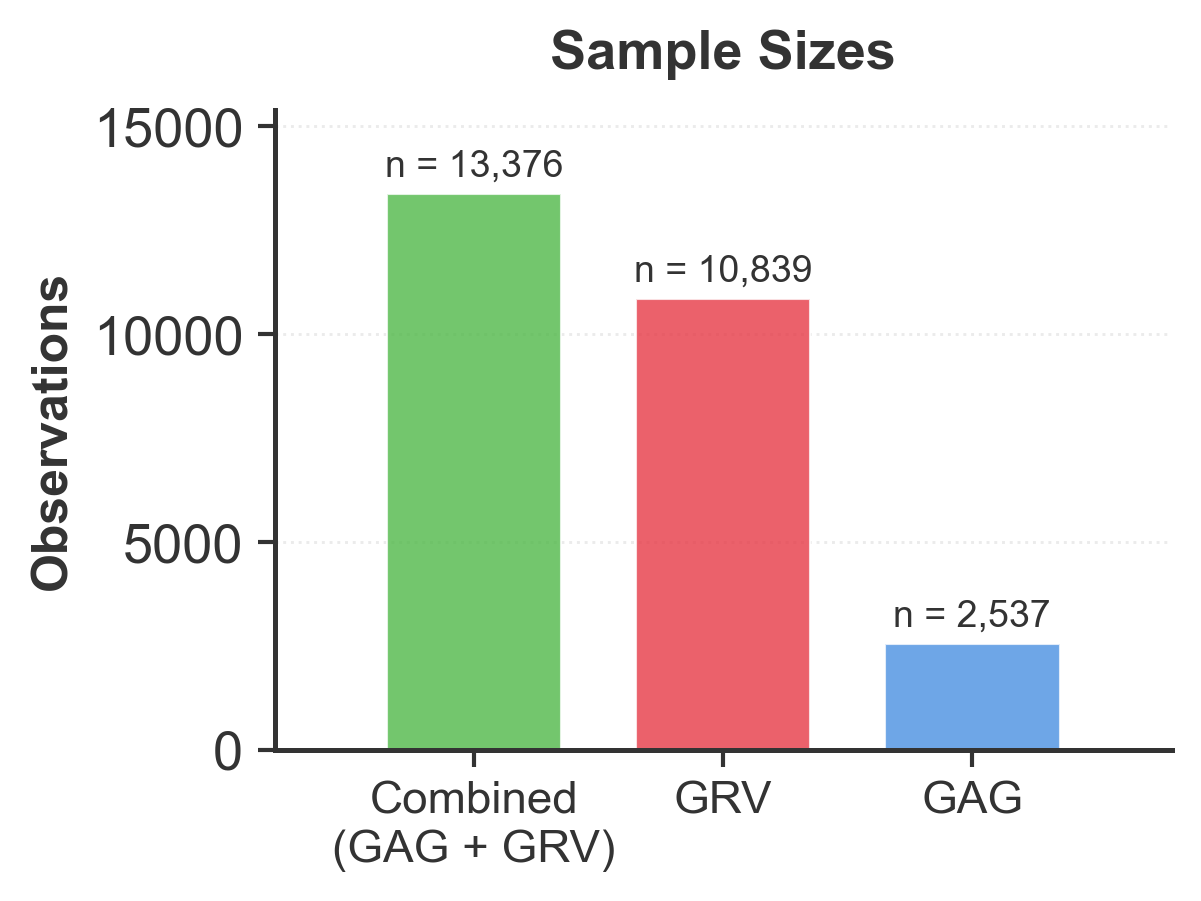

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import os

# ============================================================================
# FONT SETUP
# ============================================================================

available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in available_fonts:
    font_family = 'Arial'
elif 'Helvetica' in available_fonts:
    font_family = 'Helvetica'
elif 'DejaVu Sans' in available_fonts:
    font_family = 'DejaVu Sans'
elif 'Liberation Sans' in available_fonts:
    font_family = 'Liberation Sans'
else:
    font_family = 'sans-serif'

plt.rcParams.update({
    'font.family': font_family,
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 16,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': '#333333',
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'text.usetex': False,
    'mathtext.default': 'regular',
})

# ============================================================================
# CONFIGURATION
# ============================================================================

# Path to your combined dataset (after all preprocessing)
INPUT_FILE = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/final_dataset_for_analysis_with_quality_metrics2.csv'

# Output directory - will be created in same folder as input file
data_dir = os.path.dirname(os.path.abspath(INPUT_FILE))
output_dir = os.path.join(data_dir, 'sample_size_plots')
os.makedirs(output_dir, exist_ok=True)

OUTPUT_FILE = os.path.join(output_dir, 'irrigation_sample_sizes.png')

# ============================================================================
# LOAD AND PROCESS DATA
# ============================================================================

print("="*80)
print("IRRIGATION SAMPLE SIZES ANALYSIS")
print("="*80)

df = pd.read_csv(INPUT_FILE, sep=',')
print(f"\nLoaded data: {len(df)} observations")

# Apply same preprocessing as in your code
columns_to_rename = {
    "SC_irrigation_type": "irrigation_type",
    "SC_tc_per_ha_actual": "tc_per_ha_actual",
    "SC_brix_percent": "brix_percent",
    "SC_crop_cycle": "crop_cycle",
    "SC_variety": "variety"
}

actual_renames = {old: new for old, new in columns_to_rename.items() if old in df.columns}
df = df.rename(columns=actual_renames)

# Convert to uppercase
if 'irrigation_type' in df.columns:
    df['irrigation_type'] = df['irrigation_type'].astype(str).str.upper().str.strip()
if 'crop_cycle' in df.columns:
    df['crop_cycle'] = df['crop_cycle'].astype(str).str.upper().str.strip()
if 'variety' in df.columns:
    df['variety'] = df['variety'].astype(str).str.upper().str.strip()

# Remove NA in key metrics
if 'tc_per_ha_actual' in df.columns and 'brix_percent' in df.columns:
    df = df[df['tc_per_ha_actual'].notna() & df['brix_percent'].notna()].copy()

# Remove special crop cycle categories
if 'crop_cycle' in df.columns:
    categories_to_remove = ['FRICHE', 'LESSIVAGE', 'JACHERE', 'ESSAIS']
    df = df[~df['crop_cycle'].isin(categories_to_remove)].copy()

# Remove mixed varieties
if 'variety' in df.columns:
    mixed_varieties = ['MIXTE', 'MIXTE D', 'MIXTE MF']
    df = df[~df['variety'].isin(mixed_varieties)].copy()

print(f"After preprocessing: {len(df)} observations")

# ============================================================================
# CALCULATE SAMPLE SIZES
# ============================================================================

# Combined (GAG + GRV)
n_combined = len(df)

# GRV only
n_grv = len(df[df['irrigation_type'] == 'GRV'])

# GAG only
n_gag = len(df[df['irrigation_type'] == 'GAG'])

print(f"\n{'='*80}")
print("SAMPLE SIZES")
print(f"{'='*80}")
print(f"Combined (GAG + GRV): {n_combined:,} observations")
print(f"GRV:                  {n_grv:,} observations")
print(f"GAG:                  {n_gag:,} observations")
print(f"{'='*80}\n")

# ============================================================================
# CREATE BARPLOT - SHAP STYLE (VERTICAL)
# ============================================================================

fig, ax = plt.subplots(figsize=(4, 3))

# Data for plotting (ordered: Combined, GRV, GAG)
categories = ['Combined\n(GAG + GRV)', 'GRV', 'GAG']
counts = [n_combined, n_grv, n_gag]
colors = ['#50B848', '#E63946', '#4A90E2']  # Green, Red, Blue

# Create VERTICAL bars with SLIMMER BARS (width=0.35)
x_pos = np.array([0, 0.5, 1.0])  # Tighter spacing for slimmer appearance
bars = ax.bar(x_pos, counts, width=0.35, color=colors, alpha=0.8, 
              edgecolor='white', linewidth=0.5)

# Set x-axis labels with larger font (11) - HORIZONTAL text
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, fontsize=11, fontweight='normal', rotation=0, ha='center')

# Set y-axis label with larger font (12 like SHAP)
ax.set_ylabel('Observations', fontsize=12, fontweight='600')

# Grid styling (like SHAP plots) - horizontal grid for vertical bars
ax.grid(True, alpha=0.25, axis='y', linestyle=':', linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

# Add value labels on bars - larger font (9)
max_count = max(counts)
for i, (x, count) in enumerate(zip(x_pos, counts)):
    ax.text(x, count + max_count*0.02, f'n = {count:,}', 
            va='bottom', ha='center', fontsize=9, fontweight='normal', color='#333333')

# Set y-axis limits with minimal padding
ax.set_ylim(0, max_count * 1.15)

# Set x-axis limits tighter to make bars appear slimmer
ax.set_xlim(-0.4, 1.4)

# Reduce number of y-axis ticks
ax.locator_params(axis='y', nbins=4)

# Add title with larger font (13 like SHAP)
ax.set_title('Sample Sizes', fontsize=13, fontweight='600', 
             pad=10, color='#333333')

# Tight layout with minimal spacing
plt.tight_layout(pad=0.5)

# Save figure at 600 DPI
plt.savefig(OUTPUT_FILE, dpi=600, bbox_inches='tight', facecolor='white')

# Also save as PDF
pdf_file = OUTPUT_FILE.replace('.png', '.pdf')
plt.savefig(pdf_file, bbox_inches='tight', facecolor='white')

print(f"PLOTS SAVED")
print(f"{'='*80}")
print(f"✓ PNG (600 DPI): {OUTPUT_FILE}")
print(f"✓ PDF:           {pdf_file}")
print(f"✓ Output folder: {output_dir}")
print(f"{'='*80}\n")

plt.show()

## II. Machine Learning Pipeline for Gravity-Irrigated Soils

This section trains predictive models for gravity-irrigated fields to forecast sugarcane quality and yield outcomes. The pipeline automatically tests multiple modeling approaches, selects the best performer, and identifies which environmental and soil factors matter most for each target variable.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, VotingRegressor, BaggingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import optuna
import joblib
import os
import json
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# DEFINE AVAILABLE RESPONSE VARIABLES
# ============================================================================

SUGAR_CONTENT_METRICS = {
    "brix_percent": "Brix (%)",
    "pol_juice_percent": "Pol juice (%)",
    "pol_cane_percent": "Pol cane (%)",
    "purity_percent": "Purity (%)",
    "glucose_cane_percent": "Glucose (%)",
    "hugot_sugar": "Sucrose (%)",
    "estimated_recoverable_pol": "PER (%)",
    "total_recoverable_sugar_t_per_ha": "TRS (t ha⁻¹)"
}

YIELD_PARAMETERS = {
    "tc_per_ha_actual": "Cane yield (t ha⁻¹)",
    "tc_per_ha_per_week": "Cane yield per week (t ha⁻¹/week)",
    "tc_per_ha_52_weeks": "Cane yield 52 weeks (t ha⁻¹)",
    "fiber_percent": "Fiber in Cane (%)",
}

ALL_RESPONSE_VARIABLES = {**SUGAR_CONTENT_METRICS, **YIELD_PARAMETERS}

# ============================================================================
# MODIFIED DATA LOADING (WITH RESPONSE VARIABLE PARAMETER)
# ============================================================================

def load_and_prepare_multiyear_data(file_path, response_variable, custom_predictors=None, categorical_vars=None):
    """Load CSV data and prepare it for prediction with specified response variable"""
    print(f"Starting Analysis for Response Variable: {response_variable}")
    print(f"Display name: {ALL_RESPONSE_VARIABLES.get(response_variable, response_variable)}")
    print("="*80)

    df = pd.read_csv(file_path)
    
    # Check if response variable exists
    if response_variable not in df.columns:
        raise ValueError(f"Response variable '{response_variable}' not found in dataset!")
    
    # Drop ALL other response variables (keep only target)
    all_response_cols = list(ALL_RESPONSE_VARIABLES.keys())
    cols_to_drop = [col for col in all_response_cols 
                    if col != response_variable and col in df.columns]
    
    if cols_to_drop:
        print(f"Dropping other response variables: {cols_to_drop}")
        df = df.drop(columns=cols_to_drop)

    if custom_predictors is not None:
        print(f"Using custom predictors: {custom_predictors}")
        
        year_column = None
        for col in ['campaign_year', 'Harvest_Year', 'year']:
            if col in df.columns:
                year_column = col
                break

        columns_to_keep = [response_variable] + custom_predictors
        if year_column:
            columns_to_keep.append(year_column)
        if categorical_vars:
            columns_to_keep.extend(categorical_vars)

        missing_predictors = [col for col in custom_predictors if col not in df.columns]
        if missing_predictors:
            raise ValueError(f"Custom predictors not found: {missing_predictors}")
        
        if categorical_vars:
            missing_categorical = [col for col in categorical_vars if col not in df.columns]
            if missing_categorical:
                raise ValueError(f"Categorical variables not found: {missing_categorical}")

        df = df[columns_to_keep]
        print(f"Remaining columns: {list(df.columns)}")

    initial_count = len(df)
    df = df.dropna(subset=[response_variable])
    final_count = len(df)
    
    if initial_count - final_count > 0:
        print(f"Dropped {initial_count - final_count} observations with missing {response_variable}")

    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break

    samples = df.copy()
    encoders = {}

    if year_column:
        unique_years = sorted(samples[year_column].unique())
        print(f"Years available: {unique_years}")
        year_counts = samples[year_column].value_counts().sort_index()
        for year, count in year_counts.items():
            print(f"   {year}: {count} samples")
        
        year_encoder = LabelEncoder()
        samples[f'{year_column}_encoded'] = year_encoder.fit_transform(samples[year_column])
        encoders[year_column] = year_encoder
    else:
        unique_years = ["All data"]
        print("No year column found")

    # Encode categorical variables
    if categorical_vars:
        print(f"\nEncoding categorical variables: {categorical_vars}")
        for cat_var in categorical_vars:
            if cat_var in samples.columns:
                cat_encoder = LabelEncoder()
                samples[f'{cat_var}_encoded'] = cat_encoder.fit_transform(samples[cat_var].astype(str))
                encoders[cat_var] = cat_encoder
                print(f"   {cat_var}: {len(cat_encoder.classes_)} unique values")
                print(f"      Classes: {list(cat_encoder.classes_)}")

    numeric_cols = samples.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        if samples[col].isnull().any():
            samples[col] = samples[col].fillna(samples[col].median())

    print(f"Total dataset shape: {samples.shape}")
    print(f"{response_variable} statistics:\n{samples[response_variable].describe()}")

    return samples, encoders, unique_years, year_column

def prepare_multiyear_features_and_target(samples, encoders, year_column, response_variable, 
                                         custom_predictors=None, categorical_vars=None):
    """Prepare features and target for modeling"""
    TARGET = response_variable

    if custom_predictors is not None:
        available_predictors = [col for col in custom_predictors if col in samples.columns]
        FEATURES = available_predictors.copy()
        
        # Add encoded categorical variables
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in samples.columns:
                    FEATURES.append(encoded_col)
        
        print(f"Using custom predictors: {available_predictors}")
        if categorical_vars:
            print(f"Added encoded categorical variables: {[f'{cv}_encoded' for cv in categorical_vars]}")
    else:
        numeric_cols = samples.select_dtypes(include=[np.number]).columns.tolist()
        exclude_cols = [response_variable]
        if year_column:
            exclude_cols.extend([year_column, f'{year_column}_encoded'])
        if categorical_vars:
            exclude_cols.extend(categorical_vars)
        # Exclude all other response variables
        all_response_cols = list(ALL_RESPONSE_VARIABLES.keys())
        exclude_cols.extend([col for col in all_response_cols if col != response_variable])
        FEATURES = [col for col in numeric_cols if col not in exclude_cols]

    print(f"Total features: {len(FEATURES)}")
    return FEATURES, TARGET

def get_model_configurations():
    """Define all models for prediction"""
    models = {
        'LinearRegression': {
            'model': LinearRegression(),
            'params': {},
            'complexity': 'Simple'
        },
        'RandomForest': {
            'model': RandomForestRegressor(random_state=42),
            'params': {
                'n_estimators': [100, 200, 300, 500],
                'max_depth': [10, 15, 20, 25, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4],
                'max_features': ['sqrt', 'log2', None]
            },
            'complexity': 'Moderate'
        },
        'XGBoost': {
            'model': xgb.XGBRegressor(random_state=42),
            'params': {
                'n_estimators': [100, 200, 400, 600],
                'max_depth': [3, 5, 7, 9],
                'learning_rate': [0.05, 0.1, 0.15, 0.2],
                'subsample': [0.8, 0.9, 1.0],
                'colsample_bytree': [0.8, 0.9, 1.0],
                'reg_alpha': [0, 0.1, 0.5],
                'reg_lambda': [1, 1.5, 2]
            },
            'complexity': 'Complex'
        }
    }
    return models

def optimize_model_optuna(model_name, model_config, X, y, n_trials=50):
    """Optimize model hyperparameters using Optuna with inner CV"""
    def objective(trial):
        params = {}
        for param_name, param_values in model_config['params'].items():
            if isinstance(param_values, list):
                if all(isinstance(v, (int, float)) for v in param_values):
                    if all(isinstance(v, int) for v in param_values):
                        params[param_name] = trial.suggest_int(param_name, min(param_values), max(param_values))
                    else:
                        params[param_name] = trial.suggest_float(param_name, min(param_values), max(param_values))
                else:
                    params[param_name] = trial.suggest_categorical(param_name, param_values)

        model = model_config['model'].__class__(**{**model_config['model'].get_params(), **params})
        
        inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = []
        
        for train_idx, val_idx in inner_cv.split(X):
            try:
                X_train_inner = X[train_idx].copy()
                X_val_inner = X[val_idx].copy()
                y_train_inner = y.iloc[train_idx].copy()
                y_val_inner = y.iloc[val_idx].copy()
                
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train_inner)
                X_val_scaled = scaler.transform(X_val_inner)
                
                model.fit(X_train_scaled, y_train_inner)
                y_pred = model.predict(X_val_scaled)
                rmse = np.sqrt(mean_squared_error(y_val_inner, y_pred))
                scores.append(rmse)
                
                del X_train_inner, X_val_inner, X_train_scaled, X_val_scaled, y_pred
                
            except (MemoryError, np.core._exceptions._ArrayMemoryError) as e:
                print(f"   Memory error in fold, skipping trial with penalty")
                return 1e6
        
        if len(scores) == 0:
            return 1e6
            
        return np.mean(scores)

    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, catch=(MemoryError,))
    
    return study.best_params, study.best_value

def calculate_rpd_rpiq(y_true, y_pred):
    """Calculate RPD and RPIQ metrics"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    sd = np.std(y_true)
    q75, q25 = np.percentile(y_true, [75, 25])
    iqr = q75 - q25
    
    rpd = sd / rmse if rmse > 0 else 0
    rpiq = iqr / rmse if rmse > 0 else 0
    
    return rpd, rpiq

def perform_kfold_cv(model, X, y, n_splits=5):
    """Perform k-fold cross-validation with proper preprocessing in each fold"""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    fold_results = []
    all_predictions = []
    all_actuals = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)
        
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        mae = mean_absolute_error(y_val, y_pred)
        rpd, rpiq = calculate_rpd_rpiq(y_val, y_pred)
        
        fold_results.append({
            'fold': fold,
            'rmse': rmse,
            'r2': r2,
            'mae': mae,
            'rpd': rpd,
            'rpiq': rpiq
        })
        
        all_predictions.extend(y_pred)
        all_actuals.extend(y_val)
    
    overall_rmse = np.sqrt(mean_squared_error(all_actuals, all_predictions))
    overall_r2 = r2_score(all_actuals, all_predictions)
    overall_mae = mean_absolute_error(all_actuals, all_predictions)
    overall_rpd, overall_rpiq = calculate_rpd_rpiq(all_actuals, all_predictions)
    
    fold_rmse = [f['rmse'] for f in fold_results]
    fold_r2 = [f['r2'] for f in fold_results]
    fold_mae = [f['mae'] for f in fold_results]
    fold_rpd = [f['rpd'] for f in fold_results]
    fold_rpiq = [f['rpiq'] for f in fold_results]
    
    return {
        'fold_results': fold_results,
        'mean_rmse': np.mean(fold_rmse),
        'std_rmse': np.std(fold_rmse),
        'mean_r2': np.mean(fold_r2),
        'std_r2': np.std(fold_r2),
        'mean_mae': np.mean(fold_mae),
        'std_mae': np.std(fold_mae),
        'mean_rpd': np.mean(fold_rpd),
        'std_rpd': np.std(fold_rpd),
        'mean_rpiq': np.mean(fold_rpiq),
        'std_rpiq': np.std(fold_rpiq),
        'overall_rmse': overall_rmse,
        'overall_r2': overall_r2,
        'overall_mae': overall_mae,
        'overall_rpd': overall_rpd,
        'overall_rpiq': overall_rpiq
    }

def train_and_evaluate_models_kfold(X, y, models, optimize_hyperparams=True, n_trials=50, n_folds=5):
    """Train and evaluate all models using k-fold CV"""
    results = {}
    
    for model_name, model_config in models.items():
        print(f"\nTraining {model_name} with {n_folds}-fold CV...")
        
        try:
            if optimize_hyperparams and model_config['params']:
                print(f"   Optimizing hyperparameters ({n_trials} trials)...")
                best_params, best_cv_score = optimize_model_optuna(
                    model_name, model_config, X.values, y, n_trials=n_trials
                )
                model = model_config['model'].__class__(**{**model_config['model'].get_params(), **best_params})
            else:
                model = model_config['model']
                best_params = model_config['model'].get_params()
            
            cv_results = perform_kfold_cv(model, X, y, n_splits=n_folds)
            
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            model.fit(X_scaled, y)
            
            results[model_name] = {
                'model': model,
                'scaler': scaler,
                'best_params': best_params,
                'complexity': model_config['complexity'],
                'cv_results': cv_results,
                'mean_rmse': cv_results['mean_rmse'],
                'std_rmse': cv_results['std_rmse'],
                'mean_r2': cv_results['mean_r2'],
                'std_r2': cv_results['std_r2'],
                'mean_mae': cv_results['mean_mae'],
                'std_mae': cv_results['std_mae'],
                'mean_rpd': cv_results['mean_rpd'],
                'std_rpd': cv_results['std_rpd'],
                'mean_rpiq': cv_results['mean_rpiq'],
                'std_rpiq': cv_results['std_rpiq'],
                'overall_rmse': cv_results['overall_rmse'],
                'overall_r2': cv_results['overall_r2'],
                'overall_mae': cv_results['overall_mae'],
                'overall_rpd': cv_results['overall_rpd'],
                'overall_rpiq': cv_results['overall_rpiq']
            }
            
            print(f"   Mean CV R²: {cv_results['mean_r2']:.4f} ± {cv_results['std_r2']:.4f}")
            print(f"   Mean CV RMSE: {cv_results['mean_rmse']:.4f} ± {cv_results['std_rmse']:.4f}")
            print(f"   Mean CV RPD: {cv_results['mean_rpd']:.4f} ± {cv_results['std_rpd']:.4f}")
            print(f"   Mean CV RPIQ: {cv_results['mean_rpiq']:.4f} ± {cv_results['std_rpiq']:.4f}")
            print(f"   Overall R²: {cv_results['overall_r2']:.4f}")
            
        except Exception as e:
            print(f"   Error training {model_name}: {str(e)}")
            continue
    
    return results

def create_comprehensive_summary(results):
    """Create summary dataframe of all models"""
    summary_data = []
    
    for model_name, result in results.items():
        summary_data.append({
            'Model': model_name,
            'Complexity': result['complexity'],
            'Mean_CV_R2': result['mean_r2'],
            'Std_CV_R2': result['std_r2'],
            'Mean_CV_RMSE': result['mean_rmse'],
            'Std_CV_RMSE': result['std_rmse'],
            'Mean_CV_MAE': result['mean_mae'],
            'Std_CV_MAE': result['std_mae'],
            'Mean_CV_RPD': result['mean_rpd'],
            'Std_CV_RPD': result['std_rpd'],
            'Mean_CV_RPIQ': result['mean_rpiq'],
            'Std_CV_RPIQ': result['std_rpiq'],
            'Overall_R2': result['overall_r2'],
            'Overall_RMSE': result['overall_rmse'],
            'Overall_MAE': result['overall_mae'],
            'Overall_RPD': result['overall_rpd'],
            'Overall_RPIQ': result['overall_rpiq']
        })
    
    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values(['Overall_R2', 'Overall_RMSE'], ascending=[False, True])
    
    return summary_df

def analyze_feature_importance(results, feature_cols):
    """Analyze feature importance from tree-based models"""
    print("\n=== FEATURE IMPORTANCE ANALYSIS ===")
    tree_models = ['RandomForest', 'ExtraTrees', 'GradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']
    
    feature_importance_summary = {}
    
    for model_name in tree_models:
        if model_name in results:
            model = results[model_name]['model']
            if hasattr(model, 'feature_importances_'):
                importances = model.feature_importances_
                feature_importance = list(zip(feature_cols, importances))
                feature_importance.sort(key=lambda x: x[1], reverse=True)
                feature_importance_summary[model_name] = feature_importance
                
                print(f"\nTop 15 features ({model_name}):")
                for i, (feature, importance) in enumerate(feature_importance[:15]):
                    print(f"  {i+1:2d}. {feature:<40}: {importance:.4f}")
    
    if feature_importance_summary:
        print(f"\n=== AVERAGE FEATURE IMPORTANCE ===")
        feature_avg_importance = {}
        for feature in feature_cols:
            importances = []
            for model_name, feature_importance in feature_importance_summary.items():
                for feat, imp in feature_importance:
                    if feat == feature:
                        importances.append(imp)
                        break
            if importances:
                feature_avg_importance[feature] = np.mean(importances)
        
        sorted_avg_importance = sorted(feature_avg_importance.items(), key=lambda x: x[1], reverse=True)
        
        print("Top 15 features by average importance:")
        for i, (feature, avg_importance) in enumerate(sorted_avg_importance[:15]):
            print(f"  {i+1:2d}. {feature:<40}: {avg_importance:.4f}")
        
        return sorted_avg_importance
    
    return None

def save_kfold_results(results, best_model_name, unique_years, feature_importance, 
                      year_column, encoders, response_variable, output_dir):
    """Save all models and results"""
    os.makedirs(output_dir, exist_ok=True)
    
    models_dir = os.path.join(output_dir, 'models')
    analysis_dir = os.path.join(output_dir, 'analysis')
    os.makedirs(models_dir, exist_ok=True)
    os.makedirs(analysis_dir, exist_ok=True)
    
    for model_name, result in results.items():
        model_filename = f'{model_name.replace(" ", "_")}_{response_variable}.pkl'
        joblib.dump({
            'model': result['model'],
            'scaler': result['scaler'],
            'encoders': encoders
        }, os.path.join(models_dir, model_filename))
    
    summary_df = create_comprehensive_summary(results)
    summary_df.to_csv(os.path.join(output_dir, f'kfold_cv_summary_{response_variable}.csv'), index=False)
    
    fold_details = []
    for model_name, result in results.items():
        for fold_result in result['cv_results']['fold_results']:
            fold_details.append({
                'Model': model_name,
                'Fold': fold_result['fold'],
                'RMSE': fold_result['rmse'],
                'R2': fold_result['r2'],
                'MAE': fold_result['mae'],
                'RPD': fold_result['rpd'],
                'RPIQ': fold_result['rpiq']
            })
    
    fold_df = pd.DataFrame(fold_details)
    fold_df.to_csv(os.path.join(output_dir, f'fold_by_fold_results_{response_variable}.csv'), index=False)
    
    if feature_importance:
        feature_importance_df = pd.DataFrame(feature_importance, columns=['Feature', 'Importance'])
        feature_importance_df.to_csv(os.path.join(analysis_dir, f'feature_importance_{response_variable}.csv'), index=False)
    
    if encoders:
        encoder_info = {}
        for var_name, encoder in encoders.items():
            encoder_info[var_name] = {
                'classes': [str(c) for c in encoder.classes_]
            }
        with open(os.path.join(output_dir, f'encoders_info_{response_variable}.json'), 'w') as f:
            json.dump(encoder_info, f, indent=4)
    
    best_model_info = {
        'best_model_name': best_model_name,
        'mean_cv_r2': float(results[best_model_name]['mean_r2']),
        'std_cv_r2': float(results[best_model_name]['std_r2']),
        'mean_cv_rmse': float(results[best_model_name]['mean_rmse']),
        'std_cv_rmse': float(results[best_model_name]['std_rmse']),
        'mean_cv_rpd': float(results[best_model_name]['mean_rpd']),
        'std_cv_rpd': float(results[best_model_name]['std_rpd']),
        'mean_cv_rpiq': float(results[best_model_name]['mean_rpiq']),
        'std_cv_rpiq': float(results[best_model_name]['std_rpiq']),
        'overall_r2': float(results[best_model_name]['overall_r2']),
        'overall_rmse': float(results[best_model_name]['overall_rmse']),
        'overall_rpd': float(results[best_model_name]['overall_rpd']),
        'overall_rpiq': float(results[best_model_name]['overall_rpiq']),
        'years_in_dataset': [int(y) if hasattr(y, 'item') else y for y in unique_years],
        'year_column': year_column,
        'target_variable': response_variable
    }
    
    with open(os.path.join(output_dir, f'best_model_info_{response_variable}.json'), 'w') as f:
        json.dump(best_model_info, f, indent=4)
    
    print(f"\nAll models and results saved to: {output_dir}")
    print(f"Best model: {best_model_name}")

def main(file_path, response_variable, custom_predictors=None, categorical_vars=None, 
         base_output_dir=None, n_folds=5):
    """Main function for k-fold CV pipeline with flexible response variable"""
    
    # Validate response variable
    if response_variable not in ALL_RESPONSE_VARIABLES:
        raise ValueError(f"Response variable '{response_variable}' not recognized!\n"
                        f"Available options: {list(ALL_RESPONSE_VARIABLES.keys())}")
    
    # Create response-specific output directory
    if base_output_dir is None:
        base_output_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV'
    
    output_dir = os.path.join(base_output_dir, f'kfold_models_{response_variable}')
    
    if categorical_vars:
        output_dir += '_with_categorical'
    elif custom_predictors:
        output_dir += '_custom'
    
    os.makedirs(output_dir, exist_ok=True)
    
    print("\n" + "="*80)
    print(f"K-FOLD CV PIPELINE FOR: {response_variable}")
    print(f"Display name: {ALL_RESPONSE_VARIABLES[response_variable]}")
    print("="*80)
    print(f"Output directory: {output_dir}\n")
    
    print("Loading data...")
    samples, encoders, unique_years, year_column = load_and_prepare_multiyear_data(
        file_path, response_variable, custom_predictors, categorical_vars
    )
    
    FEATURES, TARGET = prepare_multiyear_features_and_target(
        samples, encoders, year_column, response_variable, custom_predictors, categorical_vars
    )
    
    print(f"\nDataset shape: {samples.shape}")
    print(f"Features: {len(FEATURES)}")
    print(f"Target range: {samples[TARGET].min():.2f} - {samples[TARGET].max():.2f}")
    
    X = samples[FEATURES].copy()
    y = samples[TARGET].copy()
    
    print("\nInitializing models...")
    models = get_model_configurations()
    
    print(f"\nTraining models with {n_folds}-fold cross-validation...")
    results = train_and_evaluate_models_kfold(
        X, y, models, optimize_hyperparams=True, n_trials=40, n_folds=n_folds
    )
    
    best_model_name = max(results.keys(), key=lambda x: results[x]['overall_r2'])
    
    print(f"\n=== BEST MODEL: {best_model_name} ===")
    print(f"Overall R²: {results[best_model_name]['overall_r2']:.4f}")
    print(f"Overall RMSE: {results[best_model_name]['overall_rmse']:.4f}")
    print(f"Overall RPD: {results[best_model_name]['overall_rpd']:.4f}")
    print(f"Overall RPIQ: {results[best_model_name]['overall_rpiq']:.4f}")
    print(f"Mean CV R²: {results[best_model_name]['mean_r2']:.4f} ± {results[best_model_name]['std_r2']:.4f}")
    print(f"Mean CV RMSE: {results[best_model_name]['mean_rmse']:.4f} ± {results[best_model_name]['std_rmse']:.4f}")
    print(f"Mean CV RPD: {results[best_model_name]['mean_rpd']:.4f} ± {results[best_model_name]['std_rpd']:.4f}")
    print(f"Mean CV RPIQ: {results[best_model_name]['mean_rpiq']:.4f} ± {results[best_model_name]['std_rpiq']:.4f}")
    
    feature_importance = analyze_feature_importance(results, FEATURES)
    
    print("\n=== MODEL SUMMARY ===")
    summary_df = create_comprehensive_summary(results)
    print(summary_df.to_string(index=False))
    
    save_kfold_results(results, best_model_name, unique_years, feature_importance, 
                      year_column, encoders, response_variable, output_dir)
    
    print("\n=== K-FOLD CV ANALYSIS COMPLETE ===")
    print(f"Results saved to: {output_dir}")
    print(f"Response variable: {response_variable} - {ALL_RESPONSE_VARIABLES[response_variable]}")
    
    return {
        'results': results,
        'best_model_name': best_model_name,
        'output_dir': output_dir,
        'response_variable': response_variable
    }

# ============================================================================
# USAGE EXAMPLES
# ============================================================================

if __name__ == "__main__":
    
    # Same predictors as in your original code
    custom_features = [
    'pH_complete', 'Exchangeable_Calcium_meq_100g_complete', 'Exchangeable_Potassium_meq_100g_complete', 'Exchangeable_Sodium_meq_100g_complete',
    'Available_P2O5_mg_kg_complete', 'Total_Nitrogen_per_mille_complete', 'Electrical_Conductivity_mmho_cm_complete', 'Mg_K_Ratio_complete',
    'Coarse_Silt_percent_complete', 'Coarse_Sand_percent_complete', 'growing_season_rainfall_mm', 'CDD', 'SDII',
    'temp_mini_mean', 'temp_maxi_mean', 'h_mini_mean', 'h_maxi_mean',
    'soil_temp_6h_mean', 'radiation_ERA_total', 'CWD', 'Rx1', 'R20', 'TNn', 'TNx'
    ]
    
    categorical_features = ['variety', 'crop_cycle', 'irrigation_type', 'harvest_mode']
    
    # File path
    data_file = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV/dataset_regrouped_GRV.csv'
    
    # Base output directory (subfolders will be created for each response)
    base_output = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV'
    
    print("="*80)
    print("FLEXIBLE K-FOLD CV PIPELINE - MULTIPLE RESPONSE VARIABLES")
    print("="*80)
    print("\nAvailable response variables:")
    print("\nSUGAR CONTENT METRICS:")
    for key, label in SUGAR_CONTENT_METRICS.items():
        print(f"  - {key}: {label}")
    print("\nYIELD PARAMETERS:")
    for key, label in YIELD_PARAMETERS.items():
        print(f"  - {key}: {label}")
    print("="*80 + "\n")
    
    try:
        """# Example 1: Run for brix_percent (original)
        print("\n### RUNNING PIPELINE FOR: brix_percent ###\n")
        results_brix = main(
            file_path=data_file,
            response_variable='brix_percent',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            n_folds=5
        )
        
        # Example 2: Run for pol_cane_percent
        print("\n\n### RUNNING PIPELINE FOR: pol_cane_percent ###\n")
        results_pol = main(
            file_path=data_file,
            response_variable='hugot_sugar',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            n_folds=5
        )
        
        # Example 3: Run for tc_per_ha_actual
        print("\n\n### RUNNING PIPELINE FOR: tc_per_ha_actual ###\n")
        results_yield = main(
            file_path=data_file,
            response_variable='tc_per_ha_actual',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            n_folds=5
        )

        # Example 4: Run for purity
        print("\n\n### RUNNING PIPELINE FOR: purity_percent ###\n")
        results_yield = main(
            file_path=data_file,
            response_variable='purity_percent',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            n_folds=5
        )"""

        print("\n\n### RUNNING PIPELINE FOR: PER ###\n")
        results_per = main(
            file_path=data_file,
            response_variable='estimated_recoverable_pol',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            n_folds=5
        )
        """
        # Example 5: Run for TPER
        print("\n\n### RUNNING PIPELINE FOR: TPER ###\n")
        results_tper = main(
            file_path=data_file,
            response_variable='total_recoverable_sugar_t_per_ha',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            n_folds=5
        )"""

        print("\n\n### RUNNING PIPELINE FOR: tc_per_ha_actual ###\n")       
        print("\n" + "="*80)
        print("ALL PIPELINES COMPLETED SUCCESSFULLY!")
        print("="*80)
        print("\nSummary of Results:")
        print(f"\n1. brix_percent ({SUGAR_CONTENT_METRICS['brix_percent']}):")
        #print(f"   Best Model: {results_brix['best_model_name']}")
        #print(f"   Output: {results_brix['output_dir']}")
        
        print(f"\n2. pol_cane_percent ({SUGAR_CONTENT_METRICS['pol_cane_percent']}):")
        #print(f"   Best Model: {results_pol['best_model_name']}")
        #print(f"   Output: {results_pol['output_dir']}")
        
        print(f"\n3. tc_per_ha_actual ({YIELD_PARAMETERS['tc_per_ha_actual']}):")
        #print(f"   Best Model: {results_yield['best_model_name']}")
        #print(f"   Output: {results_yield['output_dir']}")
        
        print("\n" + "="*80)
        print("TO RUN FOR A DIFFERENT RESPONSE VARIABLE:")
        print("="*80)
        print("\nSimply call:")
        print("  main(file_path=data_file,")
        print("       response_variable='your_choice',  # e.g., 'purity_percent'")
        print("       custom_predictors=custom_features,")
        print("       categorical_vars=categorical_features,")
        print("       base_output_dir=base_output,")
        print("       n_folds=5)")
        print("\nAvailable choices:")
        for key in ALL_RESPONSE_VARIABLES.keys():
            print(f"  - '{key}'")
        print("="*80)
        
    except Exception as e:
        print(f"\nError: {e}")
        import traceback
        traceback.print_exc()

FLEXIBLE K-FOLD CV PIPELINE - MULTIPLE RESPONSE VARIABLES

Available response variables:

SUGAR CONTENT METRICS:
  - brix_percent: Brix (%)
  - pol_juice_percent: Pol juice (%)
  - pol_cane_percent: Pol cane (%)
  - purity_percent: Purity (%)
  - glucose_cane_percent: Glucose (%)
  - hugot_sugar: Sucrose (%)
  - estimated_recoverable_pol: PER (%)
  - total_recoverable_sugar_t_per_ha: TRS (t ha⁻¹)

YIELD PARAMETERS:
  - tc_per_ha_actual: Cane yield (t ha⁻¹)
  - tc_per_ha_per_week: Cane yield per week (t ha⁻¹/week)
  - tc_per_ha_52_weeks: Cane yield 52 weeks (t ha⁻¹)
  - fiber_percent: Fiber in Cane (%)



### RUNNING PIPELINE FOR: PER ###


K-FOLD CV PIPELINE FOR: estimated_recoverable_pol
Display name: PER (%)
Output directory: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV\kfold_models_estimated_recoverable_pol_with_categorical

Loading data...
Starting Analysis for Response Variable: estimated_recoverable_pol
Display name: PER (%)
Dropping oth

[I 2026-01-15 14:04:32,818] A new study created in memory with name: no-name-6b4772a3-4787-4e9f-bd7d-60d789872206


   Mean CV R²: 0.1747 ± 0.0093
   Mean CV RMSE: 0.9301 ± 0.0152
   Mean CV RPD: 1.1008 ± 0.0062
   Mean CV RPIQ: 1.3956 ± 0.0110
   Overall R²: 0.1753

Training RandomForest with 5-fold CV...
   Optimizing hyperparameters (40 trials)...


[I 2026-01-15 14:04:47,145] Trial 0 finished with value: 0.8127211398457551 and parameters: {'n_estimators': 250, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.8127211398457551.
[I 2026-01-15 14:05:14,195] Trial 1 finished with value: 0.8107739278834836 and parameters: {'n_estimators': 488, 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 1 with value: 0.8107739278834836.
[I 2026-01-15 14:05:35,982] Trial 2 finished with value: 0.7747844000740499 and parameters: {'n_estimators': 217, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.7747844000740499.
[I 2026-01-15 14:08:19,196] Trial 3 finished with value: 0.8016031837551226 and parameters: {'n_estimators': 480, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 2 with value: 0.7747844000740499

   Mean CV R²: 0.4486 ± 0.0106
   Mean CV RMSE: 0.7604 ± 0.0198
   Mean CV RPD: 1.3469 ± 0.0130
   Mean CV RPIQ: 1.7076 ± 0.0224
   Overall R²: 0.4486

Training XGBoost with 5-fold CV...
   Optimizing hyperparameters (40 trials)...


[I 2026-01-15 14:39:29,078] Trial 0 finished with value: 0.7984549137318208 and parameters: {'n_estimators': 287, 'max_depth': 9, 'learning_rate': 0.15979909127171077, 'subsample': 0.9197316968394074, 'colsample_bytree': 0.8312037280884873, 'reg_alpha': 0.07799726016810132, 'reg_lambda': 1.0580836121681996}. Best is trial 0 with value: 0.7984549137318208.
[I 2026-01-15 14:39:42,620] Trial 1 finished with value: 0.8076034449985584 and parameters: {'n_estimators': 533, 'max_depth': 7, 'learning_rate': 0.15621088666940686, 'subsample': 0.8041168988591605, 'colsample_bytree': 0.9939819704323989, 'reg_alpha': 0.41622132040021087, 'reg_lambda': 1.2123391106782762}. Best is trial 0 with value: 0.7984549137318208.
[I 2026-01-15 14:39:44,018] Trial 2 finished with value: 0.7959548239375579 and parameters: {'n_estimators': 191, 'max_depth': 4, 'learning_rate': 0.09563633644393066, 'subsample': 0.9049512863264476, 'colsample_bytree': 0.8863890037284232, 'reg_alpha': 0.14561457009902096, 'reg_lamb

   Mean CV R²: 0.4400 ± 0.0101
   Mean CV RMSE: 0.7662 ± 0.0160
   Mean CV RPD: 1.3365 ± 0.0121
   Mean CV RPIQ: 1.6944 ± 0.0190
   Overall R²: 0.4403

=== BEST MODEL: RandomForest ===
Overall R²: 0.4486
Overall RMSE: 0.7607
Overall RPD: 1.3467
Overall RPIQ: 1.6950
Mean CV R²: 0.4486 ± 0.0106
Mean CV RMSE: 0.7604 ± 0.0198
Mean CV RPD: 1.3469 ± 0.0130
Mean CV RPIQ: 1.7076 ± 0.0224

=== FEATURE IMPORTANCE ANALYSIS ===

Top 15 features (RandomForest):
   1. soil_temp_6h_mean                       : 0.0828
   2. temp_maxi_mean                          : 0.0732
   3. h_mini_mean                             : 0.0668
   4. CDD                                     : 0.0589
   5. temp_mini_mean                          : 0.0588
   6. h_maxi_mean                             : 0.0485
   7. growing_season_rainfall_mm              : 0.0445
   8. SDII                                    : 0.0411
   9. radiation_ERA_total                     : 0.0409
  10. Mg_K_Ratio_complete                     : 0.03

## III. Machine Learning Pipeline for Drip-Irrigated Soils

This section trains predictive models for gravity-irrigated fields to forecast sugarcane quality and yield outcomes. The pipeline automatically tests multiple modeling approaches, selects the best performer, and identifies which environmental and soil factors matter most for each target variable.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, VotingRegressor, BaggingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import optuna
import joblib
import os
import json
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# DEFINE AVAILABLE RESPONSE VARIABLES
# ============================================================================

SUGAR_CONTENT_METRICS = {
    "brix_percent": "Brix (%)",
    "pol_juice_percent": "Pol juice (%)",
    "pol_cane_percent": "Pol cane (%)",
    "purity_percent": "Purity (%)",
    "glucose_cane_percent": "Glucose (%)",
    "hugot_sugar": "Sucrose (%)",
    "estimated_recoverable_pol": "PER (%)",
    "total_recoverable_sugar_t_per_ha": "TPER (t ha⁻¹)"
}

YIELD_PARAMETERS = {
    "tc_per_ha_actual": "Cane yield (t ha⁻¹)",
    "tc_per_ha_per_week": "Cane yield per week (t ha⁻¹/week)",
    "tc_per_ha_52_weeks": "Cane yield 52 weeks (t ha⁻¹)",
    "fiber_percent": "Fiber in Cane (%)",
}

ALL_RESPONSE_VARIABLES = {**SUGAR_CONTENT_METRICS, **YIELD_PARAMETERS}

# ============================================================================
# MODIFIED DATA LOADING (WITH RESPONSE VARIABLE PARAMETER)
# ============================================================================

def load_and_prepare_multiyear_data(file_path, response_variable, custom_predictors=None, categorical_vars=None):
    """Load CSV data and prepare it for prediction with specified response variable"""
    print(f"Starting Analysis for Response Variable: {response_variable}")
    print(f"Display name: {ALL_RESPONSE_VARIABLES.get(response_variable, response_variable)}")
    print("="*80)

    df = pd.read_csv(file_path)
    
    # Check if response variable exists
    if response_variable not in df.columns:
        raise ValueError(f"Response variable '{response_variable}' not found in dataset!")
    
    # Drop ALL other response variables (keep only target)
    all_response_cols = list(ALL_RESPONSE_VARIABLES.keys())
    cols_to_drop = [col for col in all_response_cols 
                    if col != response_variable and col in df.columns]
    
    if cols_to_drop:
        print(f"Dropping other response variables: {cols_to_drop}")
        df = df.drop(columns=cols_to_drop)

    if custom_predictors is not None:
        print(f"Using custom predictors: {custom_predictors}")
        
        year_column = None
        for col in ['campaign_year', 'Harvest_Year', 'year']:
            if col in df.columns:
                year_column = col
                break

        columns_to_keep = [response_variable] + custom_predictors
        if year_column:
            columns_to_keep.append(year_column)
        if categorical_vars:
            columns_to_keep.extend(categorical_vars)

        missing_predictors = [col for col in custom_predictors if col not in df.columns]
        if missing_predictors:
            raise ValueError(f"Custom predictors not found: {missing_predictors}")
        
        if categorical_vars:
            missing_categorical = [col for col in categorical_vars if col not in df.columns]
            if missing_categorical:
                raise ValueError(f"Categorical variables not found: {missing_categorical}")

        df = df[columns_to_keep]
        print(f"Remaining columns: {list(df.columns)}")

    initial_count = len(df)
    df = df.dropna(subset=[response_variable])
    final_count = len(df)
    
    if initial_count - final_count > 0:
        print(f"Dropped {initial_count - final_count} observations with missing {response_variable}")

    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break

    samples = df.copy()
    encoders = {}

    if year_column:
        unique_years = sorted(samples[year_column].unique())
        print(f"Years available: {unique_years}")
        year_counts = samples[year_column].value_counts().sort_index()
        for year, count in year_counts.items():
            print(f"   {year}: {count} samples")
        
        year_encoder = LabelEncoder()
        samples[f'{year_column}_encoded'] = year_encoder.fit_transform(samples[year_column])
        encoders[year_column] = year_encoder
    else:
        unique_years = ["All data"]
        print("No year column found")

    # Encode categorical variables
    if categorical_vars:
        print(f"\nEncoding categorical variables: {categorical_vars}")
        for cat_var in categorical_vars:
            if cat_var in samples.columns:
                cat_encoder = LabelEncoder()
                samples[f'{cat_var}_encoded'] = cat_encoder.fit_transform(samples[cat_var].astype(str))
                encoders[cat_var] = cat_encoder
                print(f"   {cat_var}: {len(cat_encoder.classes_)} unique values")
                print(f"      Classes: {list(cat_encoder.classes_)}")

    numeric_cols = samples.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        if samples[col].isnull().any():
            samples[col] = samples[col].fillna(samples[col].median())

    print(f"Total dataset shape: {samples.shape}")
    print(f"{response_variable} statistics:\n{samples[response_variable].describe()}")

    return samples, encoders, unique_years, year_column

def prepare_multiyear_features_and_target(samples, encoders, year_column, response_variable, 
                                         custom_predictors=None, categorical_vars=None):
    """Prepare features and target for modeling"""
    TARGET = response_variable

    if custom_predictors is not None:
        available_predictors = [col for col in custom_predictors if col in samples.columns]
        FEATURES = available_predictors.copy()
        
        # Add encoded categorical variables
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in samples.columns:
                    FEATURES.append(encoded_col)
        
        print(f"Using custom predictors: {available_predictors}")
        if categorical_vars:
            print(f"Added encoded categorical variables: {[f'{cv}_encoded' for cv in categorical_vars]}")
    else:
        numeric_cols = samples.select_dtypes(include=[np.number]).columns.tolist()
        exclude_cols = [response_variable]
        if year_column:
            exclude_cols.extend([year_column, f'{year_column}_encoded'])
        if categorical_vars:
            exclude_cols.extend(categorical_vars)
        # Exclude all other response variables
        all_response_cols = list(ALL_RESPONSE_VARIABLES.keys())
        exclude_cols.extend([col for col in all_response_cols if col != response_variable])
        FEATURES = [col for col in numeric_cols if col not in exclude_cols]

    print(f"Total features: {len(FEATURES)}")
    return FEATURES, TARGET

def get_model_configurations():
    """Define all models for prediction"""
    models = {
        'LinearRegression': {
            'model': LinearRegression(),
            'params': {},
            'complexity': 'Simple'
        },
        'RandomForest': {
            'model': RandomForestRegressor(random_state=42),
            'params': {
                'n_estimators': [100, 200, 300, 500],
                'max_depth': [10, 15, 20, 25, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4],
                'max_features': ['sqrt', 'log2', None]
            },
            'complexity': 'Moderate'
        },
        'XGBoost': {
            'model': xgb.XGBRegressor(random_state=42),
            'params': {
                'n_estimators': [100, 200, 400, 600],
                'max_depth': [3, 5, 7, 9],
                'learning_rate': [0.05, 0.1, 0.15, 0.2],
                'subsample': [0.8, 0.9, 1.0],
                'colsample_bytree': [0.8, 0.9, 1.0],
                'reg_alpha': [0, 0.1, 0.5],
                'reg_lambda': [1, 1.5, 2]
            },
            'complexity': 'Complex'
        }
    }
    return models

def optimize_model_optuna(model_name, model_config, X, y, n_trials=50):
    """Optimize model hyperparameters using Optuna with inner CV"""
    def objective(trial):
        params = {}
        for param_name, param_values in model_config['params'].items():
            if isinstance(param_values, list):
                if all(isinstance(v, (int, float)) for v in param_values):
                    if all(isinstance(v, int) for v in param_values):
                        params[param_name] = trial.suggest_int(param_name, min(param_values), max(param_values))
                    else:
                        params[param_name] = trial.suggest_float(param_name, min(param_values), max(param_values))
                else:
                    params[param_name] = trial.suggest_categorical(param_name, param_values)

        model = model_config['model'].__class__(**{**model_config['model'].get_params(), **params})
        
        inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = []
        
        for train_idx, val_idx in inner_cv.split(X):
            try:
                X_train_inner = X[train_idx].copy()
                X_val_inner = X[val_idx].copy()
                y_train_inner = y.iloc[train_idx].copy()
                y_val_inner = y.iloc[val_idx].copy()
                
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train_inner)
                X_val_scaled = scaler.transform(X_val_inner)
                
                model.fit(X_train_scaled, y_train_inner)
                y_pred = model.predict(X_val_scaled)
                rmse = np.sqrt(mean_squared_error(y_val_inner, y_pred))
                scores.append(rmse)
                
                del X_train_inner, X_val_inner, X_train_scaled, X_val_scaled, y_pred
                
            except (MemoryError, np.core._exceptions._ArrayMemoryError) as e:
                print(f"   Memory error in fold, skipping trial with penalty")
                return 1e6
        
        if len(scores) == 0:
            return 1e6
            
        return np.mean(scores)

    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, catch=(MemoryError,))
    
    return study.best_params, study.best_value

def calculate_rpd_rpiq(y_true, y_pred):
    """Calculate RPD and RPIQ metrics"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    sd = np.std(y_true)
    q75, q25 = np.percentile(y_true, [75, 25])
    iqr = q75 - q25
    
    rpd = sd / rmse if rmse > 0 else 0
    rpiq = iqr / rmse if rmse > 0 else 0
    
    return rpd, rpiq

def perform_kfold_cv(model, X, y, n_splits=5):
    """Perform k-fold cross-validation with proper preprocessing in each fold"""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    fold_results = []
    all_predictions = []
    all_actuals = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)
        
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        mae = mean_absolute_error(y_val, y_pred)
        rpd, rpiq = calculate_rpd_rpiq(y_val, y_pred)
        
        fold_results.append({
            'fold': fold,
            'rmse': rmse,
            'r2': r2,
            'mae': mae,
            'rpd': rpd,
            'rpiq': rpiq
        })
        
        all_predictions.extend(y_pred)
        all_actuals.extend(y_val)
    
    overall_rmse = np.sqrt(mean_squared_error(all_actuals, all_predictions))
    overall_r2 = r2_score(all_actuals, all_predictions)
    overall_mae = mean_absolute_error(all_actuals, all_predictions)
    overall_rpd, overall_rpiq = calculate_rpd_rpiq(all_actuals, all_predictions)
    
    fold_rmse = [f['rmse'] for f in fold_results]
    fold_r2 = [f['r2'] for f in fold_results]
    fold_mae = [f['mae'] for f in fold_results]
    fold_rpd = [f['rpd'] for f in fold_results]
    fold_rpiq = [f['rpiq'] for f in fold_results]
    
    return {
        'fold_results': fold_results,
        'mean_rmse': np.mean(fold_rmse),
        'std_rmse': np.std(fold_rmse),
        'mean_r2': np.mean(fold_r2),
        'std_r2': np.std(fold_r2),
        'mean_mae': np.mean(fold_mae),
        'std_mae': np.std(fold_mae),
        'mean_rpd': np.mean(fold_rpd),
        'std_rpd': np.std(fold_rpd),
        'mean_rpiq': np.mean(fold_rpiq),
        'std_rpiq': np.std(fold_rpiq),
        'overall_rmse': overall_rmse,
        'overall_r2': overall_r2,
        'overall_mae': overall_mae,
        'overall_rpd': overall_rpd,
        'overall_rpiq': overall_rpiq
    }

def train_and_evaluate_models_kfold(X, y, models, optimize_hyperparams=True, n_trials=50, n_folds=5):
    """Train and evaluate all models using k-fold CV"""
    results = {}
    
    for model_name, model_config in models.items():
        print(f"\nTraining {model_name} with {n_folds}-fold CV...")
        
        try:
            if optimize_hyperparams and model_config['params']:
                print(f"   Optimizing hyperparameters ({n_trials} trials)...")
                best_params, best_cv_score = optimize_model_optuna(
                    model_name, model_config, X.values, y, n_trials=n_trials
                )
                model = model_config['model'].__class__(**{**model_config['model'].get_params(), **best_params})
            else:
                model = model_config['model']
                best_params = model_config['model'].get_params()
            
            cv_results = perform_kfold_cv(model, X, y, n_splits=n_folds)
            
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            model.fit(X_scaled, y)
            
            results[model_name] = {
                'model': model,
                'scaler': scaler,
                'best_params': best_params,
                'complexity': model_config['complexity'],
                'cv_results': cv_results,
                'mean_rmse': cv_results['mean_rmse'],
                'std_rmse': cv_results['std_rmse'],
                'mean_r2': cv_results['mean_r2'],
                'std_r2': cv_results['std_r2'],
                'mean_mae': cv_results['mean_mae'],
                'std_mae': cv_results['std_mae'],
                'mean_rpd': cv_results['mean_rpd'],
                'std_rpd': cv_results['std_rpd'],
                'mean_rpiq': cv_results['mean_rpiq'],
                'std_rpiq': cv_results['std_rpiq'],
                'overall_rmse': cv_results['overall_rmse'],
                'overall_r2': cv_results['overall_r2'],
                'overall_mae': cv_results['overall_mae'],
                'overall_rpd': cv_results['overall_rpd'],
                'overall_rpiq': cv_results['overall_rpiq']
            }
            
            print(f"   Mean CV R²: {cv_results['mean_r2']:.4f} ± {cv_results['std_r2']:.4f}")
            print(f"   Mean CV RMSE: {cv_results['mean_rmse']:.4f} ± {cv_results['std_rmse']:.4f}")
            print(f"   Mean CV RPD: {cv_results['mean_rpd']:.4f} ± {cv_results['std_rpd']:.4f}")
            print(f"   Mean CV RPIQ: {cv_results['mean_rpiq']:.4f} ± {cv_results['std_rpiq']:.4f}")
            print(f"   Overall R²: {cv_results['overall_r2']:.4f}")
            
        except Exception as e:
            print(f"   Error training {model_name}: {str(e)}")
            continue
    
    return results

def create_comprehensive_summary(results):
    """Create summary dataframe of all models"""
    summary_data = []
    
    for model_name, result in results.items():
        summary_data.append({
            'Model': model_name,
            'Complexity': result['complexity'],
            'Mean_CV_R2': result['mean_r2'],
            'Std_CV_R2': result['std_r2'],
            'Mean_CV_RMSE': result['mean_rmse'],
            'Std_CV_RMSE': result['std_rmse'],
            'Mean_CV_MAE': result['mean_mae'],
            'Std_CV_MAE': result['std_mae'],
            'Mean_CV_RPD': result['mean_rpd'],
            'Std_CV_RPD': result['std_rpd'],
            'Mean_CV_RPIQ': result['mean_rpiq'],
            'Std_CV_RPIQ': result['std_rpiq'],
            'Overall_R2': result['overall_r2'],
            'Overall_RMSE': result['overall_rmse'],
            'Overall_MAE': result['overall_mae'],
            'Overall_RPD': result['overall_rpd'],
            'Overall_RPIQ': result['overall_rpiq']
        })
    
    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values(['Overall_R2', 'Overall_RMSE'], ascending=[False, True])
    
    return summary_df

def analyze_feature_importance(results, feature_cols):
    """Analyze feature importance from tree-based models"""
    print("\n=== FEATURE IMPORTANCE ANALYSIS ===")
    tree_models = ['RandomForest', 'ExtraTrees', 'GradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']
    
    feature_importance_summary = {}
    
    for model_name in tree_models:
        if model_name in results:
            model = results[model_name]['model']
            if hasattr(model, 'feature_importances_'):
                importances = model.feature_importances_
                feature_importance = list(zip(feature_cols, importances))
                feature_importance.sort(key=lambda x: x[1], reverse=True)
                feature_importance_summary[model_name] = feature_importance
                
                print(f"\nTop 15 features ({model_name}):")
                for i, (feature, importance) in enumerate(feature_importance[:15]):
                    print(f"  {i+1:2d}. {feature:<40}: {importance:.4f}")
    
    if feature_importance_summary:
        print(f"\n=== AVERAGE FEATURE IMPORTANCE ===")
        feature_avg_importance = {}
        for feature in feature_cols:
            importances = []
            for model_name, feature_importance in feature_importance_summary.items():
                for feat, imp in feature_importance:
                    if feat == feature:
                        importances.append(imp)
                        break
            if importances:
                feature_avg_importance[feature] = np.mean(importances)
        
        sorted_avg_importance = sorted(feature_avg_importance.items(), key=lambda x: x[1], reverse=True)
        
        print("Top 15 features by average importance:")
        for i, (feature, avg_importance) in enumerate(sorted_avg_importance[:15]):
            print(f"  {i+1:2d}. {feature:<40}: {avg_importance:.4f}")
        
        return sorted_avg_importance
    
    return None

def save_kfold_results(results, best_model_name, unique_years, feature_importance, 
                      year_column, encoders, response_variable, output_dir):
    """Save all models and results"""
    os.makedirs(output_dir, exist_ok=True)
    
    models_dir = os.path.join(output_dir, 'models')
    analysis_dir = os.path.join(output_dir, 'analysis')
    os.makedirs(models_dir, exist_ok=True)
    os.makedirs(analysis_dir, exist_ok=True)
    
    for model_name, result in results.items():
        model_filename = f'{model_name.replace(" ", "_")}_{response_variable}.pkl'
        joblib.dump({
            'model': result['model'],
            'scaler': result['scaler'],
            'encoders': encoders
        }, os.path.join(models_dir, model_filename))
    
    summary_df = create_comprehensive_summary(results)
    summary_df.to_csv(os.path.join(output_dir, f'kfold_cv_summary_{response_variable}.csv'), index=False)
    
    fold_details = []
    for model_name, result in results.items():
        for fold_result in result['cv_results']['fold_results']:
            fold_details.append({
                'Model': model_name,
                'Fold': fold_result['fold'],
                'RMSE': fold_result['rmse'],
                'R2': fold_result['r2'],
                'MAE': fold_result['mae'],
                'RPD': fold_result['rpd'],
                'RPIQ': fold_result['rpiq']
            })
    
    fold_df = pd.DataFrame(fold_details)
    fold_df.to_csv(os.path.join(output_dir, f'fold_by_fold_results_{response_variable}.csv'), index=False)
    
    if feature_importance:
        feature_importance_df = pd.DataFrame(feature_importance, columns=['Feature', 'Importance'])
        feature_importance_df.to_csv(os.path.join(analysis_dir, f'feature_importance_{response_variable}.csv'), index=False)
    
    if encoders:
        encoder_info = {}
        for var_name, encoder in encoders.items():
            encoder_info[var_name] = {
                'classes': [str(c) for c in encoder.classes_]
            }
        with open(os.path.join(output_dir, f'encoders_info_{response_variable}.json'), 'w') as f:
            json.dump(encoder_info, f, indent=4)
    
    best_model_info = {
        'best_model_name': best_model_name,
        'mean_cv_r2': float(results[best_model_name]['mean_r2']),
        'std_cv_r2': float(results[best_model_name]['std_r2']),
        'mean_cv_rmse': float(results[best_model_name]['mean_rmse']),
        'std_cv_rmse': float(results[best_model_name]['std_rmse']),
        'mean_cv_rpd': float(results[best_model_name]['mean_rpd']),
        'std_cv_rpd': float(results[best_model_name]['std_rpd']),
        'mean_cv_rpiq': float(results[best_model_name]['mean_rpiq']),
        'std_cv_rpiq': float(results[best_model_name]['std_rpiq']),
        'overall_r2': float(results[best_model_name]['overall_r2']),
        'overall_rmse': float(results[best_model_name]['overall_rmse']),
        'overall_rpd': float(results[best_model_name]['overall_rpd']),
        'overall_rpiq': float(results[best_model_name]['overall_rpiq']),
        'years_in_dataset': [int(y) if hasattr(y, 'item') else y for y in unique_years],
        'year_column': year_column,
        'target_variable': response_variable
    }
    
    with open(os.path.join(output_dir, f'best_model_info_{response_variable}.json'), 'w') as f:
        json.dump(best_model_info, f, indent=4)
    
    print(f"\nAll models and results saved to: {output_dir}")
    print(f"Best model: {best_model_name}")

def main(file_path, response_variable, custom_predictors=None, categorical_vars=None, 
         base_output_dir=None, n_folds=5):
    """Main function for k-fold CV pipeline with flexible response variable"""
    
    # Validate response variable
    if response_variable not in ALL_RESPONSE_VARIABLES:
        raise ValueError(f"Response variable '{response_variable}' not recognized!\n"
                        f"Available options: {list(ALL_RESPONSE_VARIABLES.keys())}")
    
    # Create response-specific output directory
    if base_output_dir is None:
        base_output_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
    
    output_dir = os.path.join(base_output_dir, f'kfold_models_{response_variable}')
    
    if categorical_vars:
        output_dir += '_with_categorical'
    elif custom_predictors:
        output_dir += '_custom'
    
    os.makedirs(output_dir, exist_ok=True)
    
    print("\n" + "="*80)
    print(f"K-FOLD CV PIPELINE FOR: {response_variable}")
    print(f"Display name: {ALL_RESPONSE_VARIABLES[response_variable]}")
    print("="*80)
    print(f"Output directory: {output_dir}\n")
    
    print("Loading data...")
    samples, encoders, unique_years, year_column = load_and_prepare_multiyear_data(
        file_path, response_variable, custom_predictors, categorical_vars
    )
    
    FEATURES, TARGET = prepare_multiyear_features_and_target(
        samples, encoders, year_column, response_variable, custom_predictors, categorical_vars
    )
    
    print(f"\nDataset shape: {samples.shape}")
    print(f"Features: {len(FEATURES)}")
    print(f"Target range: {samples[TARGET].min():.2f} - {samples[TARGET].max():.2f}")
    
    X = samples[FEATURES].copy()
    y = samples[TARGET].copy()
    
    print("\nInitializing models...")
    models = get_model_configurations()
    
    print(f"\nTraining models with {n_folds}-fold cross-validation...")
    results = train_and_evaluate_models_kfold(
        X, y, models, optimize_hyperparams=True, n_trials=40, n_folds=n_folds
    )
    
    best_model_name = max(results.keys(), key=lambda x: results[x]['overall_r2'])
    
    print(f"\n=== BEST MODEL: {best_model_name} ===")
    print(f"Overall R²: {results[best_model_name]['overall_r2']:.4f}")
    print(f"Overall RMSE: {results[best_model_name]['overall_rmse']:.4f}")
    print(f"Overall RPD: {results[best_model_name]['overall_rpd']:.4f}")
    print(f"Overall RPIQ: {results[best_model_name]['overall_rpiq']:.4f}")
    print(f"Mean CV R²: {results[best_model_name]['mean_r2']:.4f} ± {results[best_model_name]['std_r2']:.4f}")
    print(f"Mean CV RMSE: {results[best_model_name]['mean_rmse']:.4f} ± {results[best_model_name]['std_rmse']:.4f}")
    print(f"Mean CV RPD: {results[best_model_name]['mean_rpd']:.4f} ± {results[best_model_name]['std_rpd']:.4f}")
    print(f"Mean CV RPIQ: {results[best_model_name]['mean_rpiq']:.4f} ± {results[best_model_name]['std_rpiq']:.4f}")
    
    feature_importance = analyze_feature_importance(results, FEATURES)
    
    print("\n=== MODEL SUMMARY ===")
    summary_df = create_comprehensive_summary(results)
    print(summary_df.to_string(index=False))
    
    save_kfold_results(results, best_model_name, unique_years, feature_importance, 
                      year_column, encoders, response_variable, output_dir)
    
    print("\n=== K-FOLD CV ANALYSIS COMPLETE ===")
    print(f"Results saved to: {output_dir}")
    print(f"Response variable: {response_variable} - {ALL_RESPONSE_VARIABLES[response_variable]}")
    
    return {
        'results': results,
        'best_model_name': best_model_name,
        'output_dir': output_dir,
        'response_variable': response_variable
    }

# ============================================================================
# USAGE EXAMPLES
# ============================================================================

if __name__ == "__main__":
    
    # Same predictors as in your original code
    custom_features = [
    'pH_complete', 'Exchangeable_Calcium_meq_100g_complete', 'Exchangeable_Potassium_meq_100g_complete', 'Exchangeable_Sodium_meq_100g_complete',
    'Available_P2O5_mg_kg_complete', 'Total_Nitrogen_per_mille_complete', 'Electrical_Conductivity_mmho_cm_complete', 'Mg_K_Ratio_complete',
    'Coarse_Silt_percent_complete', 'Coarse_Sand_percent_complete', 'growing_season_rainfall_mm', 'CDD', 'SDII',
    'temp_mini_mean', 'temp_maxi_mean', 'h_mini_mean', 'h_maxi_mean',
    'soil_temp_6h_mean', 'radiation_ERA_total', 'CWD', 'Rx1', 'R20', 'TNn', 'TNx'
    ]
    
    categorical_features = ['variety', 'crop_cycle', 'irrigation_type', 'harvest_mode']
    
    # File path
    data_file = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv'
    
    # Base output directory (subfolders will be created for each response)
    base_output = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
    
    print("="*80)
    print("FLEXIBLE K-FOLD CV PIPELINE - MULTIPLE RESPONSE VARIABLES")
    print("="*80)
    print("\nAvailable response variables:")
    print("\nSUGAR CONTENT METRICS:")
    for key, label in SUGAR_CONTENT_METRICS.items():
        print(f"  - {key}: {label}")
    print("\nYIELD PARAMETERS:")
    for key, label in YIELD_PARAMETERS.items():
        print(f"  - {key}: {label}")
    print("="*80 + "\n")
    
    try:
        """# Example 1: Run for brix_percent (original)
        print("\n### RUNNING PIPELINE FOR: brix_percent ###\n")
        results_brix = main(
            file_path=data_file,
            response_variable='brix_percent',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            n_folds=5
        )
        
        # Example 2: Run for sucrose
        print("\n\n### RUNNING PIPELINE FOR sucrose ###\n")
        results_pol = main(
            file_path=data_file,
            response_variable='hugot_sugar',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            n_folds=5
        )
        
        # Example 3: Run for tc_per_ha_actual
        print("\n\n### RUNNING PIPELINE FOR: tc_per_ha_actual ###\n")
        results_yield = main(
            file_path=data_file,
            response_variable='tc_per_ha_actual',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            n_folds=5
        )

        # Example 4: Run for PURITY
        print("\n\n### RUNNING PIPELINE FOR: purity_percent ###\n")
        results_yield = main(
            file_path=data_file,
            response_variable='purity_percent',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            n_folds=5
        )"""

        print("\n\n### RUNNING PIPELINE FOR: total_recoverable_sugar_t_per_ha ###\n")
        results_per = main(
            file_path=data_file,
            response_variable='estimated_recoverable_pol',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            n_folds=5
        )

        # Example 5: Run for TPER
        """
        print("\n\n### RUNNING PIPELINE FOR: total_recoverable_sugar_t_per_ha ###\n")
        results_tper = main(
            file_path=data_file,
            response_variable='total_recoverable_sugar_t_per_ha',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            n_folds=5
        )""" 

        print("\n\n### RUNNING PIPELINE FOR: tc_per_ha_actual ###\n")       
        print("\n" + "="*80)
        print("ALL PIPELINES COMPLETED SUCCESSFULLY!")
        print("="*80)
        print("\nSummary of Results:")
        print(f"\n1. brix_percent ({SUGAR_CONTENT_METRICS['brix_percent']}):")
        #print(f"   Best Model: {results_brix['best_model_name']}")
        #print(f"   Output: {results_brix['output_dir']}")
        
        print(f"\n2. pol_cane_percent ({SUGAR_CONTENT_METRICS['pol_cane_percent']}):")
        #print(f"   Best Model: {results_pol['best_model_name']}")
        #print(f"   Output: {results_pol['output_dir']}")
        
        print(f"\n3. tc_per_ha_actual ({YIELD_PARAMETERS['tc_per_ha_actual']}):")
        #print(f"   Best Model: {results_yield['best_model_name']}")
        #print(f"   Output: {results_yield['output_dir']}")
        
        print("\n" + "="*80)
        print("TO RUN FOR A DIFFERENT RESPONSE VARIABLE:")
        print("="*80)
        print("\nSimply call:")
        print("  main(file_path=data_file,")
        print("       response_variable='your_choice',  # e.g., 'purity_percent'")
        print("       custom_predictors=custom_features,")
        print("       categorical_vars=categorical_features,")
        print("       base_output_dir=base_output,")
        print("       n_folds=5)")
        print("\nAvailable choices:")
        for key in ALL_RESPONSE_VARIABLES.keys():
            print(f"  - '{key}'")
        print("="*80)
        
    except Exception as e:
        print(f"\nError: {e}")
        import traceback
        traceback.print_exc()

FLEXIBLE K-FOLD CV PIPELINE - MULTIPLE RESPONSE VARIABLES

Available response variables:

SUGAR CONTENT METRICS:
  - brix_percent: Brix (%)
  - pol_juice_percent: Pol juice (%)
  - pol_cane_percent: Pol cane (%)
  - purity_percent: Purity (%)
  - glucose_cane_percent: Glucose (%)
  - hugot_sugar: Sucrose (%)
  - estimated_recoverable_pol: PER (%)
  - total_recoverable_sugar_t_per_ha: TPER (t ha⁻¹)

YIELD PARAMETERS:
  - tc_per_ha_actual: Cane yield (t ha⁻¹)
  - tc_per_ha_per_week: Cane yield per week (t ha⁻¹/week)
  - tc_per_ha_52_weeks: Cane yield 52 weeks (t ha⁻¹)
  - fiber_percent: Fiber in Cane (%)



### RUNNING PIPELINE FOR: total_recoverable_sugar_t_per_ha ###


K-FOLD CV PIPELINE FOR: estimated_recoverable_pol
Display name: PER (%)
Output directory: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG\kfold_models_estimated_recoverable_pol_with_categorical

Loading data...
Starting Analysis for Response Variable: estimated_recoverable_pol
Disp

[I 2026-01-15 14:44:03,706] A new study created in memory with name: no-name-cc0a9daf-e16e-4207-8761-9bc76b64ca29


   Mean CV R²: 0.3403 ± 0.0380
   Mean CV RMSE: 0.9343 ± 0.0261
   Mean CV RPD: 1.2327 ± 0.0355
   Mean CV RPIQ: 1.4870 ± 0.0509
   Overall R²: 0.3442

Training RandomForest with 5-fold CV...
   Optimizing hyperparameters (40 trials)...


[I 2026-01-15 14:44:07,616] Trial 0 finished with value: 0.7694178627671896 and parameters: {'n_estimators': 250, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.7694178627671896.
[I 2026-01-15 14:44:15,049] Trial 1 finished with value: 0.7631385148034892 and parameters: {'n_estimators': 488, 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 1 with value: 0.7631385148034892.
[I 2026-01-15 14:44:19,831] Trial 2 finished with value: 0.7501727673668817 and parameters: {'n_estimators': 217, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.7501727673668817.
[I 2026-01-15 14:44:54,749] Trial 3 finished with value: 0.7526715438965329 and parameters: {'n_estimators': 480, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 2 with value: 0.7501727673668817

   Mean CV R²: 0.5991 ± 0.0363
   Mean CV RMSE: 0.7277 ± 0.0251
   Mean CV RPD: 1.5838 ± 0.0657
   Mean CV RPIQ: 1.9106 ± 0.0915
   Overall R²: 0.6020

Training XGBoost with 5-fold CV...
   Optimizing hyperparameters (40 trials)...


[I 2026-01-15 14:52:04,243] Trial 0 finished with value: 0.7695502639390938 and parameters: {'n_estimators': 287, 'max_depth': 9, 'learning_rate': 0.15979909127171077, 'subsample': 0.9197316968394074, 'colsample_bytree': 0.8312037280884873, 'reg_alpha': 0.07799726016810132, 'reg_lambda': 1.0580836121681996}. Best is trial 0 with value: 0.7695502639390938.
[I 2026-01-15 14:52:11,729] Trial 1 finished with value: 0.7708311435261113 and parameters: {'n_estimators': 533, 'max_depth': 7, 'learning_rate': 0.15621088666940686, 'subsample': 0.8041168988591605, 'colsample_bytree': 0.9939819704323989, 'reg_alpha': 0.41622132040021087, 'reg_lambda': 1.2123391106782762}. Best is trial 0 with value: 0.7695502639390938.
[I 2026-01-15 14:52:12,597] Trial 2 finished with value: 0.7660202157849957 and parameters: {'n_estimators': 191, 'max_depth': 4, 'learning_rate': 0.09563633644393066, 'subsample': 0.9049512863264476, 'colsample_bytree': 0.8863890037284232, 'reg_alpha': 0.14561457009902096, 'reg_lamb

   Mean CV R²: 0.5876 ± 0.0387
   Mean CV RMSE: 0.7380 ± 0.0252
   Mean CV RPD: 1.5619 ± 0.0669
   Mean CV RPIQ: 1.8840 ± 0.0878
   Overall R²: 0.5907

=== BEST MODEL: RandomForest ===
Overall R²: 0.6020
Overall RMSE: 0.7282
Overall RPD: 1.5851
Overall RPIQ: 1.8709
Mean CV R²: 0.5991 ± 0.0363
Mean CV RMSE: 0.7277 ± 0.0251
Mean CV RPD: 1.5838 ± 0.0657
Mean CV RPIQ: 1.9106 ± 0.0915

=== FEATURE IMPORTANCE ANALYSIS ===

Top 15 features (RandomForest):
   1. soil_temp_6h_mean                       : 0.1095
   2. temp_maxi_mean                          : 0.0762
   3. h_mini_mean                             : 0.0675
   4. variety_encoded                         : 0.0619
   5. CDD                                     : 0.0592
   6. temp_mini_mean                          : 0.0536
   7. h_maxi_mean                             : 0.0442
   8. growing_season_rainfall_mm              : 0.0415
   9. SDII                                    : 0.0408
  10. CWD                                     : 0.03

# STACKING 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import optuna
import joblib
import os
import json
import warnings
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ============================================================================
# DEFINE AVAILABLE RESPONSE VARIABLES
# ============================================================================

SUGAR_CONTENT_METRICS = {
    "brix_percent": "Brix (%)",
    "pol_juice_percent": "Pol juice (%)",
    "pol_cane_percent": "Pol cane (%)",
    "purity_percent": "Purity (%)",
    "glucose_cane_percent": "Glucose (%)",
    "hugot_sugar": "Sucrose (%)",
    "estimated_recoverable_pol": "PER (%)",
    "total_recoverable_sugar_t_per_ha": "TPER (t ha⁻¹)"
}

YIELD_PARAMETERS = {
    "tc_per_ha_actual": "Cane yield (t ha⁻¹)",
    "tc_per_ha_per_week": "Cane yield per week (t ha⁻¹/week)",
    "tc_per_ha_52_weeks": "Cane yield 52 weeks (t ha⁻¹)",
    "fiber_percent": "Fiber in Cane (%)",
}

ALL_RESPONSE_VARIABLES = {**SUGAR_CONTENT_METRICS, **YIELD_PARAMETERS}

# ============================================================================
# DATA LOADING AND PREPARATION
# ============================================================================

def load_and_prepare_data(file_path, response_variable, custom_predictors=None, categorical_vars=None):
    """Load CSV data and prepare it for ensemble modeling"""
    print(f"\n{'='*80}")
    print(f"ENSEMBLE STACKING PIPELINE")
    print(f"Response Variable: {response_variable}")
    print(f"Display name: {ALL_RESPONSE_VARIABLES.get(response_variable, response_variable)}")
    print(f"{'='*80}\n")

    df = pd.read_csv(file_path)
    
    # Check if response variable exists
    if response_variable not in df.columns:
        raise ValueError(f"Response variable '{response_variable}' not found in dataset!")
    
    # Drop ALL other response variables (keep only target)
    all_response_cols = list(ALL_RESPONSE_VARIABLES.keys())
    cols_to_drop = [col for col in all_response_cols 
                    if col != response_variable and col in df.columns]
    
    if cols_to_drop:
        print(f"Dropping other response variables: {len(cols_to_drop)} columns")
        df = df.drop(columns=cols_to_drop)

    # Handle custom predictors
    if custom_predictors is not None:
        print(f"Using {len(custom_predictors)} custom predictors")
        
        year_column = None
        for col in ['campaign_year', 'Harvest_Year', 'year']:
            if col in df.columns:
                year_column = col
                break

        columns_to_keep = [response_variable] + custom_predictors
        if year_column:
            columns_to_keep.append(year_column)
        if categorical_vars:
            columns_to_keep.extend(categorical_vars)

        missing_predictors = [col for col in custom_predictors if col not in df.columns]
        if missing_predictors:
            raise ValueError(f"Custom predictors not found: {missing_predictors}")
        
        if categorical_vars:
            missing_categorical = [col for col in categorical_vars if col not in df.columns]
            if missing_categorical:
                raise ValueError(f"Categorical variables not found: {missing_categorical}")

        df = df[columns_to_keep]

    # Remove missing target values
    initial_count = len(df)
    df = df.dropna(subset=[response_variable])
    final_count = len(df)
    
    if initial_count - final_count > 0:
        print(f"Removed {initial_count - final_count} observations with missing {response_variable}")

    # Identify year column
    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break

    samples = df.copy()
    encoders = {}

    # Encode year if present
    if year_column:
        unique_years = sorted(samples[year_column].unique())
        print(f"\nYears available: {unique_years}")
        year_counts = samples[year_column].value_counts().sort_index()
        for year, count in year_counts.items():
            print(f"   {year}: {count} samples")
        
        year_encoder = LabelEncoder()
        samples[f'{year_column}_encoded'] = year_encoder.fit_transform(samples[year_column])
        encoders[year_column] = year_encoder
    else:
        unique_years = ["All data"]
        print("No year column found")

    # Encode categorical variables
    if categorical_vars:
        print(f"\nEncoding {len(categorical_vars)} categorical variables:")
        for cat_var in categorical_vars:
            if cat_var in samples.columns:
                cat_encoder = LabelEncoder()
                samples[f'{cat_var}_encoded'] = cat_encoder.fit_transform(samples[cat_var].astype(str))
                encoders[cat_var] = cat_encoder
                print(f"   {cat_var}: {len(cat_encoder.classes_)} unique values")

    # Fill missing numeric values
    numeric_cols = samples.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        if samples[col].isnull().any():
            samples[col] = samples[col].fillna(samples[col].median())

    print(f"\nFinal dataset shape: {samples.shape}")
    print(f"\n{response_variable} statistics:")
    print(samples[response_variable].describe())

    return samples, encoders, unique_years, year_column

def prepare_features_and_target(samples, encoders, year_column, response_variable, 
                                custom_predictors=None, categorical_vars=None):
    """Prepare features and target for modeling"""
    TARGET = response_variable

    if custom_predictors is not None:
        available_predictors = [col for col in custom_predictors if col in samples.columns]
        FEATURES = available_predictors.copy()
        
        # Add encoded categorical variables
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in samples.columns:
                    FEATURES.append(encoded_col)
        
        print(f"\nUsing {len(available_predictors)} custom predictors")
        if categorical_vars:
            print(f"Added {len(categorical_vars)} encoded categorical variables")
    else:
        numeric_cols = samples.select_dtypes(include=[np.number]).columns.tolist()
        exclude_cols = [response_variable]
        if year_column:
            exclude_cols.extend([year_column, f'{year_column}_encoded'])
        if categorical_vars:
            exclude_cols.extend(categorical_vars)
        # Exclude all other response variables
        all_response_cols = list(ALL_RESPONSE_VARIABLES.keys())
        exclude_cols.extend([col for col in all_response_cols if col != response_variable])
        FEATURES = [col for col in numeric_cols if col not in exclude_cols]

    print(f"\nTotal features for modeling: {len(FEATURES)}")
    return FEATURES, TARGET

# ============================================================================
# PERFORMANCE METRICS
# ============================================================================

def calculate_rpd_rpiq(y_true, y_pred):
    """Calculate RPD and RPIQ metrics"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    sd = np.std(y_true)
    q75, q25 = np.percentile(y_true, [75, 25])
    iqr = q75 - q25
    
    rpd = sd / rmse if rmse > 0 else 0
    rpiq = iqr / rmse if rmse > 0 else 0
    
    return rpd, rpiq

def calculate_all_metrics(y_true, y_pred):
    """Calculate all performance metrics"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rpd, rpiq = calculate_rpd_rpiq(y_true, y_pred)
    
    # Additional metrics
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100 if np.all(y_true != 0) else np.nan
    
    return {
        'rmse': rmse,
        'r2': r2,
        'mae': mae,
        'rpd': rpd,
        'rpiq': rpiq,
        'mape': mape
    }

# ============================================================================
# HYPERPARAMETER OPTIMIZATION
# ============================================================================

def optimize_randomforest(X, y, n_trials=50):
    """Optimize RandomForest hyperparameters using Optuna"""
    print("\n" + "="*60)
    print("OPTIMIZING RANDOM FOREST")
    print("="*60)
    
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 600),
            'max_depth': trial.suggest_int('max_depth', 10, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'random_state': 42
        }
        
        model = RandomForestRegressor(**params)
        
        # Inner CV for evaluation
        inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = []
        
        for train_idx, val_idx in inner_cv.split(X):
            try:
                X_train_inner = X[train_idx].copy()
                X_val_inner = X[val_idx].copy()
                y_train_inner = y.iloc[train_idx].copy()
                y_val_inner = y.iloc[val_idx].copy()
                
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train_inner)
                X_val_scaled = scaler.transform(X_val_inner)
                
                model.fit(X_train_scaled, y_train_inner)
                y_pred = model.predict(X_val_scaled)
                rmse = np.sqrt(mean_squared_error(y_val_inner, y_pred))
                scores.append(rmse)
                
                del X_train_inner, X_val_inner, X_train_scaled, X_val_scaled, y_pred
                
            except (MemoryError, np.core._exceptions._ArrayMemoryError) as e:
                return 1e6
        
        if len(scores) == 0:
            return 1e6
            
        return np.mean(scores)

    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    print(f"\nBest RF RMSE: {study.best_value:.4f}")
    print("Best RF parameters:")
    for key, value in study.best_params.items():
        print(f"   {key}: {value}")
    
    return study.best_params

def optimize_xgboost(X, y, n_trials=50):
    """Optimize XGBoost hyperparameters using Optuna"""
    print("\n" + "="*60)
    print("OPTIMIZING XGBOOST")
    print("="*60)
    
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 3.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'random_state': 42
        }
        
        model = xgb.XGBRegressor(**params)
        
        # Inner CV for evaluation
        inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = []
        
        for train_idx, val_idx in inner_cv.split(X):
            try:
                X_train_inner = X[train_idx].copy()
                X_val_inner = X[val_idx].copy()
                y_train_inner = y.iloc[train_idx].copy()
                y_val_inner = y.iloc[val_idx].copy()
                
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train_inner)
                X_val_scaled = scaler.transform(X_val_inner)
                
                model.fit(X_train_scaled, y_train_inner)
                y_pred = model.predict(X_val_scaled)
                rmse = np.sqrt(mean_squared_error(y_val_inner, y_pred))
                scores.append(rmse)
                
                del X_train_inner, X_val_inner, X_train_scaled, X_val_scaled, y_pred
                
            except (MemoryError, np.core._exceptions._ArrayMemoryError) as e:
                return 1e6
        
        if len(scores) == 0:
            return 1e6
            
        return np.mean(scores)

    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    print(f"\nBest XGB RMSE: {study.best_value:.4f}")
    print("Best XGB parameters:")
    for key, value in study.best_params.items():
        print(f"   {key}: {value}")
    
    return study.best_params

def optimize_meta_learner(X, y, base_predictions, n_trials=30):
    """Optimize meta-learner for stacking"""
    print("\n" + "="*60)
    print("OPTIMIZING META-LEARNER (RIDGE)")
    print("="*60)
    
    def objective(trial):
        alpha = trial.suggest_float('alpha', 0.001, 100.0, log=True)
        
        model = Ridge(alpha=alpha, random_state=42)
        
        # Inner CV for evaluation
        inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = []
        
        for train_idx, val_idx in inner_cv.split(base_predictions):
            X_train = base_predictions[train_idx]
            X_val = base_predictions[val_idx]
            y_train = y.iloc[train_idx]
            y_val = y.iloc[val_idx]
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            rmse = np.sqrt(mean_squared_error(y_val, y_pred))
            scores.append(rmse)
        
        return np.mean(scores)
    
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    print(f"\nBest Meta-learner RMSE: {study.best_value:.4f}")
    print(f"Best alpha: {study.best_params['alpha']:.4f}")
    
    return study.best_params

# ============================================================================
# ENSEMBLE STACKING
# ============================================================================

def build_stacking_ensemble(rf_params, xgb_params, meta_params):
    """Build stacking ensemble with optimized parameters"""
    print("\n" + "="*60)
    print("BUILDING STACKING ENSEMBLE")
    print("="*60)
    
    # Base learners
    rf_model = RandomForestRegressor(**rf_params)
    xgb_model = xgb.XGBRegressor(**xgb_params)
    
    # Meta learner
    meta_learner = Ridge(**meta_params, random_state=42)
    
    # Create stacking ensemble
    stacking_model = StackingRegressor(
        estimators=[
            ('rf', rf_model),
            ('xgb', xgb_model)
        ],
        final_estimator=meta_learner,
        cv=5,
        n_jobs=-1
    )
    
    print("✓ Stacking ensemble created")
    print(f"   Base learners: RandomForest, XGBoost")
    print(f"   Meta learner: Ridge (alpha={meta_params['alpha']:.4f})")
    print(f"   CV folds for stacking: 5")
    
    return stacking_model, rf_model, xgb_model

def evaluate_with_kfold(model, X, y, model_name, n_folds=5):
    """Evaluate model using k-fold cross-validation"""
    print(f"\n{'='*60}")
    print(f"EVALUATING: {model_name}")
    print(f"{'='*60}")
    
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    fold_results = []
    all_predictions = []
    all_actuals = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        # Train and predict
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)
        
        # Calculate metrics
        metrics = calculate_all_metrics(y_val, y_pred)
        metrics['fold'] = fold
        fold_results.append(metrics)
        
        all_predictions.extend(y_pred)
        all_actuals.extend(y_val)
        
        print(f"Fold {fold}: R²={metrics['r2']:.4f}, RMSE={metrics['rmse']:.4f}, RPD={metrics['rpd']:.4f}")
    
    # Overall metrics
    overall_metrics = calculate_all_metrics(all_actuals, all_predictions)
    
    # Summary statistics
    summary = {
        'model_name': model_name,
        'n_folds': n_folds,
        'fold_results': fold_results,
        'mean_r2': np.mean([f['r2'] for f in fold_results]),
        'std_r2': np.std([f['r2'] for f in fold_results]),
        'mean_rmse': np.mean([f['rmse'] for f in fold_results]),
        'std_rmse': np.std([f['rmse'] for f in fold_results]),
        'mean_mae': np.mean([f['mae'] for f in fold_results]),
        'std_mae': np.std([f['mae'] for f in fold_results]),
        'mean_rpd': np.mean([f['rpd'] for f in fold_results]),
        'std_rpd': np.std([f['rpd'] for f in fold_results]),
        'mean_rpiq': np.mean([f['rpiq'] for f in fold_results]),
        'std_rpiq': np.std([f['rpiq'] for f in fold_results]),
        'overall_r2': overall_metrics['r2'],
        'overall_rmse': overall_metrics['rmse'],
        'overall_mae': overall_metrics['mae'],
        'overall_rpd': overall_metrics['rpd'],
        'overall_rpiq': overall_metrics['rpiq'],
        'overall_mape': overall_metrics['mape']
    }
    
    print(f"\n{model_name} Summary:")
    print(f"   Mean CV R²: {summary['mean_r2']:.4f} ± {summary['std_r2']:.4f}")
    print(f"   Mean CV RMSE: {summary['mean_rmse']:.4f} ± {summary['std_rmse']:.4f}")
    print(f"   Mean CV RPD: {summary['mean_rpd']:.4f} ± {summary['std_rpd']:.4f}")
    print(f"   Overall R²: {summary['overall_r2']:.4f}")
    print(f"   Overall RMSE: {summary['overall_rmse']:.4f}")
    
    return summary, all_predictions, all_actuals

# ============================================================================
# FEATURE IMPORTANCE ANALYSIS
# ============================================================================

def analyze_feature_importance(rf_model, xgb_model, feature_names):
    """Analyze and combine feature importance from base models"""
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("="*60)
    
    # RandomForest importance
    rf_importance = rf_model.feature_importances_
    
    # XGBoost importance
    xgb_importance = xgb_model.feature_importances_
    
    # Combine importances (average)
    combined_importance = (rf_importance + xgb_importance) / 2
    
    # Create dataframe
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'RF_Importance': rf_importance,
        'XGB_Importance': xgb_importance,
        'Combined_Importance': combined_importance
    })
    
    importance_df = importance_df.sort_values('Combined_Importance', ascending=False)
    
    print("\nTop 20 Most Important Features:")
    print(importance_df.head(20).to_string(index=False))
    
    return importance_df

# ============================================================================
# VISUALIZATION
# ============================================================================

def create_visualizations(stacking_results, rf_results, xgb_results, 
                         importance_df, output_dir, response_variable):
    """Create comprehensive visualization plots"""
    print("\n" + "="*60)
    print("CREATING VISUALIZATIONS")
    print("="*60)
    
    viz_dir = os.path.join(output_dir, 'visualizations')
    os.makedirs(viz_dir, exist_ok=True)
    
    # 1. Model Comparison Plot
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    models = ['RandomForest', 'XGBoost', 'Stacking']
    results = [rf_results, xgb_results, stacking_results]
    
    # R² comparison
    r2_means = [r['mean_r2'] for r in results]
    r2_stds = [r['std_r2'] for r in results]
    axes[0, 0].bar(models, r2_means, yerr=r2_stds, capsize=5, color=['#3498db', '#e74c3c', '#2ecc71'])
    axes[0, 0].set_ylabel('R²', fontsize=12)
    axes[0, 0].set_title('R² Score Comparison', fontsize=14, fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # RMSE comparison
    rmse_means = [r['mean_rmse'] for r in results]
    rmse_stds = [r['std_rmse'] for r in results]
    axes[0, 1].bar(models, rmse_means, yerr=rmse_stds, capsize=5, color=['#3498db', '#e74c3c', '#2ecc71'])
    axes[0, 1].set_ylabel('RMSE', fontsize=12)
    axes[0, 1].set_title('RMSE Comparison', fontsize=14, fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # RPD comparison
    rpd_means = [r['mean_rpd'] for r in results]
    rpd_stds = [r['std_rpd'] for r in results]
    axes[1, 0].bar(models, rpd_means, yerr=rpd_stds, capsize=5, color=['#3498db', '#e74c3c', '#2ecc71'])
    axes[1, 0].set_ylabel('RPD', fontsize=12)
    axes[1, 0].set_title('RPD Comparison', fontsize=14, fontweight='bold')
    axes[1, 0].axhline(y=2.0, color='red', linestyle='--', label='RPD=2.0 (Good)')
    axes[1, 0].axhline(y=2.5, color='green', linestyle='--', label='RPD=2.5 (Excellent)')
    axes[1, 0].legend()
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # RPIQ comparison
    rpiq_means = [r['mean_rpiq'] for r in results]
    rpiq_stds = [r['std_rpiq'] for r in results]
    axes[1, 1].bar(models, rpiq_means, yerr=rpiq_stds, capsize=5, color=['#3498db', '#e74c3c', '#2ecc71'])
    axes[1, 1].set_ylabel('RPIQ', fontsize=12)
    axes[1, 1].set_title('RPIQ Comparison', fontsize=14, fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(viz_dir, f'model_comparison_{response_variable}.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print("✓ Model comparison plot saved")
    
    # 2. Feature Importance Plot (Top 20)
    fig, ax = plt.subplots(figsize=(12, 10))
    top_features = importance_df.head(20)
    
    x = np.arange(len(top_features))
    width = 0.35
    
    ax.barh(x - width/2, top_features['RF_Importance'], width, label='RandomForest', color='#3498db')
    ax.barh(x + width/2, top_features['XGB_Importance'], width, label='XGBoost', color='#e74c3c')
    
    ax.set_yticks(x)
    ax.set_yticklabels(top_features['Feature'])
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title('Top 20 Feature Importance (RF vs XGBoost)', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(viz_dir, f'feature_importance_{response_variable}.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print("✓ Feature importance plot saved")
    
    # 3. Combined Feature Importance (Top 30)
    fig, ax = plt.subplots(figsize=(12, 10))
    top_30 = importance_df.head(30)
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(top_30)))
    ax.barh(range(len(top_30)), top_30['Combined_Importance'], color=colors)
    ax.set_yticks(range(len(top_30)))
    ax.set_yticklabels(top_30['Feature'])
    ax.set_xlabel('Combined Importance', fontsize=12)
    ax.set_title('Top 30 Features - Combined Importance', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(viz_dir, f'combined_feature_importance_{response_variable}.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print("✓ Combined feature importance plot saved")
    
    print(f"\nAll visualizations saved to: {viz_dir}")

# ============================================================================
# SAVE RESULTS
# ============================================================================

def save_ensemble_results(stacking_model, rf_model, xgb_model, scaler, encoders,
                         stacking_results, rf_results, xgb_results, importance_df,
                         rf_params, xgb_params, meta_params, feature_names,
                         response_variable, unique_years, year_column, output_dir):
    """Save all ensemble models and results"""
    print("\n" + "="*60)
    print("SAVING RESULTS")
    print("="*60)
    
    # Create subdirectories
    models_dir = os.path.join(output_dir, 'models')
    results_dir = os.path.join(output_dir, 'results')
    params_dir = os.path.join(output_dir, 'parameters')
    
    for directory in [models_dir, results_dir, params_dir]:
        os.makedirs(directory, exist_ok=True)
    
    # 1. Save models
    print("\nSaving models...")
    joblib.dump({
        'stacking_model': stacking_model,
        'scaler': scaler,
        'encoders': encoders,
        'feature_names': feature_names,
        'response_variable': response_variable
    }, os.path.join(models_dir, f'stacking_ensemble_{response_variable}.pkl'))
    
    joblib.dump({
        'model': rf_model,
        'scaler': scaler,
        'encoders': encoders
    }, os.path.join(models_dir, f'randomforest_{response_variable}.pkl'))
    
    joblib.dump({
        'model': xgb_model,
        'scaler': scaler,
        'encoders': encoders
    }, os.path.join(models_dir, f'xgboost_{response_variable}.pkl'))
    
    print("✓ Models saved")
    
    # 2. Save performance summary
    print("\nSaving performance summary...")
    summary_data = []
    for name, results in [('RandomForest', rf_results), 
                          ('XGBoost', xgb_results), 
                          ('Stacking_Ensemble', stacking_results)]:
        summary_data.append({
            'Model': name,
            'Mean_CV_R2': results['mean_r2'],
            'Std_CV_R2': results['std_r2'],
            'Mean_CV_RMSE': results['mean_rmse'],
            'Std_CV_RMSE': results['std_rmse'],
            'Mean_CV_MAE': results['mean_mae'],
            'Std_CV_MAE': results['std_mae'],
            'Mean_CV_RPD': results['mean_rpd'],
            'Std_CV_RPD': results['std_rpd'],
            'Mean_CV_RPIQ': results['mean_rpiq'],
            'Std_CV_RPIQ': results['std_rpiq'],
            'Overall_R2': results['overall_r2'],
            'Overall_RMSE': results['overall_rmse'],
            'Overall_MAE': results['overall_mae'],
            'Overall_RPD': results['overall_rpd'],
            'Overall_RPIQ': results['overall_rpiq'],
            'Overall_MAPE': results['overall_mape']
        })
    
    summary_df = pd.DataFrame(summary_data)
    summary_df.to_csv(os.path.join(results_dir, f'model_comparison_{response_variable}.csv'), index=False)
    print("✓ Performance summary saved")
    
    # 3. Save fold-by-fold results
    print("\nSaving fold-by-fold results...")
    fold_data = []
    for name, results in [('RandomForest', rf_results), 
                          ('XGBoost', xgb_results), 
                          ('Stacking_Ensemble', stacking_results)]:
        for fold_result in results['fold_results']:
            fold_data.append({
                'Model': name,
                'Fold': fold_result['fold'],
                'R2': fold_result['r2'],
                'RMSE': fold_result['rmse'],
                'MAE': fold_result['mae'],
                'RPD': fold_result['rpd'],
                'RPIQ': fold_result['rpiq'],
                'MAPE': fold_result['mape']
            })
    
    fold_df = pd.DataFrame(fold_data)
    fold_df.to_csv(os.path.join(results_dir, f'fold_by_fold_results_{response_variable}.csv'), index=False)
    print("✓ Fold-by-fold results saved")
    
    # 4. Save feature importance
    print("\nSaving feature importance...")
    importance_df.to_csv(os.path.join(results_dir, f'feature_importance_{response_variable}.csv'), index=False)
    print("✓ Feature importance saved")
    
    # 5. Save hyperparameters
    print("\nSaving hyperparameters...")
    hyperparams = {
        'RandomForest': rf_params,
        'XGBoost': xgb_params,
        'Meta_Learner': meta_params
    }
    
    with open(os.path.join(params_dir, f'optimized_hyperparameters_{response_variable}.json'), 'w') as f:
        json.dump(hyperparams, f, indent=4)
    print("✓ Hyperparameters saved")
    
    # 6. Save metadata
    print("\nSaving metadata...")
    metadata = {
        'response_variable': response_variable,
        'response_display_name': ALL_RESPONSE_VARIABLES.get(response_variable, response_variable),
        'n_features': len(feature_names),
        'n_samples': len(unique_years),
        'years_in_dataset': [int(y) if hasattr(y, 'item') else y for y in unique_years],
        'year_column': year_column,
        'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        'best_model': 'Stacking_Ensemble',
        'stacking_cv_r2': float(stacking_results['overall_r2']),
        'stacking_cv_rmse': float(stacking_results['overall_rmse']),
        'stacking_cv_rpd': float(stacking_results['overall_rpd']),
        'stacking_cv_rpiq': float(stacking_results['overall_rpiq'])
    }
    
    with open(os.path.join(output_dir, f'ensemble_metadata_{response_variable}.json'), 'w') as f:
        json.dump(metadata, f, indent=4)
    print("✓ Metadata saved")
    
    # 7. Save encoder information
    if encoders:
        encoder_info = {}
        for var_name, encoder in encoders.items():
            encoder_info[var_name] = {
                'classes': [str(c) for c in encoder.classes_],
                'n_classes': len(encoder.classes_)
            }
        with open(os.path.join(output_dir, f'encoders_info_{response_variable}.json'), 'w') as f:
            json.dump(encoder_info, f, indent=4)
        print("✓ Encoder information saved")
    
    print(f"\n{'='*60}")
    print(f"ALL RESULTS SAVED TO: {output_dir}")
    print(f"{'='*60}")

# ============================================================================
# MAIN PIPELINE
# ============================================================================

def main_ensemble_pipeline(file_path, response_variable, custom_predictors=None, 
                          categorical_vars=None, base_output_dir=None, 
                          n_folds=5, n_trials_rf=50, n_trials_xgb=50, n_trials_meta=30):
    """
    Main ensemble stacking pipeline
    
    Parameters:
    -----------
    file_path : str
        Path to the CSV data file
    response_variable : str
        Target variable to predict
    custom_predictors : list, optional
        List of custom predictor variable names
    categorical_vars : list, optional
        List of categorical variable names to encode
    base_output_dir : str, optional
        Base directory for saving outputs
    n_folds : int, default=5
        Number of folds for cross-validation
    n_trials_rf : int, default=50
        Number of Optuna trials for RandomForest optimization
    n_trials_xgb : int, default=50
        Number of Optuna trials for XGBoost optimization
    n_trials_meta : int, default=30
        Number of Optuna trials for meta-learner optimization
    """
    
    # Validate response variable
    if response_variable not in ALL_RESPONSE_VARIABLES:
        raise ValueError(f"Response variable '{response_variable}' not recognized!\n"
                        f"Available options: {list(ALL_RESPONSE_VARIABLES.keys())}")
    
    # Create output directory
    if base_output_dir is None:
        base_output_dir = os.getcwd()
    
    output_dir = os.path.join(base_output_dir, f'ensemble_stacking_{response_variable}')
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"\nOutput directory: {output_dir}")
    
    # Load and prepare data
    samples, encoders, unique_years, year_column = load_and_prepare_data(
        file_path, response_variable, custom_predictors, categorical_vars
    )
    
    features, target = prepare_features_and_target(
        samples, encoders, year_column, response_variable, custom_predictors, categorical_vars
    )
    
    X = samples[features].copy()
    y = samples[target].copy()
    
    print(f"\nDataset Information:")
    print(f"   Samples: {len(X)}")
    print(f"   Features: {len(features)}")
    print(f"   Target range: [{y.min():.2f}, {y.max():.2f}]")
    print(f"   Target mean: {y.mean():.2f}")
    print(f"   Target std: {y.std():.2f}")
    
    # Step 1: Optimize RandomForest
    rf_params = optimize_randomforest(X.values, y, n_trials=n_trials_rf)
    
    # Step 2: Optimize XGBoost
    xgb_params = optimize_xgboost(X.values, y, n_trials=n_trials_xgb)
    
    # Step 3: Train base models to get predictions for meta-learner optimization
    print("\n" + "="*60)
    print("GENERATING BASE MODEL PREDICTIONS FOR META-LEARNER")
    print("="*60)
    
    rf_temp = RandomForestRegressor(**rf_params)
    xgb_temp = xgb.XGBRegressor(**xgb_params)
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    base_predictions = np.zeros((len(X), 2))
    
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train = y.iloc[train_idx]
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        # RF predictions
        rf_temp.fit(X_train_scaled, y_train)
        base_predictions[val_idx, 0] = rf_temp.predict(X_val_scaled)
        
        # XGB predictions
        xgb_temp.fit(X_train_scaled, y_train)
        base_predictions[val_idx, 1] = xgb_temp.predict(X_val_scaled)
    
    print("✓ Base predictions generated")
    
    # Step 4: Optimize meta-learner
    meta_params = optimize_meta_learner(X, y, base_predictions, n_trials=n_trials_meta)
    
    # Step 5: Build final stacking ensemble
    stacking_model, rf_model, xgb_model = build_stacking_ensemble(rf_params, xgb_params, meta_params)
    
    # Step 6: Evaluate all models
    print("\n" + "="*60)
    print("MODEL EVALUATION")
    print("="*60)
    
    rf_results, _, _ = evaluate_with_kfold(rf_model, X, y, "RandomForest", n_folds=n_folds)
    xgb_results, _, _ = evaluate_with_kfold(xgb_model, X, y, "XGBoost", n_folds=n_folds)
    stacking_results, _, _ = evaluate_with_kfold(stacking_model, X, y, "Stacking Ensemble", n_folds=n_folds)
    
    # Step 7: Train final models on full dataset
    print("\n" + "="*60)
    print("TRAINING FINAL MODELS ON FULL DATASET")
    print("="*60)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    rf_model.fit(X_scaled, y)
    print("✓ RandomForest trained")
    
    xgb_model.fit(X_scaled, y)
    print("✓ XGBoost trained")
    
    stacking_model.fit(X_scaled, y)
    print("✓ Stacking Ensemble trained")
    
    # Step 8: Feature importance analysis
    importance_df = analyze_feature_importance(rf_model, xgb_model, features)
    
    # Step 9: Create visualizations
    create_visualizations(stacking_results, rf_results, xgb_results, 
                         importance_df, output_dir, response_variable)
    
    # Step 10: Save all results
    save_ensemble_results(stacking_model, rf_model, xgb_model, scaler, encoders,
                         stacking_results, rf_results, xgb_results, importance_df,
                         rf_params, xgb_params, meta_params, features,
                         response_variable, unique_years, year_column, output_dir)
    
    # Final summary
    print("\n" + "="*80)
    print("ENSEMBLE STACKING PIPELINE COMPLETED")
    print("="*80)
    print(f"\nResponse Variable: {response_variable} - {ALL_RESPONSE_VARIABLES[response_variable]}")
    print(f"\nFinal Model Performance (Stacking Ensemble):")
    print(f"   Overall R²: {stacking_results['overall_r2']:.4f}")
    print(f"   Overall RMSE: {stacking_results['overall_rmse']:.4f}")
    print(f"   Overall MAE: {stacking_results['overall_mae']:.4f}")
    print(f"   Overall RPD: {stacking_results['overall_rpd']:.4f}")
    print(f"   Overall RPIQ: {stacking_results['overall_rpiq']:.4f}")
    print(f"   Mean CV R²: {stacking_results['mean_r2']:.4f} ± {stacking_results['std_r2']:.4f}")
    print(f"   Mean CV RMSE: {stacking_results['mean_rmse']:.4f} ± {stacking_results['std_rmse']:.4f}")
    
    print(f"\nComparison:")
    print(f"   RandomForest R²: {rf_results['overall_r2']:.4f}")
    print(f"   XGBoost R²: {xgb_results['overall_r2']:.4f}")
    print(f"   Stacking R²: {stacking_results['overall_r2']:.4f}")
    
    improvement_over_rf = ((stacking_results['overall_r2'] - rf_results['overall_r2']) / rf_results['overall_r2']) * 100
    improvement_over_xgb = ((stacking_results['overall_r2'] - xgb_results['overall_r2']) / xgb_results['overall_r2']) * 100
    
    print(f"\n   Improvement over RF: {improvement_over_rf:+.2f}%")
    print(f"   Improvement over XGB: {improvement_over_xgb:+.2f}%")
    
    print(f"\nAll results saved to: {output_dir}")
    print("="*80)
    
    return {
        'stacking_model': stacking_model,
        'rf_model': rf_model,
        'xgb_model': xgb_model,
        'scaler': scaler,
        'results': {
            'stacking': stacking_results,
            'rf': rf_results,
            'xgb': xgb_results
        },
        'importance': importance_df,
        'output_dir': output_dir
    }

# ============================================================================
# USAGE EXAMPLE
# ============================================================================

if __name__ == "__main__":
    
    # Define predictors
    custom_features = [
        'pH_complete', 'Exchangeable_Calcium_meq_100g_complete', 
        'Exchangeable_Potassium_meq_100g_complete', 'Exchangeable_Sodium_meq_100g_complete',
        'Available_P2O5_mg_kg_complete', 'Total_Nitrogen_per_mille_complete', 
        'Electrical_Conductivity_mmho_cm_complete', 'Mg_K_Ratio_complete',
        'Coarse_Silt_percent_complete', 'Coarse_Sand_percent_complete', 
        'growing_season_rainfall_mm', 'CDD', 'SDII',
        'temp_mini_mean', 'temp_maxi_mean', 'h_mini_mean', 'h_maxi_mean',
        'soil_temp_6h_mean', 'radiation_ERA_total', 'CWD', 'Rx1', 'R20', 'TNn', 'TNx'
    ]
    
    categorical_features = ['variety', 'crop_cycle', 'irrigation_type', 'harvest_mode']
    
    # File path
    data_file = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv'
    
    # Base output directory
    base_output = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
    
    print("\n" + "="*80)
    print("ENSEMBLE STACKING PIPELINE - RF + XGBOOST")
    print("="*80)
    print("\nAvailable response variables:")
    print("\nSUGAR CONTENT METRICS:")
    for key, label in SUGAR_CONTENT_METRICS.items():
        print(f"  - {key}: {label}")
    print("\nYIELD PARAMETERS:")
    for key, label in YIELD_PARAMETERS.items():
        print(f"  - {key}: {label}")
    print("="*80 + "\n")
    
    try:
        # Example: Run for brix_percent
        results = main_ensemble_pipeline(
            file_path=data_file,
            response_variable='brix_percent',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            n_folds=5,
            n_trials_rf=50,      # Number of optimization trials for RF
            n_trials_xgb=50,     # Number of optimization trials for XGBoost
            n_trials_meta=30     # Number of optimization trials for meta-learner
        )
        
        print("\n" + "="*80)
        print("PIPELINE EXECUTION SUCCESSFUL!")
        print("="*80)
        
        # You can run for other response variables by changing the response_variable parameter:
        # 'hugot_sugar', 'tc_per_ha_actual', 'purity_percent', 'estimated_recoverable_pol', etc.
        
    except Exception as e:
        print(f"\nError occurred: {e}")
        import traceback
        traceback.print_exc()

## III. Visualization: Comparing Model Performance Across Irrigation Systems

This section generates publication-ready comparison plots between drip-irrigated (GAG) and gravity-irrigated (GRV) systems. The visualizations reveal how prediction accuracy differs between soil types and which models perform best in each context.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# FONT SETUP
# ============================================================================

available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in available_fonts:
    font_family = 'Arial'
elif 'Helvetica' in available_fonts:
    font_family = 'Helvetica'
elif 'DejaVu Sans' in available_fonts:
    font_family = 'DejaVu Sans'
elif 'Liberation Sans' in available_fonts:
    font_family = 'Liberation Sans'
else:
    font_family = 'sans-serif'


plt.rcParams.update({
    'font.family': font_family,
    'font.size': 7,
    'axes.labelsize': 7,
    'axes.titlesize': 7.5,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6.5,
    'figure.titlesize': 9,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'lines.linewidth': 1.0,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'savefig.dpi': 600,
    'figure.dpi': 600,
})

# ============================================================================
# CONFIGURATION
# ============================================================================

RESPONSE_LABELS = {
    "brix_percent": {
        "en": "Brix (%)",
        "fr": "Brix (%)"
    },
    "pol_juice_percent": {
        "en": "Pol juice (%)",
        "fr": "Pol jus (%)"
    },
    "pol_cane_percent": {
        "en": "Pol cane (%)",
        "fr": "Pol canne (%)"
    },
    "purity_percent": {
        "en": "Purity (%)",
        "fr": "Pureté (%)"
    },
    "glucose_cane_percent": {
        "en": "Glucose (%)",
        "fr": "Glucose (%)"
    },
    "hugot_sugar": {
        "en": "Sucrose (%)",
        "fr": "Saccharose (%)"
    },
    "tc_per_ha_actual": {
        "en": r"Cane yield (t ha$^{-1}$)",
        "fr": r"Rendement en canne (t ha$^{-1}$)"
    },
    "tc_per_ha_per_week": {
        "en": r"Yield/week (t ha$^{-1}$ wk$^{-1}$)",
        "fr": r"Rendement/semaine (t ha$^{-1}$ sem$^{-1}$)"
    },
    "tc_per_ha_52_weeks": {
        "en": r"Yield 52-wk (t ha$^{-1}$)",
        "fr": r"Rendement 52-sem (t ha$^{-1}$)"
    },
    "fiber_percent": {
        "en": "Fiber (%)",
        "fr": "Fibre (%)"
    },
    "estimated_recoverable_pol": {
        "en": "PER (%)",
        "fr": "PER (%)"
    },
    "total_recoverable_sugar_t_per_ha": {
        "en": r"TPER (t ha$^{-1}$)",
        "fr": r"TPER (t ha$^{-1}$)"
    }
}

MODEL_ABBREV = {
    'LinearRegression': 'LR',
    'KNN': 'KNN',
    'DecisionTree': 'DT',
    'RandomForest': 'RF',
    'ExtraTrees': 'ET',
    'GradientBoosting': 'GB',
    'BaggingRegressor': 'Bag',
    'XGBoost': 'XGB',
    'LightGBM': 'LGBM',
    'CatBoost': 'CB',
    'GAM': 'GAM'
}

# Panel labels for grid plots
PANEL_LABELS = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l']

# ============================================================================
# DATA LOADING FUNCTIONS
# ============================================================================

def find_result_folders(base_dir, model_type='all', response_variables=None):
    """Find all result folders containing kfold_cv_summary files"""
    result_folders = {}
    base_path = Path(base_dir)
    
    if not base_path.exists():
        print(f"Warning: Base directory not found: {base_dir}")
        return result_folders
    
    for folder in base_path.glob('kfold_models_*'):
        if folder.is_dir():
            folder_name = folder.name
            
            if model_type == 'custom' and '_custom' not in folder_name:
                continue
            elif model_type == 'with_categorical' and '_with_categorical' not in folder_name:
                continue
            
            response_var = folder_name.replace('kfold_models_', '')
            
            if '_custom' in response_var:
                response_var = response_var.replace('_custom', '')
            elif '_with_categorical' in response_var:
                response_var = response_var.replace('_with_categorical', '')
            
            if response_variables is not None and response_var not in response_variables:
                continue
            
            summary_files = list(folder.glob('kfold_cv_summary_*.csv'))
            if summary_files:
                result_folders[response_var] = str(summary_files[0])
    
    return result_folders

def load_dataset_results(base_dir, model_type='all', models_to_include=None, 
                        response_variables=None):
    """Load all model results from a dataset directory"""
    result_folders = find_result_folders(base_dir, model_type, response_variables)
    
    if not result_folders:
        return None
    
    all_results = {}
    
    for response_var, summary_file in result_folders.items():
        try:
            df = pd.read_csv(summary_file)
            
            if models_to_include is not None:
                df = df[df['Model'].isin(models_to_include)].copy()
            
            if len(df) > 0:
                all_results[response_var] = df
                
        except Exception as e:
            print(f"Error loading {response_var}: {e}")
    
    return all_results

# ============================================================================
# COMPARISON PLOTTING FUNCTIONS
# ============================================================================

def create_gag_grv_comparison_grid(gag_results, grv_results, metric='Overall_R2',
                                   metric_label='R² (%)',
                                   output_path='gag_grv_comparison.png',
                                   figsize_per_plot=(1.8, 1.5),
                                   use_abbrev=True,
                                   is_percentage_metric=True,
                                   response_order=None,
                                   language='en'):
    """Create compact grid comparing GAG vs GRV"""
    
    # Legend labels based on language
    if language == 'fr':
        legend_labels = {
            'gag': 'GAG (Goutte-à-goutte)',
            'grv': 'GRV (Gravitaire)'
        }
    else:
        legend_labels = {
            'gag': 'GAG (Drip)',
            'grv': 'GRV (Gravity)'
        }
    
    # Find common response variables and order them
    common_responses = set(gag_results.keys()) & set(grv_results.keys())
    
    if not common_responses:
        print("No common response variables found!")
        return
    
    # Order responses based on response_order if provided
    if response_order:
        ordered_responses = [rv for rv in response_order if rv in common_responses]
    else:
        ordered_responses = sorted(list(common_responses))
    
    n_responses = len(ordered_responses)
    
    # Grid layout
    n_cols = min(3, n_responses)
    n_rows = int(np.ceil(n_responses / n_cols))
    
    fig_width = figsize_per_plot[0] * n_cols
    fig_height = figsize_per_plot[1] * n_rows
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height))
    
    if n_responses == 1:
        axes = np.array([axes])
    axes = axes.flatten() if n_responses > 1 else [axes]
    
    # Colors for datasets
    gag_color = '#4A90E2'  # Blue for drip irrigation
    grv_color = '#E63946'  # Red for gravity irrigation
    
    for idx, response_var in enumerate(ordered_responses):
        ax = axes[idx]
        
        gag_df = gag_results[response_var]
        grv_df = grv_results[response_var]
        
        if metric not in gag_df.columns or metric not in grv_df.columns:
            ax.axis('off')
            continue
        
        # Get common models
        common_models = set(gag_df['Model']) & set(grv_df['Model'])
        common_models = sorted(list(common_models))
        
        # Prepare data
        gag_values = []
        grv_values = []
        model_labels = []
        
        for model in common_models:
            gag_val = gag_df[gag_df['Model'] == model][metric].values
            grv_val = grv_df[grv_df['Model'] == model][metric].values
            
            if len(gag_val) > 0 and len(grv_val) > 0:
                if is_percentage_metric:
                    gag_values.append(int(round(gag_val[0] * 100)))
                    grv_values.append(int(round(grv_val[0] * 100)))
                else:
                    gag_values.append(round(gag_val[0], 2))
                    grv_values.append(round(grv_val[0], 2))
                model_labels.append(MODEL_ABBREV.get(model, model) if use_abbrev else model)
        
        # Sort by average performance
        avg_values = [(g + r) / 2 for g, r in zip(gag_values, grv_values)]
        sorted_indices = np.argsort(avg_values)
        
        gag_values = [gag_values[i] for i in sorted_indices]
        grv_values = [grv_values[i] for i in sorted_indices]
        model_labels = [model_labels[i] for i in sorted_indices]
        
        # Plot bars
        y_pos = np.arange(len(model_labels))
        bar_height = 0.35
        
        # GAG bars (drip)
        bars_gag = ax.barh(y_pos - bar_height/2, gag_values, bar_height,
                           label=legend_labels['gag'], color=gag_color, 
                           edgecolor='white', linewidth=0.4, alpha=0.85)
        
        # GRV bars (gravity)
        bars_grv = ax.barh(y_pos + bar_height/2, grv_values, bar_height,
                           label=legend_labels['grv'], color=grv_color,
                           edgecolor='white', linewidth=0.4, alpha=0.85)
        
        # Add value labels
        for bars, values in [(bars_gag, gag_values), (bars_grv, grv_values)]:
            for bar, val in zip(bars, values):
                if val > 0:
                    if is_percentage_metric:
                        label_text = f'{val}'
                    else:
                        label_text = f'{val:.1f}'
                    ax.text(val * 0.97, bar.get_y() + bar.get_height()/2,
                           label_text,
                           ha='right', va='center', fontsize=5,
                           fontweight='bold', color='white')
        
        # Styling
        ax.set_yticks(y_pos)
        ax.set_yticklabels(model_labels, fontsize=6.5)
        ax.set_xlabel(metric_label, fontsize=7, fontweight='bold')
        
        # Title without panel label
        title = RESPONSE_LABELS.get(response_var, {}).get(language, response_var)
        ax.set_title(title, fontsize=7.5, fontweight='bold', pad=3, loc='left')
        
        # Add panel label (matching scatterplot code)
        ax.text(-0.18, 1.02, f'{PANEL_LABELS[idx]}', transform=ax.transAxes,
                fontsize=10, fontweight='bold', va='bottom', ha='left')
        
        ax.tick_params(axis='x', labelsize=6)
        ax.tick_params(axis='y', length=0)
        
        ax.grid(axis='x', alpha=0.2, linewidth=0.3, linestyle='--')
        ax.set_axisbelow(True)
        
        # Nature-style spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_linewidth(0.6)
        ax.spines['bottom'].set_color('black')
    
    # Hide unused subplots
    for idx in range(n_responses, len(axes)):
        axes[idx].axis('off')
    
    # Add single legend at bottom center
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=gag_color, alpha=0.85, label=legend_labels['gag'], edgecolor='white'),
        Patch(facecolor=grv_color, alpha=0.85, label=legend_labels['grv'], edgecolor='white')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2, 
              fontsize=6.5, frameon=False, bbox_to_anchor=(0.5, -0.08))
    
    plt.subplots_adjust(hspace=0.65, wspace=0.45, bottom=0.15, top=0.94)
    plt.savefig(output_path, dpi=600, bbox_inches='tight',
               facecolor='white', edgecolor='none')
    print(f"✓ Saved: {output_path}")
    plt.close()

def create_gag_grv_comprehensive_comparison(gag_results, grv_results, 
                                           metric='Overall_R2',
                                           metric_label='R² (%)',
                                           output_path='gag_grv_comprehensive.png',
                                           figsize=(10, 5),
                                           use_abbrev=True,
                                           is_percentage_metric=True,
                                           response_order=None,
                                           language='en'):
    """Create comprehensive grouped comparison"""
    
    # Legend labels and titles based on language
    if language == 'fr':
        legend_labels = {
            'gag': 'GAG (Goutte-à-goutte)',
            'grv': 'GRV (Gravitaire)'
        }
        titles = {
            'comparison': 'Comparaison des performances',
            'difference': 'Différence de performance'
        }
        diff_label_template = 'Différence (GAG - GRV) ({})'
    else:
        legend_labels = {
            'gag': 'GAG (Drip)',
            'grv': 'GRV (Gravity)'
        }
        titles = {
            'comparison': 'Performance comparison',
            'difference': 'Performance difference'
        }
        diff_label_template = 'Difference (GAG - GRV) ({})'
    
    common_responses = set(gag_results.keys()) & set(grv_results.keys())
    
    if not common_responses:
        print("No common response variables found!")
        return
    
    # Order responses
    if response_order:
        ordered_responses = [rv for rv in response_order if rv in common_responses]
    else:
        ordered_responses = sorted(list(common_responses))
    
    # Prepare data
    plot_data = []
    for response_var in ordered_responses:
        gag_df = gag_results[response_var]
        grv_df = grv_results[response_var]
        
        if metric not in gag_df.columns or metric not in grv_df.columns:
            continue
        
        common_models = set(gag_df['Model']) & set(grv_df['Model'])
        
        for model in common_models:
            gag_val = gag_df[gag_df['Model'] == model][metric].values
            grv_val = grv_df[grv_df['Model'] == model][metric].values
            
            if len(gag_val) > 0 and len(grv_val) > 0:
                if is_percentage_metric:
                    plot_data.append({
                        'Response': RESPONSE_LABELS.get(response_var, {}).get(language, response_var),
                        'Response_Var': response_var,
                        'Model': MODEL_ABBREV.get(model, model) if use_abbrev else model,
                        'GAG': int(round(gag_val[0] * 100)),
                        'GRV': int(round(grv_val[0] * 100)),
                        'Difference': int(round((gag_val[0] - grv_val[0]) * 100))
                    })
                else:
                    plot_data.append({
                        'Response': RESPONSE_LABELS.get(response_var, {}).get(language, response_var),
                        'Response_Var': response_var,
                        'Model': MODEL_ABBREV.get(model, model) if use_abbrev else model,
                        'GAG': round(gag_val[0], 2),
                        'GRV': round(grv_val[0], 2),
                        'Difference': round(gag_val[0] - grv_val[0], 2)
                    })
    
    if not plot_data:
        return
    
    plot_df = pd.DataFrame(plot_data)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Use ordered responses
    responses = [RESPONSE_LABELS.get(rv, rv) for rv in ordered_responses]
    models = sorted(plot_df['Model'].unique())
    
    x = np.arange(len(responses))
    n_models = len(models)
    width = 0.8 / (n_models * 2)
    
    gag_color = '#4A90E2'
    grv_color = '#E63946'
    
    # Left plot: Performance comparison
    for i, model in enumerate(models):
        model_data = plot_df[plot_df['Model'] == model]
        
        gag_values = [model_data[model_data['Response'] == resp]['GAG'].values[0]
                     if len(model_data[model_data['Response'] == resp]) > 0 else 0
                     for resp in responses]
        
        grv_values = [model_data[model_data['Response'] == resp]['GRV'].values[0]
                     if len(model_data[model_data['Response'] == resp]) > 0 else 0
                     for resp in responses]
        
        offset_gag = (i * 2 - n_models) * width
        offset_grv = (i * 2 + 1 - n_models) * width
        
        ax1.bar(x + offset_gag, gag_values, width, 
               color=gag_color, alpha=0.85, edgecolor='white', linewidth=0.4)
        ax1.bar(x + offset_grv, grv_values, width,
               color=grv_color, alpha=0.85, edgecolor='white', linewidth=0.4)
    
    ax1.set_ylabel(metric_label, fontsize=7, fontweight='bold')
    ax1.set_title(titles['comparison'], fontsize=7.5, fontweight='bold', 
                  pad=3, loc='left')
    
    # Add panel label
    ax1.text(-0.15, 1.05, 'a', transform=ax1.transAxes,
            fontsize=10, fontweight='bold', va='bottom', ha='left')
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(responses, rotation=45, ha='right', fontsize=7)
    ax1.tick_params(axis='y', labelsize=7)
    ax1.grid(axis='y', alpha=0.2, linewidth=0.3, linestyle='--')
    ax1.set_axisbelow(True)
    
    # Right plot: Difference
    for i, model in enumerate(models):
        model_data = plot_df[plot_df['Model'] == model]
        
        differences = [model_data[model_data['Response'] == resp]['Difference'].values[0]
                      if len(model_data[model_data['Response'] == resp]) > 0 else 0
                      for resp in responses]
        
        colors = [gag_color if d > 0 else grv_color for d in differences]
        
        offset = (i - len(models)/2) * width * 2 + width
        
        ax2.bar(x + offset, differences, width * 1.8,
               color=colors, alpha=0.85, edgecolor='white', linewidth=0.4)
    
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.6)
    if is_percentage_metric:
        ax2.set_ylabel(diff_label_template.format('%'), fontsize=7, fontweight='bold')
    else:
        ax2.set_ylabel(diff_label_template.format(''), fontsize=7, fontweight='bold')
    ax2.set_title(titles['difference'], fontsize=7.5, fontweight='bold', 
                  pad=3, loc='left')
    
    # Add panel label
    ax2.text(-0.15, 1.05, 'b', transform=ax2.transAxes,
            fontsize=10, fontweight='bold', va='bottom', ha='left')
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(responses, rotation=45, ha='right', fontsize=7)
    ax2.tick_params(axis='y', labelsize=7)
    ax2.grid(axis='y', alpha=0.2, linewidth=0.3, linestyle='--')
    ax2.set_axisbelow(True)
    
    # Nature-style spines
    for ax in [ax1, ax2]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.6)
        ax.spines['bottom'].set_linewidth(0.6)
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_color('black')
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=gag_color, alpha=0.85, label=legend_labels['gag'], edgecolor='white'),
        Patch(facecolor=grv_color, alpha=0.85, label=legend_labels['grv'], edgecolor='white')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2,
              fontsize=6.5, frameon=False, bbox_to_anchor=(0.5, -0.08))
    
    plt.subplots_adjust(bottom=0.20, top=0.94)
    plt.tight_layout()
    plt.savefig(output_path, dpi=600, bbox_inches='tight',
               facecolor='white', edgecolor='none')
    print(f"✓ Saved: {output_path}")
    plt.close()

def create_gag_grv_heatmap_difference(gag_results, grv_results,
                                     metric='Overall_R2',
                                     metric_label='R² difference (%)',
                                     output_path='gag_grv_heatmap_diff.png',
                                     figsize=(10, 4.5),
                                     use_abbrev=True,
                                     is_percentage_metric=True,
                                     response_order=None,
                                     language='en'):
    """Create heatmap showing performance differences"""
    
    # Labels based on language
    if language == 'fr':
        xlabel = 'Variable de réponse'
        ylabel = 'Modèle'
        title_template = 'Différence de performance: GAG - GRV'
        cbar_label_template = 'Δ R² (points de %)'
    else:
        xlabel = 'Response variable'
        ylabel = 'Model'
        title_template = 'Performance difference: GAG - GRV'
        cbar_label_template = 'Δ R² (% points)'
    
    common_responses = set(gag_results.keys()) & set(grv_results.keys())
    
    if not common_responses:
        return
    
    # Order responses
    if response_order:
        ordered_responses = [rv for rv in response_order if rv in common_responses]
    else:
        ordered_responses = sorted(list(common_responses))
    
    # Get all models
    all_models = set()
    for response_var in ordered_responses:
        all_models.update(gag_results[response_var]['Model'].tolist())
        all_models.update(grv_results[response_var]['Model'].tolist())
    
    models = sorted(list(all_models))
    response_labels = [RESPONSE_LABELS.get(rv, {}).get(language, rv) for rv in ordered_responses]
    
    # Build difference matrix
    diff_matrix = []
    for model in models:
        row = []
        for response_var in ordered_responses:
            gag_df = gag_results[response_var]
            grv_df = grv_results[response_var]
            
            gag_val = gag_df[gag_df['Model'] == model][metric].values
            grv_val = grv_df[grv_df['Model'] == model][metric].values
            
            if len(gag_val) > 0 and len(grv_val) > 0:
                if is_percentage_metric:
                    diff = int(round((gag_val[0] - grv_val[0]) * 100))
                else:
                    diff = round(gag_val[0] - grv_val[0], 2)
                row.append(diff)
            else:
                row.append(np.nan)
        diff_matrix.append(row)
    
    model_labels = [MODEL_ABBREV.get(m, m) if use_abbrev else m for m in models]
    diff_df = pd.DataFrame(diff_matrix, columns=response_labels, index=model_labels)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Diverging colormap centered at 0
    vmax = max(abs(np.nanmin(diff_df.values)), abs(np.nanmax(diff_df.values)))
    vmin = -vmax
    
    im = ax.imshow(diff_df.values, cmap='RdBu_r', aspect='auto',
                   vmin=vmin, vmax=vmax)
    
    ax.set_xticks(np.arange(len(response_labels)))
    ax.set_yticks(np.arange(len(model_labels)))
    ax.set_xticklabels(response_labels, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(model_labels, fontsize=7)
    
    ax.set_xlabel(xlabel, fontsize=7, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=7, fontweight='bold')
    
    if is_percentage_metric:
        title = title_template
        cbar_label = cbar_label_template
    else:
        title = title_template
        cbar_label = f'Δ {metric_label}'
    
    ax.set_title(title, fontsize=7.5, fontweight='bold', pad=3, loc='left')
    
    # Add gridlines
    for i in range(len(model_labels) + 1):
        ax.axhline(i - 0.5, color='white', linewidth=1.5)
    for j in range(len(response_labels) + 1):
        ax.axvline(j - 0.5, color='white', linewidth=1.5)
    
    # Text annotations
    for i in range(len(model_labels)):
        for j in range(len(response_labels)):
            val = diff_df.iloc[i, j]
            if not np.isnan(val):
                text_color = 'white' if abs(val) > vmax * 0.5 else 'black'
                if is_percentage_metric:
                    text = f'{int(val):+d}'
                else:
                    text = f'{val:+.1f}'
                ax.text(j, i, text,
                       ha='center', va='center',
                       color=text_color, fontsize=6.5, fontweight='bold')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label(cbar_label, rotation=270, labelpad=12,
                  fontsize=7, fontweight='bold')
    cbar.ax.tick_params(labelsize=6.5)
    cbar.outline.set_linewidth(0.6)
    cbar.outline.set_edgecolor('black')
    
    # Spines
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color('black')
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=600, bbox_inches='tight',
               facecolor='white', edgecolor='none')
    print(f"✓ Saved: {output_path}")
    plt.close()

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main function to create GAG vs GRV comparison plots"""
    
    print("="*80)
    print("GAG vs GRV COMPARISON PLOTS")
    print("GAG: Drip Irrigation | GRV: Gravity Irrigation")
    print("="*80)
    
    # Paths
    gag_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
    grv_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV'
    output_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/comparison_plots'
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Configuration
    model_type = 'with_categorical'
    models_to_include = ['RandomForest', 'XGBoost', 'LinearRegression']
    response_variables = ['tc_per_ha_actual', 'brix_percent', 'hugot_sugar', 
                         'purity_percent', 'estimated_recoverable_pol', 
                         'total_recoverable_sugar_t_per_ha']   
    
    print(f"\n📊 Loading GAG results from: {gag_dir}")
    gag_results = load_dataset_results(gag_dir, model_type, 
                                       models_to_include, response_variables)
    
    print(f"📊 Loading GRV results from: {grv_dir}")
    grv_results = load_dataset_results(grv_dir, model_type,
                                       models_to_include, response_variables)
    
    if not gag_results or not grv_results:
        print("\n❌ Error: Could not load results from one or both datasets!")
        return
    
    print(f"\n✓ GAG: {len(gag_results)} response variables loaded")
    print(f"✓ GRV: {len(grv_results)} response variables loaded")
    
    common = set(gag_results.keys()) & set(grv_results.keys())
    print(f"✓ Common responses: {len(common)}")
    for rv in response_variables:
        if rv in common:
            print(f"  • {rv}")
    
    print("\n" + "="*80)
    print("GENERATING COMPARISON PLOTS (ENGLISH AND FRENCH)")
    print("="*80)
    
    # Generate plots for both languages
    for lang in ['en', 'fr']:
        lang_suffix = f'_{lang}'
        print(f"\n{'='*80}")
        print(f"GENERATING {lang.upper()} PLOTS")
        print(f"{'='*80}")
        
        # 1. R² comparison grid
        print(f"\n1/5 R² comparison grid ({lang})...")
        create_gag_grv_comparison_grid(
            gag_results, grv_results,
            metric='Overall_R2',
            metric_label='R² (%)',
            output_path=os.path.join(output_dir, f'gag_grv_r2_grid{lang_suffix}.png'),
            use_abbrev=True,
            is_percentage_metric=True,
            response_order=response_variables,
            language=lang
        )
        
        # 2. RMSE comparison grid
        print(f"2/5 RMSE comparison grid ({lang})...")
        create_gag_grv_comparison_grid(
            gag_results, grv_results,
            metric='Overall_RMSE',
            metric_label='RMSE',
            output_path=os.path.join(output_dir, f'gag_grv_rmse_grid{lang_suffix}.png'),
            use_abbrev=True,
            is_percentage_metric=False,
            response_order=response_variables,
            language=lang
        )
        
        # 3. Comprehensive comparison
        print(f"3/5 Comprehensive comparison ({lang})...")
        create_gag_grv_comprehensive_comparison(
            gag_results, grv_results,
            metric='Overall_R2',
            metric_label='R² (%)',
            output_path=os.path.join(output_dir, f'gag_grv_comprehensive{lang_suffix}.png'),
            use_abbrev=True,
            is_percentage_metric=True,
            response_order=response_variables,
            language=lang
        )
        
        # 4. Difference heatmap
        print(f"4/5 Difference heatmap ({lang})...")
        create_gag_grv_heatmap_difference(
            gag_results, grv_results,
            metric='Overall_R2',
            metric_label='R² difference (%)',
            output_path=os.path.join(output_dir, f'gag_grv_heatmap_diff{lang_suffix}.png'),
            use_abbrev=True,
            is_percentage_metric=True,
            response_order=response_variables,
            language=lang
        )
        
        # 5. RMSE difference heatmap
        print(f"5/5 RMSE difference heatmap ({lang})...")
        create_gag_grv_heatmap_difference(
            gag_results, grv_results,
            metric='Overall_RMSE',
            metric_label='RMSE difference',
            output_path=os.path.join(output_dir, f'gag_grv_rmse_diff{lang_suffix}.png'),
            use_abbrev=True,
            is_percentage_metric=False,
            response_order=response_variables,
            language=lang
        )

if __name__ == "__main__":
    main()

GAG vs GRV COMPARISON PLOTS
GAG: Drip Irrigation | GRV: Gravity Irrigation

📊 Loading GAG results from: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG
📊 Loading GRV results from: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV

✓ GAG: 6 response variables loaded
✓ GRV: 6 response variables loaded
✓ Common responses: 6
  • tc_per_ha_actual
  • brix_percent
  • hugot_sugar
  • purity_percent
  • estimated_recoverable_pol
  • total_recoverable_sugar_t_per_ha

GENERATING COMPARISON PLOTS (ENGLISH AND FRENCH)

GENERATING EN PLOTS

1/5 R² comparison grid (en)...
✓ Saved: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/comparison_plots\gag_grv_r2_grid_en.png
2/5 RMSE comparison grid (en)...
✓ Saved: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/comparison_plots\gag_grv_rmse_grid_en.png
3/5 Comprehensive comparison (en)...
✓ Saved: C:/Users/

# Three Panels Comparaison Plot

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# FONT SETUP
# ============================================================================

available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in available_fonts:
    font_family = 'Arial'
elif 'Helvetica' in available_fonts:
    font_family = 'Helvetica'
elif 'DejaVu Sans' in available_fonts:
    font_family = 'DejaVu Sans'
elif 'Liberation Sans' in available_fonts:
    font_family = 'Liberation Sans'
else:
    font_family = 'sans-serif'

import matplotlib as mpl
mpl.rcdefaults()

plt.rcParams.update({
    'font.family': font_family,
    'font.size': 6,          
    'axes.labelsize': 6,     
    'axes.titlesize': 6.5,   
    'xtick.labelsize': 5.5,  
    'ytick.labelsize': 5.5,  
    'legend.fontsize': 5.5,  
    'figure.titlesize': 8,   
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'lines.linewidth': 1.0,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'savefig.dpi': 600,
    'figure.dpi': 600,
})

# ============================================================================
# CONFIGURATION
# ============================================================================

RESPONSE_LABELS = {
    "hugot_sugar": {
        "en": "Sucrose (%)",
        "fr": "Saccharose (%)"
    },
    "tc_per_ha_actual": {
        "en": r"Cane yield (t ha$^{-1}$)",
        "fr": r"Rendement Canne (t ha$^{-1}$)"
    },
    "total_recoverable_sugar_t_per_ha": {
        "en": r"TPER (t ha$^{-1}$)",
        "fr": r"TPER (t ha$^{-1}$)"
    }
}


MODEL_ABBREV = {
    'LinearRegression': 'MLR', 
    'KNN': 'KNN',
    'DecisionTree': 'DT',
    'RandomForest': 'RF',
    'ExtraTrees': 'ET',
    'GradientBoosting': 'GB',
    'BaggingRegressor': 'Bag',
    'XGBoost': 'XGB',
    'LightGBM': 'LGBM',
    'CatBoost': 'CB',
    'GAM': 'GAM'
}

# Panel labels - with periods
PANEL_LABELS = ['a.', 'b.', 'c.']

# ============================================================================
# DATA LOADING FUNCTIONS
# ============================================================================

def find_result_folders(base_dir, model_type='all', response_variables=None):
    """Find all result folders containing kfold_cv_summary files"""
    result_folders = {}
    base_path = Path(base_dir)
    
    if not base_path.exists():
        print(f"Warning: Base directory not found: {base_dir}")
        return result_folders
    
    for folder in base_path.glob('kfold_models_*'):
        if folder.is_dir():
            folder_name = folder.name
            
            if model_type == 'custom' and '_custom' not in folder_name:
                continue
            elif model_type == 'with_categorical' and '_with_categorical' not in folder_name:
                continue
            
            response_var = folder_name.replace('kfold_models_', '')
            
            if '_custom' in response_var:
                response_var = response_var.replace('_custom', '')
            elif '_with_categorical' in response_var:
                response_var = response_var.replace('_with_categorical', '')
            
            if response_variables is not None and response_var not in response_variables:
                continue
            
            summary_files = list(folder.glob('kfold_cv_summary_*.csv'))
            if summary_files:
                result_folders[response_var] = str(summary_files[0])
    
    return result_folders

def load_dataset_results(base_dir, model_type='all', models_to_include=None, 
                        response_variables=None):
    """Load all model results from a dataset directory"""
    result_folders = find_result_folders(base_dir, model_type, response_variables)
    
    if not result_folders:
        return None
    
    all_results = {}
    
    for response_var, summary_file in result_folders.items():
        try:
            df = pd.read_csv(summary_file)
            
            if models_to_include is not None:
                df = df[df['Model'].isin(models_to_include)].copy()
            
            if len(df) > 0:
                all_results[response_var] = df
                
        except Exception as e:
            print(f"Error loading {response_var}: {e}")
    
    return all_results

# ============================================================================
# THREE-PANEL COMPARISON PLOT - TIGHTER SPACING
# ============================================================================

def create_three_panel_gag_grv_comparison(gag_results, grv_results, 
                                         metric='Overall_R2',
                                         metric_label='R² (%)',
                                         output_path='gag_grv_three_panel.png',
                                         figsize_per_plot=(1.3, 1.3),  
                                         use_abbrev=True,
                                         is_percentage_metric=True,
                                         language='en'):
    """
    Create 1 row × 3 columns comparison for Cane Yield, Sucrose, and TPER
    Panel labels with periods (a., b., c.) at title font size, top left
    Legend at bottom center
    """
    
    # Legend labels based on language
    if language == 'fr':
        legend_labels = {
            'gag': 'GAG (Goutte-à-goutte)',
            'grv': 'GRV (Gravitaire)'
        }
    else:
        legend_labels = {
            'gag': 'GAG (Drip)',
            'grv': 'GRV (Gravity)'
        }
    
    # Fixed order: Yield, Sucrose, TPER
    ordered_responses = ['tc_per_ha_actual', 'hugot_sugar', 'total_recoverable_sugar_t_per_ha']
    
    # Check all responses are available
    for rv in ordered_responses:
        if rv not in gag_results or rv not in grv_results:
            print(f"Warning: {rv} not found in both datasets!")
            return
    
    # Create figure: 1 row × 3 columns - TIGHTER SPACING
    fig, axes = plt.subplots(1, 3, figsize=(figsize_per_plot[0] * 3, figsize_per_plot[1]))
    
    # Colors for datasets
    gag_color = '#4A90E2'  # Blue for drip irrigation
    grv_color = '#E63946'  # Red for gravity irrigation
    
    for idx, response_var in enumerate(ordered_responses):
        ax = axes[idx]
        
        gag_df = gag_results[response_var]
        grv_df = grv_results[response_var]
        
        if metric not in gag_df.columns or metric not in grv_df.columns:
            ax.axis('off')
            continue
        
        # Get common models
        common_models = set(gag_df['Model']) & set(grv_df['Model'])
        common_models = sorted(list(common_models))
        
        # Prepare data
        gag_values = []
        grv_values = []
        model_labels = []
        
        for model in common_models:
            gag_val = gag_df[gag_df['Model'] == model][metric].values
            grv_val = grv_df[grv_df['Model'] == model][metric].values
            
            if len(gag_val) > 0 and len(grv_val) > 0:
                if is_percentage_metric:
                    gag_values.append(int(round(gag_val[0] * 100)))
                    grv_values.append(int(round(grv_val[0] * 100)))
                else:
                    gag_values.append(round(gag_val[0], 2))
                    grv_values.append(round(grv_val[0], 2))
                model_labels.append(MODEL_ABBREV.get(model, model) if use_abbrev else model)
        
        # Sort by average performance
        avg_values = [(g + r) / 2 for g, r in zip(gag_values, grv_values)]
        sorted_indices = np.argsort(avg_values)
        
        gag_values = [gag_values[i] for i in sorted_indices]
        grv_values = [grv_values[i] for i in sorted_indices]
        model_labels = [model_labels[i] for i in sorted_indices]
        
        # Plot bars
        y_pos = np.arange(len(model_labels))
        bar_height = 0.35
        
        # GAG bars (drip)
        bars_gag = ax.barh(y_pos - bar_height/2, gag_values, bar_height,
                           label=legend_labels['gag'], color=gag_color, 
                           edgecolor='white', linewidth=0.4, alpha=0.85)
        
        # GRV bars (gravity)
        bars_grv = ax.barh(y_pos + bar_height/2, grv_values, bar_height,
                           label=legend_labels['grv'], color=grv_color,
                           edgecolor='white', linewidth=0.4, alpha=0.85)
        
        # Add value labels - REDUCED FONT SIZE
        for bars, values in [(bars_gag, gag_values), (bars_grv, grv_values)]:
            for bar, val in zip(bars, values):
                if val > 0:
                    if is_percentage_metric:
                        label_text = f'{val}'
                    else:
                        label_text = f'{val:.1f}'
                    ax.text(val * 0.97, bar.get_y() + bar.get_height()/2,
                           label_text,
                           ha='right', va='center', fontsize=4.5, 
                           fontweight='bold', color='white')
        
        # Styling - REDUCED FONT SIZES
        ax.set_yticks(y_pos)
        ax.set_yticklabels(model_labels, fontsize=5.5) 
        ax.set_xlabel(metric_label, fontsize=6, fontweight='bold') 
        
        # Title with response variable name - REDUCED FONT SIZE
        title = RESPONSE_LABELS.get(response_var, {}).get(language, response_var)
        ax.set_title(title, fontsize=6.5, fontweight='bold', pad=3, loc='left')  
        
        # Add panel label with period (a., b., c.) 
        ax.text(-0.18, 1.02, PANEL_LABELS[idx], transform=ax.transAxes,
                fontsize=6.5, fontweight='bold', va='bottom', ha='left')  
        
        ax.tick_params(axis='x', labelsize=5.5)  
        ax.tick_params(axis='y', length=0)
        
        ax.set_axisbelow(True)
        
       
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)  
        ax.spines['bottom'].set_linewidth(0.6)
        ax.spines['bottom'].set_color('black')
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=gag_color, alpha=0.85, label=legend_labels['gag'], edgecolor='white'),
        Patch(facecolor=grv_color, alpha=0.85, label=legend_labels['grv'], edgecolor='white')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2, 
              fontsize=5.5, frameon=False, bbox_to_anchor=(0.5, -0.05))  
    
    # TIGHTER LAYOUT - reduced padding
    plt.tight_layout(rect=[0, 0.05, 1, 1], pad=0.3, w_pad=0.5, h_pad=0.3)
    plt.savefig(output_path, dpi=600, bbox_inches='tight',
               facecolor='white', edgecolor='none')
    
    # Also save as PDF
    pdf_path = output_path.replace('.png', '.pdf')
    plt.savefig(pdf_path, dpi=600, bbox_inches='tight',
               facecolor='white', edgecolor='none')
    
    print(f"✓ Saved: {output_path}")
    print(f"✓ Saved: {pdf_path}")
    plt.close()

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main function to create GAG vs GRV three-panel comparison plot"""
    
    print("="*80)
    print("GAG vs GRV THREE-PANEL COMPARISON (YIELD | SUCROSE | TPER)")
    print("GAG: Drip Irrigation | GRV: Gravity Irrigation")
    print("="*80)
    
    # Paths
    gag_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
    grv_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV'
    output_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/comparison_plots'
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Configuration
    model_type = 'with_categorical'
    models_to_include = ['RandomForest', 'XGBoost', 'LinearRegression']
    response_variables = ['tc_per_ha_actual', 'hugot_sugar', 'total_recoverable_sugar_t_per_ha']
    
    print(f"\n📊 Loading GAG results from: {gag_dir}")
    gag_results = load_dataset_results(gag_dir, model_type, 
                                       models_to_include, response_variables)
    
    print(f"📊 Loading GRV results from: {grv_dir}")
    grv_results = load_dataset_results(grv_dir, model_type,
                                       models_to_include, response_variables)
    
    if not gag_results or not grv_results:
        print("\n❌ Error: Could not load results from one or both datasets!")
        return
    
    print(f"\n✓ GAG: {len(gag_results)} response variables loaded")
    print(f"✓ GRV: {len(grv_results)} response variables loaded")
    
    common = set(gag_results.keys()) & set(grv_results.keys())
    print(f"✓ Common responses: {len(common)}")
    for rv in response_variables:
        if rv in common:
            print(f"  • {rv}")
    
    print("\n" + "="*80)
    print("GENERATING THREE-PANEL COMPARISON PLOTS (ENGLISH AND FRENCH)")
    print("="*80)
    
    # Generate plots for both languages
    for lang in ['en', 'fr']:
        lang_suffix = f'_{lang}'
        print(f"\n{'='*80}")
        print(f"GENERATING {lang.upper()} PLOT")
        print(f"{'='*80}")
        
        # R² comparison - three panels
        print(f"\nCreating three-panel R² comparison ({lang})...")
        create_three_panel_gag_grv_comparison(
            gag_results, grv_results,
            metric='Overall_R2',
            metric_label='R² (%)',
            output_path=os.path.join(output_dir, f'gag_grv_three_panel_r2{lang_suffix}.png'),
            use_abbrev=True,
            is_percentage_metric=True,
            language=lang
        )

if __name__ == "__main__":
    main()

GAG vs GRV THREE-PANEL COMPARISON (YIELD | SUCROSE | TPER)
GAG: Drip Irrigation | GRV: Gravity Irrigation

📊 Loading GAG results from: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG
📊 Loading GRV results from: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV

✓ GAG: 3 response variables loaded
✓ GRV: 3 response variables loaded
✓ Common responses: 3
  • tc_per_ha_actual
  • hugot_sugar
  • total_recoverable_sugar_t_per_ha

GENERATING THREE-PANEL COMPARISON PLOTS (ENGLISH AND FRENCH)

GENERATING EN PLOT

Creating three-panel R² comparison (en)...
✓ Saved: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/comparison_plots\gag_grv_three_panel_r2_en.png
✓ Saved: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/comparison_plots\gag_grv_three_panel_r2_en.pdf

GENERATING FR PLOT

Creating three-panel R² comparison (fr)...
✓ Saved: C:/Users/U078-N

# GAG vs GRV SUMMARY TABLE GENERATOR

In [ ]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

# ============================================================================
# DATA LOADING FUNCTIONS
# ============================================================================

def find_result_folders(base_dir, model_type='all', response_variables=None):
    """Find all result folders containing kfold_cv_summary files"""
    result_folders = {}
    base_path = Path(base_dir)
    
    if not base_path.exists():
        print(f"Warning: Base directory not found: {base_dir}")
        return result_folders
    
    for folder in base_path.glob('kfold_models_*'):
        if folder.is_dir():
            folder_name = folder.name
            
            if model_type == 'custom' and '_custom' not in folder_name:
                continue
            elif model_type == 'with_categorical' and '_with_categorical' not in folder_name:
                continue
            
            response_var = folder_name.replace('kfold_models_', '')
            
            if '_custom' in response_var:
                response_var = response_var.replace('_custom', '')
            elif '_with_categorical' in response_var:
                response_var = response_var.replace('_with_categorical', '')
            
            if response_variables is not None and response_var not in response_variables:
                continue
            
            summary_files = list(folder.glob('kfold_cv_summary_*.csv'))
            if summary_files:
                result_folders[response_var] = str(summary_files[0])
    
    return result_folders

def load_dataset_results(base_dir, model_type='all', models_to_include=None, 
                        response_variables=None):
    """Load all model results from a dataset directory"""
    result_folders = find_result_folders(base_dir, model_type, response_variables)
    
    if not result_folders:
        return None
    
    all_results = {}
    
    for response_var, summary_file in result_folders.items():
        try:
            df = pd.read_csv(summary_file)
            
            if models_to_include is not None:
                df = df[df['Model'].isin(models_to_include)].copy()
            
            if len(df) > 0:
                all_results[response_var] = df
                
        except Exception as e:
            print(f"Error loading {response_var}: {e}")
    
    return all_results

# ============================================================================
# SUMMARY TABLE GENERATION
# ============================================================================

def create_summary_table(gag_results, grv_results, response_variables, output_dir):
    """Create comprehensive summary tables for GAG and GRV"""
    
    summary_data = []
    
    # Process each response variable
    for response_var in response_variables:
        if response_var in gag_results:
            gag_df = gag_results[response_var]
            
            for _, row in gag_df.iterrows():
                summary_data.append({
                    'Dataset': 'GAG (Drip)',
                    'Response Variable': response_var,
                    'Model': row['Model'],
                    'R² (%)': round(row['Overall_R2'] * 100, 2),
                    'RMSE': round(row['Overall_RMSE'], 3),
                    'MAE': round(row['Overall_MAE'], 3)
                })
        
        if response_var in grv_results:
            grv_df = grv_results[response_var]
            
            for _, row in grv_df.iterrows():
                summary_data.append({
                    'Dataset': 'GRV (Gravity)',
                    'Response Variable': response_var,
                    'Model': row['Model'],
                    'R² (%)': round(row['Overall_R2'] * 100, 2),
                    'RMSE': round(row['Overall_RMSE'], 3),
                    'MAE': round(row['Overall_MAE'], 3)
                })
    
    # Create DataFrame
    summary_df = pd.DataFrame(summary_data)
    
    # Sort by response variable, dataset, and R² descending
    summary_df = summary_df.sort_values(
        ['Response Variable', 'Dataset', 'R² (%)'], 
        ascending=[True, True, False]
    )
    
    # Save to CSV
    output_file = os.path.join(output_dir, 'gag_grv_summary_table.csv')
    summary_df.to_csv(output_file, index=False)
    print(f"✓ Summary table saved to: {output_file}")
    
    # Print formatted table to console
    print("\n" + "="*140)
    print("COMPREHENSIVE SUMMARY TABLE: GAG vs GRV")
    print("="*140)
    
    # Set pandas display options for better table formatting
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 140)
    pd.set_option('display.colheader_justify', 'center')
    
    print(summary_df.to_string(index=False))
    print("="*140)
    
    return summary_df

def create_comparison_table(gag_results, grv_results, response_variables, output_dir):
    """Create side-by-side comparison table"""
    
    comparison_data = []
    
    for response_var in response_variables:
        if response_var in gag_results and response_var in grv_results:
            gag_df = gag_results[response_var]
            grv_df = grv_results[response_var]
            
            # Get common models
            common_models = set(gag_df['Model']) & set(grv_df['Model'])
            
            for model in common_models:
                gag_row = gag_df[gag_df['Model'] == model].iloc[0]
                grv_row = grv_df[grv_df['Model'] == model].iloc[0]
                
                comparison_data.append({
                    'Response Variable': response_var,
                    'Model': model,
                    'GAG R² (%)': round(gag_row['Overall_R2'] * 100, 2),
                    'GRV R² (%)': round(grv_row['Overall_R2'] * 100, 2),
                    'GAG RMSE': round(gag_row['Overall_RMSE'], 3),
                    'GRV RMSE': round(grv_row['Overall_RMSE'], 3),
                    'GAG MAE': round(gag_row['Overall_MAE'], 3),
                    'GRV MAE': round(grv_row['Overall_MAE'], 3)
                })
    
    # Create DataFrame
    comparison_df = pd.DataFrame(comparison_data)
    
    # Sort by response variable and GAG R²
    comparison_df = comparison_df.sort_values(
        ['Response Variable', 'GAG R² (%)'], 
        ascending=[True, False]
    )
    
    # Save to CSV
    output_file = os.path.join(output_dir, 'gag_grv_comparison_table.csv')
    comparison_df.to_csv(output_file, index=False)
    print(f"✓ Comparison table saved to: {output_file}")
    
    # Print formatted table to console
    print("\n" + "="*150)
    print("SIDE-BY-SIDE COMPARISON TABLE: GAG vs GRV")
    print("="*150)
    
    # Set pandas display options for better table formatting
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 150)
    pd.set_option('display.colheader_justify', 'center')
    
    print(comparison_df.to_string(index=False))
    print("="*150)
    
    return comparison_df

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main function to generate summary tables"""
    
    print("="*80)
    print("GAG vs GRV SUMMARY TABLE GENERATOR")
    print("="*80)
    
    # Paths
    gag_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
    grv_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV'
    output_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/comparison_plots'
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Configuration
    model_type = 'with_categorical'
    models_to_include = ['RandomForest', 'XGBoost', 'LinearRegression']
    response_variables = ['tc_per_ha_actual', 'brix_percent', 'hugot_sugar', 
                         'purity_percent', 'total_recoverable_sugar_t_per_ha']
    
    print(f"\n📊 Loading GAG results from: {gag_dir}")
    gag_results = load_dataset_results(gag_dir, model_type, 
                                       models_to_include, response_variables)
    
    print(f"📊 Loading GRV results from: {grv_dir}")
    grv_results = load_dataset_results(grv_dir, model_type,
                                       models_to_include, response_variables)
    
    if not gag_results or not grv_results:
        print("\n❌ Error: Could not load results from one or both datasets!")
        return
    
    print(f"\n✓ GAG: {len(gag_results)} response variables loaded")
    print(f"✓ GRV: {len(grv_results)} response variables loaded")
    
    # Generate summary tables
    print("\n" + "="*80)
    print("GENERATING SUMMARY TABLES")
    print("="*80)
    
    # 1. Comprehensive summary (all results)
    print("\n1. Creating comprehensive summary table...")
    summary_df = create_summary_table(gag_results, grv_results, 
                                     response_variables, output_dir)
    
    # 2. Side-by-side comparison
    print("\n2. Creating side-by-side comparison table...")
    comparison_df = create_comparison_table(gag_results, grv_results, 
                                           response_variables, output_dir)
    
    print("\n" + "="*80)
    print("✓ ALL SUMMARY TABLES CREATED!")
    print("="*80)
    print(f"\n📁 Tables saved to: {output_dir}")
    print("\n📊 Generated tables:")
    print("   1. gag_grv_summary_table.csv - Full results for both datasets")
    print("   2. gag_grv_comparison_table.csv - Side-by-side comparison with differences")
    print("="*80)

if __name__ == "__main__":
    main()

GAG vs GRV SUMMARY TABLE GENERATOR

📊 Loading GAG results from: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG
📊 Loading GRV results from: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV

✓ GAG: 5 response variables loaded
✓ GRV: 5 response variables loaded

GENERATING SUMMARY TABLES

1. Creating comprehensive summary table...
✓ Summary table saved to: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/comparison_plots\gag_grv_summary_table.csv

COMPREHENSIVE SUMMARY TABLE: GAG vs GRV
   Dataset           Response Variable              Model        R² (%)  RMSE    MAE 
   GAG (Drip)                     brix_percent     RandomForest  61.70   0.930  0.686
   GAG (Drip)                     brix_percent          XGBoost  60.79   0.941  0.695
   GAG (Drip)                     brix_percent LinearRegression  38.10   1.182  0.897
GRV (Gravity)                     brix_percent     R

## IV. Data Viz : Scatterplots

This section creates scatterplots of observed values vs fitted values 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
import os
import json
from pathlib import Path
from scipy.stats import gaussian_kde
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# FONT SETUP 
# ============================================================================

available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'DejaVu Sans' in available_fonts:
    font_family = 'DejaVu Sans'
elif 'Liberation Sans' in available_fonts:
    font_family = 'Liberation Sans'
else:
    font_family = 'sans-serif'

print(f"Using font: {font_family}\n")


plt.rcParams.update({
    'font.family': font_family,
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'figure.titlesize': 10,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'lines.linewidth': 1.0,
    'pdf.fonttype': 42,  
    'ps.fonttype': 42,
})

# ============================================================================
# RESPONSE VARIABLE CONFIGURATIONS - BILINGUAL
# ============================================================================

RESPONSE_VARIABLE_CONFIG = {
    'tc_per_ha_actual': {
        'display_name': {
            'en': 'Cane yield (t ha⁻¹)',
            'fr': 'Rendement en canne (t ha⁻¹)'
        },
        'unit': 't ha⁻¹',
        'ylabel_observed': {
            'en': 'Observed yield (t ha⁻¹)',
            'fr': 'Rendement observé (t ha⁻¹)'
        },
        'ylabel_predicted': {
            'en': 'Predicted yield (t ha⁻¹)',
            'fr': 'Rendement prédit (t ha⁻¹)'
        },
        'colormap': 'viridis'
    },
    'brix_percent': {
        'display_name': {
            'en': 'Brix (%)',
            'fr': 'Brix (%)'
        },
        'unit': '%',
        'ylabel_observed': {
            'en': 'Observed Brix (%)',
            'fr': 'Brix observé (%)'
        },
        'ylabel_predicted': {
            'en': 'Predicted Brix (%)',
            'fr': 'Brix prédit (%)'
        },
        'colormap': 'plasma'
    },
    'pol_cane_percent': {
        'display_name': {
            'en': 'Pol cane (%)',
            'fr': 'Pol canne (%)'
        },
        'unit': '%',
        'ylabel_observed': {
            'en': 'Observed Pol cane (%)',
            'fr': 'Pol canne observé (%)'
        },
        'ylabel_predicted': {
            'en': 'Predicted Pol cane (%)',
            'fr': 'Pol canne prédit (%)'
        },
        'colormap': 'viridis'
    },
    'pol_juice_percent': {
        'display_name': {
            'en': 'Pol juice (%)',
            'fr': 'Pol jus (%)'
        },
        'unit': '%',
        'ylabel_observed': {
            'en': 'Observed Pol juice (%)',
            'fr': 'Pol jus observé (%)'
        },
        'ylabel_predicted': {
            'en': 'Predicted Pol juice (%)',
            'fr': 'Pol jus prédit (%)'
        },
        'colormap': 'plasma'
    },
    'purity_percent': {
        'display_name': {
            'en': 'Purity (%)',
            'fr': 'Pureté (%)'
        },
        'unit': '%',
        'ylabel_observed': {
            'en': 'Observed Purity (%)',
            'fr': 'Pureté observée (%)'
        },
        'ylabel_predicted': {
            'en': 'Predicted Purity (%)',
            'fr': 'Pureté prédite (%)'
        },
        'colormap': 'cividis'
    },
    'glucose_cane_percent': {
        'display_name': {
            'en': 'Glucose (%)',
            'fr': 'Glucose (%)'
        },
        'unit': '%',
        'ylabel_observed': {
            'en': 'Observed Glucose (%)',
            'fr': 'Glucose observé (%)'
        },
        'ylabel_predicted': {
            'en': 'Predicted Glucose (%)',
            'fr': 'Glucose prédit (%)'
        },
        'colormap': 'magma'
    },
    'fiber_percent': {
        'display_name': {
            'en': 'Fiber (%)',
            'fr': 'Fibre (%)'
        },
        'unit': '%',
        'ylabel_observed': {
            'en': 'Observed Fiber (%)',
            'fr': 'Fibre observée (%)'
        },
        'ylabel_predicted': {
            'en': 'Predicted Fiber (%)',
            'fr': 'Fibre prédite (%)'
        },
        'colormap': 'inferno'
    },
    'hugot_sugar': {
        'display_name': {
            'en': 'Sucrose (%)',
            'fr': 'Saccharose (%)'
        },
        'unit': '%',
        'ylabel_observed': {
            'en': 'Observed Sucrose (%)',
            'fr': 'Saccharose observé (%)'
        },
        'ylabel_predicted': {
            'en': 'Predicted Sucrose (%)',
            'fr': 'Saccharose prédit (%)'
        },
        'colormap': 'turbo'
    },
    'total_recoverable_sugar_t_per_ha': {
        'display_name': {
            'en': 'TPER (t ha⁻¹)',
            'fr': 'TPER (t ha⁻¹)'
        },
        'unit': 't ha⁻¹',
        'ylabel_observed': {
            'en': 'Observed TPER (t ha⁻¹)',
            'fr': 'TPER observée (t ha⁻¹)'
        },
        'ylabel_predicted': {
            'en': 'Predicted TPER (t ha⁻¹)',
            'fr': 'TPER prédite (t ha⁻¹)'
        },
        'colormap': 'inferno'
    }
}

# Translation dictionary for other elements
TRANSLATIONS = {
    'en': {
        'point_density': 'Point density',
        'fit_line': 'Fit',
        'one_to_one': '1:1 line'
    },
    'fr': {
        'point_density': 'Densité de points',
        'fit_line': 'Ajustement',
        'one_to_one': 'Ligne 1:1'
    }
}

# Models to plot
SELECTED_MODELS = ['RandomForest', 'XGBoost', 'LinearRegression']

# ============================================================================
# DENSITY CALCULATION (from GAM code)
# ============================================================================

def calculate_point_density(x, y, n_bins=50):
    """Calculate density for each point using KDE"""
    # Remove any NaN values
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]
    
    # Calculate the point density
    xy = np.vstack([x_clean, y_clean])
    
    try:
        kde = gaussian_kde(xy)
        density = kde(xy)
    except:
        # Fallback to simple binning if KDE fails
        density = np.ones(len(x_clean))
    
    # Normalize density
    density = (density - density.min()) / (density.max() - density.min())
    
    return density, mask

# ============================================================================
# DATA LOADING AND PREPARATION
# ============================================================================

def load_data_and_prepare_features(data_path, response_variable, custom_predictors=None, categorical_vars=None):
    """Load and prepare data with categorical encoding (matching training pipeline)"""
    print(f"\nLoading data for {response_variable}...")
    df = pd.read_csv(data_path)
    
    # Check if response variable exists
    if response_variable not in df.columns:
        raise ValueError(f"Response variable '{response_variable}' not found in dataset!")
    
    # Handle missing target values
    initial_count = len(df)
    df = df.dropna(subset=[response_variable])
    final_count = len(df)
    
    if initial_count - final_count > 0:
        print(f"   Dropped {initial_count - final_count} observations with missing {response_variable}")
    
    # Identify year column
    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break
    
    # Encode categorical variables
    encoders = {}
    if categorical_vars:
        print(f"   Encoding categorical variables: {categorical_vars}")
        for cat_var in categorical_vars:
            if cat_var in df.columns:
                cat_encoder = LabelEncoder()
                df[f'{cat_var}_encoded'] = cat_encoder.fit_transform(df[cat_var].astype(str))
                encoders[cat_var] = cat_encoder
    
    # Prepare features
    if custom_predictors is not None:
        FEATURES = [col for col in custom_predictors if col in df.columns]
        # Add encoded categorical variables
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in df.columns:
                    FEATURES.append(encoded_col)
        print(f"   Using {len(FEATURES)} features")
    else:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        exclude_cols = [response_variable]
        if year_column:
            exclude_cols.extend([year_column, f'{year_column}_encoded'])
        if categorical_vars:
            exclude_cols.extend(categorical_vars)
        FEATURES = [col for col in numeric_cols if col not in exclude_cols]
    
    # Fill missing values
    for col in FEATURES:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    
    X = df[FEATURES].copy()
    y = df[response_variable].copy()
    
    print(f"   Data loaded: {X.shape[0]} samples, {X.shape[1]} features")
    print(f"   {response_variable} range: {y.min():.2f} - {y.max():.2f}")
    
    return X, y, FEATURES, encoders

# ============================================================================
# CV PREDICTIONS
# ============================================================================

def get_cv_predictions(model, scaler, X, y, n_splits=5):
    """Get cross-validation predictions for plotting"""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    all_predictions = []
    all_actuals = []
    
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Scale data
        scaler_fold = StandardScaler()
        X_train_scaled = scaler_fold.fit_transform(X_train)
        X_val_scaled = scaler_fold.transform(X_val)
        
        # Clone and train model
        model_fold = model.__class__(**model.get_params())
        model_fold.fit(X_train_scaled, y_train)
        y_pred = model_fold.predict(X_val_scaled)
        
        all_predictions.extend(y_pred)
        all_actuals.extend(y_val)
    
    return np.array(all_actuals), np.array(all_predictions)

# ============================================================================
# METRICS CALCULATION
# ============================================================================

def calculate_metrics(y_true, y_pred):
    """Calculate performance metrics"""
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    
    # Calculate RPD and RPIQ
    sd = np.std(y_true)
    q75, q25 = np.percentile(y_true, [75, 25])
    iqr = q75 - q25
    rpd = sd / rmse if rmse > 0 else 0
    rpiq = iqr / rmse if rmse > 0 else 0
    
    return {
        'r2': r2,
        'rmse': rmse,
        'mae': mae,
        'bias': bias,
        'rpd': rpd,
        'rpiq': rpiq,
        'n': len(y_true)
    }

# ============================================================================
# PLOTTING FUNCTIONS (Nature style with density)
# ============================================================================

def create_scatter_plot_density(ax, y_true, y_pred, model_name, metrics, response_config, language='en'):
    """
    Create a single scatter plot with Nature style and density coloring
    Compact black axes, no grid, no top/right spines
    Bilingual support (English/French)
    """
    
    # Get translations
    trans = TRANSLATIONS[language]
    
    # Calculate density
    density, mask = calculate_point_density(y_true, y_pred)
    
    # Get clean data
    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]
    
    # Sort by density so densest points are on top
    idx = density.argsort()
    y_true_sorted = y_true_clean[idx]
    y_pred_sorted = y_pred_clean[idx]
    density_sorted = density[idx]
    
    # Create scatter plot with density coloring
    scatter = ax.scatter(y_true_sorted, y_pred_sorted, 
                        c=density_sorted, 
                        cmap=response_config['colormap'],
                        s=12,
                        alpha=0.6,
                        edgecolors='none',
                        rasterized=True)
    
    # Add 1:1 line
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]
    ax.plot(lims, lims, 'k--', linewidth=1.0, alpha=0.6, zorder=1, 
            label=trans['one_to_one'])
    
    # Add best fit line
    z = np.polyfit(y_true_clean, y_pred_clean, 1)
    p = np.poly1d(z)
    ax.plot(y_true_clean, p(y_true_clean), 
            color='red', linewidth=1.2, alpha=0.8, zorder=2,
            label=f'{trans["fit_line"]}: y={z[0]:.3f}x+{z[1]:.2f}')
    
    # Set labels (bilingual)
    ax.set_xlabel(response_config['ylabel_observed'][language], fontweight='normal')
    ax.set_ylabel(response_config['ylabel_predicted'][language], fontweight='normal')
    ax.set_title(model_name, fontweight='bold', pad=10)
    
    # COMPACT BLACK AXES - Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    
    # Set tick colors to black
    ax.tick_params(axis='both', colors='black', which='both')
    ax.tick_params(axis='x', direction='out', length=3, width=0.8)
    ax.tick_params(axis='y', direction='out', length=3, width=0.8)
    
    # Remove grid
    ax.grid(False)
    
    # Tight axis limits for compact appearance
    ax.autoscale(enable=True, axis='both', tight=True)
    
    # Add colorbar with smaller size
    cbar = plt.colorbar(scatter, ax=ax, pad=0.02, 
                       aspect=20,
                       shrink=0.6)
    cbar.set_label(trans['point_density'], rotation=270, labelpad=10, fontsize=6)
    cbar.ax.tick_params(labelsize=5, width=0.5, length=1.5, colors='black')
    cbar.outline.set_linewidth(0.5)
    cbar.outline.set_edgecolor('black')
    
    # Add statistics box with Nature styling
    stats_text = (
        f'$R^2$ = {metrics["r2"]:.3f}\n'
        f'RMSE = {metrics["rmse"]:.3f} {response_config["unit"]}\n'
        f'MAE = {metrics["mae"]:.3f} {response_config["unit"]}\n'
        f'n = {metrics["n"]:,}'
    )
    
    # Position text box in upper left
    props = dict(boxstyle='round,pad=0.5', facecolor='white', 
                edgecolor='black', linewidth=0.5, alpha=0.9)
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
            fontsize=7, verticalalignment='top', bbox=props,
            family='monospace', color='black')
    
    # Add legend
    legend = ax.legend(loc='lower right', frameon=True, fontsize=6.5,
                      handlelength=1.5, handletextpad=0.5)
    legend.get_frame().set_linewidth(0.5)
    legend.get_frame().set_edgecolor('black')
    
    # Set equal aspect ratio
    ax.set_aspect('equal', adjustable='box')

# ============================================================================
# MAIN PLOTTING FUNCTION - STANDALONE ONLY
# ============================================================================

def create_standalone_plots(base_models_dir, data_path, response_variable, 
                           custom_predictors=None, categorical_vars=None, 
                           models_to_plot=None, n_splits=5, base_output_dir=None,
                           languages=['en', 'fr']):
    """
    Create standalone scatter plots for each model in multiple languages
    Output: Individual plots in English AND French
    All saved at 600 DPI in Nature journal style with compact black axes
    """
    
    # Validate response variable
    if response_variable not in RESPONSE_VARIABLE_CONFIG:
        raise ValueError(f"Response variable '{response_variable}' not configured!\n"
                        f"Available: {list(RESPONSE_VARIABLE_CONFIG.keys())}")
    
    response_config = RESPONSE_VARIABLE_CONFIG[response_variable]
    
    if models_to_plot is None:
        models_to_plot = SELECTED_MODELS
    
    print("\n" + "="*80)
    print(f"CREATING BILINGUAL STANDALONE PLOTS FOR: {response_variable}")
    print(f"Languages: {', '.join(languages)}")
    print("="*80)
    
    # Construct models directory path
    models_dir = Path(base_models_dir) / f'kfold_models_{response_variable}_with_categorical' / 'models'
    
    if not models_dir.exists():
        # Try without categorical suffix
        models_dir = Path(base_models_dir) / f'kfold_models_{response_variable}' / 'models'
        if not models_dir.exists():
            raise FileNotFoundError(f"Models directory not found: {models_dir}")
    
    print(f"Models directory: {models_dir}")
    
    # Load data
    X, y, FEATURES, encoders = load_data_and_prepare_features(
        data_path, response_variable, custom_predictors, categorical_vars
    )
    
    # Create output directory
    if base_output_dir is None:
        base_output_dir = Path(base_models_dir) / f'standalone_plots_{response_variable}'
    else:
        base_output_dir = Path(base_output_dir) / f'{response_variable}_standalone'
    
    base_output_dir.mkdir(parents=True, exist_ok=True)
    print(f"Output directory: {base_output_dir}")
    
    # Store results
    model_results = {}
    
    # Process each model
    print("\nProcessing models...")
    for model_name in models_to_plot:
        model_file = models_dir / f'{model_name}_{response_variable}.pkl'
        
        if not model_file.exists():
            print(f"   Warning: {model_file} not found, skipping...")
            continue
        
        try:
            print(f"   Loading {model_name}...")
            
            # Load model and scaler
            model_data = joblib.load(model_file)
            model = model_data['model']
            scaler = model_data['scaler']
            
            # Get CV predictions
            y_true, y_pred = get_cv_predictions(model, scaler, X, y, n_splits)
            
            # Calculate metrics
            metrics = calculate_metrics(y_true, y_pred)
            
            # Store results
            model_results[model_name] = {
                'y_true': y_true,
                'y_pred': y_pred,
                'metrics': metrics
            }
            
            print(f"      R² = {metrics['r2']:.3f}, RMSE = {metrics['rmse']:.3f}")
            
        except Exception as e:
            print(f"   Error processing {model_name}: {str(e)}")
            continue
    
    if len(model_results) == 0:
        print("No models successfully loaded!")
        return
    
    # ========================================================================
    # CREATE INDIVIDUAL STANDALONE PLOTS IN MULTIPLE LANGUAGES
    # ========================================================================
    
    for language in languages:
        print(f"\nCreating plots in {language.upper()}...")
        
        for model_name in models_to_plot:
            if model_name not in model_results:
                continue
            
            result = model_results[model_name]
            
            # Create individual figure (Nature single column: 89mm = 3.5 inches)
            fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=600)
            
            create_scatter_plot_density(
                ax, 
                result['y_true'], 
                result['y_pred'], 
                model_name, 
                result['metrics'], 
                response_config,
                language=language
            )
            
            # Tight layout with small padding
            plt.tight_layout(pad=0.3)
            
            # Save standalone plot (PNG)
            standalone_filename = f'{response_variable}_{model_name}_{language}.png'
            standalone_path = base_output_dir / standalone_filename
            plt.savefig(standalone_path, dpi=600, bbox_inches='tight', 
                        facecolor='white', edgecolor='none')
            print(f"   ✓ Saved: {standalone_filename}")
            
            # Save standalone plot (PDF)
            standalone_pdf = base_output_dir / f'{response_variable}_{model_name}_{language}.pdf'
            plt.savefig(standalone_pdf, format='pdf', bbox_inches='tight', 
                        facecolor='white', edgecolor='none')
            print(f"   ✓ Saved: {standalone_pdf.name}")
            
            plt.close()
    
    # ========================================================================
    # SAVE METRICS SUMMARY
    # ========================================================================
    print("\nSaving metrics summary...")
    
    summary_data = []
    for model_name, result in model_results.items():
        summary_data.append({
            'Model': model_name,
            'R2': result['metrics']['r2'],
            'RMSE': result['metrics']['rmse'],
            'MAE': result['metrics']['mae'],
            'Bias': result['metrics']['bias'],
            'RPD': result['metrics']['rpd'],
            'RPIQ': result['metrics']['rpiq'],
            'N_samples': result['metrics']['n']
        })
    
    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values('R2', ascending=False)
    
    summary_path = base_output_dir / f'{response_variable}_metrics_summary.csv'
    summary_df.to_csv(summary_path, index=False)
    print(f"   ✓ Saved: {summary_path.name}")
    
    print("\n" + "="*80)
    print(f"STANDALONE PLOTS COMPLETED FOR: {response_variable}")
    print("="*80)
    print("\nGenerated files:")
    for language in languages:
        print(f"\n  {language.upper()} version:")
        for model_name in models_to_plot:
            if model_name in model_results:
                print(f"    - {response_variable}_{model_name}_{language}.png (600 DPI)")
                print(f"    - {response_variable}_{model_name}_{language}.pdf")
    print(f"\n  Metrics:")
    print(f"    - {response_variable}_metrics_summary.csv")
    print(f"\nAll files saved to: {base_output_dir}")
    print("\nPlot features:")
    print(f"  • {font_family} font family")
    print("  • 600 DPI resolution")
    print("  • Compact BLACK axes (left & bottom only)")
    print("  • NO grid lines")
    print("  • NO top/right spines")
    print("  • Density-colored scatter points")
    print("  • Smaller, proportional colorbars")
    print(f"  • Colormap: {response_config['colormap']}")
    print("  • Statistics boxes with R², RMSE, MAE, n")
    print("  • 1:1 reference lines")
    print("  • Best-fit lines")
    print(f"  • Bilingual support: {', '.join(languages)}")
    print("="*80)
    
    return summary_df

# ============================================================================
# BATCH PROCESSING FOR MULTIPLE RESPONSE VARIABLES
# ============================================================================

def create_plots_for_multiple_responses(base_models_dir, data_path, response_variables,
                                       custom_predictors=None, categorical_vars=None,
                                       models_to_plot=None, n_splits=5, base_output_dir=None,
                                       languages=['en', 'fr']):
    """
    Create standalone bilingual Nature-style plots for multiple response variables
    """
    
    if models_to_plot is None:
        models_to_plot = SELECTED_MODELS
    
    print("\n" + "="*80)
    print("BATCH PLOTTING - BILINGUAL STANDALONE PLOTS")
    print("Nature Journal Style with Compact Black Axes")
    print("="*80)
    print(f"Response variables: {response_variables}")
    print(f"Models: {models_to_plot}")
    print(f"Languages: {', '.join(languages)}")
    print(f"Font: {font_family}")
    print("="*80)
    
    all_summaries = {}
    
    for response_var in response_variables:
        try:
            summary_df = create_standalone_plots(
                base_models_dir=base_models_dir,
                data_path=data_path,
                response_variable=response_var,
                custom_predictors=custom_predictors,
                categorical_vars=categorical_vars,
                models_to_plot=models_to_plot,
                n_splits=n_splits,
                base_output_dir=base_output_dir,
                languages=languages
            )
            all_summaries[response_var] = summary_df
            
        except Exception as e:
            print(f"\nERROR processing {response_var}: {str(e)}")
            import traceback
            traceback.print_exc()
            continue
    
    print("\n" + "="*80)
    print("BATCH PROCESSING COMPLETE!")
    print("="*80)
    print(f"\nSuccessfully processed {len(all_summaries)}/{len(response_variables)} response variables")
    print(f"Languages generated: {', '.join(languages)}")
    
    return all_summaries

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    
    """# Configuration - UPDATE THESE PATHS AND SETTINGS
    BASE_MODELS_DIR = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV'
    DATA_PATH = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV/dataset_regrouped_GRV.csv'
    BASE_OUTPUT_DIR = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV/standalone_plots_nature'
  """

    BASE_MODELS_DIR = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Regrouped_Analysis'
    DATA_PATH = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Regrouped_Analysis/final_dataset_regrouped_categorical.csv'
    BASE_OUTPUT_DIR = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Regrouped_Analysis/standalone_plots_nature'

    # Custom features (same as training)
    CUSTOM_FEATURES = [
    'pH_complete', 'Exchangeable_Calcium_meq_100g_complete', 'Exchangeable_Potassium_meq_100g_complete', 'Exchangeable_Sodium_meq_100g_complete',
    'Available_P2O5_mg_kg_complete', 'Total_Nitrogen_per_mille_complete', 'Electrical_Conductivity_mmho_cm_complete', 'Mg_K_Ratio_complete',
    'Coarse_Silt_percent_complete', 'Coarse_Sand_percent_complete', 'growing_season_rainfall_mm', 'CDD', 'SDII',
    'temp_mini_mean', 'temp_maxi_mean', 'h_mini_mean', 'h_maxi_mean',
    'soil_temp_6h_mean', 'radiation_ERA_total', 'CWD', 'Rx1', 'R20', 'TNn', 'TNx'
    ]
    
    # Categorical features
    CATEGORICAL_FEATURES = ['variety', 'irrigation_type', 'harvest_mode', 'crop_cycle']
    
    # Models to plot
    MODELS_TO_PLOT = ['RandomForest', 'XGBoost', 'LinearRegression']
    
    # Response variables to process - NOW INCLUDING HUGOT_SUGAR AND TRS
    RESPONSE_VARIABLES = [
        'tc_per_ha_actual', 
        'brix_percent', 
        'hugot_sugar',  # Sucrose (%)
        'purity_percent', 
        'total_recoverable_sugar_t_per_ha'  # TPER (t ha⁻¹)
    ]
    
    # Process multiple response variables in batch
    print("\n" + "="*80)
    print("STARTING BILINGUAL STANDALONE SCATTER PLOT GENERATION")
    print("="*80)
    
    summaries = create_plots_for_multiple_responses(
        base_models_dir=BASE_MODELS_DIR,
        data_path=DATA_PATH,
        response_variables=RESPONSE_VARIABLES,
        custom_predictors=CUSTOM_FEATURES,
        categorical_vars=CATEGORICAL_FEATURES,
        models_to_plot=MODELS_TO_PLOT,
        n_splits=5,
        base_output_dir=BASE_OUTPUT_DIR,
        languages=['en', 'fr']  # Generate both English and French versions
    )

Using font: DejaVu Sans


STARTING BILINGUAL STANDALONE SCATTER PLOT GENERATION

BATCH PLOTTING - BILINGUAL STANDALONE PLOTS
Nature Journal Style with Compact Black Axes
Response variables: ['tc_per_ha_actual', 'brix_percent', 'hugot_sugar', 'purity_percent', 'total_recoverable_sugar_t_per_ha']
Models: ['RandomForest', 'XGBoost', 'LinearRegression']
Languages: en, fr
Font: DejaVu Sans

CREATING BILINGUAL STANDALONE PLOTS FOR: tc_per_ha_actual
Languages: en, fr
Models directory: C:\Users\U078-N800\Desktop\Ml_Internship\Copy\Ml_Training\Regrouped_Analysis\kfold_models_tc_per_ha_actual_with_categorical\models

Loading data for tc_per_ha_actual...
   Encoding categorical variables: ['variety', 'irrigation_type', 'harvest_mode', 'crop_cycle']
   Using 28 features
   Data loaded: 13376 samples, 28 features
   tc_per_ha_actual range: 20.51 - 224.83
Output directory: C:\Users\U078-N800\Desktop\Ml_Internship\Copy\Ml_Training\Regrouped_Analysis\standalone_plots_nature\tc_per_ha_actual_standalone

CREATING ENHANCED NATURE-STYLE GRID PLOT FOR RandomForest
Language: EN

Loading models and generating predictions...

  Processing: tc_per_ha_actual
    ✓ R² = 0.732, RMSE = 13.221

  Processing: brix_percent
    ✓ R² = 0.617, RMSE = 0.930

  Processing: hugot_sugar
    ✓ R² = 0.598, RMSE = 0.749

  Processing: purity_percent
    ✓ R² = 0.563, RMSE = 1.818

  Processing: estimated_recoverable_pol
    ✓ R² = 0.600, RMSE = 0.730

  Processing: total_recoverable_sugar_t_per_ha
    ✓ R² = 0.683, RMSE = 1.652

✓ Successfully loaded 6 response variables

Creating enhanced Nature-style grid plot...
  Panel a: tc_per_ha_actual - R²=0.732
  Panel b: brix_percent - R²=0.617
  Panel c: hugot_sugar - R²=0.598
  Panel d: purity_percent - R²=0.563
  Panel e: estimated_recoverable_pol - R²=0.600
  Panel f: total_recoverable_sugar_t_per_ha - R²=0.683

✓ Saved PNG: C:\Users\U078-N800\Desktop\Ml_Internship\Copy\Ml_Training\Irrigation_Split_Analysis\GAG\combined_grids\combined_grid_RandomForest_en_enhanc

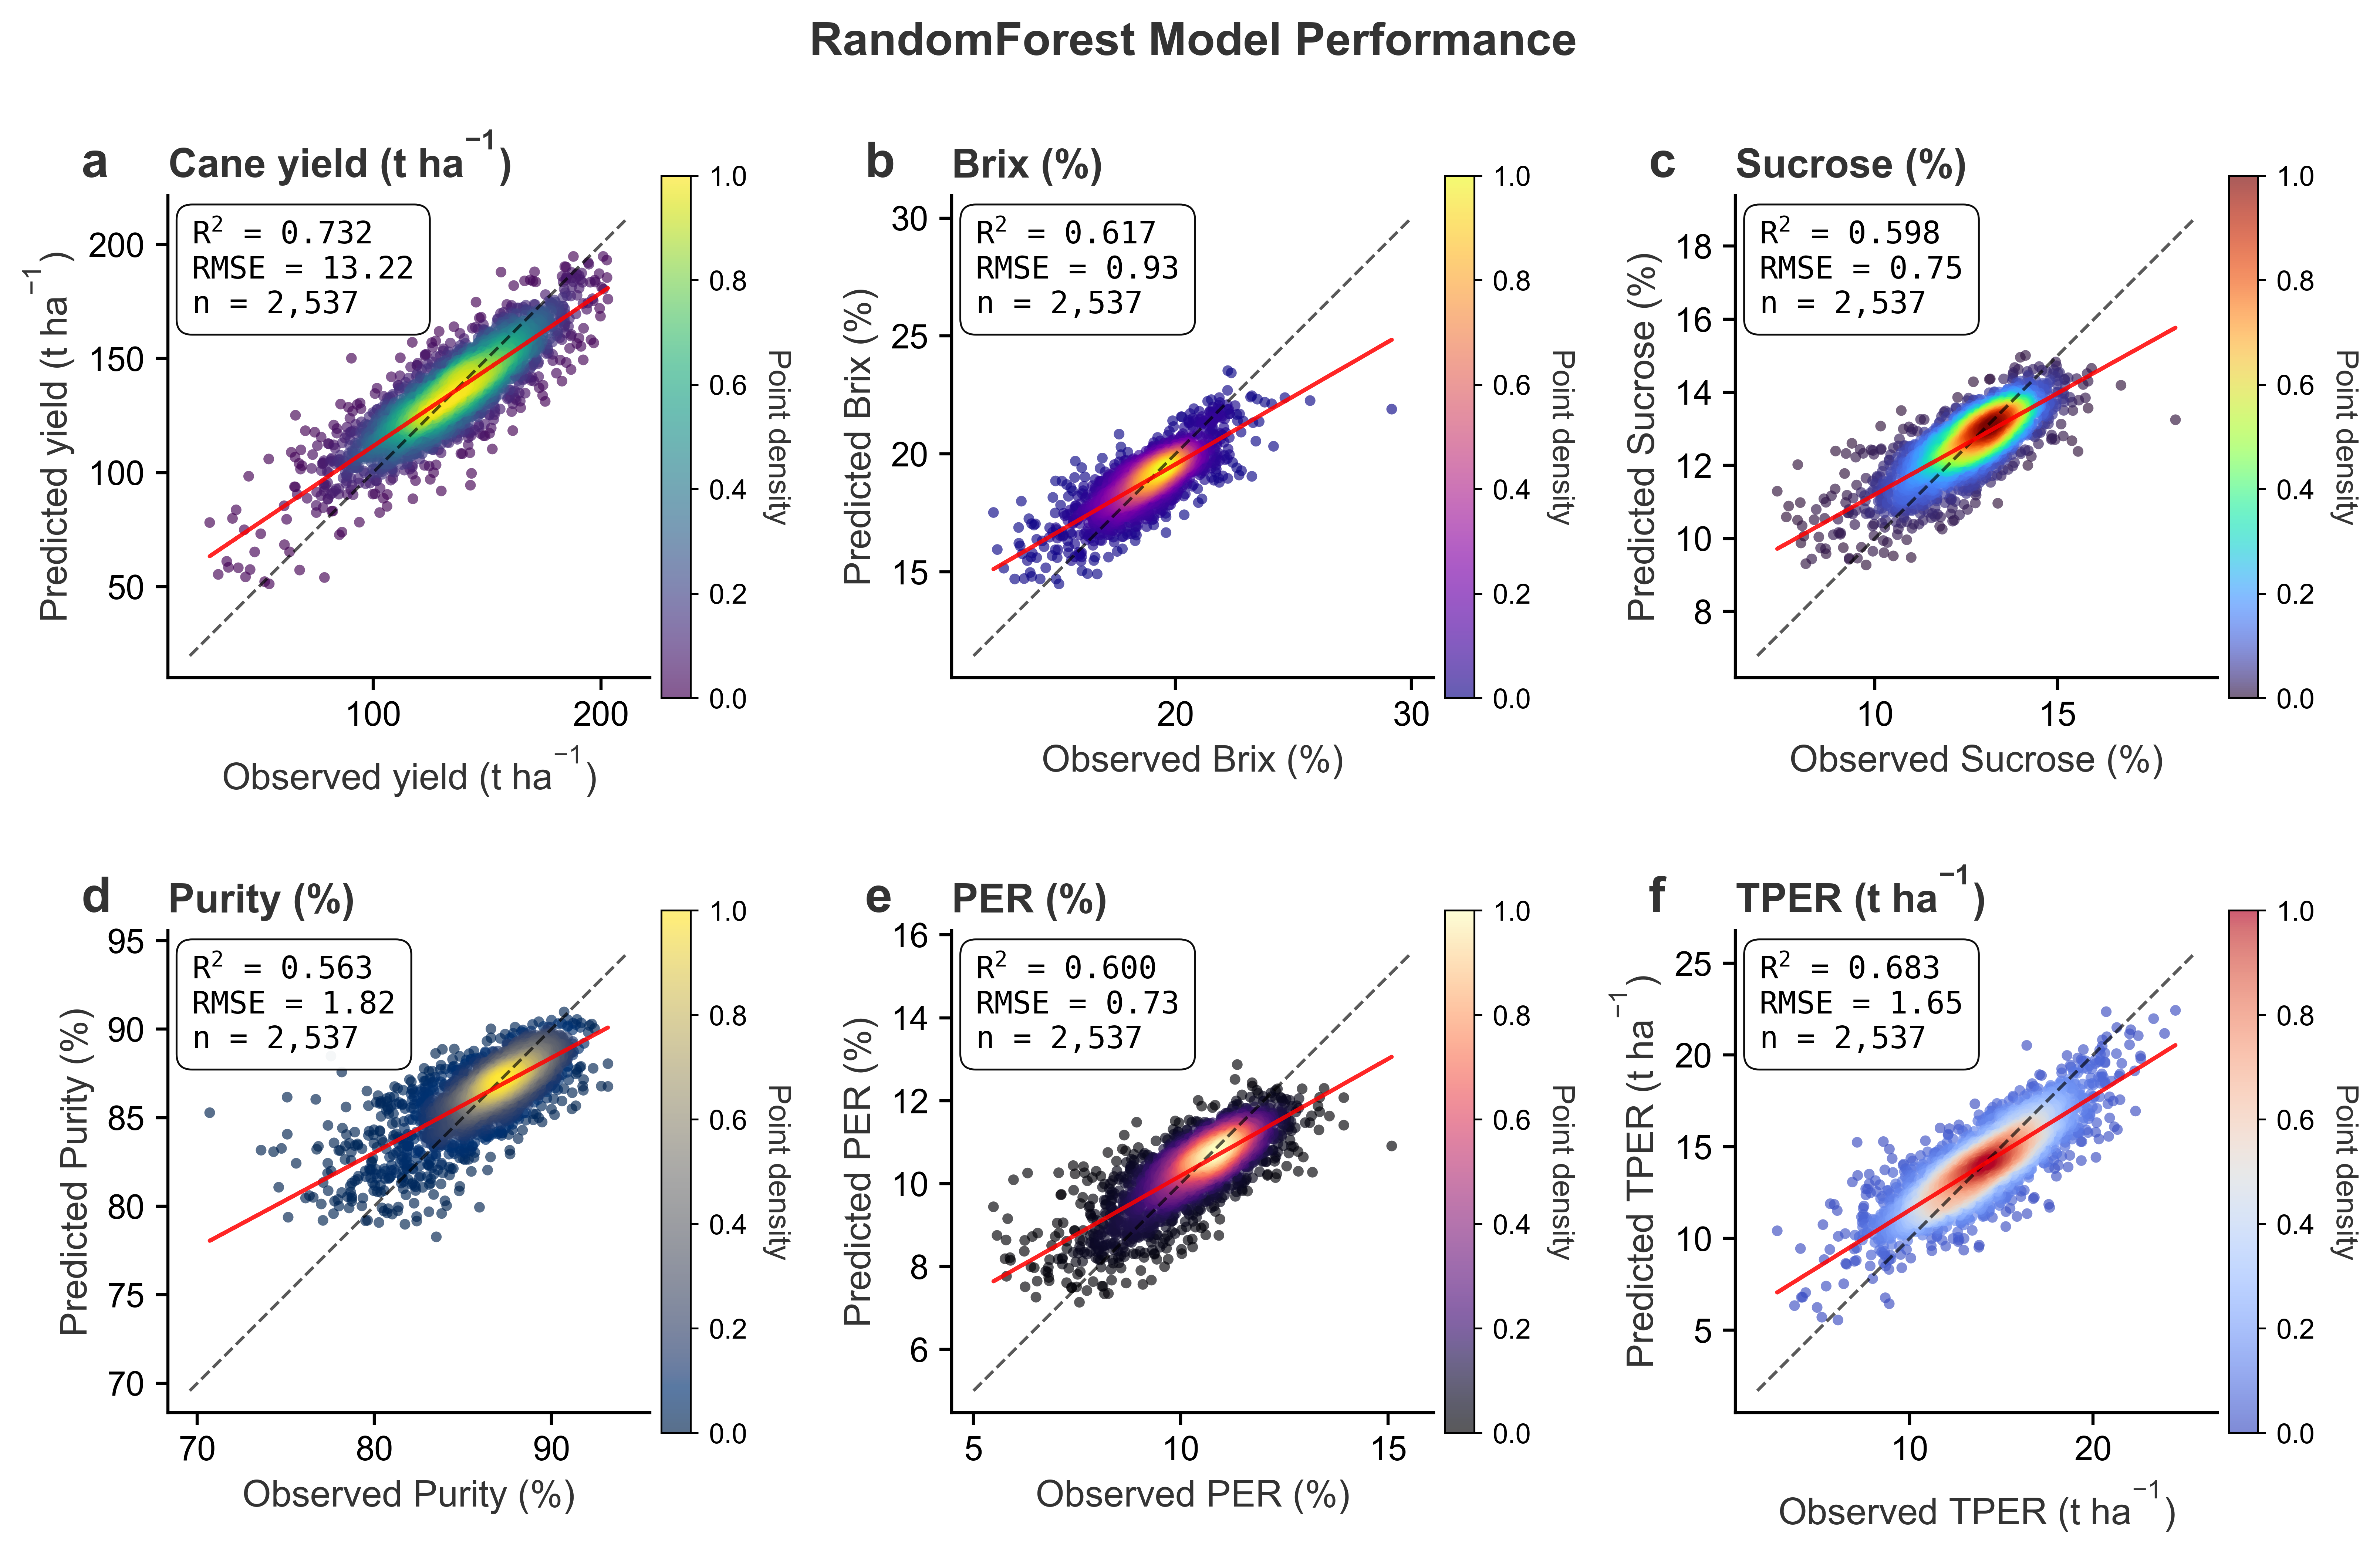

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
from pathlib import Path
from scipy.stats import gaussian_kde
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

# Paths

BASE_MODELS_DIR = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
DATA_PATH = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv'
OUTPUT_DIR = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/combined_grids'
"""

BASE_MODELS_DIR = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Regrouped_Analysis'
DATA_PATH = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Regrouped_Analysis/final_dataset_regrouped_categorical.csv'
OUTPUT_DIR = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Regrouped_Analysis/combined_grids'
"""
# Custom features (same as training)
CUSTOM_FEATURES = [
    'pH_complete', 'Exchangeable_Calcium_meq_100g_complete', 
    'Exchangeable_Potassium_meq_100g_complete', 'Exchangeable_Sodium_meq_100g_complete',
    'Available_P2O5_mg_kg_complete', 'Total_Nitrogen_per_mille_complete', 
    'Electrical_Conductivity_mmho_cm_complete', 'Mg_K_Ratio_complete',
    'Coarse_Silt_percent_complete', 'Coarse_Sand_percent_complete', 
    'growing_season_rainfall_mm', 'CDD', 'SDII',
    'temp_mini_mean', 'temp_maxi_mean', 'h_mini_mean', 'h_maxi_mean',
    'soil_temp_6h_mean', 'radiation_ERA_total', 'CWD', 'Rx1', 'R20', 'TNn', 'TNx'
]

# Categorical features
CATEGORICAL_FEATURES = ['variety', 'irrigation_type', 'harvest_mode', 'crop_cycle']

# Response variables (in order for the grid) - UPDATED ORDER
RESPONSE_VARIABLES = [
    'tc_per_ha_actual',
    'brix_percent', 
    'hugot_sugar',
    'purity_percent',
    'estimated_recoverable_pol',
    'total_recoverable_sugar_t_per_ha'
]

# Model to plot (change this to 'XGBoost' or 'LinearRegression' as needed)
MODEL_NAME = 'RandomForest'

# Language ('en' or 'fr')
LANGUAGE = 'en'

# Panel labels
PANEL_LABELS = ['a', 'b', 'c', 'd', 'e', 'f']

# ============================================================================
# RESPONSE VARIABLE CONFIGURATIONS
# ============================================================================

RESPONSE_VARIABLE_CONFIG = {
    'tc_per_ha_actual': {
        'display_name': {'en': r'Cane yield (t ha$^{-1}$)', 'fr': r'Rendement en canne (t ha$^{-1}$)'},
        'unit': r't ha$^{-1}$',
        'ylabel_observed': {'en': r'Observed yield (t ha$^{-1}$)', 'fr': r'Rendement observé (t ha$^{-1}$)'},
        'ylabel_predicted': {'en': r'Predicted yield (t ha$^{-1}$)', 'fr': r'Rendement prédit (t ha$^{-1}$)'},
        'colormap': 'viridis'
    },
    'brix_percent': {
        'display_name': {'en': 'Brix (%)', 'fr': 'Brix (%)'},
        'unit': '%',
        'ylabel_observed': {'en': 'Observed Brix (%)', 'fr': 'Brix observé (%)'},
        'ylabel_predicted': {'en': 'Predicted Brix (%)', 'fr': 'Brix prédit (%)'},
        'colormap': 'plasma'
    },
    'hugot_sugar': {
        'display_name': {'en': 'Sucrose (%)', 'fr': 'Saccharose (%)'},
        'unit': '%',
        'ylabel_observed': {'en': 'Observed Sucrose (%)', 'fr': 'Saccharose observé (%)'},
        'ylabel_predicted': {'en': 'Predicted Sucrose (%)', 'fr': 'Saccharose prédit (%)'},
        'colormap': 'turbo'
    },
    'purity_percent': {
        'display_name': {'en': 'Purity (%)', 'fr': 'Pureté (%)'},
        'unit': '%',
        'ylabel_observed': {'en': 'Observed Purity (%)', 'fr': 'Pureté observée (%)'},
        'ylabel_predicted': {'en': 'Predicted Purity (%)', 'fr': 'Pureté prédite (%)'},
        'colormap': 'cividis'
    },
    'estimated_recoverable_pol': {
        'display_name': {'en': 'PER (%)', 'fr': 'PER (%)'},
        'unit': '%',
        'ylabel_observed': {'en': 'Observed PER (%)', 'fr': 'PER observé (%)'},
        'ylabel_predicted': {'en': 'Predicted PER (%)', 'fr': 'PER prédit (%)'},
        'colormap': 'magma'
    },
    'total_recoverable_sugar_t_per_ha': {
        'display_name': {'en': r'TPER (t ha$^{-1}$)', 'fr': r'TPER (t ha$^{-1}$)'},
        'unit': r't ha$^{-1}$',
        'ylabel_observed': {'en': r'Observed TPER (t ha$^{-1}$)', 'fr': r'TPER observée (t ha$^{-1}$)'},
        'ylabel_predicted': {'en': r'Predicted TPER (t ha$^{-1}$)', 'fr': r'TPER prédite (t ha$^{-1}$)'},
        'colormap': 'coolwarm'
    }
}

TRANSLATIONS = {
    'en': {'point_density': 'Point density', 'fit_line': 'Fit', 'one_to_one': '1:1 line'},
    'fr': {'point_density': 'Densité de points', 'fit_line': 'Ajustement', 'one_to_one': 'Ligne 1:1'}
}

# ============================================================================
# FONT SETUP 
# ============================================================================

available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in available_fonts:
    font_family = 'Arial'
elif 'Helvetica' in available_fonts:
    font_family = 'Helvetica'
elif 'DejaVu Sans' in available_fonts:
    font_family = 'DejaVu Sans'
elif 'Liberation Sans' in available_fonts:
    font_family = 'Liberation Sans'
else:
    font_family = 'sans-serif'

plt.rcParams.update({
    'font.family': font_family,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'axes.linewidth': 1.0,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'lines.linewidth': 1.2,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'savefig.dpi': 600,
    'figure.dpi': 600,
})

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def load_data_and_prepare_features(data_path, response_variable, custom_predictors=None, categorical_vars=None):
    """Load and prepare data with categorical encoding"""
    df = pd.read_csv(data_path)
    
    if response_variable not in df.columns:
        raise ValueError(f"Response variable '{response_variable}' not found!")
    
    df = df.dropna(subset=[response_variable])
    
    # Identify year column
    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break
    
    # Encode categorical variables
    encoders = {}
    if categorical_vars:
        for cat_var in categorical_vars:
            if cat_var in df.columns:
                cat_encoder = LabelEncoder()
                df[f'{cat_var}_encoded'] = cat_encoder.fit_transform(df[cat_var].astype(str))
                encoders[cat_var] = cat_encoder
    
    # Prepare features
    if custom_predictors is not None:
        FEATURES = [col for col in custom_predictors if col in df.columns]
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in df.columns:
                    FEATURES.append(encoded_col)
    else:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        exclude_cols = [response_variable]
        if year_column:
            exclude_cols.extend([year_column, f'{year_column}_encoded'])
        if categorical_vars:
            exclude_cols.extend(categorical_vars)
        FEATURES = [col for col in numeric_cols if col not in exclude_cols]
    
    # Fill missing values
    for col in FEATURES:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    
    X = df[FEATURES].copy()
    y = df[response_variable].copy()
    
    return X, y, FEATURES, encoders

def get_cv_predictions(model, scaler, X, y, n_splits=5):
    """Get cross-validation predictions"""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    all_predictions = []
    all_actuals = []
    
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        scaler_fold = StandardScaler()
        X_train_scaled = scaler_fold.fit_transform(X_train)
        X_val_scaled = scaler_fold.transform(X_val)
        
        model_fold = model.__class__(**model.get_params())
        model_fold.fit(X_train_scaled, y_train)
        y_pred = model_fold.predict(X_val_scaled)
        
        all_predictions.extend(y_pred)
        all_actuals.extend(y_val)
    
    return np.array(all_actuals), np.array(all_predictions)

def calculate_metrics(y_true, y_pred):
    """Calculate performance metrics"""
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {'r2': r2, 'rmse': rmse, 'mae': mae, 'n': len(y_true)}

def calculate_point_density(x, y):
    """Calculate density for each point using KDE"""
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]
    xy = np.vstack([x_clean, y_clean])
    try:
        kde = gaussian_kde(xy)
        density = kde(xy)
    except:
        density = np.ones(len(x_clean))
    density = (density - density.min()) / (density.max() - density.min())
    return density, mask

# ============================================================================
# MAIN:
# ============================================================================

print("="*80)
print(f"CREATING GRID PLOT FOR {MODEL_NAME}")
print(f"Language: {LANGUAGE.upper()}")
print("="*80)

# Create output directory
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

# Collect results for all response variables
all_results = {}
trans = TRANSLATIONS[LANGUAGE]

print("\nLoading models and generating predictions...")
for response_var in RESPONSE_VARIABLES:
    print(f"\n  Processing: {response_var}")
    
    try:
        # Load data
        X, y, FEATURES, encoders = load_data_and_prepare_features(
            DATA_PATH, response_var, CUSTOM_FEATURES, CATEGORICAL_FEATURES
        )
        
        # Find model file
        models_dir = Path(BASE_MODELS_DIR) / f'kfold_models_{response_var}_with_categorical' / 'models'
        if not models_dir.exists():
            models_dir = Path(BASE_MODELS_DIR) / f'kfold_models_{response_var}' / 'models'
        
        model_file = models_dir / f'{MODEL_NAME}_{response_var}.pkl'
        
        if not model_file.exists():
            print(f"    ⚠ Model not found: {model_file}")
            continue
        
        # Load model
        model_data = joblib.load(model_file)
        model = model_data['model']
        scaler = model_data['scaler']
        
        # Get predictions
        y_true, y_pred = get_cv_predictions(model, scaler, X, y, n_splits=5)
        metrics = calculate_metrics(y_true, y_pred)
        
        all_results[response_var] = {
            'y_true': y_true,
            'y_pred': y_pred,
            'metrics': metrics
        }
        
        print(f"    ✓ R² = {metrics['r2']:.3f}, RMSE = {metrics['rmse']:.3f}")
        
    except Exception as e:
        print(f"    ✗ Error: {str(e)}")
        continue

if len(all_results) == 0:
    print("\n❌ No results to plot!")
else:
    print(f"\n✓ Successfully loaded {len(all_results)} response variables")
    print("\nCreating enhanced Nature-style grid plot...")
    
    # Create more compact figure - Nature style
    fig = plt.figure(figsize=(11, 7.5), dpi=600)
    
    # Use GridSpec for tighter control
    import matplotlib.gridspec as gridspec
    gs = gridspec.GridSpec(2, 3, figure=fig,
                          left=0.08, right=0.96,
                          top=0.94, bottom=0.08,
                          wspace=0.35, hspace=0.055)
    
    response_vars_ordered = list(all_results.keys())
    
    for idx, response_var in enumerate(response_vars_ordered):
        if idx >= 6:
            break
        
        row = idx // 3
        col = idx % 3
        ax = fig.add_subplot(gs[row, col])
        
        result = all_results[response_var]
        response_config = RESPONSE_VARIABLE_CONFIG[response_var]
        
        y_true = result['y_true']
        y_pred = result['y_pred']
        metrics = result['metrics']
        
        # Calculate density
        density, mask = calculate_point_density(y_true, y_pred)
        y_true_clean = y_true[mask]
        y_pred_clean = y_pred[mask]
        
        # Sort by density
        idx_sort = density.argsort()
        y_true_sorted = y_true_clean[idx_sort]
        y_pred_sorted = y_pred_clean[idx_sort]
        density_sorted = density[idx_sort]
        
        # Scatter plot with slightly larger points
        scatter = ax.scatter(y_true_sorted, y_pred_sorted, 
                            c=density_sorted, 
                            cmap=response_config['colormap'],
                            s=12,
                            alpha=0.65,
                            edgecolors='none',
                            rasterized=True)
        
        # 1:1 line - slightly thicker
        lims = [np.min([ax.get_xlim(), ax.get_ylim()]), 
                np.max([ax.get_xlim(), ax.get_ylim()])]
        ax.plot(lims, lims, 'k--', linewidth=1.0, alpha=0.65, zorder=1, label='1:1 line')
        
        # Best fit line - more visible
        z = np.polyfit(y_true_clean, y_pred_clean, 1)
        p = np.poly1d(z)
        ax.plot(y_true_clean, p(y_true_clean), 
                color='red', linewidth=1.3, alpha=0.85, zorder=2, label='Fit')
        
        # Labels with larger font
        ax.set_xlabel(response_config['ylabel_observed'][LANGUAGE], 
                     fontweight='normal', fontsize=12)
        ax.set_ylabel(response_config['ylabel_predicted'][LANGUAGE], 
                     fontweight='normal', fontsize=12)
        
        # Panel label + Title on same line (Nature style)
        title_text = f"{response_config['display_name'][LANGUAGE]}"
        ax.set_title(title_text, fontweight='bold', pad=6, fontsize=13, loc='left')
        
        # Add panel label INLINE with title, top-left
        ax.text(-0.18, 1.02, f'{PANEL_LABELS[idx]}', transform=ax.transAxes,
                fontsize=16, fontweight='bold', va='bottom', ha='left')
        
        # Clean, professional axes
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_linewidth(1.0)
        ax.spines['bottom'].set_linewidth(1.0)
        
        ax.tick_params(axis='both', colors='black', which='both')
        ax.tick_params(axis='x', direction='out', length=4, width=1.0, labelsize=11)
        ax.tick_params(axis='y', direction='out', length=4, width=1.0, labelsize=11)
        ax.grid(False)
        
        # Colorbar - more compact but readable
        cbar = plt.colorbar(scatter, ax=ax, pad=0.02, aspect=18, shrink=0.75)
        cbar.set_label(trans['point_density'], rotation=270, labelpad=14, fontsize=10)
        cbar.ax.tick_params(labelsize=9, width=0.6, length=2.5, colors='black')
        cbar.outline.set_linewidth(0.6)
        cbar.outline.set_edgecolor('black')
        
        # Statistics box - larger, more readable font
        stats_text = (
            f'$R^2$ = {metrics["r2"]:.3f}\n'
            f'RMSE = {metrics["rmse"]:.2f}\n'
            f'$n$ = {metrics["n"]:,}'
        )
        
        props = dict(boxstyle='round,pad=0.5', facecolor='white', 
                    edgecolor='black', linewidth=0.6, alpha=0.95)
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                fontsize=10,
                verticalalignment='top', bbox=props,
                family='monospace', color='black')
        
        ax.set_aspect('equal', adjustable='box')
        
        print(f"  Panel {PANEL_LABELS[idx]}: {response_var} - R²={metrics['r2']:.3f}")
    
    # Hide empty subplot if needed
    if len(response_vars_ordered) < 6:
        # Add empty subplot and hide it
        ax_empty = fig.add_subplot(gs[1, 2])
        ax_empty.axis('off')
    
    # Overall title - larger and more prominent
    fig.suptitle(f'{MODEL_NAME} Model Performance', 
                fontsize=15, fontweight='bold', y=0.98)
    
    # Save with high quality
    output_png = output_dir / f'combined_grid_{MODEL_NAME}_{LANGUAGE}_enhanced.png'
    plt.savefig(output_png, dpi=600, bbox_inches='tight', 
               facecolor='white', edgecolor='none', pad_inches=0.05)
    print(f"\n✓ Saved PNG: {output_png}")
    
    output_pdf = output_dir / f'combined_grid_{MODEL_NAME}_{LANGUAGE}_enhanced.pdf'
    plt.savefig(output_pdf, format='pdf', bbox_inches='tight', 
               facecolor='white', edgecolor='none', pad_inches=0.05)
    print(f"✓ Saved PDF: {output_pdf}")
    
    plt.show()

# SCATTERPLOTS COMBINED : RF + XGBOOST

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
from pathlib import Path
from scipy.stats import gaussian_kde
import matplotlib.font_manager as fm
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION 
# ============================================================================

# Paths
BASE_MODELS_DIR = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
DATA_PATH = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv'
OUTPUT_DIR = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/three_panel_scatter'

# Custom features (same as training)
CUSTOM_FEATURES = [
    'pH_complete', 'Exchangeable_Calcium_meq_100g_complete', 
    'Exchangeable_Potassium_meq_100g_complete', 'Exchangeable_Sodium_meq_100g_complete',
    'Available_P2O5_mg_kg_complete', 'Total_Nitrogen_per_mille_complete', 
    'Electrical_Conductivity_mmho_cm_complete', 'Mg_K_Ratio_complete',
    'Coarse_Silt_percent_complete', 'Coarse_Sand_percent_complete', 
    'growing_season_rainfall_mm', 'CDD', 'SDII',
    'temp_mini_mean', 'temp_maxi_mean', 'h_mini_mean', 'h_maxi_mean',
    'soil_temp_6h_mean', 'radiation_ERA_total', 'CWD', 'Rx1', 'R20', 'TNn', 'TNx'
]

# Categorical features
CATEGORICAL_FEATURES = ['variety', 'irrigation_type', 'harvest_mode', 'crop_cycle']

# Three response variables in order: Yield, Sucrose, TPER
RESPONSE_VARIABLES = [
    'tc_per_ha_actual',
    'hugot_sugar',
    'total_recoverable_sugar_t_per_ha'
]

# Panel labels
PANEL_LABELS = ['a.', 'b.', 'c.']

# ============================================================================
# RESPONSE VARIABLE CONFIGURATIONS
# ============================================================================

RESPONSE_VARIABLE_CONFIG = {
    'tc_per_ha_actual': {
        'display_name': {'en': r'Cane yield (t ha$^{-1}$)', 'fr': r'Rendement en canne (t ha$^{-1}$)'},
        'unit': r't ha$^{-1}$',
        'ylabel_observed': {'en': r'Observed yield (t ha$^{-1}$)', 'fr': r'Rendement observé (t ha$^{-1}$)'},
        'ylabel_predicted': {'en': r'Predicted yield (t ha$^{-1}$)', 'fr': r'Rendement prédit (t ha$^{-1}$)'},
        'colormap': 'viridis'
    },
    'hugot_sugar': {
        'display_name': {'en': 'Sucrose (%)', 'fr': 'Saccharose (%)'},
        'unit': '%',
        'ylabel_observed': {'en': 'Observed Sucrose (%)', 'fr': 'Saccharose observé (%)'},
        'ylabel_predicted': {'en': 'Predicted Sucrose (%)', 'fr': 'Saccharose prédit (%)'},
        'colormap': 'plasma'
    },
    'total_recoverable_sugar_t_per_ha': {
        'display_name': {'en': r'TPER (t ha$^{-1}$)', 'fr': r'TPER (t ha$^{-1}$)'},
        'unit': r't ha$^{-1}$',
        'ylabel_observed': {'en': r'Observed TPER (t ha$^{-1}$)', 'fr': r'TPER observée (t ha$^{-1}$)'},
        'ylabel_predicted': {'en': r'Predicted TPER (t ha$^{-1}$)', 'fr': r'TPER prédite (t ha$^{-1}$)'},
        'colormap': 'magma'
    }
}

TRANSLATIONS = {
    'en': {'point_density': 'Point density', 'fit_line': 'Fit', 'one_to_one': '1:1 line'},
    'fr': {'point_density': 'Densité de points', 'fit_line': 'Ajustement', 'one_to_one': 'Ligne 1:1'}
}

# ============================================================================
# FONT SETUP
# ============================================================================

available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in available_fonts:
    font_family = 'Arial'
elif 'Helvetica' in available_fonts:
    font_family = 'Helvetica'
elif 'DejaVu Sans' in available_fonts:
    font_family = 'DejaVu Sans'
elif 'Liberation Sans' in available_fonts:
    font_family = 'Liberation Sans'
else:
    font_family = 'sans-serif'

plt.rcParams.update({
    'font.family': font_family,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'axes.linewidth': 1.0,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'lines.linewidth': 1.2,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'savefig.dpi': 600,
    'figure.dpi': 600,
})

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def load_data_and_prepare_features(data_path, response_variable, custom_predictors=None, categorical_vars=None):
    """Load and prepare data with categorical encoding"""
    df = pd.read_csv(data_path)
    
    if response_variable not in df.columns:
        raise ValueError(f"Response variable '{response_variable}' not found!")
    
    df = df.dropna(subset=[response_variable])
    
    # Identify year column
    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break
    
    # Encode categorical variables
    encoders = {}
    if categorical_vars:
        for cat_var in categorical_vars:
            if cat_var in df.columns:
                cat_encoder = LabelEncoder()
                df[f'{cat_var}_encoded'] = cat_encoder.fit_transform(df[cat_var].astype(str))
                encoders[cat_var] = cat_encoder
    
    # Prepare features
    if custom_predictors is not None:
        FEATURES = [col for col in custom_predictors if col in df.columns]
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in df.columns:
                    FEATURES.append(encoded_col)
    else:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        exclude_cols = [response_variable]
        if year_column:
            exclude_cols.extend([year_column, f'{year_column}_encoded'])
        if categorical_vars:
            exclude_cols.extend(categorical_vars)
        FEATURES = [col for col in numeric_cols if col not in exclude_cols]
    
    # Fill missing values
    for col in FEATURES:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    
    X = df[FEATURES].copy()
    y = df[response_variable].copy()
    
    return X, y, FEATURES, encoders

def get_cv_predictions(model, scaler, X, y, n_splits=5):
    """Get cross-validation predictions"""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    all_predictions = []
    all_actuals = []
    
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        scaler_fold = StandardScaler()
        X_train_scaled = scaler_fold.fit_transform(X_train)
        X_val_scaled = scaler_fold.transform(X_val)
        
        model_fold = model.__class__(**model.get_params())
        model_fold.fit(X_train_scaled, y_train)
        y_pred = model_fold.predict(X_val_scaled)
        
        all_predictions.extend(y_pred)
        all_actuals.extend(y_val)
    
    return np.array(all_actuals), np.array(all_predictions)

def calculate_metrics(y_true, y_pred):
    """Calculate performance metrics"""
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {'r2': r2, 'rmse': rmse, 'mae': mae, 'n': len(y_true)}

def calculate_point_density(x, y):
    """Calculate density for each point using KDE"""
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]
    xy = np.vstack([x_clean, y_clean])
    try:
        kde = gaussian_kde(xy)
        density = kde(xy)
    except:
        density = np.ones(len(x_clean))
    density = (density - density.min()) / (density.max() - density.min())
    return density, mask

def load_model_results(model_name, response_variables, language='en'):
    """Load results for a specific model"""
    all_results = {}
    
    print(f"\nLoading {model_name} models and generating predictions...")
    for response_var in response_variables:
        print(f"  Processing: {response_var}")
        
        try:
            # Load data
            X, y, FEATURES, encoders = load_data_and_prepare_features(
                DATA_PATH, response_var, CUSTOM_FEATURES, CATEGORICAL_FEATURES
            )
            
            # Find model file
            models_dir = Path(BASE_MODELS_DIR) / f'kfold_models_{response_var}_with_categorical' / 'models'
            if not models_dir.exists():
                models_dir = Path(BASE_MODELS_DIR) / f'kfold_models_{response_var}' / 'models'
            
            model_file = models_dir / f'{model_name}_{response_var}.pkl'
            
            if not model_file.exists():
                print(f"    ⚠ Model not found: {model_file}")
                continue
            
            # Load model
            model_data = joblib.load(model_file)
            model = model_data['model']
            scaler = model_data['scaler']
            
            # Get predictions
            y_true, y_pred = get_cv_predictions(model, scaler, X, y, n_splits=5)
            metrics = calculate_metrics(y_true, y_pred)
            
            all_results[response_var] = {
                'y_true': y_true,
                'y_pred': y_pred,
                'metrics': metrics
            }
            
            print(f"    ✓ R² = {metrics['r2']:.3f}, RMSE = {metrics['rmse']:.3f}")
            
        except Exception as e:
            print(f"    ✗ Error: {str(e)}")
            continue
    
    return all_results

def create_three_panel_plot(results, model_name, output_path, language='en'):
    """Create 1 row × 3 columns scatter plot"""
    
    trans = TRANSLATIONS[language]
    
    if len(results) != 3:
        print(f"Warning: Expected 3 response variables, got {len(results)}")
        return
    
    # Create figure: 1 row × 3 columns
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), dpi=600)
    
    response_vars_ordered = RESPONSE_VARIABLES
    
    for idx, response_var in enumerate(response_vars_ordered):
        if response_var not in results:
            continue
            
        ax = axes[idx]
        result = results[response_var]
        response_config = RESPONSE_VARIABLE_CONFIG[response_var]
        
        y_true = result['y_true']
        y_pred = result['y_pred']
        metrics = result['metrics']
        
        # Calculate density
        density, mask = calculate_point_density(y_true, y_pred)
        y_true_clean = y_true[mask]
        y_pred_clean = y_pred[mask]
        
        # Sort by density
        idx_sort = density.argsort()
        y_true_sorted = y_true_clean[idx_sort]
        y_pred_sorted = y_pred_clean[idx_sort]
        density_sorted = density[idx_sort]
        
        # Scatter plot
        scatter = ax.scatter(y_true_sorted, y_pred_sorted, 
                            c=density_sorted, 
                            cmap=response_config['colormap'],
                            s=12,
                            alpha=0.65,
                            edgecolors='none',
                            rasterized=True)
        
        # 1:1 line
        lims = [np.min([ax.get_xlim(), ax.get_ylim()]), 
                np.max([ax.get_xlim(), ax.get_ylim()])]
        ax.plot(lims, lims, 'k--', linewidth=1.0, alpha=0.65, zorder=1, label='1:1 line')
        
        # Best fit line
        z = np.polyfit(y_true_clean, y_pred_clean, 1)
        p = np.poly1d(z)
        ax.plot(y_true_clean, p(y_true_clean), 
                color='red', linewidth=1.3, alpha=0.85, zorder=2, label='Fit')
        
        # Labels
        ax.set_xlabel(response_config['ylabel_observed'][language], 
                     fontweight='normal', fontsize=12)
        ax.set_ylabel(response_config['ylabel_predicted'][language], 
                     fontweight='normal', fontsize=12)
        
        # Title
        title_text = f"{response_config['display_name'][language]}"
        ax.set_title(title_text, fontweight='bold', pad=6, fontsize=13, loc='left')
        
        # Add panel label with period (a., b., c.)
        ax.text(-0.18, 1.02, PANEL_LABELS[idx], transform=ax.transAxes,
                fontsize=13, fontweight='bold', va='bottom', ha='left')
        
        # Clean axes
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_linewidth(1.0)
        ax.spines['bottom'].set_linewidth(1.0)
        
        ax.tick_params(axis='both', colors='black', which='both')
        ax.tick_params(axis='x', direction='out', length=4, width=1.0, labelsize=11)
        ax.tick_params(axis='y', direction='out', length=4, width=1.0, labelsize=11)
        ax.grid(False)
        
        # Colorbar
        cbar = plt.colorbar(scatter, ax=ax, pad=0.02, aspect=18, shrink=0.75)
        cbar.set_label(trans['point_density'], rotation=270, labelpad=14, fontsize=10)
        cbar.ax.tick_params(labelsize=9, width=0.6, length=2.5, colors='black')
        cbar.outline.set_linewidth(0.6)
        cbar.outline.set_edgecolor('black')
        
        # Statistics box
        stats_text = (
            f'$R^2$ = {metrics["r2"]:.3f}\n'
            f'RMSE = {metrics["rmse"]:.2f}\n'
            f'$n$ = {metrics["n"]:,}'
        )
        
        props = dict(boxstyle='round,pad=0.5', facecolor='white', 
                    edgecolor='black', linewidth=0.6, alpha=0.95)
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                fontsize=10,
                verticalalignment='top', bbox=props,
                family='monospace', color='black')
        
        ax.set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    
    # Save
    plt.savefig(output_path, dpi=600, bbox_inches='tight', 
               facecolor='white', edgecolor='none', pad_inches=0.05)
    print(f"  ✓ Saved: {output_path}")
    
    # Save PDF
    pdf_path = str(output_path).replace('.png', '.pdf')
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight', 
               facecolor='white', edgecolor='none', pad_inches=0.05)
    print(f"  ✓ Saved: {pdf_path}")
    
    plt.close()

def create_combined_two_row_plot(rf_results, xgb_results, output_path, language='en'):
    """Create 2 rows × 3 columns combined plot (RF top, XGBoost bottom) - FIXED LAYOUT"""
    
    trans = TRANSLATIONS[language]
    
    # Create figure with GridSpec for precise layout control
    fig = plt.figure(figsize=(11, 7.5), dpi=600)
    
    # Adjusted GridSpec: move top down significantly and reduce vertical gap
    gs = gridspec.GridSpec(2, 3, figure=fig,
                          left=0.08, right=0.96,
                          top=0.85, bottom=0.08,  
                          wspace=0.35, hspace=0.15) 
    
    response_vars_ordered = RESPONSE_VARIABLES
    
    # Define row labels
    row_labels = ['a. RF', 'b. XGBoost']
    model_results = [rf_results, xgb_results]
    
    for row_idx, (results, row_label) in enumerate(zip(model_results, row_labels)):
        for col_idx, response_var in enumerate(response_vars_ordered):
            if response_var not in results:
                continue
            
            ax = fig.add_subplot(gs[row_idx, col_idx])
            result = results[response_var]
            response_config = RESPONSE_VARIABLE_CONFIG[response_var]
            
            y_true = result['y_true']
            y_pred = result['y_pred']
            metrics = result['metrics']
            
            # Calculate density
            density, mask = calculate_point_density(y_true, y_pred)
            y_true_clean = y_true[mask]
            y_pred_clean = y_pred[mask]
            
            # Sort by density
            idx_sort = density.argsort()
            y_true_sorted = y_true_clean[idx_sort]
            y_pred_sorted = y_pred_clean[idx_sort]
            density_sorted = density[idx_sort]
            
            # Scatter plot
            scatter = ax.scatter(y_true_sorted, y_pred_sorted, 
                                c=density_sorted, 
                                cmap=response_config['colormap'],
                                s=12,
                                alpha=0.65,
                                edgecolors='none',
                                rasterized=True)
            
            # 1:1 line
            lims = [np.min([ax.get_xlim(), ax.get_ylim()]), 
                    np.max([ax.get_xlim(), ax.get_ylim()])]
            ax.plot(lims, lims, 'k--', linewidth=1.0, alpha=0.65, zorder=1)
            
            # Best fit line
            z = np.polyfit(y_true_clean, y_pred_clean, 1)
            p = np.poly1d(z)
            ax.plot(y_true_clean, p(y_true_clean), 
                    color='red', linewidth=1.3, alpha=0.85, zorder=2)
            
            # Labels - all axes have labels
            ax.set_xlabel(response_config['ylabel_observed'][language], 
                         fontweight='normal', fontsize=12)
            ax.set_ylabel(response_config['ylabel_predicted'][language], 
                         fontweight='normal', fontsize=12)
            
            # Title - only on top row
            if row_idx == 0:
                title_text = f"{response_config['display_name'][language]}"
                ax.set_title(title_text, fontweight='bold', pad=6, fontsize=13, loc='left')
            
            # Add row label on first column only - positioned to avoid overlap
            if col_idx == 0:
                ax.text(-0.35, 1.05, row_label, transform=ax.transAxes,
                        fontsize=13, fontweight='bold', va='bottom', ha='left')
            
            # Clean axes
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_color('black')
            ax.spines['bottom'].set_color('black')
            ax.spines['left'].set_linewidth(1.0)
            ax.spines['bottom'].set_linewidth(1.0)
            
            ax.tick_params(axis='both', colors='black', which='both')
            ax.tick_params(axis='x', direction='out', length=4, width=1.0, labelsize=11)
            ax.tick_params(axis='y', direction='out', length=4, width=1.0, labelsize=11)
            ax.grid(False)
            
            # Colorbar
            cbar = plt.colorbar(scatter, ax=ax, pad=0.02, aspect=18, shrink=0.75)
            cbar.set_label(trans['point_density'], rotation=270, labelpad=14, fontsize=10)
            cbar.ax.tick_params(labelsize=9, width=0.6, length=2.5, colors='black')
            cbar.outline.set_linewidth(0.6)
            cbar.outline.set_edgecolor('black')
            
            # Statistics box
            stats_text = (
                f'$R^2$ = {metrics["r2"]:.3f}\n'
                f'RMSE = {metrics["rmse"]:.2f}\n'
                f'$n$ = {metrics["n"]:,}'
            )
            
            props = dict(boxstyle='round,pad=0.5', facecolor='white', 
                        edgecolor='black', linewidth=0.6, alpha=0.95)
            ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                    fontsize=10,
                    verticalalignment='top', bbox=props,
                    family='monospace', color='black')
            
            ax.set_aspect('equal', adjustable='box')
    
    # Save
    plt.savefig(output_path, dpi=600, bbox_inches='tight', 
               facecolor='white', edgecolor='none', pad_inches=0.05)
    print(f"  ✓ Saved: {output_path}")
    
    # Save PDF
    pdf_path = str(output_path).replace('.png', '.pdf')
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight', 
               facecolor='white', edgecolor='none', pad_inches=0.05)
    print(f"  ✓ Saved: {pdf_path}")
    
    plt.close()

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main function to create scatter plots"""
    
    print("="*80)
    print("THREE-PANEL SCATTER PLOTS: RANDOMFOREST & XGBOOST")
    print("="*80)
    
    # Create output directory
    output_dir = Path(OUTPUT_DIR)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Generate plots for both languages
    for lang in ['en', 'fr']:
        lang_suffix = f'_{lang}'
        
        print(f"\n{'='*80}")
        print(f"GENERATING {lang.upper()} PLOTS")
        print(f"{'='*80}")
        
        # Load RandomForest results
        print("\n1. Loading RandomForest results...")
        rf_results = load_model_results('RandomForest', RESPONSE_VARIABLES, lang)
        
        if len(rf_results) == 3:
            print("\n2. Creating RandomForest three-panel plot...")
            rf_output = output_dir / f'three_panel_RandomForest{lang_suffix}.png'
            create_three_panel_plot(rf_results, 'RandomForest', rf_output, lang)
        else:
            print(f"  ⚠ Skipping RF plot - only {len(rf_results)}/3 variables loaded")
        
        # Load XGBoost results
        print("\n3. Loading XGBoost results...")
        xgb_results = load_model_results('XGBoost', RESPONSE_VARIABLES, lang)
        
        if len(xgb_results) == 3:
            print("\n4. Creating XGBoost three-panel plot...")
            xgb_output = output_dir / f'three_panel_XGBoost{lang_suffix}.png'
            create_three_panel_plot(xgb_results, 'XGBoost', xgb_output, lang)
        else:
            print(f"  ⚠ Skipping XGB plot - only {len(xgb_results)}/3 variables loaded")
        
        # Create combined plot
        if len(rf_results) == 3 and len(xgb_results) == 3:
            print("\n5. Creating combined RF + XGBoost plot (2 rows × 3 cols)...")
            combined_output = output_dir / f'combined_RF_XGBoost{lang_suffix}.png'
            create_combined_two_row_plot(rf_results, xgb_results, combined_output, lang)
        else:
            print("  ⚠ Skipping combined plot - insufficient data")

if __name__ == "__main__":
    main()

THREE-PANEL SCATTER PLOTS: RANDOMFOREST & XGBOOST

GENERATING EN PLOTS

1. Loading RandomForest results...

Loading RandomForest models and generating predictions...
  Processing: tc_per_ha_actual
    ✓ R² = 0.732, RMSE = 13.221
  Processing: hugot_sugar
    ✓ R² = 0.598, RMSE = 0.749
  Processing: total_recoverable_sugar_t_per_ha
    ✓ R² = 0.683, RMSE = 1.652

2. Creating RandomForest three-panel plot...
  ✓ Saved: C:\Users\U078-N800\Desktop\Ml_Internship\Copy\Ml_Training\Irrigation_Split_Analysis\GAG\three_panel_scatter\three_panel_RandomForest_en.png
  ✓ Saved: C:\Users\U078-N800\Desktop\Ml_Internship\Copy\Ml_Training\Irrigation_Split_Analysis\GAG\three_panel_scatter\three_panel_RandomForest_en.pdf

3. Loading XGBoost results...

Loading XGBoost models and generating predictions...
  Processing: tc_per_ha_actual
    ✓ R² = 0.783, RMSE = 11.899
  Processing: hugot_sugar
    ✓ R² = 0.586, RMSE = 0.760
  Processing: total_recoverable_sugar_t_per_ha
    ✓ R² = 0.722, RMSE = 1.547

4. C

# Three-Panel Scatter Plots - GAG vs GRV Regions

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
from pathlib import Path
from scipy.stats import gaussian_kde
import matplotlib.font_manager as fm
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

# GAG Region Paths
GAG_CONFIG = {
    'BASE_MODELS_DIR': 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG',
    'DATA_PATH': 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv',
    'OUTPUT_DIR': 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/three_panel_scatter'
}

# GRV Region Paths
GRV_CONFIG = {
    'BASE_MODELS_DIR': 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV',
    'DATA_PATH': 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV/dataset_regrouped_GRV.csv',
    'OUTPUT_DIR': 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV/three_panel_scatter'
}

# Custom features (same as training)
CUSTOM_FEATURES = [
    'pH_complete', 'Exchangeable_Calcium_meq_100g_complete', 
    'Exchangeable_Potassium_meq_100g_complete', 'Exchangeable_Sodium_meq_100g_complete',
    'Available_P2O5_mg_kg_complete', 'Total_Nitrogen_per_mille_complete', 
    'Electrical_Conductivity_mmho_cm_complete', 'Mg_K_Ratio_complete',
    'Coarse_Silt_percent_complete', 'Coarse_Sand_percent_complete', 
    'growing_season_rainfall_mm', 'CDD', 'SDII',
    'temp_mini_mean', 'temp_maxi_mean', 'h_mini_mean', 'h_maxi_mean',
    'soil_temp_6h_mean', 'radiation_ERA_total', 'CWD', 'Rx1', 'R20', 'TNn', 'TNx'
]

# Categorical features
CATEGORICAL_FEATURES = ['variety', 'irrigation_type', 'harvest_mode', 'crop_cycle']

# Three response variables in order: Yield, Sucrose, TPER
RESPONSE_VARIABLES = [
    'tc_per_ha_actual',
    'hugot_sugar',
    'total_recoverable_sugar_t_per_ha'
]

# ============================================================================
# RESPONSE VARIABLE CONFIGURATIONS
# ============================================================================

RESPONSE_VARIABLE_CONFIG = {
    'tc_per_ha_actual': {
        'display_name': {'en': r'Cane yield (t ha$^{-1}$)', 'fr': r'Rendement canne (t ha$^{-1}$)'},
        'unit': r't ha$^{-1}$',
        'ylabel_observed': {'en': r'Observed yield (t ha$^{-1}$)', 'fr': r'Rendement observé (t ha$^{-1}$)'},
        'ylabel_predicted': {'en': r'Predicted yield (t ha$^{-1}$)', 'fr': r'Rendement prédit (t ha$^{-1}$)'},
        'colormap': 'viridis'
    },
    'hugot_sugar': {
        'display_name': {'en': 'Sucrose (%)', 'fr': 'Saccharose (%)'},
        'unit': '%',
        'ylabel_observed': {'en': 'Observed Sucrose (%)', 'fr': 'Saccharose observé (%)'},
        'ylabel_predicted': {'en': 'Predicted Sucrose (%)', 'fr': 'Saccharose prédit (%)'},
        'colormap': 'plasma'
    },
    'total_recoverable_sugar_t_per_ha': {
        'display_name': {'en': r'TPER (t ha$^{-1}$)', 'fr': r'TPER (t ha$^{-1}$)'},
        'unit': r't ha$^{-1}$',
        'ylabel_observed': {'en': r'Observed TPER (t ha$^{-1}$)', 'fr': r'TPER observée (t ha$^{-1}$)'},
        'ylabel_predicted': {'en': r'Predicted TPER (t ha$^{-1}$)', 'fr': r'TPER prédite (t ha$^{-1}$)'},
        'colormap': 'magma'
    }
}

TRANSLATIONS = {
    'en': {'point_density': 'Point density', 'fit_line': 'Fit', 'one_to_one': '1:1 line'},
    'fr': {'point_density': 'Densité de points', 'fit_line': 'Ajustement', 'one_to_one': 'Ligne 1:1'}
}

# ============================================================================
# FONT SETUP
# ============================================================================

available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in available_fonts:
    font_family = 'Arial'
elif 'Helvetica' in available_fonts:
    font_family = 'Helvetica'
elif 'DejaVu Sans' in available_fonts:
    font_family = 'DejaVu Sans'
elif 'Liberation Sans' in available_fonts:
    font_family = 'Liberation Sans'
else:
    font_family = 'sans-serif'


plt.rcParams.update({
    'font.family': font_family,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'axes.linewidth': 1.0,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'lines.linewidth': 1.2,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'savefig.dpi': 600,
    'figure.dpi': 600,
})

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def load_data_and_prepare_features(data_path, response_variable, custom_predictors=None, categorical_vars=None):
    """Load and prepare data with categorical encoding"""
    df = pd.read_csv(data_path)
    
    if response_variable not in df.columns:
        raise ValueError(f"Response variable '{response_variable}' not found!")
    
    df = df.dropna(subset=[response_variable])
    
    # Identify year column
    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break
    
    # Encode categorical variables
    encoders = {}
    if categorical_vars:
        for cat_var in categorical_vars:
            if cat_var in df.columns:
                cat_encoder = LabelEncoder()
                df[f'{cat_var}_encoded'] = cat_encoder.fit_transform(df[cat_var].astype(str))
                encoders[cat_var] = cat_encoder
    
    # Prepare features
    if custom_predictors is not None:
        FEATURES = [col for col in custom_predictors if col in df.columns]
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in df.columns:
                    FEATURES.append(encoded_col)
    else:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        exclude_cols = [response_variable]
        if year_column:
            exclude_cols.extend([year_column, f'{year_column}_encoded'])
        if categorical_vars:
            exclude_cols.extend(categorical_vars)
        FEATURES = [col for col in numeric_cols if col not in exclude_cols]
    
    # Fill missing values
    for col in FEATURES:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    
    X = df[FEATURES].copy()
    y = df[response_variable].copy()
    
    return X, y, FEATURES, encoders

def get_cv_predictions(model, scaler, X, y, n_splits=5):
    """Get cross-validation predictions"""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    all_predictions = []
    all_actuals = []
    
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        scaler_fold = StandardScaler()
        X_train_scaled = scaler_fold.fit_transform(X_train)
        X_val_scaled = scaler_fold.transform(X_val)
        
        model_fold = model.__class__(**model.get_params())
        model_fold.fit(X_train_scaled, y_train)
        y_pred = model_fold.predict(X_val_scaled)
        
        all_predictions.extend(y_pred)
        all_actuals.extend(y_val)
    
    return np.array(all_actuals), np.array(all_predictions)

def calculate_metrics(y_true, y_pred):
    """Calculate performance metrics"""
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {'r2': r2, 'rmse': rmse, 'mae': mae, 'n': len(y_true)}

def calculate_point_density(x, y):
    """Calculate density for each point using KDE"""
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]
    xy = np.vstack([x_clean, y_clean])
    try:
        kde = gaussian_kde(xy)
        density = kde(xy)
    except:
        density = np.ones(len(x_clean))
    density = (density - density.min()) / (density.max() - density.min())
    return density, mask

def load_model_results(model_name, response_variables, region_config, language='en'):
    """Load results for a specific model and region"""
    all_results = {}
    
    print(f"\nLoading {model_name} models for region and generating predictions...")
    for response_var in response_variables:
        print(f"  Processing: {response_var}")
        
        try:
            # Load data
            X, y, FEATURES, encoders = load_data_and_prepare_features(
                region_config['DATA_PATH'], response_var, CUSTOM_FEATURES, CATEGORICAL_FEATURES
            )
            
            # Find model file
            models_dir = Path(region_config['BASE_MODELS_DIR']) / f'kfold_models_{response_var}_with_categorical' / 'models'
            if not models_dir.exists():
                models_dir = Path(region_config['BASE_MODELS_DIR']) / f'kfold_models_{response_var}' / 'models'
            
            model_file = models_dir / f'{model_name}_{response_var}.pkl'
            
            if not model_file.exists():
                print(f"    ⚠ Model not found: {model_file}")
                continue
            
            # Load model
            model_data = joblib.load(model_file)
            model = model_data['model']
            scaler = model_data['scaler']
            
            # Get predictions
            y_true, y_pred = get_cv_predictions(model, scaler, X, y, n_splits=5)
            metrics = calculate_metrics(y_true, y_pred)
            
            all_results[response_var] = {
                'y_true': y_true,
                'y_pred': y_pred,
                'metrics': metrics
            }
            
            print(f"    ✓ R² = {metrics['r2']:.3f}, RMSE = {metrics['rmse']:.3f}")
            
        except Exception as e:
            print(f"    ✗ Error: {str(e)}")
            continue
    
    return all_results

def create_regional_comparison_plot(gag_results, grv_results, model_name, output_path, language='en'):
    """Create 2 rows × 3 columns regional comparison plot (GAG top, GRV bottom)"""
    
    trans = TRANSLATIONS[language]
    
    # Create figure with GridSpec for precise layout control
    fig = plt.figure(figsize=(11, 7.5), dpi=600)
    
    # Adjusted GridSpec for optimal spacing
    gs = gridspec.GridSpec(2, 3, figure=fig,
                          left=0.08, right=0.96,
                          top=0.85, bottom=0.08,
                          wspace=0.35, hspace=0.15)
    
    response_vars_ordered = RESPONSE_VARIABLES
    
    # Define row labels
    row_labels = ['a. GAG', 'b. GRV']
    region_results = [gag_results, grv_results]
    
    for row_idx, (results, row_label) in enumerate(zip(region_results, row_labels)):
        for col_idx, response_var in enumerate(response_vars_ordered):
            if response_var not in results:
                continue
            
            ax = fig.add_subplot(gs[row_idx, col_idx])
            result = results[response_var]
            response_config = RESPONSE_VARIABLE_CONFIG[response_var]
            
            y_true = result['y_true']
            y_pred = result['y_pred']
            metrics = result['metrics']
            
            # Calculate density
            density, mask = calculate_point_density(y_true, y_pred)
            y_true_clean = y_true[mask]
            y_pred_clean = y_pred[mask]
            
            # Sort by density
            idx_sort = density.argsort()
            y_true_sorted = y_true_clean[idx_sort]
            y_pred_sorted = y_pred_clean[idx_sort]
            density_sorted = density[idx_sort]
            
            # Scatter plot
            scatter = ax.scatter(y_true_sorted, y_pred_sorted, 
                                c=density_sorted, 
                                cmap=response_config['colormap'],
                                s=12,
                                alpha=0.65,
                                edgecolors='none',
                                rasterized=True)
            
            # 1:1 line
            lims = [np.min([ax.get_xlim(), ax.get_ylim()]), 
                    np.max([ax.get_xlim(), ax.get_ylim()])]
            ax.plot(lims, lims, 'k--', linewidth=1.0, alpha=0.65, zorder=1)
            
            # Best fit line
            z = np.polyfit(y_true_clean, y_pred_clean, 1)
            p = np.poly1d(z)
            ax.plot(y_true_clean, p(y_true_clean), 
                    color='red', linewidth=1.3, alpha=0.85, zorder=2)
            
            # Labels - all axes have labels
            ax.set_xlabel(response_config['ylabel_observed'][language], 
                         fontweight='normal', fontsize=12)
            ax.set_ylabel(response_config['ylabel_predicted'][language], 
                         fontweight='normal', fontsize=12)
            
            # Title - only on top row
            if row_idx == 0:
                title_text = f"{response_config['display_name'][language]}"
                ax.set_title(title_text, fontweight='bold', pad=6, fontsize=13, loc='left')
            
            # Add row label on first column only - positioned to avoid overlap
            if col_idx == 0:
                ax.text(-0.35, 1.05, row_label, transform=ax.transAxes,
                        fontsize=13, fontweight='bold', va='bottom', ha='left')
            
            # Clean axes
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_color('black')
            ax.spines['bottom'].set_color('black')
            ax.spines['left'].set_linewidth(1.0)
            ax.spines['bottom'].set_linewidth(1.0)
            
            ax.tick_params(axis='both', colors='black', which='both')
            ax.tick_params(axis='x', direction='out', length=4, width=1.0, labelsize=11)
            ax.tick_params(axis='y', direction='out', length=4, width=1.0, labelsize=11)
            ax.grid(False)
            
            # Colorbar
            cbar = plt.colorbar(scatter, ax=ax, pad=0.02, aspect=18, shrink=0.75)
            cbar.set_label(trans['point_density'], rotation=270, labelpad=14, fontsize=10)
            cbar.ax.tick_params(labelsize=9, width=0.6, length=2.5, colors='black')
            cbar.outline.set_linewidth(0.6)
            cbar.outline.set_edgecolor('black')
            
            # Statistics box
            stats_text = (
                f'$R^2$ = {metrics["r2"]:.3f}\n'
                f'RMSE = {metrics["rmse"]:.2f}\n'
                f'$n$ = {metrics["n"]:,}'
            )
            
            props = dict(boxstyle='round,pad=0.5', facecolor='white', 
                        edgecolor='black', linewidth=0.6, alpha=0.95)
            ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                    fontsize=10,
                    verticalalignment='top', bbox=props,
                    family='monospace', color='black')
            
            ax.set_aspect('equal', adjustable='box')
    
    # Save
    plt.savefig(output_path, dpi=600, bbox_inches='tight', 
               facecolor='white', edgecolor='none', pad_inches=0.05)
    print(f"  ✓ Saved: {output_path}")
    
    # Save PDF
    pdf_path = str(output_path).replace('.png', '.pdf')
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight', 
               facecolor='white', edgecolor='none', pad_inches=0.05)
    print(f"  ✓ Saved: {pdf_path}")
    
    plt.close()

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main function to create regional comparison scatter plots"""
    
    print("="*80)
    print("REGIONAL COMPARISON SCATTER PLOTS: GAG vs GRV")
    print("="*80)
    
    # Create output directories
    gag_output_dir = Path(GAG_CONFIG['OUTPUT_DIR'])
    grv_output_dir = Path(GRV_CONFIG['OUTPUT_DIR'])
    gag_output_dir.mkdir(parents=True, exist_ok=True)
    grv_output_dir.mkdir(parents=True, exist_ok=True)
    
    # Models to process
    models = ['RandomForest', 'XGBoost']
    
    # Generate plots for both languages and both models
    for model_name in models:
        for lang in ['en', 'fr']:
            lang_suffix = f'_{lang}'
            
            print(f"\n{'='*80}")
            print(f"GENERATING {lang.upper()} PLOTS FOR {model_name.upper()}")
            print(f"{'='*80}")
            
            # Load GAG results
            print(f"\n1. Loading GAG {model_name} results...")
            gag_results = load_model_results(model_name, RESPONSE_VARIABLES, GAG_CONFIG, lang)
            
            # Load GRV results
            print(f"\n2. Loading GRV {model_name} results...")
            grv_results = load_model_results(model_name, RESPONSE_VARIABLES, GRV_CONFIG, lang)
            
            # Create combined regional comparison plot
            if len(gag_results) == 3 and len(grv_results) == 3:
                print(f"\n3. Creating GAG vs GRV comparison plot for {model_name}...")
                
                # Save in GAG directory
                output_path_gag = gag_output_dir / f'regional_comparison_{model_name}_GAG_vs_GRV{lang_suffix}.png'
                create_regional_comparison_plot(gag_results, grv_results, model_name, output_path_gag, lang)
                
                # Also save in GRV directory
                output_path_grv = grv_output_dir / f'regional_comparison_{model_name}_GAG_vs_GRV{lang_suffix}.png'
                create_regional_comparison_plot(gag_results, grv_results, model_name, output_path_grv, lang)
                
            else:
                print(f"  ⚠ Skipping {model_name} comparison - insufficient data")
                print(f"     GAG: {len(gag_results)}/3, GRV: {len(grv_results)}/3")
    

if __name__ == "__main__":
    main()

REGIONAL COMPARISON SCATTER PLOTS: GAG vs GRV

GENERATING EN PLOTS FOR RANDOMFOREST

1. Loading GAG RandomForest results...

Loading RandomForest models for region and generating predictions...
  Processing: tc_per_ha_actual
    ✓ R² = 0.732, RMSE = 13.221
  Processing: hugot_sugar
    ✓ R² = 0.598, RMSE = 0.749
  Processing: total_recoverable_sugar_t_per_ha
    ✓ R² = 0.683, RMSE = 1.652

2. Loading GRV RandomForest results...

Loading RandomForest models for region and generating predictions...
  Processing: tc_per_ha_actual
    ✓ R² = 0.711, RMSE = 12.652
  Processing: hugot_sugar
    ✓ R² = 0.422, RMSE = 0.772
  Processing: total_recoverable_sugar_t_per_ha
    ✓ R² = 0.633, RMSE = 1.628

3. Creating GAG vs GRV comparison plot for RandomForest...
  ✓ Saved: C:\Users\U078-N800\Desktop\Ml_Internship\Copy\Ml_Training\Irrigation_Split_Analysis\GAG\three_panel_scatter\regional_comparison_RandomForest_GAG_vs_GRV_en.png
  ✓ Saved: C:\Users\U078-N800\Desktop\Ml_Internship\Copy\Ml_Training\I

## IV. SHAP Analysis: Understanding Model Predictions

This section uses SHAP (SHapley Additive exPlanations) to interpret the trained models and reveal which features drive predictions for each target variable. The analysis generates visual explanations showing how factors, soil properties, and climate variables influence sugarcane quality and yield outcomes in each irrigation system.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import os
import glob
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# BILINGUAL FEATURE NAME MAPPINGS
# ============================================================================

# Define feature groups with shortened names in both languages
FEATURE_MAPPINGS = {
    # Soil Properties - pH and Basic Chemistry
    'pH_complete': {
        'short_en': 'pH',
        'short_fr': 'pH',
        'full_en': 'pH',
        'full_fr': 'pH',
        'group': 'soil_chemistry'
    },
    
    # Exchangeable Elements
    'Exchangeable_Calcium_meq_100g_complete': {
        'short_en': 'Ca exch. (meq/100g)',
        'short_fr': 'Ca éch. (meq/100g)',
        'full_en': 'Exchangeable Calcium (meq/100g)',
        'full_fr': 'Calcium échangeable (meq/100g)',
        'group': 'exchangeable'
    },
    'Exchangeable_Potassium_meq_100g_complete': {
        'short_en': 'K exch. (meq/100g)',
        'short_fr': 'K éch. (meq/100g)',
        'full_en': 'Exchangeable Potassium (meq/100g)',
        'full_fr': 'Potassium échangeable (meq/100g)',
        'group': 'exchangeable'
    },
    'Exchangeable_Sodium_meq_100g_complete': {
        'short_en': 'Na exch. (meq/100g)',
        'short_fr': 'Na éch. (meq/100g)',
        'full_en': 'Exchangeable Sodium (meq/100g)',
        'full_fr': 'Sodium échangeable (meq/100g)',
        'group': 'exchangeable'
    },
    
    # Nutrients
    'Available_P2O5_mg_kg_complete': {
        'short_en': 'P₂O₅ avail. (mg/kg)',
        'short_fr': 'P₂O₅ disp. (mg/kg)',
        'full_en': 'Available P₂O₅ (mg/kg)',
        'full_fr': 'P₂O₅ disponible (mg/kg)',
        'group': 'nutrients'
    },
    'Total_Nitrogen_per_mille_complete': {
        'short_en': 'N total (‰)',
        'short_fr': 'N total (‰)',
        'full_en': 'Total Nitrogen (‰)',
        'full_fr': 'Azote total (‰)',
        'group': 'nutrients'
    },
    
    # Electrical Properties
    'Electrical_Conductivity_mmho_cm_complete': {
        'short_en': 'EC (mmho/cm)',
        'short_fr': 'CE (mmho/cm)',
        'full_en': 'Electrical Conductivity (mmho/cm)',
        'full_fr': 'Conductivité électrique (mmho/cm)',
        'group': 'soil_chemistry'
    },
    
    # Ratios
    'Mg_K_Ratio_complete': {
        'short_en': 'Mg/K ratio',
        'short_fr': 'Rapport Mg/K',
        'full_en': 'Magnesium/Potassium Ratio',
        'full_fr': 'Rapport Magnésium/Potassium',
        'group': 'ratios'
    },
    
    # Soil Texture - Granulometry
    'Coarse_Silt_percent_complete': {
        'short_en': 'Coarse silt (%)',
        'short_fr': 'Limon grossier (%)',
        'full_en': 'Coarse Silt (%)',
        'full_fr': 'Limon grossier (%)',
        'group': 'granulometry'
    },
    'Coarse_Sand_percent_complete': {
        'short_en': 'Coarse sand (%)',
        'short_fr': 'Sable grossier (%)',
        'full_en': 'Coarse Sand (%)',
        'full_fr': 'Sable grossier (%)',
        'group': 'granulometry'
    },
    
    # Climate Variables - Rainfall
    'growing_season_rainfall_mm': {
        'short_en': 'Growing season rain (mm)',
        'short_fr': 'Pluie saison (mm)',
        'full_en': 'Growing Season Rainfall (mm)',
        'full_fr': 'Pluviométrie saison culturale (mm)',
        'group': 'rainfall'
    },
    'CDD': {
        'short_en': 'CDD',
        'short_fr': 'CDD',
        'full_en': 'Consecutive Dry Days',
        'full_fr': 'Jours secs consécutifs',
        'group': 'rainfall_indices'
    },
    'SDII': {
        'short_en': 'SDII',
        'short_fr': 'SDII',
        'full_en': 'Simple Daily Intensity Index',
        'full_fr': 'Indice intensité quotidienne',
        'group': 'rainfall_indices'
    },
    'CWD': {
        'short_en': 'CWD',
        'short_fr': 'CWD',
        'full_en': 'Consecutive Wet Days',
        'full_fr': 'Jours humides consécutifs',
        'group': 'rainfall_indices'
    },
    'Rx1': {
        'short_en': 'Rx1',
        'short_fr': 'Rx1',
        'full_en': 'Max 1-day Precipitation',
        'full_fr': 'Précipitation max 1 jour',
        'group': 'rainfall_indices'
    },
    'R20': {
        'short_en': 'R20',
        'short_fr': 'R20',
        'full_en': 'Heavy Precipitation Days (>20mm)',
        'full_fr': 'Jours précipitations fortes (>20mm)',
        'group': 'rainfall_indices'
    },
    
    # Temperature Variables
    'temp_mini_mean': {
        'short_en': 'T° min (°C)',
        'short_fr': 'T° min (°C)',
        'full_en': 'Mean Minimum Temperature (°C)',
        'full_fr': 'Température minimale moyenne (°C)',
        'group': 'temperature'
    },
    'temp_maxi_mean': {
        'short_en': 'T° max (°C)',
        'short_fr': 'T° max (°C)',
        'full_en': 'Mean Maximum Temperature (°C)',
        'full_fr': 'Température maximale moyenne (°C)',
        'group': 'temperature'
    },
    'TNn': {
        'short_en': 'TNn',
        'short_fr': 'TNn',
        'full_en': 'Min Temperature of Coldest Night',
        'full_fr': 'Température min nuit la plus froide',
        'group': 'temperature_indices'
    },
    'TNx': {
        'short_en': 'TNx',
        'short_fr': 'TNx',
        'full_en': 'Max Temperature of Warmest Night',
        'full_fr': 'Température max nuit la plus chaude',
        'group': 'temperature_indices'
    },
    
    # Humidity
    'h_mini_mean': {
        'short_en': 'RH min (%)',
        'short_fr': 'HR min (%)',
        'full_en': 'Mean Minimum Relative Humidity (%)',
        'full_fr': 'Humidité relative minimale moyenne (%)',
        'group': 'humidity'
    },
    'h_maxi_mean': {
        'short_en': 'RH max (%)',
        'short_fr': 'HR max (%)',
        'full_en': 'Mean Maximum Relative Humidity (%)',
        'full_fr': 'Humidité relative maximale moyenne (%)',
        'group': 'humidity'
    },
    
    # Soil Temperature and Radiation
    'soil_temp_6h_mean': {
        'short_en': 'Soil T° 6h (°C)',
        'short_fr': 'T° sol 6h (°C)',
        'full_en': 'Mean Soil Temperature at 6h (°C)',
        'full_fr': 'Température du sol moyenne à 6h (°C)',
        'group': 'soil_climate'
    },
    'radiation_ERA_total': {
        'short_en': 'Solar rad. (cal/cm²)',
        'short_fr': 'Rayonnement (cal/cm²)',
        'full_en': 'Total Solar Radiation (cal/cm²)',
        'full_fr': 'Rayonnement solaire total (cal/cm²)',
        'group': 'radiation'
    },
    
    # Categorical variables (encoded versions)
    'variety_encoded': {
        'short_en': 'Variety',
        'short_fr': 'Variété',
        'full_en': 'Sugarcane Variety',
        'full_fr': 'Variété de canne',
        'group': 'categorical'
    },
    'crop_cycle_encoded': {
        'short_en': 'Crop cycle',
        'short_fr': 'Cycle cultural',
        'full_en': 'Crop Cycle',
        'full_fr': 'Cycle cultural',
        'group': 'categorical'
    },
    'irrigation_type_encoded': {
        'short_en': 'Irrigation',
        'short_fr': 'Irrigation',
        'full_en': 'Irrigation Type',
        'full_fr': 'Type d\'irrigation',
        'group': 'categorical'
    },
    'harvest_mode_encoded': {
        'short_en': 'Harvest mode',
        'short_fr': 'Mode de récolte',
        'full_en': 'Harvest Mode',
        'full_fr': 'Mode de récolte',
        'group': 'categorical'
    }
}

# Response variable translations
RESPONSE_VARIABLE_LABELS = {
    'brix_percent': {
        'en': 'Brix (%)',
        'fr': 'Brix (%)'
    },
    'pol_juice_percent': {
        'en': 'Pol juice (%)',
        'fr': 'Pol jus (%)'
    },
    'pol_cane_percent': {
        'en': 'Pol cane (%)',
        'fr': 'Pol canne (%)'
    },
    'purity_percent': {
        'en': 'Purity (%)',
        'fr': 'Pureté (%)'
    },
    'glucose_cane_percent': {
        'en': 'Glucose (%)',
        'fr': 'Glucose (%)'
    },
    'hugot_sugar': {
        'en': 'Hugot sugar (%)',
        'fr': 'Sucre Hugot (%)'
    },
    'tc_per_ha_actual': {
        'en': 'Cane yield (t/ha)',
        'fr': 'Rendement en canne (t/ha)'
    },
    'tc_per_ha_per_week': {
        'en': 'Cane yield per week (t/ha/week)',
        'fr': 'Rendement canne par semaine (t/ha/sem)'
    },
    'tc_per_ha_52_weeks': {
        'en': 'Cane yield 52 weeks (t/ha)',
        'fr': 'Rendement canne 52 sem (t/ha)'
    },
    'fiber_percent': {
        'en': 'Fiber in cane (%)',
        'fr': 'Fibre dans la canne (%)'
    },
    'total_recoverable_sugar_t_per_ha': {
        'en': 'Total Recoverable Sugar (t ha⁻¹)',
        'fr': 'Sucre récupérable total (t ha⁻¹)'
    }
}

# Translation dictionary for plot elements
PLOT_TRANSLATIONS = {
    'en': {
        'feature_importance_title': 'Feature Importance',
        'shap_distribution_title': 'SHAP Value Distribution',
        'mean_shap_xlabel': 'mean(|SHAP value|)\n(average impact on model output magnitude)',
        'shap_value_xlabel': 'SHAP value\n(impact on model output)',
        'feature_value_label': 'Feature value',
        'comparison_title': 'Feature Importance Comparison Across All Models',
        'models_label': 'Models',
        'features_label': 'Features (Top 20)',
        'top_features_title': 'Top 10 Most Important Features (Average Across All Models)',
        'avg_shap_xlabel': 'Average Mean |SHAP value| Across All Models',
        'mean_abs_shap': 'Mean |SHAP value|',
        'model': 'Model',
        'feature': 'Feature',
        'rank': 'Rank',
        'importance': 'Importance'
    },
    'fr': {
        'feature_importance_title': 'Importance des Variables',
        'shap_distribution_title': 'Distribution des Valeurs SHAP',
        'mean_shap_xlabel': 'moyenne(|valeur SHAP|)\n(impact moyen sur la magnitude de la sortie)',
        'shap_value_xlabel': 'Valeur SHAP\n(impact sur la sortie du modèle)',
        'feature_value_label': 'Valeur de la variable',
        'comparison_title': 'Comparaison de l\'Importance des Variables pour Tous les Modèles',
        'models_label': 'Modèles',
        'features_label': 'Variables (Top 20)',
        'top_features_title': 'Top 10 des Variables les Plus Importantes (Moyenne sur Tous les Modèles)',
        'avg_shap_xlabel': 'Moyenne des |valeurs SHAP| moyennes sur tous les modèles',
        'mean_abs_shap': 'Moyenne |valeur SHAP|',
        'model': 'Modèle',
        'feature': 'Variable',
        'rank': 'Rang',
        'importance': 'Importance'
    }
}

def get_feature_name(original_name, language='en'):
    """Get translated and shortened feature name"""
    if original_name in FEATURE_MAPPINGS:
        return FEATURE_MAPPINGS[original_name][f'short_{language}']
    return original_name

def translate_feature_list(feature_names, language='en'):
    """Translate a list of feature names"""
    return [get_feature_name(name, language) for name in feature_names]

# ============================================================================
# DEFINE AVAILABLE RESPONSE VARIABLES
# ============================================================================

SUGAR_CONTENT_METRICS = {
    "brix_percent": "Brix (%)",
    "pol_juice_percent": "Pol juice (%)",
    "pol_cane_percent": "Pol cane (%)",
    "purity_percent": "Purity (%)",
    "glucose_cane_percent": "Glucose (%)",
    "hugot_sugar": "Hugot sugar (%)",
    "total_recoverable_sugar_t_per_ha": "TRS (t ha⁻¹)"
}

YIELD_PARAMETERS = {
    "tc_per_ha_actual": "Cane yield (t ha⁻¹)",
    "tc_per_ha_per_week": "Cane yield per week (t ha⁻¹/week)",
    "tc_per_ha_52_weeks": "Cane yield 52 weeks (t ha⁻¹)",
    "fiber_percent": "Fiber in Cane (%)",
}

ALL_RESPONSE_VARIABLES = {**SUGAR_CONTENT_METRICS, **YIELD_PARAMETERS}

# ============================================================================
# PLOT CONFIGURATION
# ============================================================================

def set_plot_style():
    """Set publication-ready plot style"""
    plt.rcParams.update({
        'font.size': 12,
        'font.family': 'DejaVu Sans',
        'axes.labelsize': 12,
        'axes.titlesize': 14,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'legend.fontsize': 11,
        'figure.titlesize': 16,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': False,
        'axes.axisbelow': True,
        'grid.alpha': 0.3,
        'axes.edgecolor': 'gray',
        'text.color': 'gray',
        'axes.labelcolor': 'gray',
        'xtick.color': 'gray',
        'ytick.color': 'gray'
    })

set_plot_style()

# ============================================================================
# DATA LOADING (WITH RESPONSE VARIABLE PARAMETER)
# ============================================================================

def load_and_prepare_data(file_path, response_variable, custom_predictors=None, categorical_vars=None):
    """Load and prepare the original data for SHAP analysis with flexible response variable"""
    print(f"Loading and preparing data for SHAP analysis...")
    print(f"Response variable: {response_variable} - {ALL_RESPONSE_VARIABLES.get(response_variable, response_variable)}")

    df = pd.read_csv(file_path)
    
    # Check if response variable exists
    if response_variable not in df.columns:
        raise ValueError(f"Response variable '{response_variable}' not found in dataset!")
    
    # Drop ALL other response variables (keep only target)
    all_response_cols = list(ALL_RESPONSE_VARIABLES.keys())
    cols_to_drop = [col for col in all_response_cols 
                    if col != response_variable and col in df.columns]
    
    if cols_to_drop:
        print(f"Dropping other response variables: {cols_to_drop}")
        df = df.drop(columns=cols_to_drop)

    if custom_predictors is not None:
        print(f"Using custom predictors: {custom_predictors}")

        year_column = None
        for col in ['campaign_year', 'Harvest_Year', 'year']:
            if col in df.columns:
                year_column = col
                break

        columns_to_keep = [response_variable] + custom_predictors
        if year_column:
            columns_to_keep.append(year_column)
        if categorical_vars:
            columns_to_keep.extend(categorical_vars)

        missing_predictors = [col for col in custom_predictors if col not in df.columns]
        if missing_predictors:
            raise ValueError(f"Custom predictors not found in dataset: {missing_predictors}")
        
        if categorical_vars:
            missing_categorical = [col for col in categorical_vars if col not in df.columns]
            if missing_categorical:
                raise ValueError(f"Categorical variables not found: {missing_categorical}")

        df = df[columns_to_keep]
        print(f"Using {len(custom_predictors)} custom predictors")

    df = df.dropna(subset=[response_variable])

    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break

    encoders = {}
    
    if categorical_vars:
        print(f"\nEncoding categorical variables for SHAP: {categorical_vars}")
        for cat_var in categorical_vars:
            if cat_var in df.columns:
                cat_encoder = LabelEncoder()
                df[f'{cat_var}_encoded'] = cat_encoder.fit_transform(df[cat_var].astype(str))
                encoders[cat_var] = cat_encoder
                print(f"   {cat_var}: {len(cat_encoder.classes_)} unique values")

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    if custom_predictors is not None:
        available_predictors = [col for col in custom_predictors if col in df.columns]
        features = available_predictors.copy()
        
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in df.columns:
                    features.append(encoded_col)
            print(f"Added encoded categorical variables: {[f'{cv}_encoded' for cv in categorical_vars]}")
    else:
        exclude_cols = [response_variable]
        if year_column:
            exclude_cols.extend([year_column, f'{year_column}_encoded'])
        if categorical_vars:
            exclude_cols.extend(categorical_vars)
        exclude_cols.extend([col for col in all_response_cols if col != response_variable])

        features = [col for col in numeric_cols if col not in exclude_cols]

    target = response_variable

    print(f"Features for SHAP analysis: {len(features)} features")
    print(f"Features: {features[:10]}{'...' if len(features) > 10 else ''}")

    X = df[features].copy()
    y = df[target].astype(float)

    if year_column and year_column in df.columns:
        try:
            year_strata = df[year_column].astype(str)
            X_temp, X_test, y_temp, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42, stratify=year_strata
            )
            X_train, X_val, y_train, y_val = train_test_split(
                X_temp, y_temp, test_size=0.25, random_state=42
            )
        except:
            X_temp, X_test, y_temp, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42
            )
            X_train, X_val, y_train, y_val = train_test_split(
                X_temp, y_temp, test_size=0.25, random_state=42
            )
    else:
        X_temp, X_test, y_temp, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp, test_size=0.25, random_state=42
        )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"Data split: Train={len(X_train_scaled)}, Val={len(X_val)}, Test={len(X_test_scaled)}")

    return X_train_scaled, X_test_scaled, features, scaler, X_train, X_test, encoders

def load_saved_models(models_dir, response_variable):
    """Load all saved models from the directory for specific response variable"""
    print(f"Loading models from {models_dir}...")
    
    if not os.path.exists(models_dir):
        print(f"ERROR: Models directory does not exist: {models_dir}")
        return {}
    
    all_files = os.listdir(models_dir)
    print(f"Found {len(all_files)} total files in directory")
    
    models = {}
    
    patterns = [
        f"*{response_variable}.pkl",
        f"*_{response_variable}.pkl",
        f"*{response_variable}_*.pkl",
    ]
    
    model_files = []
    for pattern in patterns:
        found = glob.glob(os.path.join(models_dir, pattern))
        model_files.extend(found)
    
    model_files = list(set(model_files))
    
    if not model_files:
        print(f"No files matched patterns for '{response_variable}'")
        print(f"Trying to load all .pkl files in directory...")
        model_files = glob.glob(os.path.join(models_dir, "*.pkl"))
    
    if not model_files:
        print(f"No .pkl files found in {models_dir}")
        print(f"Files in directory: {all_files[:10]}")
        return {}
    
    print(f"Found {len(model_files)} potential model files")

    for model_file in model_files:
        try:
            base_name = os.path.basename(model_file)
            if any(skip in base_name.lower() for skip in ['best_model_info', 'encoders_info', 'scaler', 'feature']):
                continue

            model_name = base_name.replace('.pkl', '')
            for resp_var in ALL_RESPONSE_VARIABLES.keys():
                model_name = model_name.replace(f'_{resp_var}', '').replace(resp_var, '')
            model_name = model_name.replace('__', '_').strip('_').replace('_', ' ')
            
            model_data = joblib.load(model_file)
            
            if isinstance(model_data, dict):
                if 'model' in model_data:
                    models[model_name] = model_data['model']
                elif 'best_model' in model_data:
                    models[model_name] = model_data['best_model']
                elif 'estimator' in model_data:
                    models[model_name] = model_data['estimator']
                else:
                    model_key = [k for k in model_data.keys() if 'model' in k.lower()]
                    if model_key:
                        models[model_name] = model_data[model_key[0]]
                    else:
                        print(f"  Skipping {base_name}: dict structure not recognized (keys: {list(model_data.keys())})")
                        continue
            else:
                models[model_name] = model_data
                
            print(f"  ✓ Loaded: {model_name}")
            
        except Exception as e:
            print(f"  ✗ Error loading {os.path.basename(model_file)}: {str(e)}")
            continue

    if not models:
        print(f"\nWARNING: No models successfully loaded!")
        print(f"Directory: {models_dir}")
        print(f"Files checked: {len(model_files)}")
        print(f"\nFirst few files in directory:")
        for f in all_files[:5]:
            print(f"  - {f}")
    
    return models

def get_shap_explainer(model, X_background, model_name):
    """Get appropriate SHAP explainer for the model"""

    tree_models = ['RandomForest', 'ExtraTrees', 'GradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']
    if any(tree_model.lower() in model_name.lower() for tree_model in tree_models):
        try:
            explainer = shap.TreeExplainer(model)
            return explainer, 'tree'
        except Exception as e:
            print(f"    TreeExplainer failed for {model_name}: {str(e)}")

    linear_models = ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet']
    if any(linear_model.lower() in model_name.lower() for linear_model in linear_models):
        try:
            explainer = shap.LinearExplainer(model, X_background)
            return explainer, 'linear'
        except Exception as e:
            print(f"    LinearExplainer failed for {model_name}: {str(e)}")

    ensemble_models = ['Voting', 'Weighted']
    if any(ensemble_model.lower() in model_name.lower() for ensemble_model in ensemble_models):
        print(f"    Using KernelExplainer for ensemble model: {model_name}")
        background_sample = shap.sample(X_background, min(50, len(X_background)))
        explainer = shap.KernelExplainer(model.predict, background_sample)
        return explainer, 'kernel'

    if 'mlp' in model_name.lower():
        print(f"    Using KernelExplainer for neural network: {model_name}")
        background_sample = shap.sample(X_background, min(50, len(X_background)))
        explainer = shap.KernelExplainer(model.predict, background_sample)
        return explainer, 'kernel'

    print(f"    Using KernelExplainer (default) for: {model_name}")
    background_sample = shap.sample(X_background, min(100, len(X_background)))
    explainer = shap.KernelExplainer(model.predict, background_sample)
    return explainer, 'kernel'

def calculate_shap_values(model, explainer, X_test, explainer_type, max_samples=500):
    """Calculate SHAP values with appropriate method"""

    if len(X_test) > max_samples:
        sample_indices = np.random.choice(len(X_test), max_samples, replace=False)
        X_test_sample = X_test[sample_indices]
    else:
        X_test_sample = X_test

    print(f"    Calculating SHAP values for {len(X_test_sample)} samples...")

    try:
        if explainer_type == 'tree':
            shap_values = explainer.shap_values(X_test_sample)
        elif explainer_type == 'linear':
            shap_values = explainer.shap_values(X_test_sample)
        else:
            shap_values = explainer.shap_values(X_test_sample, nsamples=100)

        print(f"    Successfully calculated SHAP values: shape {np.array(shap_values).shape}")
        return shap_values, X_test_sample

    except Exception as e:
        print(f"    Error calculating SHAP values: {str(e)}")
        raise

def create_shap_plots(shap_values, X_test_sample, feature_names, model_name, output_dir, 
                      response_variable, language='en'):
    """Create publication-ready SHAP plots in specified language"""

    print(f"    Creating {language.upper()} SHAP plots for {model_name}...")
    
    # Get translations
    trans = PLOT_TRANSLATIONS[language]
    
    # Translate feature names
    feature_names_translated = translate_feature_list(feature_names, language)

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    feature_importance = pd.DataFrame({
        'feature': feature_names_translated,
        'feature_original': feature_names,
        'importance': mean_abs_shap
    }).sort_values('importance', ascending=False)

    max_features = min(15, len(feature_names))
    top_features = feature_importance.head(max_features)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    top_features_sorted = top_features.sort_values('importance', ascending=True)
    bar_color = '#1f77b4'

    y_positions = np.arange(len(top_features_sorted))
    bars = ax1.barh(y_positions, top_features_sorted['importance'],
                    color=bar_color, alpha=0.8, height=0.7, edgecolor='white', linewidth=0.5)

    ax1.set_yticks(y_positions)
    ax1.set_yticklabels(top_features_sorted['feature'], fontsize=11, color='gray')
    ax1.set_xlabel(trans['mean_shap_xlabel'], fontsize=11, color='gray')
    ax1.set_title(trans['feature_importance_title'], fontsize=13, fontweight='bold', pad=15)

    ax1.grid(False)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_color('gray')
    ax1.spines['bottom'].set_color('gray')

    ax1.margins(y=0.01, x=0.05)
    ax1.tick_params(axis='both', colors='gray', labelsize=11)
    ax1.tick_params(axis='x', rotation=0)

    for i, (idx, row) in enumerate(top_features_sorted.iterrows()):
        ax1.text(row['importance'] + max(top_features_sorted['importance']) * 0.01,
                i, f'{row["importance"]:.3f}',
                va='center', ha='left', fontsize=9, color='gray')

    # Create mapping for SHAP beeswarm plot
    feature_name_mapping = dict(zip(feature_names, feature_names_translated))
    
    explanation = shap.Explanation(values=shap_values,
                                   data=X_test_sample,
                                   feature_names=feature_names_translated)

    plt.sca(ax2)

    shap.plots.beeswarm(explanation, max_display=max_features, show=False,
                       color_bar_label=trans['feature_value_label'])

    ax2.set_title(trans['shap_distribution_title'], fontsize=13, fontweight='bold', pad=15)
    ax2.tick_params(axis='both', colors='gray', labelsize=11)
    ax2.tick_params(axis='y', labelleft=False)
    ax2.tick_params(axis='x', rotation=0)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax2.spines['bottom'].set_color('gray')
    ax2.set_xlabel(trans['shap_value_xlabel'], fontsize=11, color='gray')
    ax2.grid(False)

    ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

    ax1.set_ylim(-0.5, len(top_features_sorted) - 0.5)
    ax2.set_ylim(-0.5, len(top_features_sorted) - 0.5)

    plt.subplots_adjust(left=0.12, right=0.95, top=0.88, bottom=0.15, wspace=0.25)

    safe_model_name = model_name.replace(' ', '_').replace('/', '_')
    output_file = os.path.join(output_dir, f'shap_analysis_{safe_model_name}_{language}.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white',
                edgecolor='none', pad_inches=0.2)

    pdf_output_file = os.path.join(output_dir, f'shap_analysis_{safe_model_name}_{language}.pdf')
    plt.savefig(pdf_output_file, bbox_inches='tight', facecolor='white',
                edgecolor='none', pad_inches=0.2)

    plt.close()

    print(f"    Saved {language.upper()} SHAP plots: {output_file} and {pdf_output_file}")

    return mean_abs_shap

def create_shap_summary_comparison(all_shap_results, output_dir, language='en'):
    """Create a publication-ready summary comparison of feature importance across all models"""

    if not all_shap_results:
        return

    print(f"Creating {language.upper()} SHAP summary comparison...")
    
    # Get translations
    trans = PLOT_TRANSLATIONS[language]

    feature_importance_df = pd.DataFrame()

    for model_name, results in all_shap_results.items():
        # Translate feature names
        feature_names_translated = translate_feature_list(results['feature_names'], language)
        
        importance_data = pd.DataFrame({
            'feature': feature_names_translated,
            'importance': results['mean_abs_shap'],
            'model': model_name
        })
        feature_importance_df = pd.concat([feature_importance_df, importance_data], ignore_index=True)

    pivot_df = feature_importance_df.pivot(index='feature', columns='model', values='importance')

    avg_importance = pivot_df.mean(axis=1).sort_values(ascending=False)
    pivot_df = pivot_df.loc[avg_importance.index]

    pivot_df = pivot_df.head(20)

    fig, ax = plt.subplots(figsize=(14, 10))

    cmap = plt.cm.YlOrRd

    sns.heatmap(pivot_df,
                annot=True,
                fmt='.3f',
                cmap=cmap,
                cbar_kws={'label': trans['mean_abs_shap'], 'shrink': 0.8},
                linewidths=0.5,
                linecolor='white',
                square=False,
                ax=ax)

    ax.set_title(trans['comparison_title'],
                fontsize=16, fontweight='bold', pad=20, color='#333333')
    ax.set_xlabel(trans['models_label'], fontsize=13, color='#333333')
    ax.set_ylabel(trans['features_label'], fontsize=13, color='#333333')

    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(rotation=0, fontsize=11)

    plt.tight_layout()

    comparison_file = os.path.join(output_dir, f'shap_feature_importance_comparison_{language}.png')
    plt.savefig(comparison_file, dpi=300, bbox_inches='tight', facecolor='white',
                edgecolor='none', pad_inches=0.2)

    pdf_comparison_file = os.path.join(output_dir, f'shap_feature_importance_comparison_{language}.pdf')
    plt.savefig(pdf_comparison_file, bbox_inches='tight', facecolor='white',
                edgecolor='none', pad_inches=0.2)

    plt.close()

    print(f"    Saved {language.upper()} comparison plots: {comparison_file} and {pdf_comparison_file}")

    create_top_features_summary(pivot_df, output_dir, language)

def create_top_features_summary(pivot_df, output_dir, language='en'):
    """Create a summary bar plot of top features across all models"""
    
    # Get translations
    trans = PLOT_TRANSLATIONS[language]

    avg_importance = pivot_df.mean(axis=1).sort_values(ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(12, 8))

    avg_importance_sorted = avg_importance.sort_values(ascending=True)

    bars = ax.barh(range(len(avg_importance_sorted)), avg_importance_sorted.values,
                   color='#2E8B57', alpha=0.8, height=0.7,
                   edgecolor='white', linewidth=0.5)

    ax.set_yticks(range(len(avg_importance_sorted)))
    ax.set_yticklabels(avg_importance_sorted.index, fontsize=12)
    ax.set_xlabel(trans['avg_shap_xlabel'], fontsize=13, color='#333333')
    ax.set_title(trans['top_features_title'],
                fontsize=14, fontweight='bold', pad=15, color='#333333')

    ax.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for i, value in enumerate(avg_importance_sorted.values):
        ax.text(value + max(avg_importance_sorted.values) * 0.01, i,
                f'{value:.3f}', va='center', ha='left', fontsize=10)

    plt.tight_layout()

    summary_file = os.path.join(output_dir, f'shap_top_features_summary_{language}.png')
    plt.savefig(summary_file, dpi=300, bbox_inches='tight', facecolor='white',
                edgecolor='none', pad_inches=0.2)

    pdf_summary_file = os.path.join(output_dir, f'shap_top_features_summary_{language}.pdf')
    plt.savefig(pdf_summary_file, bbox_inches='tight', facecolor='white',
                edgecolor='none', pad_inches=0.2)

    plt.close()

    print(f"    Saved {language.upper()} top features summary: {summary_file} and {pdf_summary_file}")

def save_shap_results(all_shap_results, output_dir, response_variable):
    """Save detailed SHAP results to files with both English and French feature names"""

    print("Saving detailed SHAP results...")

    # English version
    summary_data_en = []
    for model_name, results in all_shap_results.items():
        feature_names_en = translate_feature_list(results['feature_names'], 'en')
        for i, feature in enumerate(feature_names_en):
            summary_data_en.append({
                'model': model_name,
                'feature': feature,
                'feature_original': results['feature_names'][i],
                'mean_abs_shap': results['mean_abs_shap'][i],
                'explainer_type': results['explainer_type']
            })

    summary_df_en = pd.DataFrame(summary_data_en)
    summary_file_en = os.path.join(output_dir, f'shap_feature_importance_summary_en.csv')
    summary_df_en.to_csv(summary_file_en, index=False)
    print(f"    Saved English summary: {summary_file_en}")

    # French version
    summary_data_fr = []
    for model_name, results in all_shap_results.items():
        feature_names_fr = translate_feature_list(results['feature_names'], 'fr')
        for i, feature in enumerate(feature_names_fr):
            summary_data_fr.append({
                'modèle': model_name,
                'variable': feature,
                'variable_originale': results['feature_names'][i],
                'moyenne_abs_shap': results['mean_abs_shap'][i],
                'type_explicateur': results['explainer_type']
            })

    summary_df_fr = pd.DataFrame(summary_data_fr)
    summary_file_fr = os.path.join(output_dir, f'shap_feature_importance_summary_fr.csv')
    summary_df_fr.to_csv(summary_file_fr, index=False)
    print(f"    Saved French summary: {summary_file_fr}")

    # Top features - English
    top_features_data_en = []
    for model_name, results in all_shap_results.items():
        feature_names_en = translate_feature_list(results['feature_names'], 'en')
        feature_importance = pd.DataFrame({
            'feature': feature_names_en,
            'feature_original': results['feature_names'],
            'importance': results['mean_abs_shap']
        }).sort_values('importance', ascending=False).head(10)

        for idx, (_, row) in enumerate(feature_importance.iterrows()):
            top_features_data_en.append({
                'model': model_name,
                'rank': idx + 1,
                'feature': row['feature'],
                'feature_original': row['feature_original'],
                'importance': row['importance']
            })

    top_features_df_en = pd.DataFrame(top_features_data_en)
    top_features_file_en = os.path.join(output_dir, f'shap_top_features_by_model_en.csv')
    top_features_df_en.to_csv(top_features_file_en, index=False)
    print(f"    Saved English top features: {top_features_file_en}")

    # Top features - French
    top_features_data_fr = []
    for model_name, results in all_shap_results.items():
        feature_names_fr = translate_feature_list(results['feature_names'], 'fr')
        feature_importance = pd.DataFrame({
            'variable': feature_names_fr,
            'variable_originale': results['feature_names'],
            'importance': results['mean_abs_shap']
        }).sort_values('importance', ascending=False).head(10)

        for idx, (_, row) in enumerate(feature_importance.iterrows()):
            top_features_data_fr.append({
                'modèle': model_name,
                'rang': idx + 1,
                'variable': row['variable'],
                'variable_originale': row['variable_originale'],
                'importance': row['importance']
            })

    top_features_df_fr = pd.DataFrame(top_features_data_fr)
    top_features_file_fr = os.path.join(output_dir, f'shap_top_features_by_model_fr.csv')
    top_features_df_fr.to_csv(top_features_file_fr, index=False)
    print(f"    Saved French top features: {top_features_file_fr}")

def main(data_file, response_variable, custom_predictors=None, categorical_vars=None, 
         base_output_dir=None, languages=['en', 'fr']):
    """Main function to run SHAP analysis for specified response variable in multiple languages"""
    
    # Validate response variable
    if response_variable not in ALL_RESPONSE_VARIABLES:
        raise ValueError(f"Response variable '{response_variable}' not recognized!\n"
                        f"Available options: {list(ALL_RESPONSE_VARIABLES.keys())}")
    
    # Set up directories based on response variable
    if base_output_dir is None:
        base_output_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Regrouped_Analysis'
    
    # Models directory (where models were saved)
    models_dir = os.path.join(base_output_dir, f'kfold_models_{response_variable}')
    if categorical_vars:
        models_dir += '_with_categorical'
    elif custom_predictors:
        models_dir += '_custom'
    models_dir = os.path.join(models_dir, 'models')
    
    # Output directory for SHAP results
    output_dir = os.path.join(base_output_dir, f'shap_analysis_{response_variable}')
    if categorical_vars:
        output_dir += '_with_categorical'
    elif custom_predictors:
        output_dir += '_custom'
    
    print("\n" + "="*80)
    print(f"BILINGUAL SHAP ANALYSIS FOR: {response_variable}")
    print(f"Display name: {ALL_RESPONSE_VARIABLES[response_variable]}")
    print(f"Languages: {', '.join([lang.upper() for lang in languages])}")
    print("="*80)
    print(f"Data file: {data_file}")
    print(f"Models directory: {models_dir}")
    print(f"Output directory: {output_dir}")
    if custom_predictors:
        print(f"Custom predictors: {len(custom_predictors)} features")
    if categorical_vars:
        print(f"Categorical variables: {categorical_vars}")
    print()

    all_shap_results = {}

    try:
        os.makedirs(output_dir, exist_ok=True)

        X_train_scaled, X_test_scaled, feature_names, scaler, X_train_raw, X_test_raw, encoders = load_and_prepare_data(
            data_file, response_variable, custom_predictors, categorical_vars
        )
        print(f"Data loaded: {len(X_train_scaled)} training samples, {len(X_test_scaled)} test samples")
        print(f"Features: {len(feature_names)}")

        models = load_saved_models(models_dir, response_variable)

        if not models:
            print(f"\n{'='*80}")
            print(f"WARNING: No models found for {response_variable}!")
            print(f"{'='*80}")
            print(f"Models directory: {models_dir}")
            print(f"\nPlease check:")
            print(f"1. Directory exists: {os.path.exists(models_dir)}")
            print(f"2. Model files are in the correct location")
            print(f"3. Response variable name matches exactly")
            
            return {
                'output_dir': output_dir,
                'n_models_analyzed': 0,
                'response_variable': response_variable,
                'status': 'no_models_found'
            }

        print(f"\nFound {len(models)} models for SHAP analysis\n")

        for model_name, model in models.items():
            print(f"Analyzing {model_name}...")

            try:
                explainer, explainer_type = get_shap_explainer(model, X_train_scaled, model_name)
                print(f"    Using {explainer_type} explainer")

                shap_values, X_test_sample = calculate_shap_values(
                    model, explainer, X_test_scaled, explainer_type
                )

                # Create plots in all specified languages
                mean_abs_shap = None
                for language in languages:
                    mean_abs_shap = create_shap_plots(
                        shap_values, X_test_sample, feature_names, model_name, output_dir,
                        response_variable, language
                    )

                all_shap_results[model_name] = {
                    'shap_values': shap_values,
                    'mean_abs_shap': mean_abs_shap,
                    'feature_names': feature_names,
                    'explainer_type': explainer_type
                }

                print(f"    ✓ Completed SHAP analysis for {model_name} in {len(languages)} language(s)\n")

            except Exception as e:
                print(f"    ✗ Error analyzing {model_name}: {str(e)}\n")
                continue

        if all_shap_results:
            # Create summary comparisons in all languages
            for language in languages:
                create_shap_summary_comparison(all_shap_results, output_dir, language)
            
            save_shap_results(all_shap_results, output_dir, response_variable)

            print(f"\n=== BILINGUAL SHAP ANALYSIS COMPLETE ===")
            print(f"Response variable: {response_variable} - {ALL_RESPONSE_VARIABLES[response_variable]}")
            print(f"Results saved to: {output_dir}")
            print(f"Individual plots: {len(all_shap_results)} models analyzed")
            print(f"Languages: {', '.join([lang.upper() for lang in languages])}")
            print("Summary comparison plots created in all languages")
            print("Both PNG and PDF versions saved for publication")

        else:
            print("No models were successfully analyzed!")

    except Exception as e:
        print(f"Error during SHAP analysis: {str(e)}")
        import traceback
        traceback.print_exc()
        return {
            'output_dir': output_dir,
            'n_models_analyzed': 0,
            'response_variable': response_variable,
            'status': 'error',
            'error': str(e)
        }
    
    return {
        'output_dir': output_dir,
        'n_models_analyzed': len(all_shap_results),
        'response_variable': response_variable,
        'languages': languages,
        'status': 'success'
    }

# ============================================================================
# USAGE EXAMPLES
# ============================================================================

if __name__ == "__main__":
    
    # Same predictors as in your original code
    custom_features = [
        'pH_complete', 'Exchangeable_Calcium_meq_100g_complete', 
        'Exchangeable_Potassium_meq_100g_complete', 'Exchangeable_Sodium_meq_100g_complete',
        'Available_P2O5_mg_kg_complete', 'Total_Nitrogen_per_mille_complete', 
        'Electrical_Conductivity_mmho_cm_complete', 'Mg_K_Ratio_complete',
        'Coarse_Silt_percent_complete', 'Coarse_Sand_percent_complete', 
        'growing_season_rainfall_mm', 'CDD', 'SDII',
        'temp_mini_mean', 'temp_maxi_mean', 'h_mini_mean', 'h_maxi_mean',
        'soil_temp_6h_mean', 'radiation_ERA_total', 'CWD', 'Rx1', 'R20', 'TNn', 'TNx'
    ]
    
    categorical_features = ['variety', 'crop_cycle', 'irrigation_type', 'harvest_mode']
    
    # File path
    data_file = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv'
    # Base output directory
    base_output = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
    """
    # File path
    data_file = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Regrouped_Analysis/final_dataset_regrouped_categorical.csv'
    # Base output directory
    base_output = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Regrouped_Analysis'
    """
    print("="*80)
    print("BILINGUAL SHAP ANALYSIS PIPELINE - MULTIPLE RESPONSE VARIABLES")
    print("="*80)
    print("\nAvailable response variables:")
    print("\nSUGAR CONTENT METRICS:")
    for key, label in SUGAR_CONTENT_METRICS.items():
        print(f"  - {key}: {label}")
    print("\nYIELD PARAMETERS:")
    for key, label in YIELD_PARAMETERS.items():
        print(f"  - {key}: {label}")
    print("="*80 + "\n")
    
    # Track results for all analyses
    all_results = {}
    
    try:
        # Example 1: SHAP for brix_percent (both English and French)
        print("\n### RUNNING BILINGUAL SHAP ANALYSIS FOR: brix_percent ###\n")
        results_brix = main(
            data_file=data_file,
            response_variable='brix_percent',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            languages=['en', 'fr']  # Generate both languages
        )
        all_results['brix_percent'] = results_brix
        
        # Example 2: SHAP for hugot_sugar
        print("\n\n### RUNNING BILINGUAL SHAP ANALYSIS FOR: hugot_sugar ###\n")
        results_hugot = main(
            data_file=data_file,
            response_variable='hugot_sugar',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            languages=['en', 'fr']
        )
        all_results['hugot_sugar'] = results_hugot
        
        # Example 3: SHAP for tc_per_ha_actual
        print("\n\n### RUNNING BILINGUAL SHAP ANALYSIS FOR: tc_per_ha_actual ###\n")
        results_yield = main(
            data_file=data_file,
            response_variable='tc_per_ha_actual',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            languages=['en', 'fr']
        )
        all_results['tc_per_ha_actual'] = results_yield

        # Example 4: SHAP for purity_percent
        print("\n### RUNNING BILINGUAL SHAP ANALYSIS FOR: brix_percent ###\n")
        results_purity = main(
            data_file=data_file,
            response_variable='purity_percent',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            languages=['en', 'fr']  # Generate both languages
        )
        all_results['purity_percent'] = results_purity

        # Example 5: SHAP for TPER
        print("\n### RUNNING BILINGUAL SHAP ANALYSIS FOR: total_recoverable_sugar_t_per_ha ###\n")
        results_tper = main(
            data_file=data_file,
            response_variable='total_recoverable_sugar_t_per_ha',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            languages=['en', 'fr']  # Generate both languages
        )
        all_results['brix_percent'] = results_tper           
        print("\n" + "="*80)
        print("ALL BILINGUAL SHAP ANALYSES COMPLETED!")
        print("="*80)
        print("\nSummary of Results:")
        
        for var_name, results in all_results.items():
            display_name = ALL_RESPONSE_VARIABLES[var_name]
            print(f"\n{var_name} ({display_name}):")
            print(f"   Status: {results['status']}")
            print(f"   Models analyzed: {results['n_models_analyzed']}")
            if 'languages' in results:
                print(f"   Languages: {', '.join([lang.upper() for lang in results['languages']])}")
            print(f"   Output: {results['output_dir']}")
            if results['status'] == 'error':
                print(f"   Error: {results['error']}")
        
        print("\nSample translations used:")
        for original, mapping in list(FEATURE_MAPPINGS.items())[:5]:
            print(f"  {original}:")
            print(f"    EN: {mapping['short_en']}")
            print(f"    FR: {mapping['short_fr']}")
        print("  ...")
        
    except Exception as e:
        print(f"\nUnexpected Error: {e}")
        import traceback
        traceback.print_exc()

BILINGUAL SHAP ANALYSIS PIPELINE - MULTIPLE RESPONSE VARIABLES

Available response variables:

SUGAR CONTENT METRICS:
  - brix_percent: Brix (%)
  - pol_juice_percent: Pol juice (%)
  - pol_cane_percent: Pol cane (%)
  - purity_percent: Purity (%)
  - glucose_cane_percent: Glucose (%)
  - hugot_sugar: Hugot sugar (%)
  - total_recoverable_sugar_t_per_ha: TRS (t ha⁻¹)

YIELD PARAMETERS:
  - tc_per_ha_actual: Cane yield (t ha⁻¹)
  - tc_per_ha_per_week: Cane yield per week (t ha⁻¹/week)
  - tc_per_ha_52_weeks: Cane yield 52 weeks (t ha⁻¹)
  - fiber_percent: Fiber in Cane (%)


### RUNNING BILINGUAL SHAP ANALYSIS FOR: brix_percent ###


BILINGUAL SHAP ANALYSIS FOR: brix_percent
Display name: Brix (%)
Languages: EN, FR
Data file: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv
Models directory: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG\kfold_models_brix_percent_with_categorical\mo

# SHAP ANALYSIS WITH COLOR-CODED CATEGORIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import os
import glob
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# BILINGUAL FEATURE NAME MAPPINGS
# ============================================================================

# Define feature groups with shortened names in both languages
FEATURE_MAPPINGS = {
    # Soil Properties - pH and Basic Chemistry
    'pH_complete': {
        'short_en': 'pH',
        'short_fr': 'pH',
        'full_en': 'pH',
        'full_fr': 'pH',
        'group': 'soil_chemistry'
    },
    
    # Exchangeable Elements
    'Exchangeable_Calcium_meq_100g_complete': {
        'short_en': 'Ca exch. (meq/100g)',
        'short_fr': 'Ca éch. (meq/100g)',
        'full_en': 'Exchangeable Calcium (meq/100g)',
        'full_fr': 'Calcium échangeable (meq/100g)',
        'group': 'exchangeable'
    },
    'Exchangeable_Potassium_meq_100g_complete': {
        'short_en': 'K exch. (meq/100g)',
        'short_fr': 'K éch. (meq/100g)',
        'full_en': 'Exchangeable Potassium (meq/100g)',
        'full_fr': 'Potassium échangeable (meq/100g)',
        'group': 'exchangeable'
    },
    'Exchangeable_Sodium_meq_100g_complete': {
        'short_en': 'Na exch. (meq/100g)',
        'short_fr': 'Na éch. (meq/100g)',
        'full_en': 'Exchangeable Sodium (meq/100g)',
        'full_fr': 'Sodium échangeable (meq/100g)',
        'group': 'exchangeable'
    },
    
    # Nutrients
    'Available_P2O5_mg_kg_complete': {
        'short_en': 'P₂O₅ avail. (mg/kg)',
        'short_fr': 'P₂O₅ disp. (mg/kg)',
        'full_en': 'Available P₂O₅ (mg/kg)',
        'full_fr': 'P₂O₅ disponible (mg/kg)',
        'group': 'nutrients'
    },
    'Total_Nitrogen_per_mille_complete': {
        'short_en': 'N total (‰)',
        'short_fr': 'N total (‰)',
        'full_en': 'Total Nitrogen (‰)',
        'full_fr': 'Azote total (‰)',
        'group': 'nutrients'
    },
    
    # Electrical Properties
    'Electrical_Conductivity_mmho_cm_complete': {
        'short_en': 'EC (mmho/cm)',
        'short_fr': 'CE (mmho/cm)',
        'full_en': 'Electrical Conductivity (mmho/cm)',
        'full_fr': 'Conductivité électrique (mmho/cm)',
        'group': 'soil_chemistry'
    },
    
    # Ratios
    'Mg_K_Ratio_complete': {
        'short_en': 'Mg/K ratio',
        'short_fr': 'Rapport Mg/K',
        'full_en': 'Magnesium/Potassium Ratio',
        'full_fr': 'Rapport Magnésium/Potassium',
        'group': 'ratios'
    },
    
    # Soil Texture - Granulometry
    'Coarse_Silt_percent_complete': {
        'short_en': 'Coarse silt (%)',
        'short_fr': 'Limon grossier (%)',
        'full_en': 'Coarse Silt (%)',
        'full_fr': 'Limon grossier (%)',
        'group': 'granulometry'
    },
    'Coarse_Sand_percent_complete': {
        'short_en': 'Coarse sand (%)',
        'short_fr': 'Sable grossier (%)',
        'full_en': 'Coarse Sand (%)',
        'full_fr': 'Sable grossier (%)',
        'group': 'granulometry'
    },
    
    # Climate Variables - Rainfall
    'growing_season_rainfall_mm': {
        'short_en': 'Growing season rain (mm)',
        'short_fr': 'Pluie saison (mm)',
        'full_en': 'Growing Season Rainfall (mm)',
        'full_fr': 'Pluviométrie saison culturale (mm)',
        'group': 'rainfall'
    },
    'CDD': {
        'short_en': 'CDD',
        'short_fr': 'CDD',
        'full_en': 'Consecutive Dry Days',
        'full_fr': 'Jours secs consécutifs',
        'group': 'rainfall_indices'
    },
    'SDII': {
        'short_en': 'SDII',
        'short_fr': 'SDII',
        'full_en': 'Simple Daily Intensity Index',
        'full_fr': 'Indice intensité quotidienne',
        'group': 'rainfall_indices'
    },
    'CWD': {
        'short_en': 'CWD',
        'short_fr': 'CWD',
        'full_en': 'Consecutive Wet Days',
        'full_fr': 'Jours humides consécutifs',
        'group': 'rainfall_indices'
    },
    'Rx1': {
        'short_en': 'Rx1',
        'short_fr': 'Rx1',
        'full_en': 'Max 1-day Precipitation',
        'full_fr': 'Précipitation max 1 jour',
        'group': 'rainfall_indices'
    },
    'R20': {
        'short_en': 'R20',
        'short_fr': 'R20',
        'full_en': 'Heavy Precipitation Days (>20mm)',
        'full_fr': 'Jours précipitations fortes (>20mm)',
        'group': 'rainfall_indices'
    },
    
    # Temperature Variables
    'temp_mini_mean': {
        'short_en': 'T° min (°C)',
        'short_fr': 'T° min (°C)',
        'full_en': 'Mean Minimum Temperature (°C)',
        'full_fr': 'Température minimale moyenne (°C)',
        'group': 'temperature'
    },
    'temp_maxi_mean': {
        'short_en': 'T° max (°C)',
        'short_fr': 'T° max (°C)',
        'full_en': 'Mean Maximum Temperature (°C)',
        'full_fr': 'Température maximale moyenne (°C)',
        'group': 'temperature'
    },
    'TNn': {
        'short_en': 'TNn',
        'short_fr': 'TNn',
        'full_en': 'Min Temperature of Coldest Night',
        'full_fr': 'Température min nuit la plus froide',
        'group': 'temperature_indices'
    },
    'TNx': {
        'short_en': 'TNx',
        'short_fr': 'TNx',
        'full_en': 'Max Temperature of Warmest Night',
        'full_fr': 'Température max nuit la plus chaude',
        'group': 'temperature_indices'
    },
    
    # Humidity
    'h_mini_mean': {
        'short_en': 'RH min (%)',
        'short_fr': 'HR min (%)',
        'full_en': 'Mean Minimum Relative Humidity (%)',
        'full_fr': 'Humidité relative minimale moyenne (%)',
        'group': 'humidity'
    },
    'h_maxi_mean': {
        'short_en': 'RH max (%)',
        'short_fr': 'HR max (%)',
        'full_en': 'Mean Maximum Relative Humidity (%)',
        'full_fr': 'Humidité relative maximale moyenne (%)',
        'group': 'humidity'
    },
    
    # Soil Temperature and Radiation
    'soil_temp_6h_mean': {
        'short_en': 'Soil T° 6h (°C)',
        'short_fr': 'T° sol 6h (°C)',
        'full_en': 'Mean Soil Temperature at 6h (°C)',
        'full_fr': 'Température du sol moyenne à 6h (°C)',
        'group': 'soil_climate'
    },
    'radiation_ERA_total': {
        'short_en': 'Solar rad. (cal/cm²)',
        'short_fr': 'Rayonnement (cal/cm²)',
        'full_en': 'Total Solar Radiation (cal/cm²)',
        'full_fr': 'Rayonnement solaire total (cal/cm²)',
        'group': 'radiation'
    },
    
    # Categorical variables (encoded versions)
    'variety_encoded': {
        'short_en': 'Variety',
        'short_fr': 'Variété',
        'full_en': 'Sugarcane Variety',
        'full_fr': 'Variété de canne',
        'group': 'categorical'
    },
    'crop_cycle_encoded': {
        'short_en': 'Crop cycle',
        'short_fr': 'Cycle cultural',
        'full_en': 'Crop Cycle',
        'full_fr': 'Cycle cultural',
        'group': 'categorical'
    },
    'irrigation_type_encoded': {
        'short_en': 'Irrigation',
        'short_fr': 'Irrigation',
        'full_en': 'Irrigation Type',
        'full_fr': 'Type d\'irrigation',
        'group': 'categorical'
    },
    'harvest_mode_encoded': {
        'short_en': 'Harvest mode',
        'short_fr': 'Mode de récolte',
        'full_en': 'Harvest Mode',
        'full_fr': 'Mode de récolte',
        'group': 'categorical'
    }
}

# ============================================================================
# CATEGORY COLOR MAPPING
# ============================================================================

# Define main categories and their colors
CATEGORY_COLORS = {
    'soil': '#8B4513',      # Brown for soil
    'climate': '#1E90FF',   # Blue for climate
    'management': '#228B22' # Green for management
}

# Map feature groups to main categories
GROUP_TO_CATEGORY = {
    # Soil-related groups
    'soil_chemistry': 'soil',
    'exchangeable': 'soil',
    'nutrients': 'soil',
    'ratios': 'soil',
    'granulometry': 'soil',
    'soil_climate': 'soil',
    
    # Climate-related groups
    'rainfall': 'climate',
    'rainfall_indices': 'climate',
    'temperature': 'climate',
    'temperature_indices': 'climate',
    'humidity': 'climate',
    'radiation': 'climate',
    
    # Management-related groups
    'categorical': 'management'
}

def get_feature_category(original_name):
    """Get the main category (soil/climate/management) for a feature"""
    if original_name in FEATURE_MAPPINGS:
        group = FEATURE_MAPPINGS[original_name]['group']
        return GROUP_TO_CATEGORY.get(group, 'management')  # Default to management
    return 'management'  # Default for unknown features

def get_feature_color(original_name):
    """Get the color for a feature based on its category"""
    category = get_feature_category(original_name)
    return CATEGORY_COLORS.get(category, '#000000')  # Default to black

# ============================================================================
# REST OF THE CODE (UNCHANGED)
# ============================================================================

# Response variable translations
RESPONSE_VARIABLE_LABELS = {
    'brix_percent': {
        'en': 'Brix (%)',
        'fr': 'Brix (%)'
    },
    'pol_juice_percent': {
        'en': 'Pol juice (%)',
        'fr': 'Pol jus (%)'
    },
    'pol_cane_percent': {
        'en': 'Pol cane (%)',
        'fr': 'Pol canne (%)'
    },
    'purity_percent': {
        'en': 'Purity (%)',
        'fr': 'Pureté (%)'
    },
    'glucose_cane_percent': {
        'en': 'Glucose (%)',
        'fr': 'Glucose (%)'
    },
    'hugot_sugar': {
        'en': 'Hugot sugar (%)',
        'fr': 'Sucre Hugot (%)'
    },
    'tc_per_ha_actual': {
        'en': 'Cane yield (t/ha)',
        'fr': 'Rendement en canne (t/ha)'
    },
    'tc_per_ha_per_week': {
        'en': 'Cane yield per week (t/ha/week)',
        'fr': 'Rendement canne par semaine (t/ha/sem)'
    },
    'tc_per_ha_52_weeks': {
        'en': 'Cane yield 52 weeks (t/ha)',
        'fr': 'Rendement canne 52 sem (t/ha)'
    },
    'fiber_percent': {
        'en': 'Fiber in cane (%)',
        'fr': 'Fibre dans la canne (%)'
    },
    'total_recoverable_sugar_t_per_ha': {
        'en': 'Total Recoverable Sugar (t ha⁻¹)',
        'fr': 'Sucre récupérable total (t ha⁻¹)'
    }
}

# Translation dictionary for plot elements
PLOT_TRANSLATIONS = {
    'en': {
        'feature_importance_title': 'Feature Importance',
        'shap_distribution_title': 'SHAP Value Distribution',
        'mean_shap_xlabel': 'mean(|SHAP value|)\n(average impact on model output magnitude)',
        'shap_value_xlabel': 'SHAP value\n(impact on model output)',
        'feature_value_label': 'Feature value',
        'comparison_title': 'Feature Importance Comparison Across All Models',
        'models_label': 'Models',
        'features_label': 'Features (Top {})',
        'top_features_title': 'Top {} Most Important Features (Average Across All Models)',
        'avg_shap_xlabel': 'Average Mean |SHAP value| Across All Models',
        'mean_abs_shap': 'Mean |SHAP value|',
        'model': 'Model',
        'feature': 'Feature',
        'rank': 'Rank',
        'importance': 'Importance'
    },
    'fr': {
        'feature_importance_title': 'Importance des Variables',
        'shap_distribution_title': 'Distribution des Valeurs SHAP',
        'mean_shap_xlabel': 'moyenne(|valeur SHAP|)\n(impact moyen sur la magnitude de la sortie)',
        'shap_value_xlabel': 'Valeur SHAP\n(impact sur la sortie du modèle)',
        'feature_value_label': 'Valeur de la variable',
        'comparison_title': 'Comparaison de l\'Importance des Variables pour Tous les Modèles',
        'models_label': 'Modèles',
        'features_label': 'Variables (Top {})',
        'top_features_title': 'Top {} des Variables les Plus Importantes (Moyenne sur Tous les Modèles)',
        'avg_shap_xlabel': 'Moyenne des |valeurs SHAP| moyennes sur tous les modèles',
        'mean_abs_shap': 'Moyenne |valeur SHAP|',
        'model': 'Modèle',
        'feature': 'Variable',
        'rank': 'Rang',
        'importance': 'Importance'
    }
}

def get_feature_name(original_name, language='en'):
    """Get translated and shortened feature name"""
    if original_name in FEATURE_MAPPINGS:
        return FEATURE_MAPPINGS[original_name][f'short_{language}']
    return original_name

def translate_feature_list(feature_names, language='en'):
    """Translate a list of feature names"""
    return [get_feature_name(name, language) for name in feature_names]

# ============================================================================
# DEFINE AVAILABLE RESPONSE VARIABLES
# ============================================================================

SUGAR_CONTENT_METRICS = {
    "brix_percent": "Brix (%)",
    "pol_juice_percent": "Pol juice (%)",
    "pol_cane_percent": "Pol cane (%)",
    "purity_percent": "Purity (%)",
    "glucose_cane_percent": "Glucose (%)",
    "hugot_sugar": "Hugot sugar (%)",
    "total_recoverable_sugar_t_per_ha": "TRS (t ha⁻¹)"
}

YIELD_PARAMETERS = {
    "tc_per_ha_actual": "Cane yield (t ha⁻¹)",
    "tc_per_ha_per_week": "Cane yield per week (t ha⁻¹/week)",
    "tc_per_ha_52_weeks": "Cane yield 52 weeks (t ha⁻¹)",
    "fiber_percent": "Fiber in Cane (%)",
}

ALL_RESPONSE_VARIABLES = {**SUGAR_CONTENT_METRICS, **YIELD_PARAMETERS}

# ============================================================================
# PLOT CONFIGURATION
# ============================================================================

def set_plot_style():
    """Set plot style"""
    plt.rcParams.update({
        'font.size': 11,
        'font.family': 'DejaVu Sans',
        'axes.labelsize': 11,
        'axes.titlesize': 12,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'legend.fontsize': 10,
        'figure.titlesize': 14,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': False,
        'axes.axisbelow': True,
        'axes.edgecolor': 'black',
        'axes.linewidth': 1.5,
        'text.color': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'xtick.major.width': 1.5,
        'ytick.major.width': 1.5,
        'xtick.major.size': 5,
        'ytick.major.size': 5,
        'font.weight': 'normal'
    })

set_plot_style()

# ============================================================================
# DATA LOADING (WITH RESPONSE VARIABLE PARAMETER)
# ============================================================================

def load_and_prepare_data(file_path, response_variable, custom_predictors=None, categorical_vars=None):
    """Load and prepare the original data for SHAP analysis with flexible response variable"""
    print(f"Loading and preparing data for SHAP analysis...")
    print(f"Response variable: {response_variable} - {ALL_RESPONSE_VARIABLES.get(response_variable, response_variable)}")

    df = pd.read_csv(file_path)
    
    if response_variable not in df.columns:
        raise ValueError(f"Response variable '{response_variable}' not found in dataset!")
    
    all_response_cols = list(ALL_RESPONSE_VARIABLES.keys())
    cols_to_drop = [col for col in all_response_cols 
                    if col != response_variable and col in df.columns]
    
    if cols_to_drop:
        print(f"Dropping other response variables: {cols_to_drop}")
        df = df.drop(columns=cols_to_drop)

    if custom_predictors is not None:
        print(f"Using custom predictors: {custom_predictors}")

        year_column = None
        for col in ['campaign_year', 'Harvest_Year', 'year']:
            if col in df.columns:
                year_column = col
                break

        columns_to_keep = [response_variable] + custom_predictors
        if year_column:
            columns_to_keep.append(year_column)
        if categorical_vars:
            columns_to_keep.extend(categorical_vars)

        missing_predictors = [col for col in custom_predictors if col not in df.columns]
        if missing_predictors:
            raise ValueError(f"Custom predictors not found in dataset: {missing_predictors}")
        
        if categorical_vars:
            missing_categorical = [col for col in categorical_vars if col not in df.columns]
            if missing_categorical:
                raise ValueError(f"Categorical variables not found: {missing_categorical}")

        df = df[columns_to_keep]
        print(f"Using {len(custom_predictors)} custom predictors")

    df = df.dropna(subset=[response_variable])

    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break

    encoders = {}
    
    if categorical_vars:
        print(f"\nEncoding categorical variables for SHAP: {categorical_vars}")
        for cat_var in categorical_vars:
            if cat_var in df.columns:
                cat_encoder = LabelEncoder()
                df[f'{cat_var}_encoded'] = cat_encoder.fit_transform(df[cat_var].astype(str))
                encoders[cat_var] = cat_encoder
                print(f"   {cat_var}: {len(cat_encoder.classes_)} unique values")

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    if custom_predictors is not None:
        available_predictors = [col for col in custom_predictors if col in df.columns]
        features = available_predictors.copy()
        
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in df.columns:
                    features.append(encoded_col)
            print(f"Added encoded categorical variables: {[f'{cv}_encoded' for cv in categorical_vars]}")
    else:
        exclude_cols = [response_variable]
        if year_column:
            exclude_cols.extend([year_column, f'{year_column}_encoded'])
        if categorical_vars:
            exclude_cols.extend(categorical_vars)
        exclude_cols.extend([col for col in all_response_cols if col != response_variable])

        features = [col for col in numeric_cols if col not in exclude_cols]

    target = response_variable

    print(f"Features for SHAP analysis: {len(features)} features")
    print(f"Features: {features[:10]}{'...' if len(features) > 10 else ''}")

    X = df[features].copy()
    y = df[target].astype(float)

    if year_column and year_column in df.columns:
        try:
            year_strata = df[year_column].astype(str)
            X_temp, X_test, y_temp, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42, stratify=year_strata
            )
            X_train, X_val, y_train, y_val = train_test_split(
                X_temp, y_temp, test_size=0.25, random_state=42
            )
        except:
            X_temp, X_test, y_temp, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42
            )
            X_train, X_val, y_train, y_val = train_test_split(
                X_temp, y_temp, test_size=0.25, random_state=42
            )
    else:
        X_temp, X_test, y_temp, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp, test_size=0.25, random_state=42
        )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"Data split: Train={len(X_train_scaled)}, Val={len(X_val)}, Test={len(X_test_scaled)}")

    return X_train_scaled, X_test_scaled, features, scaler, X_train, X_test, encoders

def load_saved_models(models_dir, response_variable):
    """Load all saved models from the directory for specific response variable"""
    print(f"Loading models from {models_dir}...")
    
    if not os.path.exists(models_dir):
        print(f"ERROR: Models directory does not exist: {models_dir}")
        return {}
    
    all_files = os.listdir(models_dir)
    print(f"Found {len(all_files)} total files in directory")
    
    models = {}
    
    patterns = [
        f"*{response_variable}.pkl",
        f"*_{response_variable}.pkl",
        f"*{response_variable}_*.pkl",
    ]
    
    model_files = []
    for pattern in patterns:
        found = glob.glob(os.path.join(models_dir, pattern))
        model_files.extend(found)
    
    model_files = list(set(model_files))
    
    if not model_files:
        print(f"No files matched patterns for '{response_variable}'")
        print(f"Trying to load all .pkl files in directory...")
        model_files = glob.glob(os.path.join(models_dir, "*.pkl"))
    
    if not model_files:
        print(f"No .pkl files found in {models_dir}")
        print(f"Files in directory: {all_files[:10]}")
        return {}
    
    print(f"Found {len(model_files)} potential model files")

    for model_file in model_files:
        try:
            base_name = os.path.basename(model_file)
            if any(skip in base_name.lower() for skip in ['best_model_info', 'encoders_info', 'scaler', 'feature']):
                continue

            model_name = base_name.replace('.pkl', '')
            for resp_var in ALL_RESPONSE_VARIABLES.keys():
                model_name = model_name.replace(f'_{resp_var}', '').replace(resp_var, '')
            model_name = model_name.replace('__', '_').strip('_').replace('_', ' ')
            
            model_data = joblib.load(model_file)
            
            if isinstance(model_data, dict):
                if 'model' in model_data:
                    models[model_name] = model_data['model']
                elif 'best_model' in model_data:
                    models[model_name] = model_data['best_model']
                elif 'estimator' in model_data:
                    models[model_name] = model_data['estimator']
                else:
                    model_key = [k for k in model_data.keys() if 'model' in k.lower()]
                    if model_key:
                        models[model_name] = model_data[model_key[0]]
                    else:
                        print(f"  Skipping {base_name}: dict structure not recognized (keys: {list(model_data.keys())})")
                        continue
            else:
                models[model_name] = model_data
                
            print(f"  ✓ Loaded: {model_name}")
            
        except Exception as e:
            print(f"  ✗ Error loading {os.path.basename(model_file)}: {str(e)}")
            continue

    if not models:
        print(f"\nWARNING: No models successfully loaded!")
        print(f"Directory: {models_dir}")
        print(f"Files checked: {len(model_files)}")
        print(f"\nFirst few files in directory:")
        for f in all_files[:5]:
            print(f"  - {f}")
    
    return models

def get_shap_explainer(model, X_background, model_name):
    """Get appropriate SHAP explainer for the model"""

    tree_models = ['RandomForest', 'ExtraTrees', 'GradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']
    if any(tree_model.lower() in model_name.lower() for tree_model in tree_models):
        try:
            explainer = shap.TreeExplainer(model)
            return explainer, 'tree'
        except Exception as e:
            print(f"    TreeExplainer failed for {model_name}: {str(e)}")

    linear_models = ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet']
    if any(linear_model.lower() in model_name.lower() for linear_model in linear_models):
        try:
            explainer = shap.LinearExplainer(model, X_background)
            return explainer, 'linear'
        except Exception as e:
            print(f"    LinearExplainer failed for {model_name}: {str(e)}")

    ensemble_models = ['Voting', 'Weighted']
    if any(ensemble_model.lower() in model_name.lower() for ensemble_model in ensemble_models):
        print(f"    Using KernelExplainer for ensemble model: {model_name}")
        background_sample = shap.sample(X_background, min(50, len(X_background)))
        explainer = shap.KernelExplainer(model.predict, background_sample)
        return explainer, 'kernel'

    if 'mlp' in model_name.lower():
        print(f"    Using KernelExplainer for neural network: {model_name}")
        background_sample = shap.sample(X_background, min(50, len(X_background)))
        explainer = shap.KernelExplainer(model.predict, background_sample)
        return explainer, 'kernel'

    print(f"    Using KernelExplainer (default) for: {model_name}")
    background_sample = shap.sample(X_background, min(100, len(X_background)))
    explainer = shap.KernelExplainer(model.predict, background_sample)
    return explainer, 'kernel'

def calculate_shap_values(model, explainer, X_test, explainer_type, max_samples=500):
    """Calculate SHAP values with appropriate method"""

    if len(X_test) > max_samples:
        sample_indices = np.random.choice(len(X_test), max_samples, replace=False)
        X_test_sample = X_test[sample_indices]
    else:
        X_test_sample = X_test

    print(f"    Calculating SHAP values for {len(X_test_sample)} samples...")

    try:
        if explainer_type == 'tree':
            shap_values = explainer.shap_values(X_test_sample)
        elif explainer_type == 'linear':
            shap_values = explainer.shap_values(X_test_sample)
        else:
            shap_values = explainer.shap_values(X_test_sample, nsamples=100)

        print(f"    Successfully calculated SHAP values: shape {np.array(shap_values).shape}")
        return shap_values, X_test_sample

    except Exception as e:
        print(f"    Error calculating SHAP values: {str(e)}")
        raise

def create_shap_plots(shap_values, X_test_sample, feature_names, model_name, output_dir, 
                      response_variable, language='en', top_n_features=7, bar_height=0.35):
    """
    Create publication-ready SHAP plots with COLOR-CODED FEATURE NAMES by category
    """

    print(f"    Creating {language.upper()} SHAP plots for {model_name} (Top {top_n_features} features)...")
    
    trans = PLOT_TRANSLATIONS[language]
    feature_names_translated = translate_feature_list(feature_names, language)

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    feature_importance = pd.DataFrame({
        'feature': feature_names_translated,
        'feature_original': feature_names,
        'importance': mean_abs_shap
    }).sort_values('importance', ascending=False)

    max_features = min(top_n_features, len(feature_names))
    top_features = feature_importance.head(max_features)

    fig_height = max_features * bar_height + 1.8
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, fig_height), sharey=True)

    top_features_sorted = top_features.sort_values('importance', ascending=True)
    bar_color = '#1f77b4'

    bar_spacing_ratio = 0.50
    y_positions = np.arange(len(top_features_sorted))
    actual_bar_height = bar_spacing_ratio
    
    bars = ax1.barh(y_positions, top_features_sorted['importance'],
                    color=bar_color, alpha=0.8, height=actual_bar_height, 
                    edgecolor='white', linewidth=0.2)

    ax1.set_yticks(y_positions)
    
    # *** COLOR-CODED FEATURE NAMES ***
    # Create list of colors for each feature label
    feature_colors = [get_feature_color(orig_name) 
                     for orig_name in top_features_sorted['feature_original']]
    
    # Set y-tick labels with colors
    ax1.set_yticklabels(top_features_sorted['feature'], fontsize=11, fontweight='normal')
    
    # Color each y-tick label individually
    for tick_label, color in zip(ax1.get_yticklabels(), feature_colors):
        tick_label.set_color(color)
    
    ax1.set_xlabel(trans['mean_shap_xlabel'], fontsize=11, color='black', fontweight='bold')
    ax1.set_title(trans['feature_importance_title'], fontsize=12, fontweight='bold', pad=10, color='black')

    ax1.grid(False)
    ax1.set_axisbelow(True)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_color('black')
    ax1.spines['bottom'].set_color('black')
    ax1.spines['left'].set_linewidth(1.5)
    ax1.spines['bottom'].set_linewidth(1.5)

    ax1.margins(x=0.05)
    ax1.tick_params(axis='x', colors='black', labelsize=11, width=1.5, length=5)
    ax1.tick_params(axis='y', width=1.5, length=5)  # Only set width/length, not color

    for i, (idx, row) in enumerate(top_features_sorted.iterrows()):
        ax1.text(row['importance'] + max(top_features_sorted['importance']) * 0.01,
                i, f'{row["importance"]:.3f}',
                va='center', ha='left', fontsize=9, color='black', fontweight='normal')

    explanation = shap.Explanation(values=shap_values,
                                   data=X_test_sample,
                                   feature_names=feature_names_translated)

    plt.sca(ax2)

    top_feature_indices = np.argsort(np.abs(shap_values).mean(axis=0))[-max_features:][::-1]
    
    explanation_filtered = shap.Explanation(
        values=shap_values[:, top_feature_indices],
        data=X_test_sample[:, top_feature_indices],
        feature_names=[feature_names_translated[i] for i in top_feature_indices]
    )
    
    shap.plots.beeswarm(explanation_filtered, max_display=max_features, show=False,
                       color_bar_label=trans['feature_value_label'])

    ax2.set_title(trans['shap_distribution_title'], fontsize=12, fontweight='bold', pad=10, color='black')
    ax2.tick_params(axis='x', colors='black', labelsize=11, width=1.5, length=5)
    ax2.tick_params(axis='y', labelleft=False)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax2.spines['bottom'].set_color('black')
    ax2.spines['bottom'].set_linewidth(1.5)
    ax2.set_xlabel(trans['shap_value_xlabel'], fontsize=11, color='black', fontweight='bold')
    
    ax2.grid(False)
    ax2.set_axisbelow(True)
    ax2.axvline(x=0, color='black', linestyle='--', alpha=0.7, linewidth=1.5)

    spacing = 0.5
    ax1.set_ylim(-spacing, len(top_features_sorted) - 1 + spacing)
    ax2.set_ylim(-spacing, len(top_features_sorted) - 1 + spacing)

    plt.subplots_adjust(left=0.15, right=0.95, top=0.92, bottom=0.15, wspace=0.30)

    safe_model_name = model_name.replace(' ', '_').replace('/', '_')
    output_file = os.path.join(output_dir, 
                               f'shap_analysis_{safe_model_name}_top{max_features}_{language}.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white',
                edgecolor='none', pad_inches=0.2)

    pdf_output_file = os.path.join(output_dir, 
                                   f'shap_analysis_{safe_model_name}_top{max_features}_{language}.pdf')
    plt.savefig(pdf_output_file, bbox_inches='tight', facecolor='white',
                edgecolor='none', pad_inches=0.2)

    plt.close()

    print(f"    Saved {language.upper()} SHAP plots: {output_file} and {pdf_output_file}")

    return mean_abs_shap

def create_shap_summary_comparison(all_shap_results, output_dir, language='en', top_n_features=20):
    """Create a publication-ready summary comparison of feature importance across all models"""

    if not all_shap_results:
        return

    print(f"Creating {language.upper()} SHAP summary comparison (Top {top_n_features} features)...")
    
    trans = PLOT_TRANSLATIONS[language]

    feature_importance_df = pd.DataFrame()

    for model_name, results in all_shap_results.items():
        feature_names_translated = translate_feature_list(results['feature_names'], language)
        
        importance_data = pd.DataFrame({
            'feature': feature_names_translated,
            'feature_original': results['feature_names'],
            'importance': results['mean_abs_shap'],
            'model': model_name
        })
        feature_importance_df = pd.concat([feature_importance_df, importance_data], ignore_index=True)

    pivot_df = feature_importance_df.pivot(index='feature', columns='model', values='importance')

    avg_importance = pivot_df.mean(axis=1).sort_values(ascending=False)
    pivot_df = pivot_df.loc[avg_importance.index]

    max_features = min(top_n_features, len(pivot_df))
    pivot_df = pivot_df.head(max_features)

    fig_height = max(5, max_features * 0.35)

    fig, ax = plt.subplots(figsize=(10, fig_height))

    cmap = plt.cm.YlOrRd

    sns.heatmap(pivot_df,
                annot=True,
                fmt='.2f',
                cmap=cmap,
                cbar_kws={'label': trans['mean_abs_shap'], 'shrink': 0.8},
                linewidths=0.3,
                linecolor='white',
                square=False,
                annot_kws={'fontsize': 8, 'color': 'black', 'weight': 'normal'},
                ax=ax)

    ax.set_title(trans['comparison_title'],
                fontsize=12, fontweight='bold', pad=15, color='black')
    ax.set_xlabel(trans['models_label'], fontsize=11, color='black', fontweight='bold')
    ax.set_ylabel(trans['features_label'].format(max_features), fontsize=11, color='black', fontweight='bold')

    plt.xticks(rotation=45, ha='right', fontsize=10, color='black')
    
    # *** COLOR-CODED Y-AXIS LABELS ***
    # Get original feature names for color mapping
    feature_importance_with_orig = feature_importance_df[['feature', 'feature_original']].drop_duplicates()
    feature_to_orig = dict(zip(feature_importance_with_orig['feature'], 
                               feature_importance_with_orig['feature_original']))
    
    ytick_labels = ax.get_yticklabels()
    for tick_label in ytick_labels:
        feature_name = tick_label.get_text()
        if feature_name in feature_to_orig:
            orig_name = feature_to_orig[feature_name]
            color = get_feature_color(orig_name)
            tick_label.set_color(color)
    
    plt.setp(ytick_labels, rotation=0, fontsize=10, fontweight='normal')

    plt.tight_layout()

    comparison_file = os.path.join(output_dir, 
                                   f'shap_feature_importance_comparison_top{max_features}_{language}.png')
    plt.savefig(comparison_file, dpi=300, bbox_inches='tight', facecolor='white',
                edgecolor='none', pad_inches=0.2)

    pdf_comparison_file = os.path.join(output_dir, 
                                      f'shap_feature_importance_comparison_top{max_features}_{language}.pdf')
    plt.savefig(pdf_comparison_file, bbox_inches='tight', facecolor='white',
                edgecolor='none', pad_inches=0.2)

    plt.close()

    print(f"    Saved {language.upper()} comparison plots: {comparison_file} and {pdf_comparison_file}")

    create_top_features_summary(pivot_df, feature_importance_df, output_dir, language, top_n=min(10, max_features))

def create_top_features_summary(pivot_df, feature_importance_df, output_dir, language='en', top_n=10):
    """Create a summary bar plot of top features with COLOR-CODED labels"""
    
    trans = PLOT_TRANSLATIONS[language]

    max_features = min(top_n, len(pivot_df))
    avg_importance = pivot_df.mean(axis=1).sort_values(ascending=False).head(max_features)

    fig_height = max(4, max_features * 0.4 + 1.5)

    fig, ax = plt.subplots(figsize=(9, fig_height))

    avg_importance_sorted = avg_importance.sort_values(ascending=True)

    bar_spacing_ratio = 0.50
    actual_bar_height = bar_spacing_ratio

    bars = ax.barh(range(len(avg_importance_sorted)), avg_importance_sorted.values,
                   color='#2E8B57', alpha=0.8, height=actual_bar_height,
                   edgecolor='white', linewidth=0.2)

    ax.set_yticks(range(len(avg_importance_sorted)))
    ax.set_yticklabels(avg_importance_sorted.index, fontsize=11, fontweight='normal')
    
    # *** COLOR-CODED Y-AXIS LABELS ***
    feature_to_orig = dict(zip(feature_importance_df['feature'], 
                               feature_importance_df['feature_original']))
    
    for tick_label in ax.get_yticklabels():
        feature_name = tick_label.get_text()
        if feature_name in feature_to_orig:
            orig_name = feature_to_orig[feature_name]
            color = get_feature_color(orig_name)
            tick_label.set_color(color)
    
    ax.set_xlabel(trans['avg_shap_xlabel'], fontsize=11, color='black', fontweight='bold')
    ax.set_title(trans['top_features_title'].format(max_features),
                fontsize=12, fontweight='bold', pad=12, color='black')

    ax.grid(False)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)

    for i, value in enumerate(avg_importance_sorted.values):
        ax.text(value + max(avg_importance_sorted.values) * 0.01, i,
                f'{value:.3f}', va='center', ha='left', fontsize=9, color='black', fontweight='normal')

    spacing = 0.5
    ax.set_ylim(-spacing, len(avg_importance_sorted) - 1 + spacing)
    ax.margins(x=0.05)
    ax.tick_params(axis='x', colors='black', labelsize=11, width=1.5, length=5)
    ax.tick_params(axis='y', width=1.5, length=5)
    
    plt.tight_layout()

    summary_file = os.path.join(output_dir, 
                               f'shap_top_features_summary_top{max_features}_{language}.png')
    plt.savefig(summary_file, dpi=300, bbox_inches='tight', facecolor='white',
                edgecolor='none', pad_inches=0.2)

    pdf_summary_file = os.path.join(output_dir, 
                                   f'shap_top_features_summary_top{max_features}_{language}.pdf')
    plt.savefig(pdf_summary_file, bbox_inches='tight', facecolor='white',
                edgecolor='none', pad_inches=0.2)

    plt.close()

    print(f"    Saved {language.upper()} top features summary: {summary_file} and {pdf_summary_file}")

def save_shap_results(all_shap_results, output_dir, response_variable):
    """Save detailed SHAP results to files with both English and French feature names"""

    print("Saving detailed SHAP results...")

    # English version
    summary_data_en = []
    for model_name, results in all_shap_results.items():
        feature_names_en = translate_feature_list(results['feature_names'], 'en')
        for i, feature in enumerate(feature_names_en):
            summary_data_en.append({
                'model': model_name,
                'feature': feature,
                'feature_original': results['feature_names'][i],
                'mean_abs_shap': results['mean_abs_shap'][i],
                'explainer_type': results['explainer_type']
            })

    summary_df_en = pd.DataFrame(summary_data_en)
    summary_file_en = os.path.join(output_dir, f'shap_feature_importance_summary_en.csv')
    summary_df_en.to_csv(summary_file_en, index=False)
    print(f"    Saved English summary: {summary_file_en}")

    # French version
    summary_data_fr = []
    for model_name, results in all_shap_results.items():
        feature_names_fr = translate_feature_list(results['feature_names'], 'fr')
        for i, feature in enumerate(feature_names_fr):
            summary_data_fr.append({
                'modèle': model_name,
                'variable': feature,
                'variable_originale': results['feature_names'][i],
                'moyenne_abs_shap': results['mean_abs_shap'][i],
                'type_explicateur': results['explainer_type']
            })

    summary_df_fr = pd.DataFrame(summary_data_fr)
    summary_file_fr = os.path.join(output_dir, f'shap_feature_importance_summary_fr.csv')
    summary_df_fr.to_csv(summary_file_fr, index=False)
    print(f"    Saved French summary: {summary_file_fr}")

    # Top features - English
    top_features_data_en = []
    for model_name, results in all_shap_results.items():
        feature_names_en = translate_feature_list(results['feature_names'], 'en')
        feature_importance = pd.DataFrame({
            'feature': feature_names_en,
            'feature_original': results['feature_names'],
            'importance': results['mean_abs_shap']
        }).sort_values('importance', ascending=False).head(10)

        for idx, (_, row) in enumerate(feature_importance.iterrows()):
            top_features_data_en.append({
                'model': model_name,
                'rank': idx + 1,
                'feature': row['feature'],
                'feature_original': row['feature_original'],
                'importance': row['importance']
            })

    top_features_df_en = pd.DataFrame(top_features_data_en)
    top_features_file_en = os.path.join(output_dir, f'shap_top_features_by_model_en.csv')
    top_features_df_en.to_csv(top_features_file_en, index=False)
    print(f"    Saved English top features: {top_features_file_en}")

    # Top features - French
    top_features_data_fr = []
    for model_name, results in all_shap_results.items():
        feature_names_fr = translate_feature_list(results['feature_names'], 'fr')
        feature_importance = pd.DataFrame({
            'variable': feature_names_fr,
            'variable_originale': results['feature_names'],
            'importance': results['mean_abs_shap']
        }).sort_values('importance', ascending=False).head(10)

        for idx, (_, row) in enumerate(feature_importance.iterrows()):
            top_features_data_fr.append({
                'modèle': model_name,
                'rang': idx + 1,
                'variable': row['variable'],
                'variable_originale': row['variable_originale'],
                'importance': row['importance']
            })

    top_features_df_fr = pd.DataFrame(top_features_data_fr)
    top_features_file_fr = os.path.join(output_dir, f'shap_top_features_by_model_fr.csv')
    top_features_df_fr.to_csv(top_features_file_fr, index=False)
    print(f"    Saved French top features: {top_features_file_fr}")

def main(data_file, response_variable, custom_predictors=None, categorical_vars=None, 
         base_output_dir=None, languages=['en', 'fr'], top_n_features=7, bar_height=0.35):
    """
    Main function to run SHAP analysis for specified response variable in multiple languages
    
    Parameters:
    -----------
    top_n_features : int
        Number of top features to display in plots (default: 7)
    bar_height : float
        Height of each bar in inches (default: 0.35 for compact Nature-style)
    """
    
    if response_variable not in ALL_RESPONSE_VARIABLES:
        raise ValueError(f"Response variable '{response_variable}' not recognized!\n"
                        f"Available options: {list(ALL_RESPONSE_VARIABLES.keys())}")
    
    if base_output_dir is None:
        base_output_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Regrouped_Analysis'
    
    models_dir = os.path.join(base_output_dir, f'kfold_models_{response_variable}')
    if categorical_vars:
        models_dir += '_with_categorical'
    elif custom_predictors:
        models_dir += '_custom'
    models_dir = os.path.join(models_dir, 'models')
    
    output_dir = os.path.join(base_output_dir, f'shap_analysis_{response_variable}_top{top_n_features}')
    if categorical_vars:
        output_dir += '_with_categorical'
    elif custom_predictors:
        output_dir += '_custom'
    
    print("\n" + "="*80)
    print(f"BILINGUAL SHAP ANALYSIS FOR: {response_variable}")
    print(f"Display name: {ALL_RESPONSE_VARIABLES[response_variable]}")
    print(f"Top N features: {top_n_features}")
    print(f"Bar height: {bar_height} inches")
    print(f"Languages: {', '.join([lang.upper() for lang in languages])}")
    print(f"✓ COLOR-CODED FEATURE NAMES BY CATEGORY")
    print("="*80)
    print(f"Data file: {data_file}")
    print(f"Models directory: {models_dir}")
    print(f"Output directory: {output_dir}")
    if custom_predictors:
        print(f"Custom predictors: {len(custom_predictors)} features")
    if categorical_vars:
        print(f"Categorical variables: {categorical_vars}")
    print()

    all_shap_results = {}

    try:
        os.makedirs(output_dir, exist_ok=True)

        X_train_scaled, X_test_scaled, feature_names, scaler, X_train_raw, X_test_raw, encoders = load_and_prepare_data(
            data_file, response_variable, custom_predictors, categorical_vars
        )
        print(f"Data loaded: {len(X_train_scaled)} training samples, {len(X_test_scaled)} test samples")
        print(f"Features: {len(feature_names)}")

        models = load_saved_models(models_dir, response_variable)

        if not models:
            print(f"\n{'='*80}")
            print(f"WARNING: No models found for {response_variable}!")
            print(f"{'='*80}")
            print(f"Models directory: {models_dir}")
            print(f"\nPlease check:")
            print(f"1. Directory exists: {os.path.exists(models_dir)}")
            print(f"2. Model files are in the correct location")
            print(f"3. Response variable name matches exactly")
            
            return {
                'output_dir': output_dir,
                'n_models_analyzed': 0,
                'response_variable': response_variable,
                'status': 'no_models_found'
            }

        print(f"\nFound {len(models)} models for SHAP analysis\n")

        for model_name, model in models.items():
            print(f"Analyzing {model_name}...")

            try:
                explainer, explainer_type = get_shap_explainer(model, X_train_scaled, model_name)
                print(f"    Using {explainer_type} explainer")

                shap_values, X_test_sample = calculate_shap_values(
                    model, explainer, X_test_scaled, explainer_type
                )

                mean_abs_shap = None
                for language in languages:
                    mean_abs_shap = create_shap_plots(
                        shap_values, X_test_sample, feature_names, model_name, output_dir,
                        response_variable, language, top_n_features, bar_height
                    )

                all_shap_results[model_name] = {
                    'shap_values': shap_values,
                    'mean_abs_shap': mean_abs_shap,
                    'feature_names': feature_names,
                    'explainer_type': explainer_type
                }

                print(f"    ✓ Completed SHAP analysis for {model_name} in {len(languages)} language(s)\n")

            except Exception as e:
                print(f"    ✗ Error analyzing {model_name}: {str(e)}\n")
                continue

        if all_shap_results:
            for language in languages:
                create_shap_summary_comparison(all_shap_results, output_dir, language, 
                                             top_n_features=min(20, top_n_features*2))
            
            save_shap_results(all_shap_results, output_dir, response_variable)

            print(f"\n=== BILINGUAL SHAP ANALYSIS COMPLETE ===")
            print(f"Response variable: {response_variable} - {ALL_RESPONSE_VARIABLES[response_variable]}")
            print(f"Results saved to: {output_dir}")
            print(f"Individual plots: {len(all_shap_results)} models analyzed")
            print(f"Top N features displayed: {top_n_features}")
            print(f"Languages: {', '.join([lang.upper() for lang in languages])}")
            print(f"✓ Feature names color-coded by category (Soil/Climate/Management)")
            print("Summary comparison plots created in all languages")
            print("Both PNG and PDF versions saved for publication")

        else:
            print("No models were successfully analyzed!")

    except Exception as e:
        print(f"Error during SHAP analysis: {str(e)}")
        import traceback
        traceback.print_exc()
        return {
            'output_dir': output_dir,
            'n_models_analyzed': 0,
            'response_variable': response_variable,
            'status': 'error',
            'error': str(e)
        }
    
    return {
        'output_dir': output_dir,
        'n_models_analyzed': len(all_shap_results),
        'response_variable': response_variable,
        'languages': languages,
        'top_n_features': top_n_features,
        'status': 'success'
    }

# ============================================================================
# USAGE EXAMPLES
# ============================================================================

if __name__ == "__main__":
    
    custom_features = [
        'pH_complete', 'Exchangeable_Calcium_meq_100g_complete', 
        'Exchangeable_Potassium_meq_100g_complete', 'Exchangeable_Sodium_meq_100g_complete',
        'Available_P2O5_mg_kg_complete', 'Total_Nitrogen_per_mille_complete', 
        'Electrical_Conductivity_mmho_cm_complete', 'Mg_K_Ratio_complete',
        'Coarse_Silt_percent_complete', 'Coarse_Sand_percent_complete', 
        'growing_season_rainfall_mm', 'CDD', 'SDII',
        'temp_mini_mean', 'temp_maxi_mean', 'h_mini_mean', 'h_maxi_mean',
        'soil_temp_6h_mean', 'radiation_ERA_total', 'CWD', 'Rx1', 'R20', 'TNn', 'TNx'
    ]
    
    categorical_features = ['variety', 'crop_cycle', 'irrigation_type', 'harvest_mode']
    
    data_file = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv'
    base_output = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
    
    print("="*80)
    print("BILINGUAL SHAP ANALYSIS WITH COLOR-CODED CATEGORIES")
    print("="*80)
    print("\nColor Legend:")
    print(f"  Soil features:       {CATEGORY_COLORS['soil']} (Brown)")
    print(f"  Climate features:    {CATEGORY_COLORS['climate']} (Blue)")
    print(f"  Management features: {CATEGORY_COLORS['management']} (Green)")
    print("="*80 + "\n")
    
    all_results = {}
    
    try:
        print("\n### RUNNING BILINGUAL SHAP ANALYSIS FOR: brix_percent (Top 7 features) ###\n")
        results_brix = main(
            data_file=data_file,
            response_variable='brix_percent',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            languages=['en', 'fr'],
            top_n_features=7,
            bar_height=0.35
        )
        all_results['brix_percent'] = results_brix
           
        print("\n" + "="*80)
        print("ALL BILINGUAL SHAP ANALYSES COMPLETED!")
        print("="*80)
        print("\nSummary of Results:")
        
        for var_name, results in all_results.items():
            display_name = ALL_RESPONSE_VARIABLES[var_name]
            print(f"\n{var_name} ({display_name}):")
            print(f"   Status: {results['status']}")
            print(f"   Models analyzed: {results['n_models_analyzed']}")
            if 'top_n_features' in results:
                print(f"   Top N features: {results['top_n_features']}")
            if 'languages' in results:
                print(f"   Languages: {', '.join([lang.upper() for lang in results['languages']])}")
            print(f"   Output: {results['output_dir']}")
            if results['status'] == 'error':
                print(f"   Error: {results['error']}")
        
    except Exception as e:
        print(f"\nUnexpected Error: {e}")
        import traceback
        traceback.print_exc()

BILINGUAL SHAP ANALYSIS WITH COLOR-CODED CATEGORIES

Color Legend:
  Soil features:       #8B4513 (Brown)
  Climate features:    #1E90FF (Blue)
  Management features: #228B22 (Green)


### RUNNING BILINGUAL SHAP ANALYSIS FOR: brix_percent (Top 7 features) ###


BILINGUAL SHAP ANALYSIS FOR: brix_percent
Display name: Brix (%)
Top N features: 7
Bar height: 0.35 inches
Languages: EN, FR
✓ COLOR-CODED FEATURE NAMES BY CATEGORY
Data file: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv
Models directory: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG\kfold_models_brix_percent_with_categorical\models
Output directory: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG\shap_analysis_brix_percent_top7_with_categorical
Custom predictors: 24 features
Categorical variables: ['variety', 'crop_cycle', 'irrigation_type', 'harvest_mode']

Loading and preparing

# 3 PANELS SHAP

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import shap
import joblib
import os
import glob
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# FONT SETUP
# ============================================================================

available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in available_fonts:
    font_family = 'Arial'
elif 'Helvetica' in available_fonts:
    font_family = 'Helvetica'
elif 'DejaVu Sans' in available_fonts:
    font_family = 'DejaVu Sans'
elif 'Liberation Sans' in available_fonts:
    font_family = 'Liberation Sans'
else:
    font_family = 'sans-serif'

plt.rcParams.update({
    'font.family': font_family,
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 16,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': '#333333',
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'text.usetex': False,
    'mathtext.default': 'regular',
})

# ============================================================================
# RESPONSE VARIABLE CONFIGURATIONS
# ============================================================================

RESPONSE_COLORS = {
    'tc_per_ha_actual': '#1f77b4',           # Blue
    'brix_percent': '#2ca02c',               # Green
    'hugot_sugar': '#ff7f0e',                # Orange
    'purity_percent': '#d62728',             # Red
    'total_recoverable_sugar_t_per_ha': '#9467bd'  # Purple
}

RESPONSE_VARIABLE_LABELS = {
    'tc_per_ha_actual': {
        'en': r'Cane yield (t ha$^{-1}$)',
        'fr': r'Rendement canne (t ha$^{-1}$)'
    },
    'hugot_sugar': {
        'en': 'Sucrose (%)',
        'fr': 'Saccharose (%)'
    },
    'total_recoverable_sugar_t_per_ha': {
        'en': r'TPER (t ha$^{-1}$)',
        'fr': r'TPER (t ha$^{-1}$)'
    }
}

# ============================================================================
# PREDICTOR CATEGORY COLORS
# ============================================================================

PREDICTOR_CATEGORY_COLORS = {
    'Management': '#E74C3C',      # Red
    'Soil': '#8B4513',            # Brown
    'Climate': '#3498DB'          # Blue
}

# ============================================================================
# PREDICTOR CATEGORIES MAPPING
# ============================================================================

PREDICTOR_CATEGORIES = {
    # Management variables
    'variety_encoded': 'Management',
    'crop_cycle_encoded': 'Management',
    'irrigation_type_encoded': 'Management',
    'harvest_mode_encoded': 'Management',
    
    # Soil variables
    'pH_complete': 'Soil',
    'Exchangeable_Calcium_meq_100g_complete': 'Soil',
    'Exchangeable_Potassium_meq_100g_complete': 'Soil',
    'Exchangeable_Sodium_meq_100g_complete': 'Soil',
    'Available_P2O5_mg_kg_complete': 'Soil',
    'Total_Nitrogen_per_mille_complete': 'Soil',
    'Electrical_Conductivity_mmho_cm_complete': 'Soil',
    'Mg_K_Ratio_complete': 'Soil',
    'Coarse_Silt_percent_complete': 'Soil',
    'Coarse_Sand_percent_complete': 'Soil',
    
    # Climate variables
    'growing_season_rainfall_mm': 'Climate',
    'CDD': 'Climate',
    'SDII': 'Climate',
    'CWD': 'Climate',
    'Rx1': 'Climate',
    'R20': 'Climate',
    'temp_mini_mean': 'Climate',
    'temp_maxi_mean': 'Climate',
    'TNn': 'Climate',
    'TNx': 'Climate',
    'h_mini_mean': 'Climate',
    'h_maxi_mean': 'Climate',
    'soil_temp_6h_mean': 'Climate',
    'radiation_ERA_total': 'Climate',
}

def get_predictor_category(feature_name):
    """Get category for a predictor"""
    return PREDICTOR_CATEGORIES.get(feature_name, 'Unknown')

def get_category_color(feature_name):
    """Get color for a predictor based on its category"""
    category = get_predictor_category(feature_name)
    return PREDICTOR_CATEGORY_COLORS.get(category, '#808080')

# ============================================================================
# BILINGUAL FEATURE NAME MAPPINGS
# ============================================================================

FEATURE_MAPPINGS = {
    'pH_complete': {
        'short_en': r'pH$_{\mathrm{pre\text{-}plant}}$',
        'short_fr': r'pH$_{\mathrm{avant\text{ }plant.}}$',
    },
    'Exchangeable_Calcium_meq_100g_complete': {
        'short_en': r'Ca exch. (meq 100g$^{-1}$)',
        'short_fr': r'Ca éch. (meq 100g$^{-1}$)',
    },
    'Exchangeable_Potassium_meq_100g_complete': {
        'short_en': r'K exch. (meq 100g$^{-1}$)',
        'short_fr': r'K éch. (meq 100g$^{-1}$)',
    },
    'Exchangeable_Sodium_meq_100g_complete': {
        'short_en': r'Na exch. (meq 100g$^{-1}$)',
        'short_fr': r'Na éch. (meq 100g$^{-1}$)',
    },
    'Available_P2O5_mg_kg_complete': {
        'short_en': r'P$_2$O$_5$ avail. (mg kg$^{-1}$)',
        'short_fr': r'P$_2$O$_5$ disp. (mg kg$^{-1}$)',
    },
    'Total_Nitrogen_per_mille_complete': {
        'short_en': 'N total (‰)',
        'short_fr': 'N total (‰)',
    },
    'Electrical_Conductivity_mmho_cm_complete': {
        'short_en': r'EC (mmho cm$^{-1}$)',
        'short_fr': r'CE (mmho cm$^{-1}$)',
    },
    'Mg_K_Ratio_complete': {
        'short_en': 'Mg/K ratio',
        'short_fr': 'Rapport Mg/K',
    },
    'Coarse_Silt_percent_complete': {
        'short_en': 'Coarse silt (%)',
        'short_fr': 'Limon grossier (%)',
    },
    'Coarse_Sand_percent_complete': {
        'short_en': 'Coarse sand (%)',
        'short_fr': 'Sable grossier (%)',
    },
    'growing_season_rainfall_mm': {
        'short_en': 'Growing season rain (mm)',
        'short_fr': 'Pluie saison (mm)',
    },
    'CDD': {
        'short_en': 'CDD (days)',
        'short_fr': 'CDD (jours)',
    },
    'SDII': {
        'short_en': r'SDII (mm day$^{-1}$)',
        'short_fr': r'SDII (mm jour$^{-1}$)',
    },
    'CWD': {
        'short_en': 'CWD (days)',
        'short_fr': 'CWD (jours)',
    },
    'Rx1': {
        'short_en': 'Rx1 (mm)',
        'short_fr': 'Rx1 (mm)',
    },
    'R20': {
        'short_en': 'R20 (days)',
        'short_fr': 'R20 (jours)',
    },
    'temp_mini_mean': {
        'short_en': r'T$_{\mathrm{min}}$ (°C)',
        'short_fr': r'T$_{\mathrm{min}}$ (°C)',
    },
    'temp_maxi_mean': {
        'short_en': r'T$_{\mathrm{max}}$ (°C)',
        'short_fr': r'T$_{\mathrm{max}}$ (°C)',
    },
    'TNn': {
        'short_en': r'TN$_{\mathrm{n}}$ (°C)',
        'short_fr': r'TN$_{\mathrm{n}}$ (°C)',
    },
    'TNx': {
        'short_en': r'TN$_{\mathrm{x}}$ (°C)',
        'short_fr': r'TN$_{\mathrm{x}}$ (°C)',
    },
    'h_mini_mean': {
        'short_en': r'RH$_{\mathrm{min}}$ (%)',
        'short_fr': r'HR$_{\mathrm{min}}$ (%)',
    },
    'h_maxi_mean': {
        'short_en': r'RH$_{\mathrm{max}}$ (%)',
        'short_fr': r'HR$_{\mathrm{max}}$ (%)',
    },
    'soil_temp_6h_mean': {
        'short_en': r'T°$_{\mathrm{soil,6h}}$ (°C)',
        'short_fr': r'T°$_{\mathrm{sol,6h}}$ (°C)',
    },
    'radiation_ERA_total': {
        'short_en': r'Solar rad. (cal cm$^{-2}$)',
        'short_fr': r'Rayonnement (cal cm$^{-2}$)',
    },
    'variety_encoded': {
        'short_en': 'Variety',
        'short_fr': 'Variété',
    },
    'crop_cycle_encoded': {
        'short_en': 'Crop cycle',
        'short_fr': 'Cycle cultural',
    },
    'irrigation_type_encoded': {
        'short_en': 'Irrigation',
        'short_fr': 'Irrigation',
    },
    'harvest_mode_encoded': {
        'short_en': 'Harvest mode',
        'short_fr': 'Mode de récolte',
    }
}

def get_feature_name(original_name, language='en'):
    """Get translated and shortened feature name"""
    if original_name in FEATURE_MAPPINGS:
        return FEATURE_MAPPINGS[original_name][f'short_{language}']
    return original_name

def translate_feature_list(feature_names, language='en'):
    """Translate a list of feature names"""
    return [get_feature_name(name, language) for name in feature_names]

def get_response_color(response_var, index=0):
    """Get color for a response variable"""
    if response_var in RESPONSE_COLORS:
        return RESPONSE_COLORS[response_var]
    return '#000000'

def get_response_label(response_var, lang='en'):
    """Get response variable label in specified language"""
    if response_var in RESPONSE_VARIABLE_LABELS:
        return RESPONSE_VARIABLE_LABELS[response_var][lang]
    return response_var

# ============================================================================
# LOAD SHAP RESULTS FROM CSV - ALWAYS USE ENGLISH CSV
# ============================================================================

def load_shap_results_from_csv(base_dir, response_variables, model_name, folder_suffix, lang='en'):
    """
    Load SHAP results from CSV files for multiple response variables
    ALWAYS uses English CSV files as source, regardless of target language
    """
    
    print(f"\n{'='*80}")
    print(f"LOADING SHAP RESULTS FOR {len(response_variables)} RESPONSE VARIABLES")
    print(f"Source: English CSV files (will translate features to {lang.upper()})")
    print(f"{'='*80}")
    
    all_shap_data = {}
    
    for response_var in response_variables:
        shap_dir = os.path.join(base_dir, f'shap_analysis_{response_var}_{folder_suffix}')
        # ALWAYS load English CSV
        shap_file = os.path.join(shap_dir, f'shap_feature_importance_summary_en.csv')
        
        print(f"\n  {response_var}:")
        print(f"    Directory: {shap_dir}")
        print(f"    File: {shap_file}")
        
        if not os.path.exists(shap_file):
            print(f"    ⚠ SHAP file not found!")
            all_shap_data[response_var] = None
            continue
        
        try:
            df = pd.read_csv(shap_file)
            
            # Filter for specific model
            model_data = df[df['model'] == model_name].copy()
            
            if model_data.empty:
                print(f"    ⚠ No data found for model: {model_name}")
                all_shap_data[response_var] = None
                continue
            
            # Sort by importance
            model_data = model_data.sort_values('mean_abs_shap', ascending=False)
            
            # Add translated feature names for the target language
            model_data['feature_translated'] = model_data['feature_original'].apply(
                lambda x: get_feature_name(x, lang)
            )
            
            # Add category information
            model_data['category'] = model_data['feature_original'].apply(
                get_predictor_category
            )
            
            all_shap_data[response_var] = model_data
            print(f"    ✓ Loaded {len(model_data)} features")
            print(f"    ✓ Translated features to {lang.upper()}")
            
        except Exception as e:
            print(f"    ✗ Error loading file: {str(e)}")
            all_shap_data[response_var] = None
    
    print(f"{'='*80}\n")
    return all_shap_data

# ============================================================================
# CREATE THREE-PANEL SHAP BAR PLOT WITH CATEGORY COLORS
# ============================================================================

def create_three_panel_shap_barplot(all_shap_data, response_variables, model_name,
                                    output_dir, lang='en', top_n=10):
    """
    Create a 1 row × 3 columns SHAP bar plot showing top features for three response variables
    Bars are colored by predictor category (Management/Soil/Climate)
    
    Parameters:
    -----------
    all_shap_data : dict
        Dictionary with response variables as keys and SHAP dataframes as values
    response_variables : list of 3 str
        Exactly 3 response variables in order
    top_n : int
        Number of top features to display
    """
    
    if len(response_variables) != 3:
        raise ValueError(f"Exactly 3 response variables required, got {len(response_variables)}")
    
    # Check if we have data for all response variables
    missing_data = [rv for rv in response_variables if all_shap_data.get(rv) is None]
    if missing_data:
        print(f"⚠ Missing data for: {', '.join(missing_data)}")
        return None
    
    try:
        # Create figure: 1 row × 3 columns
        fig, axes = plt.subplots(1, 3, figsize=(9.0, 3.5))
        
        # Add model name as figure title in reserved space
        fig.text(0.5, 0.97, f'Model: {model_name}', 
                ha='center', va='top',
                fontsize=16, fontweight='600',
                transform=fig.transFigure)
        
        # Plot each response variable in its own panel
        for idx, (ax, response_var) in enumerate(zip(axes, response_variables)):
            print(f"  Panel {idx+1}/3: {response_var}...")
            
            df = all_shap_data[response_var]
            
            # Get top N features
            top_features = df.head(top_n).copy()
            
            # Sort by importance (ascending for horizontal bar plot)
            top_features_sorted = top_features.sort_values('mean_abs_shap', ascending=True)
            
            # Get colors based on category for each feature
            bar_colors = [get_category_color(feat) for feat in top_features_sorted['feature_original']]
            
            # Create bar plot with category-based colors
            y_positions = np.arange(len(top_features_sorted))
            bars = ax.barh(y_positions, top_features_sorted['mean_abs_shap'],
                          color=bar_colors, alpha=0.8, height=0.5,
                          edgecolor='white', linewidth=0.5)
            
            # Set y-ticks with TRANSLATED feature names
            ax.set_yticks(y_positions)
            ax.set_yticklabels(top_features_sorted['feature_translated'], fontsize=11)
            
            # Panel title: Response variable name - SAME SIZE AS Y-AXIS TEXT (11)
            response_label = get_response_label(response_var, lang)
            response_color = get_response_color(response_var, idx)
            ax.set_title(response_label, fontsize=11, fontweight='600',
                        color=response_color, pad=10)
            
            # X-axis label - SAME SIZE AS Y-AXIS TEXT (11)
            xlabel = 'Mean |SHAP value|' if lang == 'en' else 'Moyenne |valeur SHAP|'
            ax.set_xlabel(xlabel, fontsize=11, fontweight='600')
            ax.tick_params(axis='x', labelsize=11)
            
            # Add value labels at the end of bars
            max_value = top_features_sorted['mean_abs_shap'].max()
            for i, value in enumerate(top_features_sorted['mean_abs_shap']):
                ax.text(value + max_value * 0.01, i, f'{value:.3f}',
                       va='center', ha='left', fontsize=9, fontweight='normal')
            
            # Styling
            ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.7, zorder=0)
            ax.set_axisbelow(True)
            
            # Set x-limits with padding
            ax.set_xlim(0, max_value * 1.15)
            
            # Spacing
            ax.set_ylim(-0.5, len(top_features_sorted) - 0.5)
        
        # Add legend for categories (only once, outside all panels)
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=PREDICTOR_CATEGORY_COLORS['Management'], label='Management' if lang == 'en' else 'Gestion', alpha=0.8),
            Patch(facecolor=PREDICTOR_CATEGORY_COLORS['Soil'], label='Soil' if lang == 'en' else 'Sol', alpha=0.8),
            Patch(facecolor=PREDICTOR_CATEGORY_COLORS['Climate'], label='Climate' if lang == 'en' else 'Climat', alpha=0.8)
        ]
        fig.legend(handles=legend_elements, loc='lower center', 
                  bbox_to_anchor=(0.5, -0.05), frameon=True, 
                  fancybox=False, shadow=False, ncol=3, fontsize=11)
        
        # Adjust layout - reserve space at top for title and bottom for legend
        plt.tight_layout(rect=[0, 0.03, 1, 0.94])
        
        # Save figure at 600 DPI
        three_panel_dir = os.path.join(output_dir, f'three_panel_shap_{lang}')
        os.makedirs(three_panel_dir, exist_ok=True)
        
        response_names = '_'.join([rv[:10] for rv in response_variables])
        filename = f'shap_barplot_3panel_{model_name.replace(" ", "_")}_top{top_n}_{lang}.png'
        output_file = os.path.join(three_panel_dir, filename)
        
        plt.savefig(output_file, dpi=600, bbox_inches='tight', facecolor='white')
        
        # Also save as PDF
        pdf_file = output_file.replace('.png', '.pdf')
        plt.savefig(pdf_file, bbox_inches='tight', facecolor='white')
        
        plt.close(fig)
        
        print(f"  ✓ Saved: {os.path.basename(output_file)}")
        print(f"  ✓ Saved: {os.path.basename(pdf_file)}")
        
        return output_file
        
    except Exception as e:
        print(f"✗ Error creating three-panel SHAP plot: {str(e)}")
        import traceback
        traceback.print_exc()
        if 'fig' in locals():
            plt.close(fig)
        return None

# ============================================================================
# MAIN FUNCTION
# ============================================================================

def main_three_panel_shap_analysis(response_variables,
                                   base_dir=None,
                                   model_name='RandomForest',
                                   folder_suffix='with_categorical',
                                   languages=['en', 'fr'],
                                   top_n=10):
    """
    Main function for three-panel SHAP bar plot analysis
    
    Parameters:
    -----------
    response_variables : list of 3 str
        Exactly 3 response variables in order
        Example: ['tc_per_ha_actual', 'hugot_sugar', 'total_recoverable_sugar_t_per_ha']
    base_dir : str
        Base directory containing SHAP analysis folders
    model_name : str
        Model name to analyze (must match name in SHAP CSV files)
    folder_suffix : str
        Suffix for SHAP analysis folders (e.g., 'with_categorical', 'custom')
    languages : list of str
        Languages to generate plots for
    top_n : int
        Number of top features to display
    """
    
    # Validate inputs
    if not isinstance(response_variables, list):
        response_variables = [response_variables]
    
    if len(response_variables) != 3:
        raise ValueError(f"Exactly 3 response variables required, got {len(response_variables)}")
    
    print("\n" + "="*90)
    print(f"THREE-PANEL SHAP BAR PLOT ANALYSIS")
    print("="*90)
    
    # Set default paths
    if base_dir is None:
        base_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
    
    # Construct output directory
    response_names_joined = '_'.join([rv[:10] for rv in response_variables])
    output_dir = os.path.join(base_dir, f'three_panel_shap_{response_names_joined}_{folder_suffix}')
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"\nConfiguration:")
    print(f"  • Response Variables (in order):")
    for i, rv in enumerate(response_variables, 1):
        print(f"      {i}. {rv}: EN={get_response_label(rv, 'en')}, FR={get_response_label(rv, 'fr')} (color: {get_response_color(rv)})")
    print(f"  • Model: {model_name}")
    print(f"  • Top N features: {top_n}")
    print(f"  • Layout: 1 row × 3 columns")
    print(f"  • Resolution: 600 DPI")
    print(f"  • Languages: {', '.join(languages)}")
    print(f"  • Source: English CSV (features translated to target language)")
    print(f"  • Bar colors: By category (Management/Soil/Climate)")
    print(f"  • Font sizes: Title, axis labels, and ticks all set to 11pt")
    print(f"  • Output: {output_dir}\n")
    
    try:
        created_files = {'en': [], 'fr': []}
        
        # Generate plots for both languages
        for lang in languages:
            print(f"\n{'='*60}")
            print(f"GENERATING {lang.upper()} PLOTS")
            print(f"{'='*60}\n")
            
            # Load SHAP data for this language (always from English CSV, translated)
            all_shap_data = load_shap_results_from_csv(
                base_dir, response_variables, model_name, folder_suffix, lang
            )
            
            # Create three-panel plot
            output_file = create_three_panel_shap_barplot(
                all_shap_data, response_variables, model_name,
                output_dir, lang, top_n
            )
            
            if output_file:
                created_files[lang].append(output_file)
    
        
        return created_files, output_dir
        
    except Exception as e:
        print(f"\n✗ ERROR: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None

# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    
    # Example: Three response variables
    response_vars_ordered = [
        'tc_per_ha_actual',                      # Panel 1 (Blue)
        'hugot_sugar',                           # Panel 2 (Orange)
        'total_recoverable_sugar_t_per_ha'      # Panel 3 (Purple)
    ]
    
    results = main_three_panel_shap_analysis(
        response_variables=response_vars_ordered,
        base_dir='C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV',
        model_name='RandomForest',
        folder_suffix='with_categorical',
        languages=['en', 'fr'],
        top_n=10
    )
    


THREE-PANEL SHAP BAR PLOT ANALYSIS

Creates 1 row × 3 columns bar plots
Shows top N most important features for each response variable
Bars colored by predictor category (Management/Soil/Climate)
Features displayed with LaTeX formatting
pH labels: pH_pre-plant (EN), pH_avant plant. (FR)
Uniform font size of 11pt for all text elements
Uses English CSV as source, translates features to target language


THREE-PANEL SHAP BAR PLOT ANALYSIS

Configuration:
  • Response Variables (in order):
      1. tc_per_ha_actual: EN=Cane yield (t ha$^{-1}$), FR=Rendement canne (t ha$^{-1}$) (color: #1f77b4)
      2. hugot_sugar: EN=Sucrose (%), FR=Saccharose (%) (color: #ff7f0e)
      3. total_recoverable_sugar_t_per_ha: EN=TPER (t ha$^{-1}$), FR=TPER (t ha$^{-1}$) (color: #9467bd)
  • Model: RandomForest
  • Top N features: 10
  • Layout: 1 row × 3 columns
  • Resolution: 600 DPI
  • Languages: en, fr
  • Source: English CSV (features translated to target language)
  • Bar colors: By category (Managem

# SHAP 2x3 GAG vs GRV 

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import shap
import joblib
import os
import glob
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# FONT SETUP
# ============================================================================

available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in available_fonts:
    font_family = 'Arial'
elif 'Helvetica' in available_fonts:
    font_family = 'Helvetica'
elif 'DejaVu Sans' in available_fonts:
    font_family = 'DejaVu Sans'
elif 'Liberation Sans' in available_fonts:
    font_family = 'Liberation Sans'
else:
    font_family = 'sans-serif'

plt.rcParams.update({
    'font.family': font_family,
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 16,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': '#333333',
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'text.usetex': False,
    'mathtext.default': 'regular',
})

# ============================================================================
# RESPONSE VARIABLE CONFIGURATIONS
# ============================================================================

RESPONSE_COLORS = {
    'tc_per_ha_actual': '#1f77b4',           # Blue
    'brix_percent': '#2ca02c',               # Green
    'hugot_sugar': '#ff7f0e',                # Orange
    'purity_percent': '#d62728',             # Red
    'total_recoverable_sugar_t_per_ha': '#9467bd'  # Purple
}

RESPONSE_VARIABLE_LABELS = {
    'tc_per_ha_actual': {
        'en': r'Cane yield (t ha$^{-1}$)',
        'fr': r'Rendement canne (t ha$^{-1}$)'
    },
    'hugot_sugar': {
        'en': 'Sucrose (%)',
        'fr': 'Saccharose (%)'
    },
    'total_recoverable_sugar_t_per_ha': {
        'en': r'TPER (t ha$^{-1}$)',
        'fr': r'TPER (t ha$^{-1}$)'
    }
}

# ============================================================================
# PREDICTOR CATEGORY COLORS - COLORBLIND-FRIENDLY PALETTE
# ============================================================================
# Using colors from Paul Tol's colorblind-safe palette
# These colors are:
# - Distinguishable for people with deuteranopia, protanopia, and tritanopia
# - High contrast and visually distinct
# - Professional and suitable for scientific publication

PREDICTOR_CATEGORY_COLORS = {
    'Management': '#EE7733',   # Vibrant Orange (warm, energetic - represents active intervention)
    'Soil': '#00AA00',         # REALLY GREEN (bright, vivid green - represents physical substrate)
    'Climate': '#0077BB'       # Blue (cool, atmospheric - represents environmental conditions)
}

# ============================================================================
# PREDICTOR CATEGORIES MAPPING
# ============================================================================

PREDICTOR_CATEGORIES = {
    # Management variables
    'variety_encoded': 'Management',
    'crop_cycle_encoded': 'Management',
    'irrigation_type_encoded': 'Management',
    'harvest_mode_encoded': 'Management',
    
    # Soil variables
    'pH_complete': 'Soil',
    'Exchangeable_Calcium_meq_100g_complete': 'Soil',
    'Exchangeable_Potassium_meq_100g_complete': 'Soil',
    'Exchangeable_Sodium_meq_100g_complete': 'Soil',
    'Available_P2O5_mg_kg_complete': 'Soil',
    'Total_Nitrogen_per_mille_complete': 'Soil',
    'Electrical_Conductivity_mmho_cm_complete': 'Soil',
    'Mg_K_Ratio_complete': 'Soil',
    'Coarse_Silt_percent_complete': 'Soil',
    'Coarse_Sand_percent_complete': 'Soil',
    
    # Climate variables
    'growing_season_rainfall_mm': 'Climate',
    'CDD': 'Climate',
    'SDII': 'Climate',
    'CWD': 'Climate',
    'Rx1': 'Climate',
    'R20': 'Climate',
    'temp_mini_mean': 'Climate',
    'temp_maxi_mean': 'Climate',
    'TNn': 'Climate',
    'TNx': 'Climate',
    'h_mini_mean': 'Climate',
    'h_maxi_mean': 'Climate',
    'soil_temp_6h_mean': 'Climate',
    'radiation_ERA_total': 'Climate',
}

def get_predictor_category(feature_name):
    """Get category for a predictor"""
    return PREDICTOR_CATEGORIES.get(feature_name, 'Unknown')

def get_category_color(feature_name):
    """Get color for a predictor based on its category"""
    category = get_predictor_category(feature_name)
    return PREDICTOR_CATEGORY_COLORS.get(category, '#808080')

# ============================================================================
# BILINGUAL FEATURE NAME MAPPINGS
# ============================================================================

FEATURE_MAPPINGS = {
    'pH_complete': {
        'short_en': r'pH$_{\mathrm{pre\text{-}plant}}$',
        'short_fr': r'pH$_{\mathrm{avant\text{ }plant.}}$',
    },
    'Exchangeable_Calcium_meq_100g_complete': {
        'short_en': r'Ca exch. (meq 100g$^{-1}$)',
        'short_fr': r'Ca éch. (meq 100g$^{-1}$)',
    },
    'Exchangeable_Potassium_meq_100g_complete': {
        'short_en': r'K exch. (meq 100g$^{-1}$)',
        'short_fr': r'K éch. (meq 100g$^{-1}$)',
    },
    'Exchangeable_Sodium_meq_100g_complete': {
        'short_en': r'Na exch. (meq 100g$^{-1}$)',
        'short_fr': r'Na éch. (meq 100g$^{-1}$)',
    },
    'Available_P2O5_mg_kg_complete': {
        'short_en': r'P$_2$O$_5$ avail. (mg kg$^{-1}$)',
        'short_fr': r'P$_2$O$_5$ disp. (mg kg$^{-1}$)',
    },
    'Total_Nitrogen_per_mille_complete': {
        'short_en': 'N total (‰)',
        'short_fr': 'N total (‰)',
    },
    'Electrical_Conductivity_mmho_cm_complete': {
        'short_en': r'EC (mmho cm$^{-1}$)',
        'short_fr': r'CE (mmho cm$^{-1}$)',
    },
    'Mg_K_Ratio_complete': {
        'short_en': 'Mg/K ratio',
        'short_fr': 'Rapport Mg/K',
    },
    'Coarse_Silt_percent_complete': {
        'short_en': 'Coarse silt (%)',
        'short_fr': 'Limon grossier (%)',
    },
    'Coarse_Sand_percent_complete': {
        'short_en': 'Coarse sand (%)',
        'short_fr': 'Sable grossier (%)',
    },
    'growing_season_rainfall_mm': {
        'short_en': 'Growing season rain (mm)',
        'short_fr': 'Pluie saison (mm)',
    },
    'CDD': {
        'short_en': 'CDD (days)',
        'short_fr': 'CDD (jours)',
    },
    'SDII': {
        'short_en': r'SDII (mm day$^{-1}$)',
        'short_fr': r'SDII (mm jour$^{-1}$)',
    },
    'CWD': {
        'short_en': 'CWD (days)',
        'short_fr': 'CWD (jours)',
    },
    'Rx1': {
        'short_en': 'Rx1 (mm)',
        'short_fr': 'Rx1 (mm)',
    },
    'R20': {
        'short_en': 'R20 (days)',
        'short_fr': 'R20 (jours)',
    },
    'temp_mini_mean': {
        'short_en': r'T$_{\mathrm{min}}$ (°C)',
        'short_fr': r'T$_{\mathrm{min}}$ (°C)',
    },
    'temp_maxi_mean': {
        'short_en': r'T$_{\mathrm{max}}$ (°C)',
        'short_fr': r'T$_{\mathrm{max}}$ (°C)',
    },
    'TNn': {
        'short_en': r'TN$_{\mathrm{n}}$ (°C)',
        'short_fr': r'TN$_{\mathrm{n}}$ (°C)',
    },
    'TNx': {
        'short_en': r'TN$_{\mathrm{x}}$ (°C)',
        'short_fr': r'TN$_{\mathrm{x}}$ (°C)',
    },
    'h_mini_mean': {
        'short_en': r'RH$_{\mathrm{min}}$ (%)',
        'short_fr': r'HR$_{\mathrm{min}}$ (%)',
    },
    'h_maxi_mean': {
        'short_en': r'RH$_{\mathrm{max}}$ (%)',
        'short_fr': r'HR$_{\mathrm{max}}$ (%)',
    },
    'soil_temp_6h_mean': {
        'short_en': r'T°$_{\mathrm{soil,6h}}$ (°C)',
        'short_fr': r'T°$_{\mathrm{sol,6h}}$ (°C)',
    },
    'radiation_ERA_total': {
        'short_en': r'Solar rad. (cal cm$^{-2}$)',
        'short_fr': r'Rayonnement (cal cm$^{-2}$)',
    },
    'variety_encoded': {
        'short_en': 'Variety',
        'short_fr': 'Variété',
    },
    'crop_cycle_encoded': {
        'short_en': 'Crop cycle',
        'short_fr': 'Cycle cultural',
    },
    'irrigation_type_encoded': {
        'short_en': 'Irrigation',
        'short_fr': 'Irrigation',
    },
    'harvest_mode_encoded': {
        'short_en': 'Harvest mode',
        'short_fr': 'Mode de récolte',
    }
}

def get_feature_name(original_name, language='en'):
    """Get translated and shortened feature name"""
    if original_name in FEATURE_MAPPINGS:
        return FEATURE_MAPPINGS[original_name][f'short_{language}']
    return original_name

def translate_feature_list(feature_names, language='en'):
    """Translate a list of feature names"""
    return [get_feature_name(name, language) for name in feature_names]

def get_response_color(response_var, index=0):
    """Get color for a response variable"""
    if response_var in RESPONSE_COLORS:
        return RESPONSE_COLORS[response_var]
    return '#000000'

def get_response_label(response_var, lang='en'):
    """Get response variable label in specified language"""
    if response_var in RESPONSE_VARIABLE_LABELS:
        return RESPONSE_VARIABLE_LABELS[response_var][lang]
    return response_var

# ============================================================================
# LOAD SHAP RESULTS FROM CSV - ALWAYS USE ENGLISH CSV
# ============================================================================

def load_shap_results_from_csv(base_dir, response_variables, model_name, folder_suffix, lang='en'):
    """
    Load SHAP results from CSV files for multiple response variables
    ALWAYS uses English CSV files as source, regardless of target language
    """
    
    print(f"\n{'='*80}")
    print(f"LOADING SHAP RESULTS FOR {len(response_variables)} RESPONSE VARIABLES")
    print(f"Source: English CSV files (will translate features to {lang.upper()})")
    print(f"Base directory: {base_dir}")
    print(f"{'='*80}")
    
    all_shap_data = {}
    
    for response_var in response_variables:
        shap_dir = os.path.join(base_dir, f'shap_analysis_{response_var}_{folder_suffix}')
        # ALWAYS load English CSV
        shap_file = os.path.join(shap_dir, f'shap_feature_importance_summary_en.csv')
        
        print(f"\n  {response_var}:")
        print(f"    Directory: {shap_dir}")
        print(f"    File: {shap_file}")
        
        if not os.path.exists(shap_file):
            print(f"    ⚠ SHAP file not found!")
            all_shap_data[response_var] = None
            continue
        
        try:
            df = pd.read_csv(shap_file)
            
            # Filter for specific model
            model_data = df[df['model'] == model_name].copy()
            
            if model_data.empty:
                print(f"    ⚠ No data found for model: {model_name}")
                all_shap_data[response_var] = None
                continue
            
            # Sort by importance
            model_data = model_data.sort_values('mean_abs_shap', ascending=False)
            
            # Add translated feature names for the target language
            model_data['feature_translated'] = model_data['feature_original'].apply(
                lambda x: get_feature_name(x, lang)
            )
            
            # Add category information
            model_data['category'] = model_data['feature_original'].apply(
                get_predictor_category
            )
            
            all_shap_data[response_var] = model_data
            print(f"    ✓ Loaded {len(model_data)} features")
            print(f"    ✓ Translated features to {lang.upper()}")
            
        except Exception as e:
            print(f"    ✗ Error loading file: {str(e)}")
            all_shap_data[response_var] = None
    
    print(f"{'='*80}\n")
    return all_shap_data

# ============================================================================
# CREATE COMBINED TWO-DATASET SHAP BAR PLOT (2 ROWS × 3 COLUMNS)
# ============================================================================

def create_combined_shap_barplot(gag_shap_data, grv_shap_data, response_variables, 
                                 model_name, output_dir, lang='en', top_n=10):
    """
    Create a 2 rows × 3 columns SHAP bar plot comparing GAG and GRV datasets
    Row 1: GAG dataset (labeled 'a.')
    Row 2: GRV dataset (labeled 'b.')
    Each column: one response variable
    
    Parameters:
    -----------
    gag_shap_data : dict
        Dictionary with response variables as keys and SHAP dataframes as values for GAG
    grv_shap_data : dict
        Dictionary with response variables as keys and SHAP dataframes as values for GRV
    response_variables : list of 3 str
        Exactly 3 response variables in order
    top_n : int
        Number of top features to display
    """
    
    if len(response_variables) != 3:
        raise ValueError(f"Exactly 3 response variables required, got {len(response_variables)}")
    
    # Check if we have data for all response variables in both datasets
    missing_gag = [rv for rv in response_variables if gag_shap_data.get(rv) is None]
    missing_grv = [rv for rv in response_variables if grv_shap_data.get(rv) is None]
    
    if missing_gag:
        print(f"⚠ Missing GAG data for: {', '.join(missing_gag)}")
        return None
    if missing_grv:
        print(f"⚠ Missing GRV data for: {', '.join(missing_grv)}")
        return None
    
    try:
        # Create figure: 2 rows × 3 columns
        fig, axes = plt.subplots(2, 3, figsize=(9.0, 7.0))
        
        # Add model name as figure title in reserved space
        fig.text(0.5, 0.985, f'Model: {model_name}', 
                ha='center', va='top',
                fontsize=16, fontweight='600',
                transform=fig.transFigure)
        
        # Process both datasets
        datasets = [
            ('a. GAG', gag_shap_data, 0),
            ('b. GRV', grv_shap_data, 1)
        ]
        
        for dataset_label, shap_data, row_idx in datasets:
            print(f"\n  Processing {dataset_label}...")
            
            # Plot each response variable in its own column
            for col_idx, response_var in enumerate(response_variables):
                ax = axes[row_idx, col_idx]
                print(f"    Panel ({row_idx+1},{col_idx+1}): {response_var}...")
                
                df = shap_data[response_var]
                
                # Get top N features
                top_features = df.head(top_n).copy()
                
                # Sort by importance (ascending for horizontal bar plot)
                top_features_sorted = top_features.sort_values('mean_abs_shap', ascending=True)
                
                # Get colors based on category for each feature
                bar_colors = [get_category_color(feat) for feat in top_features_sorted['feature_original']]
                
                # Create bar plot with category-based colors
                y_positions = np.arange(len(top_features_sorted))
                bars = ax.barh(y_positions, top_features_sorted['mean_abs_shap'],
                              color=bar_colors, alpha=0.8, height=0.5,
                              edgecolor='white', linewidth=0.5)
                
                # Set y-ticks with TRANSLATED feature names
                ax.set_yticks(y_positions)
                ax.set_yticklabels(top_features_sorted['feature_translated'], fontsize=11)
                
                # Panel title: Only add response variable label on top row - ALL BLACK
                if row_idx == 0:
                    response_label = get_response_label(response_var, lang)
                    ax.set_title(response_label, fontsize=11, fontweight='600',
                                color='#000000', pad=10)
                
                # Add dataset label on the top-left (only for first column)
                # FIXED: Adjusted vertical position for better spacing, especially in French
                if col_idx == 0:
                    y_pos = 1.15 if lang == 'fr' else 1.08
                    ax.text(-0.25, y_pos, dataset_label, 
                           transform=ax.transAxes,
                           fontsize=13, fontweight='bold',
                           va='bottom', ha='right', rotation=0)
                
                # X-axis label - only on bottom row
                if row_idx == 1:
                    xlabel = 'Mean |SHAP value|' if lang == 'en' else 'Moyenne |valeur SHAP|'
                    ax.set_xlabel(xlabel, fontsize=11, fontweight='600')
                
                ax.tick_params(axis='x', labelsize=11)
                
                # Add value labels at the end of bars
                max_value = top_features_sorted['mean_abs_shap'].max()
                for i, value in enumerate(top_features_sorted['mean_abs_shap']):
                    ax.text(value + max_value * 0.01, i, f'{value:.3f}',
                           va='center', ha='left', fontsize=9, fontweight='normal')
                
                # Styling
                ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.7, zorder=0)
                ax.set_axisbelow(True)
                
                # Set x-limits with padding
                ax.set_xlim(0, max_value * 1.15)
                
                # Spacing
                ax.set_ylim(-0.5, len(top_features_sorted) - 0.5)
        
        # Add legend for categories (only once, at bottom)
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=PREDICTOR_CATEGORY_COLORS['Management'], 
                  label='Management' if lang == 'en' else 'Gestion', alpha=0.8),
            Patch(facecolor=PREDICTOR_CATEGORY_COLORS['Soil'], 
                  label='Soil' if lang == 'en' else 'Sol', alpha=0.8),
            Patch(facecolor=PREDICTOR_CATEGORY_COLORS['Climate'], 
                  label='Climate' if lang == 'en' else 'Climat', alpha=0.8)
        ]
        fig.legend(handles=legend_elements, loc='lower center', 
                  bbox_to_anchor=(0.5, -0.02), frameon=True, 
                  fancybox=False, shadow=False, ncol=3, fontsize=11)
        
        # FIXED: Adjust layout with significantly more space for French x-axis labels
        # French text "Moyenne |valeur SHAP|" is much longer and needs substantial bottom space
        if lang == 'fr':
            bottom_space = 0.06  # Much more space for French
            top_space = 0.96
        else:
            bottom_space = 0.02
            top_space = 0.97
        
        plt.tight_layout(rect=[0, bottom_space, 1, top_space])
        
        # Save figure at 600 DPI
        combined_dir = os.path.join(output_dir, f'combined_shap_{lang}')
        os.makedirs(combined_dir, exist_ok=True)
        
        response_names = '_'.join([rv[:10] for rv in response_variables])
        filename = f'shap_barplot_combined_GAG_GRV_{model_name.replace(" ", "_")}_top{top_n}_{lang}.png'
        output_file = os.path.join(combined_dir, filename)
        
        plt.savefig(output_file, dpi=600, bbox_inches='tight', facecolor='white')
        
        # Also save as PDF
        pdf_file = output_file.replace('.png', '.pdf')
        plt.savefig(pdf_file, bbox_inches='tight', facecolor='white')
        
        plt.close(fig)
        
        print(f"\n  ✓ Saved: {os.path.basename(output_file)}")
        print(f"  ✓ Saved: {os.path.basename(pdf_file)}")
        
        return output_file
        
    except Exception as e:
        print(f"✗ Error creating combined SHAP plot: {str(e)}")
        import traceback
        traceback.print_exc()
        if 'fig' in locals():
            plt.close(fig)
        return None

# ============================================================================
# MAIN FUNCTION
# ============================================================================

def main_combined_shap_analysis(response_variables,
                                gag_base_dir=None,
                                grv_base_dir=None,
                                model_name='RandomForest',
                                folder_suffix='with_categorical',
                                languages=['en', 'fr'],
                                top_n=10,
                                output_dir=None):
    """
    Main function for combined GAG-GRV SHAP bar plot analysis
    
    Parameters:
    -----------
    response_variables : list of 3 str
        Exactly 3 response variables in order
        Example: ['tc_per_ha_actual', 'hugot_sugar', 'total_recoverable_sugar_t_per_ha']
    gag_base_dir : str
        Base directory for GAG dataset containing SHAP analysis folders
    grv_base_dir : str
        Base directory for GRV dataset containing SHAP analysis folders
    model_name : str
        Model name to analyze (must match name in SHAP CSV files)
    folder_suffix : str
        Suffix for SHAP analysis folders (e.g., 'with_categorical', 'custom')
    languages : list of str
        Languages to generate plots for
    top_n : int
        Number of top features to display
    output_dir : str, optional
        Custom output directory (if None, will use GRV base directory)
    """
    
    # Validate inputs
    if not isinstance(response_variables, list):
        response_variables = [response_variables]
    
    if len(response_variables) != 3:
        raise ValueError(f"Exactly 3 response variables required, got {len(response_variables)}")
    
    print("\n" + "="*90)
    print(f"COMBINED GAG-GRV SHAP BAR PLOT ANALYSIS")
    print("="*90)
    
    # Set default paths
    if gag_base_dir is None:
        gag_base_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
    
    if grv_base_dir is None:
        grv_base_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV'
    
    # Construct output directory
    if output_dir is None:
        output_dir = grv_base_dir  # Default to GRV directory
    
    response_names_joined = '_'.join([rv[:10] for rv in response_variables])
    final_output_dir = os.path.join(output_dir, f'combined_shap_GAG_GRV_{response_names_joined}_{folder_suffix}')
    os.makedirs(final_output_dir, exist_ok=True)
    
    print(f"\nConfiguration:")
    print(f"  • Response Variables (in order):")
    for i, rv in enumerate(response_variables, 1):
        print(f"      {i}. {rv}: EN={get_response_label(rv, 'en')}, FR={get_response_label(rv, 'fr')} (color: {get_response_color(rv)})")
    print(f"  • Model: {model_name}")
    print(f"  • Top N features: {top_n}")
    print(f"  • Layout: 2 rows × 3 columns")
    print(f"  • Row 1: a. GAG")
    print(f"  • Row 2: b. GRV")
    print(f"  • Resolution: 600 DPI")
    print(f"  • Languages: {', '.join(languages)}")
    print(f"  • GAG directory: {gag_base_dir}")
    print(f"  • GRV directory: {grv_base_dir}")
    print(f"  • Output: {final_output_dir}\n")
    
    try:
        created_files = {'en': [], 'fr': []}
        
        # Generate plots for both languages
        for lang in languages:
            print(f"\n{'='*60}")
            print(f"GENERATING {lang.upper()} PLOTS")
            print(f"{'='*60}\n")
            
            # Load SHAP data for GAG dataset
            print(f"Loading GAG dataset...")
            gag_shap_data = load_shap_results_from_csv(
                gag_base_dir, response_variables, model_name, folder_suffix, lang
            )
            
            # Load SHAP data for GRV dataset
            print(f"\nLoading GRV dataset...")
            grv_shap_data = load_shap_results_from_csv(
                grv_base_dir, response_variables, model_name, folder_suffix, lang
            )
            
            # Create combined plot
            output_file = create_combined_shap_barplot(
                gag_shap_data, grv_shap_data, response_variables, model_name,
                final_output_dir, lang, top_n
            )
            
            if output_file:
                created_files[lang].append(output_file)
        
        # Final summary
        print("\n" + "="*90)
        print("COMBINED GAG-GRV SHAP ANALYSIS COMPLETE")
        print("="*90)
        print(f"✓ Model: {model_name}")
        print(f"✓ Top {top_n} features displayed per dataset")
        print(f"✓ English: {len(created_files['en'])} plot(s)")
        print(f"✓ French: {len(created_files['fr'])} plot(s)")
        print(f"✓ Output directory: {final_output_dir}")
        
        return created_files, final_output_dir
        
    except Exception as e:
        print(f"\n✗ ERROR: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None

# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    
    print("\n" + "="*90)
    print("COMBINED GAG-GRV SHAP BAR PLOT ANALYSIS")
    print("="*90)
    
    # Example: Three response variables
    response_vars_ordered = [
        'tc_per_ha_actual',                      # Column 1 (Blue)
        'hugot_sugar',                           # Column 2 (Orange)
        'total_recoverable_sugar_t_per_ha'      # Column 3 (Purple)
    ]
    
    results = main_combined_shap_analysis(
        response_variables=response_vars_ordered,
        gag_base_dir='C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG',
        grv_base_dir='C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV',
        model_name='RandomForest',
        folder_suffix='with_categorical',
        languages=['en', 'fr'],
        top_n=10
    )
    
    print("\n" + "="*90)
    print("ANALYSIS COMPLETED")
    print("="*90)


COMBINED GAG-GRV SHAP BAR PLOT ANALYSIS

COMBINED GAG-GRV SHAP BAR PLOT ANALYSIS

Configuration:
  • Response Variables (in order):
      1. tc_per_ha_actual: EN=Cane yield (t ha$^{-1}$), FR=Rendement canne (t ha$^{-1}$) (color: #1f77b4)
      2. hugot_sugar: EN=Sucrose (%), FR=Saccharose (%) (color: #ff7f0e)
      3. total_recoverable_sugar_t_per_ha: EN=TPER (t ha$^{-1}$), FR=TPER (t ha$^{-1}$) (color: #9467bd)
  • Model: RandomForest
  • Top N features: 10
  • Layout: 2 rows × 3 columns
  • Row 1: a. GAG
  • Row 2: b. GRV
  • Resolution: 600 DPI
  • Languages: en, fr
  • GAG directory: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG
  • GRV directory: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV
  • Output: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV\combined_shap_GAG_GRV_tc_per_ha__hugot_suga_total_reco_with_categorical


GENERATING EN PLOTS

Loading GAG da

# GAG-GRV SHAP BEESWARM PLOT ANALYSIS

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import shap
import joblib
import os
import glob
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# FONT SETUP
# ============================================================================

available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in available_fonts:
    font_family = 'Arial'
elif 'Helvetica' in available_fonts:
    font_family = 'Helvetica'
elif 'DejaVu Sans' in available_fonts:
    font_family = 'DejaVu Sans'
elif 'Liberation Sans' in available_fonts:
    font_family = 'Liberation Sans'
else:
    font_family = 'sans-serif'

plt.rcParams.update({
    'font.family': font_family,
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 16,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': '#333333',
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'text.usetex': False,
    'mathtext.default': 'regular',
})

# ============================================================================
# RESPONSE VARIABLE CONFIGURATIONS
# ============================================================================

RESPONSE_COLORS = {
    'tc_per_ha_actual': '#1f77b4',           # Blue
    'brix_percent': '#2ca02c',               # Green
    'hugot_sugar': '#ff7f0e',                # Orange
    'purity_percent': '#d62728',             # Red
    'total_recoverable_sugar_t_per_ha': '#9467bd'  # Purple
}

RESPONSE_VARIABLE_LABELS = {
    'tc_per_ha_actual': {
        'en': r'Cane yield (t ha$^{-1}$)',
        'fr': r'Rendement canne (t ha$^{-1}$)'
    },
    'hugot_sugar': {
        'en': 'Sucrose (%)',
        'fr': 'Saccharose (%)'
    },
    'total_recoverable_sugar_t_per_ha': {
        'en': r'TPER (t ha$^{-1}$)',
        'fr': r'TPER (t ha$^{-1}$)'
    }
}

# ============================================================================
# PREDICTOR CATEGORY COLORS
# ============================================================================

PREDICTOR_CATEGORY_COLORS = {
    'Management': '#E74C3C',      # Red
    'Soil': '#8B4513',            # Brown
    'Climate': '#3498DB'          # Blue
}

# ============================================================================
# PREDICTOR CATEGORIES MAPPING
# ============================================================================

PREDICTOR_CATEGORIES = {
    # Management variables
    'variety_encoded': 'Management',
    'crop_cycle_encoded': 'Management',
    'irrigation_type_encoded': 'Management',
    'harvest_mode_encoded': 'Management',
    
    # Soil variables
    'pH_complete': 'Soil',
    'Exchangeable_Calcium_meq_100g_complete': 'Soil',
    'Exchangeable_Potassium_meq_100g_complete': 'Soil',
    'Exchangeable_Sodium_meq_100g_complete': 'Soil',
    'Available_P2O5_mg_kg_complete': 'Soil',
    'Total_Nitrogen_per_mille_complete': 'Soil',
    'Electrical_Conductivity_mmho_cm_complete': 'Soil',
    'Mg_K_Ratio_complete': 'Soil',
    'Coarse_Silt_percent_complete': 'Soil',
    'Coarse_Sand_percent_complete': 'Soil',
    
    # Climate variables
    'growing_season_rainfall_mm': 'Climate',
    'CDD': 'Climate',
    'SDII': 'Climate',
    'CWD': 'Climate',
    'Rx1': 'Climate',
    'R20': 'Climate',
    'temp_mini_mean': 'Climate',
    'temp_maxi_mean': 'Climate',
    'TNn': 'Climate',
    'TNx': 'Climate',
    'h_mini_mean': 'Climate',
    'h_maxi_mean': 'Climate',
    'soil_temp_6h_mean': 'Climate',
    'radiation_ERA_total': 'Climate',
}

def get_predictor_category(feature_name):
    """Get category for a predictor"""
    return PREDICTOR_CATEGORIES.get(feature_name, 'Unknown')

def get_category_color(feature_name):
    """Get color for a predictor based on its category"""
    category = get_predictor_category(feature_name)
    return PREDICTOR_CATEGORY_COLORS.get(category, '#808080')

# ============================================================================
# BILINGUAL FEATURE NAME MAPPINGS
# ============================================================================

FEATURE_MAPPINGS = {
    'pH_complete': {
        'short_en': r'pH$_{\mathrm{pre\text{-}plant}}$',
        'short_fr': r'pH$_{\mathrm{avant\text{ }plant.}}$',
    },
    'Exchangeable_Calcium_meq_100g_complete': {
        'short_en': r'Ca exch. (meq 100g$^{-1}$)',
        'short_fr': r'Ca éch. (meq 100g$^{-1}$)',
    },
    'Exchangeable_Potassium_meq_100g_complete': {
        'short_en': r'K exch. (meq 100g$^{-1}$)',
        'short_fr': r'K éch. (meq 100g$^{-1}$)',
    },
    'Exchangeable_Sodium_meq_100g_complete': {
        'short_en': r'Na exch. (meq 100g$^{-1}$)',
        'short_fr': r'Na éch. (meq 100g$^{-1}$)',
    },
    'Available_P2O5_mg_kg_complete': {
        'short_en': r'P$_2$O$_5$ avail. (mg kg$^{-1}$)',
        'short_fr': r'P$_2$O$_5$ disp. (mg kg$^{-1}$)',
    },
    'Total_Nitrogen_per_mille_complete': {
        'short_en': 'N total (‰)',
        'short_fr': 'N total (‰)',
    },
    'Electrical_Conductivity_mmho_cm_complete': {
        'short_en': r'EC (mmho cm$^{-1}$)',
        'short_fr': r'CE (mmho cm$^{-1}$)',
    },
    'Mg_K_Ratio_complete': {
        'short_en': 'Mg/K ratio',
        'short_fr': 'Rapport Mg/K',
    },
    'Coarse_Silt_percent_complete': {
        'short_en': 'Coarse silt (%)',
        'short_fr': 'Limon grossier (%)',
    },
    'Coarse_Sand_percent_complete': {
        'short_en': 'Coarse sand (%)',
        'short_fr': 'Sable grossier (%)',
    },
    'growing_season_rainfall_mm': {
        'short_en': 'Growing season rain (mm)',
        'short_fr': 'Pluie saison (mm)',
    },
    'CDD': {
        'short_en': 'CDD (days)',
        'short_fr': 'CDD (jours)',
    },
    'SDII': {
        'short_en': r'SDII (mm day$^{-1}$)',
        'short_fr': r'SDII (mm jour$^{-1}$)',
    },
    'CWD': {
        'short_en': 'CWD (days)',
        'short_fr': 'CWD (jours)',
    },
    'Rx1': {
        'short_en': 'Rx1 (mm)',
        'short_fr': 'Rx1 (mm)',
    },
    'R20': {
        'short_en': 'R20 (days)',
        'short_fr': 'R20 (jours)',
    },
    'temp_mini_mean': {
        'short_en': r'T$_{\mathrm{min}}$ (°C)',
        'short_fr': r'T$_{\mathrm{min}}$ (°C)',
    },
    'temp_maxi_mean': {
        'short_en': r'T$_{\mathrm{max}}$ (°C)',
        'short_fr': r'T$_{\mathrm{max}}$ (°C)',
    },
    'TNn': {
        'short_en': r'TN$_{\mathrm{n}}$ (°C)',
        'short_fr': r'TN$_{\mathrm{n}}$ (°C)',
    },
    'TNx': {
        'short_en': r'TN$_{\mathrm{x}}$ (°C)',
        'short_fr': r'TN$_{\mathrm{x}}$ (°C)',
    },
    'h_mini_mean': {
        'short_en': r'RH$_{\mathrm{min}}$ (%)',
        'short_fr': r'HR$_{\mathrm{min}}$ (%)',
    },
    'h_maxi_mean': {
        'short_en': r'RH$_{\mathrm{max}}$ (%)',
        'short_fr': r'HR$_{\mathrm{max}}$ (%)',
    },
    'soil_temp_6h_mean': {
        'short_en': r'T°$_{\mathrm{soil,6h}}$ (°C)',
        'short_fr': r'T°$_{\mathrm{sol,6h}}$ (°C)',
    },
    'radiation_ERA_total': {
        'short_en': r'Solar rad. (cal cm$^{-2}$)',
        'short_fr': r'Rayonnement (cal cm$^{-2}$)',
    },
    'variety_encoded': {
        'short_en': 'Variety',
        'short_fr': 'Variété',
    },
    'crop_cycle_encoded': {
        'short_en': 'Crop cycle',
        'short_fr': 'Cycle cultural',
    },
    'irrigation_type_encoded': {
        'short_en': 'Irrigation',
        'short_fr': 'Irrigation',
    },
    'harvest_mode_encoded': {
        'short_en': 'Harvest mode',
        'short_fr': 'Mode de récolte',
    }
}

def get_feature_name(original_name, language='en'):
    """Get translated and shortened feature name"""
    if original_name in FEATURE_MAPPINGS:
        return FEATURE_MAPPINGS[original_name][f'short_{language}']
    return original_name

def translate_feature_list(feature_names, language='en'):
    """Translate a list of feature names"""
    return [get_feature_name(name, language) for name in feature_names]

def get_response_color(response_var, index=0):
    """Get color for a response variable"""
    if response_var in RESPONSE_COLORS:
        return RESPONSE_COLORS[response_var]
    return '#000000'

def get_response_label(response_var, lang='en'):
    """Get response variable label in specified language"""
    if response_var in RESPONSE_VARIABLE_LABELS:
        return RESPONSE_VARIABLE_LABELS[response_var][lang]
    return response_var

# ============================================================================
# LOAD ACTUAL SHAP VALUES (NOT JUST SUMMARY)
# ============================================================================

def load_shap_values_from_model(data_file, response_variable, model_file, 
                                custom_predictors, categorical_vars, lang='en'):
    """
    Load and calculate SHAP values directly from model and data
    Returns SHAP values and feature names
    """
    
    print(f"    Loading data and model for {response_variable}...")
    
    try:
        # Load data
        df = pd.read_csv(data_file)
        
        if response_variable not in df.columns:
            print(f"    ✗ Response variable '{response_variable}' not found in dataset!")
            return None, None, None
        
        # Drop other response variables
        all_response_cols = ['tc_per_ha_actual', 'hugot_sugar', 'total_recoverable_sugar_t_per_ha',
                            'brix_percent', 'pol_juice_percent', 'pol_cane_percent', 
                            'purity_percent', 'glucose_cane_percent', 'tc_per_ha_per_week',
                            'tc_per_ha_52_weeks', 'fiber_percent']
        cols_to_drop = [col for col in all_response_cols 
                       if col != response_variable and col in df.columns]
        if cols_to_drop:
            df = df.drop(columns=cols_to_drop)
        
        # Keep only specified columns
        year_column = None
        for col in ['campaign_year', 'Harvest_Year', 'year']:
            if col in df.columns:
                year_column = col
                break
        
        columns_to_keep = [response_variable] + custom_predictors
        if year_column:
            columns_to_keep.append(year_column)
        if categorical_vars:
            columns_to_keep.extend(categorical_vars)
        
        df = df[columns_to_keep]
        df = df.dropna(subset=[response_variable])
        
        # Encode categorical variables
        encoders = {}
        if categorical_vars:
            for cat_var in categorical_vars:
                if cat_var in df.columns:
                    cat_encoder = LabelEncoder()
                    df[f'{cat_var}_encoded'] = cat_encoder.fit_transform(df[cat_var].astype(str))
                    encoders[cat_var] = cat_encoder
        
        # Prepare features
        features = custom_predictors.copy()
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in df.columns:
                    features.append(encoded_col)
        
        X = df[features].copy()
        y = df[response_variable].astype(float)
        
        # Split data
        if year_column and year_column in df.columns:
            try:
                year_strata = df[year_column].astype(str)
                X_temp, X_test, y_temp, y_test = train_test_split(
                    X, y, test_size=0.2, random_state=42, stratify=year_strata
                )
            except:
                X_temp, X_test, y_temp, y_test = train_test_split(
                    X, y, test_size=0.2, random_state=42
                )
        else:
            X_temp, X_test, y_temp, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42
            )
        
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp, test_size=0.25, random_state=42
        )
        
        # Scale data
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Load model
        model_data = joblib.load(model_file)
        if isinstance(model_data, dict):
            if 'model' in model_data:
                model = model_data['model']
            elif 'best_model' in model_data:
                model = model_data['best_model']
            else:
                model = model_data
        else:
            model = model_data
        
        # Calculate SHAP values
        print(f"    Calculating SHAP values...")
        
        # Use TreeExplainer for tree-based models
        try:
            explainer = shap.TreeExplainer(model)
            # Limit to 500 samples for speed
            max_samples = min(500, len(X_test_scaled))
            sample_indices = np.random.choice(len(X_test_scaled), max_samples, replace=False)
            X_test_sample = X_test_scaled[sample_indices]
            
            shap_values = explainer.shap_values(X_test_sample)
            
            print(f"    ✓ SHAP values calculated: shape {np.array(shap_values).shape}")
            
            # Translate feature names
            feature_names_translated = translate_feature_list(features, lang)
            
            return shap_values, X_test_sample, feature_names_translated, features
            
        except Exception as e:
            print(f"    ✗ Error calculating SHAP values: {str(e)}")
            return None, None, None, None
            
    except Exception as e:
        print(f"    ✗ Error in load_shap_values_from_model: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None, None

# ============================================================================
# CREATE COMBINED BEESWARM PLOT (2 ROWS × 3 COLUMNS)
# ============================================================================

def create_combined_shap_beeswarm(gag_shap_dict, grv_shap_dict, response_variables,
                                  model_name, output_dir, lang='en', top_n=10):
    """
    Create a 2 rows × 3 columns SHAP beeswarm plot comparing GAG and GRV datasets
    Row 1: GAG dataset (labeled 'a.')
    Row 2: GRV dataset (labeled 'b.')
    Each column: one response variable
    
    ENHANCED: Increased plot height for better visualization
    
    Parameters:
    -----------
    gag_shap_dict : dict
        Dictionary with response variables as keys and tuples (shap_values, X_test, feature_names, orig_names) as values for GAG
    grv_shap_dict : dict
        Dictionary with response variables as keys and tuples (shap_values, X_test, feature_names, orig_names) as values for GRV
    response_variables : list of 3 str
        Exactly 3 response variables in order
    top_n : int
        Number of top features to display
    """
    
    if len(response_variables) != 3:
        raise ValueError(f"Exactly 3 response variables required, got {len(response_variables)}")
    
    # Check if we have data for all response variables in both datasets
    missing_gag = [rv for rv in response_variables if gag_shap_dict.get(rv) is None]
    missing_grv = [rv for rv in response_variables if grv_shap_dict.get(rv) is None]
    
    if missing_gag:
        print(f"⚠ Missing GAG data for: {', '.join(missing_gag)}")
        return None
    if missing_grv:
        print(f"⚠ Missing GRV data for: {', '.join(missing_grv)}")
        return None
    
    try:
        # Create figure: 2 rows × 3 columns
        # ENHANCED: Extremely increased height (from 10.0 to 28.0) for maximum vertical space
        # Width remains at 12.0
        fig, axes = plt.subplots(2, 3, figsize=(12.0, 28.0))
        
        # Add model name as figure title in reserved space
        fig.text(0.5, 0.985, f'Model: {model_name}', 
                ha='center', va='top',
                fontsize=16, fontweight='600',
                transform=fig.transFigure)
        
        # Process both datasets
        datasets = [
            ('a. GAG', gag_shap_dict, 0),
            ('b. GRV', grv_shap_dict, 1)
        ]
        
        for dataset_label, shap_dict, row_idx in datasets:
            print(f"\n  Processing {dataset_label}...")
            
            # Plot each response variable in its own column
            for col_idx, response_var in enumerate(response_variables):
                ax = axes[row_idx, col_idx]
                print(f"    Panel ({row_idx+1},{col_idx+1}): {response_var}...")
                
                # Unpack SHAP data
                shap_values, X_test_sample, feature_names_translated, feature_names_original = shap_dict[response_var]
                
                # Get top N features by mean absolute SHAP value
                mean_abs_shap = np.abs(shap_values).mean(axis=0)
                top_feature_indices = np.argsort(mean_abs_shap)[-top_n:][::-1]
                
                # Filter SHAP values and features to top N
                shap_values_top = shap_values[:, top_feature_indices]
                X_test_top = X_test_sample[:, top_feature_indices]
                feature_names_top = [feature_names_translated[i] for i in top_feature_indices]
                feature_names_orig_top = [feature_names_original[i] for i in top_feature_indices]
                
                # Create SHAP Explanation object
                explanation = shap.Explanation(
                    values=shap_values_top,
                    data=X_test_top,
                    feature_names=feature_names_top
                )
                
                # Plot beeswarm on the specific axis
                plt.sca(ax)
                
                # Use SHAP's beeswarm plot
                shap.plots.beeswarm(
                    explanation,
                    max_display=top_n,
                    show=False,
                    color_bar=False  # We'll add a shared colorbar later
                )
                
                # Panel title: Only add response variable label on top row
                if row_idx == 0:
                    response_label = get_response_label(response_var, lang)
                    ax.set_title(response_label, fontsize=11, fontweight='600',
                                color='#000000', pad=10)
                
                # Add dataset label on the left (only for first column)
                # a. GAG positioned significantly higher, b. GRV stays at normal position
                if col_idx == 0:
                    if row_idx == 0:  # a. GAG - move significantly higher
                        y_pos = 1.18 if lang == 'fr' else 1.17
                    else:  # b. GRV - keep at original position
                        y_pos = 1.06 if lang == 'fr' else 1.05
                    ax.text(-0.25, y_pos, dataset_label, 
                           transform=ax.transAxes,
                           fontsize=13, fontweight='bold',
                           va='bottom', ha='right', rotation=0)
                
                # X-axis label - only on bottom row
                if row_idx == 1:
                    xlabel = 'SHAP value' if lang == 'en' else 'Valeur SHAP'
                    ax.set_xlabel(xlabel, fontsize=11, fontweight='600')
                else:
                    ax.set_xlabel('')
                
                # Style the axes
                ax.tick_params(axis='x', labelsize=9)
                ax.tick_params(axis='y', labelsize=8.5)  # Reduced from 10 to 8.5
                
                # Format x-axis tick labels: remove .0 or .00 from zero, clean up formatting
                from matplotlib.ticker import FuncFormatter
                def format_tick(x, pos):
                    if abs(x) < 0.001:  # Treat very small values as zero
                        return '0'
                    elif abs(x - round(x)) < 0.001:  # If essentially an integer
                        return f'{int(round(x))}'
                    else:
                        # Format with appropriate decimal places, no trailing zeros
                        return f'{x:.3g}'
                
                ax.xaxis.set_major_formatter(FuncFormatter(format_tick))
                
                # Add vertical line at x=0
                ax.axvline(x=0, color='#333333', linestyle='--', alpha=0.5, linewidth=1.2)
                
                # Remove unnecessary spines
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                ax.spines['left'].set_visible(False)
        
        # Add a horizontal colorbar at the bottom for feature values
        # Use SHAP's internal colormap directly
        from matplotlib.cm import ScalarMappable
        from matplotlib.colors import Normalize
        import matplotlib.cm as cm
        
        # Get global min/max for feature values across all plots
        all_data = []
        for shap_dict in [gag_shap_dict, grv_shap_dict]:
            for response_var in response_variables:
                if shap_dict.get(response_var) is not None:
                    _, X_test_sample, _, _ = shap_dict[response_var]
                    all_data.append(X_test_sample)
        
        if all_data:
            vmin = min([d.min() for d in all_data])
            vmax = max([d.max() for d in all_data])
        else:
            vmin, vmax = 0, 1
        
        # Import SHAP's colormap directly
        try:
            from shap.plots._utils import red_blue_cmap
            cmap_shap = red_blue_cmap()
        except:
            # Fallback to SHAP's default if import fails
            from shap.plots.colors import red_blue
            cmap_shap = red_blue
        
        norm = Normalize(vmin=vmin, vmax=vmax)
        sm = ScalarMappable(cmap=cmap_shap, norm=norm)
        sm.set_array([])
        
        # Add horizontal colorbar at the bottom
        cbar_label = 'Feature value' if lang == 'en' else 'Valeur de la variable'
        
        # Create colorbar axis at the bottom - adjusted for extremely tall figure
        # Made thicker (0.012 height) for better visibility of color gradient
        cbar_ax = fig.add_axes([0.25, 0.008, 0.5, 0.012])  # [left, bottom, width, height]
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
        cbar.set_label(cbar_label, fontsize=11, fontweight='600', labelpad=8)
        
        # Remove tick labels, only show Low and High
        cbar.set_ticks([])  # Remove all tick marks and labels
        
        # Add "Low" and "High" labels at the ends of the colorbar
        low_label = 'Low' if lang == 'en' else 'Faible'
        high_label = 'High' if lang == 'en' else 'Élevé'
        
        # Position text labels at the ends of the colorbar
        fig.text(0.23, 0.008, low_label, ha='right', va='center', 
                fontsize=10, fontweight='normal', transform=fig.transFigure)
        fig.text(0.77, 0.008, high_label, ha='left', va='center', 
                fontsize=10, fontweight='normal', transform=fig.transFigure)
        
        # Adjust layout - adjusted proportions for extremely tall figure with thicker colorbar
        if lang == 'fr':
            bottom_space = 0.028  # Space for thicker colorbar
            top_space = 0.992
        else:
            bottom_space = 0.025  # Space for thicker colorbar
            top_space = 0.992
        
        plt.tight_layout(rect=[0, bottom_space, 1.0, top_space])
        
        # Save figure at 600 DPI
        combined_dir = os.path.join(output_dir, f'combined_shap_beeswarm_{lang}')
        os.makedirs(combined_dir, exist_ok=True)
        
        response_names = '_'.join([rv[:10] for rv in response_variables])
        filename = f'shap_beeswarm_combined_GAG_GRV_{model_name.replace(" ", "_")}_top{top_n}_{lang}.png'
        output_file = os.path.join(combined_dir, filename)
        
        plt.savefig(output_file, dpi=600, bbox_inches='tight', facecolor='white')
        
        # Also save as PDF
        pdf_file = output_file.replace('.png', '.pdf')
        plt.savefig(pdf_file, bbox_inches='tight', facecolor='white')
        
        plt.close(fig)
        
        print(f"\n  ✓ Saved: {os.path.basename(output_file)}")
        print(f"  ✓ Saved: {os.path.basename(pdf_file)}")
        
        return output_file
        
    except Exception as e:
        print(f"✗ Error creating combined SHAP beeswarm plot: {str(e)}")
        import traceback
        traceback.print_exc()
        if 'fig' in locals():
            plt.close(fig)
        return None

# ============================================================================
# MAIN FUNCTION
# ============================================================================

def main_combined_shap_beeswarm_analysis(
    response_variables,
    gag_data_file=None,
    grv_data_file=None,
    gag_models_dir=None,
    grv_models_dir=None,
    model_name='RandomForest',
    custom_predictors=None,
    categorical_vars=None,
    languages=['en', 'fr'],
    top_n=10,
    output_dir=None
):
    """
    Main function for combined GAG-GRV SHAP beeswarm plot analysis
    
    Parameters:
    -----------
    response_variables : list of 3 str
        Exactly 3 response variables in order
    gag_data_file : str
        Path to GAG dataset CSV file
    grv_data_file : str
        Path to GRV dataset CSV file
    gag_models_dir : str
        Directory containing GAG models
    grv_models_dir : str
        Directory containing GRV models
    model_name : str
        Model name (e.g., 'RandomForest')
    custom_predictors : list of str
        List of predictor variable names
    categorical_vars : list of str
        List of categorical variable names
    languages : list of str
        Languages to generate plots for
    top_n : int
        Number of top features to display
    output_dir : str, optional
        Custom output directory
    """
    
    # Validate inputs
    if not isinstance(response_variables, list):
        response_variables = [response_variables]
    
    if len(response_variables) != 3:
        raise ValueError(f"Exactly 3 response variables required, got {len(response_variables)}")
    
    print("\n" + "="*90)
    print(f"COMBINED GAG-GRV SHAP BEESWARM PLOT ANALYSIS")
    print("="*90)
    
    # Set default paths if not provided
    if gag_data_file is None:
        gag_data_file = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv'
    
    if grv_data_file is None:
        grv_data_file = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV/dataset_regrouped_GRV.csv'
    
    if output_dir is None:
        output_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV'
    
    response_names_joined = '_'.join([rv[:10] for rv in response_variables])
    final_output_dir = os.path.join(output_dir, f'combined_shap_beeswarm_GAG_GRV_{response_names_joined}')
    os.makedirs(final_output_dir, exist_ok=True)
    
    print(f"\nConfiguration:")
    print(f"  • Response Variables (in order):")
    for i, rv in enumerate(response_variables, 1):
        print(f"      {i}. {rv}")
    print(f"  • Model: {model_name}")
    print(f"  • Top N features: {top_n}")
    print(f"  • Layout: 2 rows × 3 columns (ENHANCED HEIGHT)")
    print(f"  • Resolution: 600 DPI")
    print(f"  • Languages: {', '.join(languages)}")
    print(f"  • GAG data: {gag_data_file}")
    print(f"  • GRV data: {grv_data_file}")
    print(f"  • Output: {final_output_dir}\n")
    
    try:
        created_files = {'en': [], 'fr': []}
        
        # Generate plots for both languages
        for lang in languages:
            print(f"\n{'='*60}")
            print(f"GENERATING {lang.upper()} PLOTS")
            print(f"{'='*60}\n")
            
            # Load SHAP values for GAG dataset
            print(f"Loading GAG dataset SHAP values...")
            gag_shap_dict = {}
            
            for response_var in response_variables:
                # Construct model file path
                if gag_models_dir is None:
                    gag_model_dir = f'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/kfold_models_{response_var}_with_categorical/models'
                else:
                    gag_model_dir = gag_models_dir
                
                model_file = os.path.join(gag_model_dir, f'{model_name}_{response_var}.pkl')
                
                if not os.path.exists(model_file):
                    print(f"  ✗ Model file not found: {model_file}")
                    gag_shap_dict[response_var] = None
                    continue
                
                shap_values, X_test, feature_names, orig_names = load_shap_values_from_model(
                    gag_data_file, response_var, model_file,
                    custom_predictors, categorical_vars, lang
                )
                
                if shap_values is not None:
                    gag_shap_dict[response_var] = (shap_values, X_test, feature_names, orig_names)
                    print(f"  ✓ Loaded GAG SHAP values for {response_var}")
                else:
                    gag_shap_dict[response_var] = None
            
            # Load SHAP values for GRV dataset
            print(f"\nLoading GRV dataset SHAP values...")
            grv_shap_dict = {}
            
            for response_var in response_variables:
                # Construct model file path
                if grv_models_dir is None:
                    grv_model_dir = f'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV/kfold_models_{response_var}_with_categorical/models'
                else:
                    grv_model_dir = grv_models_dir
                
                model_file = os.path.join(grv_model_dir, f'{model_name}_{response_var}.pkl')
                
                if not os.path.exists(model_file):
                    print(f"  ✗ Model file not found: {model_file}")
                    grv_shap_dict[response_var] = None
                    continue
                
                shap_values, X_test, feature_names, orig_names = load_shap_values_from_model(
                    grv_data_file, response_var, model_file,
                    custom_predictors, categorical_vars, lang
                )
                
                if shap_values is not None:
                    grv_shap_dict[response_var] = (shap_values, X_test, feature_names, orig_names)
                    print(f"  ✓ Loaded GRV SHAP values for {response_var}")
                else:
                    grv_shap_dict[response_var] = None
            
            # Create combined beeswarm plot
            output_file = create_combined_shap_beeswarm(
                gag_shap_dict, grv_shap_dict, response_variables, model_name,
                final_output_dir, lang, top_n
            )
            
            if output_file:
                created_files[lang].append(output_file)
        
        # Final summary
        print("\n" + "="*90)
        print("COMBINED GAG-GRV SHAP BEESWARM ANALYSIS COMPLETE")
        print("="*90)
        print(f"✓ Model: {model_name}")
        print(f"✓ Top {top_n} features displayed per dataset")
        print(f"✓ Enhanced plot height for better visualization")
        print(f"✓ English: {len(created_files['en'])} plot(s)")
        print(f"✓ French: {len(created_files['fr'])} plot(s)")
        print(f"✓ Output directory: {final_output_dir}")
        
        return created_files, final_output_dir
        
    except Exception as e:
        print(f"\n✗ ERROR: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None

# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    
    print("\n" + "="*90)
    print("COMBINED GAG-GRV SHAP BEESWARM PLOT ANALYSIS")
    print("="*90)
    
    # Define custom predictors (same as in your training)
    custom_features = [
        'pH_complete', 'Exchangeable_Calcium_meq_100g_complete', 
        'Exchangeable_Potassium_meq_100g_complete', 'Exchangeable_Sodium_meq_100g_complete',
        'Available_P2O5_mg_kg_complete', 'Total_Nitrogen_per_mille_complete', 
        'Electrical_Conductivity_mmho_cm_complete', 'Mg_K_Ratio_complete',
        'Coarse_Silt_percent_complete', 'Coarse_Sand_percent_complete', 
        'growing_season_rainfall_mm', 'CDD', 'SDII',
        'temp_mini_mean', 'temp_maxi_mean', 'h_mini_mean', 'h_maxi_mean',
        'soil_temp_6h_mean', 'radiation_ERA_total', 'CWD', 'Rx1', 'R20', 'TNn', 'TNx'
    ]
    
    categorical_features = ['variety', 'crop_cycle', 'irrigation_type', 'harvest_mode']
    
    # Example: Three response variables
    response_vars_ordered = [
        'tc_per_ha_actual',                      # Column 1
        'hugot_sugar',                           # Column 2
        'total_recoverable_sugar_t_per_ha'      # Column 3
    ]
    
    results = main_combined_shap_beeswarm_analysis(
        response_variables=response_vars_ordered,
        gag_data_file='C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv',
        grv_data_file='C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV/dataset_regrouped_GRV.csv',
        model_name='RandomForest',
        custom_predictors=custom_features,
        categorical_vars=categorical_features,
        languages=['en','fr'],
        top_n=10
    )
    
    print("\n" + "="*90)
    print("ANALYSIS COMPLETED")
    print("="*90)


COMBINED GAG-GRV SHAP BEESWARM PLOT ANALYSIS

COMBINED GAG-GRV SHAP BEESWARM PLOT ANALYSIS

Configuration:
  • Response Variables (in order):
      1. tc_per_ha_actual
      2. hugot_sugar
      3. total_recoverable_sugar_t_per_ha
  • Model: RandomForest
  • Top N features: 10
  • Layout: 2 rows × 3 columns (ENHANCED HEIGHT)
  • Resolution: 600 DPI
  • Languages: en, fr
  • GAG data: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv
  • GRV data: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV/dataset_regrouped_GRV.csv
  • Output: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV\combined_shap_beeswarm_GAG_GRV_tc_per_ha__hugot_suga_total_reco


GENERATING EN PLOTS

Loading GAG dataset SHAP values...
    Loading data and model for tc_per_ha_actual...
    Calculating SHAP values...
    ✓ SHAP values calculated: shape (500, 28)
  ✓ Loaded GAG SHAP 

# SHAP values EXTRACTION

In [ ]:
import pandas as pd
import numpy as np
import os
import glob

# ============================================================================
# RESPONSE VARIABLES DEFINITION
# ============================================================================

SUGAR_CONTENT_METRICS = {
    "brix_percent": "Brix (%)",
    "pol_juice_percent": "Pol juice (%)",
    "pol_cane_percent": "Pol cane (%)",
    "purity_percent": "Purity (%)",
    "glucose_cane_percent": "Glucose (%)",
    "hugot_sugar": "Sucrose (%)",
    "total_recoverable_sugar_t_per_ha": "TPER (t ha⁻¹)"
}

YIELD_PARAMETERS = {
    "tc_per_ha_actual": "Cane yield (t ha⁻¹)",
    "tc_per_ha_per_week": "Cane yield per week (t ha⁻¹/week)",
    "tc_per_ha_52_weeks": "Cane yield 52 weeks (t ha⁻¹)",
    "fiber_percent": "Fiber in Cane (%)",
}

ALL_RESPONSE_VARIABLES = {**SUGAR_CONTENT_METRICS, **YIELD_PARAMETERS}

# ============================================================================
# FEATURE NAME MAPPINGS (for better display)
# ============================================================================

FEATURE_MAPPINGS = {
    'pH_complete': 'pH',
    'Exchangeable_Calcium_meq_100g_complete': 'Ca exch. (meq/100g)',
    'Exchangeable_Potassium_meq_100g_complete': 'K exch. (meq/100g)',
    'Exchangeable_Sodium_meq_100g_complete': 'Na exch. (meq/100g)',
    'Available_P2O5_mg_kg_complete': 'P₂O₅ avail. (mg/kg)',
    'Total_Nitrogen_per_mille_complete': 'N total (‰)',
    'Electrical_Conductivity_mmho_cm_complete': 'EC (mmho/cm)',
    'Mg_K_Ratio_complete': 'Mg/K ratio',
    'Coarse_Silt_percent_complete': 'Coarse silt (%)',
    'Coarse_Sand_percent_complete': 'Coarse sand (%)',
    'growing_season_rainfall_mm': 'Growing season rain (mm)',
    'CDD': 'CDD',
    'SDII': 'SDII',
    'CWD': 'CWD',
    'Rx1': 'Rx1',
    'R20': 'R20',
    'temp_mini_mean': 'T° min (°C)',
    'temp_maxi_mean': 'T° max (°C)',
    'TNn': 'TNn',
    'TNx': 'TNx',
    'h_mini_mean': 'RH min (%)',
    'h_maxi_mean': 'RH max (%)',
    'soil_temp_6h_mean': 'Soil T° 6h (°C)',
    'radiation_ERA_total': 'Solar rad. (cal/cm²)',
    'variety_encoded': 'Variety',
    'crop_cycle_encoded': 'Crop cycle',
    'irrigation_type_encoded': 'Irrigation',
    'harvest_mode_encoded': 'Harvest mode'
}

def get_short_feature_name(original_name):
    """Get shortened feature name for display"""
    return FEATURE_MAPPINGS.get(original_name, original_name)

# ============================================================================
# EXTRACT TOP FEATURES FROM SHAP RESULTS
# ============================================================================

def extract_rf_top_features(shap_results_dir, response_variable, top_n=7):
    """
    Extract top N features for Random Forest model from SHAP analysis results
    
    Parameters:
    -----------
    shap_results_dir : str
        Directory containing SHAP analysis results
    response_variable : str
        Name of the response variable
    top_n : int
        Number of top features to extract (default: 7)
        
    Returns:
    --------
    pd.DataFrame or None
        DataFrame with feature names and mean SHAP values, or None if not found
    """
    
    # Look for the CSV file with SHAP results
    csv_pattern = os.path.join(shap_results_dir, 'shap_feature_importance_summary_en.csv')
    
    if not os.path.exists(csv_pattern):
        print(f"  Warning: SHAP results not found for {response_variable}")
        return None
    
    # Read the SHAP results
    df = pd.read_csv(csv_pattern)
    
    # Filter for Random Forest model
    # Try different possible names for Random Forest
    rf_names = ['Random Forest', 'RandomForest', 'random forest', 'RF', 'rf']
    rf_data = df[df['model'].str.contains('|'.join(rf_names), case=False, na=False)]
    
    if rf_data.empty:
        print(f"  Warning: Random Forest model not found for {response_variable}")
        print(f"  Available models: {df['model'].unique()}")
        return None
    
    # Sort by importance and get top N
    rf_data_sorted = rf_data.sort_values('mean_abs_shap', ascending=False).head(top_n)
    
    # Create result dataframe
    result = pd.DataFrame({
        'Rank': range(1, len(rf_data_sorted) + 1),
        'Feature': rf_data_sorted['feature'].values,
        'Mean |SHAP|': rf_data_sorted['mean_abs_shap'].values
    })
    
    return result

# ============================================================================
# MAIN FUNCTION TO EXTRACT ALL RESPONSE VARIABLES
# ============================================================================

def extract_all_rf_top_features(base_output_dir, response_variables=None, top_n=7):
    """
    Extract top features for Random Forest across all response variables
    
    Parameters:
    -----------
    base_output_dir : str
        Base directory containing SHAP analysis results
    response_variables : list or None
        List of response variables to analyze (if None, analyze all)
    top_n : int
        Number of top features to extract per response variable
    """
    
    if response_variables is None:
        response_variables = list(ALL_RESPONSE_VARIABLES.keys())
    
    print("="*100)
    print(f"EXTRACTING TOP {top_n} FEATURES FROM RANDOM FOREST MODELS")
    print("="*100)
    print()
    
    all_results = {}
    
    for response_var in response_variables:
        display_name = ALL_RESPONSE_VARIABLES.get(response_var, response_var)
        print(f"Processing: {response_var} ({display_name})")
        
        # Construct SHAP results directory
        # Try different possible directory patterns
        possible_dirs = [
            os.path.join(base_output_dir, f'shap_analysis_{response_var}_top7'),
            os.path.join(base_output_dir, f'shap_analysis_{response_var}_top7_with_categorical'),
            os.path.join(base_output_dir, f'shap_analysis_{response_var}'),
            os.path.join(base_output_dir, f'shap_analysis_{response_var}_with_categorical'),
        ]
        
        shap_dir = None
        for dir_path in possible_dirs:
            if os.path.exists(dir_path):
                shap_dir = dir_path
                break
        
        if shap_dir is None:
            print(f"  Error: SHAP results directory not found for {response_var}")
            print(f"  Searched in: {possible_dirs[0]}")
            print()
            continue
        
        # Extract top features
        result_df = extract_rf_top_features(shap_dir, response_var, top_n)
        
        if result_df is not None:
            all_results[response_var] = result_df
            print(f"  ✓ Extracted top {len(result_df)} features")
        
        print()
    
    return all_results

# ============================================================================
# DISPLAY FUNCTIONS
# ============================================================================

def display_summary_table(all_results, show_individual=True, show_combined=True):
    """
    Display results as simple text output without table borders
    
    Parameters:
    -----------
    all_results : dict
        Dictionary of response_variable -> DataFrame
    show_individual : bool
        Whether to show individual lists for each response variable
    show_combined : bool
        Whether to show a combined comparison
    """
    
    if not all_results:
        print("No results to display!")
        return
    
    # Individual lists for each response variable
    if show_individual:
        print("\n" + "="*100)
        print("TOP FEATURES PER RESPONSE VARIABLE (Random Forest)")
        print("="*100)
        
        for response_var, df in all_results.items():
            display_name = ALL_RESPONSE_VARIABLES.get(response_var, response_var)
            print(f"\n{response_var.upper()} - {display_name}")
            print()
            for _, row in df.iterrows():
                print(f"  {row['Rank']}. {row['Feature']:<45} Mean |SHAP|: {row['Mean |SHAP|']:.4f}")
    
    # Combined comparison
    if show_combined:
        print("\n" + "="*100)
        print("COMBINED COMPARISON - TOP 7 FEATURES ACROSS ALL RESPONSE VARIABLES")
        print("="*100)
        
        max_features = max(len(df) for df in all_results.values())
        
        for rank in range(1, max_features + 1):
            print(f"\n--- RANK {rank} ---")
            for response_var, df in all_results.items():
                display_name = ALL_RESPONSE_VARIABLES.get(response_var, response_var)
                if rank <= len(df):
                    feature = df.iloc[rank-1]['Feature']
                    shap_value = df.iloc[rank-1]['Mean |SHAP|']
                    print(f"  {display_name:<35} : {feature:<40} ({shap_value:.4f})")
                else:
                    print(f"  {display_name:<35} : -")

def create_feature_frequency_table(all_results):
    """
    Display which features appear most frequently across response variables (simple text format)
    """
    
    print("\n" + "="*100)
    print("FEATURE FREQUENCY ANALYSIS - Which features are most important across models?")
    print("="*100)
    
    feature_counts = {}
    feature_avg_shap = {}
    feature_appearances = {}
    
    for response_var, df in all_results.items():
        for _, row in df.iterrows():
            feature = row['Feature']
            shap_val = row['Mean |SHAP|']
            rank = row['Rank']
            
            if feature not in feature_counts:
                feature_counts[feature] = 0
                feature_avg_shap[feature] = []
                feature_appearances[feature] = []
            
            feature_counts[feature] += 1
            feature_avg_shap[feature].append(shap_val)
            feature_appearances[feature].append(f"{response_var}(#{rank})")
    
    # Sort by frequency
    sorted_features = sorted(feature_counts.items(), key=lambda x: x[1], reverse=True)
    
    print("\nTop features by frequency of appearance in top 7:")
    print()
    for feature, count in sorted_features:
        avg_shap = np.mean(feature_avg_shap[feature])
        appearances = ', '.join(feature_appearances[feature])
        print(f"{feature:<45} | Appears {count} times | Avg Mean |SHAP|: {avg_shap:.4f}")
        print(f"  → {appearances}")
        print()

# ============================================================================
# SAVE TO FILE FUNCTION
# ============================================================================

def save_summary_to_file(all_results, output_file):
    """
    Save the summary to a text file in simple format without table borders
    """
    
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write("="*100 + "\n")
        f.write("RANDOM FOREST TOP 7 FEATURES SUMMARY - ALL RESPONSE VARIABLES\n")
        f.write("="*100 + "\n\n")
        
        for response_var, df in all_results.items():
            display_name = ALL_RESPONSE_VARIABLES.get(response_var, response_var)
            f.write(f"\n{response_var.upper()} - {display_name}\n\n")
            for _, row in df.iterrows():
                f.write(f"  {row['Rank']}. {row['Feature']:<45} Mean |SHAP|: {row['Mean |SHAP|']:.4f}\n")
            f.write("\n")
        
        # Add frequency analysis
        f.write("\n" + "="*100 + "\n")
        f.write("FEATURE FREQUENCY ANALYSIS\n")
        f.write("="*100 + "\n\n")
        
        feature_counts = {}
        feature_avg_shap = {}
        
        for response_var, df in all_results.items():
            for _, row in df.iterrows():
                feature = row['Feature']
                shap_val = row['Mean |SHAP|']
                if feature not in feature_counts:
                    feature_counts[feature] = 0
                    feature_avg_shap[feature] = []
                feature_counts[feature] += 1
                feature_avg_shap[feature].append(shap_val)
        
        freq_data = sorted(feature_counts.items(), key=lambda x: x[1], reverse=True)
        for feature, count in freq_data:
            avg_shap = np.mean(feature_avg_shap[feature])
            f.write(f"{feature:<45} | Appears {count} times | Avg Mean |SHAP|: {avg_shap:.4f}\n")
    
    print(f"\n✓ Summary saved to: {output_file}")

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    
    # Configuration
    base_output_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV'
    
    # Alternative configuration (uncomment if needed)
    # base_output_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Regrouped_Analysis'
    
    # Specify which response variables to analyze (or None for all)
    response_vars_to_analyze = [
        'tc_per_ha_actual',
        'hugot_sugar',
        'total_recoverable_sugar_t_per_ha'
    ]
    
    # Or analyze all:
    # response_vars_to_analyze = None
    
    # Extract top features
    results = extract_all_rf_top_features(
        base_output_dir=base_output_dir,
        response_variables=response_vars_to_analyze,
        top_n=7
    )
    
    # Display results
    if results:
        print("\n")
        display_summary_table(results, show_individual=True, show_combined=True)
        
        # Show feature frequency analysis
        create_feature_frequency_table(results)
        
        # Save to file
        output_file = os.path.join(base_output_dir, 'RF_top7_features_summary.txt')
        save_summary_to_file(results, output_file)
        
        print("\n" + "="*100)
        print(f"ANALYSIS COMPLETE - {len(results)} response variables processed")
        print("="*100)
        
    else:
        print("\nNo results found. Please check:")
        print("1. Base output directory is correct")
        print("2. SHAP analysis has been run for the specified response variables")
        print("3. Directory names match the expected pattern")

EXTRACTING TOP 7 FEATURES FROM RANDOM FOREST MODELS

Processing: brix_percent (Brix (%))
  ✓ Extracted top 7 features

Processing: hugot_sugar (Sucrose (%))
  ✓ Extracted top 7 features

Processing: purity_percent (Purity (%))
  ✓ Extracted top 7 features

Processing: total_recoverable_sugar_t_per_ha (TPER (t ha⁻¹))
  ✓ Extracted top 7 features

Processing: tc_per_ha_actual (Cane yield (t ha⁻¹))
  ✓ Extracted top 7 features




TOP FEATURES PER RESPONSE VARIABLE (Random Forest)

BRIX_PERCENT - Brix (%)

  1. Variety                                       Mean |SHAP|: 0.2686
  2. Soil T° 6h (°C)                               Mean |SHAP|: 0.1356
  3. RH min (%)                                    Mean |SHAP|: 0.1138
  4. T° max (°C)                                   Mean |SHAP|: 0.0876
  5. RH max (%)                                    Mean |SHAP|: 0.0827
  6. TNn                                           Mean |SHAP|: 0.0743
  7. Crop cycle                                    Mean |SHAP|: 0

## V. Partial Dependence Analysis: Feature-Response Relationships

This section visualizes how individual features affect model predictions through Partial Dependence Plots (PDP). The analysis simultaneously displays the relationship between predictors and two target variables, revealing how each environmental or soil factor influences both quality and yield outcomes. The plots are ranked by feature importance from the SHAP analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import joblib
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.inspection import partial_dependence
from scipy.interpolate import make_interp_spline
from scipy.ndimage import gaussian_filter1d
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# FONT SETUP
# ============================================================================

available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in available_fonts:
    font_family = 'Arial'
elif 'Helvetica' in available_fonts:
    font_family = 'Helvetica'
elif 'DejaVu Sans' in available_fonts:
    font_family = 'DejaVu Sans'
elif 'Liberation Sans' in available_fonts:
    font_family = 'Liberation Sans'
else:
    font_family = 'sans-serif'

plt.rcParams.update({
    'font.family': font_family,
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 20,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': '#333333',
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'text.usetex': False,
    'mathtext.default': 'regular',
})

# ============================================================================
# LANGUAGE SUPPORT
# ============================================================================

LANGUAGES = ['en', 'fr']

TRANSLATIONS = {
    'en': {
        'not_available': 'Not available',
        'categorical': 'Categorical (excluded)',
        'error': 'Error',
        'rank_suffix': {1: 'st', 2: 'nd', 3: 'rd'},
        'rank_default': 'th',
        'rank_label': 'Rank',
    },
    'fr': {
        'not_available': 'Non disponible',
        'categorical': 'Catégorique (exclu)',
        'error': 'Erreur',
        'rank_suffix': {1: 'er', 2: 'e', 3: 'e'},
        'rank_default': 'e',
        'rank_label': 'Rang',
    }
}

def format_rank(rank, lang='en'):
    """Format rank with appropriate suffix (1st/1er, 2nd/2e, etc.)"""
    if rank is None:
        return ''
    
    translations = TRANSLATIONS[lang]
    
    if rank in translations['rank_suffix']:
        suffix = translations['rank_suffix'][rank]
    else:
        suffix = translations['rank_default']
    
    return f"{rank}{suffix}"

# ============================================================================
# RESPONSE VARIABLE DEFINITIONS AND COLOR PALETTES
# ============================================================================

SUGAR_CONTENT_METRICS = {
    "brix_percent": {"en": "Brix (%)", "fr": "Brix (%)"},
    "pol_juice_percent": {"en": "Pol juice (%)", "fr": "Pol jus (%)"},
    "pol_cane_percent": {"en": "Pol cane (%)", "fr": "Pol canne (%)"},
    "purity_percent": {"en": "Purity (%)", "fr": "Pureté (%)"},
    "glucose_cane_percent": {"en": "Glucose (%)", "fr": "Glucose (%)"},
    "hugot_sugar": {"en": "Sucrose (%)", "fr": "Saccharose (%)"}
}

YIELD_PARAMETERS = {
    "tc_per_ha_actual": {"en": r"Cane yield (t ha$^{-1}$)", "fr": r"Rendement canne (t ha$^{-1}$)"},
    "tc_per_ha_per_week": {"en": r"Cane yield per week (t ha$^{-1}$ week$^{-1}$)", "fr": r"Rendement canne/semaine (t ha$^{-1}$ semaine$^{-1}$)"},
    "tc_per_ha_52_weeks": {"en": r"Cane yield 52 weeks (t ha$^{-1}$)", "fr": r"Rendement canne 52 semaines (t ha$^{-1}$)"},
    "fiber_percent": {"en": "Fiber in Cane (%)", "fr": "Fibre dans la canne (%)"},
    "total_recoverable_sugar_t_per_ha": {"en": r"TPER (t ha$^{-1}$)", "fr": r"TPER (t ha$^{-1}$)"}
}

ALL_RESPONSE_VARIABLES = {**SUGAR_CONTENT_METRICS, **YIELD_PARAMETERS}

# COLOR PALETTE FOR RESPONSE VARIABLES
RESPONSE_COLORS = {
    'tc_per_ha_actual': '#1f77b4',           # Blue (left axis)
    'brix_percent': '#2ca02c',
    'hugot_sugar': '#ff7f0e',                # Orange (right axis)
    'purity_percent': '#d62728',
    'total_recoverable_sugar_t_per_ha': '#9467bd'  # Purple
}

FALLBACK_COLORS = ['#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

def get_response_color(response_var, index=0):
    """Get color for a response variable"""
    if response_var in RESPONSE_COLORS:
        return RESPONSE_COLORS[response_var]
    else:
        return FALLBACK_COLORS[index % len(FALLBACK_COLORS)]

def get_response_label(response_var, lang='en'):
    """Get response variable label in specified language"""
    if response_var in ALL_RESPONSE_VARIABLES:
        return ALL_RESPONSE_VARIABLES[response_var][lang]
    return response_var

# ============================================================================
# SMOOTHING FUNCTIONS
# ============================================================================

def ultra_smooth_curve_perfect_monotonic(x, y, method='lowess', frac=0.4, n_bootstrap=25):
    """PERFECT SMOOTHING for PDP curves"""
    try:
        sorted_indices = np.argsort(x)
        x_sorted = x[sorted_indices]
        y_sorted = y[sorted_indices]

        if len(x_sorted) <= 3:
            return x, y, None, None

        unique_x, inverse_indices = np.unique(x_sorted, return_inverse=True)
        unique_y = np.array([np.mean(y_sorted[inverse_indices == i]) for i in range(len(unique_x))])

        if len(unique_x) < 5:
            return x, y, None, None

        if method == 'lowess':
            smoothed = lowess(unique_y, unique_x, frac=frac, it=10, return_sorted=True)
            smooth_x = smoothed[:, 0]
            smooth_y = smoothed[:, 1]

            sigma_base = len(smooth_y) * 0.15
            for i in range(6):
                sigma = sigma_base * (1.0 - i * 0.1)
                smooth_y = gaussian_filter1d(smooth_y, sigma=sigma)

            smooth_y = gaussian_filter1d(smooth_y, sigma=len(smooth_y) * 0.2)

            try:
                n_spline = min(50, len(smooth_x))
                x_spline = np.linspace(smooth_x.min(), smooth_x.max(), n_spline)
                spline = make_interp_spline(smooth_x, smooth_y, k=2, bc_type='natural')
                y_spline = spline(x_spline)
                y_spline = gaussian_filter1d(y_spline, sigma=len(y_spline) * 0.25)
                smooth_x = x_spline
                smooth_y = y_spline
            except:
                pass

            if n_bootstrap > 0:
                bootstrap_curves = []
                n_points = len(unique_x)

                for _ in range(n_bootstrap):
                    bootstrap_indices = np.random.choice(n_points, n_points, replace=True)
                    boot_x = unique_x[bootstrap_indices]
                    boot_y = unique_y[bootstrap_indices]
                    boot_sort_idx = np.argsort(boot_x)
                    boot_x_sorted = boot_x[boot_sort_idx]
                    boot_y_sorted = boot_y[boot_sort_idx]

                    try:
                        boot_smoothed = lowess(boot_y_sorted, boot_x_sorted, frac=frac, it=8, return_sorted=True)
                        boot_y_smooth = boot_smoothed[:, 1]
                        for i in range(4):
                            sigma = len(boot_y_smooth) * 0.12 * (1.0 - i * 0.1)
                            boot_y_smooth = gaussian_filter1d(boot_y_smooth, sigma=sigma)
                        boot_y_smooth = gaussian_filter1d(boot_y_smooth, sigma=len(boot_y_smooth) * 0.2)
                        boot_interp_y = np.interp(smooth_x, boot_smoothed[:, 0], boot_y_smooth)
                        bootstrap_curves.append(boot_interp_y)
                    except:
                        continue

                if bootstrap_curves:
                    bootstrap_curves = np.array(bootstrap_curves)
                    ci_lower = np.percentile(bootstrap_curves, 2.5, axis=0)
                    ci_upper = np.percentile(bootstrap_curves, 97.5, axis=0)
                    ci_lower = gaussian_filter1d(ci_lower, sigma=len(ci_lower) * 0.15)
                    ci_upper = gaussian_filter1d(ci_upper, sigma=len(ci_upper) * 0.15)
                    return smooth_x, smooth_y, ci_lower, ci_upper

            return smooth_x, smooth_y, None, None

    except Exception as e:
        print(f"Perfect smoothing failed: {e}")
        return x, y, None, None

# ============================================================================
# MODEL AND DATA LOADING
# ============================================================================

def load_single_model(models_dir, model_name, response_var):
    """Load a single model for a response variable"""
    print(f"  Loading {model_name} model for {response_var}...")
    
    model_file = os.path.join(models_dir, f'{model_name.replace(" ", "_")}_{response_var}.pkl')
    if not os.path.exists(model_file):
        raise FileNotFoundError(f"Model not found: {model_file}")
    
    model_data = joblib.load(model_file)
    if isinstance(model_data, dict):
        model = model_data.get('model', model_data)
        encoders = model_data.get('encoders', {})
        feature_names = model_data.get('feature_names', None)
    else:
        model = model_data
        encoders = {}
        feature_names = None
    
    n_features = model.n_features_in_ if hasattr(model, 'n_features_in_') else None
    
    print(f"    ✓ Loaded (features: {n_features}, encoders: {len(encoders)})")
    
    return model, encoders, feature_names

def load_multiple_models(base_dir, model_name, response_variables, folder_suffix):
    """Load models for multiple response variables"""
    print(f"\n{'='*80}")
    print(f"LOADING MODELS FOR {len(response_variables)} RESPONSE VARIABLE(S)")
    print(f"{'='*80}")
    
    models = {}
    encoders_dict = {}
    feature_names_dict = {}
    
    for response_var in response_variables:
        models_dir = os.path.join(base_dir, f'kfold_models_{response_var}_{folder_suffix}', 'models')
        
        model, encoders, feature_names = load_single_model(models_dir, model_name, response_var)
        
        models[response_var] = model
        encoders_dict[response_var] = encoders
        feature_names_dict[response_var] = feature_names
    
    print(f"{'='*80}\n")
    return models, encoders_dict, feature_names_dict

def load_and_prepare_data_for_model(file_path, response_variable, model, custom_predictors=None, 
                                     categorical_vars=None, encoders=None):
    """Load and prepare data for a specific model using exact model features"""
    print(f"\n  Loading and preparing data for {response_variable} model...")
    
    df = pd.read_csv(file_path)
    
    target_col = response_variable
    
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found!")
    
    df = df.dropna(subset=[target_col])
    
    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break
    
    expected_n_features = model.n_features_in_ if hasattr(model, 'n_features_in_') else None
    print(f"    Model expects {expected_n_features} features")
    
    if custom_predictors is not None:
        columns_to_keep = [target_col] + custom_predictors
        if year_column:
            columns_to_keep.append(year_column)
        if categorical_vars:
            columns_to_keep.extend(categorical_vars)
        df = df[[col for col in columns_to_keep if col in df.columns]]
    
    if categorical_vars and encoders:
        print(f"    Encoding categorical variables: {categorical_vars}")
        for cat_var in categorical_vars:
            if cat_var in df.columns and cat_var in encoders:
                cat_encoder = encoders[cat_var]
                df[f'{cat_var}_encoded'] = df[cat_var].apply(
                    lambda x: cat_encoder.transform([str(x).upper()])[0] 
                    if str(x).upper() in cat_encoder.classes_ else -1
                )
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    
    if custom_predictors is not None:
        features = [col for col in custom_predictors if col in df.columns]
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in df.columns:
                    features.append(encoded_col)
    else:
        exclude_cols = [target_col]
        if year_column:
            exclude_cols.extend([year_column, f'{year_column}_encoded'])
        if categorical_vars:
            exclude_cols.extend(categorical_vars)
        features = [col for col in numeric_cols if col not in exclude_cols]
    
    print(f"    Initial feature count: {len(features)}")
    
    if expected_n_features and len(features) > expected_n_features:
        excess = len(features) - expected_n_features
        print(f"    ⚠ Trimming {excess} features to match model")
        features = features[:expected_n_features]
    
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        raise ValueError(f"Cannot find required features: {missing_features}")
    
    X = df[features].copy()
    y = df[target_col].astype(float)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    numeric_only_features = [f for f in features if not f.endswith('_encoded')]
    X_train_unscaled_numeric = X_train[numeric_only_features].copy()
    
    print(f"    ✓ Data prepared: {len(X_train_scaled)} samples, {len(features)} features")
    
    return X_train_scaled, X_test_scaled, y_train, y_test, features, scaler, df, X_train_unscaled_numeric

# ============================================================================
# SHAP IMPORTANCE LOADING
# ============================================================================

def load_shap_importance(shap_results_file, model_name):
    """Load SHAP feature importance from CSV file"""
    if not os.path.exists(shap_results_file):
        print(f"    ⚠ SHAP file not found: {shap_results_file}")
        return None
    
    try:
        shap_df = pd.read_csv(shap_results_file)
        model_shap = shap_df[shap_df['model'] == model_name].sort_values('mean_abs_shap', ascending=False)
        
        if model_shap.empty:
            print(f"    ⚠ No SHAP data found for model: {model_name}")
            return None
        
        features = model_shap['feature_original'].tolist()
        importance = model_shap['mean_abs_shap'].tolist()
        
        print(f"    ✓ Loaded SHAP importance for {len(features)} features")
        return dict(zip(features, importance))
        
    except Exception as e:
        print(f"    ✗ Error loading SHAP file: {str(e)}")
        return None

def get_feature_ranks_from_shap(base_dir, response_variables, model_name, folder_suffix):
    """Get feature ranks from SHAP analysis for multiple response variables"""
    print(f"\n{'='*80}")
    print("EXTRACTING FEATURE RANKS FROM SHAP ANALYSIS")
    print(f"{'='*80}")
    
    all_ranks = {}
    
    for response_var in response_variables:
        shap_dir = os.path.join(base_dir, f'shap_analysis_{response_var}_{folder_suffix.replace("models", "results")}')
        shap_file = os.path.join(shap_dir, 'shap_feature_importance_summary_en.csv')
        
        print(f"\n  {response_var}:")
        importance = load_shap_importance(shap_file, model_name)
        
        if importance:
            sorted_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)
            ranks = {feat: rank+1 for rank, (feat, _) in enumerate(sorted_features)}
            all_ranks[response_var] = ranks
            print(f"    ✓ Ranked {len(ranks)} features")
        else:
            all_ranks[response_var] = {}
    
    print(f"{'='*80}\n")
    return all_ranks

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def get_short_feature_name(feature_name):
    """Get a short, filesystem-safe name for a feature"""
    
    short_names = {
        'temp_moy_mean': 'temp_mean',
        'temp_maxi_mean': 'temp_max',
        'temp_mini_mean': 'temp_min',
        'precipitation_total': 'precip',
        'growing_season_rainfall_mm': 'gs_rainfall',
        'radiation_ERA_total': 'radiation',
        'evaporation_total': 'evap',
        'ampl_mean': 'temp_ampl',
        'h_mini_mean': 'rh_min',
        'h_maxi_mean': 'rh_max',
        'h_moy_mean': 'rh_mean',
        'CWD': 'cwd',
        'CDD': 'cdd',
        'SDII': 'sdii',
        'R10': 'r10',
        'R20': 'r20',
        'Rx1': 'rx1',
        'Rx5': 'rx5',
        'R95p': 'r95p',
        'R99p': 'r99p',
        'HD': 'hot_days',
        'TNn': 'tnn',
        'TNx': 'tnx',
        'TXn': 'txn',
        'TXx': 'txx',
        'soil_temp_6h_mean': 'soil_t_6h',
        'soil_temp_16h_mean': 'soil_t_16h',
        'pH_complete': 'ph',
        'Clay_percent_complete': 'clay',
        'Fine_Silt_percent_complete': 'fine_silt',
        'Coarse_Silt_percent_complete': 'coarse_silt',
        'Fine_Sand_percent_complete': 'fine_sand',
        'Coarse_Sand_percent_complete': 'coarse_sand',
        'Total_Nitrogen_per_mille_complete': 'n_total',
        'Organic_Carbon_per_mille_complete': 'org_c',
        'Exchangeable_Calcium_meq_100g_complete': 'ca_exch',
        'Exchangeable_Magnesium_meq_100g_complete': 'mg_exch',
        'Exchangeable_Potassium_meq_100g_complete': 'k_exch',
        'Exchangeable_Sodium_meq_100g_complete': 'na_exch',
        'Available_P2O5_mg_kg_complete': 'p2o5_avail',
        'Electrical_Conductivity_mmho_cm_complete': 'ec',
        'Mg_K_Ratio_complete': 'mg_k_ratio',
        'Mg_Ca_Ratio_complete': 'mg_ca_ratio',
    }
    
    if feature_name in short_names:
        return short_names[feature_name]
    else:
        safe_name = feature_name.replace('_complete', '').replace('_percent', '_pct')
        safe_name = safe_name.replace('_mean', '').replace('_total', '')
        safe_name = safe_name[:40]
        return safe_name.lower()

def transform_to_original_scale(scaled_values, feature_idx, scaler, feature_names):
    """Transform scaled values back to original scale"""
    n_features = len(feature_names)
    dummy_scaled = np.zeros((len(scaled_values), n_features))
    dummy_scaled[:, feature_idx] = scaled_values
    dummy_original = scaler.inverse_transform(dummy_scaled)
    return dummy_original[:, feature_idx]

def get_feature_display_info(feature_name, lang='en'):
    """Get display label and units for features in specified language"""
    
    feature_mapping_en = {
        'temp_moy_mean': {'label': 'Mean Temp', 'unit': '°C'},
        'temp_maxi_mean': {'label': r'T$_{\mathrm{max}}$', 'unit': '°C'},
        'temp_mini_mean': {'label': r'T$_{\mathrm{min}}$', 'unit': '°C'},
        'precipitation_total': {'label': 'Precip', 'unit': 'mm'},
        'growing_season_rainfall_mm': {'label': 'Growing season rain', 'unit': 'mm'},
        'radiation_ERA_total': {'label': 'Solar rad.', 'unit': r'cal cm$^{-2}$'},
        'evaporation_total': {'label': 'Evaporation', 'unit': 'mm'},
        'CWD': {'label': 'CWD', 'unit': 'days'},
        'CDD': {'label': 'CDD', 'unit': 'days'},
        'SDII': {'label': 'SDII', 'unit': r'mm day$^{-1}$'},
        'R10': {'label': 'R10', 'unit': 'days'},
        'R20': {'label': 'R20', 'unit': 'days'},
        'Rx1': {'label': 'Rx1', 'unit': 'mm'},
        'Rx5': {'label': 'Max 5D', 'unit': 'mm'},
        'R95p': {'label': 'R95p', 'unit': 'mm'},
        'R99p': {'label': 'R99p', 'unit': 'mm'},
        'HD': {'label': 'Hot Days', 'unit': 'days'},
        'TNn': {'label': r'TN$_{\mathrm{n}}$', 'unit': '°C'},
        'TNx': {'label': r'TN$_{\mathrm{x}}$', 'unit': '°C'},
        'TXn': {'label': r'TX$_{\mathrm{n}}$', 'unit': '°C'},
        'TXx': {'label': r'TX$_{\mathrm{x}}$', 'unit': '°C'},
        'soil_temp_6h_mean': {'label': r'T°$_{\mathrm{soil,6h}}$', 'unit': '°C'},
        'soil_temp_16h_mean': {'label': r'T°$_{\mathrm{soil,16h}}$', 'unit': '°C'},
        'pH_complete': {'label': r'pH$_{\mathrm{pre\text{-}plant}}$', 'unit': ''},
        'Clay_percent_complete': {'label': 'Clay', 'unit': '%'},
        'Fine_Silt_percent_complete': {'label': 'Fine Silt', 'unit': '%'},
        'Coarse_Silt_percent_complete': {'label': 'Coarse silt', 'unit': '%'},
        'Fine_Sand_percent_complete': {'label': 'Fine Sand', 'unit': '%'},
        'Coarse_Sand_percent_complete': {'label': 'Coarse sand', 'unit': '%'},
        'Total_Nitrogen_per_mille_complete': {'label': 'N total', 'unit': '‰'},
        'Organic_Carbon_per_mille_complete': {'label': 'Org C', 'unit': '‰'},
        'Exchangeable_Calcium_meq_100g_complete': {'label': 'Ca exch.', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Magnesium_meq_100g_complete': {'label': 'Mg', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Potassium_meq_100g_complete': {'label': 'K exch.', 'unit': r'meq 100g$^{-1}$'},
        'Mg_K_Ratio_complete': {'label': 'Mg/K ratio', 'unit': ''},
        'Mg_Ca_Ratio_complete': {'label': 'Mg/Ca', 'unit': ''},
        'ampl_mean': {'label': 'Temp Ampl', 'unit': '°C'},
        'h_mini_mean': {'label': r'RH$_{\mathrm{min}}$', 'unit': '%'},
        'h_maxi_mean': {'label': r'RH$_{\mathrm{max}}$', 'unit': '%'},
        'h_moy_mean': {'label': 'Mean Humid', 'unit': '%'},
        'Available_P2O5_mg_kg_complete': {'label': r'P$_2$O$_5$ avail.', 'unit': r'mg kg$^{-1}$'},
        'Electrical_Conductivity_mmho_cm_complete': {'label': 'EC', 'unit': r'mmho cm$^{-1}$'},
        'Exchangeable_Sodium_meq_100g_complete': {'label': 'Na exch.', 'unit': r'meq 100g$^{-1}$'},
    }

    feature_mapping_fr = {
        'temp_moy_mean': {'label': 'Temp moyenne', 'unit': '°C'},
        'temp_maxi_mean': {'label': r'T$_{\mathrm{max}}$', 'unit': '°C'},
        'temp_mini_mean': {'label': r'T$_{\mathrm{min}}$', 'unit': '°C'},
        'precipitation_total': {'label': 'Précip', 'unit': 'mm'},
        'growing_season_rainfall_mm': {'label': 'Pluie saison', 'unit': 'mm'},
        'radiation_ERA_total': {'label': 'Rayonnement', 'unit': r'cal cm$^{-2}$'},
        'evaporation_total': {'label': 'Évaporation', 'unit': 'mm'},
        'CWD': {'label': 'CWD', 'unit': 'jours'},
        'CDD': {'label': 'CDD', 'unit': 'jours'},
        'SDII': {'label': 'SDII', 'unit': r'mm jour$^{-1}$'},
        'R10': {'label': 'R10', 'unit': 'jours'},
        'R20': {'label': 'R20', 'unit': 'jours'},
        'Rx1': {'label': 'Rx1', 'unit': 'mm'},
        'Rx5': {'label': 'Max 5J', 'unit': 'mm'},
        'R95p': {'label': 'R95p', 'unit': 'mm'},
        'R99p': {'label': 'R99p', 'unit': 'mm'},
        'HD': {'label': 'Jours chauds', 'unit': 'jours'},
        'TNn': {'label': r'TN$_{\mathrm{n}}$', 'unit': '°C'},
        'TNx': {'label': r'TN$_{\mathrm{x}}$', 'unit': '°C'},
        'TXn': {'label': r'TX$_{\mathrm{n}}$', 'unit': '°C'},
        'TXx': {'label': r'TX$_{\mathrm{x}}$', 'unit': '°C'},
        'soil_temp_6h_mean': {'label': r'T°$_{\mathrm{sol,6h}}$', 'unit': '°C'},
        'soil_temp_16h_mean': {'label': r'T°$_{\mathrm{sol,16h}}$', 'unit': '°C'},
        'pH_complete': {'label': r'pH$_{\mathrm{avant\text{ }plant.}}$', 'unit': ''},
        'Clay_percent_complete': {'label': 'Argile', 'unit': '%'},
        'Fine_Silt_percent_complete': {'label': 'Limon fin', 'unit': '%'},
        'Coarse_Silt_percent_complete': {'label': 'Limon grossier', 'unit': '%'},
        'Fine_Sand_percent_complete': {'label': 'Sable fin', 'unit': '%'},
        'Coarse_Sand_percent_complete': {'label': 'Sable grossier', 'unit': '%'},
        'Total_Nitrogen_per_mille_complete': {'label': 'N total', 'unit': '‰'},
        'Organic_Carbon_per_mille_complete': {'label': 'C organique', 'unit': '‰'},
        'Exchangeable_Calcium_meq_100g_complete': {'label': 'Ca éch.', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Magnesium_meq_100g_complete': {'label': 'Mg', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Potassium_meq_100g_complete': {'label': 'K éch.', 'unit': r'meq 100g$^{-1}$'},
        'Mg_K_Ratio_complete': {'label': 'Rapport Mg/K', 'unit': ''},
        'Mg_Ca_Ratio_complete': {'label': 'Mg/Ca', 'unit': ''},
        'ampl_mean': {'label': 'Ampl temp', 'unit': '°C'},
        'h_mini_mean': {'label': r'HR$_{\mathrm{min}}$', 'unit': '%'},
        'h_maxi_mean': {'label': r'HR$_{\mathrm{max}}$', 'unit': '%'},
        'h_moy_mean': {'label': 'Humid moy', 'unit': '%'},
        'Available_P2O5_mg_kg_complete': {'label': r'P$_2$O$_5$ disp.', 'unit': r'mg kg$^{-1}$'},
        'Electrical_Conductivity_mmho_cm_complete': {'label': 'CE', 'unit': r'mmho cm$^{-1}$'},
        'Exchangeable_Sodium_meq_100g_complete': {'label': 'Na éch.', 'unit': r'meq 100g$^{-1}$'},
    }
    
    feature_mapping = feature_mapping_fr if lang == 'fr' else feature_mapping_en
    
    if feature_name in feature_mapping:
        info = feature_mapping[feature_name]
    else:
        default_label = feature_name.replace('_', ' ').title()
        info = {'label': default_label, 'unit': ''}
    
    return info['label'], info['unit']

def add_rug_plot(ax, data_values, x_min, x_max, color='#333333', alpha=0.3, height=0.03):
    """Add rug plot to show distribution of observed data points within PDP range"""
    try:
        data_values_filtered = data_values[(data_values >= x_min) & (data_values <= x_max)]
        
        if len(data_values_filtered) == 0:
            return
        
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        
        rug_y_position = y_min + (y_range * 0.02)
        rug_height = y_range * height
        
        if len(data_values_filtered) > 1000:
            sample_indices = np.random.choice(len(data_values_filtered), 1000, replace=False)
            data_values_sample = data_values_filtered[sample_indices]
        else:
            data_values_sample = data_values_filtered
        
        for val in data_values_sample:
            ax.plot([val, val], [rug_y_position, rug_y_position + rug_height],
                   color=color, alpha=alpha, linewidth=0.8, zorder=1)
                   
    except Exception as e:
        print(f"      ⚠ Could not add rug plot: {str(e)}")

def format_xtick_labels(ax, max_chars_per_line=8):
    """Format x-axis tick labels with line breaks to prevent overlap"""
    import matplotlib.ticker as ticker
    
    x_min, x_max = ax.get_xlim()
    max_abs_value = max(abs(x_min), abs(x_max))
    
    if max_abs_value >= 10000:
        formatter = ticker.ScalarFormatter(useMathText=True)
        formatter.set_powerlimits((4, 4))
        ax.xaxis.set_major_formatter(formatter)
    else:
        def format_func(value, tick_number):
            if abs(value) >= 1000:
                return f"{value:.0f}"
            elif abs(value) >= 100:
                return f"{value:.0f}"
            elif abs(value) >= 10:
                if value == int(value):
                    return f"{int(value)}"
                else:
                    return f"{value:.1f}"
            elif abs(value) >= 1:
                if value == int(value):
                    return f"{int(value)}"
                else:
                    return f"{value:.1f}"
            elif abs(value) >= 0.01:
                return f"{value:.2f}"
            else:
                return f"{value:.1e}"
        
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
    
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))

# ============================================================================
# PDP RANGE PRE-COMPUTATION
# ============================================================================

def compute_all_pdp_ranges(models_dict, X_train_dict, feature_names_dict, scaler_dict, response_variables):
    """Pre-compute PDP ranges for ALL features to establish global y-axis limits per response variable"""
    print("\n" + "="*80)
    print("PRE-COMPUTING PDP RANGES FOR CONSISTENT Y-AXIS SCALING")
    print("="*80)
    
    all_features_sets = [set([f for f in feature_names_dict[rv] if not f.endswith('_encoded')]) 
                        for rv in response_variables]
    all_features = sorted(list(set.union(*all_features_sets)))
    
    print(f"Total numeric features to analyze: {len(all_features)}")
    print(f"(Excluded categorical encoded features)\n")
    
    all_values_by_response = {rv: [] for rv in response_variables}
    
    for i, feature in enumerate(all_features):
        print(f"  [{i+1}/{len(all_features)}] Computing range for {feature}...")
        
        for response_var in response_variables:
            if feature not in feature_names_dict[response_var]:
                continue
            
            try:
                feature_idx = feature_names_dict[response_var].index(feature)
                model = models_dict[response_var]
                X_train = X_train_dict[response_var]
                scaler = scaler_dict[response_var]
                
                pd_result = partial_dependence(
                    model, X_train, features=[feature_idx], grid_resolution=200
                )
                
                if hasattr(pd_result, 'average'):
                    values = pd_result.average[0]
                    scaled_grid = pd_result.grid_values[0]
                else:
                    values = pd_result[0][0]
                    scaled_grid = pd_result[1][0]
                
                original_grid = transform_to_original_scale(
                    scaled_grid, feature_idx, scaler, feature_names_dict[response_var]
                )
                
                smooth_x, smooth_y, ci_lower, ci_upper = ultra_smooth_curve_perfect_monotonic(
                    original_grid, values, method='lowess', frac=0.4, n_bootstrap=15
                )
                
                all_values_by_response[response_var].extend(smooth_y)
                if ci_lower is not None:
                    all_values_by_response[response_var].extend(ci_lower)
                    all_values_by_response[response_var].extend(ci_upper)
                    
            except Exception as e:
                print(f"      ⚠ Error for {response_var}: {str(e)}")
                continue
    
    global_limits = {}
    print(f"\n{'='*80}")
    print("COMPUTED GLOBAL Y-AXIS RANGES:")
    print(f"{'='*80}")
    
    for response_var in response_variables:
        if all_values_by_response[response_var]:
            y_min = np.min(all_values_by_response[response_var])
            y_max = np.max(all_values_by_response[response_var])
            y_range = y_max - y_min
            padding = y_range * 0.10
            global_limits[response_var] = (y_min - padding, y_max + padding)
            print(f"  {response_var}: [{y_min - padding:.6f}, {y_max + padding:.6f}]")
        else:
            global_limits[response_var] = None
            print(f"  {response_var}: No data")
    
    print(f"{'='*80}\n")
    return global_limits

# ============================================================================
# TWO-PANEL PDP PLOTTING WITH DUAL Y-AXIS AND COLORED TITLES
# ============================================================================

def create_two_panel_pdp(models_dict, X_train_dict, X_train_unscaled_dict,
                         feature_name, scaler_dict, feature_names_dict,
                         response_variables, all_ranks, global_limits, output_dir, 
                         model_name, lang='en'):
    """
    Create a 1 row × 2 columns PDP plot with COLORED AXIS LABELS
    Panel 1: Dual y-axis (Cane yield on left, Sucrose on right) - Axis labels colored to match lines
    Panel 2: Single y-axis (TPER) - Axis label colored in purple
    
    Parameters:
    -----------
    response_variables : list of 3 str
        Must be: ['tc_per_ha_actual', 'hugot_sugar', 'total_recoverable_sugar_t_per_ha']
    """
    
    if len(response_variables) != 3:
        raise ValueError(f"Exactly 3 response variables required, got {len(response_variables)}")
    
    # Verify the order
    expected_order = ['tc_per_ha_actual', 'hugot_sugar', 'total_recoverable_sugar_t_per_ha']
    if response_variables != expected_order:
        raise ValueError(f"Response variables must be in order: {expected_order}")
    
    translations = TRANSLATIONS[lang]
    
    if feature_name.endswith('_encoded'):
        print(f"    ⚠ Skipping categorical feature: {feature_name}")
        return None
    
    missing_in = [rv for rv in response_variables if feature_name not in feature_names_dict[rv]]
    
    if missing_in:
        print(f"    ⚠ Feature {feature_name} not available in: {', '.join(missing_in)}")
        return None
    
    try:
        # Create figure: 1 row × 2 columns
        fig, axes = plt.subplots(1, 2, figsize=(6.5, 3.5))
        
        feature_label, unit = get_feature_display_info(feature_name, lang)
        
        # Add main title at top
        title_text = feature_label
        if unit:
            title_text += f' ({unit})'
        
        fig.text(0.5, 0.97, title_text, 
                ha='center', va='top',
                fontsize=16, fontweight='600',
                transform=fig.transFigure)
        
        # ===================================================================
        # PANEL 1: DUAL Y-AXIS (Cane Yield + Sucrose)
        # ===================================================================
        
        ax1 = axes[0]
        
        print(f"      Panel 1: Dual axis (Yield + Sucrose)...")
        
        # LEFT AXIS: Cane Yield (tc_per_ha_actual)
        response_var_left = 'tc_per_ha_actual'
        color_left = get_response_color(response_var_left)
        
        model_left = models_dict[response_var_left]
        X_train_left = X_train_dict[response_var_left]
        scaler_left = scaler_dict[response_var_left]
        feature_names_left = feature_names_dict[response_var_left]
        feature_idx_left = feature_names_left.index(feature_name)
        
        # Compute PDP for left axis
        pd_result_left = partial_dependence(
            model_left, X_train_left, features=[feature_idx_left], grid_resolution=200
        )
        
        if hasattr(pd_result_left, 'average'):
            values_left = pd_result_left.average[0]
            scaled_grid_left = pd_result_left.grid_values[0]
        else:
            values_left = pd_result_left[0][0]
            scaled_grid_left = pd_result_left[1][0]
        
        original_grid_left = transform_to_original_scale(
            scaled_grid_left, feature_idx_left, scaler_left, feature_names_left
        )
        
        smooth_x_left, smooth_y_left, ci_lower_left, ci_upper_left = ultra_smooth_curve_perfect_monotonic(
            original_grid_left, values_left, method='lowess', frac=0.4, n_bootstrap=15
        )
        
        # Plot left axis
        if ci_lower_left is not None:
            ax1.fill_between(smooth_x_left, ci_lower_left, ci_upper_left,
                            alpha=0.15, color=color_left, zorder=2)
        
        ax1.plot(smooth_x_left, smooth_y_left, linewidth=3.5, color=color_left,
                solid_capstyle='round', zorder=5, label=get_response_label(response_var_left, lang))
        
        # Configure left y-axis
        ax1.set_ylabel(get_response_label(response_var_left, lang), 
                      fontsize=14, fontweight='600', color=color_left)  # Blue color
        ax1.tick_params(axis='y', labelcolor='#333333', labelsize=12)
        ax1.spines['left'].set_edgecolor('#333333')
        
        if global_limits[response_var_left] is not None:
            ax1.set_ylim(global_limits[response_var_left])
        
        # RIGHT AXIS: Sucrose (hugot_sugar)
        ax1_right = ax1.twinx()
        
        response_var_right = 'hugot_sugar'
        color_right = get_response_color(response_var_right)
        
        model_right = models_dict[response_var_right]
        X_train_right = X_train_dict[response_var_right]
        scaler_right = scaler_dict[response_var_right]
        feature_names_right = feature_names_dict[response_var_right]
        feature_idx_right = feature_names_right.index(feature_name)
        
        # Compute PDP for right axis
        pd_result_right = partial_dependence(
            model_right, X_train_right, features=[feature_idx_right], grid_resolution=200
        )
        
        if hasattr(pd_result_right, 'average'):
            values_right = pd_result_right.average[0]
            scaled_grid_right = pd_result_right.grid_values[0]
        else:
            values_right = pd_result_right[0][0]
            scaled_grid_right = pd_result_right[1][0]
        
        original_grid_right = transform_to_original_scale(
            scaled_grid_right, feature_idx_right, scaler_right, feature_names_right
        )
        
        smooth_x_right, smooth_y_right, ci_lower_right, ci_upper_right = ultra_smooth_curve_perfect_monotonic(
            original_grid_right, values_right, method='lowess', frac=0.4, n_bootstrap=15
        )
        
        # Plot right axis
        if ci_lower_right is not None:
            ax1_right.fill_between(smooth_x_right, ci_lower_right, ci_upper_right,
                                  alpha=0.15, color=color_right, zorder=2)
        
        ax1_right.plot(smooth_x_right, smooth_y_right, linewidth=3.5, color=color_right,
                      solid_capstyle='round', zorder=5, 
                      label=get_response_label(response_var_right, lang))
        
        # Configure right y-axis
        ax1_right.set_ylabel(get_response_label(response_var_right, lang), 
                            fontsize=14, fontweight='600', color=color_right)  # Orange color
        ax1_right.tick_params(axis='y', labelcolor='#333333', labelsize=12)
        
        if global_limits[response_var_right] is not None:
            ax1_right.set_ylim(global_limits[response_var_right])
        
        # Enable right spine for dual axis
        ax1_right.spines['right'].set_visible(True)
        ax1_right.spines['right'].set_edgecolor('#333333')
        ax1_right.spines['right'].set_linewidth(1.2)
        
        # Panel 1 title - simple black text
        if lang == 'en':
            panel1_title = 'Yield & Sucrose'
        else:  # French - abbreviated academic terms
            panel1_title = 'Rend. & Sacch.'
        
        ax1.set_title(panel1_title, fontsize=16, fontweight='600', 
                     color='#333333', pad=8)
        
        # Add ranks for Panel 1
        rank_left = all_ranks[response_var_left].get(feature_name)
        rank_right = all_ranks[response_var_right].get(feature_name)
        
        rank_label = translations['rank_label']
        
        if rank_left:
            rank_str_left = format_rank(rank_left, lang)
            ax1.text(0.05, 0.95, f"{rank_label}: {rank_str_left}",
                    transform=ax1.transAxes,
                    fontsize=9, fontweight='600',
                    ha='left', va='top',
                    bbox=dict(boxstyle='round,pad=0.25', 
                             facecolor='white', 
                             edgecolor=color_left,
                             linewidth=1.0,
                             alpha=0.9),
                    color=color_left,
                    zorder=10)
        
        if rank_right:
            rank_str_right = format_rank(rank_right, lang)
            ax1_right.text(0.95, 0.95, f"{rank_label}: {rank_str_right}",
                          transform=ax1.transAxes,
                          fontsize=9, fontweight='600',
                          ha='right', va='top',
                          bbox=dict(boxstyle='round,pad=0.25', 
                                   facecolor='white', 
                                   edgecolor=color_right,
                                   linewidth=1.0,
                                   alpha=0.9),
                          color=color_right,
                          zorder=10)
        
        # Add rug plot to Panel 1
        X_unscaled_left = X_train_unscaled_dict[response_var_left]
        if X_unscaled_left is not None and feature_name in X_unscaled_left.columns:
            feature_data = X_unscaled_left[feature_name].values
            add_rug_plot(ax1, feature_data, smooth_x_left.min(), smooth_x_left.max(),
                        color='#333333', alpha=0.3, height=0.03)
        
        # X-axis formatting for Panel 1
        format_xtick_labels(ax1, max_chars_per_line=8)
        ax1.tick_params(axis='x', labelsize=11, rotation=0)
        
        # Grid for Panel 1
        ax1.grid(True, alpha=0.25, linestyle=':', linewidth=0.7, zorder=0)
        ax1.set_axisbelow(True)
        
        # Set x-limits for Panel 1
        x_range = smooth_x_left.max() - smooth_x_left.min()
        x_padding = x_range * 0.02
        ax1.set_xlim(smooth_x_left.min() - x_padding, smooth_x_left.max() + x_padding)
        
        # ===================================================================
        # PANEL 2: SINGLE Y-AXIS (TPER)
        # ===================================================================
        
        ax2 = axes[1]
        
        print(f"      Panel 2: TPER...")
        
        response_var_tper = 'total_recoverable_sugar_t_per_ha'
        color_tper = get_response_color(response_var_tper)
        
        model_tper = models_dict[response_var_tper]
        X_train_tper = X_train_dict[response_var_tper]
        scaler_tper = scaler_dict[response_var_tper]
        feature_names_tper = feature_names_dict[response_var_tper]
        feature_idx_tper = feature_names_tper.index(feature_name)
        
        # Compute PDP for TPER
        pd_result_tper = partial_dependence(
            model_tper, X_train_tper, features=[feature_idx_tper], grid_resolution=200
        )
        
        if hasattr(pd_result_tper, 'average'):
            values_tper = pd_result_tper.average[0]
            scaled_grid_tper = pd_result_tper.grid_values[0]
        else:
            values_tper = pd_result_tper[0][0]
            scaled_grid_tper = pd_result_tper[1][0]
        
        original_grid_tper = transform_to_original_scale(
            scaled_grid_tper, feature_idx_tper, scaler_tper, feature_names_tper
        )
        
        smooth_x_tper, smooth_y_tper, ci_lower_tper, ci_upper_tper = ultra_smooth_curve_perfect_monotonic(
            original_grid_tper, values_tper, method='lowess', frac=0.4, n_bootstrap=15
        )
        
        # Plot TPER
        if ci_lower_tper is not None:
            ax2.fill_between(smooth_x_tper, ci_lower_tper, ci_upper_tper,
                            alpha=0.15, color=color_tper, zorder=2)
        
        ax2.plot(smooth_x_tper, smooth_y_tper, linewidth=3.5, color=color_tper,
                solid_capstyle='round', zorder=5)
        
        # Panel 2 title - black text
        response_label_tper = get_response_label(response_var_tper, lang)
        ax2.set_title(response_label_tper, fontsize=16, fontweight='600', 
                     color='#333333', pad=8)
        
        # Y-axis label for Panel 2 - colored in purple (TPER color)
        ax2.set_ylabel(response_label_tper, fontsize=14, fontweight='600', color=color_tper)  # Purple color
        ax2.tick_params(axis='y', labelsize=12)
        
        # Apply global y-axis limits
        if global_limits[response_var_tper] is not None:
            ax2.set_ylim(global_limits[response_var_tper])
        
        # Add rank for Panel 2
        rank_tper = all_ranks[response_var_tper].get(feature_name)
        if rank_tper:
            rank_str_tper = format_rank(rank_tper, lang)
            rank_text = f"{rank_label}: {rank_str_tper}"
            
            ax2.text(0.98, 0.95, rank_text,
                    transform=ax2.transAxes,
                    fontsize=9, fontweight='600',
                    ha='right', va='top',
                    bbox=dict(boxstyle='round,pad=0.25', 
                             facecolor='white', 
                             edgecolor=color_tper,
                             linewidth=1.0,
                             alpha=0.9),
                    color=color_tper,
                    zorder=10)
        
        # Add rug plot to Panel 2
        X_unscaled_tper = X_train_unscaled_dict[response_var_tper]
        if X_unscaled_tper is not None and feature_name in X_unscaled_tper.columns:
            feature_data = X_unscaled_tper[feature_name].values
            add_rug_plot(ax2, feature_data, smooth_x_tper.min(), smooth_x_tper.max(),
                        color='#333333', alpha=0.3, height=0.03)
        
        # X-axis formatting for Panel 2
        format_xtick_labels(ax2, max_chars_per_line=8)
        ax2.tick_params(axis='x', labelsize=11, rotation=0)
        
        # Grid for Panel 2
        ax2.grid(True, alpha=0.25, linestyle=':', linewidth=0.7, zorder=0)
        ax2.set_axisbelow(True)
        
        # Set x-limits for Panel 2
        x_range_tper = smooth_x_tper.max() - smooth_x_tper.min()
        x_padding_tper = x_range_tper * 0.02
        ax2.set_xlim(smooth_x_tper.min() - x_padding_tper, smooth_x_tper.max() + x_padding_tper)
        
        # Adjust layout
        plt.tight_layout(rect=[0, 0, 1, 0.94])
        
        # Save figure
        two_panel_dir = os.path.join(output_dir, f'two_panel_pdp_{lang}')
        two_panel_dir = os.path.normpath(two_panel_dir)
        os.makedirs(two_panel_dir, exist_ok=True)
        
        short_name = get_short_feature_name(feature_name)
        filename = f'pdp_2panel_{short_name}_{model_name.replace(" ", "_")}_{lang}.png'
        output_file = os.path.join(two_panel_dir, filename)
        output_file = os.path.normpath(output_file)
        
        plt.savefig(output_file, dpi=600, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        
        print(f"      ✓ Saved: {os.path.basename(output_file)}")
        
        return output_file
        
    except Exception as e:
        print(f"    ✗ Error creating two-panel plot for {feature_name}: {str(e)}")
        import traceback
        traceback.print_exc()
        if 'fig' in locals():
            plt.close(fig)
        return None

# ============================================================================
# MAIN FUNCTION FOR TWO-PANEL ANALYSIS
# ============================================================================

def main_two_panel_pdp_analysis(response_variables, 
                                data_file=None, 
                                base_dir=None,
                                model_name='RandomForest', 
                                custom_predictors=None, 
                                categorical_vars=None):
    """Main function for two-panel PDP analysis with dual y-axis"""
    
    if not isinstance(response_variables, list):
        response_variables = [response_variables]
    
    expected_order = ['tc_per_ha_actual', 'hugot_sugar', 'total_recoverable_sugar_t_per_ha']
    if response_variables != expected_order:
        raise ValueError(f"Response variables must be: {expected_order}")
    
    for rv in response_variables:
        if rv not in ALL_RESPONSE_VARIABLES:
            raise ValueError(f"Invalid response variable: {rv}")
    
    print("\n" + "="*90)
    print(f"TWO-PANEL PDP ANALYSIS - DUAL Y-AXIS + SINGLE Y-AXIS (COLORED AXIS LABELS)")
    print("="*90)
    
    if data_file is None:
        data_file = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv'
    
    if base_dir is None:
        base_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
    
    if categorical_vars:
        folder_suffix = 'with_categorical'
    elif custom_predictors:
        folder_suffix = 'custom'
    else:
        folder_suffix = 'models'
    
    response_names_joined = '_'.join([rv[:10] for rv in response_variables])
    output_dir = os.path.join(base_dir, f'two_panel_pdp_{response_names_joined}_{folder_suffix}')
    output_dir = os.path.normpath(output_dir)
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"\nConfiguration:")
    print(f"  • Panel 1 (Dual Y-axis):")
    print(f"      - Left: {response_variables[0]} (axis label color: {get_response_color(response_variables[0])})")
    print(f"      - Right: {response_variables[1]} (axis label color: {get_response_color(response_variables[1])})")
    print(f"  • Panel 2 (Single Y-axis):")
    print(f"      - {response_variables[2]} (axis label color: {get_response_color(response_variables[2])})")
    print(f"  • Model: {model_name}")
    print(f"  • Layout: 1 row × 2 columns")
    print(f"  • Axis label colors: Match line colors")
    print(f"  • Titles: Black")
    print(f"  • Rank position: Inside plots")
    print(f"  • Resolution: 600 DPI")
    print(f"  • Languages: English & French")
    print(f"  • Output: {output_dir}\n")
    
    try:
        models, encoders_dict, feature_names_dict = load_multiple_models(
            base_dir, model_name, response_variables, folder_suffix
        )
        
        X_train_dict = {}
        scaler_dict = {}
        X_train_unscaled_dict = {}
        
        print(f"\n{'='*80}")
        print("PREPARING DATA FOR ALL RESPONSE VARIABLES")
        print(f"{'='*80}")
        
        for rv in response_variables:
            (X_train, _, _, _,
             features, scaler, _, X_train_unscaled) = load_and_prepare_data_for_model(
                data_file, rv, models[rv], custom_predictors, categorical_vars, 
                encoders_dict[rv]
            )
            
            X_train_dict[rv] = X_train
            feature_names_dict[rv] = features
            scaler_dict[rv] = scaler
            X_train_unscaled_dict[rv] = X_train_unscaled
        
        print(f"{'='*80}\n")
        
        all_ranks = get_feature_ranks_from_shap(
            base_dir, response_variables, model_name, folder_suffix
        )
        
        print(f"\n{'='*80}")
        print("PRE-COMPUTING GLOBAL Y-AXIS LIMITS FOR ALL FEATURES")
        print(f"{'='*80}")
        
        global_limits = compute_all_pdp_ranges(
            models, X_train_dict, feature_names_dict, scaler_dict, response_variables
        )
        
        all_features_sets = [set([f for f in feature_names_dict[rv] if not f.endswith('_encoded')]) 
                            for rv in response_variables]
        common_features = sorted(list(set.intersection(*all_features_sets)))
        
        print(f"\n{'='*80}")
        print(f"CREATING TWO-PANEL PDP PLOTS WITH COLORED AXIS LABELS")
        print(f"{'='*80}")
        print(f"Common numeric features across all 3 models: {len(common_features)}\n")
        
        created_files = {'en': [], 'fr': []}
        
        for lang in LANGUAGES:
            print(f"\n{'='*60}")
            print(f"GENERATING {lang.upper()} PLOTS")
            print(f"{'='*60}\n")
            
            for i, feature in enumerate(common_features, 1):
                print(f"  [{i}/{len(common_features)}] Creating two-panel plot for {feature}...")
                
                output_file = create_two_panel_pdp(
                    models, X_train_dict, X_train_unscaled_dict,
                    feature, scaler_dict, feature_names_dict,
                    response_variables, all_ranks, global_limits, output_dir,
                    model_name, lang
                )
                
                if output_file:
                    created_files[lang].append(output_file)
        
        # Create summary
        summary_data = []
        for feature in common_features:
            feature_label_en, unit_en = get_feature_display_info(feature, 'en')
            feature_label_fr, unit_fr = get_feature_display_info(feature, 'fr')
            
            row = {
                'feature': feature,
                'feature_label_en': feature_label_en,
                'feature_label_fr': feature_label_fr,
                'unit': unit_en
            }
            
            for rv in response_variables:
                row[f'{rv}_rank'] = all_ranks[rv].get(feature, 'N/A')
            
            summary_data.append(row)
        
        summary_df = pd.DataFrame(summary_data)
        summary_file = os.path.join(output_dir, f'two_panel_feature_summary_{model_name.replace(" ", "_")}.csv')
        summary_file = os.path.normpath(summary_file)
        summary_df.to_csv(summary_file, index=False)
        print(f"\n✓ Saved feature summary: {summary_file}\n")
        
        print("\n" + "="*90)
        print("TWO-PANEL ANALYSIS COMPLETE")
        print("="*90)
        print(f"✓ Created two-panel plots for {len(common_features)} common features")
        print(f"✓ English: {len(created_files['en'])} plots")
        print(f"✓ French: {len(created_files['fr'])} plots")
        print(f"✓ Output directory: {output_dir}")
        print(f"✓ Resolution: 600 DPI")
        print(f"✓ Layout: 1 row × 2 columns (6.5\" × 3.5\")")
        print(f"✓ Panel 1: Dual y-axis (Yield axis label in BLUE + Sucrose axis label in ORANGE)")
        print(f"✓ Panel 2: Single y-axis (TPER axis label in PURPLE)")
        print(f"✓ Titles: All in BLACK")
        print(f"✓ Rank: Displayed inside plots")
        print(f"✓ Y-axis: Fixed per response variable (pre-computed from ALL features)")
        for rv in response_variables:
            if global_limits[rv] is not None:
                y_min, y_max = global_limits[rv]
                print(f"    • {rv}: [{y_min:.4f}, {y_max:.4f}]")
        print("="*90 + "\n")
        
        return created_files, summary_df, output_dir
        
    except Exception as e:
        print(f"\n✗ ERROR: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None

# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    custom_features = [
        'pH_complete', 'Exchangeable_Calcium_meq_100g_complete', 
        'Exchangeable_Potassium_meq_100g_complete', 'Exchangeable_Sodium_meq_100g_complete',
        'Available_P2O5_mg_kg_complete', 'Total_Nitrogen_per_mille_complete', 
        'Electrical_Conductivity_mmho_cm_complete', 'Mg_K_Ratio_complete',
        'Coarse_Silt_percent_complete', 'Coarse_Sand_percent_complete', 
        'growing_season_rainfall_mm', 'CDD', 'SDII',
        'temp_mini_mean', 'temp_maxi_mean', 'h_mini_mean', 'h_maxi_mean',
        'soil_temp_6h_mean', 'radiation_ERA_total', 'CWD', 'Rx1', 'R20', 'TNn', 'TNx'
    ]
    
    categorical_features = ['variety', 'crop_cycle', 'irrigation_type', 'harvest_mode']
    
    
    # Response variables MUST be in this exact order
    response_vars_ordered = [
        'tc_per_ha_actual',           # Panel 1 left axis (BLUE)
        'hugot_sugar',                # Panel 1 right axis (ORANGE)
        'total_recoverable_sugar_t_per_ha'  # Panel 2 (PURPLE)
    ]
    
    results = main_two_panel_pdp_analysis(
        response_variables=response_vars_ordered,
        model_name='RandomForest',
        custom_predictors=custom_features,
        categorical_vars=categorical_features
    )
    
    print("\n" + "="*90)
    print("ANALYSIS COMPLETED")
    print("="*90)


TWO-PANEL PDP ANALYSIS WITH DUAL Y-AXIS AND COLORED AXIS LABELS

Panel 1: Dual y-axis (Yield axis label in BLUE, Sucrose axis label in ORANGE)
Panel 2: Single y-axis (TPER axis label in PURPLE)
Axis labels colored to match line colors, titles remain black


TWO-PANEL PDP ANALYSIS - DUAL Y-AXIS + SINGLE Y-AXIS (COLORED AXIS LABELS)

Configuration:
  • Panel 1 (Dual Y-axis):
      - Left: tc_per_ha_actual (axis label color: #1f77b4)
      - Right: hugot_sugar (axis label color: #ff7f0e)
  • Panel 2 (Single Y-axis):
      - total_recoverable_sugar_t_per_ha (axis label color: #9467bd)
  • Model: RandomForest
  • Layout: 1 row × 2 columns
  • Axis label colors: Match line colors
  • Titles: Black
  • Rank position: Inside plots
  • Resolution: 600 DPI
  • Languages: English & French
  • Output: C:\Users\U078-N800\Desktop\Ml_Internship\Copy\Ml_Training\Irrigation_Split_Analysis\GAG\two_panel_pdp_tc_per_ha__hugot_suga_total_reco_with_categorical


LOADING MODELS FOR 3 RESPONSE VARIABLE(S)
  

# 2x2 COMBINED PDP ANALYSIS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import joblib
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.inspection import partial_dependence
from scipy.interpolate import make_interp_spline
from scipy.ndimage import gaussian_filter1d
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# FONT SETUP
# ============================================================================

available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in available_fonts:
    font_family = 'Arial'
elif 'Helvetica' in available_fonts:
    font_family = 'Helvetica'
elif 'DejaVu Sans' in available_fonts:
    font_family = 'DejaVu Sans'
elif 'Liberation Sans' in available_fonts:
    font_family = 'Liberation Sans'
else:
    font_family = 'sans-serif'

plt.rcParams.update({
    'font.family': font_family,
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 20,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': '#333333',
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'text.usetex': False,
    'mathtext.default': 'regular',
})

# ============================================================================
# LANGUAGE SUPPORT
# ============================================================================

LANGUAGES = ['en', 'fr']

TRANSLATIONS = {
    'en': {
        'not_available': 'Not available',
        'categorical': 'Categorical (excluded)',
        'error': 'Error',
        'rank_suffix': {1: 'st', 2: 'nd', 3: 'rd'},
        'rank_default': 'th',
        'rank_label': 'Rank',
    },
    'fr': {
        'not_available': 'Non disponible',
        'categorical': 'Catégorique (exclu)',
        'error': 'Erreur',
        'rank_suffix': {1: 'er', 2: 'e', 3: 'e'},
        'rank_default': 'e',
        'rank_label': 'Rang',
    }
}

def format_rank(rank, lang='en'):
    """Format rank with appropriate suffix (1st/1er, 2nd/2e, etc.)"""
    if rank is None:
        return ''
    
    translations = TRANSLATIONS[lang]
    
    if rank in translations['rank_suffix']:
        suffix = translations['rank_suffix'][rank]
    else:
        suffix = translations['rank_default']
    
    return f"{rank}{suffix}"

# ============================================================================
# RESPONSE VARIABLE DEFINITIONS AND COLOR PALETTES
# ============================================================================

SUGAR_CONTENT_METRICS = {
    "brix_percent": {"en": "Brix (%)", "fr": "Brix (%)"},
    "pol_juice_percent": {"en": "Pol juice (%)", "fr": "Pol jus (%)"},
    "pol_cane_percent": {"en": "Pol cane (%)", "fr": "Pol canne (%)"},
    "purity_percent": {"en": "Purity (%)", "fr": "Pureté (%)"},
    "glucose_cane_percent": {"en": "Glucose (%)", "fr": "Glucose (%)"},
    "hugot_sugar": {"en": "Sucrose (%)", "fr": "Saccharose (%)"}
}

YIELD_PARAMETERS = {
    "tc_per_ha_actual": {"en": r"Cane yield (t ha$^{-1}$)", "fr": r"Rendement canne (t ha$^{-1}$)"},
    "tc_per_ha_per_week": {"en": r"Cane yield per week (t ha$^{-1}$ week$^{-1}$)", "fr": r"Rendement canne/semaine (t ha$^{-1}$ semaine$^{-1}$)"},
    "tc_per_ha_52_weeks": {"en": r"Cane yield 52 weeks (t ha$^{-1}$)", "fr": r"Rendement canne 52 semaines (t ha$^{-1}$)"},
    "fiber_percent": {"en": "Fiber in Cane (%)", "fr": "Fibre dans la canne (%)"},
    "total_recoverable_sugar_t_per_ha": {"en": r"TPER (t ha$^{-1}$)", "fr": r"TPER (t ha$^{-1}$)"}
}

ALL_RESPONSE_VARIABLES = {**SUGAR_CONTENT_METRICS, **YIELD_PARAMETERS}

# COLOR PALETTE FOR RESPONSE VARIABLES
RESPONSE_COLORS = {
    'tc_per_ha_actual': '#1f77b4',           # Blue (left axis)
    'brix_percent': '#2ca02c',
    'hugot_sugar': '#ff7f0e',                # Orange (right axis)
    'purity_percent': '#d62728',
    'total_recoverable_sugar_t_per_ha': '#9467bd'  # Purple
}

FALLBACK_COLORS = ['#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

def get_response_color(response_var, index=0):
    """Get color for a response variable"""
    if response_var in RESPONSE_COLORS:
        return RESPONSE_COLORS[response_var]
    else:
        return FALLBACK_COLORS[index % len(FALLBACK_COLORS)]

def get_response_label(response_var, lang='en'):
    """Get response variable label in specified language"""
    if response_var in ALL_RESPONSE_VARIABLES:
        return ALL_RESPONSE_VARIABLES[response_var][lang]
    return response_var

# ============================================================================
# SMOOTHING FUNCTIONS
# ============================================================================

def ultra_smooth_curve_perfect_monotonic(x, y, method='lowess', frac=0.4, n_bootstrap=25):
    """PERFECT SMOOTHING for PDP curves"""
    try:
        sorted_indices = np.argsort(x)
        x_sorted = x[sorted_indices]
        y_sorted = y[sorted_indices]

        if len(x_sorted) <= 3:
            return x, y, None, None

        unique_x, inverse_indices = np.unique(x_sorted, return_inverse=True)
        unique_y = np.array([np.mean(y_sorted[inverse_indices == i]) for i in range(len(unique_x))])

        if len(unique_x) < 5:
            return x, y, None, None

        if method == 'lowess':
            smoothed = lowess(unique_y, unique_x, frac=frac, it=10, return_sorted=True)
            smooth_x = smoothed[:, 0]
            smooth_y = smoothed[:, 1]

            sigma_base = len(smooth_y) * 0.15
            for i in range(6):
                sigma = sigma_base * (1.0 - i * 0.1)
                smooth_y = gaussian_filter1d(smooth_y, sigma=sigma)

            smooth_y = gaussian_filter1d(smooth_y, sigma=len(smooth_y) * 0.2)

            try:
                n_spline = min(50, len(smooth_x))
                x_spline = np.linspace(smooth_x.min(), smooth_x.max(), n_spline)
                spline = make_interp_spline(smooth_x, smooth_y, k=2, bc_type='natural')
                y_spline = spline(x_spline)
                y_spline = gaussian_filter1d(y_spline, sigma=len(y_spline) * 0.25)
                smooth_x = x_spline
                smooth_y = y_spline
            except:
                pass

            if n_bootstrap > 0:
                bootstrap_curves = []
                n_points = len(unique_x)

                for _ in range(n_bootstrap):
                    bootstrap_indices = np.random.choice(n_points, n_points, replace=True)
                    boot_x = unique_x[bootstrap_indices]
                    boot_y = unique_y[bootstrap_indices]
                    boot_sort_idx = np.argsort(boot_x)
                    boot_x_sorted = boot_x[boot_sort_idx]
                    boot_y_sorted = boot_y[boot_sort_idx]

                    try:
                        boot_smoothed = lowess(boot_y_sorted, boot_x_sorted, frac=frac, it=8, return_sorted=True)
                        boot_y_smooth = boot_smoothed[:, 1]
                        for i in range(4):
                            sigma = len(boot_y_smooth) * 0.12 * (1.0 - i * 0.1)
                            boot_y_smooth = gaussian_filter1d(boot_y_smooth, sigma=sigma)
                        boot_y_smooth = gaussian_filter1d(boot_y_smooth, sigma=len(boot_y_smooth) * 0.2)
                        boot_interp_y = np.interp(smooth_x, boot_smoothed[:, 0], boot_y_smooth)
                        bootstrap_curves.append(boot_interp_y)
                    except:
                        continue

                if bootstrap_curves:
                    bootstrap_curves = np.array(bootstrap_curves)
                    ci_lower = np.percentile(bootstrap_curves, 2.5, axis=0)
                    ci_upper = np.percentile(bootstrap_curves, 97.5, axis=0)
                    ci_lower = gaussian_filter1d(ci_lower, sigma=len(ci_lower) * 0.15)
                    ci_upper = gaussian_filter1d(ci_upper, sigma=len(ci_upper) * 0.15)
                    return smooth_x, smooth_y, ci_lower, ci_upper

            return smooth_x, smooth_y, None, None

    except Exception as e:
        print(f"Perfect smoothing failed: {e}")
        return x, y, None, None

# ============================================================================
# MODEL AND DATA LOADING
# ============================================================================

def load_single_model(models_dir, model_name, response_var):
    """Load a single model for a response variable"""
    print(f"  Loading {model_name} model for {response_var}...")
    
    model_file = os.path.join(models_dir, f'{model_name.replace(" ", "_")}_{response_var}.pkl')
    if not os.path.exists(model_file):
        raise FileNotFoundError(f"Model not found: {model_file}")
    
    model_data = joblib.load(model_file)
    if isinstance(model_data, dict):
        model = model_data.get('model', model_data)
        encoders = model_data.get('encoders', {})
        feature_names = model_data.get('feature_names', None)
    else:
        model = model_data
        encoders = {}
        feature_names = None
    
    n_features = model.n_features_in_ if hasattr(model, 'n_features_in_') else None
    
    print(f"    ✓ Loaded (features: {n_features}, encoders: {len(encoders)})")
    
    return model, encoders, feature_names

def load_multiple_models(base_dir, model_name, response_variables, folder_suffix):
    """Load models for multiple response variables"""
    print(f"\n{'='*80}")
    print(f"LOADING MODELS FOR {len(response_variables)} RESPONSE VARIABLE(S)")
    print(f"{'='*80}")
    
    models = {}
    encoders_dict = {}
    feature_names_dict = {}
    
    for response_var in response_variables:
        models_dir = os.path.join(base_dir, f'kfold_models_{response_var}_{folder_suffix}', 'models')
        
        model, encoders, feature_names = load_single_model(models_dir, model_name, response_var)
        
        models[response_var] = model
        encoders_dict[response_var] = encoders
        feature_names_dict[response_var] = feature_names
    
    print(f"{'='*80}\n")
    return models, encoders_dict, feature_names_dict

def load_and_prepare_data_for_model(file_path, response_variable, model, custom_predictors=None, 
                                     categorical_vars=None, encoders=None):
    """Load and prepare data for a specific model using exact model features"""
    print(f"\n  Loading and preparing data for {response_variable} model...")
    
    df = pd.read_csv(file_path)
    
    target_col = response_variable
    
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found!")
    
    df = df.dropna(subset=[target_col])
    
    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break
    
    expected_n_features = model.n_features_in_ if hasattr(model, 'n_features_in_') else None
    print(f"    Model expects {expected_n_features} features")
    
    if custom_predictors is not None:
        columns_to_keep = [target_col] + custom_predictors
        if year_column:
            columns_to_keep.append(year_column)
        if categorical_vars:
            columns_to_keep.extend(categorical_vars)
        df = df[[col for col in columns_to_keep if col in df.columns]]
    
    if categorical_vars and encoders:
        print(f"    Encoding categorical variables: {categorical_vars}")
        for cat_var in categorical_vars:
            if cat_var in df.columns and cat_var in encoders:
                cat_encoder = encoders[cat_var]
                df[f'{cat_var}_encoded'] = df[cat_var].apply(
                    lambda x: cat_encoder.transform([str(x).upper()])[0] 
                    if str(x).upper() in cat_encoder.classes_ else -1
                )
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    
    if custom_predictors is not None:
        features = [col for col in custom_predictors if col in df.columns]
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in df.columns:
                    features.append(encoded_col)
    else:
        exclude_cols = [target_col]
        if year_column:
            exclude_cols.extend([year_column, f'{year_column}_encoded'])
        if categorical_vars:
            exclude_cols.extend(categorical_vars)
        features = [col for col in numeric_cols if col not in exclude_cols]
    
    print(f"    Initial feature count: {len(features)}")
    
    if expected_n_features and len(features) > expected_n_features:
        excess = len(features) - expected_n_features
        print(f"    ⚠ Trimming {excess} features to match model")
        features = features[:expected_n_features]
    
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        raise ValueError(f"Cannot find required features: {missing_features}")
    
    X = df[features].copy()
    y = df[target_col].astype(float)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    numeric_only_features = [f for f in features if not f.endswith('_encoded')]
    X_train_unscaled_numeric = X_train[numeric_only_features].copy()
    
    print(f"    ✓ Data prepared: {len(X_train_scaled)} samples, {len(features)} features")
    
    return X_train_scaled, X_test_scaled, y_train, y_test, features, scaler, df, X_train_unscaled_numeric

# ============================================================================
# SHAP IMPORTANCE LOADING
# ============================================================================

def load_shap_importance(shap_results_file, model_name):
    """Load SHAP feature importance from CSV file"""
    if not os.path.exists(shap_results_file):
        print(f"    ⚠ SHAP file not found: {shap_results_file}")
        return None
    
    try:
        shap_df = pd.read_csv(shap_results_file)
        model_shap = shap_df[shap_df['model'] == model_name].sort_values('mean_abs_shap', ascending=False)
        
        if model_shap.empty:
            print(f"    ⚠ No SHAP data found for model: {model_name}")
            return None
        
        features = model_shap['feature_original'].tolist()
        importance = model_shap['mean_abs_shap'].tolist()
        
        print(f"    ✓ Loaded SHAP importance for {len(features)} features")
        return dict(zip(features, importance))
        
    except Exception as e:
        print(f"    ✗ Error loading SHAP file: {str(e)}")
        return None

def get_feature_ranks_from_shap(base_dir, response_variables, model_name, folder_suffix):
    """Get feature ranks from SHAP analysis for multiple response variables"""
    print(f"\n{'='*80}")
    print("EXTRACTING FEATURE RANKS FROM SHAP ANALYSIS")
    print(f"{'='*80}")
    
    all_ranks = {}
    
    for response_var in response_variables:
        shap_dir = os.path.join(base_dir, f'shap_analysis_{response_var}_{folder_suffix.replace("models", "results")}')
        shap_file = os.path.join(shap_dir, 'shap_feature_importance_summary_en.csv')
        
        print(f"\n  {response_var}:")
        importance = load_shap_importance(shap_file, model_name)
        
        if importance:
            sorted_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)
            ranks = {feat: rank+1 for rank, (feat, _) in enumerate(sorted_features)}
            all_ranks[response_var] = ranks
            print(f"    ✓ Ranked {len(ranks)} features")
        else:
            all_ranks[response_var] = {}
    
    print(f"{'='*80}\n")
    return all_ranks

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def get_short_feature_name(feature_name):
    """Get a short, filesystem-safe name for a feature"""
    
    short_names = {
        'temp_moy_mean': 'temp_mean',
        'temp_maxi_mean': 'temp_max',
        'temp_mini_mean': 'temp_min',
        'precipitation_total': 'precip',
        'growing_season_rainfall_mm': 'gs_rainfall',
        'radiation_ERA_total': 'radiation',
        'evaporation_total': 'evap',
        'ampl_mean': 'temp_ampl',
        'h_mini_mean': 'rh_min',
        'h_maxi_mean': 'rh_max',
        'h_moy_mean': 'rh_mean',
        'CWD': 'cwd',
        'CDD': 'cdd',
        'SDII': 'sdii',
        'R10': 'r10',
        'R20': 'r20',
        'Rx1': 'rx1',
        'Rx5': 'rx5',
        'R95p': 'r95p',
        'R99p': 'r99p',
        'HD': 'hot_days',
        'TNn': 'tnn',
        'TNx': 'tnx',
        'TXn': 'txn',
        'TXx': 'txx',
        'soil_temp_6h_mean': 'soil_t_6h',
        'soil_temp_16h_mean': 'soil_t_16h',
        'pH_complete': 'ph',
        'Clay_percent_complete': 'clay',
        'Fine_Silt_percent_complete': 'fine_silt',
        'Coarse_Silt_percent_complete': 'coarse_silt',
        'Fine_Sand_percent_complete': 'fine_sand',
        'Coarse_Sand_percent_complete': 'coarse_sand',
        'Total_Nitrogen_per_mille_complete': 'n_total',
        'Organic_Carbon_per_mille_complete': 'org_c',
        'Exchangeable_Calcium_meq_100g_complete': 'ca_exch',
        'Exchangeable_Magnesium_meq_100g_complete': 'mg_exch',
        'Exchangeable_Potassium_meq_100g_complete': 'k_exch',
        'Exchangeable_Sodium_meq_100g_complete': 'na_exch',
        'Available_P2O5_mg_kg_complete': 'p2o5_avail',
        'Electrical_Conductivity_mmho_cm_complete': 'ec',
        'Mg_K_Ratio_complete': 'mg_k_ratio',
        'Mg_Ca_Ratio_complete': 'mg_ca_ratio',
    }
    
    if feature_name in short_names:
        return short_names[feature_name]
    else:
        safe_name = feature_name.replace('_complete', '').replace('_percent', '_pct')
        safe_name = safe_name.replace('_mean', '').replace('_total', '')
        safe_name = safe_name[:40]
        return safe_name.lower()

def transform_to_original_scale(scaled_values, feature_idx, scaler, feature_names):
    """Transform scaled values back to original scale"""
    n_features = len(feature_names)
    dummy_scaled = np.zeros((len(scaled_values), n_features))
    dummy_scaled[:, feature_idx] = scaled_values
    dummy_original = scaler.inverse_transform(dummy_scaled)
    return dummy_original[:, feature_idx]

def get_feature_display_info(feature_name, lang='en'):
    """Get display label and units for features in specified language"""
    
    feature_mapping_en = {
        'temp_moy_mean': {'label': 'Mean Temp', 'unit': '°C'},
        'temp_maxi_mean': {'label': r'T$_{\mathrm{max}}$', 'unit': '°C'},
        'temp_mini_mean': {'label': r'T$_{\mathrm{min}}$', 'unit': '°C'},
        'precipitation_total': {'label': 'Precip', 'unit': 'mm'},
        'growing_season_rainfall_mm': {'label': 'Growing season rain', 'unit': 'mm'},
        'radiation_ERA_total': {'label': 'Solar rad.', 'unit': r'cal cm$^{-2}$'},
        'evaporation_total': {'label': 'Evaporation', 'unit': 'mm'},
        'CWD': {'label': 'CWD', 'unit': 'days'},
        'CDD': {'label': 'CDD', 'unit': 'days'},
        'SDII': {'label': 'SDII', 'unit': r'mm day$^{-1}$'},
        'R10': {'label': 'R10', 'unit': 'days'},
        'R20': {'label': 'R20', 'unit': 'days'},
        'Rx1': {'label': 'Rx1', 'unit': 'mm'},
        'Rx5': {'label': 'Max 5D', 'unit': 'mm'},
        'R95p': {'label': 'R95p', 'unit': 'mm'},
        'R99p': {'label': 'R99p', 'unit': 'mm'},
        'HD': {'label': 'Hot Days', 'unit': 'days'},
        'TNn': {'label': r'TN$_{\mathrm{n}}$', 'unit': '°C'},
        'TNx': {'label': r'TN$_{\mathrm{x}}$', 'unit': '°C'},
        'TXn': {'label': r'TX$_{\mathrm{n}}$', 'unit': '°C'},
        'TXx': {'label': r'TX$_{\mathrm{x}}$', 'unit': '°C'},
        'soil_temp_6h_mean': {'label': r'T°$_{\mathrm{soil,6h}}$', 'unit': '°C'},
        'soil_temp_16h_mean': {'label': r'T°$_{\mathrm{soil,16h}}$', 'unit': '°C'},
        'pH_complete': {'label': r'pH$_{\mathrm{pre\text{-}plant}}$', 'unit': ''},
        'Clay_percent_complete': {'label': 'Clay', 'unit': '%'},
        'Fine_Silt_percent_complete': {'label': 'Fine Silt', 'unit': '%'},
        'Coarse_Silt_percent_complete': {'label': 'Coarse silt', 'unit': '%'},
        'Fine_Sand_percent_complete': {'label': 'Fine Sand', 'unit': '%'},
        'Coarse_Sand_percent_complete': {'label': 'Coarse sand', 'unit': '%'},
        'Total_Nitrogen_per_mille_complete': {'label': 'N total', 'unit': '‰'},
        'Organic_Carbon_per_mille_complete': {'label': 'Org C', 'unit': '‰'},
        'Exchangeable_Calcium_meq_100g_complete': {'label': 'Ca exch.', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Magnesium_meq_100g_complete': {'label': 'Mg', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Potassium_meq_100g_complete': {'label': 'K exch.', 'unit': r'meq 100g$^{-1}$'},
        'Mg_K_Ratio_complete': {'label': 'Mg/K ratio', 'unit': ''},
        'Mg_Ca_Ratio_complete': {'label': 'Mg/Ca', 'unit': ''},
        'ampl_mean': {'label': 'Temp Ampl', 'unit': '°C'},
        'h_mini_mean': {'label': r'RH$_{\mathrm{min}}$', 'unit': '%'},
        'h_maxi_mean': {'label': r'RH$_{\mathrm{max}}$', 'unit': '%'},
        'h_moy_mean': {'label': 'Mean Humid', 'unit': '%'},
        'Available_P2O5_mg_kg_complete': {'label': r'P$_2$O$_5$ avail.', 'unit': r'mg kg$^{-1}$'},
        'Electrical_Conductivity_mmho_cm_complete': {'label': 'EC', 'unit': r'mmho cm$^{-1}$'},
        'Exchangeable_Sodium_meq_100g_complete': {'label': 'Na exch.', 'unit': r'meq 100g$^{-1}$'},
    }

    feature_mapping_fr = {
        'temp_moy_mean': {'label': 'Temp moyenne', 'unit': '°C'},
        'temp_maxi_mean': {'label': r'T$_{\mathrm{max}}$', 'unit': '°C'},
        'temp_mini_mean': {'label': r'T$_{\mathrm{min}}$', 'unit': '°C'},
        'precipitation_total': {'label': 'Précip', 'unit': 'mm'},
        'growing_season_rainfall_mm': {'label': 'Pluie saison', 'unit': 'mm'},
        'radiation_ERA_total': {'label': 'Rayonnement', 'unit': r'cal cm$^{-2}$'},
        'evaporation_total': {'label': 'Évaporation', 'unit': 'mm'},
        'CWD': {'label': 'CWD', 'unit': 'jours'},
        'CDD': {'label': 'CDD', 'unit': 'jours'},
        'SDII': {'label': 'SDII', 'unit': r'mm jour$^{-1}$'},
        'R10': {'label': 'R10', 'unit': 'jours'},
        'R20': {'label': 'R20', 'unit': 'jours'},
        'Rx1': {'label': 'Rx1', 'unit': 'mm'},
        'Rx5': {'label': 'Max 5J', 'unit': 'mm'},
        'R95p': {'label': 'R95p', 'unit': 'mm'},
        'R99p': {'label': 'R99p', 'unit': 'mm'},
        'HD': {'label': 'Jours chauds', 'unit': 'jours'},
        'TNn': {'label': r'TN$_{\mathrm{n}}$', 'unit': '°C'},
        'TNx': {'label': r'TN$_{\mathrm{x}}$', 'unit': '°C'},
        'TXn': {'label': r'TX$_{\mathrm{n}}$', 'unit': '°C'},
        'TXx': {'label': r'TX$_{\mathrm{x}}$', 'unit': '°C'},
        'soil_temp_6h_mean': {'label': r'T°$_{\mathrm{sol,6h}}$', 'unit': '°C'},
        'soil_temp_16h_mean': {'label': r'T°$_{\mathrm{sol,16h}}$', 'unit': '°C'},
        'pH_complete': {'label': r'pH$_{\mathrm{avant\text{ }plant.}}$', 'unit': ''},
        'Clay_percent_complete': {'label': 'Argile', 'unit': '%'},
        'Fine_Silt_percent_complete': {'label': 'Limon fin', 'unit': '%'},
        'Coarse_Silt_percent_complete': {'label': 'Limon grossier', 'unit': '%'},
        'Fine_Sand_percent_complete': {'label': 'Sable fin', 'unit': '%'},
        'Coarse_Sand_percent_complete': {'label': 'Sable grossier', 'unit': '%'},
        'Total_Nitrogen_per_mille_complete': {'label': 'N total', 'unit': '‰'},
        'Organic_Carbon_per_mille_complete': {'label': 'C organique', 'unit': '‰'},
        'Exchangeable_Calcium_meq_100g_complete': {'label': 'Ca éch.', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Magnesium_meq_100g_complete': {'label': 'Mg', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Potassium_meq_100g_complete': {'label': 'K éch.', 'unit': r'meq 100g$^{-1}$'},
        'Mg_K_Ratio_complete': {'label': 'Rapport Mg/K', 'unit': ''},
        'Mg_Ca_Ratio_complete': {'label': 'Mg/Ca', 'unit': ''},
        'ampl_mean': {'label': 'Ampl temp', 'unit': '°C'},
        'h_mini_mean': {'label': r'HR$_{\mathrm{min}}$', 'unit': '%'},
        'h_maxi_mean': {'label': r'HR$_{\mathrm{max}}$', 'unit': '%'},
        'h_moy_mean': {'label': 'Humid moy', 'unit': '%'},
        'Available_P2O5_mg_kg_complete': {'label': r'P$_2$O$_5$ disp.', 'unit': r'mg kg$^{-1}$'},
        'Electrical_Conductivity_mmho_cm_complete': {'label': 'CE', 'unit': r'mmho cm$^{-1}$'},
        'Exchangeable_Sodium_meq_100g_complete': {'label': 'Na éch.', 'unit': r'meq 100g$^{-1}$'},
    }
    
    feature_mapping = feature_mapping_fr if lang == 'fr' else feature_mapping_en
    
    if feature_name in feature_mapping:
        info = feature_mapping[feature_name]
    else:
        default_label = feature_name.replace('_', ' ').title()
        info = {'label': default_label, 'unit': ''}
    
    return info['label'], info['unit']

def add_rug_plot(ax, data_values, x_min, x_max, color='#333333', alpha=0.3, height=0.03):
    """Add rug plot to show distribution of observed data points within PDP range"""
    try:
        data_values_filtered = data_values[(data_values >= x_min) & (data_values <= x_max)]
        
        if len(data_values_filtered) == 0:
            return
        
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        
        rug_y_position = y_min + (y_range * 0.02)
        rug_height = y_range * height
        
        if len(data_values_filtered) > 1000:
            sample_indices = np.random.choice(len(data_values_filtered), 1000, replace=False)
            data_values_sample = data_values_filtered[sample_indices]
        else:
            data_values_sample = data_values_filtered
        
        for val in data_values_sample:
            ax.plot([val, val], [rug_y_position, rug_y_position + rug_height],
                   color=color, alpha=alpha, linewidth=0.8, zorder=1)
                   
    except Exception as e:
        print(f"      ⚠ Could not add rug plot: {str(e)}")

def format_xtick_labels(ax, max_chars_per_line=8):
    """Format x-axis tick labels with improved decimal handling and line breaks"""
    import matplotlib.ticker as ticker
    
    x_min, x_max = ax.get_xlim()
    max_abs_value = max(abs(x_min), abs(x_max))
    
    if max_abs_value >= 10000:
        formatter = ticker.ScalarFormatter(useMathText=True)
        formatter.set_powerlimits((4, 4))
        ax.xaxis.set_major_formatter(formatter)
    else:
        def format_func(value, tick_number):
            # For very large values (>= 1000)
            if abs(value) >= 1000:
                return f"{value:.0f}"
            # For values >= 100: no decimals
            elif abs(value) >= 100:
                return f"{value:.0f}"
            # For values >= 10: show as integer if whole, otherwise 1 decimal
            elif abs(value) >= 10:
                if value == int(value):
                    return f"{int(value)}"
                else:
                    return f"{value:.1f}"
            # For values >= 1: show as integer if whole, otherwise 1 decimal
            elif abs(value) >= 1:
                if value == int(value):
                    return f"{int(value)}"
                else:
                    return f"{value:.1f}"
            # For values < 1: use 1 decimal place
            elif abs(value) >= 0.1:
                return f"{value:.1f}"
            else:
                return f"{value:.1e}"
        
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
    
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))

# ============================================================================
# 2x2 COMBINED PDP PLOTTING
# ============================================================================

def create_2x2_combined_pdp(models_dict, X_train_dict, X_train_unscaled_dict,
                            predictor_list, scaler_dict, feature_names_dict,
                            response_variables, all_ranks, global_limits, output_dir, 
                            model_name, lang='en'):
    """
    Create a 2x2 combined PDP plot with 4 specified predictors
    Each subplot follows the two-panel style (dual y-axis + single y-axis)
    Panel labels: a., b., c., d. positioned before titles
    INCREASED HORIZONTAL SPACING between predictor pairs
    
    Parameters:
    -----------
    predictor_list : list of 4 str
        Four predictor features to plot in order [top-left, top-right, bottom-left, bottom-right]
    response_variables : list of 3 str
        Must be: ['tc_per_ha_actual', 'hugot_sugar', 'total_recoverable_sugar_t_per_ha']
    """
    
    if len(predictor_list) != 4:
        raise ValueError(f"Exactly 4 predictors required, got {len(predictor_list)}")
    
    if len(response_variables) != 3:
        raise ValueError(f"Exactly 3 response variables required, got {len(response_variables)}")
    
    expected_order = ['tc_per_ha_actual', 'hugot_sugar', 'total_recoverable_sugar_t_per_ha']
    if response_variables != expected_order:
        raise ValueError(f"Response variables must be in order: {expected_order}")
    
    translations = TRANSLATIONS[lang]
    panel_labels = ['a.', 'b.', 'c.', 'd.']
    
    # Verify all predictors are available
    for pred in predictor_list:
        if pred.endswith('_encoded'):
            print(f"    ⚠ Skipping categorical feature: {pred}")
            return None
        
        missing_in = [rv for rv in response_variables if pred not in feature_names_dict[rv]]
        if missing_in:
            print(f"    ⚠ Feature {pred} not available in: {', '.join(missing_in)}")
            return None
    
    try:
        # Create figure: 2 rows × 4 columns (2 panels per predictor)
        # Reduced width by 1/3: 16.0 * (2/3) = 10.67 inches
        # Reduced height by 1/4: 7.5 * (3/4) = 5.625 inches
        fig = plt.figure(figsize=(10.67, 5.625))
        
        # Create GridSpec for flexible subplot arrangement
        from matplotlib.gridspec import GridSpec
        
        # INCREASED SPACING BETWEEN THE TWO PLOTS WITHIN EACH PANEL
        # wspace controls the horizontal spacing between the two plots in each panel
        # Increased from 0.55 to 0.95 for more spacing
        
        # Left predictor pair (columns 0-1) - INCREASED wspace, slightly smaller width
        gs_left = GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.95,
                          left=0.06, right=0.47, top=0.93, bottom=0.08)
        
        # Right predictor pair (columns 2-3) - INCREASED wspace, small gap from left
        gs_right = GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.95,
                           left=0.55, right=0.97, top=0.93, bottom=0.08)
        
        # Process each predictor
        for pred_idx, feature_name in enumerate(predictor_list):
            row = pred_idx // 2
            col_within_pair = pred_idx % 2  # 0 for left predictor, 1 for right predictor
            
            # Select appropriate GridSpec
            if col_within_pair == 0:
                gs = gs_left
                col_start = 0
            else:
                gs = gs_right
                col_start = 0
            
            print(f"      Creating subplot {pred_idx + 1}/4: {feature_name}...")
            
            # Get colors
            color_left = get_response_color('tc_per_ha_actual')
            color_right = get_response_color('hugot_sugar')
            color_tper = get_response_color('total_recoverable_sugar_t_per_ha')
            
            # ================================================================
            # PANEL 1: DUAL Y-AXIS (Yield + Sucrose)
            # ================================================================
            
            ax1 = fig.add_subplot(gs[row, col_start])
            
            # LEFT AXIS: Cane Yield
            response_var_left = 'tc_per_ha_actual'
            model_left = models_dict[response_var_left]
            X_train_left = X_train_dict[response_var_left]
            scaler_left = scaler_dict[response_var_left]
            feature_names_left = feature_names_dict[response_var_left]
            feature_idx_left = feature_names_left.index(feature_name)
            
            # Compute PDP for left axis
            pd_result_left = partial_dependence(
                model_left, X_train_left, features=[feature_idx_left], grid_resolution=200
            )
            
            if hasattr(pd_result_left, 'average'):
                values_left = pd_result_left.average[0]
                scaled_grid_left = pd_result_left.grid_values[0]
            else:
                values_left = pd_result_left[0][0]
                scaled_grid_left = pd_result_left[1][0]
            
            original_grid_left = transform_to_original_scale(
                scaled_grid_left, feature_idx_left, scaler_left, feature_names_left
            )
            
            smooth_x_left, smooth_y_left, ci_lower_left, ci_upper_left = ultra_smooth_curve_perfect_monotonic(
                original_grid_left, values_left, method='lowess', frac=0.4, n_bootstrap=15
            )
            
            # Plot left axis
            if ci_lower_left is not None:
                ax1.fill_between(smooth_x_left, ci_lower_left, ci_upper_left,
                                alpha=0.15, color=color_left, zorder=2)
            
            ax1.plot(smooth_x_left, smooth_y_left, linewidth=3.5, color=color_left,
                    solid_capstyle='round', zorder=5)
            
            # Configure left y-axis
            ax1.set_ylabel(get_response_label(response_var_left, lang), 
                          fontsize=12, fontweight='600', color=color_left)
            ax1.tick_params(axis='y', labelcolor='#333333', labelsize=10)
            ax1.spines['left'].set_edgecolor('#333333')
            
            if global_limits[response_var_left] is not None:
                ax1.set_ylim(global_limits[response_var_left])
            
            # RIGHT AXIS: Sucrose
            ax1_right = ax1.twinx()
            
            response_var_right = 'hugot_sugar'
            model_right = models_dict[response_var_right]
            X_train_right = X_train_dict[response_var_right]
            scaler_right = scaler_dict[response_var_right]
            feature_names_right = feature_names_dict[response_var_right]
            feature_idx_right = feature_names_right.index(feature_name)
            
            # Compute PDP for right axis
            pd_result_right = partial_dependence(
                model_right, X_train_right, features=[feature_idx_right], grid_resolution=200
            )
            
            if hasattr(pd_result_right, 'average'):
                values_right = pd_result_right.average[0]
                scaled_grid_right = pd_result_right.grid_values[0]
            else:
                values_right = pd_result_right[0][0]
                scaled_grid_right = pd_result_right[1][0]
            
            original_grid_right = transform_to_original_scale(
                scaled_grid_right, feature_idx_right, scaler_right, feature_names_right
            )
            
            smooth_x_right, smooth_y_right, ci_lower_right, ci_upper_right = ultra_smooth_curve_perfect_monotonic(
                original_grid_right, values_right, method='lowess', frac=0.4, n_bootstrap=15
            )
            
            # Plot right axis
            if ci_lower_right is not None:
                ax1_right.fill_between(smooth_x_right, ci_lower_right, ci_upper_right,
                                      alpha=0.15, color=color_right, zorder=2)
            
            ax1_right.plot(smooth_x_right, smooth_y_right, linewidth=3.5, color=color_right,
                          solid_capstyle='round', zorder=5)
            
            # Configure right y-axis
            ax1_right.set_ylabel(get_response_label(response_var_right, lang), 
                                fontsize=12, fontweight='600', color=color_right)
            ax1_right.tick_params(axis='y', labelcolor='#333333', labelsize=10)
            
            if global_limits[response_var_right] is not None:
                ax1_right.set_ylim(global_limits[response_var_right])
            
            # Enable right spine
            ax1_right.spines['right'].set_visible(True)
            ax1_right.spines['right'].set_edgecolor('#333333')
            ax1_right.spines['right'].set_linewidth(1.2)
            
            # Panel 1 title - REDUCED padding to position closer to plot
            if lang == 'en':
                panel1_title = 'Yield & Sucrose'
            else:
                panel1_title = 'Rend. & Sacch.'
            
            ax1.set_title(panel1_title, fontsize=14, fontweight='600', 
                         color='#333333', pad=5)
            
            # Add ranks for Panel 1
            rank_left = all_ranks[response_var_left].get(feature_name)
            rank_right = all_ranks[response_var_right].get(feature_name)
            
            rank_label = translations['rank_label']
            
            if rank_left:
                rank_str_left = format_rank(rank_left, lang)
                ax1.text(0.05, 0.95, f"{rank_label}: {rank_str_left}",
                        transform=ax1.transAxes,
                        fontsize=8, fontweight='600',
                        ha='left', va='top',
                        bbox=dict(boxstyle='round,pad=0.25', 
                                 facecolor='white', 
                                 edgecolor=color_left,
                                 linewidth=1.0,
                                 alpha=0.9),
                        color=color_left,
                        zorder=10)
            
            if rank_right:
                rank_str_right = format_rank(rank_right, lang)
                ax1_right.text(0.95, 0.95, f"{rank_label}: {rank_str_right}",
                              transform=ax1.transAxes,
                              fontsize=8, fontweight='600',
                              ha='right', va='top',
                              bbox=dict(boxstyle='round,pad=0.25', 
                                       facecolor='white', 
                                       edgecolor=color_right,
                                       linewidth=1.0,
                                       alpha=0.9),
                              color=color_right,
                              zorder=10)
            
            # Add rug plot
            X_unscaled_left = X_train_unscaled_dict[response_var_left]
            if X_unscaled_left is not None and feature_name in X_unscaled_left.columns:
                feature_data = X_unscaled_left[feature_name].values
                add_rug_plot(ax1, feature_data, smooth_x_left.min(), smooth_x_left.max(),
                            color='#333333', alpha=0.3, height=0.03)
            
            # X-axis formatting with improved decimal handling
            format_xtick_labels(ax1, max_chars_per_line=8)
            ax1.tick_params(axis='x', labelsize=9, rotation=0)
            
            # Grid
            ax1.grid(True, alpha=0.25, linestyle=':', linewidth=0.7, zorder=0)
            ax1.set_axisbelow(True)
            
            # Set x-limits
            x_range = smooth_x_left.max() - smooth_x_left.min()
            x_padding = x_range * 0.02
            ax1.set_xlim(smooth_x_left.min() - x_padding, smooth_x_left.max() + x_padding)
            
            # ================================================================
            # PANEL 2: SINGLE Y-AXIS (TPER)
            # ================================================================
            
            ax2 = fig.add_subplot(gs[row, col_start + 1])
            
            response_var_tper = 'total_recoverable_sugar_t_per_ha'
            model_tper = models_dict[response_var_tper]
            X_train_tper = X_train_dict[response_var_tper]
            scaler_tper = scaler_dict[response_var_tper]
            feature_names_tper = feature_names_dict[response_var_tper]
            feature_idx_tper = feature_names_tper.index(feature_name)
            
            # Compute PDP for TPER
            pd_result_tper = partial_dependence(
                model_tper, X_train_tper, features=[feature_idx_tper], grid_resolution=200
            )
            
            if hasattr(pd_result_tper, 'average'):
                values_tper = pd_result_tper.average[0]
                scaled_grid_tper = pd_result_tper.grid_values[0]
            else:
                values_tper = pd_result_tper[0][0]
                scaled_grid_tper = pd_result_tper[1][0]
            
            original_grid_tper = transform_to_original_scale(
                scaled_grid_tper, feature_idx_tper, scaler_tper, feature_names_tper
            )
            
            smooth_x_tper, smooth_y_tper, ci_lower_tper, ci_upper_tper = ultra_smooth_curve_perfect_monotonic(
                original_grid_tper, values_tper, method='lowess', frac=0.4, n_bootstrap=15
            )
            
            # Plot TPER
            if ci_lower_tper is not None:
                ax2.fill_between(smooth_x_tper, ci_lower_tper, ci_upper_tper,
                                alpha=0.15, color=color_tper, zorder=2)
            
            ax2.plot(smooth_x_tper, smooth_y_tper, linewidth=3.5, color=color_tper,
                    solid_capstyle='round', zorder=5)
            
            # Panel 2 title - REDUCED padding to position closer to plot
            response_label_tper = get_response_label(response_var_tper, lang)
            ax2.set_title(response_label_tper, fontsize=14, fontweight='600', 
                         color='#333333', pad=5)
            
            # Y-axis label
            ax2.set_ylabel(response_label_tper, fontsize=12, fontweight='600', color=color_tper)
            ax2.tick_params(axis='y', labelsize=10)
            
            # Apply global y-axis limits
            if global_limits[response_var_tper] is not None:
                ax2.set_ylim(global_limits[response_var_tper])
            
            # Add rank
            rank_tper = all_ranks[response_var_tper].get(feature_name)
            if rank_tper:
                rank_str_tper = format_rank(rank_tper, lang)
                rank_text = f"{rank_label}: {rank_str_tper}"
                
                ax2.text(0.98, 0.95, rank_text,
                        transform=ax2.transAxes,
                        fontsize=8, fontweight='600',
                        ha='right', va='top',
                        bbox=dict(boxstyle='round,pad=0.25', 
                                 facecolor='white', 
                                 edgecolor=color_tper,
                                 linewidth=1.0,
                                 alpha=0.9),
                        color=color_tper,
                        zorder=10)
            
            # Add rug plot
            X_unscaled_tper = X_train_unscaled_dict[response_var_tper]
            if X_unscaled_tper is not None and feature_name in X_unscaled_tper.columns:
                feature_data = X_unscaled_tper[feature_name].values
                add_rug_plot(ax2, feature_data, smooth_x_tper.min(), smooth_x_tper.max(),
                            color='#333333', alpha=0.3, height=0.03)
            
            # X-axis formatting with improved decimal handling
            format_xtick_labels(ax2, max_chars_per_line=8)
            ax2.tick_params(axis='x', labelsize=9, rotation=0)
            
            # Grid
            ax2.grid(True, alpha=0.25, linestyle=':', linewidth=0.7, zorder=0)
            ax2.set_axisbelow(True)
            
            # Set x-limits
            x_range_tper = smooth_x_tper.max() - smooth_x_tper.min()
            x_padding_tper = x_range_tper * 0.02
            ax2.set_xlim(smooth_x_tper.min() - x_padding_tper, smooth_x_tper.max() + x_padding_tper)
            
            # ================================================================
            # ADD PANEL LABEL AND FEATURE NAME AS OVERALL TITLE
            # ================================================================
            
            feature_label, unit = get_feature_display_info(feature_name, lang)
            
            # Position panel label and title above both panels
            # Use figure coordinates to place text spanning both subplots
            
            # Calculate position: center between the two panels
            bbox1 = ax1.get_position()
            bbox2 = ax2.get_position()
            
            # Center x position between the two panels
            center_x = (bbox1.x0 + bbox2.x1) / 2
            # Y position MUCH HIGHER above the panels - INCREASED from 0.05 to 0.08
            title_y = bbox1.y1 + 0.045
            
            # Add panel label (a., b., c., d.)
            panel_label = panel_labels[pred_idx]
            
            # Create combined title: "a. Feature Name (unit)"
            if unit:
                full_title = f"{panel_label} {feature_label} ({unit})"
            else:
                full_title = f"{panel_label} {feature_label}"
            
            fig.text(center_x, title_y, full_title,
                    ha='center', va='bottom',
                    fontsize=14, fontweight='700',
                    transform=fig.transFigure)
        
        # Save figure
        combined_dir = os.path.join(output_dir, f'combined_2x2_pdp_{lang}')
        combined_dir = os.path.normpath(combined_dir)
        os.makedirs(combined_dir, exist_ok=True)
        
        # Create filename from predictor names
        short_names = [get_short_feature_name(p) for p in predictor_list]
        filename = f'pdp_2x2_combined_{"_".join(short_names)}_{model_name.replace(" ", "_")}_{lang}.png'
        output_file = os.path.join(combined_dir, filename)
        output_file = os.path.normpath(output_file)
        
        plt.savefig(output_file, dpi=600, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        
        print(f"      ✓ Saved: {os.path.basename(output_file)}")
        
        return output_file
        
    except Exception as e:
        print(f"    ✗ Error creating 2x2 combined plot: {str(e)}")
        import traceback
        traceback.print_exc()
        if 'fig' in locals():
            plt.close(fig)
        return None


# ============================================================================
# PDP RANGE PRE-COMPUTATION
# ============================================================================

def compute_all_pdp_ranges(models_dict, X_train_dict, feature_names_dict, scaler_dict, response_variables):
    """Pre-compute PDP ranges for ALL features to establish global y-axis limits per response variable"""
    print("\n" + "="*80)
    print("PRE-COMPUTING PDP RANGES FOR CONSISTENT Y-AXIS SCALING")
    print("="*80)
    
    all_features_sets = [set([f for f in feature_names_dict[rv] if not f.endswith('_encoded')]) 
                        for rv in response_variables]
    all_features = sorted(list(set.union(*all_features_sets)))
    
    print(f"Total numeric features to analyze: {len(all_features)}")
    print(f"(Excluded categorical encoded features)\n")
    
    all_values_by_response = {rv: [] for rv in response_variables}
    
    for i, feature in enumerate(all_features):
        print(f"  [{i+1}/{len(all_features)}] Computing range for {feature}...")
        
        for response_var in response_variables:
            if feature not in feature_names_dict[response_var]:
                continue
            
            try:
                feature_idx = feature_names_dict[response_var].index(feature)
                model = models_dict[response_var]
                X_train = X_train_dict[response_var]
                scaler = scaler_dict[response_var]
                
                pd_result = partial_dependence(
                    model, X_train, features=[feature_idx], grid_resolution=200
                )
                
                if hasattr(pd_result, 'average'):
                    values = pd_result.average[0]
                    scaled_grid = pd_result.grid_values[0]
                else:
                    values = pd_result[0][0]
                    scaled_grid = pd_result[1][0]
                
                original_grid = transform_to_original_scale(
                    scaled_grid, feature_idx, scaler, feature_names_dict[response_var]
                )
                
                smooth_x, smooth_y, ci_lower, ci_upper = ultra_smooth_curve_perfect_monotonic(
                    original_grid, values, method='lowess', frac=0.4, n_bootstrap=15
                )
                
                all_values_by_response[response_var].extend(smooth_y)
                if ci_lower is not None:
                    all_values_by_response[response_var].extend(ci_lower)
                    all_values_by_response[response_var].extend(ci_upper)
                    
            except Exception as e:
                print(f"      ⚠ Error for {response_var}: {str(e)}")
                continue
    
    global_limits = {}
    print(f"\n{'='*80}")
    print("COMPUTED GLOBAL Y-AXIS RANGES:")
    print(f"{'='*80}")
    
    for response_var in response_variables:
        if all_values_by_response[response_var]:
            y_min = np.min(all_values_by_response[response_var])
            y_max = np.max(all_values_by_response[response_var])
            y_range = y_max - y_min
            padding = y_range * 0.10
            global_limits[response_var] = (y_min - padding, y_max + padding)
            print(f"  {response_var}: [{y_min - padding:.6f}, {y_max + padding:.6f}]")
        else:
            global_limits[response_var] = None
            print(f"  {response_var}: No data")
    
    print(f"{'='*80}\n")
    return global_limits

# ============================================================================
# MAIN FUNCTION FOR 2x2 COMBINED ANALYSIS
# ============================================================================

def main_2x2_combined_pdp_analysis(response_variables,
                                   predictor_list,
                                   data_file=None, 
                                   base_dir=None,
                                   model_name='RandomForest', 
                                   custom_predictors=None, 
                                   categorical_vars=None):
    """Main function for 2x2 combined PDP analysis"""
    
    if not isinstance(response_variables, list):
        response_variables = [response_variables]
    
    if not isinstance(predictor_list, list):
        predictor_list = [predictor_list]
    
    if len(predictor_list) != 4:
        raise ValueError(f"Exactly 4 predictors required for 2x2 grid, got {len(predictor_list)}")
    
    expected_order = ['tc_per_ha_actual', 'hugot_sugar', 'total_recoverable_sugar_t_per_ha']
    if response_variables != expected_order:
        raise ValueError(f"Response variables must be: {expected_order}")
    
    for rv in response_variables:
        if rv not in ALL_RESPONSE_VARIABLES:
            raise ValueError(f"Invalid response variable: {rv}")
    
    print("\n" + "="*90)
    print(f"2x2 COMBINED PDP ANALYSIS - FINAL OPTIMIZED SPACING")
    print("="*90)
    
    if data_file is None:
        data_file = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv'
    
    if base_dir is None:
        base_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
    
    if categorical_vars:
        folder_suffix = 'with_categorical'
    elif custom_predictors:
        folder_suffix = 'custom'
    else:
        folder_suffix = 'models'
    
    response_names_joined = '_'.join([rv[:10] for rv in response_variables])
    output_dir = os.path.join(base_dir, f'combined_2x2_pdp_{response_names_joined}_{folder_suffix}')
    output_dir = os.path.normpath(output_dir)
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"\nConfiguration:")
    print(f"  • Grid layout: 2 rows × 2 columns (4 predictors)")
    print(f"  • Predictors to plot:")
    for i, pred in enumerate(predictor_list, 1):
        print(f"      {i}. {pred}")
    
    try:
        models, encoders_dict, feature_names_dict = load_multiple_models(
            base_dir, model_name, response_variables, folder_suffix
        )
        
        X_train_dict = {}
        scaler_dict = {}
        X_train_unscaled_dict = {}
        
        print(f"\n{'='*80}")
        print("PREPARING DATA FOR ALL RESPONSE VARIABLES")
        print(f"{'='*80}")
        
        for rv in response_variables:
            (X_train, _, _, _,
             features, scaler, _, X_train_unscaled) = load_and_prepare_data_for_model(
                data_file, rv, models[rv], custom_predictors, categorical_vars, 
                encoders_dict[rv]
            )
            
            X_train_dict[rv] = X_train
            feature_names_dict[rv] = features
            scaler_dict[rv] = scaler
            X_train_unscaled_dict[rv] = X_train_unscaled
        
        print(f"{'='*80}\n")
        
        all_ranks = get_feature_ranks_from_shap(
            base_dir, response_variables, model_name, folder_suffix
        )
        
        print(f"\n{'='*80}")
        print("PRE-COMPUTING GLOBAL Y-AXIS LIMITS FOR ALL FEATURES")
        print(f"{'='*80}")
        
        global_limits = compute_all_pdp_ranges(
            models, X_train_dict, feature_names_dict, scaler_dict, response_variables
        )
        
        print(f"\n{'='*80}")
        print(f"CREATING 2x2 COMBINED PDP PLOTS")
        print(f"{'='*80}\n")
        
        created_files = {'en': [], 'fr': []}
        
        for lang in LANGUAGES:
            print(f"\n{'='*60}")
            print(f"GENERATING {lang.upper()} PLOT")
            print(f"{'='*60}\n")
            
            output_file = create_2x2_combined_pdp(
                models, X_train_dict, X_train_unscaled_dict,
                predictor_list, scaler_dict, feature_names_dict,
                response_variables, all_ranks, global_limits, output_dir,
                model_name, lang
            )
            
            if output_file:
                created_files[lang].append(output_file)
        
        
        return created_files, output_dir
        
    except Exception as e:
        print(f"\n✗ ERROR: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None

# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    custom_features = [
        'pH_complete', 'Exchangeable_Calcium_meq_100g_complete', 
        'Exchangeable_Potassium_meq_100g_complete', 'Exchangeable_Sodium_meq_100g_complete',
        'Available_P2O5_mg_kg_complete', 'Total_Nitrogen_per_mille_complete', 
        'Electrical_Conductivity_mmho_cm_complete', 'Mg_K_Ratio_complete',
        'Coarse_Silt_percent_complete', 'Coarse_Sand_percent_complete', 
        'growing_season_rainfall_mm', 'CDD', 'SDII',
        'temp_mini_mean', 'temp_maxi_mean', 'h_mini_mean', 'h_maxi_mean',
        'soil_temp_6h_mean', 'radiation_ERA_total', 'CWD', 'Rx1', 'R20', 'TNn', 'TNx'
    ]
    
    categorical_features = ['variety', 'crop_cycle', 'irrigation_type', 'harvest_mode']
    
    # DEFINE YOUR 4 PREDICTORS IN ORDER: [top-left, top-right, bottom-left, bottom-right]
    four_predictors = [
        'pH_complete',
        'Coarse_Silt_percent_complete',
        'temp_maxi_mean',
        'radiation_ERA_total'
    ]
    
    
    # Response variables MUST be in this exact order
    response_vars_ordered = [
        'tc_per_ha_actual',                    # Dual axis left (BLUE)
        'hugot_sugar',                         # Dual axis right (ORANGE)
        'total_recoverable_sugar_t_per_ha'    # Single axis (PURPLE)
    ]
    
    results = main_2x2_combined_pdp_analysis(
        response_variables=response_vars_ordered,
        predictor_list=four_predictors,
        model_name='RandomForest',
        custom_predictors=custom_features,
        categorical_vars=categorical_features
    )
    
    print("\n" + "="*90)
    print("ANALYSIS COMPLETED")
    print("="*90)


2x2 COMBINED PDP ANALYSIS - FINAL OPTIMIZED SPACING

Improvements:
  ✓ INCREASED spacing between two plots WITHIN each panel (wspace: 0.95, +73%)
  ✓ Main titles (a., b., c., d.) positioned MUCH HIGHER (offset: 0.08, +167%)
  ✓ Panel titles (Yield & Sucrose, TPER) positioned CLOSER to plots (pad: 5)
  ✓ Small spacing added between panels
  ✓ IMPROVED x-axis tick formatting (max 1 decimal)


2x2 COMBINED PDP ANALYSIS - FINAL OPTIMIZED SPACING

Configuration:
  • Grid layout: 2 rows × 2 columns (4 predictors)
  • Predictors to plot:
      1. pH_complete
      2. Coarse_Silt_percent_complete
      3. temp_maxi_mean
      4. radiation_ERA_total
  • Each predictor shows:
      - Panel 1: Dual y-axis (Yield + Sucrose)
      - Panel 2: Single y-axis (TPER)
  • Panel labels: a., b., c., d.
  • Model: RandomForest
  • Resolution: 600 DPI
  • Figure size: 10.67" × 5.625"
  • INCREASED spacing between two plots within each panel (wspace: 0.95)
  • Main titles (a., b., c., d.) positioned HIGHER (

# 3×4 grid PDP plot - GAG

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import joblib
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.inspection import partial_dependence
from scipy.interpolate import make_interp_spline
from scipy.ndimage import gaussian_filter1d
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
warnings.filterwarnings('ignore')

available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in available_fonts:
    font_family = 'Arial'
elif 'Helvetica' in available_fonts:
    font_family = 'Helvetica'
elif 'DejaVu Sans' in available_fonts:
    font_family = 'DejaVu Sans'
elif 'Liberation Sans' in available_fonts:
    font_family = 'Liberation Sans'
else:
    font_family = 'sans-serif'

plt.rcParams.update({
    'font.family': font_family,
    'font.size': 16,  
    'axes.labelsize': 18,  
    'axes.titlesize': 20,  
    'xtick.labelsize': 15,  
    'ytick.labelsize': 15,  
    'legend.fontsize': 14,  
    'figure.titlesize': 22,  
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': '#333333',
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'text.usetex': False,
    'mathtext.default': 'regular',
})

# LANGUAGE SUPPORT
LANGUAGES = ['en', 'fr']

TRANSLATIONS = {
    'en': {
        'rank_suffix': {1: 'st', 2: 'nd', 3: 'rd'},
        'rank_default': 'th',
        'rank_label': 'Rank',
    },
    'fr': {
        'rank_suffix': {1: 'er', 2: 'e', 3: 'e'},
        'rank_default': 'e',
        'rank_label': 'Rang',
    }
}

def format_rank(rank, lang='en'):
    if rank is None:
        return ''
    translations = TRANSLATIONS[lang]
    if rank in translations['rank_suffix']:
        suffix = translations['rank_suffix'][rank]
    else:
        suffix = translations['rank_default']
    return f"{rank}{suffix}"

# RESPONSE VARIABLE DEFINITIONS
RESPONSE_VARIABLES_INFO = {
    "tc_per_ha_actual": {
        "en": r"Cane yield (t ha$^{-1}$)", 
        "fr": r"Rendement canne (t ha$^{-1}$)"
    },
    "hugot_sugar": {
        "en": "Sucrose (%)", 
        "fr": "Saccharose (%)"
    },
    "total_recoverable_sugar_t_per_ha": {
        "en": r"TPER (t ha$^{-1}$)", 
        "fr": r"TPER (t ha$^{-1}$)"
    }
}

RESPONSE_COLORS = {
    'tc_per_ha_actual': '#1f77b4',
    'hugot_sugar': '#ff7f0e',
    'total_recoverable_sugar_t_per_ha': '#9467bd'
}

def get_response_color(response_var):
    return RESPONSE_COLORS.get(response_var, '#333333')

def get_response_label(response_var, lang='en'):
    if response_var in RESPONSE_VARIABLES_INFO:
        return RESPONSE_VARIABLES_INFO[response_var][lang]
    return response_var

# SMOOTHING FUNCTION
def ultra_smooth_curve_perfect_monotonic(x, y, method='lowess', frac=0.4, n_bootstrap=25):
    try:
        sorted_indices = np.argsort(x)
        x_sorted = x[sorted_indices]
        y_sorted = y[sorted_indices]

        if len(x_sorted) <= 3:
            return x, y, None, None

        unique_x, inverse_indices = np.unique(x_sorted, return_inverse=True)
        unique_y = np.array([np.mean(y_sorted[inverse_indices == i]) for i in range(len(unique_x))])

        if len(unique_x) < 5:
            return x, y, None, None

        if method == 'lowess':
            smoothed = lowess(unique_y, unique_x, frac=frac, it=10, return_sorted=True)
            smooth_x = smoothed[:, 0]
            smooth_y = smoothed[:, 1]

            sigma_base = len(smooth_y) * 0.15
            for i in range(6):
                sigma = sigma_base * (1.0 - i * 0.1)
                smooth_y = gaussian_filter1d(smooth_y, sigma=sigma)

            smooth_y = gaussian_filter1d(smooth_y, sigma=len(smooth_y) * 0.2)

            try:
                n_spline = min(50, len(smooth_x))
                x_spline = np.linspace(smooth_x.min(), smooth_x.max(), n_spline)
                spline = make_interp_spline(smooth_x, smooth_y, k=2, bc_type='natural')
                y_spline = spline(x_spline)
                y_spline = gaussian_filter1d(y_spline, sigma=len(y_spline) * 0.25)
                smooth_x = x_spline
                smooth_y = y_spline
            except:
                pass

            if n_bootstrap > 0:
                bootstrap_curves = []
                n_points = len(unique_x)

                for _ in range(n_bootstrap):
                    bootstrap_indices = np.random.choice(n_points, n_points, replace=True)
                    boot_x = unique_x[bootstrap_indices]
                    boot_y = unique_y[bootstrap_indices]
                    boot_sort_idx = np.argsort(boot_x)
                    boot_x_sorted = boot_x[boot_sort_idx]
                    boot_y_sorted = boot_y[boot_sort_idx]

                    try:
                        boot_smoothed = lowess(boot_y_sorted, boot_x_sorted, frac=frac, it=8, return_sorted=True)
                        boot_y_smooth = boot_smoothed[:, 1]
                        for i in range(4):
                            sigma = len(boot_y_smooth) * 0.12 * (1.0 - i * 0.1)
                            boot_y_smooth = gaussian_filter1d(boot_y_smooth, sigma=sigma)
                        boot_y_smooth = gaussian_filter1d(boot_y_smooth, sigma=len(boot_y_smooth) * 0.2)
                        boot_interp_y = np.interp(smooth_x, boot_smoothed[:, 0], boot_y_smooth)
                        bootstrap_curves.append(boot_interp_y)
                    except:
                        continue

                if bootstrap_curves:
                    bootstrap_curves = np.array(bootstrap_curves)
                    ci_lower = np.percentile(bootstrap_curves, 2.5, axis=0)
                    ci_upper = np.percentile(bootstrap_curves, 97.5, axis=0)
                    ci_lower = gaussian_filter1d(ci_lower, sigma=len(ci_lower) * 0.15)
                    ci_upper = gaussian_filter1d(ci_upper, sigma=len(ci_upper) * 0.15)
                    return smooth_x, smooth_y, ci_lower, ci_upper

            return smooth_x, smooth_y, None, None

    except Exception as e:
        return x, y, None, None

# MODEL AND DATA LOADING
def load_single_model(models_dir, model_name, response_var):
    model_file = os.path.join(models_dir, f'{model_name.replace(" ", "_")}_{response_var}.pkl')
    if not os.path.exists(model_file):
        raise FileNotFoundError(f"Model not found: {model_file}")
    
    model_data = joblib.load(model_file)
    if isinstance(model_data, dict):
        model = model_data.get('model', model_data)
        encoders = model_data.get('encoders', {})
        feature_names = model_data.get('feature_names', None)
    else:
        model = model_data
        encoders = {}
        feature_names = None
    
    return model, encoders, feature_names

def load_multiple_models(base_dir, model_name, response_variables, folder_suffix):
    models = {}
    encoders_dict = {}
    feature_names_dict = {}
    
    for response_var in response_variables:
        models_dir = os.path.join(base_dir, f'kfold_models_{response_var}_{folder_suffix}', 'models')
        model, encoders, feature_names = load_single_model(models_dir, model_name, response_var)
        models[response_var] = model
        encoders_dict[response_var] = encoders
        feature_names_dict[response_var] = feature_names
    
    return models, encoders_dict, feature_names_dict

def load_and_prepare_data_for_model(file_path, response_variable, model, custom_predictors=None, 
                                     categorical_vars=None, encoders=None):
    df = pd.read_csv(file_path)
    target_col = response_variable
    
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found!")
    
    df = df.dropna(subset=[target_col])
    
    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break
    
    expected_n_features = model.n_features_in_ if hasattr(model, 'n_features_in_') else None
    
    if custom_predictors is not None:
        columns_to_keep = [target_col] + custom_predictors
        if year_column:
            columns_to_keep.append(year_column)
        if categorical_vars:
            columns_to_keep.extend(categorical_vars)
        df = df[[col for col in columns_to_keep if col in df.columns]]
    
    if categorical_vars and encoders:
        for cat_var in categorical_vars:
            if cat_var in df.columns and cat_var in encoders:
                cat_encoder = encoders[cat_var]
                df[f'{cat_var}_encoded'] = df[cat_var].apply(
                    lambda x: cat_encoder.transform([str(x).upper()])[0] 
                    if str(x).upper() in cat_encoder.classes_ else -1
                )
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    
    if custom_predictors is not None:
        features = [col for col in custom_predictors if col in df.columns]
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in df.columns:
                    features.append(encoded_col)
    else:
        exclude_cols = [target_col]
        if year_column:
            exclude_cols.extend([year_column, f'{year_column}_encoded'])
        if categorical_vars:
            exclude_cols.extend(categorical_vars)
        features = [col for col in numeric_cols if col not in exclude_cols]
    
    if expected_n_features and len(features) > expected_n_features:
        features = features[:expected_n_features]
    
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        raise ValueError(f"Cannot find required features: {missing_features}")
    
    X = df[features].copy()
    y = df[target_col].astype(float)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    numeric_only_features = [f for f in features if not f.endswith('_encoded')]
    X_train_unscaled_numeric = X_train[numeric_only_features].copy()
    
    return X_train_scaled, X_test_scaled, y_train, y_test, features, scaler, df, X_train_unscaled_numeric

# SHAP IMPORTANCE LOADING
def load_shap_importance(shap_results_file, model_name):
    if not os.path.exists(shap_results_file):
        return None
    
    try:
        shap_df = pd.read_csv(shap_results_file)
        model_shap = shap_df[shap_df['model'] == model_name].sort_values('mean_abs_shap', ascending=False)
        
        if model_shap.empty:
            return None
        
        features = model_shap['feature_original'].tolist()
        importance = model_shap['mean_abs_shap'].tolist()
        
        return dict(zip(features, importance))
        
    except Exception as e:
        return None

def get_feature_ranks_from_shap(base_dir, response_variables, model_name, folder_suffix):
    all_ranks = {}
    
    for response_var in response_variables:
        shap_dir = os.path.join(base_dir, f'shap_analysis_{response_var}_{folder_suffix.replace("models", "results")}')
        shap_file = os.path.join(shap_dir, 'shap_feature_importance_summary_en.csv')
        
        importance = load_shap_importance(shap_file, model_name)
        
        if importance:
            sorted_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)
            ranks = {feat: rank+1 for rank, (feat, _) in enumerate(sorted_features)}
            all_ranks[response_var] = ranks
        else:
            all_ranks[response_var] = {}
    
    return all_ranks

# UTILITY FUNCTIONS
def get_short_feature_name(feature_name):
    short_names = {
        'pH_complete': 'ph',
        'Coarse_Silt_percent_complete': 'coarse_silt',
        'temp_maxi_mean': 'temp_max',
        'radiation_ERA_total': 'radiation',
        'soil_temp_6h_mean': 'soil_t_6h',
        'h_mini_mean': 'rh_min',
        'CWD': 'cwd',
        'temp_mini_mean': 'temp_min',
        'Electrical_Conductivity_mmho_cm_complete': 'ec',
        'h_maxi_mean': 'rh_max',
        'Exchangeable_Calcium_meq_100g_complete': 'ca_exch',
        'CDD': 'cdd',
        'SDII': 'sdii',
    }
    
    if feature_name in short_names:
        return short_names[feature_name]
    else:
        safe_name = feature_name.replace('_complete', '').replace('_percent', '_pct')
        safe_name = safe_name.replace('_mean', '').replace('_total', '')
        safe_name = safe_name[:40]
        return safe_name.lower()

def transform_to_original_scale(scaled_values, feature_idx, scaler, feature_names):
    n_features = len(feature_names)
    dummy_scaled = np.zeros((len(scaled_values), n_features))
    dummy_scaled[:, feature_idx] = scaled_values
    dummy_original = scaler.inverse_transform(dummy_scaled)
    return dummy_original[:, feature_idx]

def get_feature_display_info(feature_name, lang='en'):
    feature_mapping_en = {
        'temp_moy_mean': {'label': 'Mean Temp', 'unit': '°C'},
        'temp_maxi_mean': {'label': r'T$_{\mathrm{max}}$', 'unit': '°C'},
        'temp_mini_mean': {'label': r'T$_{\mathrm{min}}$', 'unit': '°C'},
        'precipitation_total': {'label': 'Precip', 'unit': 'mm'},
        'growing_season_rainfall_mm': {'label': 'Growing season rain', 'unit': 'mm'},
        'radiation_ERA_total': {'label': 'Solar rad.', 'unit': r'cal cm$^{-2}$'},
        'evaporation_total': {'label': 'Evaporation', 'unit': 'mm'},
        'CWD': {'label': 'CWD', 'unit': 'days'},
        'CDD': {'label': 'CDD', 'unit': 'days'},
        'SDII': {'label': 'SDII', 'unit': r'mm day$^{-1}$'},
        'R10': {'label': 'R10', 'unit': 'days'},
        'R20': {'label': 'R20', 'unit': 'days'},
        'Rx1': {'label': 'Rx1', 'unit': 'mm'},
        'Rx5': {'label': 'Max 5D', 'unit': 'mm'},
        'R95p': {'label': 'R95p', 'unit': 'mm'},
        'R99p': {'label': 'R99p', 'unit': 'mm'},
        'HD': {'label': 'Hot Days', 'unit': 'days'},
        'TNn': {'label': r'TN$_{\mathrm{n}}$', 'unit': '°C'},
        'TNx': {'label': r'TN$_{\mathrm{x}}$', 'unit': '°C'},
        'TXn': {'label': r'TX$_{\mathrm{n}}$', 'unit': '°C'},
        'TXx': {'label': r'TX$_{\mathrm{x}}$', 'unit': '°C'},
        'soil_temp_6h_mean': {'label': r'T°$_{\mathrm{soil,6h}}$', 'unit': '°C'},
        'soil_temp_16h_mean': {'label': r'T°$_{\mathrm{soil,16h}}$', 'unit': '°C'},
        'pH_complete': {'label': r'pH$_{\mathrm{pre\text{-}plant}}$', 'unit': ''},
        'Clay_percent_complete': {'label': 'Clay', 'unit': '%'},
        'Fine_Silt_percent_complete': {'label': 'Fine Silt', 'unit': '%'},
        'Coarse_Silt_percent_complete': {'label': 'Coarse silt', 'unit': '%'},
        'Fine_Sand_percent_complete': {'label': 'Fine Sand', 'unit': '%'},
        'Coarse_Sand_percent_complete': {'label': 'Coarse sand', 'unit': '%'},
        'Total_Nitrogen_per_mille_complete': {'label': 'N total', 'unit': '‰'},
        'Organic_Carbon_per_mille_complete': {'label': 'Org C', 'unit': '‰'},
        'Exchangeable_Calcium_meq_100g_complete': {'label': 'Ca exch.', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Magnesium_meq_100g_complete': {'label': 'Mg', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Potassium_meq_100g_complete': {'label': 'K exch.', 'unit': r'meq 100g$^{-1}$'},
        'Mg_K_Ratio_complete': {'label': 'Mg/K ratio', 'unit': ''},
        'Mg_Ca_Ratio_complete': {'label': 'Mg/Ca', 'unit': ''},
        'ampl_mean': {'label': 'Temp Ampl', 'unit': '°C'},
        'h_mini_mean': {'label': r'RH$_{\mathrm{min}}$', 'unit': '%'},
        'h_maxi_mean': {'label': r'RH$_{\mathrm{max}}$', 'unit': '%'},
        'h_moy_mean': {'label': 'Mean Humid', 'unit': '%'},
        'Available_P2O5_mg_kg_complete': {'label': r'P$_2$O$_5$ avail.', 'unit': r'mg kg$^{-1}$'},
        'Electrical_Conductivity_mmho_cm_complete': {'label': 'EC', 'unit': r'mmho cm$^{-1}$'},
        'Exchangeable_Sodium_meq_100g_complete': {'label': 'Na exch.', 'unit': r'meq 100g$^{-1}$'},
    }

    feature_mapping_fr = {
        'temp_moy_mean': {'label': 'Temp moyenne', 'unit': '°C'},
        'temp_maxi_mean': {'label': r'T$_{\mathrm{max}}$', 'unit': '°C'},
        'temp_mini_mean': {'label': r'T$_{\mathrm{min}}$', 'unit': '°C'},
        'precipitation_total': {'label': 'Précip', 'unit': 'mm'},
        'growing_season_rainfall_mm': {'label': 'Pluie saison', 'unit': 'mm'},
        'radiation_ERA_total': {'label': 'Rayonnement', 'unit': r'cal cm$^{-2}$'},
        'evaporation_total': {'label': 'Évaporation', 'unit': 'mm'},
        'CWD': {'label': 'CWD', 'unit': 'jours'},
        'CDD': {'label': 'CDD', 'unit': 'jours'},
        'SDII': {'label': 'SDII', 'unit': r'mm jour$^{-1}$'},
        'R10': {'label': 'R10', 'unit': 'jours'},
        'R20': {'label': 'R20', 'unit': 'jours'},
        'Rx1': {'label': 'Rx1', 'unit': 'mm'},
        'Rx5': {'label': 'Max 5J', 'unit': 'mm'},
        'R95p': {'label': 'R95p', 'unit': 'mm'},
        'R99p': {'label': 'R99p', 'unit': 'mm'},
        'HD': {'label': 'Jours chauds', 'unit': 'jours'},
        'TNn': {'label': r'TN$_{\mathrm{n}}$', 'unit': '°C'},
        'TNx': {'label': r'TN$_{\mathrm{x}}$', 'unit': '°C'},
        'TXn': {'label': r'TX$_{\mathrm{n}}$', 'unit': '°C'},
        'TXx': {'label': r'TX$_{\mathrm{x}}$', 'unit': '°C'},
        'soil_temp_6h_mean': {'label': r'T°$_{\mathrm{sol,6h}}$', 'unit': '°C'},
        'soil_temp_16h_mean': {'label': r'T°$_{\mathrm{sol,16h}}$', 'unit': '°C'},
        'pH_complete': {'label': r'pH$_{\mathrm{avant\text{ }plant.}}$', 'unit': ''},
        'Clay_percent_complete': {'label': 'Argile', 'unit': '%'},
        'Fine_Silt_percent_complete': {'label': 'Limon fin', 'unit': '%'},
        'Coarse_Silt_percent_complete': {'label': 'Limon grossier', 'unit': '%'},
        'Fine_Sand_percent_complete': {'label': 'Sable fin', 'unit': '%'},
        'Coarse_Sand_percent_complete': {'label': 'Sable grossier', 'unit': '%'},
        'Total_Nitrogen_per_mille_complete': {'label': 'N total', 'unit': '‰'},
        'Organic_Carbon_per_mille_complete': {'label': 'C organique', 'unit': '‰'},
        'Exchangeable_Calcium_meq_100g_complete': {'label': 'Ca éch.', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Magnesium_meq_100g_complete': {'label': 'Mg', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Potassium_meq_100g_complete': {'label': 'K éch.', 'unit': r'meq 100g$^{-1}$'},
        'Mg_K_Ratio_complete': {'label': 'Rapport Mg/K', 'unit': ''},
        'Mg_Ca_Ratio_complete': {'label': 'Mg/Ca', 'unit': ''},
        'ampl_mean': {'label': 'Ampl temp', 'unit': '°C'},
        'h_mini_mean': {'label': r'HR$_{\mathrm{min}}$', 'unit': '%'},
        'h_maxi_mean': {'label': r'HR$_{\mathrm{max}}$', 'unit': '%'},
        'h_moy_mean': {'label': 'Humid moy', 'unit': '%'},
        'Available_P2O5_mg_kg_complete': {'label': r'P$_2$O$_5$ disp.', 'unit': r'mg kg$^{-1}$'},
        'Electrical_Conductivity_mmho_cm_complete': {'label': 'CE', 'unit': r'mmho cm$^{-1}$'},
        'Exchangeable_Sodium_meq_100g_complete': {'label': 'Na éch.', 'unit': r'meq 100g$^{-1}$'},
    }
    
    feature_mapping = feature_mapping_fr if lang == 'fr' else feature_mapping_en
    
    if feature_name in feature_mapping:
        info = feature_mapping[feature_name]
    else:
        default_label = feature_name.replace('_', ' ').title()
        info = {'label': default_label, 'unit': ''}
    
    return info['label'], info['unit']

def add_rug_plot(ax, data_values, x_min, x_max, color='#333333', alpha=0.3, height=0.03):
    try:
        data_values_filtered = data_values[(data_values >= x_min) & (data_values <= x_max)]
        
        if len(data_values_filtered) == 0:
            return
        
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        
        rug_y_position = y_min + (y_range * 0.02)
        rug_height = y_range * height
        
        if len(data_values_filtered) > 1000:
            sample_indices = np.random.choice(len(data_values_filtered), 1000, replace=False)
            data_values_sample = data_values_filtered[sample_indices]
        else:
            data_values_sample = data_values_filtered
        
        for val in data_values_sample:
            ax.plot([val, val], [rug_y_position, rug_y_position + rug_height],
                   color=color, alpha=alpha, linewidth=0.8, zorder=1)
                   
    except Exception as e:
        pass

def format_xtick_labels(ax, max_chars_per_line=8):
    import matplotlib.ticker as ticker
    
    x_min, x_max = ax.get_xlim()
    max_abs_value = max(abs(x_min), abs(x_max))
    x_range = x_max - x_min
    
    # Determine if this is a variable that should always be integer (like days, counts, etc.)
    # vs one that can have decimals (like pH, EC)
    # This is inferred from the axis label or the typical range of values
    should_be_integer = (x_range >= 5) or (max_abs_value > 20)
    
    # Check if we need scientific notation (for values >= 10000)
    if max_abs_value >= 10000:
        # Use scientific notation with x10^4 format
        formatter = ticker.ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))
        ax.xaxis.set_major_formatter(formatter)
        
        # Adjust the offset text (the x10^4 part) formatting
        ax.ticklabel_format(axis='x', style='scientific', scilimits=(0, 0))
        
        # Use integer locator for large numbers too
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, integer=True, prune='both'))
    
    elif x_range < 5 and max_abs_value <= 20:
        # For very small ranges (like pH 5.5-7.5 or EC 0.5-3.5), use decimals
        def format_func(value, tick_number):
            # Check if value is effectively an integer
            if abs(value - round(value)) < 0.001:
                return f"{int(round(value))}"
            else:
                # Use 1 decimal place for small ranges
                return f"{value:.1f}"
        
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
        ax.xaxis.set_major_locator(ticker.LinearLocator(numticks=5))
    
    else:
        # For all other ranges, use integers only
        def format_func(value, tick_number):
            int_value = int(round(value))
            return f"{int_value}"
        
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
        
        if x_range < 20:
            ax.xaxis.set_major_locator(ticker.LinearLocator(numticks=5))
        elif x_range < 50:
            ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True, prune='both'))
        else:
            ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True, prune='both'))
    
    # Add rotation if needed for better spacing
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha='center')

# 3x4 GRID PDP PLOTTING - COMPACT VERSION WITH INCREASED FONTS
def create_3x4_pdp_grid(models_dict, X_train_dict, X_train_unscaled_dict,
                        predictor_dict, scaler_dict, feature_names_dict,
                        response_variables, all_ranks, global_limits, output_dir, 
                        model_name, lang='en', plot_title='GAA'):
    
    if len(response_variables) != 3:
        raise ValueError(f"Exactly 3 response variables required, got {len(response_variables)}")
    
    for rv in response_variables:
        if rv not in predictor_dict or len(predictor_dict[rv]) != 4:
            raise ValueError(f"Each response variable needs exactly 4 predictors")
    
    translations = TRANSLATIONS[lang]
    # Continuous labels a through l for all 12 panels
    panel_labels = ['a.', 'b.', 'c.', 'd.', 'e.', 'f.', 'g.', 'h.', 'i.', 'j.', 'k.', 'l.']
    
    try:
        # Maintain original figure size (8.00 x 6.33)
        # We'll add title space by adjusting the GridSpec top parameter
        fig = plt.figure(figsize=(8.00, 6.33))
        
        from matplotlib.gridspec import GridSpec
        
        # Adjust top to make room for global title - reduced from 0.88 to 0.84
        # This creates space at the top without changing figure dimensions
        gs = GridSpec(3, 4, figure=fig, 
                     hspace=0.90, wspace=0.50,
                     left=0.08, right=0.97, top=0.84, bottom=0.07)
        
        # Add global title in the top left corner
        fig.text(0.08, 0.92, plot_title,
                ha='left', va='center',
                fontsize=18, fontweight='700',
                color='#333333',
                transform=fig.transFigure)
        
        for row_idx, response_var in enumerate(response_variables):
            predictors = predictor_dict[response_var]
            response_color = get_response_color(response_var)
            response_label = get_response_label(response_var, lang)
            
            for col_idx, feature_name in enumerate(predictors):
                ax = fig.add_subplot(gs[row_idx, col_idx])
                
                model = models_dict[response_var]
                X_train = X_train_dict[response_var]
                scaler = scaler_dict[response_var]
                feature_names = feature_names_dict[response_var]
                
                if feature_name not in feature_names:
                    continue
                
                feature_idx = feature_names.index(feature_name)
                
                pd_result = partial_dependence(
                    model, X_train, features=[feature_idx], grid_resolution=200
                )
                
                if hasattr(pd_result, 'average'):
                    values = pd_result.average[0]
                    scaled_grid = pd_result.grid_values[0]
                else:
                    values = pd_result[0][0]
                    scaled_grid = pd_result[1][0]
                
                original_grid = transform_to_original_scale(
                    scaled_grid, feature_idx, scaler, feature_names
                )
                
                smooth_x, smooth_y, ci_lower, ci_upper = ultra_smooth_curve_perfect_monotonic(
                    original_grid, values, method='lowess', frac=0.4, n_bootstrap=15
                )
                
                if ci_lower is not None:
                    ax.fill_between(smooth_x, ci_lower, ci_upper,
                                    alpha=0.15, color=response_color, zorder=2)
                
                # Slightly thicker line for visibility in compact plot
                ax.plot(smooth_x, smooth_y, linewidth=2.8, color=response_color,
                       solid_capstyle='round', zorder=5)
                
                # Only show y-axis label for first column (col_idx == 0)
                if col_idx == 0:
                    ax.set_ylabel(response_label, fontsize=12, fontweight='600', color=response_color)
                else:
                    ax.set_ylabel('')  # Remove y-axis label for columns 2, 3, and 4
                    
                ax.tick_params(axis='y', labelcolor='#333333', labelsize=11)
                ax.spines['left'].set_edgecolor('#333333')
                
                if global_limits[response_var] is not None:
                    ax.set_ylim(global_limits[response_var])
                
                feature_label, unit = get_feature_display_info(feature_name, lang)
                
                # Calculate the continuous panel label index
                panel_idx = row_idx * 4 + col_idx
                panel_label = panel_labels[panel_idx]
                
                if unit:
                    title_text = f"{panel_label} {feature_label} ({unit})"
                else:
                    title_text = f"{panel_label} {feature_label}"
                
                # Increased title font size with more padding
                ax.set_title(title_text, fontsize=13, fontweight='600', 
                           color='#333333', pad=8)
                
                rank = all_ranks[response_var].get(feature_name)
                if rank:
                    rank_str = format_rank(rank, lang)
                    rank_label = translations['rank_label']
                    rank_text = f"{rank_label}: {rank_str}"
                    
                    # Increased rank text font size
                    ax.text(0.98, 0.95, rank_text,
                           transform=ax.transAxes,
                           fontsize=8.5, fontweight='600',
                           ha='right', va='top',
                           bbox=dict(boxstyle='round,pad=0.3', 
                                    facecolor='white', 
                                    edgecolor=response_color,
                                    linewidth=1.0,
                                    alpha=0.9),
                           color=response_color,
                           zorder=10)
                
                X_unscaled = X_train_unscaled_dict[response_var]
                if X_unscaled is not None and feature_name in X_unscaled.columns:
                    feature_data = X_unscaled[feature_name].values
                    add_rug_plot(ax, feature_data, smooth_x.min(), smooth_x.max(),
                               color='#333333', alpha=0.3, height=0.03)
                
                format_xtick_labels(ax, max_chars_per_line=8)
                ax.tick_params(axis='x', labelsize=10, rotation=0, pad=4)
                
                ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.7, zorder=0)
                ax.set_axisbelow(True)
                
                x_range = smooth_x.max() - smooth_x.min()
                x_padding = x_range * 0.02
                ax.set_xlim(smooth_x.min() - x_padding, smooth_x.max() + x_padding)
            
            # Add row title - adjusted positioning for new layout
            if row_idx == 0:
                # For first row, position below the global title
                row_title_y = gs[row_idx, 0].get_position(fig).y1 + 0.085
            else:
                # For other rows, center between previous row bottom and current row top
                prev_row_bottom = gs[row_idx - 1, 0].get_position(fig).y0
                current_row_top = gs[row_idx, 0].get_position(fig).y1
                row_title_y = (prev_row_bottom + current_row_top) / 2.0
            
            fig.text(0.5, row_title_y, response_label,
                    ha='center', va='center',
                    fontsize=15, fontweight='700',
                    color=response_color,
                    transform=fig.transFigure)
        
        combined_dir = os.path.join(output_dir, f'pdp_3x4_grid_compact_{lang}')
        combined_dir = os.path.normpath(combined_dir)
        os.makedirs(combined_dir, exist_ok=True)
        
        filename = f'pdp_3x4_grid_compact_{model_name.replace(" ", "_")}_{lang}.png'
        output_file = os.path.join(combined_dir, filename)
        output_file = os.path.normpath(output_file)
        
        plt.savefig(output_file, dpi=600, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        
        return output_file
        
    except Exception as e:
        if 'fig' in locals():
            plt.close(fig)
        return None

# PDP RANGE PRE-COMPUTATION
def compute_pdp_ranges_per_response(models_dict, X_train_dict, feature_names_dict, 
                                    scaler_dict, predictor_dict):
    global_limits = {}
    
    for response_var, predictors in predictor_dict.items():
        all_values = []
        
        for feature in predictors:
            if feature not in feature_names_dict[response_var]:
                continue
            
            try:
                feature_idx = feature_names_dict[response_var].index(feature)
                model = models_dict[response_var]
                X_train = X_train_dict[response_var]
                scaler = scaler_dict[response_var]
                
                pd_result = partial_dependence(
                    model, X_train, features=[feature_idx], grid_resolution=200
                )
                
                if hasattr(pd_result, 'average'):
                    values = pd_result.average[0]
                    scaled_grid = pd_result.grid_values[0]
                else:
                    values = pd_result[0][0]
                    scaled_grid = pd_result[1][0]
                
                original_grid = transform_to_original_scale(
                    scaled_grid, feature_idx, scaler, feature_names_dict[response_var]
                )
                
                smooth_x, smooth_y, ci_lower, ci_upper = ultra_smooth_curve_perfect_monotonic(
                    original_grid, values, method='lowess', frac=0.4, n_bootstrap=15
                )
                
                all_values.extend(smooth_y)
                if ci_lower is not None:
                    all_values.extend(ci_lower)
                    all_values.extend(ci_upper)
                    
            except Exception as e:
                continue
        
        if all_values:
            y_min = np.min(all_values)
            y_max = np.max(all_values)
            y_range = y_max - y_min
            padding = y_range * 0.10
            global_limits[response_var] = (y_min - padding, y_max + padding)
        else:
            global_limits[response_var] = None
    
    return global_limits

# MAIN FUNCTION
def main_3x4_pdp_analysis(predictor_dict,
                          data_file=None, 
                          base_dir=None,
                          model_name='RandomForest', 
                          custom_predictors=None, 
                          categorical_vars=None,
                          plot_title='GAA'):
    
    response_variables = list(predictor_dict.keys())
    
    if len(response_variables) != 3:
        raise ValueError(f"Exactly 3 response variables required")
    
    if data_file is None:
        data_file = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv'
    
    if base_dir is None:
        base_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
    
    if categorical_vars:
        folder_suffix = 'with_categorical'
    elif custom_predictors:
        folder_suffix = 'custom'
    else:
        folder_suffix = 'models'
    
    output_dir = os.path.join(base_dir, f'pdp_3x4_grid_compact_{folder_suffix}')
    output_dir = os.path.normpath(output_dir)
    os.makedirs(output_dir, exist_ok=True)
    
    try:
        models, encoders_dict, feature_names_dict = load_multiple_models(
            base_dir, model_name, response_variables, folder_suffix
        )
        
        X_train_dict = {}
        scaler_dict = {}
        X_train_unscaled_dict = {}
        
        for rv in response_variables:
            (X_train, _, _, _,
             features, scaler, _, X_train_unscaled) = load_and_prepare_data_for_model(
                data_file, rv, models[rv], custom_predictors, categorical_vars, 
                encoders_dict[rv]
            )
            
            X_train_dict[rv] = X_train
            feature_names_dict[rv] = features
            scaler_dict[rv] = scaler
            X_train_unscaled_dict[rv] = X_train_unscaled
        
        all_ranks = get_feature_ranks_from_shap(
            base_dir, response_variables, model_name, folder_suffix
        )
        
        global_limits = compute_pdp_ranges_per_response(
            models, X_train_dict, feature_names_dict, scaler_dict, predictor_dict
        )
        
        created_files = {'en': [], 'fr': []}
        
        for lang in LANGUAGES:
            output_file = create_3x4_pdp_grid(
                models, X_train_dict, X_train_unscaled_dict,
                predictor_dict, scaler_dict, feature_names_dict,
                response_variables, all_ranks, global_limits, output_dir,
                model_name, lang, plot_title
            )
            
            if output_file:
                created_files[lang].append(output_file)
        
        return created_files, output_dir
        
    except Exception as e:
        return None, None

# EXAMPLE USAGE
if __name__ == "__main__":
    custom_features = [
        'pH_complete', 'Exchangeable_Calcium_meq_100g_complete', 
        'Exchangeable_Potassium_meq_100g_complete', 'Exchangeable_Sodium_meq_100g_complete',
        'Available_P2O5_mg_kg_complete', 'Total_Nitrogen_per_mille_complete', 
        'Electrical_Conductivity_mmho_cm_complete', 'Mg_K_Ratio_complete',
        'Coarse_Silt_percent_complete', 'Coarse_Sand_percent_complete', 
        'growing_season_rainfall_mm', 'CDD', 'SDII',
        'temp_mini_mean', 'temp_maxi_mean', 'h_mini_mean', 'h_maxi_mean',
        'soil_temp_6h_mean', 'radiation_ERA_total', 'CWD', 'Rx1', 'R20', 'TNn', 'TNx'
    ]
    
    categorical_features = ['variety', 'crop_cycle', 'irrigation_type', 'harvest_mode']
    
    predictor_dict = {
        'tc_per_ha_actual': [
            'pH_complete',
            'Coarse_Silt_percent_complete',
            'temp_maxi_mean',
            'radiation_ERA_total'
        ],
        'hugot_sugar': [
            'soil_temp_6h_mean',
            'h_mini_mean',
            'CWD',
            'temp_maxi_mean'
        ],
        'total_recoverable_sugar_t_per_ha': [
            'pH_complete',
            'temp_mini_mean',
            'Electrical_Conductivity_mmho_cm_complete',
            'h_maxi_mean'
        ]
    }
    
    results = main_3x4_pdp_analysis(
        predictor_dict=predictor_dict,
        model_name='RandomForest',
        custom_predictors=custom_features,
        categorical_vars=categorical_features,
        plot_title='GAA'
    )

# 3×4 grid PDP plot - GRV

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import joblib
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.inspection import partial_dependence
from scipy.interpolate import make_interp_spline
from scipy.ndimage import gaussian_filter1d
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
warnings.filterwarnings('ignore')

# FONT SETUP
available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in available_fonts:
    font_family = 'Arial'
elif 'Helvetica' in available_fonts:
    font_family = 'Helvetica'
elif 'DejaVu Sans' in available_fonts:
    font_family = 'DejaVu Sans'
elif 'Liberation Sans' in available_fonts:
    font_family = 'Liberation Sans'
else:
    font_family = 'sans-serif'

plt.rcParams.update({
    'font.family': font_family,
    'font.size': 16,  
    'axes.labelsize': 18, 
    'axes.titlesize': 20,  
    'xtick.labelsize': 15,  
    'ytick.labelsize': 15,  
    'legend.fontsize': 14,  
    'figure.titlesize': 22,  
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': '#333333',
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'text.usetex': False,
    'mathtext.default': 'regular',
})

# LANGUAGE SUPPORT
LANGUAGES = ['en', 'fr']

TRANSLATIONS = {
    'en': {
        'rank_suffix': {1: 'st', 2: 'nd', 3: 'rd'},
        'rank_default': 'th',
        'rank_label': 'Rank',
    },
    'fr': {
        'rank_suffix': {1: 'er', 2: 'e', 3: 'e'},
        'rank_default': 'e',
        'rank_label': 'Rang',
    }
}

def format_rank(rank, lang='en'):
    if rank is None:
        return ''
    translations = TRANSLATIONS[lang]
    if rank in translations['rank_suffix']:
        suffix = translations['rank_suffix'][rank]
    else:
        suffix = translations['rank_default']
    return f"{rank}{suffix}"

# RESPONSE VARIABLE DEFINITIONS
RESPONSE_VARIABLES_INFO = {
    "tc_per_ha_actual": {
        "en": r"Cane yield (t ha$^{-1}$)", 
        "fr": r"Rendement canne (t ha$^{-1}$)"
    },
    "hugot_sugar": {
        "en": "Sucrose (%)", 
        "fr": "Saccharose (%)"
    },
    "total_recoverable_sugar_t_per_ha": {
        "en": r"TPER (t ha$^{-1}$)", 
        "fr": r"TPER (t ha$^{-1}$)"
    }
}

RESPONSE_COLORS = {
    'tc_per_ha_actual': '#1f77b4',
    'hugot_sugar': '#ff7f0e',
    'total_recoverable_sugar_t_per_ha': '#9467bd'
}

def get_response_color(response_var):
    return RESPONSE_COLORS.get(response_var, '#333333')

def get_response_label(response_var, lang='en'):
    if response_var in RESPONSE_VARIABLES_INFO:
        return RESPONSE_VARIABLES_INFO[response_var][lang]
    return response_var

# SMOOTHING FUNCTION
def ultra_smooth_curve_perfect_monotonic(x, y, method='lowess', frac=0.4, n_bootstrap=25):
    try:
        sorted_indices = np.argsort(x)
        x_sorted = x[sorted_indices]
        y_sorted = y[sorted_indices]

        if len(x_sorted) <= 3:
            return x, y, None, None

        unique_x, inverse_indices = np.unique(x_sorted, return_inverse=True)
        unique_y = np.array([np.mean(y_sorted[inverse_indices == i]) for i in range(len(unique_x))])

        if len(unique_x) < 5:
            return x, y, None, None

        if method == 'lowess':
            smoothed = lowess(unique_y, unique_x, frac=frac, it=10, return_sorted=True)
            smooth_x = smoothed[:, 0]
            smooth_y = smoothed[:, 1]

            sigma_base = len(smooth_y) * 0.15
            for i in range(6):
                sigma = sigma_base * (1.0 - i * 0.1)
                smooth_y = gaussian_filter1d(smooth_y, sigma=sigma)

            smooth_y = gaussian_filter1d(smooth_y, sigma=len(smooth_y) * 0.2)

            try:
                n_spline = min(50, len(smooth_x))
                x_spline = np.linspace(smooth_x.min(), smooth_x.max(), n_spline)
                spline = make_interp_spline(smooth_x, smooth_y, k=2, bc_type='natural')
                y_spline = spline(x_spline)
                y_spline = gaussian_filter1d(y_spline, sigma=len(y_spline) * 0.25)
                smooth_x = x_spline
                smooth_y = y_spline
            except:
                pass

            if n_bootstrap > 0:
                bootstrap_curves = []
                n_points = len(unique_x)

                for _ in range(n_bootstrap):
                    bootstrap_indices = np.random.choice(n_points, n_points, replace=True)
                    boot_x = unique_x[bootstrap_indices]
                    boot_y = unique_y[bootstrap_indices]
                    boot_sort_idx = np.argsort(boot_x)
                    boot_x_sorted = boot_x[boot_sort_idx]
                    boot_y_sorted = boot_y[boot_sort_idx]

                    try:
                        boot_smoothed = lowess(boot_y_sorted, boot_x_sorted, frac=frac, it=8, return_sorted=True)
                        boot_y_smooth = boot_smoothed[:, 1]
                        for i in range(4):
                            sigma = len(boot_y_smooth) * 0.12 * (1.0 - i * 0.1)
                            boot_y_smooth = gaussian_filter1d(boot_y_smooth, sigma=sigma)
                        boot_y_smooth = gaussian_filter1d(boot_y_smooth, sigma=len(boot_y_smooth) * 0.2)
                        boot_interp_y = np.interp(smooth_x, boot_smoothed[:, 0], boot_y_smooth)
                        bootstrap_curves.append(boot_interp_y)
                    except:
                        continue

                if bootstrap_curves:
                    bootstrap_curves = np.array(bootstrap_curves)
                    ci_lower = np.percentile(bootstrap_curves, 2.5, axis=0)
                    ci_upper = np.percentile(bootstrap_curves, 97.5, axis=0)
                    ci_lower = gaussian_filter1d(ci_lower, sigma=len(ci_lower) * 0.15)
                    ci_upper = gaussian_filter1d(ci_upper, sigma=len(ci_upper) * 0.15)
                    return smooth_x, smooth_y, ci_lower, ci_upper

            return smooth_x, smooth_y, None, None

    except Exception as e:
        return x, y, None, None

# MODEL AND DATA LOADING
def load_single_model(models_dir, model_name, response_var):
    model_file = os.path.join(models_dir, f'{model_name.replace(" ", "_")}_{response_var}.pkl')
    if not os.path.exists(model_file):
        raise FileNotFoundError(f"Model not found: {model_file}")
    
    model_data = joblib.load(model_file)
    if isinstance(model_data, dict):
        model = model_data.get('model', model_data)
        encoders = model_data.get('encoders', {})
        feature_names = model_data.get('feature_names', None)
    else:
        model = model_data
        encoders = {}
        feature_names = None
    
    return model, encoders, feature_names

def load_multiple_models(base_dir, model_name, response_variables, folder_suffix):
    models = {}
    encoders_dict = {}
    feature_names_dict = {}
    
    for response_var in response_variables:
        models_dir = os.path.join(base_dir, f'kfold_models_{response_var}_{folder_suffix}', 'models')
        model, encoders, feature_names = load_single_model(models_dir, model_name, response_var)
        models[response_var] = model
        encoders_dict[response_var] = encoders
        feature_names_dict[response_var] = feature_names
    
    return models, encoders_dict, feature_names_dict

def load_and_prepare_data_for_model(file_path, response_variable, model, custom_predictors=None, 
                                     categorical_vars=None, encoders=None):
    df = pd.read_csv(file_path)
    target_col = response_variable
    
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found!")
    
    df = df.dropna(subset=[target_col])
    
    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break
    
    expected_n_features = model.n_features_in_ if hasattr(model, 'n_features_in_') else None
    
    if custom_predictors is not None:
        columns_to_keep = [target_col] + custom_predictors
        if year_column:
            columns_to_keep.append(year_column)
        if categorical_vars:
            columns_to_keep.extend(categorical_vars)
        df = df[[col for col in columns_to_keep if col in df.columns]]
    
    if categorical_vars and encoders:
        for cat_var in categorical_vars:
            if cat_var in df.columns and cat_var in encoders:
                cat_encoder = encoders[cat_var]
                df[f'{cat_var}_encoded'] = df[cat_var].apply(
                    lambda x: cat_encoder.transform([str(x).upper()])[0] 
                    if str(x).upper() in cat_encoder.classes_ else -1
                )
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    
    if custom_predictors is not None:
        features = [col for col in custom_predictors if col in df.columns]
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in df.columns:
                    features.append(encoded_col)
    else:
        exclude_cols = [target_col]
        if year_column:
            exclude_cols.extend([year_column, f'{year_column}_encoded'])
        if categorical_vars:
            exclude_cols.extend(categorical_vars)
        features = [col for col in numeric_cols if col not in exclude_cols]
    
    if expected_n_features and len(features) > expected_n_features:
        features = features[:expected_n_features]
    
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        raise ValueError(f"Cannot find required features: {missing_features}")
    
    X = df[features].copy()
    y = df[target_col].astype(float)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    numeric_only_features = [f for f in features if not f.endswith('_encoded')]
    X_train_unscaled_numeric = X_train[numeric_only_features].copy()
    
    return X_train_scaled, X_test_scaled, y_train, y_test, features, scaler, df, X_train_unscaled_numeric

# SHAP IMPORTANCE LOADING
def load_shap_importance(shap_results_file, model_name):
    if not os.path.exists(shap_results_file):
        return None
    
    try:
        shap_df = pd.read_csv(shap_results_file)
        model_shap = shap_df[shap_df['model'] == model_name].sort_values('mean_abs_shap', ascending=False)
        
        if model_shap.empty:
            return None
        
        features = model_shap['feature_original'].tolist()
        importance = model_shap['mean_abs_shap'].tolist()
        
        return dict(zip(features, importance))
        
    except Exception as e:
        return None

def get_feature_ranks_from_shap(base_dir, response_variables, model_name, folder_suffix):
    all_ranks = {}
    
    for response_var in response_variables:
        shap_dir = os.path.join(base_dir, f'shap_analysis_{response_var}_{folder_suffix.replace("models", "results")}')
        shap_file = os.path.join(shap_dir, 'shap_feature_importance_summary_en.csv')
        
        importance = load_shap_importance(shap_file, model_name)
        
        if importance:
            sorted_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)
            ranks = {feat: rank+1 for rank, (feat, _) in enumerate(sorted_features)}
            all_ranks[response_var] = ranks
        else:
            all_ranks[response_var] = {}
    
    return all_ranks

# UTILITY FUNCTIONS
def get_short_feature_name(feature_name):
    short_names = {
        'pH_complete': 'ph',
        'Coarse_Silt_percent_complete': 'coarse_silt',
        'temp_maxi_mean': 'temp_max',
        'radiation_ERA_total': 'radiation',
        'soil_temp_6h_mean': 'soil_t_6h',
        'h_mini_mean': 'rh_min',
        'CWD': 'cwd',
        'temp_mini_mean': 'temp_min',
        'Electrical_Conductivity_mmho_cm_complete': 'ec',
        'h_maxi_mean': 'rh_max',
        'Exchangeable_Calcium_meq_100g_complete': 'ca_exch',
        'CDD': 'cdd',
        'SDII': 'sdii',
    }
    
    if feature_name in short_names:
        return short_names[feature_name]
    else:
        safe_name = feature_name.replace('_complete', '').replace('_percent', '_pct')
        safe_name = safe_name.replace('_mean', '').replace('_total', '')
        safe_name = safe_name[:40]
        return safe_name.lower()

def transform_to_original_scale(scaled_values, feature_idx, scaler, feature_names):
    n_features = len(feature_names)
    dummy_scaled = np.zeros((len(scaled_values), n_features))
    dummy_scaled[:, feature_idx] = scaled_values
    dummy_original = scaler.inverse_transform(dummy_scaled)
    return dummy_original[:, feature_idx]

def get_feature_display_info(feature_name, lang='en'):
    feature_mapping_en = {
        'temp_moy_mean': {'label': 'Mean Temp', 'unit': '°C'},
        'temp_maxi_mean': {'label': r'T$_{\mathrm{max}}$', 'unit': '°C'},
        'temp_mini_mean': {'label': r'T$_{\mathrm{min}}$', 'unit': '°C'},
        'precipitation_total': {'label': 'Precip', 'unit': 'mm'},
        'growing_season_rainfall_mm': {'label': 'Growing season rain', 'unit': 'mm'},
        'radiation_ERA_total': {'label': 'Solar rad.', 'unit': r'cal cm$^{-2}$'},
        'evaporation_total': {'label': 'Evaporation', 'unit': 'mm'},
        'CWD': {'label': 'CWD', 'unit': 'days'},
        'CDD': {'label': 'CDD', 'unit': 'days'},
        'SDII': {'label': 'SDII', 'unit': r'mm day$^{-1}$'},
        'R10': {'label': 'R10', 'unit': 'days'},
        'R20': {'label': 'R20', 'unit': 'days'},
        'Rx1': {'label': 'Rx1', 'unit': 'mm'},
        'Rx5': {'label': 'Max 5D', 'unit': 'mm'},
        'R95p': {'label': 'R95p', 'unit': 'mm'},
        'R99p': {'label': 'R99p', 'unit': 'mm'},
        'HD': {'label': 'Hot Days', 'unit': 'days'},
        'TNn': {'label': r'TN$_{\mathrm{n}}$', 'unit': '°C'},
        'TNx': {'label': r'TN$_{\mathrm{x}}$', 'unit': '°C'},
        'TXn': {'label': r'TX$_{\mathrm{n}}$', 'unit': '°C'},
        'TXx': {'label': r'TX$_{\mathrm{x}}$', 'unit': '°C'},
        'soil_temp_6h_mean': {'label': r'T°$_{\mathrm{soil,6h}}$', 'unit': '°C'},
        'soil_temp_16h_mean': {'label': r'T°$_{\mathrm{soil,16h}}$', 'unit': '°C'},
        'pH_complete': {'label': r'pH$_{\mathrm{pre\text{-}plant}}$', 'unit': ''},
        'Clay_percent_complete': {'label': 'Clay', 'unit': '%'},
        'Fine_Silt_percent_complete': {'label': 'Fine Silt', 'unit': '%'},
        'Coarse_Silt_percent_complete': {'label': 'Coarse silt', 'unit': '%'},
        'Fine_Sand_percent_complete': {'label': 'Fine Sand', 'unit': '%'},
        'Coarse_Sand_percent_complete': {'label': 'Coarse sand', 'unit': '%'},
        'Total_Nitrogen_per_mille_complete': {'label': 'N total', 'unit': '‰'},
        'Organic_Carbon_per_mille_complete': {'label': 'Org C', 'unit': '‰'},
        'Exchangeable_Calcium_meq_100g_complete': {'label': 'Ca exch.', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Magnesium_meq_100g_complete': {'label': 'Mg', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Potassium_meq_100g_complete': {'label': 'K exch.', 'unit': r'meq 100g$^{-1}$'},
        'Mg_K_Ratio_complete': {'label': 'Mg/K ratio', 'unit': ''},
        'Mg_Ca_Ratio_complete': {'label': 'Mg/Ca', 'unit': ''},
        'ampl_mean': {'label': 'Temp Ampl', 'unit': '°C'},
        'h_mini_mean': {'label': r'RH$_{\mathrm{min}}$', 'unit': '%'},
        'h_maxi_mean': {'label': r'RH$_{\mathrm{max}}$', 'unit': '%'},
        'h_moy_mean': {'label': 'Mean Humid', 'unit': '%'},
        'Available_P2O5_mg_kg_complete': {'label': r'P$_2$O$_5$ avail.', 'unit': r'mg kg$^{-1}$'},
        'Electrical_Conductivity_mmho_cm_complete': {'label': 'EC', 'unit': r'mmho cm$^{-1}$'},
        'Exchangeable_Sodium_meq_100g_complete': {'label': 'Na exch.', 'unit': r'meq 100g$^{-1}$'},
    }

    feature_mapping_fr = {
        'temp_moy_mean': {'label': 'Temp moyenne', 'unit': '°C'},
        'temp_maxi_mean': {'label': r'T$_{\mathrm{max}}$', 'unit': '°C'},
        'temp_mini_mean': {'label': r'T$_{\mathrm{min}}$', 'unit': '°C'},
        'precipitation_total': {'label': 'Précip', 'unit': 'mm'},
        'growing_season_rainfall_mm': {'label': 'Pluie saison', 'unit': 'mm'},
        'radiation_ERA_total': {'label': 'Rayon.', 'unit': r'cal cm$^{-2}$'},
        'evaporation_total': {'label': 'Évaporation', 'unit': 'mm'},
        'CWD': {'label': 'CWD', 'unit': 'jours'},
        'CDD': {'label': 'CDD', 'unit': 'jours'},
        'SDII': {'label': 'SDII', 'unit': r'mm jour$^{-1}$'},
        'R10': {'label': 'R10', 'unit': 'jours'},
        'R20': {'label': 'R20', 'unit': 'jours'},
        'Rx1': {'label': 'Rx1', 'unit': 'mm'},
        'Rx5': {'label': 'Max 5J', 'unit': 'mm'},
        'R95p': {'label': 'R95p', 'unit': 'mm'},
        'R99p': {'label': 'R99p', 'unit': 'mm'},
        'HD': {'label': 'Jours chauds', 'unit': 'jours'},
        'TNn': {'label': r'TN$_{\mathrm{n}}$', 'unit': '°C'},
        'TNx': {'label': r'TN$_{\mathrm{x}}$', 'unit': '°C'},
        'TXn': {'label': r'TX$_{\mathrm{n}}$', 'unit': '°C'},
        'TXx': {'label': r'TX$_{\mathrm{x}}$', 'unit': '°C'},
        'soil_temp_6h_mean': {'label': r'T°$_{\mathrm{sol,6h}}$', 'unit': '°C'},
        'soil_temp_16h_mean': {'label': r'T°$_{\mathrm{sol,16h}}$', 'unit': '°C'},
        'pH_complete': {'label': r'pH$_{\mathrm{avant\text{ }plant.}}$', 'unit': ''},
        'Clay_percent_complete': {'label': 'Argile', 'unit': '%'},
        'Fine_Silt_percent_complete': {'label': 'Limon fin', 'unit': '%'},
        'Coarse_Silt_percent_complete': {'label': 'Limon grossier', 'unit': '%'},
        'Fine_Sand_percent_complete': {'label': 'Sable fin', 'unit': '%'},
        'Coarse_Sand_percent_complete': {'label': 'Sable grossier', 'unit': '%'},
        'Total_Nitrogen_per_mille_complete': {'label': 'N total', 'unit': '‰'},
        'Organic_Carbon_per_mille_complete': {'label': 'C organique', 'unit': '‰'},
        'Exchangeable_Calcium_meq_100g_complete': {'label': 'Ca éch.', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Magnesium_meq_100g_complete': {'label': 'Mg', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Potassium_meq_100g_complete': {'label': 'K éch.', 'unit': r'meq 100g$^{-1}$'},
        'Mg_K_Ratio_complete': {'label': 'Rapport Mg/K', 'unit': ''},
        'Mg_Ca_Ratio_complete': {'label': 'Mg/Ca', 'unit': ''},
        'ampl_mean': {'label': 'Ampl temp', 'unit': '°C'},
        'h_mini_mean': {'label': r'HR$_{\mathrm{min}}$', 'unit': '%'},
        'h_maxi_mean': {'label': r'HR$_{\mathrm{max}}$', 'unit': '%'},
        'h_moy_mean': {'label': 'Humid moy', 'unit': '%'},
        'Available_P2O5_mg_kg_complete': {'label': r'P$_2$O$_5$ disp.', 'unit': r'mg kg$^{-1}$'},
        'Electrical_Conductivity_mmho_cm_complete': {'label': 'CE', 'unit': r'mmho cm$^{-1}$'},
        'Exchangeable_Sodium_meq_100g_complete': {'label': 'Na éch.', 'unit': r'meq 100g$^{-1}$'},
    }
    
    feature_mapping = feature_mapping_fr if lang == 'fr' else feature_mapping_en
    
    if feature_name in feature_mapping:
        info = feature_mapping[feature_name]
    else:
        default_label = feature_name.replace('_', ' ').title()
        info = {'label': default_label, 'unit': ''}
    
    return info['label'], info['unit']

def add_rug_plot(ax, data_values, x_min, x_max, color='#333333', alpha=0.3, height=0.03):
    try:
        data_values_filtered = data_values[(data_values >= x_min) & (data_values <= x_max)]
        
        if len(data_values_filtered) == 0:
            return
        
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        
        rug_y_position = y_min + (y_range * 0.02)
        rug_height = y_range * height
        
        if len(data_values_filtered) > 1000:
            sample_indices = np.random.choice(len(data_values_filtered), 1000, replace=False)
            data_values_sample = data_values_filtered[sample_indices]
        else:
            data_values_sample = data_values_filtered
        
        for val in data_values_sample:
            ax.plot([val, val], [rug_y_position, rug_y_position + rug_height],
                   color=color, alpha=alpha, linewidth=0.8, zorder=1)
                   
    except Exception as e:
        pass

def format_xtick_labels(ax, max_chars_per_line=8):
    import matplotlib.ticker as ticker
    
    x_min, x_max = ax.get_xlim()
    max_abs_value = max(abs(x_min), abs(x_max))
    x_range = x_max - x_min
    
    # Determine if this is a variable that should always be integer (like days, counts, etc.)
    # vs one that can have decimals (like pH, EC)
    # This is inferred from the axis label or the typical range of values
    should_be_integer = (x_range >= 5) or (max_abs_value > 20)
    
    # Check if we need scientific notation (for values >= 10000)
    if max_abs_value >= 10000:
        # Use scientific notation with x10^4 format
        formatter = ticker.ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))
        ax.xaxis.set_major_formatter(formatter)
        
        # Adjust the offset text (the x10^4 part) formatting
        ax.ticklabel_format(axis='x', style='scientific', scilimits=(0, 0))
        
        # Use integer locator for large numbers too
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, integer=True, prune='both'))
    
    elif x_range < 5 and max_abs_value <= 20:
        # For very small ranges (like pH 5.5-7.5 or EC 0.5-3.5), use decimals
        def format_func(value, tick_number):
            # Check if value is effectively an integer
            if abs(value - round(value)) < 0.001:
                return f"{int(round(value))}"
            else:
                # Use 1 decimal place for small ranges
                return f"{value:.1f}"
        
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
        ax.xaxis.set_major_locator(ticker.LinearLocator(numticks=5))
    
    else:
        # For all other ranges, use integers only
        def format_func(value, tick_number):
            int_value = int(round(value))
            return f"{int_value}"
        
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
        
        if x_range < 20:
            ax.xaxis.set_major_locator(ticker.LinearLocator(numticks=5))
        elif x_range < 50:
            ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True, prune='both'))
        else:
            ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True, prune='both'))
    
    # Add rotation if needed for better spacing
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha='center')

# 3x4 GRID PDP PLOTTING - COMPACT VERSION WITH INCREASED FONTS
def create_3x4_pdp_grid(models_dict, X_train_dict, X_train_unscaled_dict,
                        predictor_dict, scaler_dict, feature_names_dict,
                        response_variables, all_ranks, global_limits, output_dir, 
                        model_name, lang='en', plot_title='GRV'):
    
    if len(response_variables) != 3:
        raise ValueError(f"Exactly 3 response variables required, got {len(response_variables)}")
    
    for rv in response_variables:
        if rv not in predictor_dict or len(predictor_dict[rv]) != 4:
            raise ValueError(f"Each response variable needs exactly 4 predictors")
    
    translations = TRANSLATIONS[lang]
    # Continuous labels a through l for all 12 panels
    panel_labels = ['a.', 'b.', 'c.', 'd.', 'e.', 'f.', 'g.', 'h.', 'i.', 'j.', 'k.', 'l.']
    
    try:
        # Maintain original figure size (8.00 x 6.33)
        # We'll add title space by adjusting the GridSpec top parameter
        fig = plt.figure(figsize=(8.00, 6.33))
        
        from matplotlib.gridspec import GridSpec
        
        # Adjust top to make room for global title - reduced from 0.88 to 0.84
        # This creates space at the top without changing figure dimensions
        gs = GridSpec(3, 4, figure=fig, 
                     hspace=0.90, wspace=0.50,
                     left=0.08, right=0.97, top=0.84, bottom=0.07)
        
        # Add global title in the top left corner
        fig.text(0.08, 0.92, plot_title,
                ha='left', va='center',
                fontsize=18, fontweight='700',
                color='#333333',
                transform=fig.transFigure)
        
        for row_idx, response_var in enumerate(response_variables):
            predictors = predictor_dict[response_var]
            response_color = get_response_color(response_var)
            response_label = get_response_label(response_var, lang)
            
            for col_idx, feature_name in enumerate(predictors):
                ax = fig.add_subplot(gs[row_idx, col_idx])
                
                model = models_dict[response_var]
                X_train = X_train_dict[response_var]
                scaler = scaler_dict[response_var]
                feature_names = feature_names_dict[response_var]
                
                if feature_name not in feature_names:
                    continue
                
                feature_idx = feature_names.index(feature_name)
                
                pd_result = partial_dependence(
                    model, X_train, features=[feature_idx], grid_resolution=200
                )
                
                if hasattr(pd_result, 'average'):
                    values = pd_result.average[0]
                    scaled_grid = pd_result.grid_values[0]
                else:
                    values = pd_result[0][0]
                    scaled_grid = pd_result[1][0]
                
                original_grid = transform_to_original_scale(
                    scaled_grid, feature_idx, scaler, feature_names
                )
                
                smooth_x, smooth_y, ci_lower, ci_upper = ultra_smooth_curve_perfect_monotonic(
                    original_grid, values, method='lowess', frac=0.4, n_bootstrap=15
                )
                
                if ci_lower is not None:
                    ax.fill_between(smooth_x, ci_lower, ci_upper,
                                    alpha=0.15, color=response_color, zorder=2)
                
                # Slightly thicker line for visibility in compact plot
                ax.plot(smooth_x, smooth_y, linewidth=2.8, color=response_color,
                       solid_capstyle='round', zorder=5)
                
                # Only show y-axis label for first column (col_idx == 0)
                if col_idx == 0:
                    ax.set_ylabel(response_label, fontsize=12, fontweight='600', color=response_color)
                else:
                    ax.set_ylabel('')  # Remove y-axis label for columns 2, 3, and 4
                    
                ax.tick_params(axis='y', labelcolor='#333333', labelsize=11)
                ax.spines['left'].set_edgecolor('#333333')
                
                if global_limits[response_var] is not None:
                    ax.set_ylim(global_limits[response_var])
                
                feature_label, unit = get_feature_display_info(feature_name, lang)
                
                # Calculate the continuous panel label index
                panel_idx = row_idx * 4 + col_idx
                panel_label = panel_labels[panel_idx]
                
                if unit:
                    title_text = f"{panel_label} {feature_label} ({unit})"
                else:
                    title_text = f"{panel_label} {feature_label}"
                
                # Increased title font size with more padding
                ax.set_title(title_text, fontsize=13, fontweight='600', 
                           color='#333333', pad=8)
                
                rank = all_ranks[response_var].get(feature_name)
                if rank:
                    rank_str = format_rank(rank, lang)
                    rank_label = translations['rank_label']
                    rank_text = f"{rank_label}: {rank_str}"
                    
                    # Increased rank text font size
                    ax.text(0.98, 0.95, rank_text,
                           transform=ax.transAxes,
                           fontsize=8.5, fontweight='600',
                           ha='right', va='top',
                           bbox=dict(boxstyle='round,pad=0.3', 
                                    facecolor='white', 
                                    edgecolor=response_color,
                                    linewidth=1.0,
                                    alpha=0.9),
                           color=response_color,
                           zorder=10)
                
                X_unscaled = X_train_unscaled_dict[response_var]
                if X_unscaled is not None and feature_name in X_unscaled.columns:
                    feature_data = X_unscaled[feature_name].values
                    add_rug_plot(ax, feature_data, smooth_x.min(), smooth_x.max(),
                               color='#333333', alpha=0.3, height=0.03)
                
                format_xtick_labels(ax, max_chars_per_line=8)
                ax.tick_params(axis='x', labelsize=10, rotation=0, pad=4)
                
                ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.7, zorder=0)
                ax.set_axisbelow(True)
                
                x_range = smooth_x.max() - smooth_x.min()
                x_padding = x_range * 0.02
                ax.set_xlim(smooth_x.min() - x_padding, smooth_x.max() + x_padding)
            
            # Add row title - adjusted positioning for new layout
            if row_idx == 0:
                # For first row, position below the global title with 0.085 offset
                row_title_y = gs[row_idx, 0].get_position(fig).y1 + 0.085
            else:
                # For other rows, center between previous row bottom and current row top
                prev_row_bottom = gs[row_idx - 1, 0].get_position(fig).y0
                current_row_top = gs[row_idx, 0].get_position(fig).y1
                row_title_y = (prev_row_bottom + current_row_top) / 2.0
            
            fig.text(0.5, row_title_y, response_label,
                    ha='center', va='center',
                    fontsize=15, fontweight='700',
                    color=response_color,
                    transform=fig.transFigure)
        
        combined_dir = os.path.join(output_dir, f'pdp_3x4_grid_compact_{lang}')
        combined_dir = os.path.normpath(combined_dir)
        os.makedirs(combined_dir, exist_ok=True)
        
        filename = f'pdp_3x4_grid_compact_{model_name.replace(" ", "_")}_{lang}.png'
        output_file = os.path.join(combined_dir, filename)
        output_file = os.path.normpath(output_file)
        
        plt.savefig(output_file, dpi=600, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        
        return output_file
        
    except Exception as e:
        if 'fig' in locals():
            plt.close(fig)
        return None

# PDP RANGE PRE-COMPUTATION
def compute_pdp_ranges_per_response(models_dict, X_train_dict, feature_names_dict, 
                                    scaler_dict, predictor_dict):
    global_limits = {}
    
    for response_var, predictors in predictor_dict.items():
        all_values = []
        
        for feature in predictors:
            if feature not in feature_names_dict[response_var]:
                continue
            
            try:
                feature_idx = feature_names_dict[response_var].index(feature)
                model = models_dict[response_var]
                X_train = X_train_dict[response_var]
                scaler = scaler_dict[response_var]
                
                pd_result = partial_dependence(
                    model, X_train, features=[feature_idx], grid_resolution=200
                )
                
                if hasattr(pd_result, 'average'):
                    values = pd_result.average[0]
                    scaled_grid = pd_result.grid_values[0]
                else:
                    values = pd_result[0][0]
                    scaled_grid = pd_result[1][0]
                
                original_grid = transform_to_original_scale(
                    scaled_grid, feature_idx, scaler, feature_names_dict[response_var]
                )
                
                smooth_x, smooth_y, ci_lower, ci_upper = ultra_smooth_curve_perfect_monotonic(
                    original_grid, values, method='lowess', frac=0.4, n_bootstrap=15
                )
                
                all_values.extend(smooth_y)
                if ci_lower is not None:
                    all_values.extend(ci_lower)
                    all_values.extend(ci_upper)
                    
            except Exception as e:
                continue
        
        if all_values:
            y_min = np.min(all_values)
            y_max = np.max(all_values)
            y_range = y_max - y_min
            padding = y_range * 0.10
            global_limits[response_var] = (y_min - padding, y_max + padding)
        else:
            global_limits[response_var] = None
    
    return global_limits

# MAIN FUNCTION
def main_3x4_pdp_analysis(predictor_dict,
                          data_file=None, 
                          base_dir=None,
                          model_name='RandomForest', 
                          custom_predictors=None, 
                          categorical_vars=None,
                          plot_title='GRV'):
    
    response_variables = list(predictor_dict.keys())
    
    if len(response_variables) != 3:
        raise ValueError(f"Exactly 3 response variables required")
    
    if data_file is None:
        data_file = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV/dataset_regrouped_GRV.csv'
    
    if base_dir is None:
        base_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV'
    
    if categorical_vars:
        folder_suffix = 'with_categorical'
    elif custom_predictors:
        folder_suffix = 'custom'
    else:
        folder_suffix = 'models'
    
    output_dir = os.path.join(base_dir, f'pdp_3x4_grid_compact_{folder_suffix}')
    output_dir = os.path.normpath(output_dir)
    os.makedirs(output_dir, exist_ok=True)
    
    try:
        models, encoders_dict, feature_names_dict = load_multiple_models(
            base_dir, model_name, response_variables, folder_suffix
        )
        
        X_train_dict = {}
        scaler_dict = {}
        X_train_unscaled_dict = {}
        
        for rv in response_variables:
            (X_train, _, _, _,
             features, scaler, _, X_train_unscaled) = load_and_prepare_data_for_model(
                data_file, rv, models[rv], custom_predictors, categorical_vars, 
                encoders_dict[rv]
            )
            
            X_train_dict[rv] = X_train
            feature_names_dict[rv] = features
            scaler_dict[rv] = scaler
            X_train_unscaled_dict[rv] = X_train_unscaled
        
        all_ranks = get_feature_ranks_from_shap(
            base_dir, response_variables, model_name, folder_suffix
        )
        
        global_limits = compute_pdp_ranges_per_response(
            models, X_train_dict, feature_names_dict, scaler_dict, predictor_dict
        )
        
        created_files = {'en': [], 'fr': []}
        
        for lang in LANGUAGES:
            output_file = create_3x4_pdp_grid(
                models, X_train_dict, X_train_unscaled_dict,
                predictor_dict, scaler_dict, feature_names_dict,
                response_variables, all_ranks, global_limits, output_dir,
                model_name, lang, plot_title
            )
            
            if output_file:
                created_files[lang].append(output_file)
        
        return created_files, output_dir
        
    except Exception as e:
        return None, None

# EXAMPLE USAGE
if __name__ == "__main__":
    custom_features = [
        'pH_complete', 'Exchangeable_Calcium_meq_100g_complete', 
        'Exchangeable_Potassium_meq_100g_complete', 'Exchangeable_Sodium_meq_100g_complete',
        'Available_P2O5_mg_kg_complete', 'Total_Nitrogen_per_mille_complete', 
        'Electrical_Conductivity_mmho_cm_complete', 'Mg_K_Ratio_complete',
        'Coarse_Silt_percent_complete', 'Coarse_Sand_percent_complete', 
        'growing_season_rainfall_mm', 'CDD', 'SDII',
        'temp_mini_mean', 'temp_maxi_mean', 'h_mini_mean', 'h_maxi_mean',
        'soil_temp_6h_mean', 'radiation_ERA_total', 'CWD', 'Rx1', 'R20', 'TNn', 'TNx'
    ]
    
    categorical_features = ['variety', 'crop_cycle', 'irrigation_type', 'harvest_mode']
    
    predictor_dict = {
        'tc_per_ha_actual': [
            'radiation_ERA_total',
            'Exchangeable_Calcium_meq_100g_complete',
            'CDD',
            'SDII'
        ],
        'hugot_sugar': [
            'soil_temp_6h_mean',
            'CDD',
            'h_mini_mean',
            'temp_mini_mean'
        ],
        'total_recoverable_sugar_t_per_ha': [
            'radiation_ERA_total',
            'Exchangeable_Calcium_meq_100g_complete',
            'soil_temp_6h_mean',
            'CDD'
        ]
    }
    
    results = main_3x4_pdp_analysis(
        predictor_dict=predictor_dict,
        model_name='RandomForest',
        custom_predictors=custom_features,
        categorical_vars=categorical_features,
        plot_title='GRV'
    )

# 3 PDP per rows

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import joblib
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.inspection import partial_dependence
from scipy.interpolate import make_interp_spline
from scipy.ndimage import gaussian_filter1d
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# FONT SETUP
# ============================================================================

available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in available_fonts:
    font_family = 'Arial'
elif 'Helvetica' in available_fonts:
    font_family = 'Helvetica'
elif 'DejaVu Sans' in available_fonts:
    font_family = 'DejaVu Sans'
elif 'Liberation Sans' in available_fonts:
    font_family = 'Liberation Sans'
else:
    font_family = 'sans-serif'

plt.rcParams.update({
    'font.family': font_family,
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 20,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': '#333333',
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'text.usetex': False,
    'mathtext.default': 'regular',
})

# ============================================================================
# LANGUAGE SUPPORT
# ============================================================================

LANGUAGES = ['en', 'fr']

TRANSLATIONS = {
    'en': {
        'not_available': 'Not available',
        'categorical': 'Categorical (excluded)',
        'error': 'Error',
        'rank_suffix': {1: 'st', 2: 'nd', 3: 'rd'},
        'rank_default': 'th',
        'rank_label': 'Rank',
    },
    'fr': {
        'not_available': 'Non disponible',
        'categorical': 'Catégorique (exclu)',
        'error': 'Erreur',
        'rank_suffix': {1: 'er', 2: 'e', 3: 'e'},
        'rank_default': 'e',
        'rank_label': 'Rang',
    }
}

def format_rank(rank, lang='en'):
    """Format rank with appropriate suffix (1st/1er, 2nd/2e, etc.)"""
    if rank is None:
        return ''
    
    translations = TRANSLATIONS[lang]
    
    if rank in translations['rank_suffix']:
        suffix = translations['rank_suffix'][rank]
    else:
        suffix = translations['rank_default']
    
    return f"{rank}{suffix}"

# ============================================================================
# RESPONSE VARIABLE DEFINITIONS AND COLOR PALETTES
# ============================================================================

SUGAR_CONTENT_METRICS = {
    "brix_percent": {"en": "Brix (%)", "fr": "Brix (%)"},
    "pol_juice_percent": {"en": "Pol juice (%)", "fr": "Pol jus (%)"},
    "pol_cane_percent": {"en": "Pol cane (%)", "fr": "Pol canne (%)"},
    "purity_percent": {"en": "Purity (%)", "fr": "Pureté (%)"},
    "glucose_cane_percent": {"en": "Glucose (%)", "fr": "Glucose (%)"},
    "hugot_sugar": {"en": "Sucrose (%)", "fr": "Saccharose (%)"}
}

YIELD_PARAMETERS = {
    "tc_per_ha_actual": {"en": r"Cane yield (t ha$^{-1}$)", "fr": r"Rendement canne (t ha$^{-1}$)"},
    "tc_per_ha_per_week": {"en": r"Cane yield per week (t ha$^{-1}$ week$^{-1}$)", "fr": r"Rendement canne/semaine (t ha$^{-1}$ semaine$^{-1}$)"},
    "tc_per_ha_52_weeks": {"en": r"Cane yield 52 weeks (t ha$^{-1}$)", "fr": r"Rendement canne 52 semaines (t ha$^{-1}$)"},
    "fiber_percent": {"en": "Fiber in Cane (%)", "fr": "Fibre dans la canne (%)"},
    "total_recoverable_sugar_t_per_ha": {"en": r"TPER (t ha$^{-1}$)", "fr": r"TPER (t ha$^{-1}$)"}
}

ALL_RESPONSE_VARIABLES = {**SUGAR_CONTENT_METRICS, **YIELD_PARAMETERS}

# COLOR PALETTE FOR RESPONSE VARIABLES
RESPONSE_COLORS = {
    'tc_per_ha_actual': '#1f77b4',
    'brix_percent': '#2ca02c',
    'hugot_sugar': '#ff7f0e',
    'purity_percent': '#d62728',
    'total_recoverable_sugar_t_per_ha': '#9467bd'
}

FALLBACK_COLORS = ['#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

def get_response_color(response_var, index=0):
    """Get color for a response variable"""
    if response_var in RESPONSE_COLORS:
        return RESPONSE_COLORS[response_var]
    else:
        return FALLBACK_COLORS[index % len(FALLBACK_COLORS)]

def get_response_label(response_var, lang='en'):
    """Get response variable label in specified language"""
    if response_var in ALL_RESPONSE_VARIABLES:
        return ALL_RESPONSE_VARIABLES[response_var][lang]
    return response_var

# ============================================================================
# SMOOTHING FUNCTIONS
# ============================================================================

def ultra_smooth_curve_perfect_monotonic(x, y, method='lowess', frac=0.4, n_bootstrap=25):
    """PERFECT SMOOTHING for PDP curves"""
    try:
        sorted_indices = np.argsort(x)
        x_sorted = x[sorted_indices]
        y_sorted = y[sorted_indices]

        if len(x_sorted) <= 3:
            return x, y, None, None

        unique_x, inverse_indices = np.unique(x_sorted, return_inverse=True)
        unique_y = np.array([np.mean(y_sorted[inverse_indices == i]) for i in range(len(unique_x))])

        if len(unique_x) < 5:
            return x, y, None, None

        if method == 'lowess':
            smoothed = lowess(unique_y, unique_x, frac=frac, it=10, return_sorted=True)
            smooth_x = smoothed[:, 0]
            smooth_y = smoothed[:, 1]

            sigma_base = len(smooth_y) * 0.15
            for i in range(6):
                sigma = sigma_base * (1.0 - i * 0.1)
                smooth_y = gaussian_filter1d(smooth_y, sigma=sigma)

            smooth_y = gaussian_filter1d(smooth_y, sigma=len(smooth_y) * 0.2)

            try:
                n_spline = min(50, len(smooth_x))
                x_spline = np.linspace(smooth_x.min(), smooth_x.max(), n_spline)
                spline = make_interp_spline(smooth_x, smooth_y, k=2, bc_type='natural')
                y_spline = spline(x_spline)
                y_spline = gaussian_filter1d(y_spline, sigma=len(y_spline) * 0.25)
                smooth_x = x_spline
                smooth_y = y_spline
            except:
                pass

            if n_bootstrap > 0:
                bootstrap_curves = []
                n_points = len(unique_x)

                for _ in range(n_bootstrap):
                    bootstrap_indices = np.random.choice(n_points, n_points, replace=True)
                    boot_x = unique_x[bootstrap_indices]
                    boot_y = unique_y[bootstrap_indices]
                    boot_sort_idx = np.argsort(boot_x)
                    boot_x_sorted = boot_x[boot_sort_idx]
                    boot_y_sorted = boot_y[boot_sort_idx]

                    try:
                        boot_smoothed = lowess(boot_y_sorted, boot_x_sorted, frac=frac, it=8, return_sorted=True)
                        boot_y_smooth = boot_smoothed[:, 1]
                        for i in range(4):
                            sigma = len(boot_y_smooth) * 0.12 * (1.0 - i * 0.1)
                            boot_y_smooth = gaussian_filter1d(boot_y_smooth, sigma=sigma)
                        boot_y_smooth = gaussian_filter1d(boot_y_smooth, sigma=len(boot_y_smooth) * 0.2)
                        boot_interp_y = np.interp(smooth_x, boot_smoothed[:, 0], boot_y_smooth)
                        bootstrap_curves.append(boot_interp_y)
                    except:
                        continue

                if bootstrap_curves:
                    bootstrap_curves = np.array(bootstrap_curves)
                    ci_lower = np.percentile(bootstrap_curves, 2.5, axis=0)
                    ci_upper = np.percentile(bootstrap_curves, 97.5, axis=0)
                    ci_lower = gaussian_filter1d(ci_lower, sigma=len(ci_lower) * 0.15)
                    ci_upper = gaussian_filter1d(ci_upper, sigma=len(ci_upper) * 0.15)
                    return smooth_x, smooth_y, ci_lower, ci_upper

            return smooth_x, smooth_y, None, None

    except Exception as e:
        print(f"Perfect smoothing failed: {e}")
        return x, y, None, None

# ============================================================================
# MODEL AND DATA LOADING
# ============================================================================

def load_single_model(models_dir, model_name, response_var):
    """Load a single model for a response variable"""
    print(f"  Loading {model_name} model for {response_var}...")
    
    model_file = os.path.join(models_dir, f'{model_name.replace(" ", "_")}_{response_var}.pkl')
    if not os.path.exists(model_file):
        raise FileNotFoundError(f"Model not found: {model_file}")
    
    model_data = joblib.load(model_file)
    if isinstance(model_data, dict):
        model = model_data.get('model', model_data)
        encoders = model_data.get('encoders', {})
        feature_names = model_data.get('feature_names', None)
    else:
        model = model_data
        encoders = {}
        feature_names = None
    
    n_features = model.n_features_in_ if hasattr(model, 'n_features_in_') else None
    
    print(f"    ✓ Loaded (features: {n_features}, encoders: {len(encoders)})")
    
    return model, encoders, feature_names

def load_multiple_models(base_dir, model_name, response_variables, folder_suffix):
    """Load models for multiple response variables"""
    print(f"\n{'='*80}")
    print(f"LOADING MODELS FOR {len(response_variables)} RESPONSE VARIABLE(S)")
    print(f"{'='*80}")
    
    models = {}
    encoders_dict = {}
    feature_names_dict = {}
    
    for response_var in response_variables:
        models_dir = os.path.join(base_dir, f'kfold_models_{response_var}_{folder_suffix}', 'models')
        
        model, encoders, feature_names = load_single_model(models_dir, model_name, response_var)
        
        models[response_var] = model
        encoders_dict[response_var] = encoders
        feature_names_dict[response_var] = feature_names
    
    print(f"{'='*80}\n")
    return models, encoders_dict, feature_names_dict

def load_and_prepare_data_for_model(file_path, response_variable, model, custom_predictors=None, 
                                     categorical_vars=None, encoders=None):
    """Load and prepare data for a specific model using exact model features"""
    print(f"\n  Loading and preparing data for {response_variable} model...")
    
    df = pd.read_csv(file_path)
    
    target_col = response_variable
    
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found!")
    
    df = df.dropna(subset=[target_col])
    
    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break
    
    expected_n_features = model.n_features_in_ if hasattr(model, 'n_features_in_') else None
    print(f"    Model expects {expected_n_features} features")
    
    if custom_predictors is not None:
        columns_to_keep = [target_col] + custom_predictors
        if year_column:
            columns_to_keep.append(year_column)
        if categorical_vars:
            columns_to_keep.extend(categorical_vars)
        df = df[[col for col in columns_to_keep if col in df.columns]]
    
    if categorical_vars and encoders:
        print(f"    Encoding categorical variables: {categorical_vars}")
        for cat_var in categorical_vars:
            if cat_var in df.columns and cat_var in encoders:
                cat_encoder = encoders[cat_var]
                df[f'{cat_var}_encoded'] = df[cat_var].apply(
                    lambda x: cat_encoder.transform([str(x).upper()])[0] 
                    if str(x).upper() in cat_encoder.classes_ else -1
                )
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    
    if custom_predictors is not None:
        features = [col for col in custom_predictors if col in df.columns]
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in df.columns:
                    features.append(encoded_col)
    else:
        exclude_cols = [target_col]
        if year_column:
            exclude_cols.extend([year_column, f'{year_column}_encoded'])
        if categorical_vars:
            exclude_cols.extend(categorical_vars)
        features = [col for col in numeric_cols if col not in exclude_cols]
    
    print(f"    Initial feature count: {len(features)}")
    
    if expected_n_features and len(features) > expected_n_features:
        excess = len(features) - expected_n_features
        print(f"    ⚠ Trimming {excess} features to match model")
        features = features[:expected_n_features]
    
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        raise ValueError(f"Cannot find required features: {missing_features}")
    
    X = df[features].copy()
    y = df[target_col].astype(float)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    numeric_only_features = [f for f in features if not f.endswith('_encoded')]
    X_train_unscaled_numeric = X_train[numeric_only_features].copy()
    
    print(f"    ✓ Data prepared: {len(X_train_scaled)} samples, {len(features)} features")
    
    return X_train_scaled, X_test_scaled, y_train, y_test, features, scaler, df, X_train_unscaled_numeric

# ============================================================================
# SHAP IMPORTANCE LOADING
# ============================================================================

def load_shap_importance(shap_results_file, model_name):
    """Load SHAP feature importance from CSV file"""
    if not os.path.exists(shap_results_file):
        print(f"    ⚠ SHAP file not found: {shap_results_file}")
        return None
    
    try:
        shap_df = pd.read_csv(shap_results_file)
        model_shap = shap_df[shap_df['model'] == model_name].sort_values('mean_abs_shap', ascending=False)
        
        if model_shap.empty:
            print(f"    ⚠ No SHAP data found for model: {model_name}")
            return None
        
        features = model_shap['feature_original'].tolist()
        importance = model_shap['mean_abs_shap'].tolist()
        
        print(f"    ✓ Loaded SHAP importance for {len(features)} features")
        return dict(zip(features, importance))
        
    except Exception as e:
        print(f"    ✗ Error loading SHAP file: {str(e)}")
        return None

def get_feature_ranks_from_shap(base_dir, response_variables, model_name, folder_suffix):
    """Get feature ranks from SHAP analysis for multiple response variables"""
    print(f"\n{'='*80}")
    print("EXTRACTING FEATURE RANKS FROM SHAP ANALYSIS")
    print(f"{'='*80}")
    
    all_ranks = {}
    
    for response_var in response_variables:
        shap_dir = os.path.join(base_dir, f'shap_analysis_{response_var}_{folder_suffix.replace("models", "results")}')
        shap_file = os.path.join(shap_dir, 'shap_feature_importance_summary_en.csv')
        
        print(f"\n  {response_var}:")
        importance = load_shap_importance(shap_file, model_name)
        
        if importance:
            sorted_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)
            ranks = {feat: rank+1 for rank, (feat, _) in enumerate(sorted_features)}
            all_ranks[response_var] = ranks
            print(f"    ✓ Ranked {len(ranks)} features")
        else:
            all_ranks[response_var] = {}
    
    print(f"{'='*80}\n")
    return all_ranks

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def get_short_feature_name(feature_name):
    """Get a short, filesystem-safe name for a feature"""
    
    short_names = {
        'temp_moy_mean': 'temp_mean',
        'temp_maxi_mean': 'temp_max',
        'temp_mini_mean': 'temp_min',
        'precipitation_total': 'precip',
        'growing_season_rainfall_mm': 'gs_rainfall',
        'radiation_ERA_total': 'radiation',
        'evaporation_total': 'evap',
        'ampl_mean': 'temp_ampl',
        'h_mini_mean': 'rh_min',
        'h_maxi_mean': 'rh_max',
        'h_moy_mean': 'rh_mean',
        'CWD': 'cwd',
        'CDD': 'cdd',
        'SDII': 'sdii',
        'R10': 'r10',
        'R20': 'r20',
        'Rx1': 'rx1',
        'Rx5': 'rx5',
        'R95p': 'r95p',
        'R99p': 'r99p',
        'HD': 'hot_days',
        'TNn': 'tnn',
        'TNx': 'tnx',
        'TXn': 'txn',
        'TXx': 'txx',
        'soil_temp_6h_mean': 'soil_t_6h',
        'soil_temp_16h_mean': 'soil_t_16h',
        'pH_complete': 'ph',
        'Clay_percent_complete': 'clay',
        'Fine_Silt_percent_complete': 'fine_silt',
        'Coarse_Silt_percent_complete': 'coarse_silt',
        'Fine_Sand_percent_complete': 'fine_sand',
        'Coarse_Sand_percent_complete': 'coarse_sand',
        'Total_Nitrogen_per_mille_complete': 'n_total',
        'Organic_Carbon_per_mille_complete': 'org_c',
        'Exchangeable_Calcium_meq_100g_complete': 'ca_exch',
        'Exchangeable_Magnesium_meq_100g_complete': 'mg_exch',
        'Exchangeable_Potassium_meq_100g_complete': 'k_exch',
        'Exchangeable_Sodium_meq_100g_complete': 'na_exch',
        'Available_P2O5_mg_kg_complete': 'p2o5_avail',
        'Electrical_Conductivity_mmho_cm_complete': 'ec',
        'Mg_K_Ratio_complete': 'mg_k_ratio',
        'Mg_Ca_Ratio_complete': 'mg_ca_ratio',
    }
    
    if feature_name in short_names:
        return short_names[feature_name]
    else:
        safe_name = feature_name.replace('_complete', '').replace('_percent', '_pct')
        safe_name = safe_name.replace('_mean', '').replace('_total', '')
        safe_name = safe_name[:40]
        return safe_name.lower()

def transform_to_original_scale(scaled_values, feature_idx, scaler, feature_names):
    """Transform scaled values back to original scale"""
    n_features = len(feature_names)
    dummy_scaled = np.zeros((len(scaled_values), n_features))
    dummy_scaled[:, feature_idx] = scaled_values
    dummy_original = scaler.inverse_transform(dummy_scaled)
    return dummy_original[:, feature_idx]

def get_feature_display_info(feature_name, lang='en'):
    """Get display label and units for features in specified language"""
    
    feature_mapping_en = {
        'temp_moy_mean': {'label': 'Mean Temp', 'unit': '°C'},
        'temp_maxi_mean': {'label': r'T$_{\mathrm{max}}$', 'unit': '°C'},
        'temp_mini_mean': {'label': r'T$_{\mathrm{min}}$', 'unit': '°C'},
        'precipitation_total': {'label': 'Precip', 'unit': 'mm'},
        'growing_season_rainfall_mm': {'label': 'Growing season rain', 'unit': 'mm'},
        'radiation_ERA_total': {'label': 'Solar rad.', 'unit': r'cal cm$^{-2}$'},
        'evaporation_total': {'label': 'Evaporation', 'unit': 'mm'},
        'CWD': {'label': 'CWD', 'unit': 'days'},
        'CDD': {'label': 'CDD', 'unit': 'days'},
        'SDII': {'label': 'SDII', 'unit': r'mm day$^{-1}$'},
        'R10': {'label': 'R10', 'unit': 'days'},
        'R20': {'label': 'R20', 'unit': 'days'},
        'Rx1': {'label': 'Rx1', 'unit': 'mm'},
        'Rx5': {'label': 'Max 5D', 'unit': 'mm'},
        'R95p': {'label': 'R95p', 'unit': 'mm'},
        'R99p': {'label': 'R99p', 'unit': 'mm'},
        'HD': {'label': 'Hot Days', 'unit': 'days'},
        'TNn': {'label': r'TN$_{\mathrm{n}}$', 'unit': '°C'},
        'TNx': {'label': r'TN$_{\mathrm{x}}$', 'unit': '°C'},
        'TXn': {'label': r'TX$_{\mathrm{n}}$', 'unit': '°C'},
        'TXx': {'label': r'TX$_{\mathrm{x}}$', 'unit': '°C'},
        'soil_temp_6h_mean': {'label': r'T°$_{\mathrm{soil,6h}}$', 'unit': '°C'},
        'soil_temp_16h_mean': {'label': r'T°$_{\mathrm{soil,16h}}$', 'unit': '°C'},
        'pH_complete': {'label': r'pH$_{\mathrm{pre\text{-}plant}}$', 'unit': ''},
        'Clay_percent_complete': {'label': 'Clay', 'unit': '%'},
        'Fine_Silt_percent_complete': {'label': 'Fine Silt', 'unit': '%'},
        'Coarse_Silt_percent_complete': {'label': 'Coarse silt', 'unit': '%'},
        'Fine_Sand_percent_complete': {'label': 'Fine Sand', 'unit': '%'},
        'Coarse_Sand_percent_complete': {'label': 'Coarse sand', 'unit': '%'},
        'Total_Nitrogen_per_mille_complete': {'label': 'N total', 'unit': '‰'},
        'Organic_Carbon_per_mille_complete': {'label': 'Org C', 'unit': '‰'},
        'Exchangeable_Calcium_meq_100g_complete': {'label': 'Ca exch.', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Magnesium_meq_100g_complete': {'label': 'Mg', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Potassium_meq_100g_complete': {'label': 'K exch.', 'unit': r'meq 100g$^{-1}$'},
        'Mg_K_Ratio_complete': {'label': 'Mg/K ratio', 'unit': ''},
        'Mg_Ca_Ratio_complete': {'label': 'Mg/Ca', 'unit': ''},
        'ampl_mean': {'label': 'Temp Ampl', 'unit': '°C'},
        'h_mini_mean': {'label': r'RH$_{\mathrm{min}}$', 'unit': '%'},
        'h_maxi_mean': {'label': r'RH$_{\mathrm{max}}$', 'unit': '%'},
        'h_moy_mean': {'label': 'Mean Humid', 'unit': '%'},
        'Available_P2O5_mg_kg_complete': {'label': r'P$_2$O$_5$ avail.', 'unit': r'mg kg$^{-1}$'},
        'Electrical_Conductivity_mmho_cm_complete': {'label': 'EC', 'unit': r'mmho cm$^{-1}$'},
        'Exchangeable_Sodium_meq_100g_complete': {'label': 'Na exch.', 'unit': r'meq 100g$^{-1}$'},
    }

    feature_mapping_fr = {
        'temp_moy_mean': {'label': 'Temp moyenne', 'unit': '°C'},
        'temp_maxi_mean': {'label': r'T$_{\mathrm{max}}$', 'unit': '°C'},
        'temp_mini_mean': {'label': r'T$_{\mathrm{min}}$', 'unit': '°C'},
        'precipitation_total': {'label': 'Précip', 'unit': 'mm'},
        'growing_season_rainfall_mm': {'label': 'Pluie saison', 'unit': 'mm'},
        'radiation_ERA_total': {'label': 'Rayonnement', 'unit': r'cal cm$^{-2}$'},
        'evaporation_total': {'label': 'Évaporation', 'unit': 'mm'},
        'CWD': {'label': 'CWD', 'unit': 'jours'},
        'CDD': {'label': 'CDD', 'unit': 'jours'},
        'SDII': {'label': 'SDII', 'unit': r'mm jour$^{-1}$'},
        'R10': {'label': 'R10', 'unit': 'jours'},
        'R20': {'label': 'R20', 'unit': 'jours'},
        'Rx1': {'label': 'Rx1', 'unit': 'mm'},
        'Rx5': {'label': 'Max 5J', 'unit': 'mm'},
        'R95p': {'label': 'R95p', 'unit': 'mm'},
        'R99p': {'label': 'R99p', 'unit': 'mm'},
        'HD': {'label': 'Jours chauds', 'unit': 'jours'},
        'TNn': {'label': r'TN$_{\mathrm{n}}$', 'unit': '°C'},
        'TNx': {'label': r'TN$_{\mathrm{x}}$', 'unit': '°C'},
        'TXn': {'label': r'TX$_{\mathrm{n}}$', 'unit': '°C'},
        'TXx': {'label': r'TX$_{\mathrm{x}}$', 'unit': '°C'},
        'soil_temp_6h_mean': {'label': r'T°$_{\mathrm{sol,6h}}$', 'unit': '°C'},
        'soil_temp_16h_mean': {'label': r'T°$_{\mathrm{sol,16h}}$', 'unit': '°C'},
        'pH_complete': {'label': r'pH$_{\mathrm{avant\text{ }plant.}}$', 'unit': ''},
        'Clay_percent_complete': {'label': 'Argile', 'unit': '%'},
        'Fine_Silt_percent_complete': {'label': 'Limon fin', 'unit': '%'},
        'Coarse_Silt_percent_complete': {'label': 'Limon grossier', 'unit': '%'},
        'Fine_Sand_percent_complete': {'label': 'Sable fin', 'unit': '%'},
        'Coarse_Sand_percent_complete': {'label': 'Sable grossier', 'unit': '%'},
        'Total_Nitrogen_per_mille_complete': {'label': 'N total', 'unit': '‰'},
        'Organic_Carbon_per_mille_complete': {'label': 'C organique', 'unit': '‰'},
        'Exchangeable_Calcium_meq_100g_complete': {'label': 'Ca éch.', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Magnesium_meq_100g_complete': {'label': 'Mg', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Potassium_meq_100g_complete': {'label': 'K éch.', 'unit': r'meq 100g$^{-1}$'},
        'Mg_K_Ratio_complete': {'label': 'Rapport Mg/K', 'unit': ''},
        'Mg_Ca_Ratio_complete': {'label': 'Mg/Ca', 'unit': ''},
        'ampl_mean': {'label': 'Ampl temp', 'unit': '°C'},
        'h_mini_mean': {'label': r'HR$_{\mathrm{min}}$', 'unit': '%'},
        'h_maxi_mean': {'label': r'HR$_{\mathrm{max}}$', 'unit': '%'},
        'h_moy_mean': {'label': 'Humid moy', 'unit': '%'},
        'Available_P2O5_mg_kg_complete': {'label': r'P$_2$O$_5$ disp.', 'unit': r'mg kg$^{-1}$'},
        'Electrical_Conductivity_mmho_cm_complete': {'label': 'CE', 'unit': r'mmho cm$^{-1}$'},
        'Exchangeable_Sodium_meq_100g_complete': {'label': 'Na éch.', 'unit': r'meq 100g$^{-1}$'},
    }
    
    feature_mapping = feature_mapping_fr if lang == 'fr' else feature_mapping_en
    
    if feature_name in feature_mapping:
        info = feature_mapping[feature_name]
    else:
        default_label = feature_name.replace('_', ' ').title()
        info = {'label': default_label, 'unit': ''}
    
    return info['label'], info['unit']

def add_rug_plot(ax, data_values, x_min, x_max, color='#333333', alpha=0.3, height=0.03):
    """Add rug plot to show distribution of observed data points within PDP range"""
    try:
        data_values_filtered = data_values[(data_values >= x_min) & (data_values <= x_max)]
        
        if len(data_values_filtered) == 0:
            return
        
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        
        rug_y_position = y_min + (y_range * 0.02)
        rug_height = y_range * height
        
        if len(data_values_filtered) > 1000:
            sample_indices = np.random.choice(len(data_values_filtered), 1000, replace=False)
            data_values_sample = data_values_filtered[sample_indices]
        else:
            data_values_sample = data_values_filtered
        
        for val in data_values_sample:
            ax.plot([val, val], [rug_y_position, rug_y_position + rug_height],
                   color=color, alpha=alpha, linewidth=0.8, zorder=1)
                   
    except Exception as e:
        print(f"      ⚠ Could not add rug plot: {str(e)}")

def format_xtick_labels(ax, max_chars_per_line=8):
    """Format x-axis tick labels with line breaks to prevent overlap"""
    import matplotlib.ticker as ticker
    
    x_min, x_max = ax.get_xlim()
    max_abs_value = max(abs(x_min), abs(x_max))
    
    if max_abs_value >= 10000:
        formatter = ticker.ScalarFormatter(useMathText=True)
        formatter.set_powerlimits((4, 4))
        ax.xaxis.set_major_formatter(formatter)
    else:
        def format_func(value, tick_number):
            if abs(value) >= 1000:
                return f"{value:.0f}"
            elif abs(value) >= 100:
                return f"{value:.0f}"
            elif abs(value) >= 10:
                if value == int(value):
                    return f"{int(value)}"
                else:
                    return f"{value:.1f}"
            elif abs(value) >= 1:
                if value == int(value):
                    return f"{int(value)}"
                else:
                    return f"{value:.1f}"
            elif abs(value) >= 0.01:
                return f"{value:.2f}"
            else:
                return f"{value:.1e}"
        
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
    
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))

# ============================================================================
# PDP RANGE PRE-COMPUTATION
# ============================================================================

def compute_all_pdp_ranges(models_dict, X_train_dict, feature_names_dict, scaler_dict, response_variables):
    """Pre-compute PDP ranges for ALL features to establish global y-axis limits per response variable"""
    print("\n" + "="*80)
    print("PRE-COMPUTING PDP RANGES FOR CONSISTENT Y-AXIS SCALING")
    print("="*80)
    
    all_features_sets = [set([f for f in feature_names_dict[rv] if not f.endswith('_encoded')]) 
                        for rv in response_variables]
    all_features = sorted(list(set.union(*all_features_sets)))
    
    print(f"Total numeric features to analyze: {len(all_features)}")
    print(f"(Excluded categorical encoded features)\n")
    
    all_values_by_response = {rv: [] for rv in response_variables}
    
    for i, feature in enumerate(all_features):
        print(f"  [{i+1}/{len(all_features)}] Computing range for {feature}...")
        
        for response_var in response_variables:
            if feature not in feature_names_dict[response_var]:
                continue
            
            try:
                feature_idx = feature_names_dict[response_var].index(feature)
                model = models_dict[response_var]
                X_train = X_train_dict[response_var]
                scaler = scaler_dict[response_var]
                
                pd_result = partial_dependence(
                    model, X_train, features=[feature_idx], grid_resolution=200
                )
                
                if hasattr(pd_result, 'average'):
                    values = pd_result.average[0]
                    scaled_grid = pd_result.grid_values[0]
                else:
                    values = pd_result[0][0]
                    scaled_grid = pd_result[1][0]
                
                original_grid = transform_to_original_scale(
                    scaled_grid, feature_idx, scaler, feature_names_dict[response_var]
                )
                
                smooth_x, smooth_y, ci_lower, ci_upper = ultra_smooth_curve_perfect_monotonic(
                    original_grid, values, method='lowess', frac=0.4, n_bootstrap=15
                )
                
                all_values_by_response[response_var].extend(smooth_y)
                if ci_lower is not None:
                    all_values_by_response[response_var].extend(ci_lower)
                    all_values_by_response[response_var].extend(ci_upper)
                    
            except Exception as e:
                print(f"      ⚠ Error for {response_var}: {str(e)}")
                continue
    
    global_limits = {}
    print(f"\n{'='*80}")
    print("COMPUTED GLOBAL Y-AXIS RANGES:")
    print(f"{'='*80}")
    
    for response_var in response_variables:
        if all_values_by_response[response_var]:
            y_min = np.min(all_values_by_response[response_var])
            y_max = np.max(all_values_by_response[response_var])
            y_range = y_max - y_min
            padding = y_range * 0.10
            global_limits[response_var] = (y_min - padding, y_max + padding)
            print(f"  {response_var}: [{y_min - padding:.6f}, {y_max + padding:.6f}]")
        else:
            global_limits[response_var] = None
            print(f"  {response_var}: No data")
    
    print(f"{'='*80}\n")
    return global_limits

# ============================================================================
# THREE-PANEL PDP PLOTTING
# ============================================================================

def create_three_panel_pdp(models_dict, X_train_dict, X_train_unscaled_dict,
                           feature_name, scaler_dict, feature_names_dict,
                           response_variables, all_ranks, global_limits, output_dir, 
                           model_name, lang='en'):
    """Create a 1 row × 3 columns PDP plot with rank inside each panel"""
    
    if len(response_variables) != 3:
        raise ValueError(f"Exactly 3 response variables required, got {len(response_variables)}")
    
    translations = TRANSLATIONS[lang]
    
    if feature_name.endswith('_encoded'):
        print(f"    ⚠ Skipping categorical feature: {feature_name}")
        return None
    
    missing_in = [rv for rv in response_variables if feature_name not in feature_names_dict[rv]]
    
    if missing_in:
        print(f"    ⚠ Feature {feature_name} not available in: {', '.join(missing_in)}")
        return None
    
    try:
        # Create figure: 1 row × 3 columns
        fig, axes = plt.subplots(1, 3, figsize=(9.0, 3.5))
        
        feature_label, unit = get_feature_display_info(feature_name, lang)
        
        # Add main title at top
        title_text = feature_label
        if unit:
            title_text += f' ({unit})'
        
        fig.text(0.5, 0.97, title_text, 
                ha='center', va='top',
                fontsize=16, fontweight='600',
                transform=fig.transFigure)
        
        # Plot each response variable in its own panel
        for idx, (ax, response_var) in enumerate(zip(axes, response_variables)):
            print(f"      Panel {idx+1}/3: {response_var}...")
            
            model = models_dict[response_var]
            X_train = X_train_dict[response_var]
            scaler = scaler_dict[response_var]
            feature_names = feature_names_dict[response_var]
            feature_idx = feature_names.index(feature_name)
            
            # Compute PDP
            pd_result = partial_dependence(
                model, X_train, features=[feature_idx], grid_resolution=200
            )
            
            if hasattr(pd_result, 'average'):
                values = pd_result.average[0]
                scaled_grid = pd_result.grid_values[0]
            else:
                values = pd_result[0][0]
                scaled_grid = pd_result[1][0]
            
            original_grid = transform_to_original_scale(
                scaled_grid, feature_idx, scaler, feature_names
            )
            
            smooth_x, smooth_y, ci_lower, ci_upper = ultra_smooth_curve_perfect_monotonic(
                original_grid, values, method='lowess', frac=0.4, n_bootstrap=15
            )
            
            # Get color for this response variable
            color = get_response_color(response_var, idx)
            
            # Plot confidence interval
            if ci_lower is not None:
                ax.fill_between(smooth_x, ci_lower, ci_upper,
                               alpha=0.15, color=color, zorder=2)
            
            # Plot line
            ax.plot(smooth_x, smooth_y, linewidth=3.5, color=color,
                   solid_capstyle='round', zorder=5)
            
            # Panel title: Just response variable name (NO RANK)
            response_label = get_response_label(response_var, lang)
            ax.set_title(response_label, fontsize=16, fontweight='600', 
                        color=color, pad=8)
            
            # Y-axis label
            ax.set_ylabel(response_label, fontsize=14, fontweight='600')
            ax.tick_params(axis='y', labelsize=12)
            
            # Apply global y-axis limits
            if global_limits[response_var] is not None:
                ax.set_ylim(global_limits[response_var])
            
            # Add rank INSIDE the plot (top-right corner)
            rank = all_ranks[response_var].get(feature_name)
            if rank:
                rank_str = format_rank(rank, lang)
                rank_label = translations['rank_label']
                rank_text = f"{rank_label}: {rank_str}"
                
                # Position at top-right, inside the plot
                ax.text(0.98, 0.95, rank_text,
                       transform=ax.transAxes,
                       fontsize=11, fontweight='600',
                       ha='right', va='top',
                       bbox=dict(boxstyle='round,pad=0.4', 
                                facecolor='white', 
                                edgecolor=color,
                                linewidth=1.5,
                                alpha=0.9),
                       color=color,
                       zorder=10)
            
            # Add rug plot
            X_unscaled = X_train_unscaled_dict[response_var]
            if X_unscaled is not None and feature_name in X_unscaled.columns:
                feature_data = X_unscaled[feature_name].values
                add_rug_plot(ax, feature_data, smooth_x.min(), smooth_x.max(), 
                           color='#333333', alpha=0.3, height=0.03)
            
            # X-axis formatting
            format_xtick_labels(ax, max_chars_per_line=8)
            ax.tick_params(axis='x', labelsize=11, rotation=0)
            
            # Grid
            ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.7, zorder=0)
            ax.set_axisbelow(True)
            
            # Set x-limits with padding
            x_range = smooth_x.max() - smooth_x.min()
            x_padding = x_range * 0.02
            ax.set_xlim(smooth_x.min() - x_padding, smooth_x.max() + x_padding)
        
        # Adjust layout
        plt.tight_layout(rect=[0, 0, 1, 0.94])
        
        # Save figure
        three_panel_dir = os.path.join(output_dir, f'three_panel_pdp_{lang}')
        three_panel_dir = os.path.normpath(three_panel_dir)
        os.makedirs(three_panel_dir, exist_ok=True)
        
        short_name = get_short_feature_name(feature_name)
        filename = f'pdp_3panel_{short_name}_{model_name.replace(" ", "_")}_{lang}.png'
        output_file = os.path.join(three_panel_dir, filename)
        output_file = os.path.normpath(output_file)
        
        plt.savefig(output_file, dpi=600, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        
        print(f"      ✓ Saved: {os.path.basename(output_file)}")
        
        return output_file
        
    except Exception as e:
        print(f"    ✗ Error creating three-panel plot for {feature_name}: {str(e)}")
        import traceback
        traceback.print_exc()
        if 'fig' in locals():
            plt.close(fig)
        return None

# ============================================================================
# MAIN FUNCTION FOR THREE-PANEL ANALYSIS
# ============================================================================

def main_three_panel_pdp_analysis(response_variables, 
                                  data_file=None, 
                                  base_dir=None,
                                  model_name='RandomForest', 
                                  custom_predictors=None, 
                                  categorical_vars=None):
    """Main function for three-panel PDP analysis"""
    
    if not isinstance(response_variables, list):
        response_variables = [response_variables]
    
    if len(response_variables) != 3:
        raise ValueError(f"Exactly 3 response variables required, got {len(response_variables)}")
    
    for rv in response_variables:
        if rv not in ALL_RESPONSE_VARIABLES:
            raise ValueError(f"Invalid response variable: {rv}")
    
    print("\n" + "="*90)
    print(f"THREE-PANEL PDP ANALYSIS - 3 RESPONSE VARIABLES")
    print("="*90)
    
    if data_file is None:
        data_file = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv'
    
    if base_dir is None:
        base_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
    
    if categorical_vars:
        folder_suffix = 'with_categorical'
    elif custom_predictors:
        folder_suffix = 'custom'
    else:
        folder_suffix = 'models'
    
    response_names_joined = '_'.join([rv[:10] for rv in response_variables])
    output_dir = os.path.join(base_dir, f'three_panel_pdp_{response_names_joined}_{folder_suffix}')
    output_dir = os.path.normpath(output_dir)
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"\nConfiguration:")
    print(f"  • Response Variables (in order):")
    for i, rv in enumerate(response_variables, 1):
        print(f"      {i}. {rv}: EN={get_response_label(rv, 'en')}, FR={get_response_label(rv, 'fr')} (color: {get_response_color(rv)})")
    print(f"  • Model: {model_name}")
    print(f"  • Layout: 1 row × 3 columns per feature")
    print(f"  • Rank position: Inside plot (top-right)")
    print(f"  • Resolution: 600 DPI")
    print(f"  • Languages: English & French")
    print(f"  • Output: {output_dir}\n")
    
    try:
        models, encoders_dict, feature_names_dict = load_multiple_models(
            base_dir, model_name, response_variables, folder_suffix
        )
        
        X_train_dict = {}
        scaler_dict = {}
        X_train_unscaled_dict = {}
        
        print(f"\n{'='*80}")
        print("PREPARING DATA FOR ALL RESPONSE VARIABLES")
        print(f"{'='*80}")
        
        for rv in response_variables:
            (X_train, _, _, _,
             features, scaler, _, X_train_unscaled) = load_and_prepare_data_for_model(
                data_file, rv, models[rv], custom_predictors, categorical_vars, 
                encoders_dict[rv]
            )
            
            X_train_dict[rv] = X_train
            feature_names_dict[rv] = features
            scaler_dict[rv] = scaler
            X_train_unscaled_dict[rv] = X_train_unscaled
        
        print(f"{'='*80}\n")
        
        all_ranks = get_feature_ranks_from_shap(
            base_dir, response_variables, model_name, folder_suffix
        )
        
        print(f"\n{'='*80}")
        print("PRE-COMPUTING GLOBAL Y-AXIS LIMITS FOR ALL FEATURES")
        print(f"{'='*80}")
        
        global_limits = compute_all_pdp_ranges(
            models, X_train_dict, feature_names_dict, scaler_dict, response_variables
        )
        
        all_features_sets = [set([f for f in feature_names_dict[rv] if not f.endswith('_encoded')]) 
                            for rv in response_variables]
        common_features = sorted(list(set.intersection(*all_features_sets)))
        
        print(f"\n{'='*80}")
        print(f"CREATING THREE-PANEL PDP PLOTS")
        print(f"{'='*80}")
        print(f"Common numeric features across all 3 models: {len(common_features)}\n")
        
        created_files = {'en': [], 'fr': []}
        
        for lang in LANGUAGES:
            print(f"\n{'='*60}")
            print(f"GENERATING {lang.upper()} PLOTS")
            print(f"{'='*60}\n")
            
            for i, feature in enumerate(common_features, 1):
                print(f"  [{i}/{len(common_features)}] Creating three-panel plot for {feature}...")
                
                output_file = create_three_panel_pdp(
                    models, X_train_dict, X_train_unscaled_dict,
                    feature, scaler_dict, feature_names_dict,
                    response_variables, all_ranks, global_limits, output_dir,
                    model_name, lang
                )
                
                if output_file:
                    created_files[lang].append(output_file)
        
        # Create summary
        summary_data = []
        for feature in common_features:
            feature_label_en, unit_en = get_feature_display_info(feature, 'en')
            feature_label_fr, unit_fr = get_feature_display_info(feature, 'fr')
            
            row = {
                'feature': feature,
                'feature_label_en': feature_label_en,
                'feature_label_fr': feature_label_fr,
                'unit': unit_en
            }
            
            for rv in response_variables:
                row[f'{rv}_rank'] = all_ranks[rv].get(feature, 'N/A')
            
            summary_data.append(row)
        
        summary_df = pd.DataFrame(summary_data)
        summary_file = os.path.join(output_dir, f'three_panel_feature_summary_{model_name.replace(" ", "_")}.csv')
        summary_file = os.path.normpath(summary_file)
        summary_df.to_csv(summary_file, index=False)
        print(f"\n✓ Saved feature summary: {summary_file}\n")
        
        print("\n" + "="*90)
        print("THREE-PANEL ANALYSIS COMPLETE")
        print("="*90)
        print(f"✓ Created three-panel plots for {len(common_features)} common features")
        print(f"✓ English: {len(created_files['en'])} plots")
        print(f"✓ French: {len(created_files['fr'])} plots")
        print(f"✓ Output directory: {output_dir}")
        print(f"✓ Resolution: 600 DPI")
        print(f"✓ Layout: 1 row × 3 columns (9.0\" × 3.5\")")
        print(f"✓ Rank: Displayed inside plot (top-right corner)")
        print(f"✓ Y-axis: Fixed per response variable (pre-computed from ALL features)")
        for rv in response_variables:
            if global_limits[rv] is not None:
                y_min, y_max = global_limits[rv]
                print(f"    • {rv}: [{y_min:.4f}, {y_max:.4f}]")
        print("="*90 + "\n")
        
        return created_files, summary_df, output_dir
        
    except Exception as e:
        print(f"\n✗ ERROR: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None

# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    custom_features = [
        'pH_complete', 'Exchangeable_Calcium_meq_100g_complete', 
        'Exchangeable_Potassium_meq_100g_complete', 'Exchangeable_Sodium_meq_100g_complete',
        'Available_P2O5_mg_kg_complete', 'Total_Nitrogen_per_mille_complete', 
        'Electrical_Conductivity_mmho_cm_complete', 'Mg_K_Ratio_complete',
        'Coarse_Silt_percent_complete', 'Coarse_Sand_percent_complete', 
        'growing_season_rainfall_mm', 'CDD', 'SDII',
        'temp_mini_mean', 'temp_maxi_mean', 'h_mini_mean', 'h_maxi_mean',
        'soil_temp_6h_mean', 'radiation_ERA_total', 'CWD', 'Rx1', 'R20', 'TNn', 'TNx'
    ]
    
    categorical_features = ['variety', 'crop_cycle', 'irrigation_type', 'harvest_mode']

    
    response_vars_ordered = [
        'tc_per_ha_actual',
        'hugot_sugar',
        'total_recoverable_sugar_t_per_ha'
    ]
    
    results = main_three_panel_pdp_analysis(
        response_variables=response_vars_ordered,
        model_name='RandomForest',
        custom_predictors=custom_features,
        categorical_vars=categorical_features
    )
    
    print("\n" + "="*90)
    print("ANALYSIS COMPLETED")
    print("="*90)
    print("="*90 + "\n")


THREE-PANEL PDP ANALYSIS

Creates 1 row × 3 columns plots for each numeric predictor
Shows PDP across three response variables side-by-side
Each panel is color-coded by response variable
Rank displayed inside plot (top-right corner)


THREE-PANEL PDP ANALYSIS - 3 RESPONSE VARIABLES

Configuration:
  • Response Variables (in order):
      1. tc_per_ha_actual: EN=Cane yield (t ha$^{-1}$), FR=Rendement canne (t ha$^{-1}$) (color: #1f77b4)
      2. hugot_sugar: EN=Sucrose (%), FR=Saccharose (%) (color: #ff7f0e)
      3. total_recoverable_sugar_t_per_ha: EN=TPER (t ha$^{-1}$), FR=TPER (t ha$^{-1}$) (color: #9467bd)
  • Model: RandomForest
  • Layout: 1 row × 3 columns per feature
  • Rank position: Inside plot (top-right)
  • Resolution: 600 DPI
  • Languages: English & French
  • Output: C:\Users\U078-N800\Desktop\Ml_Internship\Copy\Ml_Training\Irrigation_Split_Analysis\GAG\three_panel_pdp_tc_per_ha__hugot_suga_total_reco_with_categorical


LOADING MODELS FOR 3 RESPONSE VARIABLE(S)
  Load

# n feature x 3 PDP per rows

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import joblib
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.inspection import partial_dependence
from scipy.interpolate import make_interp_spline
from scipy.ndimage import gaussian_filter1d
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# FONT SETUP
# ============================================================================

available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in available_fonts:
    font_family = 'Arial'
elif 'Helvetica' in available_fonts:
    font_family = 'Helvetica'
elif 'DejaVu Sans' in available_fonts:
    font_family = 'DejaVu Sans'
elif 'Liberation Sans' in available_fonts:
    font_family = 'Liberation Sans'
else:
    font_family = 'sans-serif'

plt.rcParams.update({
    'font.family': font_family,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'figure.titlesize': 14,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': '#333333',
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'text.usetex': False,
    'mathtext.default': 'regular',
})

# ============================================================================
# LANGUAGE SUPPORT
# ============================================================================

LANGUAGES = ['en', 'fr']

TRANSLATIONS = {
    'en': {
        'not_available': 'Not available',
        'categorical': 'Categorical (excluded)',
        'error': 'Error',
        'rank_suffix': {1: 'st', 2: 'nd', 3: 'rd'},
        'rank_default': 'th',
    },
    'fr': {
        'not_available': 'Non disponible',
        'categorical': 'Catégorique (exclu)',
        'error': 'Erreur',
        'rank_suffix': {1: 'er', 2: 'e', 3: 'e'},
        'rank_default': 'e',
    }
}

def format_rank(rank, lang='en'):
    """Format rank with appropriate suffix (1st/1er, 2nd/2e, etc.)"""
    if rank is None:
        return ''
    
    translations = TRANSLATIONS[lang]
    
    if rank in translations['rank_suffix']:
        suffix = translations['rank_suffix'][rank]
    else:
        suffix = translations['rank_default']
    
    return f"{rank}{suffix}"

# ============================================================================
# RESPONSE VARIABLE DEFINITIONS AND COLOR PALETTES
# ============================================================================

SUGAR_CONTENT_METRICS = {
    "brix_percent": {"en": "Brix (%)", "fr": "Brix (%)"},
    "pol_juice_percent": {"en": "Pol juice (%)", "fr": "Pol jus (%)"},
    "pol_cane_percent": {"en": "Pol cane (%)", "fr": "Pol canne (%)"},
    "purity_percent": {"en": "Purity (%)", "fr": "Pureté (%)"},
    "glucose_cane_percent": {"en": "Glucose (%)", "fr": "Glucose (%)"},
    "hugot_sugar": {"en": "Sucrose (%)", "fr": "Saccharose (%)"}
}

YIELD_PARAMETERS = {
    "tc_per_ha_actual": {"en": r"Cane yield (t ha$^{-1}$)", "fr": r"Rendement canne (t ha$^{-1}$)"},
    "tc_per_ha_per_week": {"en": r"Cane yield per week (t ha$^{-1}$ week$^{-1}$)", "fr": r"Rendement canne/semaine (t ha$^{-1}$ semaine$^{-1}$)"},
    "tc_per_ha_52_weeks": {"en": r"Cane yield 52 weeks (t ha$^{-1}$)", "fr": r"Rendement canne 52 semaines (t ha$^{-1}$)"},
    "fiber_percent": {"en": "Fiber in Cane (%)", "fr": "Fibre dans la canne (%)"},
    "total_recoverable_sugar_t_per_ha": {"en": r"TPER (t ha$^{-1}$)", "fr": r"TPER (t ha$^{-1}$)"}
}

ALL_RESPONSE_VARIABLES = {**SUGAR_CONTENT_METRICS, **YIELD_PARAMETERS}

# COLOR PALETTE FOR RESPONSE VARIABLES
RESPONSE_COLORS = {
    'tc_per_ha_actual': '#1f77b4',           # Blue
    'brix_percent': '#2ca02c',               # Green
    'hugot_sugar': '#ff7f0e',                # Orange
    'purity_percent': '#d62728',             # Red
    'total_recoverable_sugar_t_per_ha': '#9467bd'  # Purple
}

FALLBACK_COLORS = ['#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

def get_response_color(response_var, index=0):
    """Get color for a response variable"""
    if response_var in RESPONSE_COLORS:
        return RESPONSE_COLORS[response_var]
    else:
        return FALLBACK_COLORS[index % len(FALLBACK_COLORS)]

def get_response_label(response_var, lang='en'):
    """Get response variable label in specified language"""
    if response_var in ALL_RESPONSE_VARIABLES:
        return ALL_RESPONSE_VARIABLES[response_var][lang]
    return response_var

# ============================================================================
# SMOOTHING FUNCTIONS
# ============================================================================

def ultra_smooth_curve_perfect_monotonic(x, y, method='lowess', frac=0.4, n_bootstrap=25):
    """PERFECT SMOOTHING for PDP curves"""
    try:
        sorted_indices = np.argsort(x)
        x_sorted = x[sorted_indices]
        y_sorted = y[sorted_indices]

        if len(x_sorted) <= 3:
            return x, y, None, None

        unique_x, inverse_indices = np.unique(x_sorted, return_inverse=True)
        unique_y = np.array([np.mean(y_sorted[inverse_indices == i]) for i in range(len(unique_x))])

        if len(unique_x) < 5:
            return x, y, None, None

        if method == 'lowess':
            smoothed = lowess(unique_y, unique_x, frac=frac, it=10, return_sorted=True)
            smooth_x = smoothed[:, 0]
            smooth_y = smoothed[:, 1]

            sigma_base = len(smooth_y) * 0.15
            for i in range(6):
                sigma = sigma_base * (1.0 - i * 0.1)
                smooth_y = gaussian_filter1d(smooth_y, sigma=sigma)

            smooth_y = gaussian_filter1d(smooth_y, sigma=len(smooth_y) * 0.2)

            try:
                n_spline = min(50, len(smooth_x))
                x_spline = np.linspace(smooth_x.min(), smooth_x.max(), n_spline)
                spline = make_interp_spline(smooth_x, smooth_y, k=2, bc_type='natural')
                y_spline = spline(x_spline)
                y_spline = gaussian_filter1d(y_spline, sigma=len(y_spline) * 0.25)
                smooth_x = x_spline
                smooth_y = y_spline
            except:
                pass

            if n_bootstrap > 0:
                bootstrap_curves = []
                n_points = len(unique_x)

                for _ in range(n_bootstrap):
                    bootstrap_indices = np.random.choice(n_points, n_points, replace=True)
                    boot_x = unique_x[bootstrap_indices]
                    boot_y = unique_y[bootstrap_indices]
                    boot_sort_idx = np.argsort(boot_x)
                    boot_x_sorted = boot_x[boot_sort_idx]
                    boot_y_sorted = boot_y[boot_sort_idx]

                    try:
                        boot_smoothed = lowess(boot_y_sorted, boot_x_sorted, frac=frac, it=8, return_sorted=True)
                        boot_y_smooth = boot_smoothed[:, 1]
                        for i in range(4):
                            sigma = len(boot_y_smooth) * 0.12 * (1.0 - i * 0.1)
                            boot_y_smooth = gaussian_filter1d(boot_y_smooth, sigma=sigma)
                        boot_y_smooth = gaussian_filter1d(boot_y_smooth, sigma=len(boot_y_smooth) * 0.2)
                        boot_interp_y = np.interp(smooth_x, boot_smoothed[:, 0], boot_y_smooth)
                        bootstrap_curves.append(boot_interp_y)
                    except:
                        continue

                if bootstrap_curves:
                    bootstrap_curves = np.array(bootstrap_curves)
                    ci_lower = np.percentile(bootstrap_curves, 2.5, axis=0)
                    ci_upper = np.percentile(bootstrap_curves, 97.5, axis=0)
                    ci_lower = gaussian_filter1d(ci_lower, sigma=len(ci_lower) * 0.15)
                    ci_upper = gaussian_filter1d(ci_upper, sigma=len(ci_upper) * 0.15)
                    return smooth_x, smooth_y, ci_lower, ci_upper

            return smooth_x, smooth_y, None, None

    except Exception as e:
        print(f"Perfect smoothing failed: {e}")
        return x, y, None, None

# ============================================================================
# MODEL AND DATA LOADING
# ============================================================================

def load_single_model(models_dir, model_name, response_var):
    """Load a single model for a response variable"""
    print(f"  Loading {model_name} model for {response_var}...")
    
    model_file = os.path.join(models_dir, f'{model_name.replace(" ", "_")}_{response_var}.pkl')
    if not os.path.exists(model_file):
        raise FileNotFoundError(f"Model not found: {model_file}")
    
    model_data = joblib.load(model_file)
    if isinstance(model_data, dict):
        model = model_data.get('model', model_data)
        encoders = model_data.get('encoders', {})
        feature_names = model_data.get('feature_names', None)
    else:
        model = model_data
        encoders = {}
        feature_names = None
    
    n_features = model.n_features_in_ if hasattr(model, 'n_features_in_') else None
    
    print(f"    ✓ Loaded (features: {n_features}, encoders: {len(encoders)})")
    
    return model, encoders, feature_names

def load_multiple_models(base_dir, model_name, response_variables, folder_suffix):
    """Load models for multiple response variables"""
    print(f"\n{'='*80}")
    print(f"LOADING MODELS FOR {len(response_variables)} RESPONSE VARIABLE(S)")
    print(f"{'='*80}")
    
    models = {}
    encoders_dict = {}
    feature_names_dict = {}
    
    for response_var in response_variables:
        models_dir = os.path.join(base_dir, f'kfold_models_{response_var}_{folder_suffix}', 'models')
        
        model, encoders, feature_names = load_single_model(models_dir, model_name, response_var)
        
        models[response_var] = model
        encoders_dict[response_var] = encoders
        feature_names_dict[response_var] = feature_names
    
    print(f"{'='*80}\n")
    return models, encoders_dict, feature_names_dict

def load_and_prepare_data_for_model(file_path, response_variable, model, custom_predictors=None, 
                                     categorical_vars=None, encoders=None):
    """Load and prepare data for a specific model using exact model features"""
    print(f"\n  Loading and preparing data for {response_variable} model...")
    
    df = pd.read_csv(file_path)
    
    target_col = response_variable
    
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found!")
    
    df = df.dropna(subset=[target_col])
    
    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break
    
    expected_n_features = model.n_features_in_ if hasattr(model, 'n_features_in_') else None
    print(f"    Model expects {expected_n_features} features")
    
    if custom_predictors is not None:
        columns_to_keep = [target_col] + custom_predictors
        if year_column:
            columns_to_keep.append(year_column)
        if categorical_vars:
            columns_to_keep.extend(categorical_vars)
        df = df[[col for col in columns_to_keep if col in df.columns]]
    
    if categorical_vars and encoders:
        print(f"    Encoding categorical variables: {categorical_vars}")
        for cat_var in categorical_vars:
            if cat_var in df.columns and cat_var in encoders:
                cat_encoder = encoders[cat_var]
                df[f'{cat_var}_encoded'] = df[cat_var].apply(
                    lambda x: cat_encoder.transform([str(x).upper()])[0] 
                    if str(x).upper() in cat_encoder.classes_ else -1
                )
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    
    if custom_predictors is not None:
        features = [col for col in custom_predictors if col in df.columns]
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in df.columns:
                    features.append(encoded_col)
    else:
        exclude_cols = [target_col]
        if year_column:
            exclude_cols.extend([year_column, f'{year_column}_encoded'])
        if categorical_vars:
            exclude_cols.extend(categorical_vars)
        features = [col for col in numeric_cols if col not in exclude_cols]
    
    print(f"    Initial feature count: {len(features)}")
    
    if expected_n_features and len(features) > expected_n_features:
        excess = len(features) - expected_n_features
        print(f"    ⚠ Trimming {excess} features to match model")
        features = features[:expected_n_features]
    
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        raise ValueError(f"Cannot find required features: {missing_features}")
    
    X = df[features].copy()
    y = df[target_col].astype(float)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    numeric_only_features = [f for f in features if not f.endswith('_encoded')]
    X_train_unscaled_numeric = X_train[numeric_only_features].copy()
    
    print(f"    ✓ Data prepared: {len(X_train_scaled)} samples, {len(features)} features")
    
    return X_train_scaled, X_test_scaled, y_train, y_test, features, scaler, df, X_train_unscaled_numeric

def load_shap_importance(shap_results_file, model_name):
    """Load SHAP feature importance from CSV file"""
    if not os.path.exists(shap_results_file):
        print(f"    ⚠ SHAP file not found: {shap_results_file}")
        return None
    
    try:
        shap_df = pd.read_csv(shap_results_file)
        model_shap = shap_df[shap_df['model'] == model_name].sort_values('mean_abs_shap', ascending=False)
        
        if model_shap.empty:
            print(f"    ⚠ No SHAP data found for model: {model_name}")
            return None
        
        features = model_shap['feature_original'].tolist()
        importance = model_shap['mean_abs_shap'].tolist()
        
        print(f"    ✓ Loaded SHAP importance for {len(features)} features")
        return dict(zip(features, importance))
        
    except Exception as e:
        print(f"    ✗ Error loading SHAP file: {str(e)}")
        return None

def get_feature_ranks_from_shap(base_dir, response_variables, model_name, folder_suffix):
    """Get feature ranks from SHAP analysis for multiple response variables"""
    print(f"\n{'='*80}")
    print("EXTRACTING FEATURE RANKS FROM SHAP ANALYSIS")
    print(f"{'='*80}")
    
    all_ranks = {}
    
    for response_var in response_variables:
        shap_dir = os.path.join(base_dir, f'shap_analysis_{response_var}_{folder_suffix.replace("models", "results")}')
        shap_file = os.path.join(shap_dir, 'shap_feature_importance_summary_en.csv')
        
        print(f"\n  {response_var}:")
        importance = load_shap_importance(shap_file, model_name)
        
        if importance:
            sorted_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)
            ranks = {feat: rank+1 for rank, (feat, _) in enumerate(sorted_features)}
            all_ranks[response_var] = ranks
            print(f"    ✓ Ranked {len(ranks)} features")
        else:
            all_ranks[response_var] = {}
    
    print(f"{'='*80}\n")
    return all_ranks

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def get_short_feature_name(feature_name):
    """Get a short, filesystem-safe name for a feature"""
    
    short_names = {
        'temp_moy_mean': 'temp_mean',
        'temp_maxi_mean': 'temp_max',
        'temp_mini_mean': 'temp_min',
        'precipitation_total': 'precip',
        'growing_season_rainfall_mm': 'gs_rainfall',
        'radiation_ERA_total': 'radiation',
        'evaporation_total': 'evap',
        'ampl_mean': 'temp_ampl',
        'h_mini_mean': 'rh_min',
        'h_maxi_mean': 'rh_max',
        'h_moy_mean': 'rh_mean',
        'CWD': 'cwd',
        'CDD': 'cdd',
        'SDII': 'sdii',
        'R10': 'r10',
        'R20': 'r20',
        'Rx1': 'rx1',
        'Rx5': 'rx5',
        'R95p': 'r95p',
        'R99p': 'r99p',
        'HD': 'hot_days',
        'TNn': 'tnn',
        'TNx': 'tnx',
        'TXn': 'txn',
        'TXx': 'txx',
        'soil_temp_6h_mean': 'soil_t_6h',
        'soil_temp_16h_mean': 'soil_t_16h',
        'pH_complete': 'ph',
        'Clay_percent_complete': 'clay',
        'Fine_Silt_percent_complete': 'fine_silt',
        'Coarse_Silt_percent_complete': 'coarse_silt',
        'Fine_Sand_percent_complete': 'fine_sand',
        'Coarse_Sand_percent_complete': 'coarse_sand',
        'Total_Nitrogen_per_mille_complete': 'n_total',
        'Organic_Carbon_per_mille_complete': 'org_c',
        'Exchangeable_Calcium_meq_100g_complete': 'ca_exch',
        'Exchangeable_Magnesium_meq_100g_complete': 'mg_exch',
        'Exchangeable_Potassium_meq_100g_complete': 'k_exch',
        'Exchangeable_Sodium_meq_100g_complete': 'na_exch',
        'Available_P2O5_mg_kg_complete': 'p2o5_avail',
        'Electrical_Conductivity_mmho_cm_complete': 'ec',
        'Mg_K_Ratio_complete': 'mg_k_ratio',
        'Mg_Ca_Ratio_complete': 'mg_ca_ratio',
    }
    
    if feature_name in short_names:
        return short_names[feature_name]
    else:
        safe_name = feature_name.replace('_complete', '').replace('_percent', '_pct')
        safe_name = safe_name.replace('_mean', '').replace('_total', '')
        safe_name = safe_name[:40]
        return safe_name.lower()

def transform_to_original_scale(scaled_values, feature_idx, scaler, feature_names):
    """Transform scaled values back to original scale"""
    n_features = len(feature_names)
    dummy_scaled = np.zeros((len(scaled_values), n_features))
    dummy_scaled[:, feature_idx] = scaled_values
    dummy_original = scaler.inverse_transform(dummy_scaled)
    return dummy_original[:, feature_idx]

def get_feature_display_info(feature_name, lang='en'):
    """Get display label and units for features in specified language"""
    
    feature_mapping_en = {
        'temp_moy_mean': {'label': 'Mean Temp', 'unit': '°C'},
        'temp_maxi_mean': {'label': r'T$_{\mathrm{max}}$', 'unit': '°C'},
        'temp_mini_mean': {'label': r'T$_{\mathrm{min}}$', 'unit': '°C'},
        'precipitation_total': {'label': 'Precip', 'unit': 'mm'},
        'growing_season_rainfall_mm': {'label': 'Growing season rain', 'unit': 'mm'},
        'radiation_ERA_total': {'label': 'Solar rad.', 'unit': r'cal cm$^{-2}$'},
        'evaporation_total': {'label': 'Evaporation', 'unit': 'mm'},
        'CWD': {'label': 'CWD', 'unit': 'days'},
        'CDD': {'label': 'CDD', 'unit': 'days'},
        'SDII': {'label': 'SDII', 'unit': r'mm day$^{-1}$'},
        'R10': {'label': 'R10', 'unit': 'days'},
        'R20': {'label': 'R20', 'unit': 'days'},
        'Rx1': {'label': 'Rx1', 'unit': 'mm'},
        'Rx5': {'label': 'Max 5D', 'unit': 'mm'},
        'R95p': {'label': 'R95p', 'unit': 'mm'},
        'R99p': {'label': 'R99p', 'unit': 'mm'},
        'HD': {'label': 'Hot Days', 'unit': 'days'},
        'TNn': {'label': r'TN$_{\mathrm{n}}$', 'unit': '°C'},
        'TNx': {'label': r'TN$_{\mathrm{x}}$', 'unit': '°C'},
        'TXn': {'label': r'TX$_{\mathrm{n}}$', 'unit': '°C'},
        'TXx': {'label': r'TX$_{\mathrm{x}}$', 'unit': '°C'},
        'soil_temp_6h_mean': {'label': r'T°$_{\mathrm{soil,6h}}$', 'unit': '°C'},
        'soil_temp_16h_mean': {'label': r'T°$_{\mathrm{soil,16h}}$', 'unit': '°C'},
        'pH_complete': {'label': r'pH$_{\mathrm{pre\text{-}plant}}$', 'unit': ''},
        'Clay_percent_complete': {'label': 'Clay', 'unit': '%'},
        'Fine_Silt_percent_complete': {'label': 'Fine Silt', 'unit': '%'},
        'Coarse_Silt_percent_complete': {'label': 'Coarse silt', 'unit': '%'},
        'Fine_Sand_percent_complete': {'label': 'Fine Sand', 'unit': '%'},
        'Coarse_Sand_percent_complete': {'label': 'Coarse sand', 'unit': '%'},
        'Total_Nitrogen_per_mille_complete': {'label': 'N total', 'unit': '‰'},
        'Organic_Carbon_per_mille_complete': {'label': 'Org C', 'unit': '‰'},
        'Exchangeable_Calcium_meq_100g_complete': {'label': 'Ca exch.', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Magnesium_meq_100g_complete': {'label': 'Mg', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Potassium_meq_100g_complete': {'label': 'K exch.', 'unit': r'meq 100g$^{-1}$'},
        'Mg_K_Ratio_complete': {'label': 'Mg/K ratio', 'unit': ''},
        'Mg_Ca_Ratio_complete': {'label': 'Mg/Ca', 'unit': ''},
        'ampl_mean': {'label': 'Temp Ampl', 'unit': '°C'},
        'h_mini_mean': {'label': r'RH$_{\mathrm{min}}$', 'unit': '%'},
        'h_maxi_mean': {'label': r'RH$_{\mathrm{max}}$', 'unit': '%'},
        'h_moy_mean': {'label': 'Mean Humid', 'unit': '%'},
        'Available_P2O5_mg_kg_complete': {'label': r'P$_2$O$_5$ avail.', 'unit': r'mg kg$^{-1}$'},
        'Electrical_Conductivity_mmho_cm_complete': {'label': 'EC', 'unit': r'mmho cm$^{-1}$'},
        'Exchangeable_Sodium_meq_100g_complete': {'label': 'Na exch.', 'unit': r'meq 100g$^{-1}$'},
    }

    feature_mapping_fr = {
        'temp_moy_mean': {'label': 'Temp moyenne', 'unit': '°C'},
        'temp_maxi_mean': {'label': r'T$_{\mathrm{max}}$', 'unit': '°C'},
        'temp_mini_mean': {'label': r'T$_{\mathrm{min}}$', 'unit': '°C'},
        'precipitation_total': {'label': 'Précip', 'unit': 'mm'},
        'growing_season_rainfall_mm': {'label': 'Pluie saison', 'unit': 'mm'},
        'radiation_ERA_total': {'label': 'Rayonnement', 'unit': r'cal cm$^{-2}$'},
        'evaporation_total': {'label': 'Évaporation', 'unit': 'mm'},
        'CWD': {'label': 'CWD', 'unit': 'jours'},
        'CDD': {'label': 'CDD', 'unit': 'jours'},
        'SDII': {'label': 'SDII', 'unit': r'mm jour$^{-1}$'},
        'R10': {'label': 'R10', 'unit': 'jours'},
        'R20': {'label': 'R20', 'unit': 'jours'},
        'Rx1': {'label': 'Rx1', 'unit': 'mm'},
        'Rx5': {'label': 'Max 5J', 'unit': 'mm'},
        'R95p': {'label': 'R95p', 'unit': 'mm'},
        'R99p': {'label': 'R99p', 'unit': 'mm'},
        'HD': {'label': 'Jours chauds', 'unit': 'jours'},
        'TNn': {'label': r'TN$_{\mathrm{n}}$', 'unit': '°C'},
        'TNx': {'label': r'TN$_{\mathrm{x}}$', 'unit': '°C'},
        'TXn': {'label': r'TX$_{\mathrm{n}}$', 'unit': '°C'},
        'TXx': {'label': r'TX$_{\mathrm{x}}$', 'unit': '°C'},
        'soil_temp_6h_mean': {'label': r'T°$_{\mathrm{sol,6h}}$', 'unit': '°C'},
        'soil_temp_16h_mean': {'label': r'T°$_{\mathrm{sol,16h}}$', 'unit': '°C'},
        'pH_complete': {'label': r'pH$_{\mathrm{avant\text{ }plant.}}$', 'unit': ''},
        'Clay_percent_complete': {'label': 'Argile', 'unit': '%'},
        'Fine_Silt_percent_complete': {'label': 'Limon fin', 'unit': '%'},
        'Coarse_Silt_percent_complete': {'label': 'Limon grossier', 'unit': '%'},
        'Fine_Sand_percent_complete': {'label': 'Sable fin', 'unit': '%'},
        'Coarse_Sand_percent_complete': {'label': 'Sable grossier', 'unit': '%'},
        'Total_Nitrogen_per_mille_complete': {'label': 'N total', 'unit': '‰'},
        'Organic_Carbon_per_mille_complete': {'label': 'C organique', 'unit': '‰'},
        'Exchangeable_Calcium_meq_100g_complete': {'label': 'Ca éch.', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Magnesium_meq_100g_complete': {'label': 'Mg', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Potassium_meq_100g_complete': {'label': 'K éch.', 'unit': r'meq 100g$^{-1}$'},
        'Mg_K_Ratio_complete': {'label': 'Rapport Mg/K', 'unit': ''},
        'Mg_Ca_Ratio_complete': {'label': 'Mg/Ca', 'unit': ''},
        'ampl_mean': {'label': 'Ampl temp', 'unit': '°C'},
        'h_mini_mean': {'label': r'HR$_{\mathrm{min}}$', 'unit': '%'},
        'h_maxi_mean': {'label': r'HR$_{\mathrm{max}}$', 'unit': '%'},
        'h_moy_mean': {'label': 'Humid moy', 'unit': '%'},
        'Available_P2O5_mg_kg_complete': {'label': r'P$_2$O$_5$ disp.', 'unit': r'mg kg$^{-1}$'},
        'Electrical_Conductivity_mmho_cm_complete': {'label': 'CE', 'unit': r'mmho cm$^{-1}$'},
        'Exchangeable_Sodium_meq_100g_complete': {'label': 'Na éch.', 'unit': r'meq 100g$^{-1}$'},
    }
    
    feature_mapping = feature_mapping_fr if lang == 'fr' else feature_mapping_en
    
    if feature_name in feature_mapping:
        info = feature_mapping[feature_name]
    else:
        default_label = feature_name.replace('_', ' ').title()
        info = {'label': default_label, 'unit': ''}
    
    return info['label'], info['unit']

def add_rug_plot(ax, data_values, x_min, x_max, color='#333333', alpha=0.3, height=0.03):
    """Add rug plot to show distribution of observed data points within PDP range"""
    try:
        data_values_filtered = data_values[(data_values >= x_min) & (data_values <= x_max)]
        
        if len(data_values_filtered) == 0:
            return
        
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        
        rug_y_position = y_min + (y_range * 0.02)
        rug_height = y_range * height
        
        if len(data_values_filtered) > 1000:
            sample_indices = np.random.choice(len(data_values_filtered), 1000, replace=False)
            data_values_sample = data_values_filtered[sample_indices]
        else:
            data_values_sample = data_values_filtered
        
        for val in data_values_sample:
            ax.plot([val, val], [rug_y_position, rug_y_position + rug_height],
                   color=color, alpha=alpha, linewidth=0.8, zorder=1)
                   
    except Exception as e:
        print(f"      ⚠ Could not add rug plot: {str(e)}")

def format_xtick_labels(ax, max_chars_per_line=8):
    """Format x-axis tick labels with line breaks to prevent overlap"""
    import matplotlib.ticker as ticker
    
    x_min, x_max = ax.get_xlim()
    max_abs_value = max(abs(x_min), abs(x_max))
    
    if max_abs_value >= 10000:
        formatter = ticker.ScalarFormatter(useMathText=True)
        formatter.set_powerlimits((4, 4))
        ax.xaxis.set_major_formatter(formatter)
    else:
        def format_func(value, tick_number):
            """Format tick label with appropriate precision"""
            if abs(value) >= 1000:
                return f"{value:.0f}"
            elif abs(value) >= 100:
                return f"{value:.0f}"
            elif abs(value) >= 10:
                if value == int(value):
                    return f"{int(value)}"
                else:
                    return f"{value:.1f}"
            elif abs(value) >= 1:
                if value == int(value):
                    return f"{int(value)}"
                else:
                    return f"{value:.1f}"
            elif abs(value) >= 0.01:
                return f"{value:.2f}"
            else:
                return f"{value:.1e}"
        
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
    
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))

# ============================================================================
# PDP RANGE PRE-COMPUTATION
# ============================================================================

def compute_all_pdp_ranges(models_dict, X_train_dict, feature_names_dict, scaler_dict, response_variables):
    """Pre-compute PDP ranges for ALL features to establish global y-axis limits per response variable"""
    print("\n" + "="*80)
    print("PRE-COMPUTING PDP RANGES FOR CONSISTENT Y-AXIS SCALING")
    print("="*80)
    
    all_features_sets = [set([f for f in feature_names_dict[rv] if not f.endswith('_encoded')]) 
                        for rv in response_variables]
    all_features = sorted(list(set.union(*all_features_sets)))
    
    print(f"Total numeric features to analyze: {len(all_features)}")
    print(f"(Excluded categorical encoded features)\n")
    
    all_values_by_response = {rv: [] for rv in response_variables}
    
    for i, feature in enumerate(all_features):
        print(f"  [{i+1}/{len(all_features)}] Computing range for {feature}...")
        
        for response_var in response_variables:
            if feature not in feature_names_dict[response_var]:
                continue
            
            try:
                feature_idx = feature_names_dict[response_var].index(feature)
                model = models_dict[response_var]
                X_train = X_train_dict[response_var]
                scaler = scaler_dict[response_var]
                
                pd_result = partial_dependence(
                    model, X_train, features=[feature_idx], grid_resolution=200
                )
                
                if hasattr(pd_result, 'average'):
                    values = pd_result.average[0]
                    scaled_grid = pd_result.grid_values[0]
                else:
                    values = pd_result[0][0]
                    scaled_grid = pd_result[1][0]
                
                original_grid = transform_to_original_scale(
                    scaled_grid, feature_idx, scaler, feature_names_dict[response_var]
                )
                
                smooth_x, smooth_y, ci_lower, ci_upper = ultra_smooth_curve_perfect_monotonic(
                    original_grid, values, method='lowess', frac=0.4, n_bootstrap=15
                )
                
                all_values_by_response[response_var].extend(smooth_y)
                if ci_lower is not None:
                    all_values_by_response[response_var].extend(ci_lower)
                    all_values_by_response[response_var].extend(ci_upper)
                    
            except Exception as e:
                print(f"      ⚠ Error for {response_var}: {str(e)}")
                continue
    
    global_limits = {}
    print(f"\n{'='*80}")
    print("COMPUTED GLOBAL Y-AXIS RANGES:")
    print(f"{'='*80}")
    
    for response_var in response_variables:
        if all_values_by_response[response_var]:
            y_min = np.min(all_values_by_response[response_var])
            y_max = np.max(all_values_by_response[response_var])
            y_range = y_max - y_min
            padding = y_range * 0.10
            global_limits[response_var] = (y_min - padding, y_max + padding)
            print(f"  {response_var}: [{y_min - padding:.6f}, {y_max + padding:.6f}]")
        else:
            global_limits[response_var] = None
            print(f"  {response_var}: No data")
    
    print(f"{'='*80}\n")
    return global_limits

# ============================================================================
# MULTI-ROW COMBINED PDP PLOTTING WITH LETTER LABELS - COMPACT VERSION
# ============================================================================

def create_combined_multirow_pdp(models_dict, X_train_dict, X_train_unscaled_dict,
                                 features_to_plot, scaler_dict, feature_names_dict,
                                 response_variables, all_ranks, global_limits, output_dir, 
                                 model_name, lang='en'):
    """
    Create a COMPACT combined figure with n rows × 3 columns
    Each row = one feature across 3 response variables
    Letter labels (a., b., c., etc.) added to top-left of each row
    
    COMPACT CHANGES:
    - Reduced figure height per row: 2.0 inches (was 3.0) - reduced by 1/3
    - Reduced figure width: 6.0 inches (was 9.0) - reduced by 1/3
    - All data ranges kept intact (no data deletion)
    """
    
    if len(response_variables) != 3:
        raise ValueError(f"Exactly 3 response variables required, got {len(response_variables)}")
    
    translations = TRANSLATIONS[lang]
    n_features = len(features_to_plot)
    
    if n_features == 0:
        print("    ⚠ No features to plot")
        return None
    
    print(f"\n{'='*80}")
    print(f"CREATING {n_features} ROWS × 3 COLUMNS COMPACT GRID ({lang.upper()})")
    print(f"{'='*80}\n")
    
    try:
        # COMPACT: Reduced height per row by 1/3 and total width by 1/3
        # Original was 3.0" per row and 9.0" width
        # New: 2.0" per row and 6.0" width
        fig_height = n_features * 2.0
        fig, axes = plt.subplots(n_features, 3, figsize=(6.0, fig_height))
        
        # Handle single row case
        if n_features == 1:
            axes = axes.reshape(1, -1)
        
        # Add column headers (only on first row)
        for col_idx, response_var in enumerate(response_variables):
            response_label = get_response_label(response_var, lang)
            color = get_response_color(response_var, col_idx)
            
            axes[0, col_idx].text(0.5, 1.15, response_label, 
                                 transform=axes[0, col_idx].transAxes,
                                 fontsize=11, fontweight='bold', color=color,
                                 ha='center', va='bottom')
        
        # Plot each feature (row)
        for row_idx, feature_name in enumerate(features_to_plot):
            # Get letter label (a., b., c., etc.)
            letter_label = chr(97 + row_idx) + '.'
            
            print(f"  Row {row_idx + 1}/{n_features} ({letter_label}): {feature_name}")
            
            # Skip categorical
            if feature_name.endswith('_encoded'):
                for col_idx in range(3):
                    axes[row_idx, col_idx].text(0.5, 0.5, translations['categorical'],
                                                ha='center', va='center',
                                                transform=axes[row_idx, col_idx].transAxes,
                                                fontsize=10, color='gray')
                continue
            
            # Check availability
            missing_in = [rv for rv in response_variables 
                         if feature_name not in feature_names_dict[rv]]
            
            if missing_in:
                for col_idx in range(3):
                    axes[row_idx, col_idx].text(0.5, 0.5, translations['not_available'],
                                                ha='center', va='center',
                                                transform=axes[row_idx, col_idx].transAxes,
                                                fontsize=10, color='gray')
                print(f"      ⚠ Not available in: {', '.join(missing_in)}")
                continue
            
            # Get feature info for row
            feature_label, unit = get_feature_display_info(feature_name, lang)
            
            # Add letter label and feature name to the first panel (top-left of row)
            feature_text = f"{letter_label} {feature_label}"
            if unit:
                feature_text += f' ({unit})'
            
            axes[row_idx, 0].text(-0.15, 1.05, feature_text,
                                 transform=axes[row_idx, 0].transAxes,
                                 fontsize=11, fontweight='bold', 
                                 ha='left', va='bottom')
            
            # Plot each response variable (column)
            for col_idx, response_var in enumerate(response_variables):
                ax = axes[row_idx, col_idx]
                
                print(f"      Column {col_idx + 1}/3: {response_var}...")
                
                model = models_dict[response_var]
                X_train = X_train_dict[response_var]
                scaler = scaler_dict[response_var]
                feature_names = feature_names_dict[response_var]
                feature_idx = feature_names.index(feature_name)
                
                # Compute PDP
                pd_result = partial_dependence(
                    model, X_train, features=[feature_idx], grid_resolution=200
                )
                
                if hasattr(pd_result, 'average'):
                    values = pd_result.average[0]
                    scaled_grid = pd_result.grid_values[0]
                else:
                    values = pd_result[0][0]
                    scaled_grid = pd_result[1][0]
                
                original_grid = transform_to_original_scale(
                    scaled_grid, feature_idx, scaler, feature_names
                )
                
                smooth_x, smooth_y, ci_lower, ci_upper = ultra_smooth_curve_perfect_monotonic(
                    original_grid, values, method='lowess', frac=0.4, n_bootstrap=15
                )
                
                # Get color
                color = get_response_color(response_var, col_idx)
                
                # Plot confidence interval
                if ci_lower is not None:
                    ax.fill_between(smooth_x, ci_lower, ci_upper,
                                   alpha=0.15, color=color, zorder=2)
                
                # Plot line
                ax.plot(smooth_x, smooth_y, linewidth=3.0, color=color,
                       solid_capstyle='round', zorder=5)
                
                # Styling
                rank = all_ranks[response_var].get(feature_name)
                rank_str = format_rank(rank, lang) if rank else ''
                
                # Add rank annotation in corner
                if rank_str:
                    ax.text(0.98, 0.98, f"#{rank_str}", transform=ax.transAxes,
                           fontsize=8, fontweight='bold', color=color,
                           ha='right', va='top',
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                                   edgecolor=color, alpha=0.8))
                
                # Y-axis label (response variable name + unit for ALL columns)
                response_label = get_response_label(response_var, lang)
                ax.set_ylabel(response_label, fontsize=10, fontweight='600')
                
                ax.tick_params(axis='y', labelsize=9)
                
                # Apply global y-axis limits for this response variable (keep full range)
                if global_limits[response_var] is not None:
                    ax.set_ylim(global_limits[response_var])
                
                # Add rug plot AFTER setting y-limits
                X_unscaled = X_train_unscaled_dict[response_var]
                if X_unscaled is not None and feature_name in X_unscaled.columns:
                    feature_data = X_unscaled[feature_name].values
                    add_rug_plot(ax, feature_data, smooth_x.min(), smooth_x.max(),
                               color='#333333', alpha=0.3, height=0.03)
                
                # Set x-limits with minimal padding (keep full data range)
                x_range = smooth_x.max() - smooth_x.min()
                x_padding = x_range * 0.02
                ax.set_xlim(smooth_x.min() - x_padding, smooth_x.max() + x_padding)
                
                # X-axis formatting
                format_xtick_labels(ax, max_chars_per_line=8)
                ax.tick_params(axis='x', labelsize=9, rotation=0)
                
                # Grid
                ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.7, zorder=0)
                ax.set_axisbelow(True)
        
        # Adjust layout with increased horizontal spacing to prevent y-axis overlap
        plt.subplots_adjust(left=0.10, right=0.98, top=0.96, bottom=0.04,
                           hspace=0.40, wspace=0.50)
        
        # Save figure at 600 DPI
        combined_dir = os.path.join(output_dir, f'combined_multirow_{lang}')
        combined_dir = os.path.normpath(combined_dir)
        os.makedirs(combined_dir, exist_ok=True)
        
        filename = f'pdp_combined_{n_features}rows_3cols_COMPACT_{model_name.replace(" ", "_")}_{lang}.png'
        output_file = os.path.join(combined_dir, filename)
        output_file = os.path.normpath(output_file)
        
        plt.savefig(output_file, dpi=600, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        
        print(f"\n✓ Saved COMPACT combined grid: {os.path.basename(output_file)}\n")
        
        return output_file
        
    except Exception as e:
        print(f"✗ Error creating compact multi-row grid: {str(e)}")
        import traceback
        traceback.print_exc()
        if 'fig' in locals():
            plt.close(fig)
        return None

# ============================================================================
# MAIN FUNCTION
# ============================================================================

def main_combined_multirow_pdp_analysis(response_variables, 
                                       features_to_plot=None,
                                       data_file=None, 
                                       base_dir=None,
                                       model_name='RandomForest', 
                                       custom_predictors=None, 
                                       categorical_vars=None):
    """
    Main function for COMPACT combined multi-row PDP analysis with letter labels
    Creates n rows × 3 columns in a single figure (n = number of features to plot)
    
    COMPACT VERSION:
    - Figure height reduced by 1/3: 2.0" per row (was 3.0")
    - Figure width reduced by 1/3: 6.0" total (was 9.0")
    - All data ranges kept intact
    """
    
    if not isinstance(response_variables, list):
        response_variables = [response_variables]
    
    if len(response_variables) != 3:
        raise ValueError(f"Exactly 3 response variables required, got {len(response_variables)}")
    
    for rv in response_variables:
        if rv not in ALL_RESPONSE_VARIABLES:
            raise ValueError(f"Invalid response variable: {rv}")
    
    print("\n" + "="*90)
    print(f"COMPACT MULTI-ROW PDP ANALYSIS - 3 COLUMNS × N ROWS WITH LETTER LABELS")
    print("="*90)
    
    if data_file is None:
        data_file = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv'
    
    if base_dir is None:
        base_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
    
    if categorical_vars:
        folder_suffix = 'with_categorical'
    elif custom_predictors:
        folder_suffix = 'custom'
    else:
        folder_suffix = 'models'
    
    response_names_joined = '_'.join([rv[:10] for rv in response_variables])
    output_dir = os.path.join(base_dir, f'combined_multirow_pdp_{response_names_joined}_{folder_suffix}')
    output_dir = os.path.normpath(output_dir)
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"\nConfiguration:")
    print(f"  • Response Variables (columns):")
    for i, rv in enumerate(response_variables, 1):
        print(f"      {i}. {rv}: EN={get_response_label(rv, 'en')}, FR={get_response_label(rv, 'fr')} (color: {get_response_color(rv)})")
    print(f"  • Model: {model_name}")
    print(f"  • Layout: COMPACT n rows × 3 columns (2.0\" per row, 6.0\" wide)")
    print(f"  • Plot size reduced by 1/3 (all data kept intact)")
    print(f"  • Letter labels: a., b., c., etc. for each row")
    print(f"  • Resolution: 600 DPI")
    print(f"  • Languages: English & French")
    print(f"  • LaTeX formatting: Applied to feature names")
    print(f"  • Output: {output_dir}\n")
    
    try:
        models, encoders_dict, feature_names_dict = load_multiple_models(
            base_dir, model_name, response_variables, folder_suffix
        )
        
        X_train_dict = {}
        scaler_dict = {}
        X_train_unscaled_dict = {}
        
        print(f"\n{'='*80}")
        print("PREPARING DATA FOR ALL RESPONSE VARIABLES")
        print(f"{'='*80}")
        
        for rv in response_variables:
            (X_train, _, _, _,
             features, scaler, _, X_train_unscaled) = load_and_prepare_data_for_model(
                data_file, rv, models[rv], custom_predictors, categorical_vars, 
                encoders_dict[rv]
            )
            
            X_train_dict[rv] = X_train
            feature_names_dict[rv] = features
            scaler_dict[rv] = scaler
            X_train_unscaled_dict[rv] = X_train_unscaled
        
        print(f"{'='*80}\n")
        
        all_ranks = get_feature_ranks_from_shap(
            base_dir, response_variables, model_name, folder_suffix
        )
        
        print(f"\n{'='*80}")
        print("PRE-COMPUTING GLOBAL Y-AXIS LIMITS FOR ALL FEATURES")
        print(f"{'='*80}")
        
        global_limits = compute_all_pdp_ranges(
            models, X_train_dict, feature_names_dict, scaler_dict, response_variables
        )
        
        if features_to_plot is None:
            all_features_sets = [set([f for f in feature_names_dict[rv] if not f.endswith('_encoded')]) 
                                for rv in response_variables]
            features_to_plot = sorted(list(set.intersection(*all_features_sets)))
            print(f"Using all {len(features_to_plot)} common numeric features\n")
        else:
            for feat in features_to_plot:
                missing_in = [rv for rv in response_variables 
                            if feat not in feature_names_dict[rv]]
                if missing_in:
                    print(f"⚠ Warning: {feat} not available in: {', '.join(missing_in)}")
            print(f"Using {len(features_to_plot)} specified features\n")
        
        if not features_to_plot:
            print("✗ No features to plot!")
            return None, None, None
        
        print(f"{'='*80}")
        print(f"CREATING COMPACT COMBINED MULTI-ROW GRID PDP")
        print(f"{'='*80}")
        
        created_files = {'en': [], 'fr': []}
        
        for lang in LANGUAGES:
            output_file = create_combined_multirow_pdp(
                models, X_train_dict, X_train_unscaled_dict,
                features_to_plot, scaler_dict, feature_names_dict,
                response_variables, all_ranks, global_limits, output_dir,
                model_name, lang
            )
            
            if output_file:
                created_files[lang].append(output_file)
        
        summary_data = []
        for i, feature in enumerate(features_to_plot):
            letter_label = chr(97 + i) + '.'
            feature_label_en, unit_en = get_feature_display_info(feature, 'en')
            feature_label_fr, unit_fr = get_feature_display_info(feature, 'fr')
            
            row = {
                'letter_label': letter_label,
                'feature': feature,
                'feature_label_en': feature_label_en,
                'feature_label_fr': feature_label_fr,
                'unit': unit_en
            }
            
            for rv in response_variables:
                row[f'{rv}_rank'] = all_ranks[rv].get(feature, 'N/A')
                row[f'{rv}_available'] = feature in feature_names_dict[rv]
            
            summary_data.append(row)
        
        summary_df = pd.DataFrame(summary_data)
        summary_file = os.path.join(output_dir, f'combined_multirow_summary_COMPACT_{model_name.replace(" ", "_")}.csv')
        summary_file = os.path.normpath(summary_file)
        summary_df.to_csv(summary_file, index=False)
        print(f"\n✓ Saved feature summary: {summary_file}\n")
        
        print("\n" + "="*90)
        print("COMPACT COMBINED MULTI-ROW ANALYSIS COMPLETE")
        print("="*90)
        print(f"✓ Created COMPACT grid with {len(features_to_plot)} rows × 3 columns")
        print(f"✓ Figure size: 2.0\" per row × 6.0\" wide (was 3.0\" × 9.0\") - reduced by 1/3")
        print(f"✓ All data ranges kept intact")
        print(f"✓ English: {len(created_files['en'])} file(s)")
        print(f"✓ French: {len(created_files['fr'])} file(s)")
        print(f"✓ Output directory: {output_dir}")
        print(f"✓ Resolution: 600 DPI")
        print(f"✓ Letter labels: a. through {chr(96 + len(features_to_plot))}.")
        print(f"✓ LaTeX formatting applied to all feature names")
        print("="*90 + "\n")
        
        return created_files, summary_df, output_dir
        
    except Exception as e:
        print(f"\n✗ ERROR: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None

# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    custom_features = [
        'pH_complete', 'Exchangeable_Calcium_meq_100g_complete', 
        'Exchangeable_Potassium_meq_100g_complete', 'Exchangeable_Sodium_meq_100g_complete',
        'Available_P2O5_mg_kg_complete', 'Total_Nitrogen_per_mille_complete', 
        'Electrical_Conductivity_mmho_cm_complete', 'Mg_K_Ratio_complete',
        'Coarse_Silt_percent_complete', 'Coarse_Sand_percent_complete', 
        'growing_season_rainfall_mm', 'CDD', 'SDII',
        'temp_mini_mean', 'temp_maxi_mean', 'h_mini_mean', 'h_maxi_mean',
        'soil_temp_6h_mean', 'radiation_ERA_total', 'CWD', 'Rx1', 'R20', 'TNn', 'TNx'
    ]
    
    categorical_features = ['variety', 'crop_cycle', 'irrigation_type', 'harvest_mode']
    
    
    response_vars_ordered = [
        'tc_per_ha_actual',
        'hugot_sugar',
        'total_recoverable_sugar_t_per_ha'
    ]
    
    selected_features = [
        'pH_complete',
        'growing_season_rainfall_mm',
        'CDD',
        'temp_mini_mean'
    ]
    
    results_subset = main_combined_multirow_pdp_analysis(
        response_variables=response_vars_ordered,
        features_to_plot=selected_features,
        model_name='RandomForest',
        custom_predictors=custom_features,
        categorical_vars=categorical_features
    )
    
    print("\n" + "="*90)
    print("COMPACT ANALYSIS COMPLETED")
    print("="*90)


COMPACT MULTI-ROW PDP ANALYSIS WITH LATEX FORMATTING

Changes in COMPACT version:
  • Figure height reduced by 1/3: 2.0" per row (was 3.0")
  • Figure width reduced by 1/3: 6.0" total (was 9.0")
  • All data ranges kept intact (no trimming)
  • Font sizes unchanged
  • LaTeX formatting for RH/HR, TNn/TNx, soil temperature
  • Letter labels (a., b., c., etc.) for each row


COMPACT MULTI-ROW PDP ANALYSIS - 3 COLUMNS × N ROWS WITH LETTER LABELS

Configuration:
  • Response Variables (columns):
      1. tc_per_ha_actual: EN=Cane yield (t ha$^{-1}$), FR=Rendement canne (t ha$^{-1}$) (color: #1f77b4)
      2. hugot_sugar: EN=Sucrose (%), FR=Saccharose (%) (color: #ff7f0e)
      3. total_recoverable_sugar_t_per_ha: EN=TPER (t ha$^{-1}$), FR=TPER (t ha$^{-1}$) (color: #9467bd)
  • Model: RandomForest
  • Layout: COMPACT n rows × 3 columns (2.0" per row, 6.0" wide)
  • Plot size reduced by 1/3 (all data kept intact)
  • Letter labels: a., b., c., etc. for each row
  • Resolution: 600 DPI
  • 

# Final PDP

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import joblib
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.inspection import partial_dependence
from scipy.interpolate import make_interp_spline
from scipy.ndimage import gaussian_filter1d
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
warnings.filterwarnings('ignore')

# FONT SETUP
available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in available_fonts:
    font_family = 'Arial'
elif 'Helvetica' in available_fonts:
    font_family = 'Helvetica'
elif 'DejaVu Sans' in available_fonts:
    font_family = 'DejaVu Sans'
elif 'Liberation Sans' in available_fonts:
    font_family = 'Liberation Sans'
else:
    font_family = 'sans-serif'

plt.rcParams.update({
    'font.family': font_family,
    'font.size': 16,  
    'axes.labelsize': 18, 
    'axes.titlesize': 20,  
    'xtick.labelsize': 15,  
    'ytick.labelsize': 15,  
    'legend.fontsize': 14,  
    'figure.titlesize': 22,  
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': '#333333',
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'text.usetex': False,
    'mathtext.default': 'regular',
})

# LANGUAGE SUPPORT
LANGUAGES = ['en', 'fr']

TRANSLATIONS = {
    'en': {
        'rank_suffix': {1: 'st', 2: 'nd', 3: 'rd'},
        'rank_default': 'th',
        'rank_label': 'Rank',
    },
    'fr': {
        'rank_suffix': {1: 'er', 2: 'e', 3: 'e'},
        'rank_default': 'e',
        'rank_label': 'Rang',
    }
}

def format_rank(rank, lang='en'):
    if rank is None:
        return ''
    translations = TRANSLATIONS[lang]
    if rank in translations['rank_suffix']:
        suffix = translations['rank_suffix'][rank]
    else:
        suffix = translations['rank_default']
    return f"{rank}{suffix}"

# RESPONSE VARIABLE DEFINITIONS
RESPONSE_VARIABLES_INFO = {
    "tc_per_ha_actual": {
        "en": r"Cane yield (t ha$^{-1}$)", 
        "fr": r"Rendement canne (t ha$^{-1}$)"
    },
    "hugot_sugar": {
        "en": "Sucrose (%)", 
        "fr": "Saccharose (%)"
    },
    "total_recoverable_sugar_t_per_ha": {
        "en": r"TPER (t ha$^{-1}$)", 
        "fr": r"TPER (t ha$^{-1}$)"
    }
}

RESPONSE_COLORS = {
    'tc_per_ha_actual': '#1f77b4',
    'hugot_sugar': '#ff7f0e',
    'total_recoverable_sugar_t_per_ha': '#9467bd'
}

# Specific colors for GAG and GRV
LOCATION_COLORS = {
    'GAG': '#2E7D32',  # Green
    'GRV': '#D32F2F'   # Red
}

def get_response_color(response_var):
    return RESPONSE_COLORS.get(response_var, '#333333')

def get_response_label(response_var, lang='en'):
    if response_var in RESPONSE_VARIABLES_INFO:
        return RESPONSE_VARIABLES_INFO[response_var][lang]
    return response_var

# SMOOTHING FUNCTION
def ultra_smooth_curve_perfect_monotonic(x, y, method='lowess', frac=0.4, n_bootstrap=25):
    try:
        sorted_indices = np.argsort(x)
        x_sorted = x[sorted_indices]
        y_sorted = y[sorted_indices]

        if len(x_sorted) <= 3:
            return x, y, None, None

        unique_x, inverse_indices = np.unique(x_sorted, return_inverse=True)
        unique_y = np.array([np.mean(y_sorted[inverse_indices == i]) for i in range(len(unique_x))])

        if len(unique_x) < 5:
            return x, y, None, None

        if method == 'lowess':
            smoothed = lowess(unique_y, unique_x, frac=frac, it=10, return_sorted=True)
            smooth_x = smoothed[:, 0]
            smooth_y = smoothed[:, 1]

            sigma_base = len(smooth_y) * 0.15
            for i in range(6):
                sigma = sigma_base * (1.0 - i * 0.1)
                smooth_y = gaussian_filter1d(smooth_y, sigma=sigma)

            smooth_y = gaussian_filter1d(smooth_y, sigma=len(smooth_y) * 0.2)

            try:
                n_spline = min(50, len(smooth_x))
                x_spline = np.linspace(smooth_x.min(), smooth_x.max(), n_spline)
                spline = make_interp_spline(smooth_x, smooth_y, k=2, bc_type='natural')
                y_spline = spline(x_spline)
                y_spline = gaussian_filter1d(y_spline, sigma=len(y_spline) * 0.25)
                smooth_x = x_spline
                smooth_y = y_spline
            except:
                pass

            if n_bootstrap > 0:
                bootstrap_curves = []
                n_points = len(unique_x)

                for _ in range(n_bootstrap):
                    bootstrap_indices = np.random.choice(n_points, n_points, replace=True)
                    boot_x = unique_x[bootstrap_indices]
                    boot_y = unique_y[bootstrap_indices]
                    boot_sort_idx = np.argsort(boot_x)
                    boot_x_sorted = boot_x[boot_sort_idx]
                    boot_y_sorted = boot_y[boot_sort_idx]

                    try:
                        boot_smoothed = lowess(boot_y_sorted, boot_x_sorted, frac=frac, it=8, return_sorted=True)
                        boot_y_smooth = boot_smoothed[:, 1]
                        for i in range(4):
                            sigma = len(boot_y_smooth) * 0.12 * (1.0 - i * 0.1)
                            boot_y_smooth = gaussian_filter1d(boot_y_smooth, sigma=sigma)
                        boot_y_smooth = gaussian_filter1d(boot_y_smooth, sigma=len(boot_y_smooth) * 0.2)
                        boot_interp_y = np.interp(smooth_x, boot_smoothed[:, 0], boot_y_smooth)
                        bootstrap_curves.append(boot_interp_y)
                    except:
                        continue

                if bootstrap_curves:
                    bootstrap_curves = np.array(bootstrap_curves)
                    ci_lower = np.percentile(bootstrap_curves, 2.5, axis=0)
                    ci_upper = np.percentile(bootstrap_curves, 97.5, axis=0)
                    ci_lower = gaussian_filter1d(ci_lower, sigma=len(ci_lower) * 0.15)
                    ci_upper = gaussian_filter1d(ci_upper, sigma=len(ci_upper) * 0.15)
                    return smooth_x, smooth_y, ci_lower, ci_upper

            return smooth_x, smooth_y, None, None

    except Exception as e:
        return x, y, None, None

# MODEL AND DATA LOADING
def load_single_model(models_dir, model_name, response_var):
    model_file = os.path.join(models_dir, f'{model_name.replace(" ", "_")}_{response_var}.pkl')
    if not os.path.exists(model_file):
        raise FileNotFoundError(f"Model not found: {model_file}")
    
    model_data = joblib.load(model_file)
    if isinstance(model_data, dict):
        model = model_data.get('model', model_data)
        encoders = model_data.get('encoders', {})
        feature_names = model_data.get('feature_names', None)
    else:
        model = model_data
        encoders = {}
        feature_names = None
    
    return model, encoders, feature_names

def load_models_for_location(base_dir, model_name, response_variables, folder_suffix):
    models = {}
    encoders_dict = {}
    feature_names_dict = {}
    
    for response_var in response_variables:
        models_dir = os.path.join(base_dir, f'kfold_models_{response_var}_{folder_suffix}', 'models')
        model, encoders, feature_names = load_single_model(models_dir, model_name, response_var)
        models[response_var] = model
        encoders_dict[response_var] = encoders
        feature_names_dict[response_var] = feature_names
    
    return models, encoders_dict, feature_names_dict

def load_and_prepare_data_for_model(file_path, response_variable, model, custom_predictors=None, 
                                     categorical_vars=None, encoders=None):
    df = pd.read_csv(file_path)
    target_col = response_variable
    
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found!")
    
    df = df.dropna(subset=[target_col])
    
    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break
    
    expected_n_features = model.n_features_in_ if hasattr(model, 'n_features_in_') else None
    
    if custom_predictors is not None:
        columns_to_keep = [target_col] + custom_predictors
        if year_column:
            columns_to_keep.append(year_column)
        if categorical_vars:
            columns_to_keep.extend(categorical_vars)
        df = df[[col for col in columns_to_keep if col in df.columns]]
    
    if categorical_vars and encoders:
        for cat_var in categorical_vars:
            if cat_var in df.columns and cat_var in encoders:
                cat_encoder = encoders[cat_var]
                df[f'{cat_var}_encoded'] = df[cat_var].apply(
                    lambda x: cat_encoder.transform([str(x).upper()])[0] 
                    if str(x).upper() in cat_encoder.classes_ else -1
                )
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    
    if custom_predictors is not None:
        features = [col for col in custom_predictors if col in df.columns]
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in df.columns:
                    features.append(encoded_col)
    else:
        exclude_cols = [target_col]
        if year_column:
            exclude_cols.extend([year_column, f'{year_column}_encoded'])
        if categorical_vars:
            exclude_cols.extend(categorical_vars)
        features = [col for col in numeric_cols if col not in exclude_cols]
    
    if expected_n_features and len(features) > expected_n_features:
        features = features[:expected_n_features]
    
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        raise ValueError(f"Cannot find required features: {missing_features}")
    
    X = df[features].copy()
    y = df[target_col].astype(float)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    numeric_only_features = [f for f in features if not f.endswith('_encoded')]
    X_train_unscaled_numeric = X_train[numeric_only_features].copy()
    
    return X_train_scaled, X_test_scaled, y_train, y_test, features, scaler, df, X_train_unscaled_numeric

# SHAP IMPORTANCE LOADING
def load_shap_importance(shap_results_file, model_name):
    if not os.path.exists(shap_results_file):
        return None
    
    try:
        shap_df = pd.read_csv(shap_results_file)
        model_shap = shap_df[shap_df['model'] == model_name].sort_values('mean_abs_shap', ascending=False)
        
        if model_shap.empty:
            return None
        
        features = model_shap['feature_original'].tolist()
        importance = model_shap['mean_abs_shap'].tolist()
        
        return dict(zip(features, importance))
        
    except Exception as e:
        return None

def get_feature_ranks_from_shap_for_location(base_dir, response_variables, model_name, folder_suffix):
    """
    Get feature ranks from SHAP results for a specific location.
    This is location-specific since GAA and GRV have different SHAP files in different directories.
    """
    all_ranks = {}
    
    for response_var in response_variables:
        shap_dir = os.path.join(base_dir, f'shap_analysis_{response_var}_{folder_suffix.replace("models", "results")}')
        shap_file = os.path.join(shap_dir, 'shap_feature_importance_summary_en.csv')
        
        importance = load_shap_importance(shap_file, model_name)
        
        if importance:
            sorted_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)
            ranks = {feat: rank+1 for rank, (feat, _) in enumerate(sorted_features)}
            all_ranks[response_var] = ranks
        else:
            all_ranks[response_var] = {}
    
    return all_ranks

# UTILITY FUNCTIONS
def transform_to_original_scale(scaled_values, feature_idx, scaler, feature_names):
    n_features = len(feature_names)
    dummy_scaled = np.zeros((len(scaled_values), n_features))
    dummy_scaled[:, feature_idx] = scaled_values
    dummy_original = scaler.inverse_transform(dummy_scaled)
    return dummy_original[:, feature_idx]

def get_feature_display_info(feature_name, lang='en'):
    feature_mapping_en = {
        'temp_moy_mean': {'label': 'Mean Temp', 'unit': '°C'},
        'temp_maxi_mean': {'label': r'T$_{\mathrm{max}}$', 'unit': '°C'},
        'temp_mini_mean': {'label': r'T$_{\mathrm{min}}$', 'unit': '°C'},
        'precipitation_total': {'label': 'Precip', 'unit': 'mm'},
        'growing_season_rainfall_mm': {'label': 'Growing season rain', 'unit': 'mm'},
        'radiation_ERA_total': {'label': 'Solar rad.', 'unit': r'cal cm$^{-2}$'},
        'evaporation_total': {'label': 'Evaporation', 'unit': 'mm'},
        'CWD': {'label': 'CWD', 'unit': 'days'},
        'CDD': {'label': 'CDD', 'unit': 'days'},
        'SDII': {'label': 'SDII', 'unit': r'mm day$^{-1}$'},
        'R10': {'label': 'R10', 'unit': 'days'},
        'R20': {'label': 'R20', 'unit': 'days'},
        'Rx1': {'label': 'Rx1', 'unit': 'mm'},
        'Rx5': {'label': 'Max 5D', 'unit': 'mm'},
        'R95p': {'label': 'R95p', 'unit': 'mm'},
        'R99p': {'label': 'R99p', 'unit': 'mm'},
        'HD': {'label': 'Hot Days', 'unit': 'days'},
        'TNn': {'label': r'TN$_{\mathrm{n}}$', 'unit': '°C'},
        'TNx': {'label': r'TN$_{\mathrm{x}}$', 'unit': '°C'},
        'TXn': {'label': r'TX$_{\mathrm{n}}$', 'unit': '°C'},
        'TXx': {'label': r'TX$_{\mathrm{x}}$', 'unit': '°C'},
        'soil_temp_6h_mean': {'label': r'T°$_{\mathrm{soil,6h}}$', 'unit': '°C'},
        'soil_temp_16h_mean': {'label': r'T°$_{\mathrm{soil,16h}}$', 'unit': '°C'},
        'pH_complete': {'label': r'pH$_{\mathrm{pre\text{-}plant}}$', 'unit': ''},
        'Clay_percent_complete': {'label': 'Clay', 'unit': '%'},
        'Fine_Silt_percent_complete': {'label': 'Fine Silt', 'unit': '%'},
        'Coarse_Silt_percent_complete': {'label': 'Coarse silt', 'unit': '%'},
        'Fine_Sand_percent_complete': {'label': 'Fine Sand', 'unit': '%'},
        'Coarse_Sand_percent_complete': {'label': 'Coarse sand', 'unit': '%'},
        'Total_Nitrogen_per_mille_complete': {'label': 'N total', 'unit': '‰'},
        'Organic_Carbon_per_mille_complete': {'label': 'Org C', 'unit': '‰'},
        'Exchangeable_Calcium_meq_100g_complete': {'label': 'Ca exch.', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Magnesium_meq_100g_complete': {'label': 'Mg', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Potassium_meq_100g_complete': {'label': 'K exch.', 'unit': r'meq 100g$^{-1}$'},
        'Mg_K_Ratio_complete': {'label': 'Mg/K ratio', 'unit': ''},
        'Mg_Ca_Ratio_complete': {'label': 'Mg/Ca', 'unit': ''},
        'ampl_mean': {'label': 'Temp Ampl', 'unit': '°C'},
        'h_mini_mean': {'label': r'RH$_{\mathrm{min}}$', 'unit': '%'},
        'h_maxi_mean': {'label': r'RH$_{\mathrm{max}}$', 'unit': '%'},
        'h_moy_mean': {'label': 'Mean Humid', 'unit': '%'},
        'Available_P2O5_mg_kg_complete': {'label': r'P$_2$O$_5$ avail.', 'unit': r'mg kg$^{-1}$'},
        'Electrical_Conductivity_mmho_cm_complete': {'label': 'EC', 'unit': r'mmho cm$^{-1}$'},
        'Exchangeable_Sodium_meq_100g_complete': {'label': 'Na exch.', 'unit': r'meq 100g$^{-1}$'},
    }

    feature_mapping_fr = {
        'temp_moy_mean': {'label': 'Temp moyenne', 'unit': '°C'},
        'temp_maxi_mean': {'label': r'T$_{\mathrm{max}}$', 'unit': '°C'},
        'temp_mini_mean': {'label': r'T$_{\mathrm{min}}$', 'unit': '°C'},
        'precipitation_total': {'label': 'Précip', 'unit': 'mm'},
        'growing_season_rainfall_mm': {'label': 'Pluie saison', 'unit': 'mm'},
        'radiation_ERA_total': {'label': 'Rayonnement', 'unit': r'cal cm$^{-2}$'},
        'evaporation_total': {'label': 'Évaporation', 'unit': 'mm'},
        'CWD': {'label': 'CWD', 'unit': 'jours'},
        'CDD': {'label': 'CDD', 'unit': 'jours'},
        'SDII': {'label': 'SDII', 'unit': r'mm jour$^{-1}$'},
        'R10': {'label': 'R10', 'unit': 'jours'},
        'R20': {'label': 'R20', 'unit': 'jours'},
        'Rx1': {'label': 'Rx1', 'unit': 'mm'},
        'Rx5': {'label': 'Max 5J', 'unit': 'mm'},
        'R95p': {'label': 'R95p', 'unit': 'mm'},
        'R99p': {'label': 'R99p', 'unit': 'mm'},
        'HD': {'label': 'Jours chauds', 'unit': 'jours'},
        'TNn': {'label': r'TN$_{\mathrm{n}}$', 'unit': '°C'},
        'TNx': {'label': r'TN$_{\mathrm{x}}$', 'unit': '°C'},
        'TXn': {'label': r'TX$_{\mathrm{n}}$', 'unit': '°C'},
        'TXx': {'label': r'TX$_{\mathrm{x}}$', 'unit': '°C'},
        'soil_temp_6h_mean': {'label': r'T°$_{\mathrm{sol,6h}}$', 'unit': '°C'},
        'soil_temp_16h_mean': {'label': r'T°$_{\mathrm{sol,16h}}$', 'unit': '°C'},
        'pH_complete': {'label': r'pH$_{\mathrm{avant\text{ }plant.}}$', 'unit': ''},
        'Clay_percent_complete': {'label': 'Argile', 'unit': '%'},
        'Fine_Silt_percent_complete': {'label': 'Limon fin', 'unit': '%'},
        'Coarse_Silt_percent_complete': {'label': 'Limon grossier', 'unit': '%'},
        'Fine_Sand_percent_complete': {'label': 'Sable fin', 'unit': '%'},
        'Coarse_Sand_percent_complete': {'label': 'Sable grossier', 'unit': '%'},
        'Total_Nitrogen_per_mille_complete': {'label': 'N total', 'unit': '‰'},
        'Organic_Carbon_per_mille_complete': {'label': 'C organique', 'unit': '‰'},
        'Exchangeable_Calcium_meq_100g_complete': {'label': 'Ca éch.', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Magnesium_meq_100g_complete': {'label': 'Mg', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Potassium_meq_100g_complete': {'label': 'K éch.', 'unit': r'meq 100g$^{-1}$'},
        'Mg_K_Ratio_complete': {'label': 'Rapport Mg/K', 'unit': ''},
        'Mg_Ca_Ratio_complete': {'label': 'Mg/Ca', 'unit': ''},
        'ampl_mean': {'label': 'Ampl temp', 'unit': '°C'},
        'h_mini_mean': {'label': r'HR$_{\mathrm{min}}$', 'unit': '%'},
        'h_maxi_mean': {'label': r'HR$_{\mathrm{max}}$', 'unit': '%'},
        'h_moy_mean': {'label': 'Humid moy', 'unit': '%'},
        'Available_P2O5_mg_kg_complete': {'label': r'P$_2$O$_5$ disp.', 'unit': r'mg kg$^{-1}$'},
        'Electrical_Conductivity_mmho_cm_complete': {'label': 'CE', 'unit': r'mmho cm$^{-1}$'},
        'Exchangeable_Sodium_meq_100g_complete': {'label': 'Na éch.', 'unit': r'meq 100g$^{-1}$'},
    }
    
    feature_mapping = feature_mapping_fr if lang == 'fr' else feature_mapping_en
    
    if feature_name in feature_mapping:
        info = feature_mapping[feature_name]
    else:
        default_label = feature_name.replace('_', ' ').title()
        info = {'label': default_label, 'unit': ''}
    
    return info['label'], info['unit']

def add_rug_plot(ax, data_values, x_min, x_max, color='#333333', alpha=0.3, height=0.03):
    try:
        data_values_filtered = data_values[(data_values >= x_min) & (data_values <= x_max)]
        
        if len(data_values_filtered) == 0:
            return
        
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        
        rug_y_position = y_min + (y_range * 0.02)
        rug_height = y_range * height
        
        if len(data_values_filtered) > 1000:
            sample_indices = np.random.choice(len(data_values_filtered), 1000, replace=False)
            data_values_sample = data_values_filtered[sample_indices]
        else:
            data_values_sample = data_values_filtered
        
        for val in data_values_sample:
            ax.plot([val, val], [rug_y_position, rug_y_position + rug_height],
                   color=color, alpha=alpha, linewidth=0.8, zorder=1)
                   
    except Exception as e:
        pass

def format_xtick_labels(ax, max_chars_per_line=8):
    import matplotlib.ticker as ticker
    
    x_min, x_max = ax.get_xlim()
    max_abs_value = max(abs(x_min), abs(x_max))
    x_range = x_max - x_min
    
    should_be_integer = (x_range >= 5) or (max_abs_value > 20)
    
    if max_abs_value >= 10000:
        formatter = ticker.ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))
        ax.xaxis.set_major_formatter(formatter)
        ax.ticklabel_format(axis='x', style='scientific', scilimits=(0, 0))
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, integer=True, prune='both'))
    
    elif x_range < 5 and max_abs_value <= 20:
        def format_func(value, tick_number):
            if abs(value - round(value)) < 0.001:
                return f"{int(round(value))}"
            else:
                return f"{value:.1f}"
        
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
        ax.xaxis.set_major_locator(ticker.LinearLocator(numticks=5))
    
    else:
        def format_func(value, tick_number):
            int_value = int(round(value))
            return f"{int_value}"
        
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
        
        if x_range < 20:
            ax.xaxis.set_major_locator(ticker.LinearLocator(numticks=5))
        elif x_range < 50:
            ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True, prune='both'))
        else:
            ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True, prune='both'))
    
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha='center')

# 2-COLUMN COMPARISON GRID (GAG vs GRV) FOR CLIMATIC OR SOIL
def create_comparison_pdp_grid(gag_data, grv_data, predictor_type, output_dir, 
                               model_name, lang='en'):
    """
    Creates a 3x2 grid comparing GAG vs GRV
    Rows: tc_per_ha_actual, hugot_sugar, total_recoverable_sugar_t_per_ha
    Columns: GAG, GRV
    predictor_type: 'climatic' or 'soil'
    """
    
    response_variables = ['tc_per_ha_actual', 'hugot_sugar', 'total_recoverable_sugar_t_per_ha']
    translations = TRANSLATIONS[lang]
    
    # Panel labels
    panel_labels = ['a.', 'b.', 'c.', 'd.', 'e.', 'f.']
    
    try:
        # More compact dimensions: 9 inches wide x 8 inches tall
        fig = plt.figure(figsize=(9.00, 8.00))
        
        from matplotlib.gridspec import GridSpec
        
        # More compact spacing
        gs = GridSpec(3, 2, figure=fig, 
                     hspace=0.60, wspace=0.30,
                     left=0.09, right=0.96, top=0.88, bottom=0.06)
        
        # Add global title in top-left corner, above GAG/GRV titles
        type_label_en = 'Effect of climatic variables' if predictor_type == 'climatic' else 'Effect of soil variables'
        type_label_fr = 'Effet des variables climatiques' if predictor_type == 'climatic' else 'Effet des variables de sol'
        type_label = type_label_fr if lang == 'fr' else type_label_en
        
        fig.text(0.09, 0.98, type_label,
                ha='left', va='center',
                fontsize=18, fontweight='700',
                color='#333333',
                transform=fig.transFigure)
        
        # Column titles - centered below the global title
        fig.text(0.30, 0.935, 'GAG',
                ha='center', va='center',
                fontsize=18, fontweight='700',
                color='#333333',
                transform=fig.transFigure)
        
        fig.text(0.75, 0.935, 'GRV',
                ha='center', va='center',
                fontsize=18, fontweight='700',
                color='#333333',
                transform=fig.transFigure)
        
        panel_idx = 0
        
        for row_idx, response_var in enumerate(response_variables):
            response_color = get_response_color(response_var)
            response_label = get_response_label(response_var, lang)
            
            # Skip saccharose plot for GRV ONLY for soil plots
            skip_grv = (response_var == 'hugot_sugar' and predictor_type == 'soil')
            
            for col_idx, (location, location_data) in enumerate([('GAG', gag_data), ('GRV', grv_data)]):
                # Skip GRV saccharose only for soil plots
                if skip_grv and location == 'GRV':
                    panel_idx += 1
                    continue
                
                ax = fig.add_subplot(gs[row_idx, col_idx])
                
                # Extract data for this location and response
                predictor = location_data['predictors'][response_var]
                model = location_data['models'][response_var]
                X_train = location_data['X_train'][response_var]
                scaler = location_data['scalers'][response_var]
                feature_names = location_data['feature_names'][response_var]
                X_unscaled = location_data['X_unscaled'][response_var]
                all_ranks = location_data['ranks']
                global_limits = location_data['global_limits']
                
                if predictor not in feature_names:
                    panel_idx += 1
                    continue
                
                feature_idx = feature_names.index(predictor)
                
                # Compute PDP
                pd_result = partial_dependence(
                    model, X_train, features=[feature_idx], grid_resolution=200
                )
                
                if hasattr(pd_result, 'average'):
                    values = pd_result.average[0]
                    scaled_grid = pd_result.grid_values[0]
                else:
                    values = pd_result[0][0]
                    scaled_grid = pd_result[1][0]
                
                original_grid = transform_to_original_scale(
                    scaled_grid, feature_idx, scaler, feature_names
                )
                
                smooth_x, smooth_y, ci_lower, ci_upper = ultra_smooth_curve_perfect_monotonic(
                    original_grid, values, method='lowess', frac=0.4, n_bootstrap=15
                )
                
                # Plot with response-specific color (not location-specific)
                if ci_lower is not None:
                    ax.fill_between(smooth_x, ci_lower, ci_upper,
                                    alpha=0.15, color=response_color, zorder=2)
                
                ax.plot(smooth_x, smooth_y, linewidth=3.0, color=response_color,
                       solid_capstyle='round', zorder=5)
                
                # Y-axis label only for first column - BLACK COLOR
                if col_idx == 0:
                    ax.set_ylabel(response_label, fontsize=12, fontweight='600', color='#333333')
                else:
                    ax.set_ylabel('')
                    
                ax.tick_params(axis='y', labelcolor='#333333', labelsize=11)
                ax.spines['left'].set_edgecolor('#333333')
                
                # Apply global y-limits
                if global_limits[response_var] is not None:
                    ax.set_ylim(global_limits[response_var])
                
                # Feature label
                feature_label, unit = get_feature_display_info(predictor, lang)
                
                panel_label = panel_labels[panel_idx]
                
                if unit:
                    title_text = f"{panel_label} {feature_label} ({unit})"
                else:
                    title_text = f"{panel_label} {feature_label}"
                
                ax.set_title(title_text, fontsize=13, fontweight='600', 
                           color='#333333', pad=8)
                
                # Add rank - use response color for badge
                rank = all_ranks[response_var].get(predictor)
                if rank:
                    rank_str = format_rank(rank, lang)
                    rank_label = translations['rank_label']
                    rank_text = f"{rank_label}: {rank_str}"
                    
                    ax.text(0.98, 0.95, rank_text,
                           transform=ax.transAxes,
                           fontsize=9.5, fontweight='600',
                           ha='right', va='top',
                           bbox=dict(boxstyle='round,pad=0.3', 
                                    facecolor='white', 
                                    edgecolor=response_color,
                                    linewidth=1.2,
                                    alpha=0.9),
                           color=response_color,
                           zorder=10)
                
                # Add rug plot
                if X_unscaled is not None and predictor in X_unscaled.columns:
                    feature_data = X_unscaled[predictor].values
                    add_rug_plot(ax, feature_data, smooth_x.min(), smooth_x.max(),
                               color='#333333', alpha=0.3, height=0.03)
                
                format_xtick_labels(ax, max_chars_per_line=8)
                ax.tick_params(axis='x', labelsize=11, rotation=0, pad=4)
                
                ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.7, zorder=0)
                ax.set_axisbelow(True)
                
                x_range = smooth_x.max() - smooth_x.min()
                x_padding = x_range * 0.02
                ax.set_xlim(smooth_x.min() - x_padding, smooth_x.max() + x_padding)
                
                panel_idx += 1
        
        # Save
        comparison_dir = os.path.join(output_dir, f'pdp_comparison_{predictor_type}_{lang}')
        comparison_dir = os.path.normpath(comparison_dir)
        os.makedirs(comparison_dir, exist_ok=True)
        
        filename = f'pdp_comparison_gag_grv_{predictor_type}_{model_name.replace(" ", "_")}_{lang}.png'
        output_file = os.path.join(comparison_dir, filename)
        output_file = os.path.normpath(output_file)
        
        plt.savefig(output_file, dpi=600, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        
        return output_file
        
    except Exception as e:
        if 'fig' in locals():
            plt.close(fig)
        print(f"Error creating comparison grid: {e}")
        return None

# PDP RANGE PRE-COMPUTATION
def compute_pdp_ranges_for_location(models_dict, X_train_dict, feature_names_dict, 
                                    scaler_dict, predictor_dict_top4):
    """
    Compute PDP ranges based on the top 4 predictors for each response variable.
    This matches the original code's approach.
    
    predictor_dict_top4: dict mapping response_var to list of top 4 predictors
    """
    global_limits = {}
    
    for response_var, predictors in predictor_dict_top4.items():
        all_values = []
        
        # Iterate through the top 4 predictors for this response variable
        for feature in predictors:
            if feature not in feature_names_dict[response_var]:
                continue
            
            try:
                feature_idx = feature_names_dict[response_var].index(feature)
                model = models_dict[response_var]
                X_train = X_train_dict[response_var]
                scaler = scaler_dict[response_var]
                
                pd_result = partial_dependence(
                    model, X_train, features=[feature_idx], grid_resolution=200
                )
                
                if hasattr(pd_result, 'average'):
                    values = pd_result.average[0]
                    scaled_grid = pd_result.grid_values[0]
                else:
                    values = pd_result[0][0]
                    scaled_grid = pd_result[1][0]
                
                original_grid = transform_to_original_scale(
                    scaled_grid, feature_idx, scaler, feature_names_dict[response_var]
                )
                
                smooth_x, smooth_y, ci_lower, ci_upper = ultra_smooth_curve_perfect_monotonic(
                    original_grid, values, method='lowess', frac=0.4, n_bootstrap=15
                )
                
                all_values.extend(smooth_y)
                if ci_lower is not None:
                    all_values.extend(ci_lower)
                    all_values.extend(ci_upper)
                    
            except Exception as e:
                continue
        
        if all_values:
            y_min = np.min(all_values)
            y_max = np.max(all_values)
            y_range = y_max - y_min
            padding = y_range * 0.10
            global_limits[response_var] = (y_min - padding, y_max + padding)
        else:
            global_limits[response_var] = None
    
    return global_limits

# MAIN FUNCTION
def main_comparison_analysis(gag_config, grv_config, output_dir, model_name='RandomForest'):
    """
    gag_config and grv_config should be dictionaries containing:
    {
        'data_file': path to dataset,
        'base_dir': base directory for models,
        'custom_predictors': list of predictors,
        'categorical_vars': list of categorical variables,
        'climatic_predictor': dict mapping response_var to climatic predictor,
        'soil_predictor': dict mapping response_var to soil predictor,
        'top4_predictors': dict mapping response_var to list of top 4 predictors (for y-axis range calculation)
    }
    """
    
    response_variables = ['tc_per_ha_actual', 'hugot_sugar', 'total_recoverable_sugar_t_per_ha']
    
    folder_suffix = 'with_categorical'
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Process GAG data
    print("Loading GAG data...")
    gag_models, gag_encoders, gag_feature_names = load_models_for_location(
        gag_config['base_dir'], model_name, response_variables, folder_suffix
    )
    
    gag_X_train = {}
    gag_scalers = {}
    gag_X_unscaled = {}
    
    for rv in response_variables:
        (X_train, _, _, _, features, scaler, _, X_unscaled) = load_and_prepare_data_for_model(
            gag_config['data_file'], rv, gag_models[rv], 
            gag_config['custom_predictors'], gag_config['categorical_vars'],
            gag_encoders[rv]
        )
        gag_X_train[rv] = X_train
        gag_feature_names[rv] = features
        gag_scalers[rv] = scaler
        gag_X_unscaled[rv] = X_unscaled
    
    gag_ranks = get_feature_ranks_from_shap_for_location(
        gag_config['base_dir'], response_variables, model_name, folder_suffix
    )
    
    # Process GRV data
    print("Loading GRV data...")
    grv_models, grv_encoders, grv_feature_names = load_models_for_location(
        grv_config['base_dir'], model_name, response_variables, folder_suffix
    )
    
    grv_X_train = {}
    grv_scalers = {}
    grv_X_unscaled = {}
    
    for rv in response_variables:
        (X_train, _, _, _, features, scaler, _, X_unscaled) = load_and_prepare_data_for_model(
            grv_config['data_file'], rv, grv_models[rv], 
            grv_config['custom_predictors'], grv_config['categorical_vars'],
            grv_encoders[rv]
        )
        grv_X_train[rv] = X_train
        grv_feature_names[rv] = features
        grv_scalers[rv] = scaler
        grv_X_unscaled[rv] = X_unscaled
    
    grv_ranks = get_feature_ranks_from_shap_for_location(
        grv_config['base_dir'], response_variables, model_name, folder_suffix
    )
    
    # Compute global limits for each location independently based on top 4 predictors
    print("Computing PDP ranges for GAG based on top 4 predictors...")
    gag_global_limits = compute_pdp_ranges_for_location(
        gag_models, gag_X_train, gag_feature_names, gag_scalers, 
        gag_config['top4_predictors']
    )
    
    print("Computing PDP ranges for GRV based on top 4 predictors...")
    grv_global_limits = compute_pdp_ranges_for_location(
        grv_models, grv_X_train, grv_feature_names, grv_scalers,
        grv_config['top4_predictors']
    )
    
    # Package data for plotting - use the same global limits for both climatic and soil
    gag_climatic_data = {
        'predictors': gag_config['climatic_predictor'],
        'models': gag_models,
        'X_train': gag_X_train,
        'scalers': gag_scalers,
        'feature_names': gag_feature_names,
        'X_unscaled': gag_X_unscaled,
        'ranks': gag_ranks,
        'global_limits': gag_global_limits  # Same limits for all plots
    }
    
    grv_climatic_data = {
        'predictors': grv_config['climatic_predictor'],
        'models': grv_models,
        'X_train': grv_X_train,
        'scalers': grv_scalers,
        'feature_names': grv_feature_names,
        'X_unscaled': grv_X_unscaled,
        'ranks': grv_ranks,
        'global_limits': grv_global_limits  # Same limits for all plots
    }
    
    gag_soil_data = {
        'predictors': gag_config['soil_predictor'],
        'models': gag_models,
        'X_train': gag_X_train,
        'scalers': gag_scalers,
        'feature_names': gag_feature_names,
        'X_unscaled': gag_X_unscaled,
        'ranks': gag_ranks,
        'global_limits': gag_global_limits  # Same limits for all plots
    }
    
    grv_soil_data = {
        'predictors': grv_config['soil_predictor'],
        'models': grv_models,
        'X_train': grv_X_train,
        'scalers': grv_scalers,
        'feature_names': grv_feature_names,
        'X_unscaled': grv_X_unscaled,
        'ranks': grv_ranks,
        'global_limits': grv_global_limits  # Same limits for all plots
    }
    
    created_files = {'climatic': {'en': [], 'fr': []}, 'soil': {'en': [], 'fr': []}}
    
    # Create climatic plots
    print("Creating climatic comparison plots...")
    for lang in LANGUAGES:
        output_file = create_comparison_pdp_grid(
            gag_climatic_data, grv_climatic_data, 'climatic',
            output_dir, model_name, lang
        )
        if output_file:
            created_files['climatic'][lang].append(output_file)
            print(f"Created: {output_file}")
    
    # Create soil plots
    print("Creating soil comparison plots...")
    for lang in LANGUAGES:
        output_file = create_comparison_pdp_grid(
            gag_soil_data, grv_soil_data, 'soil',
            output_dir, model_name, lang
        )
        if output_file:
            created_files['soil'][lang].append(output_file)
            print(f"Created: {output_file}")
    
    return created_files

# EXAMPLE USAGE
if __name__ == "__main__":
    # Define shared features
    custom_features = [
        'pH_complete', 'Exchangeable_Calcium_meq_100g_complete', 
        'Exchangeable_Potassium_meq_100g_complete', 'Exchangeable_Sodium_meq_100g_complete',
        'Available_P2O5_mg_kg_complete', 'Total_Nitrogen_per_mille_complete', 
        'Electrical_Conductivity_mmho_cm_complete', 'Mg_K_Ratio_complete',
        'Coarse_Silt_percent_complete', 'Coarse_Sand_percent_complete', 
        'growing_season_rainfall_mm', 'CDD', 'SDII',
        'temp_mini_mean', 'temp_maxi_mean', 'h_mini_mean', 'h_maxi_mean',
        'soil_temp_6h_mean', 'radiation_ERA_total', 'CWD', 'Rx1', 'R20', 'TNn', 'TNx'
    ]
    
    categorical_features = ['variety', 'crop_cycle', 'irrigation_type', 'harvest_mode']
    
    # GAG configuration
    gag_config = {
        'data_file': 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv',
        'base_dir': 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG',
        'custom_predictors': custom_features,
        'categorical_vars': categorical_features,
        'climatic_predictor': {
            'tc_per_ha_actual': 'temp_maxi_mean',
            'hugot_sugar': 'soil_temp_6h_mean',
            'total_recoverable_sugar_t_per_ha': 'temp_mini_mean'
        },
        'soil_predictor': {
            'tc_per_ha_actual': 'pH_complete',
            'hugot_sugar': 'Total_Nitrogen_per_mille_complete',
            'total_recoverable_sugar_t_per_ha': 'pH_complete'
        },
        'top4_predictors': {
            'tc_per_ha_actual': [
                'pH_complete',
                'Coarse_Silt_percent_complete',
                'temp_maxi_mean',
                'radiation_ERA_total'
            ],
            'hugot_sugar': [
                'soil_temp_6h_mean',
                'h_mini_mean',
                'CWD',
                'temp_maxi_mean'
            ],
            'total_recoverable_sugar_t_per_ha': [
                'pH_complete',
                'temp_mini_mean',
                'Electrical_Conductivity_mmho_cm_complete',
                'h_maxi_mean'
            ]
        }
    }
    
    # GRV configuration
    grv_config = {
        'data_file': 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV/dataset_regrouped_GRV.csv',
        'base_dir': 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV',
        'custom_predictors': custom_features,
        'categorical_vars': categorical_features,
        'climatic_predictor': {
            'tc_per_ha_actual': 'radiation_ERA_total',
            'hugot_sugar': 'soil_temp_6h_mean',  # Will be skipped in plotting
            'total_recoverable_sugar_t_per_ha': 'radiation_ERA_total'
        },
        'soil_predictor': {
            'tc_per_ha_actual': 'Exchangeable_Calcium_meq_100g_complete',
            'hugot_sugar': 'Total_Nitrogen_per_mille_complete',  # Will be skipped in plotting
            'total_recoverable_sugar_t_per_ha': 'Exchangeable_Calcium_meq_100g_complete'
        },
        'top4_predictors': {
            'tc_per_ha_actual': [
                'radiation_ERA_total',
                'Exchangeable_Calcium_meq_100g_complete',
                'CDD',
                'SDII'
            ],
            'hugot_sugar': [
                'soil_temp_6h_mean',
                'CDD',
                'h_mini_mean',
                'temp_mini_mean'
            ],
            'total_recoverable_sugar_t_per_ha': [
                'radiation_ERA_total',
                'Exchangeable_Calcium_meq_100g_complete',
                'soil_temp_6h_mean',
                'CDD'
            ]
        }
    }
    
    output_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/Comparison_GAG_GRV'
    
    results = main_comparison_analysis(gag_config, grv_config, output_dir, 
                                      model_name='RandomForest')
    
    print("\n=== Comparison Analysis Complete ===")
    print(f"Climatic plots (EN): {results['climatic']['en']}")
    print(f"Climatic plots (FR): {results['climatic']['fr']}")
    print(f"Soil plots (EN): {results['soil']['en']}")
    print(f"Soil plots (FR): {results['soil']['fr']}")

Loading GAG data...
Loading GRV data...
Computing PDP ranges for GAG based on top 4 predictors...
Computing PDP ranges for GRV based on top 4 predictors...
Creating climatic comparison plots...
Created: C:\Users\U078-N800\Desktop\Ml_Internship\Copy\Ml_Training\Irrigation_Split_Analysis\Comparison_GAG_GRV\pdp_comparison_climatic_en\pdp_comparison_gag_grv_climatic_RandomForest_en.png
Created: C:\Users\U078-N800\Desktop\Ml_Internship\Copy\Ml_Training\Irrigation_Split_Analysis\Comparison_GAG_GRV\pdp_comparison_climatic_fr\pdp_comparison_gag_grv_climatic_RandomForest_fr.png
Creating soil comparison plots...
Created: C:\Users\U078-N800\Desktop\Ml_Internship\Copy\Ml_Training\Irrigation_Split_Analysis\Comparison_GAG_GRV\pdp_comparison_soil_en\pdp_comparison_gag_grv_soil_RandomForest_en.png
Created: C:\Users\U078-N800\Desktop\Ml_Internship\Copy\Ml_Training\Irrigation_Split_Analysis\Comparison_GAG_GRV\pdp_comparison_soil_fr\pdp_comparison_gag_grv_soil_RandomForest_fr.png

=== Comparison Analysis

# 2 Rows x 3 columns

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import joblib
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.inspection import partial_dependence
from scipy.interpolate import make_interp_spline
from scipy.ndimage import gaussian_filter1d
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
warnings.filterwarnings('ignore')

# FONT SETUP
available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in available_fonts:
    font_family = 'Arial'
elif 'Helvetica' in available_fonts:
    font_family = 'Helvetica'
elif 'DejaVu Sans' in available_fonts:
    font_family = 'DejaVu Sans'
elif 'Liberation Sans' in available_fonts:
    font_family = 'Liberation Sans'
else:
    font_family = 'sans-serif'

plt.rcParams.update({
    'font.family': font_family,
    'font.size': 16,  
    'axes.labelsize': 18, 
    'axes.titlesize': 20,  
    'xtick.labelsize': 15,  
    'ytick.labelsize': 15,  
    'legend.fontsize': 14,  
    'figure.titlesize': 22,  
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': '#333333',
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'text.usetex': False,
    'mathtext.default': 'regular',
})

# LANGUAGE SUPPORT
LANGUAGES = ['en', 'fr']

TRANSLATIONS = {
    'en': {
        'rank_suffix': {1: 'st', 2: 'nd', 3: 'rd'},
        'rank_default': 'th',
        'rank_label': 'Rank',
    },
    'fr': {
        'rank_suffix': {1: 'er', 2: 'e', 3: 'e'},
        'rank_default': 'e',
        'rank_label': 'Rang',
    }
}

def format_rank(rank, lang='en'):
    if rank is None:
        return ''
    translations = TRANSLATIONS[lang]
    if rank in translations['rank_suffix']:
        suffix = translations['rank_suffix'][rank]
    else:
        suffix = translations['rank_default']
    return f"{rank}{suffix}"

# RESPONSE VARIABLE DEFINITIONS
RESPONSE_VARIABLES_INFO = {
    "tc_per_ha_actual": {
        "en": r"Cane yield (t ha$^{-1}$)", 
        "fr": r"Rendement canne (t ha$^{-1}$)"
    },
    "hugot_sugar": {
        "en": "Sucrose (%)", 
        "fr": "Saccharose (%)"
    },
    "total_recoverable_sugar_t_per_ha": {
        "en": r"TPER (t ha$^{-1}$)", 
        "fr": r"TPER (t ha$^{-1}$)"
    }
}

RESPONSE_COLORS = {
    'tc_per_ha_actual': '#1f77b4',
    'hugot_sugar': '#ff7f0e',
    'total_recoverable_sugar_t_per_ha': '#9467bd'
}

# Specific colors for GAG and GRV
LOCATION_COLORS = {
    'GAG': '#2E7D32',  # Green
    'GRV': '#D32F2F'   # Red
}

def get_response_color(response_var):
    return RESPONSE_COLORS.get(response_var, '#333333')

def get_response_label(response_var, lang='en'):
    if response_var in RESPONSE_VARIABLES_INFO:
        return RESPONSE_VARIABLES_INFO[response_var][lang]
    return response_var

# SMOOTHING FUNCTION
def ultra_smooth_curve_perfect_monotonic(x, y, method='lowess', frac=0.4, n_bootstrap=25):
    try:
        sorted_indices = np.argsort(x)
        x_sorted = x[sorted_indices]
        y_sorted = y[sorted_indices]

        if len(x_sorted) <= 3:
            return x, y, None, None

        unique_x, inverse_indices = np.unique(x_sorted, return_inverse=True)
        unique_y = np.array([np.mean(y_sorted[inverse_indices == i]) for i in range(len(unique_x))])

        if len(unique_x) < 5:
            return x, y, None, None

        if method == 'lowess':
            smoothed = lowess(unique_y, unique_x, frac=frac, it=10, return_sorted=True)
            smooth_x = smoothed[:, 0]
            smooth_y = smoothed[:, 1]

            sigma_base = len(smooth_y) * 0.15
            for i in range(6):
                sigma = sigma_base * (1.0 - i * 0.1)
                smooth_y = gaussian_filter1d(smooth_y, sigma=sigma)

            smooth_y = gaussian_filter1d(smooth_y, sigma=len(smooth_y) * 0.2)

            try:
                n_spline = min(50, len(smooth_x))
                x_spline = np.linspace(smooth_x.min(), smooth_x.max(), n_spline)
                spline = make_interp_spline(smooth_x, smooth_y, k=2, bc_type='natural')
                y_spline = spline(x_spline)
                y_spline = gaussian_filter1d(y_spline, sigma=len(y_spline) * 0.25)
                smooth_x = x_spline
                smooth_y = y_spline
            except:
                pass

            if n_bootstrap > 0:
                bootstrap_curves = []
                n_points = len(unique_x)

                for _ in range(n_bootstrap):
                    bootstrap_indices = np.random.choice(n_points, n_points, replace=True)
                    boot_x = unique_x[bootstrap_indices]
                    boot_y = unique_y[bootstrap_indices]
                    boot_sort_idx = np.argsort(boot_x)
                    boot_x_sorted = boot_x[boot_sort_idx]
                    boot_y_sorted = boot_y[boot_sort_idx]

                    try:
                        boot_smoothed = lowess(boot_y_sorted, boot_x_sorted, frac=frac, it=8, return_sorted=True)
                        boot_y_smooth = boot_smoothed[:, 1]
                        for i in range(4):
                            sigma = len(boot_y_smooth) * 0.12 * (1.0 - i * 0.1)
                            boot_y_smooth = gaussian_filter1d(boot_y_smooth, sigma=sigma)
                        boot_y_smooth = gaussian_filter1d(boot_y_smooth, sigma=len(boot_y_smooth) * 0.2)
                        boot_interp_y = np.interp(smooth_x, boot_smoothed[:, 0], boot_y_smooth)
                        bootstrap_curves.append(boot_interp_y)
                    except:
                        continue

                if bootstrap_curves:
                    bootstrap_curves = np.array(bootstrap_curves)
                    ci_lower = np.percentile(bootstrap_curves, 2.5, axis=0)
                    ci_upper = np.percentile(bootstrap_curves, 97.5, axis=0)
                    ci_lower = gaussian_filter1d(ci_lower, sigma=len(ci_lower) * 0.15)
                    ci_upper = gaussian_filter1d(ci_upper, sigma=len(ci_upper) * 0.15)
                    return smooth_x, smooth_y, ci_lower, ci_upper

            return smooth_x, smooth_y, None, None

    except Exception as e:
        return x, y, None, None

# MODEL AND DATA LOADING
def load_single_model(models_dir, model_name, response_var):
    model_file = os.path.join(models_dir, f'{model_name.replace(" ", "_")}_{response_var}.pkl')
    if not os.path.exists(model_file):
        raise FileNotFoundError(f"Model not found: {model_file}")
    
    model_data = joblib.load(model_file)
    if isinstance(model_data, dict):
        model = model_data.get('model', model_data)
        encoders = model_data.get('encoders', {})
        feature_names = model_data.get('feature_names', None)
    else:
        model = model_data
        encoders = {}
        feature_names = None
    
    return model, encoders, feature_names

def load_models_for_location(base_dir, model_name, response_variables, folder_suffix):
    models = {}
    encoders_dict = {}
    feature_names_dict = {}
    
    for response_var in response_variables:
        models_dir = os.path.join(base_dir, f'kfold_models_{response_var}_{folder_suffix}', 'models')
        model, encoders, feature_names = load_single_model(models_dir, model_name, response_var)
        models[response_var] = model
        encoders_dict[response_var] = encoders
        feature_names_dict[response_var] = feature_names
    
    return models, encoders_dict, feature_names_dict

def load_and_prepare_data_for_model(file_path, response_variable, model, custom_predictors=None, 
                                     categorical_vars=None, encoders=None):
    df = pd.read_csv(file_path, sep=';')  # Changed to comma separator
    target_col = response_variable
    
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found!")
    
    df = df.dropna(subset=[target_col])
    
    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break
    
    expected_n_features = model.n_features_in_ if hasattr(model, 'n_features_in_') else None
    
    if custom_predictors is not None:
        columns_to_keep = [target_col] + custom_predictors
        if year_column:
            columns_to_keep.append(year_column)
        if categorical_vars:
            columns_to_keep.extend(categorical_vars)
        df = df[[col for col in columns_to_keep if col in df.columns]]
    
    if categorical_vars and encoders:
        for cat_var in categorical_vars:
            if cat_var in df.columns and cat_var in encoders:
                cat_encoder = encoders[cat_var]
                df[f'{cat_var}_encoded'] = df[cat_var].apply(
                    lambda x: cat_encoder.transform([str(x).upper()])[0] 
                    if str(x).upper() in cat_encoder.classes_ else -1
                )
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    
    if custom_predictors is not None:
        features = [col for col in custom_predictors if col in df.columns]
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in df.columns:
                    features.append(encoded_col)
    else:
        exclude_cols = [target_col]
        if year_column:
            exclude_cols.extend([year_column, f'{year_column}_encoded'])
        if categorical_vars:
            exclude_cols.extend(categorical_vars)
        features = [col for col in numeric_cols if col not in exclude_cols]
    
    if expected_n_features and len(features) > expected_n_features:
        features = features[:expected_n_features]
    
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        raise ValueError(f"Cannot find required features: {missing_features}")
    
    X = df[features].copy()
    y = df[target_col].astype(float)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    numeric_only_features = [f for f in features if not f.endswith('_encoded')]
    X_train_unscaled_numeric = X_train[numeric_only_features].copy()
    
    return X_train_scaled, X_test_scaled, y_train, y_test, features, scaler, df, X_train_unscaled_numeric

# SHAP IMPORTANCE LOADING
def load_shap_importance(shap_results_file, model_name):
    if not os.path.exists(shap_results_file):
        return None
    
    try:
        shap_df = pd.read_csv(shap_results_file)
        model_shap = shap_df[shap_df['model'] == model_name].sort_values('mean_abs_shap', ascending=False)
        
        if model_shap.empty:
            return None
        
        features = model_shap['feature_original'].tolist()
        importance = model_shap['mean_abs_shap'].tolist()
        
        return dict(zip(features, importance))
        
    except Exception as e:
        return None

def get_feature_ranks_from_shap_for_location(base_dir, response_variables, model_name, folder_suffix):
    """
    Get feature ranks from SHAP results for a specific location.
    This is location-specific since GAG and GRV have different SHAP files in different directories.
    """
    all_ranks = {}
    
    for response_var in response_variables:
        shap_dir = os.path.join(base_dir, f'shap_analysis_{response_var}_{folder_suffix.replace("models", "results")}')
        shap_file = os.path.join(shap_dir, 'shap_feature_importance_summary_en.csv')
        
        importance = load_shap_importance(shap_file, model_name)
        
        if importance:
            sorted_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)
            ranks = {feat: rank+1 for rank, (feat, _) in enumerate(sorted_features)}
            all_ranks[response_var] = ranks
        else:
            all_ranks[response_var] = {}
    
    return all_ranks

# UTILITY FUNCTIONS
def transform_to_original_scale(scaled_values, feature_idx, scaler, feature_names):
    n_features = len(feature_names)
    dummy_scaled = np.zeros((len(scaled_values), n_features))
    dummy_scaled[:, feature_idx] = scaled_values
    dummy_original = scaler.inverse_transform(dummy_scaled)
    return dummy_original[:, feature_idx]

def get_feature_display_info(feature_name, lang='en'):
    feature_mapping_en = {
        'temp_moy_mean': {'label': 'Mean Temp', 'unit': '°C'},
        'temp_maxi_mean': {'label': r'T$_{\mathrm{max}}$', 'unit': '°C'},
        'temp_mini_mean': {'label': r'T$_{\mathrm{min}}$', 'unit': '°C'},
        'precipitation_total': {'label': 'Precip', 'unit': 'mm'},
        'growing_season_rainfall_mm': {'label': 'Growing season rain', 'unit': 'mm'},
        'radiation_ERA_total': {'label': 'Solar rad.', 'unit': r'cal cm$^{-2}$'},
        'evaporation_total': {'label': 'Evaporation', 'unit': 'mm'},
        'CWD': {'label': 'CWD', 'unit': 'days'},
        'CDD': {'label': 'CDD', 'unit': 'days'},
        'SDII': {'label': 'SDII', 'unit': r'mm day$^{-1}$'},
        'R10': {'label': 'R10', 'unit': 'days'},
        'R20': {'label': 'R20', 'unit': 'days'},
        'Rx1': {'label': 'Rx1', 'unit': 'mm'},
        'Rx5': {'label': 'Max 5D', 'unit': 'mm'},
        'R95p': {'label': 'R95p', 'unit': 'mm'},
        'R99p': {'label': 'R99p', 'unit': 'mm'},
        'HD': {'label': 'Hot Days', 'unit': 'days'},
        'TNn': {'label': r'TN$_{\mathrm{n}}$', 'unit': '°C'},
        'TNx': {'label': r'TN$_{\mathrm{x}}$', 'unit': '°C'},
        'TXn': {'label': r'TX$_{\mathrm{n}}$', 'unit': '°C'},
        'TXx': {'label': r'TX$_{\mathrm{x}}$', 'unit': '°C'},
        'soil_temp_6h_mean': {'label': r'T°$_{\mathrm{soil,6h}}$', 'unit': '°C'},
        'soil_temp_16h_mean': {'label': r'T°$_{\mathrm{soil,16h}}$', 'unit': '°C'},
        'pH_complete': {'label': r'pH$_{\mathrm{pre\text{-}plant}}$', 'unit': ''},
        'Clay_percent_complete': {'label': 'Clay', 'unit': '%'},
        'Fine_Silt_percent_complete': {'label': 'Fine Silt', 'unit': '%'},
        'Coarse_Silt_percent_complete': {'label': 'Coarse silt', 'unit': '%'},
        'Fine_Sand_percent_complete': {'label': 'Fine Sand', 'unit': '%'},
        'Coarse_Sand_percent_complete': {'label': 'Coarse sand', 'unit': '%'},
        'Total_Nitrogen_per_mille_complete': {'label': 'N total', 'unit': '‰'},
        'Organic_Carbon_per_mille_complete': {'label': 'Org C', 'unit': '‰'},
        'Exchangeable_Calcium_meq_100g_complete': {'label': 'Ca exch.', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Magnesium_meq_100g_complete': {'label': 'Mg', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Potassium_meq_100g_complete': {'label': 'K exch.', 'unit': r'meq 100g$^{-1}$'},
        'Mg_K_Ratio_complete': {'label': 'Mg/K ratio', 'unit': ''},
        'Mg_Ca_Ratio_complete': {'label': 'Mg/Ca', 'unit': ''},
        'ampl_mean': {'label': 'Temp Ampl', 'unit': '°C'},
        'h_mini_mean': {'label': r'RH$_{\mathrm{min}}$', 'unit': '%'},
        'h_maxi_mean': {'label': r'RH$_{\mathrm{max}}$', 'unit': '%'},
        'h_moy_mean': {'label': 'Mean Humid', 'unit': '%'},
        'Available_P2O5_mg_kg_complete': {'label': r'P$_2$O$_5$ avail.', 'unit': r'mg kg$^{-1}$'},
        'Electrical_Conductivity_mmho_cm_complete': {'label': 'EC', 'unit': r'mmho cm$^{-1}$'},
        'Exchangeable_Sodium_meq_100g_complete': {'label': 'Na exch.', 'unit': r'meq 100g$^{-1}$'},
    }

    feature_mapping_fr = {
        'temp_moy_mean': {'label': 'Temp moyenne', 'unit': '°C'},
        'temp_maxi_mean': {'label': r'T$_{\mathrm{max}}$', 'unit': '°C'},
        'temp_mini_mean': {'label': r'T$_{\mathrm{min}}$', 'unit': '°C'},
        'precipitation_total': {'label': 'Précip', 'unit': 'mm'},
        'growing_season_rainfall_mm': {'label': 'Pluie saison', 'unit': 'mm'},
        'radiation_ERA_total': {'label': 'Rayonnement', 'unit': r'cal cm$^{-2}$'},
        'evaporation_total': {'label': 'Évaporation', 'unit': 'mm'},
        'CWD': {'label': 'CWD', 'unit': 'jours'},
        'CDD': {'label': 'CDD', 'unit': 'jours'},
        'SDII': {'label': 'SDII', 'unit': r'mm jour$^{-1}$'},
        'R10': {'label': 'R10', 'unit': 'jours'},
        'R20': {'label': 'R20', 'unit': 'jours'},
        'Rx1': {'label': 'Rx1', 'unit': 'mm'},
        'Rx5': {'label': 'Max 5J', 'unit': 'mm'},
        'R95p': {'label': 'R95p', 'unit': 'mm'},
        'R99p': {'label': 'R99p', 'unit': 'mm'},
        'HD': {'label': 'Jours chauds', 'unit': 'jours'},
        'TNn': {'label': r'TN$_{\mathrm{n}}$', 'unit': '°C'},
        'TNx': {'label': r'TN$_{\mathrm{x}}$', 'unit': '°C'},
        'TXn': {'label': r'TX$_{\mathrm{n}}$', 'unit': '°C'},
        'TXx': {'label': r'TX$_{\mathrm{x}}$', 'unit': '°C'},
        'soil_temp_6h_mean': {'label': r'T°$_{\mathrm{sol,6h}}$', 'unit': '°C'},
        'soil_temp_16h_mean': {'label': r'T°$_{\mathrm{sol,16h}}$', 'unit': '°C'},
        'pH_complete': {'label': r'pH$_{\mathrm{avant\text{ }plant.}}$', 'unit': ''},
        'Clay_percent_complete': {'label': 'Argile', 'unit': '%'},
        'Fine_Silt_percent_complete': {'label': 'Limon fin', 'unit': '%'},
        'Coarse_Silt_percent_complete': {'label': 'Limon grossier', 'unit': '%'},
        'Fine_Sand_percent_complete': {'label': 'Sable fin', 'unit': '%'},
        'Coarse_Sand_percent_complete': {'label': 'Sable grossier', 'unit': '%'},
        'Total_Nitrogen_per_mille_complete': {'label': 'N total', 'unit': '‰'},
        'Organic_Carbon_per_mille_complete': {'label': 'C organique', 'unit': '‰'},
        'Exchangeable_Calcium_meq_100g_complete': {'label': 'Ca éch.', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Magnesium_meq_100g_complete': {'label': 'Mg', 'unit': r'meq 100g$^{-1}$'},
        'Exchangeable_Potassium_meq_100g_complete': {'label': 'K éch.', 'unit': r'meq 100g$^{-1}$'},
        'Mg_K_Ratio_complete': {'label': 'Rapport Mg/K', 'unit': ''},
        'Mg_Ca_Ratio_complete': {'label': 'Mg/Ca', 'unit': ''},
        'ampl_mean': {'label': 'Ampl temp', 'unit': '°C'},
        'h_mini_mean': {'label': r'HR$_{\mathrm{min}}$', 'unit': '%'},
        'h_maxi_mean': {'label': r'HR$_{\mathrm{max}}$', 'unit': '%'},
        'h_moy_mean': {'label': 'Humid moy', 'unit': '%'},
        'Available_P2O5_mg_kg_complete': {'label': r'P$_2$O$_5$ disp.', 'unit': r'mg kg$^{-1}$'},
        'Electrical_Conductivity_mmho_cm_complete': {'label': 'CE', 'unit': r'mmho cm$^{-1}$'},
        'Exchangeable_Sodium_meq_100g_complete': {'label': 'Na éch.', 'unit': r'meq 100g$^{-1}$'},
    }
    
    feature_mapping = feature_mapping_fr if lang == 'fr' else feature_mapping_en
    
    if feature_name in feature_mapping:
        info = feature_mapping[feature_name]
    else:
        default_label = feature_name.replace('_', ' ').title()
        info = {'label': default_label, 'unit': ''}
    
    return info['label'], info['unit']

def add_rug_plot(ax, data_values, x_min, x_max, color='#333333', alpha=0.3, height=0.03):
    try:
        data_values_filtered = data_values[(data_values >= x_min) & (data_values <= x_max)]
        
        if len(data_values_filtered) == 0:
            return
        
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        
        rug_y_position = y_min + (y_range * 0.02)
        rug_height = y_range * height
        
        if len(data_values_filtered) > 1000:
            sample_indices = np.random.choice(len(data_values_filtered), 1000, replace=False)
            data_values_sample = data_values_filtered[sample_indices]
        else:
            data_values_sample = data_values_filtered
        
        for val in data_values_sample:
            ax.plot([val, val], [rug_y_position, rug_y_position + rug_height],
                   color=color, alpha=alpha, linewidth=0.8, zorder=1)
                   
    except Exception as e:
        pass

def format_xtick_labels(ax, max_chars_per_line=8):
    import matplotlib.ticker as ticker
    
    x_min, x_max = ax.get_xlim()
    max_abs_value = max(abs(x_min), abs(x_max))
    x_range = x_max - x_min
    
    should_be_integer = (x_range >= 5) or (max_abs_value > 20)
    
    if max_abs_value >= 10000:
        formatter = ticker.ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))
        ax.xaxis.set_major_formatter(formatter)
        ax.ticklabel_format(axis='x', style='scientific', scilimits=(0, 0))
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, integer=True, prune='both'))
    
    elif x_range < 5 and max_abs_value <= 20:
        def format_func(value, tick_number):
            if abs(value - round(value)) < 0.001:
                return f"{int(round(value))}"
            else:
                return f"{value:.1f}"
        
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
        ax.xaxis.set_major_locator(ticker.LinearLocator(numticks=5))
    
    else:
        def format_func(value, tick_number):
            int_value = int(round(value))
            return f"{int_value}"
        
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
        
        if x_range < 20:
            ax.xaxis.set_major_locator(ticker.LinearLocator(numticks=5))
        elif x_range < 50:
            ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True, prune='both'))
        else:
            ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True, prune='both'))
    
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha='center')

# 2-COLUMN COMPARISON GRID (GAG vs GRV) - NO SKIPPING
def create_comparison_pdp_grid(gag_data, grv_data, predictor_type, output_dir, 
                               model_name, lang='en'):
    """
    Creates a 3x2 grid comparing GAG vs GRV
    Rows: tc_per_ha_actual, hugot_sugar, total_recoverable_sugar_t_per_ha
    Columns: GAG, GRV
    predictor_type: 'climatic' or 'soil'
    
    *** NO SKIPPING - ALL PLOTS ARE SHOWN ***
    """
    
    response_variables = ['tc_per_ha_actual', 'hugot_sugar', 'total_recoverable_sugar_t_per_ha']
    translations = TRANSLATIONS[lang]
    
    # Panel labels
    panel_labels = ['a.', 'b.', 'c.', 'd.', 'e.', 'f.']
    
    try:
        # More compact dimensions: 9 inches wide x 8 inches tall
        fig = plt.figure(figsize=(9.00, 8.00))
        
        from matplotlib.gridspec import GridSpec
        
        # More compact spacing
        gs = GridSpec(3, 2, figure=fig, 
                     hspace=0.60, wspace=0.30,
                     left=0.09, right=0.96, top=0.88, bottom=0.06)
        
        # Add global title in top-left corner, above GAG/GRV titles
        type_label_en = 'Effect of climatic variables' if predictor_type == 'climatic' else 'Effect of soil variables'
        type_label_fr = 'Effet des variables climatiques' if predictor_type == 'climatic' else 'Effet des variables de sol'
        type_label = type_label_fr if lang == 'fr' else type_label_en
        
        fig.text(0.09, 0.98, type_label,
                ha='left', va='center',
                fontsize=18, fontweight='700',
                color='#333333',
                transform=fig.transFigure)
        
        # Column titles - centered below the global title
        fig.text(0.30, 0.935, 'GAG',
                ha='center', va='center',
                fontsize=18, fontweight='700',
                color='#333333',
                transform=fig.transFigure)
        
        fig.text(0.75, 0.935, 'GRV',
                ha='center', va='center',
                fontsize=18, fontweight='700',
                color='#333333',
                transform=fig.transFigure)
        
        panel_idx = 0
        
        for row_idx, response_var in enumerate(response_variables):
            response_color = get_response_color(response_var)
            response_label = get_response_label(response_var, lang)
            
            # *** REMOVED SKIP CONDITION - ALL PLOTS ARE NOW SHOWN ***
            
            for col_idx, (location, location_data) in enumerate([('GAG', gag_data), ('GRV', grv_data)]):
                
                ax = fig.add_subplot(gs[row_idx, col_idx])
                
                # Extract data for this location and response
                predictor = location_data['predictors'][response_var]
                model = location_data['models'][response_var]
                X_train = location_data['X_train'][response_var]
                scaler = location_data['scalers'][response_var]
                feature_names = location_data['feature_names'][response_var]
                X_unscaled = location_data['X_unscaled'][response_var]
                all_ranks = location_data['ranks']
                global_limits = location_data['global_limits']
                
                if predictor not in feature_names:
                    panel_idx += 1
                    continue
                
                feature_idx = feature_names.index(predictor)
                
                # Compute PDP
                pd_result = partial_dependence(
                    model, X_train, features=[feature_idx], grid_resolution=200
                )
                
                if hasattr(pd_result, 'average'):
                    values = pd_result.average[0]
                    scaled_grid = pd_result.grid_values[0]
                else:
                    values = pd_result[0][0]
                    scaled_grid = pd_result[1][0]
                
                original_grid = transform_to_original_scale(
                    scaled_grid, feature_idx, scaler, feature_names
                )
                
                smooth_x, smooth_y, ci_lower, ci_upper = ultra_smooth_curve_perfect_monotonic(
                    original_grid, values, method='lowess', frac=0.4, n_bootstrap=15
                )
                
                # Plot with response-specific color (not location-specific)
                if ci_lower is not None:
                    ax.fill_between(smooth_x, ci_lower, ci_upper,
                                    alpha=0.15, color=response_color, zorder=2)
                
                ax.plot(smooth_x, smooth_y, linewidth=3.0, color=response_color,
                       solid_capstyle='round', zorder=5)
                
                # Y-axis label only for first column - BLACK COLOR
                if col_idx == 0:
                    ax.set_ylabel(response_label, fontsize=12, fontweight='600', color='#333333')
                else:
                    ax.set_ylabel('')
                    
                ax.tick_params(axis='y', labelcolor='#333333', labelsize=11)
                ax.spines['left'].set_edgecolor('#333333')
                
                # Apply global y-limits
                if global_limits[response_var] is not None:
                    ax.set_ylim(global_limits[response_var])
                
                # Feature label
                feature_label, unit = get_feature_display_info(predictor, lang)
                
                panel_label = panel_labels[panel_idx]
                
                if unit:
                    title_text = f"{panel_label} {feature_label} ({unit})"
                else:
                    title_text = f"{panel_label} {feature_label}"
                
                ax.set_title(title_text, fontsize=13, fontweight='600', 
                           color='#333333', pad=8)
                
                # Add rank - use response color for badge
                rank = all_ranks[response_var].get(predictor)
                if rank:
                    rank_str = format_rank(rank, lang)
                    rank_label = translations['rank_label']
                    rank_text = f"{rank_label}: {rank_str}"
                    
                    ax.text(0.98, 0.95, rank_text,
                           transform=ax.transAxes,
                           fontsize=9.5, fontweight='600',
                           ha='right', va='top',
                           bbox=dict(boxstyle='round,pad=0.3', 
                                    facecolor='white', 
                                    edgecolor=response_color,
                                    linewidth=1.2,
                                    alpha=0.9),
                           color=response_color,
                           zorder=10)
                
                # Add rug plot
                if X_unscaled is not None and predictor in X_unscaled.columns:
                    feature_data = X_unscaled[predictor].values
                    add_rug_plot(ax, feature_data, smooth_x.min(), smooth_x.max(),
                               color='#333333', alpha=0.3, height=0.03)
                
                format_xtick_labels(ax, max_chars_per_line=8)
                ax.tick_params(axis='x', labelsize=11, rotation=0, pad=4)
                
                ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.7, zorder=0)
                ax.set_axisbelow(True)
                
                x_range = smooth_x.max() - smooth_x.min()
                x_padding = x_range * 0.02
                ax.set_xlim(smooth_x.min() - x_padding, smooth_x.max() + x_padding)
                
                panel_idx += 1
        
        # Save
        comparison_dir = os.path.join(output_dir, f'pdp_comparison_{predictor_type}_{lang}')
        comparison_dir = os.path.normpath(comparison_dir)
        os.makedirs(comparison_dir, exist_ok=True)
        
        filename = f'pdp_comparison_gag_grv_{predictor_type}_{model_name.replace(" ", "_")}_{lang}.png'
        output_file = os.path.join(comparison_dir, filename)
        output_file = os.path.normpath(output_file)
        
        plt.savefig(output_file, dpi=600, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        
        return output_file
        
    except Exception as e:
        if 'fig' in locals():
            plt.close(fig)
        print(f"Error creating comparison grid: {e}")
        return None

# PDP RANGE PRE-COMPUTATION
def compute_pdp_ranges_for_location(models_dict, X_train_dict, feature_names_dict, 
                                    scaler_dict, predictor_dict_top4):
    """
    Compute PDP ranges based on the top 4 predictors for each response variable.
    This matches the original code's approach.
    
    predictor_dict_top4: dict mapping response_var to list of top 4 predictors
    """
    global_limits = {}
    
    for response_var, predictors in predictor_dict_top4.items():
        all_values = []
        
        # Iterate through the top 4 predictors for this response variable
        for feature in predictors:
            if feature not in feature_names_dict[response_var]:
                continue
            
            try:
                feature_idx = feature_names_dict[response_var].index(feature)
                model = models_dict[response_var]
                X_train = X_train_dict[response_var]
                scaler = scaler_dict[response_var]
                
                pd_result = partial_dependence(
                    model, X_train, features=[feature_idx], grid_resolution=200
                )
                
                if hasattr(pd_result, 'average'):
                    values = pd_result.average[0]
                    scaled_grid = pd_result.grid_values[0]
                else:
                    values = pd_result[0][0]
                    scaled_grid = pd_result[1][0]
                
                original_grid = transform_to_original_scale(
                    scaled_grid, feature_idx, scaler, feature_names_dict[response_var]
                )
                
                smooth_x, smooth_y, ci_lower, ci_upper = ultra_smooth_curve_perfect_monotonic(
                    original_grid, values, method='lowess', frac=0.4, n_bootstrap=15
                )
                
                all_values.extend(smooth_y)
                if ci_lower is not None:
                    all_values.extend(ci_lower)
                    all_values.extend(ci_upper)
                    
            except Exception as e:
                continue
        
        if all_values:
            y_min = np.min(all_values)
            y_max = np.max(all_values)
            y_range = y_max - y_min
            padding = y_range * 0.10
            global_limits[response_var] = (y_min - padding, y_max + padding)
        else:
            global_limits[response_var] = None
    
    return global_limits

# MAIN FUNCTION
def main_comparison_analysis(gag_config, grv_config, output_dir, model_name='RandomForest'):
    """
    gag_config and grv_config should be dictionaries containing:
    {
        'data_file': path to dataset,
        'base_dir': base directory for models,
        'custom_predictors': list of predictors,
        'categorical_vars': list of categorical variables,
        'climatic_predictor': dict mapping response_var to climatic predictor,
        'soil_predictor': dict mapping response_var to soil predictor,
        'top4_predictors': dict mapping response_var to list of top 4 predictors (for y-axis range calculation)
    }
    """
    
    response_variables = ['tc_per_ha_actual', 'hugot_sugar', 'total_recoverable_sugar_t_per_ha']
    
    folder_suffix = 'with_categorical'
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Process GAG data
    print("Loading GAG data...")
    gag_models, gag_encoders, gag_feature_names = load_models_for_location(
        gag_config['base_dir'], model_name, response_variables, folder_suffix
    )
    
    gag_X_train = {}
    gag_scalers = {}
    gag_X_unscaled = {}
    
    for rv in response_variables:
        (X_train, _, _, _, features, scaler, _, X_unscaled) = load_and_prepare_data_for_model(
            gag_config['data_file'], rv, gag_models[rv], 
            gag_config['custom_predictors'], gag_config['categorical_vars'],
            gag_encoders[rv]
        )
        gag_X_train[rv] = X_train
        gag_feature_names[rv] = features
        gag_scalers[rv] = scaler
        gag_X_unscaled[rv] = X_unscaled
    
    gag_ranks = get_feature_ranks_from_shap_for_location(
        gag_config['base_dir'], response_variables, model_name, folder_suffix
    )
    
    # Process GRV data
    print("Loading GRV data...")
    grv_models, grv_encoders, grv_feature_names = load_models_for_location(
        grv_config['base_dir'], model_name, response_variables, folder_suffix
    )
    
    grv_X_train = {}
    grv_scalers = {}
    grv_X_unscaled = {}
    
    for rv in response_variables:
        (X_train, _, _, _, features, scaler, _, X_unscaled) = load_and_prepare_data_for_model(
            grv_config['data_file'], rv, grv_models[rv], 
            grv_config['custom_predictors'], grv_config['categorical_vars'],
            grv_encoders[rv]
        )
        grv_X_train[rv] = X_train
        grv_feature_names[rv] = features
        grv_scalers[rv] = scaler
        grv_X_unscaled[rv] = X_unscaled
    
    grv_ranks = get_feature_ranks_from_shap_for_location(
        grv_config['base_dir'], response_variables, model_name, folder_suffix
    )
    
    # Compute global limits for each location independently based on top 4 predictors
    print("Computing PDP ranges for GAG based on top 4 predictors...")
    gag_global_limits = compute_pdp_ranges_for_location(
        gag_models, gag_X_train, gag_feature_names, gag_scalers, 
        gag_config['top4_predictors']
    )
    
    print("Computing PDP ranges for GRV based on top 4 predictors...")
    grv_global_limits = compute_pdp_ranges_for_location(
        grv_models, grv_X_train, grv_feature_names, grv_scalers,
        grv_config['top4_predictors']
    )
    
    # Package data for plotting - use the same global limits for both climatic and soil
    gag_climatic_data = {
        'predictors': gag_config['climatic_predictor'],
        'models': gag_models,
        'X_train': gag_X_train,
        'scalers': gag_scalers,
        'feature_names': gag_feature_names,
        'X_unscaled': gag_X_unscaled,
        'ranks': gag_ranks,
        'global_limits': gag_global_limits  # Same limits for all plots
    }
    
    grv_climatic_data = {
        'predictors': grv_config['climatic_predictor'],
        'models': grv_models,
        'X_train': grv_X_train,
        'scalers': grv_scalers,
        'feature_names': grv_feature_names,
        'X_unscaled': grv_X_unscaled,
        'ranks': grv_ranks,
        'global_limits': grv_global_limits  # Same limits for all plots
    }
    
    gag_soil_data = {
        'predictors': gag_config['soil_predictor'],
        'models': gag_models,
        'X_train': gag_X_train,
        'scalers': gag_scalers,
        'feature_names': gag_feature_names,
        'X_unscaled': gag_X_unscaled,
        'ranks': gag_ranks,
        'global_limits': gag_global_limits  # Same limits for all plots
    }
    
    grv_soil_data = {
        'predictors': grv_config['soil_predictor'],
        'models': grv_models,
        'X_train': grv_X_train,
        'scalers': grv_scalers,
        'feature_names': grv_feature_names,
        'X_unscaled': grv_X_unscaled,
        'ranks': grv_ranks,
        'global_limits': grv_global_limits  # Same limits for all plots
    }
    
    created_files = {'climatic': {'en': [], 'fr': []}, 'soil': {'en': [], 'fr': []}}
    
    # Create climatic plots
    print("Creating climatic comparison plots...")
    for lang in LANGUAGES:
        output_file = create_comparison_pdp_grid(
            gag_climatic_data, grv_climatic_data, 'climatic',
            output_dir, model_name, lang
        )
        if output_file:
            created_files['climatic'][lang].append(output_file)
            print(f"Created: {output_file}")
    
    # Create soil plots - ALL PLOTS NOW SHOWN
    print("Creating soil comparison plots (ALL PLOTS - NO SKIPPING)...")
    for lang in LANGUAGES:
        output_file = create_comparison_pdp_grid(
            gag_soil_data, grv_soil_data, 'soil',
            output_dir, model_name, lang
        )
        if output_file:
            created_files['soil'][lang].append(output_file)
            print(f"Created: {output_file}")
    
    return created_files

# EXAMPLE USAGE
if __name__ == "__main__":
    # Define shared features
    custom_features = [
        'pH_complete', 'Exchangeable_Calcium_meq_100g_complete', 
        'Exchangeable_Potassium_meq_100g_complete', 'Exchangeable_Sodium_meq_100g_complete',
        'Available_P2O5_mg_kg_complete', 'Total_Nitrogen_per_mille_complete', 
        'Electrical_Conductivity_mmho_cm_complete', 'Mg_K_Ratio_complete',
        'Coarse_Silt_percent_complete', 'Coarse_Sand_percent_complete', 
        'growing_season_rainfall_mm', 'CDD', 'SDII',
        'temp_mini_mean', 'temp_maxi_mean', 'h_mini_mean', 'h_maxi_mean',
        'soil_temp_6h_mean', 'radiation_ERA_total', 'CWD', 'Rx1', 'R20', 'TNn', 'TNx'
    ]
    
    categorical_features = ['variety', 'crop_cycle', 'irrigation_type', 'harvest_mode']
    
    # GAG configuration
    gag_config = {
        'data_file': 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/ML_Zero/GAG/dataset_regrouped_GAG.csv',
        'base_dir': 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/ML_Zero/GAG',
        'custom_predictors': custom_features,
        'categorical_vars': categorical_features,
        'climatic_predictor': {
            'tc_per_ha_actual': 'radiation_ERA_total',
            'hugot_sugar': 'h_mini_mean',
            'total_recoverable_sugar_t_per_ha': 'TNx'
        },
        'soil_predictor': {
            'tc_per_ha_actual': 'Coarse_Silt_percent_complete',
            'hugot_sugar': 'Exchangeable_Potassium_meq_100g_complete',
            'total_recoverable_sugar_t_per_ha': 'Exchangeable_Potassium_meq_100g_complete'
        },
        'top4_predictors': {
            'tc_per_ha_actual': [
                'radiation_ERA_total',
                'TNx',
                'Coarse_Silt_percent_complete',
                'SDII'
            ],
            'hugot_sugar': [
                'h_mini_mean',
                'temp_mini_mean',
                'TNn',
                'TNx'
            ],
            'total_recoverable_sugar_t_per_ha': [
                'TNx',
                'radiation_ERA_total',
                'h_mini_mean',
                'growing_season_rainfall_mm'
            ]
        }
    }
    
    # GRV configuration - NOW ALL PLOTS WILL BE SHOWN
    grv_config = {
        'data_file': 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/ML_Zero/GRV/dataset_regrouped_GRV.csv',
        'base_dir': 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/ML_Zero/GRV',
        'custom_predictors': custom_features,
        'categorical_vars': categorical_features,
        'climatic_predictor': {
            'tc_per_ha_actual': 'radiation_ERA_total',
            'hugot_sugar': 'temp_mini_mean',  # NOW SHOWN (not skipped)
            'total_recoverable_sugar_t_per_ha': 'radiation_ERA_total'
        },
        'soil_predictor': {
            'tc_per_ha_actual': 'Exchangeable_Calcium_meq_100g_complete',
            'hugot_sugar': 'Coarse_Sand_percent_complete',  # NOW SHOWN (not skipped)
            'total_recoverable_sugar_t_per_ha': 'Coarse_Sand_percent_complete'
        },
        'top4_predictors': {
            'tc_per_ha_actual': [
                'radiation_ERA_total',
                'CDD',
                'temp_mini_mean',
                'Exchangeable_Calcium_meq_100g_complete'
            ],
            'hugot_sugar': [
                'temp_mini_mean',
                'soil_temp_6h_mean',
                'radiation_ERA_total',
                'Coarse_Sand_percent_complete'
            ],
            'total_recoverable_sugar_t_per_ha': [
                'radiation_ERA_total',
                'CDD',
                'temp_mini_mean',
                'SDII'
            ]
        }
    }
    
    output_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/ML_Zero/Comparison_GAG_GRV'
    
    print("\n" + "="*80)
    print("PDP COMPARISON ANALYSIS - ALL PLOTS SHOWN (NO SKIPPING)")
    print("="*80)
    
    results = main_comparison_analysis(gag_config, grv_config, output_dir, 
                                      model_name='RandomForest')
    
    print("\n=== Comparison Analysis Complete ===")
    print("✅ ALL 6 PLOTS SHOWN FOR BOTH CLIMATIC AND SOIL")
    print(f"Climatic plots (EN): {results['climatic']['en']}")
    print(f"Climatic plots (FR): {results['climatic']['fr']}")
    print(f"Soil plots (EN): {results['soil']['en']}")
    print(f"Soil plots (FR): {results['soil']['fr']}")

## VI. 2D PDP

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.inspection import partial_dependence
from scipy.interpolate import make_interp_spline
from scipy.ndimage import gaussian_filter1d, gaussian_filter
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
from itertools import combinations
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 14,
    'font.family': 'DejaVu Sans',
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 20,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': '#333333',
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0
})

# RESPONSE VARIABLE DEFINITIONS (reused from 1D code)
SUGAR_CONTENT_METRICS = {
    "brix_percent": "Brix (%)",
    "pol_juice_percent": "Pol juice (%)",
    "pol_cane_percent": "Pol cane (%)",
    "purity_percent": "Purity (%)",
    "glucose_cane_percent": "Glucose (%)",
    "hugot_sugar": "Hugot sugar (%)"
}

YIELD_PARAMETERS = {
    "tc_per_ha_actual": "Cane yield (t ha⁻¹)",
    "tc_per_ha_per_week": "Cane yield per week (t ha⁻¹/week)",
    "tc_per_ha_52_weeks": "Cane yield 52 weeks (t ha⁻¹)",
    "fiber_percent": "Fiber in Cane (%)",
}

ALL_RESPONSE_VARIABLES = {**SUGAR_CONTENT_METRICS, **YIELD_PARAMETERS}


def get_top_n_numeric_features(shap_importance_dict, feature_names, n=5, exclude_encoded=True):
    """
    Get top N numeric features from SHAP importance
    
    Parameters:
    -----------
    shap_importance_dict : dict
        Dictionary of feature: importance
    feature_names : list
        List of all feature names
    n : int
        Number of top features to return
    exclude_encoded : bool
        Whether to exclude categorical encoded features
    
    Returns:
    --------
    list : Top N numeric feature names
    """
    if shap_importance_dict is None:
        # Fallback: return first N numeric features
        numeric_features = [f for f in feature_names if not f.endswith('_encoded')]
        return numeric_features[:n]
    
    # Sort by importance
    sorted_features = sorted(shap_importance_dict.items(), key=lambda x: x[1], reverse=True)
    
    # Filter to numeric features only
    top_features = []
    for feat, importance in sorted_features:
        if exclude_encoded and feat.endswith('_encoded'):
            continue
        if feat in feature_names:
            top_features.append(feat)
        if len(top_features) >= n:
            break
    
    return top_features

def smooth_2d_surface(Z, sigma=1.5):
    """
    Smooth 2D surface using Gaussian filter
    
    Parameters:
    -----------
    Z : 2D array
        Surface values to smooth
    sigma : float
        Standard deviation for Gaussian kernel
    
    Returns:
    --------
    2D array : Smoothed surface
    """
    try:
        # Apply Gaussian smoothing
        Z_smooth = gaussian_filter(Z, sigma=sigma, mode='nearest')
        return Z_smooth
    except:
        return Z

def create_2d_pdp_plot(model, X_train_scaled, feature_idx_1, feature_idx_2,
                       feature_name_1, feature_name_2, scaler, feature_names,
                       response_label, output_file=None, grid_resolution=50,
                       smooth_sigma=1.5):
    """
    Create a single 2D PDP plot for two features
    
    Parameters:
    -----------
    model : trained model
        The machine learning model
    X_train_scaled : array
        Scaled training data
    feature_idx_1 : int
        Index of first feature
    feature_idx_2 : int
        Index of second feature
    feature_name_1 : str
        Name of first feature
    feature_name_2 : str
        Name of second feature
    scaler : StandardScaler
        Fitted scaler for inverse transform
    feature_names : list
        List of all feature names
    response_label : str
        Label for response variable
    output_file : str
        Path to save plot (optional)
    grid_resolution : int
        Resolution of PDP grid (default: 50)
    smooth_sigma : float
        Smoothing parameter for 2D surface
    
    Returns:
    --------
    bool : Success status
    """
    
    try:
        print(f"\n  Computing 2D PDP for {feature_name_1} × {feature_name_2}...")
        
        # Compute 2D partial dependence
        pd_result = partial_dependence(
            model, X_train_scaled, 
            features=[(feature_idx_1, feature_idx_2)],
            grid_resolution=grid_resolution
        )
        
        # Extract values
        if hasattr(pd_result, 'average'):
            Z = pd_result.average[0]
            grid_x_scaled = pd_result.grid_values[0]
            grid_y_scaled = pd_result.grid_values[1]
        else:
            Z = pd_result[0][0]
            grid_x_scaled = pd_result[1][0]
            grid_y_scaled = pd_result[1][1]
        
        # Transform to original scale
        grid_x_original = transform_to_original_scale(
            grid_x_scaled, feature_idx_1, scaler, feature_names
        )
        grid_y_original = transform_to_original_scale(
            grid_y_scaled, feature_idx_2, scaler, feature_names
        )
        
        # Smooth the surface
        Z_smooth = smooth_2d_surface(Z, sigma=smooth_sigma)
        
        # Create figure
        fig, ax = plt.subplots(figsize=(6, 5))
        
        # Create meshgrid
        X_mesh, Y_mesh = np.meshgrid(grid_x_original, grid_y_original)
        
        # Plot contour filled
        contour_levels = 20
        contourf = ax.contourf(X_mesh, Y_mesh, Z_smooth.T, 
                               levels=contour_levels, cmap='RdYlBu_r', 
                               alpha=0.85)
        
        # Add contour lines
        contour = ax.contour(X_mesh, Y_mesh, Z_smooth.T, 
                            levels=10, colors='white', 
                            linewidths=0.5, alpha=0.4)
        
        # Add colorbar
        cbar = plt.colorbar(contourf, ax=ax, pad=0.02)
        cbar.set_label(response_label, rotation=270, labelpad=25, fontsize=14, fontweight='600')
        cbar.ax.tick_params(labelsize=12)
        
        # Get feature labels
        label_1, unit_1 = get_feature_display_info(feature_name_1)
        label_2, unit_2 = get_feature_display_info(feature_name_2)
        
        # Set labels
        xlabel = f"{label_1} ({unit_1})" if unit_1 else label_1
        ylabel = f"{label_2} ({unit_2})" if unit_2 else label_2
        
        ax.set_xlabel(xlabel, fontsize=16, fontweight='600')
        ax.set_ylabel(ylabel, fontsize=16, fontweight='600')
        
        # Set title
        title = f"2D PDP: {label_1} × {label_2}"
        ax.set_title(title, fontsize=18, fontweight='600', pad=15)
        
        # Styling
        ax.tick_params(labelsize=13)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Save if output file specified
        if output_file:
            plt.savefig(output_file, dpi=600, bbox_inches='tight', facecolor='white')
            print(f"    ✓ Saved: {os.path.basename(output_file)}")
        
        plt.close()
        return True
        
    except Exception as e:
        print(f"    ✗ Error creating 2D PDP: {str(e)}")
        plt.close()
        return False

def create_2d_pdp_grid(model, X_train_scaled, feature_pairs, feature_names, 
                       scaler, response_label, output_dir, model_name,
                       grid_resolution=50, plots_per_page=6):
    """
    Create grid of 2D PDP plots for multiple feature pairs
    
    Parameters:
    -----------
    model : trained model
        The machine learning model
    X_train_scaled : array
        Scaled training data
    feature_pairs : list of tuples
        List of (feature_name_1, feature_name_2) pairs
    feature_names : list
        List of all feature names
    scaler : StandardScaler
        Fitted scaler
    response_label : str
        Label for response variable
    output_dir : str
        Directory to save outputs
    model_name : str
        Name of the model
    grid_resolution : int
        Resolution for PDP computation
    plots_per_page : int
        Number of plots per page (default: 6 for 2×3 grid)
    
    Returns:
    --------
    tuple : (created_files, individual_files)
    """
    
    print(f"\n{'='*80}")
    print(f"CREATING 2D PDP GRID PLOTS")
    print(f"Model: {model_name}")
    print(f"Response: {response_label}")
    print(f"Feature pairs: {len(feature_pairs)}")
    print(f"Plots per page: {plots_per_page} (2×3 grid)")
    print(f"{'='*80}\n")
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    individual_dir = os.path.join(output_dir, 'individual_plots')
    os.makedirs(individual_dir, exist_ok=True)
    
    # Calculate number of pages
    n_pairs = len(feature_pairs)
    n_pages = int(np.ceil(n_pairs / plots_per_page))
    
    print(f"Will create {n_pages} page(s) for {n_pairs} feature pairs\n")
    
    created_files = []
    individual_files = []
    
    for page_num in range(n_pages):
        start_idx = page_num * plots_per_page
        end_idx = min(start_idx + plots_per_page, n_pairs)
        page_pairs = feature_pairs[start_idx:end_idx]
        
        print(f"\n{'='*60}")
        print(f"Page {page_num + 1}/{n_pages}: Pairs {start_idx + 1}-{end_idx}")
        print(f"{'='*60}")
        
        # Create figure with 2×3 grid
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.35,
                             left=0.06, right=0.94, top=0.92, bottom=0.08)
        
        # Page title
        fig.suptitle(f'{model_name} - 2D Partial Dependence Plots (Page {page_num + 1}/{n_pages})',
                    fontsize=20, fontweight='bold', y=0.96)
        
        # Plot each pair
        for i, (feat1, feat2) in enumerate(page_pairs):
            row = i // 3
            col = i % 3
            
            ax = fig.add_subplot(gs[row, col])
            
            print(f"  [{i+1}/{len(page_pairs)}] Plotting {feat1} × {feat2}...")
            
            try:
                # Get feature indices
                feat1_idx = feature_names.index(feat1)
                feat2_idx = feature_names.index(feat2)
                
                # Compute 2D partial dependence
                pd_result = partial_dependence(
                    model, X_train_scaled,
                    features=[(feat1_idx, feat2_idx)],
                    grid_resolution=grid_resolution
                )
                
                # Extract values
                if hasattr(pd_result, 'average'):
                    Z = pd_result.average[0]
                    grid_x_scaled = pd_result.grid_values[0]
                    grid_y_scaled = pd_result.grid_values[1]
                else:
                    Z = pd_result[0][0]
                    grid_x_scaled = pd_result[1][0]
                    grid_y_scaled = pd_result[1][1]
                
                # Transform to original scale
                grid_x_original = transform_to_original_scale(
                    grid_x_scaled, feat1_idx, scaler, feature_names
                )
                grid_y_original = transform_to_original_scale(
                    grid_y_scaled, feat2_idx, scaler, feature_names
                )
                
                # Smooth the surface
                Z_smooth = smooth_2d_surface(Z, sigma=1.5)
                
                # Create meshgrid
                X_mesh, Y_mesh = np.meshgrid(grid_x_original, grid_y_original)
                
                # Plot contour filled
                contourf = ax.contourf(X_mesh, Y_mesh, Z_smooth.T,
                                      levels=20, cmap='RdYlBu_r', alpha=0.85)
                
                # Add contour lines
                ax.contour(X_mesh, Y_mesh, Z_smooth.T,
                          levels=10, colors='white', linewidths=0.5, alpha=0.4)
                
                # Add colorbar
                cbar = plt.colorbar(contourf, ax=ax, pad=0.02)
                cbar.ax.tick_params(labelsize=10)
                
                # Get feature labels
                label_1, unit_1 = get_feature_display_info(feat1)
                label_2, unit_2 = get_feature_display_info(feat2)
                
                # Set labels
                xlabel = f"{label_1} ({unit_1})" if unit_1 else label_1
                ylabel = f"{label_2} ({unit_2})" if unit_2 else label_2
                
                ax.set_xlabel(xlabel, fontsize=14, fontweight='600')
                ax.set_ylabel(ylabel, fontsize=14, fontweight='600')
                
                # Set title
                title = f"{label_1} × {label_2}"
                ax.set_title(title, fontsize=16, fontweight='600', pad=12)
                
                ax.tick_params(labelsize=11)
                
                print(f"    ✓ Success")
                
                # Save individual plot at 600 DPI
                print(f"      → Saving individual 600 DPI export...")
                safe_feat1 = feat1.replace('/', '_').replace('\\', '_')
                safe_feat2 = feat2.replace('/', '_').replace('\\', '_')
                individual_file = os.path.join(
                    individual_dir,
                    f'2d_pdp_{safe_feat1}_x_{safe_feat2}_{model_name.replace(" ", "_")}.png'
                )
                
                # Create individual plot
                success = create_2d_pdp_plot(
                    model, X_train_scaled, feat1_idx, feat2_idx,
                    feat1, feat2, scaler, feature_names,
                    response_label, output_file=individual_file,
                    grid_resolution=grid_resolution
                )
                
                if success:
                    individual_files.append(individual_file)
                
            except Exception as e:
                print(f"    ✗ Error: {str(e)}")
                ax.text(0.5, 0.5, 'Error', ha='center', va='center',
                       transform=ax.transAxes, fontsize=14, color='red')
                ax.set_title(f"{feat1} × {feat2}", fontsize=16, fontweight='600')
        
        # Save the page
        output_file = os.path.join(
            output_dir,
            f'grid_2d_pdp_page_{page_num + 1:02d}_{model_name.replace(" ", "_")}.png'
        )
        plt.savefig(output_file, dpi=350, bbox_inches='tight', facecolor='white')
        
        # Also save as PDF
        pdf_file = output_file.replace('.png', '.pdf')
        plt.savefig(pdf_file, bbox_inches='tight', facecolor='white')
        
        plt.close()
        
        created_files.append(output_file)
        print(f"\n  ✓ Saved page {page_num + 1}: {output_file}")
        print(f"  ✓ Saved PDF: {pdf_file}")
    
    print(f"\n{'='*80}")
    print(f"2D PDP GRID PLOTS COMPLETE")
    print(f"Created {len(created_files)} pages")
    print(f"Created {len(individual_files)} individual 600 DPI plots")
    print(f"Output directory: {output_dir}")
    print(f"Individual plots: {individual_dir}")
    print(f"{'='*80}\n")
    
    return created_files, individual_files

def main_2d_pdp_analysis(response_variable='tc_per_ha_actual',
                         data_file=None,
                         base_dir=None,
                         model_name='RandomForest',
                         custom_predictors=None,
                         categorical_vars=None,
                         feature_pairs=None,
                         use_top_n_features=5,
                         grid_resolution=50,
                         plots_per_page=6):
    """
    Main function for 2D PDP analysis
    
    Parameters:
    -----------
    response_variable : str
        Response variable to analyze
    data_file : str
        Path to dataset CSV file
    base_dir : str
        Base directory containing analysis folders
    model_name : str
        Name of the model to use
    custom_predictors : list
        List of custom predictor features
    categorical_vars : list
        List of categorical variables
    feature_pairs : list of tuples
        Specific feature pairs to analyze [(feat1, feat2), ...]
        If None, will use top N features
    use_top_n_features : int
        Number of top features to use if feature_pairs not specified
    grid_resolution : int
        Resolution for PDP computation (default: 50)
    plots_per_page : int
        Number of plots per page (default: 6 for 2×3 grid)
    
    Returns:
    --------
    tuple : (created_files, individual_files, feature_pairs_used, summary_df)
    """
    
    print("\n" + "="*90)
    print("2D PARTIAL DEPENDENCE PLOT ANALYSIS")
    print("="*90)
    
    # Validate response variable
    if response_variable not in ALL_RESPONSE_VARIABLES:
        raise ValueError(f"Invalid response_variable: {response_variable}. "
                        f"Must be one of {list(ALL_RESPONSE_VARIABLES.keys())}")
    
    # Get display label
    resp_label = ALL_RESPONSE_VARIABLES[response_variable]
    
    # Set default paths
    if data_file is None:
        data_file = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV/dataset_regrouped_GRV.csv'
    
    if base_dir is None:
        base_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV'
    
    # Determine folder suffix
    if categorical_vars:
        folder_suffix = 'with_categorical'
    elif custom_predictors:
        folder_suffix = 'custom'
    else:
        folder_suffix = 'models'
    
    # Construct paths
    models_dir = os.path.join(base_dir, f'kfold_models_{response_variable}_{folder_suffix}', 'models')
    shap_dir = os.path.join(base_dir, f'shap_analysis_{response_variable}_{folder_suffix.replace("models", "results")}')
    output_dir = os.path.join(base_dir, f'pdp_2d_{response_variable}_{folder_suffix}', model_name.replace(" ", "_"))
    
    print(f"\nConfiguration:")
    print(f"  • Response Variable: {response_variable} ({resp_label})")
    print(f"  • Model: {model_name}")
    print(f"  • Grid resolution: {grid_resolution}")
    print(f"  • Plots per page: {plots_per_page} (2×3 grid)")
    print(f"  • Output: {output_dir}\n")
    
    try:
        # Load model (use dummy second model since we only need one)
        print(f"Loading {model_name} model for {response_variable}...")
        model_file = os.path.join(models_dir, f'{model_name.replace(" ", "_")}_{response_variable}.pkl')
        
        if not os.path.exists(model_file):
            raise FileNotFoundError(f"Model not found: {model_file}")
        
        model_data = joblib.load(model_file)
        if isinstance(model_data, dict):
            model = model_data.get('model', model_data)
            encoders = model_data.get('encoders', {})
            feature_names_stored = model_data.get('feature_names', None)
        else:
            model = model_data
            encoders = {}
            feature_names_stored = None
        
        print(f"  ✓ Loaded model")
        
        # Prepare data
        (X_train, X_test, y_train, y_test,
         feature_names, scaler, df, X_train_unscaled) = load_and_prepare_data_for_model(
            data_file, response_variable, model, custom_predictors, categorical_vars, encoders
        )
        
        print(f"\n{'='*80}")
        print("DATA SUMMARY")
        print(f"{'='*80}")
        print(f"Samples: {len(X_train):,}")
        print(f"Features: {len(feature_names)}")
        print(f"{'='*80}\n")
        
        # Determine feature pairs to analyze
        if feature_pairs is None:
            print("No feature pairs specified. Using top important features...")
            
            # Load SHAP importance
            shap_file = os.path.join(shap_dir, 'shap_feature_importance_summary.csv')
            shap_importance = load_shap_importance(shap_file, model_name)
            
            # Get top N numeric features
            top_features = get_top_n_numeric_features(
                shap_importance, feature_names, n=use_top_n_features, exclude_encoded=True
            )
            
            print(f"\nTop {len(top_features)} features selected:")
            for i, feat in enumerate(top_features, 1):
                label, unit = get_feature_display_info(feat)
                print(f"  {i}. {feat} ({label})")
            
            # Generate all pairwise combinations
            feature_pairs = list(combinations(top_features, 2))
            print(f"\nGenerated {len(feature_pairs)} feature pairs from top features")
        
        else:
            # Validate user-specified pairs
            print(f"Using {len(feature_pairs)} user-specified feature pairs")
            valid_pairs = []
            for feat1, feat2 in feature_pairs:
                if feat1 in feature_names and feat2 in feature_names:
                    if not feat1.endswith('_encoded') and not feat2.endswith('_encoded'):
                        valid_pairs.append((feat1, feat2))
                    else:
                        print(f"  ⚠ Skipping categorical pair: {feat1} × {feat2}")
                else:
                    print(f"  ⚠ Skipping invalid pair: {feat1} × {feat2}")
            
            feature_pairs = valid_pairs
            print(f"Valid pairs: {len(feature_pairs)}")
        
        if not feature_pairs:
            raise ValueError("No valid feature pairs to analyze!")
        
        # Create 2D PDP plots
        created_files, individual_files = create_2d_pdp_grid(
            model, X_train, feature_pairs, feature_names,
            scaler, resp_label, output_dir, model_name,
            grid_resolution=grid_resolution,
            plots_per_page=plots_per_page
        )
        
        # Create summary
        summary_data = []
        for feat1, feat2 in feature_pairs:
            label1, unit1 = get_feature_display_info(feat1)
            label2, unit2 = get_feature_display_info(feat2)
            
            summary_data.append({
                'feature_1': feat1,
                'feature_2': feat2,
                'feature_1_label': label1,
                'feature_2_label': label2,
                'feature_1_unit': unit1,
                'feature_2_unit': unit2
            })
        
        summary_df = pd.DataFrame(summary_data)
        summary_file = os.path.join(output_dir, f'feature_pairs_summary_{model_name.replace(" ", "_")}.csv')
        summary_df.to_csv(summary_file, index=False)
        print(f"✓ Saved feature pairs summary: {summary_file}\n")
        
        # Final summary
        print("\n" + "="*90)
        print("2D PDP ANALYSIS COMPLETE")
        print("="*90)
        print(f"✓ Created {len(created_files)} grid plot pages (350 DPI)")
        print(f"✓ Created {len(individual_files)} individual plots (600 DPI)")
        print(f"✓ Analyzed {len(feature_pairs)} feature pairs")
        print(f"✓ Plots saved to: {output_dir}")
        print(f"✓ Individual plots: {os.path.join(output_dir, 'individual_plots')}")
        print("="*90 + "\n")
        
        return created_files, individual_files, feature_pairs, summary_df
        
    except Exception as e:
        print(f"\n✗ ERROR: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None, None

if __name__ == "__main__":
    
    # Define custom features (same as 1D code)
    custom_features = [
        'ampl_mean', 'TNn', 'TNx', 'Coarse_Silt_percent_complete',
        'Total_Nitrogen_per_mille_complete', 'pH_complete', 'temp_moy_mean',
        'Exchangeable_Calcium_meq_100g_complete', 'h_maxi_mean', 'CDD',
        'radiation_ERA_total', 'Rx1', 'R20', 'SDII', 'h_mini_mean', 'HD',
        'Available_P2O5_mg_kg_complete', 'Electrical_Conductivity_mmho_cm_complete',
        'Exchangeable_Sodium_meq_100g_complete', 'R99p', 'growing_season_rainfall_mm',
        'soil_temp_6h_mean', 'CWD', 'Mg_K_Ratio_complete'
    ]
    
    categorical_features = []
    
    
    # ============================================================================
    # OPTION 1: AUTO MODE - Use top 5 important features (generates 10 pairs)
    # ============================================================================
    
    print("\n" + "="*80)
    print("RUNNING AUTO MODE: Top 5 features")
    print("="*80 + "\n")
    
    try:
        results_auto = main_2d_pdp_analysis(
            response_variable='tc_per_ha_actual',
            model_name='RandomForest',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            feature_pairs=None,  # None = auto mode
            use_top_n_features=10,  # Use top 5 features
            grid_resolution=50,
            plots_per_page=6
        )
        
        if results_auto[0]:
            print("\n✓ Auto mode analysis completed successfully!")
            print(f"✓ Generated {len(results_auto[0])} grid plot pages")
            print(f"✓ Generated {len(results_auto[1])} individual plots")
            print(f"✓ Analyzed {len(results_auto[2])} feature pairs")
        else:
            print("\n✗ Auto mode analysis failed.")
            
    except Exception as e:
        print(f"\n✗ Auto mode fatal error: {str(e)}")
        import traceback
        traceback.print_exc()
    



STARTING 2D PDP ANALYSIS

Options:
  1. Auto mode: Automatically select top N important features
  2. Manual mode: Specify exact feature pairs


RUNNING AUTO MODE: Top 5 features


2D PARTIAL DEPENDENCE PLOT ANALYSIS

Configuration:
  • Response Variable: tc_per_ha_actual (Cane yield (t ha⁻¹))
  • Model: RandomForest
  • Grid resolution: 50
  • Plots per page: 6 (2×3 grid)
  • Output: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV\pdp_2d_tc_per_ha_actual_custom\RandomForest

Loading RandomForest model for tc_per_ha_actual...
  ✓ Loaded model

Loading and preparing data for tc_per_ha_actual model...
  Model expects 24 features
  Initial feature count: 24
  ✓ Data prepared: 8671 training samples, 24 features
  ✓ Numeric features only (for PDP): 24 features

DATA SUMMARY
Samples: 8,671
Features: 24

No feature pairs specified. Using top important features...
  ✓ Loaded SHAP importance for 24 features

Top 10 features selected:
  1. radiation_ERA_t

In [ ]:
    # ============================================================================
    # OPTION 2: MANUAL MODE - Specify exact feature pairs
    # ============================================================================
    
    print("\n\n" + "="*80)
    print("RUNNING MANUAL MODE: Specific feature pairs")
    print("="*80 + "\n")
    
    # Define specific pairs you want to analyze
    manual_pairs = [
        ('temp_moy_mean', 'radiation_ERA_total'),
        ('precipitation_total', 'temp_moy_mean'),
        ('pH_complete', 'Total_Nitrogen_per_mille_complete'),
        ('Exchangeable_Calcium_meq_100g_complete', 'pH_complete'),
        ('CDD', 'temp_maxi_mean'),
        ('growing_season_rainfall_mm', 'radiation_ERA_total')
    ]
    
    try:
        results_manual = main_2d_pdp_analysis(
            response_variable='brix_percent',  # Different response variable
            model_name='RandomForest',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            feature_pairs=manual_pairs,  # Specify exact pairs
            grid_resolution=50,
            plots_per_page=6
        )
        
        if results_manual[0]:
            print("\n✓ Manual mode analysis completed successfully!")
            print(f"✓ Generated {len(results_manual[0])} grid plot pages")
            print(f"✓ Generated {len(results_manual[1])} individual plots")
            print(f"✓ Analyzed {len(results_manual[2])} feature pairs")
        else:
            print("\n✗ Manual mode analysis failed.")
            
    except Exception as e:
        print(f"\n✗ Manual mode fatal error: {str(e)}")
        import traceback
        traceback.print_exc()
    

## VII. Stratified Partial Dependence Analysis

This section examines how predictor-response relationships vary across different categories (varieties, crop cycles, etc.). By stratifying the analysis, we reveal whether certain environmental or soil factors have different impacts depending on variety or management practices, providing insights for targeted agronomic recommendations.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import glob
import re
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
from scipy.interpolate import make_interp_spline
from scipy.ndimage import gaussian_filter1d
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# EXCLUDED CATEGORIES (for crop_cycle stratification)
# ============================================================================

EXCLUDED_CATEGORIES = [
    '9th Ratoon',
    '10th Ratoon', 
    '11th Ratoon',
    'Beyond 12th Ratoon'
]

# ============================================================================
# DEFINE AVAILABLE RESPONSE VARIABLES
# ============================================================================

SUGAR_CONTENT_METRICS = {
    "brix_percent": "Brix (%)",
    "pol_juice_percent": "Pol juice (%)",
    "pol_cane_percent": "Pol cane (%)",
    "purity_percent": "Purity (%)",
    "glucose_cane_percent": "Glucose (%)",
    "hugot_sugar": "Hugot sugar (%)"
}

YIELD_PARAMETERS = {
    "tc_per_ha_actual": "Cane yield (t ha⁻¹)",
    "tc_per_ha_per_week": "Cane yield per week (t ha⁻¹/week)",
    "tc_per_ha_52_weeks": "Cane yield 52 weeks (t ha⁻¹)",
    "fiber_percent": "Fiber in Cane (%)",
}

ALL_RESPONSE_VARIABLES = {**SUGAR_CONTENT_METRICS, **YIELD_PARAMETERS}

# ============================================================================
# ============================================================================

plt.rcParams.update({
    'font.size': 8,
    'font.family': 'Arial',
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6.5,
    'figure.titlesize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': '#2d2d2d',
    'text.color': '#2d2d2d',
    'axes.labelcolor': '#2d2d2d',
    'xtick.color': '#2d2d2d',
    'ytick.color': '#2d2d2d',
    'axes.linewidth': 0.75,
    'xtick.major.width': 0.75,
    'ytick.major.width': 0.75,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05
})

# ============================================================================
# ============================================================================

CATEGORY_COLORS = [
    '#E41A1C', '#377EB8', '#4DAF4A', '#984EA3', '#FF7F00', '#FFFF33', '#A65628', '#F781BF', '#999999',
    '#1B9E77', '#D95F02', '#7570B3', '#E7298A', '#66A61E', '#E6AB02', '#A6761D', '#666666',
    '#A6CEE3', '#1F78B4', '#B2DF8A', '#33A02C', '#FB9A99', '#E31A1C', '#FDBF6F', '#FF7F00',
    '#8DD3C7', '#FFFFB3', '#BEBADA', '#FB8072', '#80B1D3',
]

def get_consistent_category_colors(categories):
    """Assign consistent colors to categories based on ALPHABETICAL sorting"""
    sorted_categories = sorted(categories)
    color_map = {}
    for i, cat in enumerate(sorted_categories):
        color_map[str(cat)] = CATEGORY_COLORS[i % len(CATEGORY_COLORS)]
    return color_map

# ============================================================================
# RUG PLOT FUNCTION
# ============================================================================

def add_rug_plot(ax, data_values, x_min, x_max, color='#333333', alpha=0.3, height=0.03):
    """Add rug plot filtered to PDP x-axis range"""
    try:
        data_values_filtered = data_values[(data_values >= x_min) & (data_values <= x_max)]
        if len(data_values_filtered) == 0:
            return
        
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        rug_y_position = y_min + (y_range * 0.02)
        rug_height = y_range * height
        
        if len(data_values_filtered) > 1000:
            sample_indices = np.random.choice(len(data_values_filtered), 1000, replace=False)
            data_values_sample = data_values_filtered[sample_indices]
        else:
            data_values_sample = data_values_filtered
        
        for val in data_values_sample:
            ax.plot([val, val], [rug_y_position, rug_y_position + rug_height],
                   color=color, alpha=alpha, linewidth=0.6, zorder=1)
    except Exception:
        pass

# ============================================================================
# SMOOTHING FUNCTIONS
# ============================================================================

def ultra_smooth_curve_perfect_monotonic(x, y, method='lowess', frac=0.4, n_bootstrap=100, confidence_level=0.95):
    """PERFECT SMOOTHING for PDP curves"""
    try:
        sorted_indices = np.argsort(x)
        x_sorted = x[sorted_indices]
        y_sorted = y[sorted_indices]
        
        if len(x_sorted) <= 3:
            return x, y, None, None
        
        unique_x, inverse_indices = np.unique(x_sorted, return_inverse=True)
        unique_y = np.array([np.mean(y_sorted[inverse_indices == i]) for i in range(len(unique_x))])
        
        if len(unique_x) < 5:
            return x, y, None, None
        
        if method == 'lowess':
            smoothed = lowess(unique_y, unique_x, frac=frac, it=10, return_sorted=True)
            smooth_x = smoothed[:, 0]
            smooth_y = smoothed[:, 1]
            
            sigma_base = len(smooth_y) * 0.15
            for i in range(6):
                sigma = sigma_base * (1.0 - i * 0.1)
                smooth_y = gaussian_filter1d(smooth_y, sigma=sigma)
            
            smooth_y = gaussian_filter1d(smooth_y, sigma=len(smooth_y) * 0.2)
            
            try:
                n_spline = min(50, len(smooth_x))
                x_spline = np.linspace(smooth_x.min(), smooth_x.max(), n_spline)
                spline = make_interp_spline(smooth_x, smooth_y, k=2, bc_type='natural')
                y_spline = spline(x_spline)
                y_spline = gaussian_filter1d(y_spline, sigma=len(y_spline) * 0.25)
                smooth_x = x_spline
                smooth_y = y_spline
            except:
                pass
            
            if n_bootstrap > 0:
                bootstrap_curves = []
                n_points = len(unique_x)
                
                for _ in range(n_bootstrap):
                    bootstrap_indices = np.random.choice(n_points, n_points, replace=True)
                    boot_x = unique_x[bootstrap_indices]
                    boot_y = unique_y[bootstrap_indices]
                    boot_sort_idx = np.argsort(boot_x)
                    boot_x_sorted = boot_x[boot_sort_idx]
                    boot_y_sorted = boot_y[boot_sort_idx]
                    
                    try:
                        boot_smoothed = lowess(boot_y_sorted, boot_x_sorted, frac=frac, it=8, return_sorted=True)
                        boot_y_smooth = boot_smoothed[:, 1]
                        for i in range(4):
                            sigma = len(boot_y_smooth) * 0.12 * (1.0 - i * 0.1)
                            boot_y_smooth = gaussian_filter1d(boot_y_smooth, sigma=sigma)
                        boot_y_smooth = gaussian_filter1d(boot_y_smooth, sigma=len(boot_y_smooth) * 0.2)
                        boot_interp_y = np.interp(smooth_x, boot_smoothed[:, 0], boot_y_smooth)
                        bootstrap_curves.append(boot_interp_y)
                    except:
                        continue
                
                if bootstrap_curves:
                    bootstrap_curves = np.array(bootstrap_curves)
                    alpha = (1 - confidence_level) / 2
                    ci_lower = np.percentile(bootstrap_curves, alpha * 100, axis=0)
                    ci_upper = np.percentile(bootstrap_curves, (1 - alpha) * 100, axis=0)
                    ci_lower = gaussian_filter1d(ci_lower, sigma=len(ci_lower) * 0.15)
                    ci_upper = gaussian_filter1d(ci_upper, sigma=len(ci_upper) * 0.15)
                    return smooth_x, smooth_y, ci_lower, ci_upper
            
            return smooth_x, smooth_y, None, None
    except Exception as e:
        return x, y, None, None

# ============================================================================
# CATEGORY FILTERING FUNCTIONS
# ============================================================================

def filter_excluded_categories(df, cat_var):
    """Filter out excluded categories from dataframe (for crop_cycle)"""
    initial_len = len(df)
    
    if cat_var.lower() in ['crop_cycle', 'cycle']:
        df = df.copy()
        df[cat_var] = df[cat_var].astype(str)
        excluded_str = [str(x) for x in EXCLUDED_CATEGORIES]
        df_filtered = df[~df[cat_var].isin(excluded_str)].copy()
        n_excluded = initial_len - len(df_filtered)
        
        if n_excluded > 0:
            print(f"\n⚠ Excluded {n_excluded} rows with crop cycles: {', '.join(EXCLUDED_CATEGORIES)}")
            print(f"  Remaining rows: {len(df_filtered):,}")
        
        return df_filtered, n_excluded
    else:
        return df, 0

# ============================================================================
# STRATIFICATION HELPER FUNCTIONS
# ============================================================================

def get_top_n_varieties(X_train_raw, stratify_feature, n_top=6, min_samples=30):
    """Get top N varieties by sample count"""
    X_train_filtered, n_excluded = filter_excluded_categories(X_train_raw, stratify_feature)
    unique_categories = X_train_filtered[stratify_feature].dropna().unique()
    
    category_sample_counts = {}
    for category in unique_categories:
        category_mask = X_train_filtered[stratify_feature] == category
        n_samples = category_mask.sum()
        if n_samples >= min_samples:
            category_sample_counts[category] = n_samples
    
    sorted_categories = sorted(category_sample_counts.items(), 
                              key=lambda x: x[1], reverse=True)
    top_varieties = [cat for cat, count in sorted_categories[:n_top]]
    
    print(f"\n{'='*60}")
    print(f"TOP {n_top} {stratify_feature.upper()} BY SAMPLE COUNT:")
    print(f"{'='*60}")
    for i, (variety, count) in enumerate(sorted_categories[:n_top], 1):
        print(f"  {i}. {variety}: {count} samples")
    print(f"{'='*60}\n")
    
    return top_varieties

def transform_to_original_scale(scaled_values, feature_idx, scaler, feature_names):
    """Transform scaled values back to original scale"""
    n_features = len(feature_names)
    dummy_scaled = np.zeros((len(scaled_values), n_features))
    dummy_scaled[:, feature_idx] = scaled_values
    dummy_original = scaler.inverse_transform(dummy_scaled)
    return dummy_original[:, feature_idx]

# ============================================================================
# FEATURE DISPLAY INFO
# ============================================================================

def get_feature_display_info(feature_name):
    """Get display label and units for features"""
    feature_mapping = {
        'temp_moy_mean': {'label': 'Mean temperature', 'unit': '°C'},
        'temp_maxi_mean': {'label': 'Maximum temperature', 'unit': '°C'},
        'temp_mini_mean': {'label': 'Minimum temperature', 'unit': '°C'},
        'precipitation_total': {'label': 'Total precipitation', 'unit': 'mm'},
        'growing_season_rainfall_mm': {'label': 'Growing season rainfall', 'unit': 'mm'},
        'radiation_ERA_total': {'label': 'Solar radiation', 'unit': 'MJ m⁻²'},
        'evaporation_total': {'label': 'Total evaporation', 'unit': 'mm'},
        'CWD': {'label': 'Consecutive wet days', 'unit': 'days'},
        'CDD': {'label': 'Consecutive dry days', 'unit': 'days'},
        'SDII': {'label': 'Daily intensity index', 'unit': 'mm day⁻¹'},
        'R10': {'label': 'Heavy precipitation days', 'unit': 'days'},
        'R20': {'label': 'Very heavy precip. days', 'unit': 'days'},
        'Rx1': {'label': 'Max 1-day precipitation', 'unit': 'mm'},
        'Rx5': {'label': 'Max 5-day precipitation', 'unit': 'mm'},
        'R95p': {'label': 'Very wet days precip.', 'unit': 'mm'},
        'R99p': {'label': 'Extremely wet days precip.', 'unit': 'mm'},
        'HD': {'label': 'Hot days', 'unit': 'days'},
        'TNn': {'label': 'Min daily min temp.', 'unit': '°C'},
        'TNx': {'label': 'Max daily min temp.', 'unit': '°C'},
        'TXn': {'label': 'Min daily max temp.', 'unit': '°C'},
        'TXx': {'label': 'Max daily max temp.', 'unit': '°C'},
        'soil_temp_6h_mean': {'label': 'Soil temperature (6h)', 'unit': '°C'},
        'soil_temp_16h_mean': {'label': 'Soil temperature (16h)', 'unit': '°C'},
        'pH_complete': {'label': 'Soil pH', 'unit': ''},
        'Clay_percent_complete': {'label': 'Clay content', 'unit': '%'},
        'Fine_Silt_percent_complete': {'label': 'Fine silt', 'unit': '%'},
        'Coarse_Silt_percent_complete': {'label': 'Coarse silt', 'unit': '%'},
        'Fine_Sand_percent_complete': {'label': 'Fine sand', 'unit': '%'},
        'Coarse_Sand_percent_complete': {'label': 'Coarse sand', 'unit': '%'},
        'Total_Nitrogen_per_mille_complete': {'label': 'Total nitrogen', 'unit': '‰'},
        'Organic_Carbon_per_mille_complete': {'label': 'Organic carbon', 'unit': '‰'},
        'Exchangeable_Calcium_meq_100g_complete': {'label': 'Exchangeable Ca', 'unit': 'meq 100g⁻¹'},
        'Exchangeable_Magnesium_meq_100g_complete': {'label': 'Exchangeable Mg', 'unit': 'meq 100g⁻¹'},
        'Exchangeable_Potassium_meq_100g_complete': {'label': 'Exchangeable K', 'unit': 'meq 100g⁻¹'},
        'Exchangeable_Sodium_meq_100g_complete': {'label': 'Exchangeable Na', 'unit': 'meq 100g⁻¹'},
        'Available_P2O5_mg_kg_complete': {'label': 'Available P₂O₅', 'unit': 'mg kg⁻¹'},
        'Electrical_Conductivity_mmho_cm_complete': {'label': 'Electrical conductivity', 'unit': 'mmho cm⁻¹'},
        'Mg_K_Ratio_complete': {'label': 'Mg:K ratio', 'unit': ''},
        'Mg_Ca_Ratio_complete': {'label': 'Mg:Ca ratio', 'unit': ''},
        'ampl_mean': {'label': 'Temperature amplitude', 'unit': '°C'},
        'h_mini_mean': {'label': 'Min humidity', 'unit': '%'},
        'h_maxi_mean': {'label': 'Max humidity', 'unit': '%'},
        'h_moy_mean': {'label': 'Mean humidity', 'unit': '%'},
    }
    
    info = feature_mapping.get(feature_name, {'label': feature_name.replace('_', ' '), 'unit': ''})
    return info['label'], info['unit']

# ============================================================================
# LEGEND POSITION OPTIMIZATION
# ============================================================================

def find_optimal_legend_position(ax, category_data, valid_categories):
    """Find optimal legend position avoiding rug marks and curves"""
    all_curves = []
    for cat in valid_categories:
        data = category_data[cat]
        all_curves.append((data['x'], data['y']))
    
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    x_range = x_max - x_min
    y_range = y_max - y_min
    
    rug_zone_top = y_min + 0.15 * y_range
    
    regions = {
        'upper right': {'x': (x_min + 0.6*x_range, x_max), 'y': (y_min + 0.7*y_range, y_max)},
        'upper left': {'x': (x_min, x_min + 0.4*x_range), 'y': (y_min + 0.7*y_range, y_max)},
        'center right': {'x': (x_min + 0.65*x_range, x_max), 'y': (rug_zone_top + 0.2*y_range, y_min + 0.65*y_range)},
        'center left': {'x': (x_min, x_min + 0.35*x_range), 'y': (rug_zone_top + 0.2*y_range, y_min + 0.65*y_range)},
    }
    
    region_scores = {}
    for region_name, bounds in regions.items():
        score = 0
        for x_vals, y_vals in all_curves:
            in_region = ((x_vals >= bounds['x'][0]) & (x_vals <= bounds['x'][1]) &
                        (y_vals >= bounds['y'][0]) & (y_vals <= bounds['y'][1]))
            score += np.sum(in_region)
        region_scores[region_name] = int(score)
    
    best_region = min(region_scores, key=region_scores.get)
    print(f"      Legend scores: {region_scores}, Selected: {best_region}")
    
    return best_region

# ============================================================================
# ENCODING HELPER FUNCTIONS
# ============================================================================

def normalize_ordinal(text):
    """Normalize ordinal numbers (1ST -> 1st, 2ND -> 2nd)"""
    text = str(text).strip()
    def ordinal_replacement(match):
        num = match.group(1)
        suffix = match.group(2).lower()
        return f"{num}{suffix}"
    text = re.sub(r'(\d+)(ST|ND|RD|TH)\b', ordinal_replacement, text, flags=re.IGNORECASE)
    return text

def encode_categorical_value(value, encoder, cat_var):
    """Encode categorical value with robust string matching"""
    if pd.isna(value):
        return np.nan
    
    original = str(value).strip()
    normalized = normalize_ordinal(original)
    
    attempts = [
        normalized.title(), original, original.title(), original.upper(), 
        original.lower(), normalized, normalized.upper(), normalized.lower(),
    ]
    
    for attempt in attempts:
        try:
            if attempt in encoder.classes_:
                return encoder.transform([attempt])[0]
        except:
            continue
    
    return -1

# ============================================================================
# STRATIFIED PDP PLOTTING FUNCTIONS
# ============================================================================

def create_stratified_pdp_for_feature_enhanced(model, X_train_scaled, feature_idx, feature_name,
                                     stratify_feature, stratify_encoder, X_train_raw,
                                     scaler, feature_names, output_dir, model_name, 
                                     response_label="Effect",
                                     min_samples=30, top_n_varieties=6, figsize=(3.5, 2.8)):
    """Create publication-quality stratified PDP with transparent legend"""
    print(f"    Creating stratified PDP for {feature_name} by {stratify_feature}...")
    
    try:
        top_varieties = get_top_n_varieties(X_train_raw, stratify_feature, 
                                           n_top=top_n_varieties, min_samples=min_samples)
        
        if not top_varieties:
            print(f"    ✗ No varieties with sufficient samples")
            return None, None
        
        stratify_col = f'{stratify_feature}_encoded'
        if stratify_col not in feature_names:
            print(f"    ✗ Stratify feature {stratify_col} not found")
            return None, None
        
        stratify_idx = feature_names.index(stratify_col)
        
        category_data = {}
        valid_categories = []
        all_pdp_x = []
        
        for category in top_varieties:
            try:
                category_mask = X_train_raw[stratify_feature] == category
                n_samples = category_mask.sum()
                
                encoded_val = encode_categorical_value(category, stratify_encoder, stratify_feature)
                if encoded_val == -1:
                    print(f"    ⚠ Could not encode: {category}")
                    continue
                
                dummy_unscaled = np.zeros((1, len(feature_names)))
                dummy_unscaled[0, stratify_idx] = encoded_val
                dummy_scaled = scaler.transform(dummy_unscaled)
                
                X_category = X_train_scaled[category_mask.values]
                if len(X_category) < 10:
                    continue
                
                pd_results = partial_dependence(
                    model, X_category, features=[feature_idx], grid_resolution=200
                )
                
                if hasattr(pd_results, 'average'):
                    pd_values = pd_results.average[0]
                    scaled_grid_values = pd_results.grid_values[0]
                else:
                    pd_values = pd_results[0][0]
                    scaled_grid_values = pd_results[1][0]
                
                original_grid_values = transform_to_original_scale(
                    scaled_grid_values, feature_idx, scaler, feature_names
                )
                
                smooth_x, smooth_y, ci_lower, ci_upper = ultra_smooth_curve_perfect_monotonic(
                    original_grid_values, pd_values, method='lowess', 
                    frac=0.40, n_bootstrap=100, confidence_level=0.95
                )
                
                category_data[category] = {
                    'x': smooth_x, 'y': smooth_y,
                    'ci_lower': ci_lower, 'ci_upper': ci_upper,
                    'n_samples': n_samples
                }
                valid_categories.append(category)
                all_pdp_x.extend(smooth_x)
                
            except Exception:
                continue
        
        if not valid_categories:
            print(f"    ✗ No valid categories")
            return None, None
        
        color_map = get_consistent_category_colors(valid_categories)
        for cat in valid_categories:
            category_data[cat]['color'] = color_map[str(cat)]
        
        n_varieties = len(valid_categories)
        
        all_x, all_y = [], []
        for cat in valid_categories:
            data = category_data[cat]
            all_x.extend(data['x'])
            all_y.extend(data['y'])
            if data['ci_lower'] is not None:
                all_y.extend(data['ci_lower'])
                all_y.extend(data['ci_upper'])
        
        x_min, x_max = np.min(all_x), np.max(all_x)
        y_min, y_max = np.min(all_y), np.max(all_y)
        x_range = x_max - x_min
        y_range = y_max - y_min
        x_buffer = x_range * 0.03
        y_buffer = y_range * 0.08
        
        fig, ax = plt.subplots(figsize=figsize)
        
        for category in valid_categories:
            data = category_data[category]
            
            if data['ci_lower'] is not None:
                ax.fill_between(data['x'], data['ci_lower'], data['ci_upper'],
                              alpha=0.15, color=data['color'], linewidth=0, zorder=2)
            
            ax.plot(data['x'], data['y'], linewidth=1.8, color=data['color'], alpha=0.9,
                   label=f"{str(category)[:15]}", solid_capstyle='round', zorder=5)
        
        ax.set_xlim(x_min - x_buffer, x_max + x_buffer)
        ax.set_ylim(y_min - y_buffer, y_max + y_buffer)
        
        # Add rug marks
        if feature_name in X_train_raw.columns:
            feature_data = X_train_raw[feature_name].dropna().values
            add_rug_plot(ax, feature_data, x_min, x_max, color='#333333', alpha=0.3, height=0.03)
        
        # Zero line
        y_lim = ax.get_ylim()
        if y_lim[0] < 0 < y_lim[1]:
            ax.axhline(0, color='#cccccc', linestyle='-', linewidth=0.75, alpha=0.8, zorder=1)
        
        feature_label, unit = get_feature_display_info(feature_name)
        xlabel = f"{feature_label}" + (f" ({unit})" if unit else "")
        
        ax.set_xlabel(xlabel, fontsize=8, labelpad=3)
        ax.set_ylabel(f'{response_label}', fontsize=8, labelpad=3)
        ax.set_title(f'{feature_label}', fontsize=9, fontweight='bold', pad=6)
        
        # Transparent legend
        legend_loc = find_optimal_legend_position(ax, category_data, valid_categories)
        stratify_display = stratify_feature.replace('_', ' ').capitalize()
        
        if n_varieties <= 3:
            legend = ax.legend(loc=legend_loc, frameon=False, fontsize=5, ncol=1, 
                             title=stratify_display, title_fontsize=5.5,
                             handlelength=1.0, labelspacing=0.2, borderpad=0.2)
        else:
            legend = ax.legend(loc=legend_loc, frameon=False, fontsize=4.5, ncol=2,
                             title=stratify_display, title_fontsize=5,
                             handlelength=0.9, labelspacing=0.15, columnspacing=0.6, borderpad=0.2)
        
        legend.get_title().set_fontweight('bold')
        for text in legend.get_texts():
            text.set_alpha(0.9)
        legend.get_title().set_alpha(0.9)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', labelsize=7, length=3, width=0.75, pad=2)
        
        plt.tight_layout()
        
        safe_feature_name = feature_name.replace(' ', '_')
        safe_stratify_name = stratify_feature.replace(' ', '_')
        
        output_file = os.path.join(output_dir, 
                                   f'pdp_stratified_{safe_feature_name}_by_{safe_stratify_name}.png')
        plt.savefig(output_file, dpi=600, bbox_inches='tight', facecolor='white')
        
        pdf_file = output_file.replace('.png', '.pdf')
        plt.savefig(pdf_file, bbox_inches='tight', facecolor='white')
        
        plt.close()
        
        print(f"    ✓ Created stratified PDP ({n_varieties} varieties) - legend at {legend_loc}")
        return output_file, category_data
        
    except Exception as e:
        print(f"    ✗ Error: {str(e)}")
        plt.close()
        return None, None

def create_combined_stratified_pdp_panel(model, X_train_scaled, feature_names, top_features,
                                        stratify_feature, stratify_encoder, X_train_raw,
                                        scaler, output_dir, model_name, response_label="Effect",
                                        categorical_features=None,
                                        min_samples=30, top_n_varieties=6):
    """Create combined panel of stratified PDPs"""
    print(f"\n=== CREATING COMBINED PANEL (TOP {top_n_varieties} VARIETIES) ===\n")
    
    top_varieties = get_top_n_varieties(X_train_raw, stratify_feature, 
                                       n_top=top_n_varieties, min_samples=min_samples)
    
    if not top_varieties:
        print("No varieties with sufficient samples")
        return None
    
    # Filter to numeric features only
    numeric_features = []
    for feature in top_features:
        is_categorical = False
        if categorical_features:
            for cat_var in categorical_features:
                if f'{cat_var}_encoded' == feature:
                    is_categorical = True
                    break
        if not is_categorical:
            numeric_features.append(feature)
    
    n_features = len(numeric_features)
    if n_features == 0:
        return None
    
    if n_features <= 4:
        n_cols = 2
    elif n_features <= 9:
        n_cols = 3
    else:
        n_cols = 4
    
    n_rows = int(np.ceil(n_features / n_cols))
    fig_width = 7.0
    fig_height = 2.2 * n_rows
    fig = plt.figure(figsize=(fig_width, fig_height))
    
    stratify_col = f'{stratify_feature}_encoded'
    stratify_idx = feature_names.index(stratify_col)
    
    color_map = get_consistent_category_colors(top_varieties)
    
    for plot_idx, feature in enumerate(numeric_features):
        try:
            feature_idx = feature_names.index(feature)
            ax = plt.subplot(n_rows, n_cols, plot_idx + 1)
            
            category_data = {}
            all_x, all_y = [], []
            
            for category in top_varieties:
                try:
                    category_mask = X_train_raw[stratify_feature] == category
                    encoded_val = encode_categorical_value(category, stratify_encoder, stratify_feature)
                    if encoded_val == -1:
                        continue
                    
                    dummy_unscaled = np.zeros((1, len(feature_names)))
                    dummy_unscaled[0, stratify_idx] = encoded_val
                    dummy_scaled = scaler.transform(dummy_unscaled)
                    
                    X_category = X_train_scaled[category_mask.values]
                    if len(X_category) < 10:
                        continue
                    
                    pd_results = partial_dependence(model, X_category, features=[feature_idx], grid_resolution=150)
                    
                    if hasattr(pd_results, 'average'):
                        pd_values = pd_results.average[0]
                        scaled_grid_values = pd_results.grid_values[0]
                    else:
                        pd_values = pd_results[0][0]
                        scaled_grid_values = pd_results[1][0]
                    
                    original_grid_values = transform_to_original_scale(
                        scaled_grid_values, feature_idx, scaler, feature_names
                    )
                    
                    smooth_x, smooth_y, ci_lower, ci_upper = ultra_smooth_curve_perfect_monotonic(
                        original_grid_values, pd_values, method='lowess', 
                        frac=0.40, n_bootstrap=50, confidence_level=0.95
                    )
                    
                    category_data[category] = {
                        'x': smooth_x, 'y': smooth_y,
                        'ci_lower': ci_lower, 'ci_upper': ci_upper
                    }
                    
                    all_x.extend(smooth_x)
                    all_y.extend(smooth_y)
                    if ci_lower is not None:
                        all_y.extend(ci_lower)
                        all_y.extend(ci_upper)
                except Exception:
                    continue
            
            if not category_data:
                continue
            
            x_min, x_max = np.min(all_x), np.max(all_x)
            y_min, y_max = np.min(all_y), np.max(all_y)
            x_range = x_max - x_min
            y_range = y_max - y_min
            
            ax.set_xlim(x_min - x_range*0.02, x_max + x_range*0.02)
            ax.set_ylim(y_min - y_range*0.06, y_max + y_range*0.06)
            
            for category in top_varieties:
                if category not in category_data:
                    continue
                data = category_data[category]
                color = color_map[category]
                
                if data['ci_lower'] is not None:
                    ax.fill_between(data['x'], data['ci_lower'], data['ci_upper'],
                                  alpha=0.12, color=color, linewidth=0, zorder=2)
                
                ax.plot(data['x'], data['y'], linewidth=1.5, color=color, alpha=0.9,
                        solid_capstyle='round', zorder=5)
            
            # Add rug marks
            if feature in X_train_raw.columns:
                feature_data = X_train_raw[feature].dropna().values
                add_rug_plot(ax, feature_data, x_min, x_max, color='#333333', alpha=0.25, height=0.025)
            
            # Zero line
            y_lim = ax.get_ylim()
            if y_lim[0] < 0 < y_lim[1]:
                ax.axhline(0, color='#cccccc', linestyle='-', linewidth=0.6, alpha=0.7, zorder=1)
            
            feature_label, unit = get_feature_display_info(feature)
            xlabel = feature_label + (f"\n({unit})" if unit else "")
            ax.set_xlabel(xlabel, fontsize=7, labelpad=2)
            
            if plot_idx % n_cols == 0:
                ax.set_ylabel(f'{response_label}', fontsize=7, labelpad=2)
            
            ax.set_title(feature_label, fontsize=8, fontweight='bold', pad=4)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.tick_params(axis='both', labelsize=6.5, length=2.5, width=0.6, pad=1.5)
            
            print(f"    ✓ Panel {plot_idx+1}/{n_features}: {feature}")
            
        except Exception as e:
            print(f"    ✗ Error for {feature}: {str(e)}")
            continue
    
    handles = [plt.Line2D([0], [0], color=color_map[c], linewidth=1.8) for c in top_varieties]
    labels = [str(c)[:15] for c in top_varieties]
    stratify_display = stratify_feature.replace('_', ' ').capitalize()
    
    ncol_legend = min(len(top_varieties), 6)
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02),
               frameon=False, fontsize=6, ncol=ncol_legend,
               title=stratify_display, title_fontsize=6.5,
               handlelength=1.5, labelspacing=0.4, columnspacing=1.0, borderpad=0.4)
    
    plt.suptitle(f'Stratified Partial Dependence: {model_name} (Top {len(top_varieties)} Varieties)',
                 fontsize=10, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.99], h_pad=2.0, w_pad=1.5)
    
    safe_stratify = stratify_feature.replace(' ', '_')
    output_file = os.path.join(output_dir, f'pdp_stratified_panel_by_{safe_stratify}.png')
    pdf_file = os.path.join(output_dir, f'pdp_stratified_panel_by_{safe_stratify}.pdf')
    
    plt.savefig(output_file, dpi=600, bbox_inches='tight', facecolor='white')
    plt.savefig(pdf_file, bbox_inches='tight', facecolor='white')
    plt.close()
    
    print(f"\n✓ Created combined panel: {output_file}")
    return output_file

def create_all_stratified_pdps_enhanced(model, X_train_scaled, feature_names, top_features,
                                       stratify_feature, stratify_encoder, X_train_raw,
                                       scaler, output_dir, model_name, response_label="Effect",
                                       categorical_features=None,
                                       min_samples=30, top_n_varieties=6):
    """Create both standalone and combined stratified PDPs"""
    print(f"\n=== CREATING STRATIFIED PDPs BY {stratify_feature.upper()} ===")
    
    numeric_features = []
    for feature in top_features:
        is_categorical = False
        if categorical_features:
            for cat_var in categorical_features:
                if f'{cat_var}_encoded' == feature:
                    is_categorical = True
                    break
        if not is_categorical:
            numeric_features.append(feature)
    
    print(f"Creating stratified PDPs for {len(numeric_features)} numeric features\n")
    
    stratified_plots = []
    all_category_data = {}
    
    for feature in numeric_features:
        try:
            feature_idx = feature_names.index(feature)
            
            plot_file, cat_data = create_stratified_pdp_for_feature_enhanced(
                model, X_train_scaled, feature_idx, feature,
                stratify_feature, stratify_encoder, X_train_raw,
                scaler, feature_names, output_dir, model_name,
                response_label=response_label,
                min_samples=min_samples, top_n_varieties=top_n_varieties
            )
            
            if plot_file:
                stratified_plots.append(plot_file)
                all_category_data[feature] = cat_data
                
        except Exception as e:
            print(f"    ✗ Error for {feature}: {str(e)}")
            continue
    
    print(f"\n✓ Created {len(stratified_plots)} standalone stratified plots")
    
    panel_file = create_combined_stratified_pdp_panel(
        model, X_train_scaled, feature_names, top_features,
        stratify_feature, stratify_encoder, X_train_raw,
        scaler, output_dir, model_name, response_label,
        categorical_features, min_samples=min_samples, top_n_varieties=top_n_varieties
    )
    
    return stratified_plots, panel_file

# ============================================================================
# DATA LOADING FUNCTIONS
# ============================================================================

def load_and_prepare_data(file_path, response_variable, custom_predictors=None, 
                         categorical_vars=None, model_encoders=None):
    """Load and prepare data for PDP analysis - USE MODEL ENCODERS"""
    print(f"Loading data for {response_variable}...")
    
    df = pd.read_csv(file_path)
    
    if response_variable not in df.columns:
        raise ValueError(f"Response variable '{response_variable}' not found!")
    
    all_response_cols = list(ALL_RESPONSE_VARIABLES.keys())
    cols_to_drop = [col for col in all_response_cols 
                    if col != response_variable and col in df.columns]
    
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop)
    
    if custom_predictors is not None:
        year_column = None
        for col in ['campaign_year', 'Harvest_Year', 'year']:
            if col in df.columns:
                year_column = col
                break
        
        columns_to_keep = [response_variable] + custom_predictors
        if year_column:
            columns_to_keep.append(year_column)
        if categorical_vars:
            columns_to_keep.extend(categorical_vars)
        
        df = df[columns_to_keep]
    
    df = df.dropna(subset=[response_variable])
    
    encoders = model_encoders if model_encoders is not None else {}
    
    if categorical_vars:
        print(f"\nEncoding categorical variables: {categorical_vars}")
        for cat_var in categorical_vars:
            if cat_var in df.columns:
                if cat_var in encoders:
                    print(f"   Using model encoder for {cat_var}")
                    cat_encoder = encoders[cat_var]
                    
                    df[f'{cat_var}_encoded'] = df[cat_var].apply(
                        lambda x: encode_categorical_value(x, cat_encoder, cat_var)
                    )
                    
                    valid_count = (df[f'{cat_var}_encoded'] != -1).sum()
                    invalid_count = (df[f'{cat_var}_encoded'] == -1).sum()
                    print(f"     Valid: {valid_count}, Invalid: {invalid_count}")
                    
                    if valid_count > 0:
                        df = df[df[f'{cat_var}_encoded'] != -1]
                    else:
                        raise ValueError(f"No valid encodings for {cat_var}!")
                else:
                    print(f"   Creating new encoder for {cat_var}")
                    cat_encoder = LabelEncoder()
                    df[f'{cat_var}_encoded'] = cat_encoder.fit_transform(df[cat_var].astype(str))
                    encoders[cat_var] = cat_encoder
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    
    if custom_predictors is not None:
        available_predictors = [col for col in custom_predictors if col in df.columns]
        features = available_predictors.copy()
        
        if categorical_vars:
            for cat_var in categorical_vars:
                encoded_col = f'{cat_var}_encoded'
                if encoded_col in df.columns:
                    features.append(encoded_col)
    else:
        year_column = None
        for col in ['campaign_year', 'Harvest_Year', 'year']:
            if col in df.columns:
                year_column = col
                break
        
        exclude_cols = [response_variable]
        if year_column:
            exclude_cols.extend([year_column, f'{year_column}_encoded'])
        if categorical_vars:
            exclude_cols.extend(categorical_vars)
        exclude_cols.extend([col for col in all_response_cols if col != response_variable])
        features = [col for col in numeric_cols if col not in exclude_cols]
    
    X = df[features].copy()
    y = df[response_variable].astype(float)
    
    X_with_categorical = X.copy()
    if categorical_vars:
        for cat_var in categorical_vars:
            if cat_var in df.columns:
                X_with_categorical[cat_var] = df[cat_var]
    
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)
    
    X_with_cat_temp, _, _, _ = train_test_split(X_with_categorical, y, test_size=0.2, random_state=42)
    X_train_with_cat, _, _, _ = train_test_split(X_with_cat_temp, y_temp, test_size=0.25, random_state=42)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_val_scaled = scaler.transform(X_val)
    
    return X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test, features, scaler, X_train_with_cat, encoders

def load_model_and_get_top_features(models_dir, response_variable, model_name='RandomForest', shap_results_file=None):
    """Load model and get top features - INCLUDING ENCODERS"""
    print(f"Loading {model_name} model for {response_variable}...")
    
    model_file = os.path.join(models_dir, f'{model_name.replace(" ", "_")}_{response_variable}.pkl')
    if not os.path.exists(model_file):
        raise FileNotFoundError(f"Model file not found: {model_file}")
    
    model_data = joblib.load(model_file)
    
    if isinstance(model_data, dict):
        model = model_data.get('model', model_data)
        model_encoders = model_data.get('encoders', {})
        print(f"  Loaded model with {len(model_encoders)} encoders")
    else:
        model = model_data
        model_encoders = {}
    
    top_features = None
    if shap_results_file and os.path.exists(shap_results_file):
        try:
            shap_df = pd.read_csv(shap_results_file)
            model_shap = shap_df[shap_df['model'] == model_name].sort_values('mean_abs_shap', ascending=False)
            if not model_shap.empty:
                top_features = model_shap['feature'].head(12).tolist()
                print(f"  Loaded top {len(top_features)} features from SHAP")
        except Exception as e:
            print(f"  Could not load SHAP: {str(e)}")
    
    return model, top_features, model_encoders

def get_top_features_from_model(model, feature_names, n_features=12):
    """Get top features from model importance"""
    if hasattr(model, 'feature_importances_'):
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
        return importance_df.head(n_features)['feature'].tolist()
    else:
        return feature_names[:n_features]

# ============================================================================
# MAIN STRATIFIED PDP ANALYSIS FUNCTION
# ============================================================================

def perform_stratified_pdp_analysis(data_file, models_dir, output_dir, response_variable,
                                   model_name='RandomForest',
                                   custom_predictors=None,
                                   categorical_vars=None,
                                   shap_results_dir=None,
                                   stratify_by=None,
                                   min_samples=30,
                                   top_n_varieties=6,
                                   n_top_features=12):
    """Perform stratified PDP analysis with publication-quality plots"""
    
    print(f"\n{'='*80}")
    print(f"STRATIFIED PDP ANALYSIS FOR: {response_variable}")
    print(f"Display name: {ALL_RESPONSE_VARIABLES[response_variable]}")
    print(f"{'='*80}")
    print(f"Model: {model_name}")
    print(f"Top {n_top_features} numeric features")
    if stratify_by:
        print(f"Stratification: By '{stratify_by}' (TOP {top_n_varieties} categories)")
        if stratify_by.lower() in ['crop_cycle', 'cycle']:
            print(f"⚠ Crop cycle filtering: Excluding {EXCLUDED_CATEGORIES}")
    
    os.makedirs(output_dir, exist_ok=True)
    
    response_label = ALL_RESPONSE_VARIABLES.get(response_variable, response_variable)
    
    shap_results_file = None
    if shap_results_dir:
        shap_results_file = os.path.join(shap_results_dir, f'shap_feature_importance_summary.csv')
    
    model, top_features_shap, model_encoders = load_model_and_get_top_features(
        models_dir, response_variable, model_name, shap_results_file
    )
    
    X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test, feature_names, scaler, X_train_raw, encoders = load_and_prepare_data(
        data_file, response_variable, custom_predictors, categorical_vars, model_encoders
    )
    print(f"Data loaded: {len(X_train_scaled)} training samples")
    
    if top_features_shap:
        top_features = top_features_shap
    else:
        top_features = get_top_features_from_model(model, feature_names, n_features=n_top_features)
    
    # Filter to numeric features only
    numeric_features = []
    for feature in top_features:
        is_categorical = False
        if categorical_vars:
            for cat_var in categorical_vars:
                if f'{cat_var}_encoded' == feature:
                    is_categorical = True
                    break
        if not is_categorical:
            numeric_features.append(feature)
    
    # Ensure we have exactly n_top_features
    if len(numeric_features) < n_top_features:
        all_numeric_features = []
        for feature in feature_names:
            is_categorical = False
            if categorical_vars:
                for cat_var in categorical_vars:
                    if f'{cat_var}_encoded' == feature:
                        is_categorical = True
                        break
            if not is_categorical:
                all_numeric_features.append(feature)
        
        if hasattr(model, 'feature_importances_'):
            importance_df = pd.DataFrame({
                'feature': feature_names,
                'importance': model.feature_importances_
            })
            importance_df = importance_df[importance_df['feature'].isin(all_numeric_features)]
            importance_df = importance_df.sort_values('importance', ascending=False)
            numeric_features = importance_df.head(n_top_features)['feature'].tolist()
        else:
            numeric_features = all_numeric_features[:n_top_features]
    
    numeric_features = numeric_features[:n_top_features]
    top_features = numeric_features
    
    print(f"\n{'='*60}")
    print(f"TOP {len(numeric_features)} NUMERIC FEATURES:")
    print(f"{'='*60}")
    for i, feat in enumerate(numeric_features, 1):
        feat_label, unit = get_feature_display_info(feat)
        print(f"  {i:2d}. {feat_label}")
    print(f"{'='*60}\n")
    
    stratified_plots = []
    panel_file = None
    
    if stratify_by and categorical_vars and stratify_by in categorical_vars:
        stratify_encoder = encoders.get(stratify_by)
        if stratify_encoder:
            stratified_plots, panel_file = create_all_stratified_pdps_enhanced(
                model, X_train_scaled, feature_names, top_features,
                stratify_by, stratify_encoder, X_train_raw,
                scaler, output_dir, model_name, response_label,
                categorical_vars,
                min_samples=min_samples, top_n_varieties=top_n_varieties
            )
        else:
            print(f"\n⚠ Warning: No encoder for '{stratify_by}'")
    
    print(f"\n{'='*80}")
    print("STRATIFIED PDP ANALYSIS COMPLETE")
    print(f"{'='*80}")
    print(f"Response variable: {response_variable} - {response_label}")
    print(f"Results saved to: {output_dir}")
    if stratified_plots:
        print(f"✓ Standalone plots: {len(stratified_plots)}")
    if panel_file:
        print(f"✓ Combined panel: {panel_file}")
    
    return {
        'output_dir': output_dir,
        'stratified_plots': stratified_plots,
        'panel_file': panel_file,
        'response_variable': response_variable
    }
# ============================================================================
# MAIN FUNCTION WITH FLEXIBLE RESPONSE VARIABLES
# ============================================================================

def main(data_file, response_variable, custom_predictors=None, categorical_vars=None,
         base_output_dir=None, model_name='RandomForest',
         stratify_by=None, min_samples=30, top_n_varieties=6, n_top_features=12):
    """Main function with flexible response variables"""
    
    if response_variable not in ALL_RESPONSE_VARIABLES:
        raise ValueError(f"Response variable '{response_variable}' not recognized!\n"
                        f"Available: {list(ALL_RESPONSE_VARIABLES.keys())}")
    
    if base_output_dir is None:
        base_output_dir = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
    
    # Determine folder suffix
    if categorical_vars:
        folder_suffix = 'with_categorical'
    elif custom_predictors:
        folder_suffix = 'custom'
    else:
        folder_suffix = 'models'
    
    # Construct paths following the pattern
    models_dir = os.path.join(base_output_dir, f'kfold_models_{response_variable}_{folder_suffix}', 'models')
    shap_results_dir = os.path.join(base_output_dir, f'shap_analysis_{response_variable}_{folder_suffix}')
    output_dir = os.path.join(base_output_dir, f'pdp_stratified_{response_variable}_{folder_suffix}')
    
    # Create model-specific subfolder
    output_dir = os.path.join(output_dir, model_name.replace(" ", "_"))
    
    print(f"\n{'='*80}")
    print(f"STRATIFIED PDP ANALYSIS CONFIGURATION")
    print(f"{'='*80}")
    print(f"Data file: {data_file}")
    print(f"Response variable: {response_variable} - {ALL_RESPONSE_VARIABLES[response_variable]}")
    print(f"Models directory: {models_dir}")
    print(f"SHAP directory: {shap_results_dir}")
    print(f"Output directory: {output_dir}")
    print(f"Model: {model_name}")
    if custom_predictors:
        print(f"Custom predictors: {len(custom_predictors)} features")
    if categorical_vars:
        print(f"Categorical variables: {categorical_vars}")
    if stratify_by:
        print(f"Stratify by: {stratify_by} (Top {top_n_varieties} categories)")
    
    try:
        results = perform_stratified_pdp_analysis(
            data_file=data_file,
            models_dir=models_dir,
            output_dir=output_dir,
            response_variable=response_variable,
            model_name=model_name,
            custom_predictors=custom_predictors,
            categorical_vars=categorical_vars,
            shap_results_dir=shap_results_dir,
            stratify_by=stratify_by,
            min_samples=min_samples,
            top_n_varieties=top_n_varieties,
            n_top_features=n_top_features
        )
        
        print(f"\n{'='*80}")
        print("STRATIFIED PDP ANALYSIS COMPLETED SUCCESSFULLY")
        print(f"{'='*80}")
        
        return results
        
    except Exception as e:
        print(f"\nError: {str(e)}")
        import traceback
        traceback.print_exc()
        raise

# ============================================================================
# USAGE EXAMPLE
# ============================================================================

if __name__ == "__main__":
    
    custom_features = [
        'ampl_mean', 'TNn', 'TNx', 'Clay_percent_complete',
        'Total_Nitrogen_per_mille_complete', 'pH_complete', 'temp_moy_mean', 
        'Exchangeable_Calcium_meq_100g_complete', 'h_maxi_mean', 'CDD', 
        'radiation_ERA_total', 'Rx1', 'R20', 'SDII',
        'h_mini_mean', 'HD', 'Available_P2O5_mg_kg_complete', 
        'Electrical_Conductivity_mmho_cm_complete', 
        'Exchangeable_Sodium_meq_100g_complete',
        'R99p', 'growing_season_rainfall_mm', 'soil_temp_6h_mean', 
        'CWD', 'Mg_K_Ratio_complete'
    ]
    
    categorical_features = ['variety', 'irrigation_type', 'harvest_mode', 'crop_cycle']
    
    data_file = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv'
    base_output = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
    
    
    try:
        # Example: Stratified PDP for tc_per_ha_actual by variety
        print("\n### RUNNING STRATIFIED PDP FOR: tc_per_ha_actual (by variety) ###\n")
        results_yield = main(
            data_file=data_file,
            response_variable='tc_per_ha_actual',
            custom_predictors=custom_features,
            categorical_vars=categorical_features,
            base_output_dir=base_output,
            model_name='RandomForest',
            stratify_by='variety',
            min_samples=30,
            top_n_varieties=16,
            n_top_features=12
        )
        
        print("\n" + "="*80)
        print("ANALYSIS COMPLETED SUCCESSFULLY!")
        print("="*80)
        
    except Exception as e:
        print(f"\n❌ ERROR: {str(e)}")
        import traceback
        traceback.print_exc()
        

STRATIFIED PDP ANALYSIS PIPELINE - FLEXIBLE RESPONSE VARIABLES

Key features:
  • Flexible response variables from predefined list
  • Automatic path construction based on response variable
  • Transparent legends with smart positioning
  • Consistent colors across all analyses
  • Publication-quality plots at 600 DPI


### RUNNING STRATIFIED PDP FOR: tc_per_ha_actual (by variety) ###


STRATIFIED PDP ANALYSIS CONFIGURATION
Data file: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv
Response variable: tc_per_ha_actual - Cane yield (t ha⁻¹)
Models directory: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG\kfold_models_tc_per_ha_actual_with_categorical\models
SHAP directory: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG\shap_analysis_tc_per_ha_actual_with_categorical
Output directory: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/I

## VII. Categorical PDP

In [ ]:
"""
CATEGORICAL PDP ANALYSIS
==================================

Author: Agricultural ML Analysis
Date: 2025
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
from itertools import combinations
import joblib
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Match the statistical comparison style
plt.rcParams.update({
    'font.size': 9,
    'font.family': 'Arial',
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.titlesize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': '#000000',
    'text.color': '#000000',
    'axes.labelcolor': '#000000',
    'xtick.color': '#000000',
    'ytick.color': '#000000',
    'axes.linewidth': 1.0,
    'lines.linewidth': 1.0,
    'patch.linewidth': 0.5,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 3.5,
    'ytick.major.size': 3.5,
    'figure.dpi': 600,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

# Color scheme matching statistical plots
RESPONSE_COLORS = {
    "tc_per_ha_actual": '#1f77b4',  # Blue for cane yield
    "hugot_sugar": '#ff7f0e',       # Orange for sucrose
    "total_recoverable_sugar_t_per_ha": '#9467bd'  # Purple for TPER
}

# Response variable labels - ENGLISH
RESPONSE_LABELS_EN = {
    'tc_per_ha_actual': r'Cane Yield (t ha$^{-1}$)',
    'hugot_sugar': 'Sucrose (%)',
    'total_recoverable_sugar_t_per_ha': r'TPER (t ha$^{-1}$)'
}

# Response variable labels - FRENCH
RESPONSE_LABELS_FR = {
    'tc_per_ha_actual': r'Rendement canne (t ha$^{-1}$)',
    'hugot_sugar': 'Saccharose (%)',
    'total_recoverable_sugar_t_per_ha': r'TPER (t ha$^{-1}$)'
}

# Subplot labels - ENGLISH
SUBPLOT_LABELS_EN = {
    'tc_per_ha_actual': r'Cane Yield (t ha$^{-1}$)',
    'hugot_sugar': 'Sucrose (%)',
    'total_recoverable_sugar_t_per_ha': r'TPER (t ha$^{-1}$)'
}

# Subplot labels - FRENCH
SUBPLOT_LABELS_FR = {
    'tc_per_ha_actual': r'Rendement canne (t ha$^{-1}$)',
    'hugot_sugar': 'Saccharose (%)',
    'total_recoverable_sugar_t_per_ha': r'TPER (t ha$^{-1}$)'
}

IRRIGATION_COLORS = {'GRV': '#E63946', 'GAG': '#4A90E2'}
HARVEST_COLORS = {'MANUELLE': '#D4A373', 'MECANIQUE': '#8B4513'}

# Category orders
CROP_CYCLE_ORDER = ['Plant Cane', '1st Ratoon', '2nd Ratoon', '3rd Ratoon', 
                    '4th Ratoon', '5th Ratoon', '6th Ratoon', '7th Ratoon', '8th Ratoon']

EXCLUDED_CATEGORIES = ['9th Ratoon', '10th Ratoon', '11th Ratoon', 'Beyond 12th Ratoon']

BINARY_ORDERS = {
    'irrigation_type': ['GRV', 'GAG'],
    'harvest_mode': ['MANUELLE', 'MECANIQUE']
}


def translate_crop_cycle_to_french(cycle_name):
    """Translate crop cycle names from English to French"""
    translations = {
        'Plant Cane': 'Canne vierge',
        '1st Ratoon': r'1$^{e}$ repousse',
        '2nd Ratoon': r'2$^{e}$ repousse',
        '3rd Ratoon': r'3$^{e}$ repousse',
        '4th Ratoon': r'4$^{e}$ repousse',
        '5th Ratoon': r'5$^{e}$ repousse',
        '6th Ratoon': r'6$^{e}$ repousse',
        '7th Ratoon': r'7$^{e}$ repousse',
        '8th Ratoon': r'8$^{e}$ repousse',
    }
    return translations.get(cycle_name, cycle_name)


def translate_harvest_mode_to_french(mode_name):
    """Translate harvest mode to French"""
    translations = {
        'MANUELLE': 'Manuelle',
        'MECANIQUE': 'Mécanique',
        'Manual': 'Manuelle',
        'Mechanized': 'Mécanique',
    }
    return translations.get(mode_name, mode_name)


def translate_category_labels(categories, cat_var, language):
    """Translate category labels based on categorical variable and language"""
    if cat_var.lower() in ['crop_cycle', 'cycle']:
        if language == 'fr':
            return [translate_crop_cycle_to_french(cat) for cat in categories]
        else:
            return categories
    elif cat_var.lower() in ['harvest_mode', 'harvest', 'recolte', 'harvest_method']:
        if language == 'fr':
            return [translate_harvest_mode_to_french(cat) for cat in categories]
    
    return categories


def filter_excluded_categories(df, cat_var):
    """Filter out excluded categories"""
    initial_len = len(df)
    df = df.copy()
    df[cat_var] = df[cat_var].fillna('MISSING').astype(str)
    df_filtered = df[df[cat_var] != 'MISSING'].copy()
    
    if cat_var.lower() in ['crop_cycle', 'cycle']:
        excluded_str = [str(x) for x in EXCLUDED_CATEGORIES]
        df_filtered = df_filtered[~df_filtered[cat_var].isin(excluded_str)].copy()
    
    return df_filtered


def get_category_order(cat_var, categories):
    """Define custom ordering for categorical variables"""
    if cat_var == 'variety':
        variety_order = [
            'N 14', 'FR 8783', 'CP 722086', 'N 19', 'CP 742005', 'R 579',
            'SP 75184', 'R 575', 'RB 72454', 'OTHER VARIETIES', 'SP 701284',
            'SP 703370', 'B 63118', 'DB 66113', 'SP 711081', 'CO 6806'
        ]
        ordered = [cat for cat in variety_order if cat in categories]
        remaining = [cat for cat in categories if cat not in ordered]
        return ordered + sorted(remaining)
    
    elif cat_var == 'crop_cycle':
        excluded = ['9th Ratoon', '10th Ratoon', '11th Ratoon', '12th Ratoon',
                   'Beyond 12 Ratoon', 'Beyond 12th Ratoon']
        filtered = [cat for cat in categories if cat not in excluded]
        
        cycle_order = CROP_CYCLE_ORDER
        ordered = [cat for cat in cycle_order if cat in filtered]
        remaining = [cat for cat in filtered if cat not in ordered]
        return ordered + sorted(remaining)
    
    elif cat_var == 'irrigation_type':
        irrigation_order = ['GRV', 'GAG']
        ordered = [cat for cat in irrigation_order if cat in categories]
        remaining = [cat for cat in categories if cat not in ordered]
        return ordered + sorted(remaining)
    
    elif cat_var == 'harvest_mode':
        harvest_order = ['MANUELLE', 'MECANIQUE']
        ordered = [cat for cat in harvest_order if cat in categories]
        remaining = [cat for cat in categories if cat not in ordered]
        return ordered + sorted(remaining)
    
    return sorted(categories)


def posthoc_dunn_manual(groups, group_names, p_adjust='bonferroni'):
    """Manual Dunn's post-hoc test"""
    n_groups = len(groups)
    n_total = sum(len(g) for g in groups)
    all_data = np.concatenate(groups)
    ranks = stats.rankdata(all_data)
    
    start_idx = 0
    mean_ranks = []
    n_sizes = []
    
    for group in groups:
        end_idx = start_idx + len(group)
        group_ranks = ranks[start_idx:end_idx]
        mean_ranks.append(np.mean(group_ranks))
        n_sizes.append(len(group))
        start_idx = end_idx
    
    p_values = np.ones((n_groups, n_groups))
    
    for i, j in combinations(range(n_groups), 2):
        z_score = (mean_ranks[i] - mean_ranks[j]) / np.sqrt(
            (n_total * (n_total + 1) / 12) * (1/n_sizes[i] + 1/n_sizes[j])
        )
        p_val = 2 * (1 - stats.norm.cdf(abs(z_score)))
        p_values[i, j] = p_val
        p_values[j, i] = p_val
    
    p_df = pd.DataFrame(p_values, index=group_names, columns=group_names)
    
    if p_adjust == 'bonferroni':
        n_comparisons = n_groups * (n_groups - 1) / 2
        for i, j in combinations(range(n_groups), 2):
            p_df.iloc[i, j] = min(p_df.iloc[i, j] * n_comparisons, 1.0)
            p_df.iloc[j, i] = p_df.iloc[i, j]
    
    return p_df


def assign_significance_letters(p_values, alpha=0.05, means_dict=None):
    """Assign significance letters (Compact Letter Display)"""
    categories = p_values.index.tolist()
    
    if means_dict is not None:
        valid_means = {k: v for k, v in means_dict.items() if not pd.isna(v) and k in categories}
        if len(valid_means) > 0:
            categories_ordered = sorted(valid_means.keys(), key=lambda x: valid_means[x], reverse=True)
        else:
            categories_ordered = sorted(categories)
    else:
        categories_ordered = sorted(categories)
    
    if len(categories_ordered) <= 1:
        return {cat: 'a' for cat in categories_ordered}
    
    sig_matrix = (p_values < alpha).astype(bool)
    letters = {cat: [] for cat in categories_ordered}
    available_letters = [chr(97 + i) for i in range(26)]
    letter_idx = 0
    assigned = set()
    
    for i, cat in enumerate(categories_ordered):
        if cat in assigned:
            continue
        
        current_letter = available_letters[letter_idx]
        letter_idx += 1
        group = [cat]
        
        for j in range(i + 1, len(categories_ordered)):
            other_cat = categories_ordered[j]
            if other_cat not in assigned:
                can_join = all(not sig_matrix.loc[group_member, other_cat] for group_member in group)
                if can_join:
                    group.append(other_cat)
        
        for cat_in_group in group:
            letters[cat_in_group].append(current_letter)
            assigned.add(cat_in_group)
    
    letters = {cat: ''.join(sorted(letters[cat])) if letters[cat] else 'a' 
               for cat in categories_ordered}
    
    return letters


def format_p_value(p_value):
    """Format p-value for display"""
    if p_value < 0.001:
        return "< 0.001"
    elif p_value < 0.01:
        return "< 0.01"
    elif p_value < 0.05:
        return "< 0.05"
    else:
        return "ns"


def compute_pdp_statistics(predictions_by_category, categories_order):
    """
    Compute statistics and significance testing for PDP predictions
    
    Parameters:
    -----------
    predictions_by_category : dict
        Dictionary mapping category names to arrays of predictions
    categories_order : list
        Ordered list of category names
    
    Returns:
    --------
    stats_df : DataFrame
        Statistics for each category
    sig_letters : dict
        Significance letters for each category
    p_value : float
        Overall p-value from statistical test
    test_name : str
        Name of statistical test used
    """
    # Prepare statistics dataframe
    stats_data = []
    for cat in categories_order:
        if cat in predictions_by_category:
            preds = predictions_by_category[cat]
            stats_data.append({
                'category': cat,
                'mean': float(np.mean(preds)),
                'std': float(np.std(preds)),
                'n': len(preds)
            })
    
    if len(stats_data) < 2:
        stats_df = pd.DataFrame(stats_data)
        sig_letters = {cat: 'a' for cat in categories_order if cat in predictions_by_category}
        return stats_df, sig_letters, 1.0, 'none'
    
    stats_df = pd.DataFrame(stats_data)
    
    # Prepare groups for statistical testing
    groups = [predictions_by_category[cat] for cat in categories_order if cat in predictions_by_category]
    
    # For binary comparisons (2 groups), use Mann-Whitney U test
    if len(groups) == 2:
        from scipy.stats import mannwhitneyu
        _, p_overall = mannwhitneyu(groups[0], groups[1], alternative='two-sided')
        test_name = 'Mann-Whitney'
        
        if p_overall < 0.05:
            if stats_df.iloc[0]['mean'] > stats_df.iloc[1]['mean']:
                sig_letters = {categories_order[0]: 'a', categories_order[1]: 'b'}
            else:
                sig_letters = {categories_order[0]: 'b', categories_order[1]: 'a'}
        else:
            sig_letters = {cat: 'a' for cat in categories_order if cat in predictions_by_category}
        
        return stats_df, sig_letters, p_overall, test_name
    
    # For 3+ groups, use Kruskal-Wallis + Dunn's test
    try:
        h_stat, p_overall = kruskal(*groups)
        test_name = 'Kruskal-Wallis'
        
        if p_overall < 0.05:
            p_values_matrix = posthoc_dunn_manual(groups, 
                                                  [cat for cat in categories_order if cat in predictions_by_category],
                                                  p_adjust='bonferroni')
            means_dict = dict(zip(stats_df['category'], stats_df['mean']))
            sig_letters = assign_significance_letters(p_values_matrix, alpha=0.05, means_dict=means_dict)
        else:
            sig_letters = {cat: 'a' for cat in categories_order if cat in predictions_by_category}
    except:
        p_overall = 1.0
        test_name = 'none'
        sig_letters = {cat: 'a' for cat in categories_order if cat in predictions_by_category}
    
    return stats_df, sig_letters, p_overall, test_name


def load_model_and_data(model_path, data_path, response_var, categorical_vars):
    """Load model and prepare data for PDP analysis"""
    # Load model
    model_data = joblib.load(model_path)
    if isinstance(model_data, dict):
        model = model_data.get('model', model_data)
        encoders = model_data.get('encoders', {})
        feature_names = model_data.get('feature_names', None)
    else:
        model = model_data
        encoders = {}
        feature_names = None
    
    # Load data
    df = pd.read_csv(data_path)
    
    # Filter and prepare data
    df = df.dropna(subset=[response_var])
    
    # Encode categorical variables
    for cat_var in categorical_vars:
        if cat_var in df.columns and cat_var in encoders:
            cat_encoder = encoders[cat_var]
            df[f'{cat_var}_encoded'] = df[cat_var].apply(
                lambda x: cat_encoder.transform([str(x).upper()])[0] 
                if str(x).upper() in cat_encoder.classes_ else -1
            )
    
    # Get numeric features
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude_cols = [response_var] + categorical_vars
    features = [col for col in numeric_cols if col not in exclude_cols]
    
    # Add encoded categorical features
    for cat_var in categorical_vars:
        encoded_col = f'{cat_var}_encoded'
        if encoded_col in df.columns:
            features.append(encoded_col)
    
    return model, df, features, encoders


def compute_categorical_pdp(model, df, cat_var, features, encoders, response_var):
    """
    Compute categorical PDP by making predictions for each category
    
    Parameters:
    -----------
    model : sklearn model
        Trained model
    df : DataFrame
        Data with all features
    cat_var : str
        Categorical variable name
    features : list
        List of feature names used by model
    encoders : dict
        Dictionary of label encoders
    response_var : str
        Response variable name
    
    Returns:
    --------
    predictions_by_category : dict
        Dictionary mapping category to array of predictions
    categories_order : list
        Ordered list of categories
    """
    # Filter data
    df_filtered = filter_excluded_categories(df, cat_var)
    
    # Get unique categories
    categories = df_filtered[cat_var].unique()
    categories_order = get_category_order(cat_var, categories)
    
    # Get the encoded categorical feature
    encoded_col = f'{cat_var}_encoded'
    
    predictions_by_category = {}
    
    for category in categories_order:
        # Get data for this category
        df_cat = df_filtered[df_filtered[cat_var] == category].copy()
        
        if len(df_cat) < 3:  # Skip categories with too few samples
            continue
        
        # Prepare features for prediction
        X_cat = df_cat[features].copy()
        
        # Make predictions
        try:
            predictions = model.predict(X_cat)
            predictions_by_category[category] = predictions
        except Exception as e:
            print(f"Error predicting for {category}: {e}")
            continue
    
    return predictions_by_category, categories_order


def create_1x3_categorical_pdp(model_paths, data_path, cat_var, response_vars, 
                               categorical_vars, output_path=None, language='en',
                               irrigation_type=None):
    """
    Create 1x3 categorical PDP plot matching statistical comparison style
    
    Parameters:
    -----------
    model_paths : dict
        Dictionary mapping response_var to model path
    data_path : str
        Path to data file
    cat_var : str
        Categorical variable to analyze
    response_vars : list
        List of 3 response variables
    categorical_vars : list
        List of all categorical variables
    output_path : str, optional
        Path to save figure
    language : str
        'en' or 'fr'
    irrigation_type : str, optional
        'GAG' or 'GRV' for irrigation-specific analysis
    """
    if len(response_vars) != 3:
        raise ValueError("Must provide exactly 3 response variables")
    
    # Select language-specific labels
    if language == 'fr':
        RESPONSE_LABELS = RESPONSE_LABELS_FR
        SUBPLOT_LABELS = SUBPLOT_LABELS_FR
    else:
        RESPONSE_LABELS = RESPONSE_LABELS_EN
        SUBPLOT_LABELS = SUBPLOT_LABELS_EN
    
    print(f"\n{'='*80}")
    print(f"Creating 1x3 Categorical PDP for: {cat_var} ({language.upper()})")
    if irrigation_type:
        print(f"Irrigation Type: {irrigation_type}")
    print(f"{'='*80}")
    
    # Calculate figure dimensions
    # We'll determine this after loading data
    fig, axes = plt.subplots(1, 3, figsize=(11.0, 2.8))
    
    # Fixed bar width
    bar_width = 0.5
    
    # Process each response variable
    for resp_idx, response_var in enumerate(response_vars):
        ax = axes[resp_idx]
        color = RESPONSE_COLORS[response_var]
        
        print(f"\n  Processing {response_var}...")
        
        # Load model and data
        try:
            model, df, features, encoders = load_model_and_data(
                model_paths[response_var], data_path, response_var, categorical_vars
            )
            
            # Filter by irrigation type if specified
            if irrigation_type and 'irrigation_type' in df.columns:
                df = df[df['irrigation_type'].str.upper() == irrigation_type.upper()].copy()
            
            # Compute categorical PDP
            predictions_by_category, categories_order = compute_categorical_pdp(
                model, df, cat_var, features, encoders, response_var
            )
            
            # Compute statistics and significance
            stats_df, sig_letters, p_value, test_name = compute_pdp_statistics(
                predictions_by_category, categories_order
            )
            
            if stats_df is None or len(stats_df) == 0:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
                ax.set_xticks([])
                ax.set_yticks([])
                continue
            
            p_value_text = format_p_value(p_value)
            
            # Plot bars
            x_pos = np.arange(len(stats_df))
            ax.bar(x_pos, stats_df['mean'], bar_width,
                   color=color, alpha=0.85,
                   edgecolor='white', linewidth=1.5, zorder=3)
            
            # Add error bars
            ax.errorbar(x_pos, stats_df['mean'], yerr=stats_df['std'],
                       fmt='none', ecolor='#000000', capsize=3.5,
                       capthick=1.0, alpha=0.8, linewidth=1.0, zorder=4)
            
            # Adjust y-limits
            y_max_data = (stats_df['mean'] + stats_df['std']).max()
            
            # Special handling for hugot_sugar (saccharose) - fixed lower limit at 10
            if response_var == 'hugot_sugar':
                y_min_plot = 10.0
            else:
                y_min_plot = y_max_data * 0.4
            
            y_range = y_max_data - y_min_plot
            
            # Add significance letters
            letter_offset = y_range * 0.03
            for i, cat in enumerate(stats_df['category']):
                letter = sig_letters.get(str(cat), 'a')
                y_pos_letter = stats_df.iloc[i]['mean'] + stats_df.iloc[i]['std'] + letter_offset
                
                ax.text(i, y_pos_letter, letter,
                       ha='center', va='bottom',
                       fontsize=9, fontweight='bold', color='#000000',
                       zorder=5)
            
            y_lim_max = y_max_data + y_range * 0.15
            ax.set_ylim(y_min_plot, y_lim_max)
            
            # X-axis formatting
            translated_labels = translate_category_labels(
                stats_df['category'].tolist(), cat_var, language
            )
            
            if len(stats_df) == 2 and cat_var.lower() in ['irrigation_type', 'harvest_mode']:
                ax.set_xticks(x_pos)
                ax.set_xticklabels(translated_labels, rotation=0, ha='center',
                                  fontsize=7.5, fontweight='normal')
            else:
                ax.set_xticks(x_pos)
                ax.set_xticklabels(translated_labels, rotation=45, ha='right',
                                  fontsize=7.5, fontweight='normal')
            
            ax.tick_params(axis='x', width=1.0, length=3.5)
            
            # Y-axis labels - ALL BLACK
            ax.set_ylabel(RESPONSE_LABELS[response_var],
                         fontsize=8.5, fontweight='bold', color='#000000')
            ax.tick_params(axis='y', labelcolor='#000000', labelsize=7.5,
                          width=1.0, length=3.5, colors='#000000')
            
            # Gridlines
            ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.3,
                         color=color, zorder=1)
            
            from matplotlib.ticker import MaxNLocator
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
            
            # Spines - all black
            ax.spines['left'].set_color('#000000')
            ax.spines['left'].set_linewidth(1.5)
            ax.spines['left'].set_zorder(10)
            ax.spines['bottom'].set_linewidth(1.5)
            ax.spines['bottom'].set_color('#000000')
            ax.spines['bottom'].set_zorder(10)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            # Subplot title
            subplot_letter = ['a.', 'b.', 'c.'][resp_idx]
            subplot_label = SUBPLOT_LABELS[response_var]
            subplot_title = f"{subplot_letter} {subplot_label}"
            ax.set_title(subplot_title, fontsize=9, fontweight='bold',
                        loc='left', pad=6)
            
            # Add test name and p-value
            if test_name == 'Mann-Whitney':
                test_abbrev = 'MW'
            elif test_name == 'Kruskal-Wallis':
                test_abbrev = 'KW'
            elif test_name == 'ANOVA':
                test_abbrev = 'ANOVA'
            else:
                test_abbrev = test_name
            
            ax.text(0.02, 0.98, f'{test_abbrev}: p {p_value_text}', 
                   transform=ax.transAxes, fontsize=6.5, va='top', ha='left',
                   color='#000000', alpha=0.4, zorder=10)
            
            # Add irrigation type label if specified
            if irrigation_type:
                irrig_color = IRRIGATION_COLORS.get(irrigation_type.upper(), '#000000')
                ax.text(0.98, 0.98, irrigation_type, transform=ax.transAxes,
                       fontsize=8, fontweight='bold', va='top', ha='right',
                       color=irrig_color)
                
        except Exception as e:
            print(f"Error processing {response_var}: {e}")
            import traceback
            traceback.print_exc()
            ax.text(0.5, 0.5, 'Error', ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    if output_path:
        plt.savefig(output_path, dpi=600, bbox_inches='tight',
                    facecolor='white', edgecolor='none', format='png')
        print(f"\n✓ Saved: {output_path}")
        plt.close()
    else:
        plt.show()
        plt.close()
    
    return output_path


def batch_categorical_pdp_analysis(model_paths_dict, data_path, categorical_vars,
                                   response_vars, all_categorical_vars, output_dir,
                                   irrigation_type=None):
    """
    Create categorical PDP plots for multiple categorical variables
    
    Parameters:
    -----------
    model_paths_dict : dict
        Dictionary mapping response_var to model path
    data_path : str
        Path to data file
    categorical_vars : list
        List of categorical variables to analyze
    response_vars : list
        List of 3 response variables
    all_categorical_vars : list
        List of all categorical variables in the model
    output_dir : str
        Output directory
    irrigation_type : str, optional
        'GAG' or 'GRV' for irrigation-specific analysis
    """
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"\n{'='*80}")
    print(f"BATCH CATEGORICAL PDP ANALYSIS")
    print(f"{'='*80}")
    print(f"\nCategorical variables: {len(categorical_vars)}")
    print(f"Response variables: {response_vars}")
    print(f"Output directory: {output_dir}")
    if irrigation_type:
        print(f"Irrigation type: {irrigation_type}")
    
    output_files = []
    
    # Create plots for each categorical variable (in both languages)
    for cat_var in categorical_vars:
        # English version
        if irrigation_type:
            output_path_en = os.path.join(output_dir, f'cat_pdp_1x3_{cat_var}_{irrigation_type}_en.png')
        else:
            output_path_en = os.path.join(output_dir, f'cat_pdp_1x3_{cat_var}_en.png')
        
        try:
            create_1x3_categorical_pdp(model_paths_dict, data_path, cat_var, response_vars,
                                      all_categorical_vars, output_path_en, 'en', irrigation_type)
            output_files.append(output_path_en)
        except Exception as e:
            print(f"\n✗ Error creating English plot for {cat_var}: {e}")
            import traceback
            traceback.print_exc()
        
        # French version
        if irrigation_type:
            output_path_fr = os.path.join(output_dir, f'cat_pdp_1x3_{cat_var}_{irrigation_type}_fr.png')
        else:
            output_path_fr = os.path.join(output_dir, f'cat_pdp_1x3_{cat_var}_fr.png')
        
        try:
            create_1x3_categorical_pdp(model_paths_dict, data_path, cat_var, response_vars,
                                      all_categorical_vars, output_path_fr, 'fr', irrigation_type)
            output_files.append(output_path_fr)
        except Exception as e:
            print(f"\n✗ Error creating French plot for {cat_var}: {e}")
            import traceback
            traceback.print_exc()
    
    print(f"\n{'='*80}")
    print(f"BATCH ANALYSIS COMPLETE")
    print(f"{'='*80}")
    print(f"Generated {len(output_files)} figures ({len(output_files)//2} per language)")
    print(f"Saved to: {output_dir}")
    
    return output_files


# Example usage
if __name__ == "__main__":
    # Configuration for GAG analysis
    BASE_DIR_GAG = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG'
    DATA_FILE_GAG = os.path.join(BASE_DIR_GAG, 'dataset_regrouped_GAG.csv')
    OUTPUT_DIR_GAG = os.path.join(BASE_DIR_GAG, 'categorical_pdp_1x3')
    
    # Configuration for GRV analysis
    BASE_DIR_GRV = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV'
    DATA_FILE_GRV = os.path.join(BASE_DIR_GRV, 'dataset_regrouped_GRV.csv')
    OUTPUT_DIR_GRV = os.path.join(BASE_DIR_GRV, 'categorical_pdp_1x3')
    
    RESPONSE_VARIABLES = [
        'tc_per_ha_actual',
        'hugot_sugar',
        'total_recoverable_sugar_t_per_ha'
    ]
    
    CATEGORICAL_VARS_TO_PLOT = ['variety', 'harvest_mode', 'crop_cycle']
    ALL_CATEGORICAL_VARS = ['variety', 'crop_cycle', 'irrigation_type', 'harvest_mode']
    
    # Model paths for GAG
    MODEL_PATHS_GAG = {
        'tc_per_ha_actual': os.path.join(BASE_DIR_GAG, 'kfold_models_tc_per_ha_actual_with_categorical/models/RandomForest_tc_per_ha_actual.pkl'),
        'hugot_sugar': os.path.join(BASE_DIR_GAG, 'kfold_models_hugot_sugar_with_categorical/models/RandomForest_hugot_sugar.pkl'),
        'total_recoverable_sugar_t_per_ha': os.path.join(BASE_DIR_GAG, 'kfold_models_total_recoverable_sugar_t_per_ha_with_categorical/models/RandomForest_total_recoverable_sugar_t_per_ha.pkl')
    }
    
    # Model paths for GRV
    MODEL_PATHS_GRV = {
        'tc_per_ha_actual': os.path.join(BASE_DIR_GRV, 'kfold_models_tc_per_ha_actual_with_categorical/models/RandomForest_tc_per_ha_actual.pkl'),
        'hugot_sugar': os.path.join(BASE_DIR_GRV, 'kfold_models_hugot_sugar_with_categorical/models/RandomForest_hugot_sugar.pkl'),
        'total_recoverable_sugar_t_per_ha': os.path.join(BASE_DIR_GRV, 'kfold_models_total_recoverable_sugar_t_per_ha_with_categorical/models/RandomForest_total_recoverable_sugar_t_per_ha.pkl')
    }
    
    print("\n" + "="*80)
    print("CATEGORICAL PDP ANALYSIS - GAG")
    print("="*80)
    
    # Run GAG analysis
    output_files_gag = batch_categorical_pdp_analysis(
        MODEL_PATHS_GAG, DATA_FILE_GAG, CATEGORICAL_VARS_TO_PLOT,
        RESPONSE_VARIABLES, ALL_CATEGORICAL_VARS, OUTPUT_DIR_GAG,
        irrigation_type='GAG'
    )
    
    print("\n" + "="*80)
    print("CATEGORICAL PDP ANALYSIS - GRV")
    print("="*80)
    
    # Run GRV analysis
    output_files_grv = batch_categorical_pdp_analysis(
        MODEL_PATHS_GRV, DATA_FILE_GRV, CATEGORICAL_VARS_TO_PLOT,
        RESPONSE_VARIABLES, ALL_CATEGORICAL_VARS, OUTPUT_DIR_GRV,
        irrigation_type='GRV'
    )
    
    print(f"\n{'='*80}")
    print("✓ ANALYSIS COMPLETE!")
    print(f"{'='*80}")
    print(f"\nGenerated {len(output_files_gag) + len(output_files_grv)} publication-ready plots")
    print(f"  GAG: {len(output_files_gag)} plots")
    print(f"  GRV: {len(output_files_grv)} plots")
    print(f"\nOutput directories:")
    print(f"  GAG: {OUTPUT_DIR_GAG}")
    print(f"  GRV: {OUTPUT_DIR_GRV}")
    print(f"{'='*80}")


1x3 CATEGORICAL PDP ANALYSIS - BILINGUAL PUBLICATION VERSION
Response variables: ['tc_per_ha_actual', 'hugot_sugar', 'total_recoverable_sugar_t_per_ha']
Categorical variables: ['variety', 'crop_cycle', 'irrigation_type', 'harvest_mode']
Model selection: RandomForest
Languages: English & French

Statistical method: Compact Letter Display (CLD)
  - Highest mean gets 'a'
  - Bonferroni correction for multiple comparisons
  - Bootstrap CI: 100 iterations
Output directory: C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV\pdp_plots_1x3_RandomForest

Loading: tc_per_ha_actual
  ✓ Using specified model: RandomForest
  ✓ Loaded 10839 samples

Loading: hugot_sugar
  ✓ Using specified model: RandomForest
  ✓ Loaded 10839 samples

Loading: total_recoverable_sugar_t_per_ha
  ✓ Using specified model: RandomForest
  ✓ Loaded 10839 samples

MODELS LOADED:
  tc_per_ha_actual: RandomForest
  hugot_sugar: RandomForest
  total_recoverable_sugar_t_per_ha: RandomFores

In [5]:
"""
MULTI-PANEL STATISTICAL COMPARISON - BILINGUAL VERSION WITH GAG/GRV COMPARISON
===============================================================================
Author: Agricultural ML Analysis
Date: 2025
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
from itertools import combinations
import warnings
import os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 9,
    'font.family': 'Arial',
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.titlesize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': '#000000',
    'text.color': '#000000',
    'axes.labelcolor': '#000000',
    'xtick.color': '#000000',
    'ytick.color': '#000000',
    'axes.linewidth': 1.0,
    'lines.linewidth': 1.0,
    'patch.linewidth': 0.5,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 3.5,
    'ytick.major.size': 3.5,
    'figure.dpi': 600,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

# Color scheme 
RESPONSE_COLORS = {
    "tc_per_ha_actual": '#1f77b4',  # Blue for cane yield
    "hugot_sugar": '#ff7f0e',       # Orange for sucrose
    "total_recoverable_sugar_t_per_ha": '#9467bd'  # Purple for TPER
}

# Response variable labels - ENGLISH
RESPONSE_LABELS_EN = {
    'tc_per_ha_actual': r'Cane Yield (t ha$^{-1}$)',
    'hugot_sugar': 'Sucrose (%)',
    'total_recoverable_sugar_t_per_ha': r'TPER (t ha$^{-1}$)'
}

# Response variable labels - FRENCH
RESPONSE_LABELS_FR = {
    'tc_per_ha_actual': r'Rendement canne (t ha$^{-1}$)',
    'hugot_sugar': 'Saccharose (%)',
    'total_recoverable_sugar_t_per_ha': r'TPER (t ha$^{-1}$)'
}

# Subplot labels - ENGLISH (with units)
SUBPLOT_LABELS_EN = {
    'tc_per_ha_actual': r'Cane Yield (t ha$^{-1}$)',
    'hugot_sugar': 'Sucrose (%)',
    'total_recoverable_sugar_t_per_ha': r'TPER (t ha$^{-1}$)'
}

# Subplot labels - FRENCH (with units)
SUBPLOT_LABELS_FR = {
    'tc_per_ha_actual': r'Rendement canne (t ha$^{-1}$)',
    'hugot_sugar': 'Saccharose (%)',
    'total_recoverable_sugar_t_per_ha': r'TPER (t ha$^{-1}$)'
}

IRRIGATION_COLORS = {'GRV': '#E63946', 'GAG': '#4A90E2'}
HARVEST_COLORS = {'MANUELLE': '#D4A373', 'MECANIQUE': '#8B4513'}
DEFAULT_BINARY_COLORS = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c', 3: '#d62728'}

# Category orders
CROP_CYCLE_ORDER = ['Plant Cane', '1st Ratoon', '2nd Ratoon', '3rd Ratoon', 
                    '4th Ratoon', '5th Ratoon', '6th Ratoon', '7th Ratoon', '8th Ratoon']

EXCLUDED_CATEGORIES = ['9th Ratoon', '10th Ratoon', '11th Ratoon', 'Beyond 12th Ratoon']

BINARY_ORDERS = {
    'irrigation_type': ['GRV', 'GAG'],
    'harvest_mode': ['MANUELLE', 'MECANIQUE']
}

# Color scheme for categories
CATEGORY_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                   '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


def translate_crop_cycle_to_french(cycle_name):
    """Translate crop cycle names from English to French"""
    translations = {
        'Plant Cane': 'Canne vierge',
        '1st Ratoon': r'1$^{e}$ repousse',
        '2nd Ratoon': r'2$^{e}$ repousse',
        '3rd Ratoon': r'3$^{e}$ repousse',
        '4th Ratoon': r'4$^{e}$ repousse',
        '5th Ratoon': r'5$^{e}$ repousse',
        '6th Ratoon': r'6$^{e}$ repousse',
        '7th Ratoon': r'7$^{e}$ repousse',
        '8th Ratoon': r'8$^{e}$ repousse',
        '9th Ratoon': r'9$^{e}$ repousse',
        '10th Ratoon': r'10$^{e}$ repousse',
        '11th Ratoon': r'11$^{e}$ repousse',
        '12th Ratoon': r'12$^{e}$ repousse',
    }
    return translations.get(cycle_name, cycle_name)


def translate_harvest_mode_to_english(mode_name):
    """Translate harvest mode from French to English"""
    translations = {
        'MANUELLE': 'Manual',
        'MECANIQUE': 'Mechanized',
    }
    return translations.get(mode_name, mode_name)


def translate_harvest_mode_to_french(mode_name):
    """Translate harvest mode to French with proper capitalization"""
    translations = {
        'MANUELLE': 'Manuelle',
        'MECANIQUE': 'Mécanique',
        'Manual': 'Manuelle',
        'Mechanized': 'Mécanique',
    }
    return translations.get(mode_name, mode_name)


def translate_category_labels(categories, cat_var, language):
    """
    Translate category labels based on categorical variable and language
    
    Parameters:
    -----------
    categories : list
        List of category labels
    cat_var : str
        Categorical variable name
    language : str
        'en' for English, 'fr' for French
    
    Returns:
    --------
    list : Translated category labels
    """
    if cat_var.lower() in ['crop_cycle', 'cycle']:
        if language == 'fr':
            return [translate_crop_cycle_to_french(cat) for cat in categories]
        else:
            return categories
    elif cat_var.lower() in ['harvest_mode', 'harvest', 'recolte', 'harvest_method']:
        if language == 'fr':
            return [translate_harvest_mode_to_french(cat) for cat in categories]
        elif language == 'en':
            return [translate_harvest_mode_to_english(cat) for cat in categories]
    
    return categories


def is_binary_variable(cat_var, unique_values):
    """Check if variable is binary or few-level"""
    n_levels = len(unique_values)
    return n_levels == 2, 2 <= n_levels <= 4


def get_binary_variable_order(cat_var, unique_values):
    """Get fixed order for binary/few-level variables"""
    cat_var_lower = cat_var.lower()
    
    for key in BINARY_ORDERS:
        if key in cat_var_lower:
            predefined_order = BINARY_ORDERS[key]
            filtered_order = []
            for val in predefined_order:
                if val in unique_values:
                    filtered_order.append(val)
                else:
                    for actual_val in unique_values:
                        if str(actual_val).upper() == val.upper():
                            filtered_order.append(actual_val)
                            break
            
            for val in unique_values:
                if val not in filtered_order:
                    filtered_order.append(val)
            
            return filtered_order
    
    _, is_few_level = is_binary_variable(cat_var, unique_values)
    if is_few_level:
        return sorted(unique_values)
    
    return None


def get_binary_colors(cat_var, categories):
    """Get color map for binary/few-level variables"""
    cat_var_lower = cat_var.lower()
    
    irrigation_keywords = ['irrigation', 'water', 'irrig', 'arrosage']
    if any(keyword in cat_var_lower for keyword in irrigation_keywords):
        color_map = {}
        for i, cat in enumerate(categories):
            cat_upper = str(cat).upper()
            if cat_upper in IRRIGATION_COLORS:
                color_map[str(cat)] = IRRIGATION_COLORS[cat_upper]
            else:
                color_map[str(cat)] = DEFAULT_BINARY_COLORS.get(i, CATEGORY_COLORS[i % len(CATEGORY_COLORS)])
        return color_map
    
    harvest_keywords = ['harvest', 'recolte', 'harvester', 'moisson', 'mode']
    if any(keyword in cat_var_lower for keyword in harvest_keywords):
        color_map = {}
        for i, cat in enumerate(categories):
            cat_upper = str(cat).upper()
            if cat_upper in HARVEST_COLORS:
                color_map[str(cat)] = HARVEST_COLORS[cat_upper]
            else:
                color_map[str(cat)] = DEFAULT_BINARY_COLORS.get(i, CATEGORY_COLORS[i % len(CATEGORY_COLORS)])
        return color_map
    
    _, is_few_level = is_binary_variable(cat_var, categories)
    if is_few_level:
        return {str(cat): DEFAULT_BINARY_COLORS.get(i, CATEGORY_COLORS[i % len(CATEGORY_COLORS)]) 
                for i, cat in enumerate(categories)}
    
    return None


def format_p_value(p_value):
    """
    Format p-value for display
    Returns formatted string: < 0.001, < 0.01, < 0.05, or ns
    
    Parameters:
    -----------
    p_value : float
        P-value from statistical test
        
    Returns:
    --------
    str : Formatted p-value string
    """
    if p_value < 0.001:
        return "< 0.001"
    elif p_value < 0.01:
        return "< 0.01"
    elif p_value < 0.05:
        return "< 0.05"
    else:
        return "ns"  # not significant


def assign_colors_to_categories(df, cat_var):
    """Assign consistent colors to categories"""
    df = df.copy()
    df[cat_var] = df[cat_var].fillna('MISSING').astype(str)
    
    all_categories = df[df[cat_var] != 'MISSING'][cat_var].unique()
    all_categories = [str(c) for c in all_categories]
    
    binary_colors = get_binary_colors(cat_var, all_categories)
    if binary_colors is not None:
        return binary_colors
    
    all_categories_sorted = sorted(all_categories)
    color_map = {cat: CATEGORY_COLORS[i % len(CATEGORY_COLORS)] 
                 for i, cat in enumerate(all_categories_sorted)}
    
    return color_map


def filter_excluded_categories(df, cat_var):
    """Filter out excluded categories"""
    initial_len = len(df)
    df = df.copy()
    df[cat_var] = df[cat_var].fillna('MISSING').astype(str)
    df_filtered = df[df[cat_var] != 'MISSING'].copy()
    n_missing = initial_len - len(df_filtered)
    
    if cat_var.lower() in ['crop_cycle', 'cycle']:
        excluded_str = [str(x) for x in EXCLUDED_CATEGORIES]
        df_filtered = df_filtered[~df_filtered[cat_var].isin(excluded_str)].copy()
    
    return df_filtered, n_missing


def get_category_order(cat_var, categories):
    """
    Define custom ordering for categorical variables
    Matches the PDP style ordering
    """
    if cat_var == 'variety':
        variety_order = [
            'N 14', 'FR 8783', 'CP 722086', 'N 19', 'CP 742005', 'R 579',
            'SP 75184', 'R 575', 'RB 72454', 'OTHER VARIETIES', 'SP 701284',
            'SP 703370', 'B 63118', 'DB 66113', 'SP 711081', 'CO 6806'
        ]
        ordered = [cat for cat in variety_order if cat in categories]
        remaining = [cat for cat in categories if cat not in ordered]
        return ordered + sorted(remaining)
    
    elif cat_var == 'crop_cycle':
        excluded = ['9th Ratoon', '10th Ratoon', '11th Ratoon', '12th Ratoon',
                   'Beyond 12 Ratoon', 'Beyond 12th Ratoon']
        filtered = [cat for cat in categories if cat not in excluded]
        
        cycle_order = ['Plant Cane', '1st Ratoon', '2nd Ratoon', '3rd Ratoon',
                      '4th Ratoon', '5th Ratoon', '6th Ratoon', '7th Ratoon', '8th Ratoon']
        ordered = [cat for cat in cycle_order if cat in filtered]
        remaining = [cat for cat in filtered if cat not in ordered]
        return ordered + sorted(remaining)
    
    elif cat_var == 'irrigation_type':
        irrigation_order = ['GRV', 'GAG']
        ordered = [cat for cat in irrigation_order if cat in categories]
        remaining = [cat for cat in categories if cat not in ordered]
        return ordered + sorted(remaining)
    
    elif cat_var == 'harvest_mode':
        harvest_order = ['MANUELLE', 'MECANIQUE']
        ordered = [cat for cat in harvest_order if cat in categories]
        remaining = [cat for cat in categories if cat not in ordered]
        return ordered + sorted(remaining)
    
    return sorted(categories)


def posthoc_dunn_manual(groups, group_names, p_adjust='bonferroni'):
    """Manual Dunn's post-hoc test"""
    n_groups = len(groups)
    n_total = sum(len(g) for g in groups)
    all_data = np.concatenate(groups)
    ranks = stats.rankdata(all_data)
    
    start_idx = 0
    mean_ranks = []
    n_sizes = []
    
    for group in groups:
        end_idx = start_idx + len(group)
        group_ranks = ranks[start_idx:end_idx]
        mean_ranks.append(np.mean(group_ranks))
        n_sizes.append(len(group))
        start_idx = end_idx
    
    p_values = np.ones((n_groups, n_groups))
    
    for i, j in combinations(range(n_groups), 2):
        z_score = (mean_ranks[i] - mean_ranks[j]) / np.sqrt(
            (n_total * (n_total + 1) / 12) * (1/n_sizes[i] + 1/n_sizes[j])
        )
        p_val = 2 * (1 - stats.norm.cdf(abs(z_score)))
        p_values[i, j] = p_val
        p_values[j, i] = p_val
    
    p_df = pd.DataFrame(p_values, index=group_names, columns=group_names)
    
    if p_adjust == 'bonferroni':
        n_comparisons = n_groups * (n_groups - 1) / 2
        for i, j in combinations(range(n_groups), 2):
            p_df.iloc[i, j] = min(p_df.iloc[i, j] * n_comparisons, 1.0)
            p_df.iloc[j, i] = p_df.iloc[i, j]
    
    return p_df


def assign_significance_letters(p_values, alpha=0.05, means_dict=None):
    """Assign significance letters"""
    categories = p_values.index.tolist()
    
    if means_dict is not None:
        valid_means = {k: v for k, v in means_dict.items() if not pd.isna(v) and k in categories}
        if len(valid_means) > 0:
            categories_ordered = sorted(valid_means.keys(), key=lambda x: valid_means[x], reverse=True)
        else:
            categories_ordered = sorted(categories)
    else:
        categories_ordered = sorted(categories)
    
    if len(categories_ordered) <= 1:
        return {cat: 'a' for cat in categories_ordered}
    
    sig_matrix = (p_values < alpha).astype(bool)
    letters = {cat: [] for cat in categories_ordered}
    available_letters = [chr(97 + i) for i in range(26)]
    letter_idx = 0
    assigned = set()
    
    for i, cat in enumerate(categories_ordered):
        if cat in assigned:
            continue
        
        current_letter = available_letters[letter_idx]
        letter_idx += 1
        group = [cat]
        
        for j in range(i + 1, len(categories_ordered)):
            other_cat = categories_ordered[j]
            if other_cat not in assigned:
                can_join = all(not sig_matrix.loc[group_member, other_cat] for group_member in group)
                if can_join:
                    group.append(other_cat)
        
        for cat_in_group in group:
            letters[cat_in_group].append(current_letter)
            assigned.add(cat_in_group)
    
    letters = {cat: ''.join(sorted(letters[cat])) if letters[cat] else 'a' 
               for cat in categories_ordered}
    
    return letters


def compute_statistics(df, cat_var, response_var, categories_order=None):
    """Compute statistics for a categorical variable and response variable"""
    df_filtered, _ = filter_excluded_categories(df, cat_var)
    df_filtered = df_filtered.copy()
    df_filtered[cat_var] = df_filtered[cat_var].astype(str)
    
    unique_values = df_filtered[cat_var].unique()
    _, is_few_level = is_binary_variable(cat_var, unique_values)
    n_categories = len(unique_values)
    
    stats_data = []
    categories_with_data = []
    
    for cat in df_filtered[cat_var].unique():
        cat_str = str(cat)
        cat_data = df_filtered[df_filtered[cat_var] == cat_str][response_var].dropna()
        if len(cat_data) >= 3:
            stats_data.append({
                'category': cat_str,
                'mean': float(cat_data.mean()),
                'std': float(cat_data.std()),
                'n': int(len(cat_data))
            })
            categories_with_data.append(cat_str)
    
    if len(stats_data) == 0:
        return None, {}, 1.0, 'none', None
    
    stats_df = pd.DataFrame(stats_data)
    
    # Order categories
    if categories_order is not None:
        categories_order_filtered = [c for c in categories_order if c in categories_with_data]
        if len(categories_order_filtered) > 0:
            stats_df = stats_df.set_index('category').reindex(categories_order_filtered).reset_index()
            stats_df = stats_df.dropna(subset=['mean'])
    else:
        categories_order_filtered = get_category_order(cat_var, categories_with_data)
        if categories_order_filtered is None:
            stats_df = stats_df.sort_values('mean', ascending=False)
        else:
            categories_order_filtered = [c for c in categories_order_filtered if c in categories_with_data]
            if len(categories_order_filtered) > 0:
                stats_df = stats_df.set_index('category').reindex(categories_order_filtered).reset_index()
                stats_df = stats_df.dropna(subset=['mean'])
    
    categories_order = stats_df['category'].tolist()
    n_categories = len(categories_order)
    
    # Statistical tests
    if len(stats_df) < 2:
        sig_letters = {cat: 'a' for cat in categories_order}
        return stats_df, sig_letters, 1.0, 'none', is_few_level
    
    groups = [df_filtered[df_filtered[cat_var] == str(cat)][response_var].dropna().values 
              for cat in categories_order]
    
    # For binary comparisons (2 groups), use Mann-Whitney U test
    if n_categories == 2:
        from scipy.stats import mannwhitneyu
        _, p_overall = mannwhitneyu(groups[0], groups[1], alternative='two-sided')
        test_name = 'Mann-Whitney'
        
        # For 2 groups, significance is determined by the overall test
        if p_overall < 0.05:
            # Determine which group has higher mean
            if stats_df.iloc[0]['mean'] > stats_df.iloc[1]['mean']:
                sig_letters = {categories_order[0]: 'a', categories_order[1]: 'b'}
            else:
                sig_letters = {categories_order[0]: 'b', categories_order[1]: 'a'}
        else:
            sig_letters = {cat: 'a' for cat in categories_order}
        
        return stats_df, sig_letters, p_overall, test_name, is_few_level
    
    # For 3+ groups, check normality and use appropriate test
    normality_results = []
    for group in groups:
        if len(group) >= 3:
            try:
                _, p_val = stats.shapiro(group)
                normality_results.append(p_val > 0.05)
            except:
                normality_results.append(False)
        else:
            normality_results.append(False)
    
    use_parametric = all(normality_results)
    
    try:
        if use_parametric:
            f_stat, p_overall = stats.f_oneway(*groups)
            test_name = 'ANOVA'
            from statsmodels.stats.multicomp import pairwise_tukeyhsd
            all_data = []
            all_labels = []
            for cat, group in zip(categories_order, groups):
                all_data.extend([float(x) for x in group])
                all_labels.extend([str(cat)] * len(group))
            
            tukey_result = pairwise_tukeyhsd(all_data, all_labels, alpha=0.05)
            p_values_matrix = pd.DataFrame(np.ones((len(categories_order), len(categories_order))),
                                          index=categories_order, columns=categories_order)
            
            for i in range(len(tukey_result.summary().data) - 1):
                row = tukey_result.summary().data[i + 1]
                cat1, cat2, p_val = str(row[0]), str(row[1]), float(row[3])
                if cat1 in p_values_matrix.index and cat2 in p_values_matrix.columns:
                    p_values_matrix.loc[cat1, cat2] = p_val
                    p_values_matrix.loc[cat2, cat1] = p_val
        else:
            h_stat, p_overall = kruskal(*groups)
            test_name = 'Kruskal-Wallis'
            p_values_matrix = posthoc_dunn_manual(groups, categories_order, p_adjust='bonferroni')
    except:
        p_overall = 1.0
        test_name = 'none'
        sig_letters = {cat: 'a' for cat in categories_order}
        return stats_df, sig_letters, p_overall, test_name, is_few_level
    
    if p_overall < 0.05:
        means_dict = dict(zip(stats_df['category'], stats_df['mean']))
        sig_letters = assign_significance_letters(p_values_matrix, alpha=0.05, means_dict=means_dict)
    else:
        sig_letters = {cat: 'a' for cat in categories_order}
    
    return stats_df, sig_letters, p_overall, test_name, is_few_level


def create_2x3_gag_grv_comparison(df_gag, df_grv, cat_var, response_vars, output_path=None, language='en'):
    """
    Create 2x3 plot comparing GAG (top row) and GRV (bottom row) for ONE categorical variable
    showing 3 response variables
    
    Parameters:
    -----------
    df_gag : DataFrame
        GAG irrigation data
    df_grv : DataFrame
        GRV irrigation data
    cat_var : str
        Categorical variable to analyze
    response_vars : list
        List of 3 response variables
    output_path : str, optional
        Path to save figure
    language : str, optional
        Language for labels: 'en' (English) or 'fr' (French)
    """
    if len(response_vars) != 3:
        raise ValueError("Must provide exactly 3 response variables")
    
    # Select language-specific labels
    if language == 'fr':
        RESPONSE_LABELS = RESPONSE_LABELS_FR
        SUBPLOT_LABELS = SUBPLOT_LABELS_FR
        title_prefix = 'Comparaison Statistique'
    else:
        RESPONSE_LABELS = RESPONSE_LABELS_EN
        SUBPLOT_LABELS = SUBPLOT_LABELS_EN
        title_prefix = 'Statistical Comparison'
    
    print(f"\n{'='*80}")
    print(f"Creating 2x3 GAG/GRV comparison for: {cat_var} ({language.upper()})")
    print(f"{'='*80}")
    
    # Get categories for both datasets
    df_gag_clean, _ = filter_excluded_categories(df_gag, cat_var)
    df_grv_clean, _ = filter_excluded_categories(df_grv, cat_var)
    
    categories_gag = df_gag_clean[cat_var].unique()
    categories_grv = df_grv_clean[cat_var].unique()
    
    categories_order_gag = get_category_order(cat_var, categories_gag)
    categories_order_grv = get_category_order(cat_var, categories_grv)
    
    if not categories_order_gag:
        categories_order_gag = sorted(categories_gag)
    if not categories_order_grv:
        categories_order_grv = sorted(categories_grv)
    
    n_categories_gag = len(categories_order_gag)
    n_categories_grv = len(categories_order_grv)
    
    # Calculate dynamic width based on max categories
    max_categories = max(n_categories_gag, n_categories_grv)
    base_width_per_subplot = 2.4
    if max_categories > 6:
        extra_width = (max_categories - 6) * 0.15
        width_per_subplot = base_width_per_subplot + extra_width
    else:
        width_per_subplot = base_width_per_subplot
    
    total_width = min(width_per_subplot * 3, 11.0)
    
    # Adjust height based on categorical variable type
    base_height = 7.0  # Base height for 2 rows (3.5 per row)
    
    if cat_var.lower() in ['crop_cycle', 'cycle']:
        # Reduce height by 1/3 for crop cycle
        fig_height = base_height * (2/3)
    elif cat_var.lower() in ['harvest_mode', 'harvest', 'recolte', 'harvest_method', 'irrigation_type', 'irrigation']:
        # Reduce height by half for harvest mode and irrigation type
        fig_height = base_height * 0.5
    elif cat_var.lower() in ['variety', 'variete']:
        # Reduce height by 1/4 for variety
        fig_height = base_height * (3/4)
    else:
        # Keep original height for other variables
        fig_height = base_height
    
    fig, axes = plt.subplots(2, 3, figsize=(total_width, fig_height))
    print(f"  Figure size: {total_width:.1f}\" x {fig_height}\"")
    print(f"  GAG categories ({n_categories_gag}): {categories_order_gag}")
    print(f"  GRV categories ({n_categories_grv}): {categories_order_grv}")
    
    # Fixed bar width
    bar_width = 0.5
    
    # Process each response variable (columns)
    for resp_idx, response_var in enumerate(response_vars):
        color = RESPONSE_COLORS[response_var]
        
        print(f"\n  Processing {response_var}...")
        
        # GAG (top row)
        ax_gag = axes[0, resp_idx]
        stats_df_gag, sig_letters_gag, p_value_gag, test_name_gag, is_few_level_gag = compute_statistics(
            df_gag, cat_var, response_var, categories_order_gag
        )
        
        if stats_df_gag is not None and len(stats_df_gag) > 0:
            p_value_text_gag = format_p_value(p_value_gag)
            
            # Plot GAG bars
            x_pos_gag = np.arange(len(stats_df_gag))
            ax_gag.bar(x_pos_gag, stats_df_gag['mean'], bar_width,
                       color=color, alpha=0.85,
                       edgecolor='white', linewidth=1.5, zorder=3)
            
            # Add error bars
            ax_gag.errorbar(x_pos_gag, stats_df_gag['mean'], yerr=stats_df_gag['std'],
                           fmt='none', ecolor='#000000', capsize=3.5,
                           capthick=1.0, alpha=0.8, linewidth=1.0, zorder=4)
            
            # Adjust y-limits
            y_max_data_gag = (stats_df_gag['mean'] + stats_df_gag['std']).max()
            
            # Special handling for hugot_sugar (saccharose) - fixed lower limit at 10
            if response_var == 'hugot_sugar':
                y_min_plot_gag = 10.0
            else:
                y_min_plot_gag = y_max_data_gag * 0.4
            
            y_range_gag = y_max_data_gag - y_min_plot_gag
            
            # Add significance letters
            letter_offset_gag = y_range_gag * 0.03
            for i, cat in enumerate(stats_df_gag['category']):
                letter = sig_letters_gag.get(str(cat), 'a')
                y_pos_letter = stats_df_gag.iloc[i]['mean'] + stats_df_gag.iloc[i]['std'] + letter_offset_gag
                
                ax_gag.text(i, y_pos_letter, letter,
                           ha='center', va='bottom',
                           fontsize=9, fontweight='bold', color='#000000',
                           zorder=5)
            
            y_lim_max_gag = y_max_data_gag + y_range_gag * 0.15
            ax_gag.set_ylim(y_min_plot_gag, y_lim_max_gag)
            
            # X-axis formatting for GAG
            # Translate labels
            translated_labels_gag = translate_category_labels(
                stats_df_gag['category'].tolist(), cat_var, language
            )
            
            if len(stats_df_gag) == 2 and cat_var.lower() in ['irrigation_type', 'harvest_mode', 'irrigation', 'harvest']:
                ax_gag.set_xticks(x_pos_gag)
                ax_gag.set_xticklabels(translated_labels_gag, rotation=0, ha='center',
                                      fontsize=7.5, fontweight='normal')
            else:
                ax_gag.set_xticks(x_pos_gag)
                ax_gag.set_xticklabels(translated_labels_gag, rotation=45, ha='right',
                                      fontsize=7.5, fontweight='normal')
            
            ax_gag.tick_params(axis='x', width=1.0, length=3.5)
            
            # Y-axis labels - ALL BLACK
            ax_gag.set_ylabel(RESPONSE_LABELS[response_var],
                             fontsize=8.5, fontweight='bold', color='#000000')
            ax_gag.tick_params(axis='y', labelcolor='#000000', labelsize=7.5,
                              width=1.0, length=3.5, colors='#000000')
            
            # Gridlines
            ax_gag.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.3,
                             color=color, zorder=1)
            
            from matplotlib.ticker import MaxNLocator
            ax_gag.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
            
            # Spines - all black
            ax_gag.spines['left'].set_color('#000000')
            ax_gag.spines['left'].set_linewidth(1.5)
            ax_gag.spines['left'].set_zorder(10)
            ax_gag.spines['bottom'].set_linewidth(1.5)
            ax_gag.spines['bottom'].set_color('#000000')
            ax_gag.spines['bottom'].set_zorder(10)
            ax_gag.spines['top'].set_visible(False)
            ax_gag.spines['right'].set_visible(False)
            
            # Subplot title for GAG (top row only)
            if resp_idx == 0:
                subplot_letter = 'a.'
            elif resp_idx == 1:
                subplot_letter = 'b.'
            else:
                subplot_letter = 'c.'
            
            subplot_label = SUBPLOT_LABELS[response_var]
            subplot_title = f"{subplot_letter} {subplot_label}"
            ax_gag.set_title(subplot_title, fontsize=9, fontweight='bold',
                            loc='left', pad=6)
            
            # Add GAG label and p-value
            if test_name_gag == 'Mann-Whitney':
                test_abbrev_gag = 'MW'
            elif test_name_gag == 'Kruskal-Wallis':
                test_abbrev_gag = 'KW'
            elif test_name_gag == 'ANOVA':
                test_abbrev_gag = 'ANOVA'
            else:
                test_abbrev_gag = test_name_gag
            
            ax_gag.text(0.98, 0.98, 'GAG', transform=ax_gag.transAxes,
                       fontsize=8, fontweight='bold', va='top', ha='right',
                       color=IRRIGATION_COLORS['GAG'])
            
            ax_gag.text(0.02, 0.98, f'{test_abbrev_gag}: p {p_value_text_gag}', 
                       transform=ax_gag.transAxes, fontsize=6.5, va='top', ha='left',
                       color='#000000', alpha=0.4, zorder=10)
        else:
            ax_gag.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax_gag.transAxes)
            ax_gag.set_xticks([])
            ax_gag.set_yticks([])
        
        # GRV (bottom row)
        ax_grv = axes[1, resp_idx]
        stats_df_grv, sig_letters_grv, p_value_grv, test_name_grv, is_few_level_grv = compute_statistics(
            df_grv, cat_var, response_var, categories_order_grv
        )
        
        if stats_df_grv is not None and len(stats_df_grv) > 0:
            p_value_text_grv = format_p_value(p_value_grv)
            
            # Plot GRV bars
            x_pos_grv = np.arange(len(stats_df_grv))
            ax_grv.bar(x_pos_grv, stats_df_grv['mean'], bar_width,
                       color=color, alpha=0.85,
                       edgecolor='white', linewidth=1.5, zorder=3)
            
            # Add error bars
            ax_grv.errorbar(x_pos_grv, stats_df_grv['mean'], yerr=stats_df_grv['std'],
                           fmt='none', ecolor='#000000', capsize=3.5,
                           capthick=1.0, alpha=0.8, linewidth=1.0, zorder=4)
            
            # Adjust y-limits
            y_max_data_grv = (stats_df_grv['mean'] + stats_df_grv['std']).max()
            
            # Special handling for hugot_sugar (saccharose) - fixed lower limit at 10
            if response_var == 'hugot_sugar':
                y_min_plot_grv = 10.0
            else:
                y_min_plot_grv = y_max_data_grv * 0.4
            
            y_range_grv = y_max_data_grv - y_min_plot_grv
            
            # Add significance letters
            letter_offset_grv = y_range_grv * 0.03
            for i, cat in enumerate(stats_df_grv['category']):
                letter = sig_letters_grv.get(str(cat), 'a')
                y_pos_letter = stats_df_grv.iloc[i]['mean'] + stats_df_grv.iloc[i]['std'] + letter_offset_grv
                
                ax_grv.text(i, y_pos_letter, letter,
                           ha='center', va='bottom',
                           fontsize=9, fontweight='bold', color='#000000',
                           zorder=5)
            
            y_lim_max_grv = y_max_data_grv + y_range_grv * 0.15
            ax_grv.set_ylim(y_min_plot_grv, y_lim_max_grv)
            
            # X-axis formatting for GRV
            # Translate labels
            translated_labels_grv = translate_category_labels(
                stats_df_grv['category'].tolist(), cat_var, language
            )
            
            if len(stats_df_grv) == 2 and cat_var.lower() in ['irrigation_type', 'harvest_mode', 'irrigation', 'harvest']:
                ax_grv.set_xticks(x_pos_grv)
                ax_grv.set_xticklabels(translated_labels_grv, rotation=0, ha='center',
                                      fontsize=7.5, fontweight='normal')
            else:
                ax_grv.set_xticks(x_pos_grv)
                ax_grv.set_xticklabels(translated_labels_grv, rotation=45, ha='right',
                                      fontsize=7.5, fontweight='normal')
            
            ax_grv.tick_params(axis='x', width=1.0, length=3.5)
            
            # Y-axis labels - ALL BLACK
            ax_grv.set_ylabel(RESPONSE_LABELS[response_var],
                             fontsize=8.5, fontweight='bold', color='#000000')
            ax_grv.tick_params(axis='y', labelcolor='#000000', labelsize=7.5,
                              width=1.0, length=3.5, colors='#000000')
            
            # Gridlines
            ax_grv.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.3,
                             color=color, zorder=1)
            
            from matplotlib.ticker import MaxNLocator
            ax_grv.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
            
            # Spines - all black
            ax_grv.spines['left'].set_color('#000000')
            ax_grv.spines['left'].set_linewidth(1.5)
            ax_grv.spines['left'].set_zorder(10)
            ax_grv.spines['bottom'].set_linewidth(1.5)
            ax_grv.spines['bottom'].set_color('#000000')
            ax_grv.spines['bottom'].set_zorder(10)
            ax_grv.spines['top'].set_visible(False)
            ax_grv.spines['right'].set_visible(False)
            
            # Subplot title for GRV (bottom row)
            if resp_idx == 0:
                subplot_letter = 'd.'
            elif resp_idx == 1:
                subplot_letter = 'e.'
            else:
                subplot_letter = 'f.'
            
            subplot_label = SUBPLOT_LABELS[response_var]
            subplot_title = f"{subplot_letter} {subplot_label}"
            ax_grv.set_title(subplot_title, fontsize=9, fontweight='bold',
                            loc='left', pad=6)
            
            # Add GRV label and p-value
            if test_name_grv == 'Mann-Whitney':
                test_abbrev_grv = 'MW'
            elif test_name_grv == 'Kruskal-Wallis':
                test_abbrev_grv = 'KW'
            elif test_name_grv == 'ANOVA':
                test_abbrev_grv = 'ANOVA'
            else:
                test_abbrev_grv = test_name_grv
            
            ax_grv.text(0.98, 0.98, 'GRV', transform=ax_grv.transAxes,
                       fontsize=8, fontweight='bold', va='top', ha='right',
                       color=IRRIGATION_COLORS['GRV'])
            
            ax_grv.text(0.02, 0.98, f'{test_abbrev_grv}: p {p_value_text_grv}', 
                       transform=ax_grv.transAxes, fontsize=6.5, va='top', ha='left',
                       color='#000000', alpha=0.4, zorder=10)
        else:
            ax_grv.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax_grv.transAxes)
            ax_grv.set_xticks([])
            ax_grv.set_yticks([])
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    if output_path:
        plt.savefig(output_path, dpi=600, bbox_inches='tight',
                    facecolor='white', edgecolor='none', format='png')
        print(f"\n✓ Saved: {output_path}")
        plt.close()
    else:
        plt.show()
        plt.close()
    
    return output_path


def batch_2x3_gag_grv_analysis(data_file_gag, data_file_grv, categorical_vars, response_vars, output_dir):
    """
    Create separate 2x3 figures for EACH categorical variable comparing GAG and GRV
    Creates both English and French versions
    
    Parameters:
    -----------
    data_file_gag : str
        Path to GAG data file
    data_file_grv : str
        Path to GRV data file
    categorical_vars : list
        All categorical variables to analyze
    response_vars : list
        The 3 response variables
    output_dir : str
        Output directory
    """
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"\n{'='*80}")
    print(f"BATCH 2x3 GAG/GRV STATISTICAL ANALYSIS - BILINGUAL")
    print(f"{'='*80}")
    print(f"\nCategorical variables: {len(categorical_vars)}")
    print(f"Response variables: {response_vars}")
    print(f"Output directory: {output_dir}")
    
    # Load data
    df_gag = pd.read_csv(data_file_gag)
    df_grv = pd.read_csv(data_file_grv)
    
    print(f"\nGAG dataset: {len(df_gag)} rows")
    print(f"GRV dataset: {len(df_grv)} rows")
    
    output_files = []
    
    # Create one 2x3 plot per categorical variable (in both languages)
    for cat_var in categorical_vars:
        if cat_var not in df_gag.columns or cat_var not in df_grv.columns:
            print(f"\n⚠ Skipping {cat_var} - not in both datasets")
            continue
        
        # English version
        output_path_en = os.path.join(output_dir, f'stats_2x3_gag_grv_{cat_var}_en.png')
        try:
            create_2x3_gag_grv_comparison(df_gag, df_grv, cat_var, response_vars, output_path_en, language='en')
            output_files.append(output_path_en)
        except Exception as e:
            print(f"\n✗ Error creating English plot for {cat_var}: {e}")
            import traceback
            traceback.print_exc()
        
        # French version
        output_path_fr = os.path.join(output_dir, f'stats_2x3_gag_grv_{cat_var}_fr.png')
        try:
            create_2x3_gag_grv_comparison(df_gag, df_grv, cat_var, response_vars, output_path_fr, language='fr')
            output_files.append(output_path_fr)
        except Exception as e:
            print(f"\n✗ Error creating French plot for {cat_var}: {e}")
            import traceback
            traceback.print_exc()
    
    print(f"\n{'='*80}")
    print(f"BATCH ANALYSIS COMPLETE")
    print(f"{'='*80}")
    print(f"Generated {len(output_files)} figures ({len(output_files)//2} per language)")
    print(f"Saved to: {output_dir}")
    
    return output_files


# Example usage
if __name__ == "__main__":
    # Configuration
    DATA_FILE_GAG = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv'
    DATA_FILE_GRV = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV/dataset_regrouped_GRV.csv'
    OUTPUT_DIR = 'statistical_comparison_2x3_GAG_GRV_Bilingual'
    
    CATEGORICAL_VARS = ['variety', 'harvest_mode', 'crop_cycle']
    
    RESPONSE_VARIABLES = [
        'tc_per_ha_actual',
        'hugot_sugar',
        'total_recoverable_sugar_t_per_ha'
    ]
    
    
    # Run batch analysis - creates one 2x3 plot per categorical variable in both languages
    output_files = batch_2x3_gag_grv_analysis(DATA_FILE_GAG, DATA_FILE_GRV, CATEGORICAL_VARS, 
                                              RESPONSE_VARIABLES, OUTPUT_DIR)
    
    print(f"\n{'='*80}")
    print("✓ ANALYSIS COMPLETE!")
    print(f"{'='*80}")
    print(f"\nGenerated {len(output_files)} publication-ready plots:")
    print(f"  {len(output_files)//2} English versions")
    print(f"  {len(output_files)//2} French versions")
    for i, cat_var in enumerate(CATEGORICAL_VARS, 1):
        print(f"  {i}. stats_2x3_gag_grv_{cat_var}_en.png (English)")
        print(f"     stats_2x3_gag_grv_{cat_var}_fr.png (French)")

    print(f"\nOutput directory: {OUTPUT_DIR}")
    print(f"{'='*80}")


BATCH 2x3 GAG/GRV STATISTICAL ANALYSIS - BILINGUAL

Categorical variables: 3
Response variables: ['tc_per_ha_actual', 'hugot_sugar', 'total_recoverable_sugar_t_per_ha']
Output directory: statistical_comparison_2x3_GAG_GRV_Bilingual

GAG dataset: 2537 rows
GRV dataset: 10839 rows

Creating 2x3 GAG/GRV comparison for: variety (EN)
  Figure size: 11.0" x 5.25"
  GAG categories (7): ['N 14', 'FR 8783', 'CP 722086', 'CP 742005', 'R 579', 'OTHER VARIETIES', 'SP 701284']
  GRV categories (16): ['N 14', 'FR 8783', 'CP 722086', 'N 19', 'CP 742005', 'R 579', 'SP 75184', 'R 575', 'RB 72454', 'OTHER VARIETIES', 'SP 701284', 'SP 703370', 'B 63118', 'DB 66113', 'SP 711081', 'CO 6806']

  Processing tc_per_ha_actual...

  Processing hugot_sugar...

  Processing total_recoverable_sugar_t_per_ha...

✓ Saved: statistical_comparison_2x3_GAG_GRV_Bilingual\stats_2x3_gag_grv_variety_en.png

Creating 2x3 GAG/GRV comparison for: variety (FR)
  Figure size: 11.0" x 5.25"
  GAG categories (7): ['N 14', 'FR 878

# 2x3 AGRONOMIC MANAGEMENT COMPARISON - GAG vs GRV - BILINGUAL

In [ ]:
"""
2x3 AGRONOMIC MANAGEMENT COMPARISON - GAG vs GRV - BILINGUAL
============================================================
Based on SHAP importance rankings for agronomic variables
Date: 2025
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
from itertools import combinations
import warnings
import os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 9,
    'font.family': 'Arial',
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.titlesize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': '#000000',
    'text.color': '#000000',
    'axes.labelcolor': '#000000',
    'xtick.color': '#000000',
    'ytick.color': '#000000',
    'axes.linewidth': 1.0,
    'lines.linewidth': 1.0,
    'patch.linewidth': 0.5,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 3.5,
    'ytick.major.size': 3.5,
    'figure.dpi': 600,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

# Color scheme 
RESPONSE_COLORS = {
    "tc_per_ha_actual": '#1f77b4',  # Blue for cane yield
    "hugot_sugar": '#ff7f0e',       # Orange for sucrose
    "total_recoverable_sugar_t_per_ha": '#9467bd'  # Purple for TPER
}

# Response variable labels - ENGLISH
RESPONSE_LABELS_EN = {
    'tc_per_ha_actual': r'Cane yield (t ha$^{-1}$)',
    'hugot_sugar': 'Sucrose (%)',
    'total_recoverable_sugar_t_per_ha': r'TPER (t ha$^{-1}$)'
}

# Response variable labels - FRENCH
RESPONSE_LABELS_FR = {
    'tc_per_ha_actual': r'Rendement canne (t ha$^{-1}$)',
    'hugot_sugar': 'Saccharose (%)',
    'total_recoverable_sugar_t_per_ha': r'TPER (t ha$^{-1}$)'
}

# Agronomic variable rankings based on SHAP importance
# Format: {response_var: {location: [ordered_list_of_variables]}}
AGRONOMIC_RANKINGS = {
    'tc_per_ha_actual': {
        'GAG': ['crop_cycle', 'harvest_mode', 'variety'],  # Ranks: 1, 4, 5
        'GRV': ['variety', 'crop_cycle']  # Ranks: 1, 3
    },
    'hugot_sugar': {
        'GAG': ['variety'],  # Rank: 1
        'GRV': ['variety', 'crop_cycle']  # Ranks: 3, 7
    },
    'total_recoverable_sugar_t_per_ha': {
        'GAG': ['crop_cycle'],  # Rank: 2
        'GRV': ['variety', 'crop_cycle']  # Ranks: 2, 6
    }
}

# Pick the first (most important) agronomic variable per response
TOP_AGRONOMIC_VAR = {
    'tc_per_ha_actual': {
        'GAG': 'crop_cycle',  # Rank 1 for GAG
        'GRV': 'variety'      # Rank 1 for GRV
    },
    'hugot_sugar': {
        'GAG': 'variety',     # Rank 1 for GAG
        'GRV': 'variety'      # Rank 3 for GRV
    },
    'total_recoverable_sugar_t_per_ha': {
        'GAG': 'crop_cycle',  # Rank 2 for GAG (pH is rank 1 but it's soil)
        'GRV': 'variety'      # Rank 2 for GRV (radiation is rank 1 but it's climate)
    }
}

IRRIGATION_COLORS = {'GRV': '#E63946', 'GAG': '#4A90E2'}

# Category orders
CROP_CYCLE_ORDER = ['Plant Cane', '1st Ratoon', '2nd Ratoon', '3rd Ratoon', 
                    '4th Ratoon', '5th Ratoon', '6th Ratoon', '7th Ratoon', '8th Ratoon']

EXCLUDED_CATEGORIES = ['9th Ratoon', '10th Ratoon', '11th Ratoon', 'Beyond 12th Ratoon']

# Color scheme for categories
CATEGORY_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                   '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


def translate_crop_cycle_to_french(cycle_name):
    """Translate crop cycle names from English to French"""
    translations = {
        'Plant Cane': 'Canne vierge',
        '1st Ratoon': r'1$^{e}$ repousse',
        '2nd Ratoon': r'2$^{e}$ repousse',
        '3rd Ratoon': r'3$^{e}$ repousse',
        '4th Ratoon': r'4$^{e}$ repousse',
        '5th Ratoon': r'5$^{e}$ repousse',
        '6th Ratoon': r'6$^{e}$ repousse',
        '7th Ratoon': r'7$^{e}$ repousse',
        '8th Ratoon': r'8$^{e}$ repousse',
        '9th Ratoon': r'9$^{e}$ repousse',
        '10th Ratoon': r'10$^{e}$ repousse',
        '11th Ratoon': r'11$^{e}$ repousse',
        '12th Ratoon': r'12$^{e}$ repousse',
    }
    return translations.get(cycle_name, cycle_name)


def translate_harvest_mode_to_french(mode_name):
    """Translate harvest mode to French with proper capitalization"""
    translations = {
        'MANUELLE': 'Manuelle',
        'MECANIQUE': 'Mécanique',
        'Manual': 'Manuelle',
        'Mechanized': 'Mécanique',
    }
    return translations.get(mode_name, mode_name)


def translate_category_labels(categories, cat_var, language):
    """Translate category labels based on categorical variable and language"""
    if cat_var.lower() in ['crop_cycle', 'cycle']:
        if language == 'fr':
            return [translate_crop_cycle_to_french(cat) for cat in categories]
        else:
            return categories
    elif cat_var.lower() in ['harvest_mode', 'harvest', 'recolte', 'harvest_method']:
        if language == 'fr':
            return [translate_harvest_mode_to_french(cat) for cat in categories]
        else:
            return categories
    
    return categories


def filter_excluded_categories(df, cat_var):
    """Filter out excluded categories"""
    initial_len = len(df)
    df = df.copy()
    df[cat_var] = df[cat_var].fillna('MISSING').astype(str)
    df_filtered = df[df[cat_var] != 'MISSING'].copy()
    n_missing = initial_len - len(df_filtered)
    
    if cat_var.lower() in ['crop_cycle', 'cycle']:
        excluded_str = [str(x) for x in EXCLUDED_CATEGORIES]
        df_filtered = df_filtered[~df_filtered[cat_var].isin(excluded_str)].copy()
    
    return df_filtered, n_missing


def get_category_order(cat_var, categories):
    """Define custom ordering for categorical variables"""
    if cat_var == 'variety':
        variety_order = [
            'N 14', 'FR 8783', 'CP 722086', 'N 19', 'CP 742005', 'R 579',
            'SP 75184', 'R 575', 'RB 72454', 'OTHER VARIETIES', 'SP 701284',
            'SP 703370', 'B 63118', 'DB 66113', 'SP 711081', 'CO 6806'
        ]
        ordered = [cat for cat in variety_order if cat in categories]
        remaining = [cat for cat in categories if cat not in ordered]
        return ordered + sorted(remaining)
    
    elif cat_var == 'crop_cycle':
        excluded = ['9th Ratoon', '10th Ratoon', '11th Ratoon', '12th Ratoon',
                   'Beyond 12 Ratoon', 'Beyond 12th Ratoon']
        filtered = [cat for cat in categories if cat not in excluded]
        
        cycle_order = ['Plant Cane', '1st Ratoon', '2nd Ratoon', '3rd Ratoon',
                      '4th Ratoon', '5th Ratoon', '6th Ratoon', '7th Ratoon', '8th Ratoon']
        ordered = [cat for cat in cycle_order if cat in filtered]
        remaining = [cat for cat in filtered if cat not in ordered]
        return ordered + sorted(remaining)
    
    elif cat_var == 'harvest_mode':
        harvest_order = ['MANUELLE', 'MECANIQUE']
        ordered = [cat for cat in harvest_order if cat in categories]
        remaining = [cat for cat in categories if cat not in ordered]
        return ordered + sorted(remaining)
    
    return sorted(categories)


def format_p_value(p_value):
    """Format p-value for display"""
    if p_value < 0.001:
        return "< 0.001"
    elif p_value < 0.01:
        return "< 0.01"
    elif p_value < 0.05:
        return "< 0.05"
    else:
        return "ns"


def posthoc_dunn_manual(groups, group_names, p_adjust='bonferroni'):
    """Manual Dunn's post-hoc test"""
    n_groups = len(groups)
    n_total = sum(len(g) for g in groups)
    all_data = np.concatenate(groups)
    ranks = stats.rankdata(all_data)
    
    start_idx = 0
    mean_ranks = []
    n_sizes = []
    
    for group in groups:
        end_idx = start_idx + len(group)
        group_ranks = ranks[start_idx:end_idx]
        mean_ranks.append(np.mean(group_ranks))
        n_sizes.append(len(group))
        start_idx = end_idx
    
    p_values = np.ones((n_groups, n_groups))
    
    for i, j in combinations(range(n_groups), 2):
        z_score = (mean_ranks[i] - mean_ranks[j]) / np.sqrt(
            (n_total * (n_total + 1) / 12) * (1/n_sizes[i] + 1/n_sizes[j])
        )
        p_val = 2 * (1 - stats.norm.cdf(abs(z_score)))
        p_values[i, j] = p_val
        p_values[j, i] = p_val
    
    p_df = pd.DataFrame(p_values, index=group_names, columns=group_names)
    
    if p_adjust == 'bonferroni':
        n_comparisons = n_groups * (n_groups - 1) / 2
        for i, j in combinations(range(n_groups), 2):
            p_df.iloc[i, j] = min(p_df.iloc[i, j] * n_comparisons, 1.0)
            p_df.iloc[j, i] = p_df.iloc[i, j]
    
    return p_df


def assign_significance_letters(p_values, alpha=0.05, means_dict=None):
    """Assign significance letters"""
    categories = p_values.index.tolist()
    
    if means_dict is not None:
        valid_means = {k: v for k, v in means_dict.items() if not pd.isna(v) and k in categories}
        if len(valid_means) > 0:
            categories_ordered = sorted(valid_means.keys(), key=lambda x: valid_means[x], reverse=True)
        else:
            categories_ordered = sorted(categories)
    else:
        categories_ordered = sorted(categories)
    
    if len(categories_ordered) <= 1:
        return {cat: 'a' for cat in categories_ordered}
    
    sig_matrix = (p_values < alpha).astype(bool)
    letters = {cat: [] for cat in categories_ordered}
    available_letters = [chr(97 + i) for i in range(26)]
    letter_idx = 0
    assigned = set()
    
    for i, cat in enumerate(categories_ordered):
        if cat in assigned:
            continue
        
        current_letter = available_letters[letter_idx]
        letter_idx += 1
        group = [cat]
        
        for j in range(i + 1, len(categories_ordered)):
            other_cat = categories_ordered[j]
            if other_cat not in assigned:
                can_join = all(not sig_matrix.loc[group_member, other_cat] for group_member in group)
                if can_join:
                    group.append(other_cat)
        
        for cat_in_group in group:
            letters[cat_in_group].append(current_letter)
            assigned.add(cat_in_group)
    
    letters = {cat: ''.join(sorted(letters[cat])) if letters[cat] else 'a' 
               for cat in categories_ordered}
    
    return letters


def compute_statistics(df, cat_var, response_var, categories_order=None):
    """Compute statistics for a categorical variable and response variable"""
    df_filtered, _ = filter_excluded_categories(df, cat_var)
    df_filtered = df_filtered.copy()
    df_filtered[cat_var] = df_filtered[cat_var].astype(str)
    
    stats_data = []
    categories_with_data = []
    
    for cat in df_filtered[cat_var].unique():
        cat_str = str(cat)
        cat_data = df_filtered[df_filtered[cat_var] == cat_str][response_var].dropna()
        if len(cat_data) >= 3:
            stats_data.append({
                'category': cat_str,
                'mean': float(cat_data.mean()),
                'std': float(cat_data.std()),
                'n': int(len(cat_data))
            })
            categories_with_data.append(cat_str)
    
    if len(stats_data) == 0:
        return None, {}, 1.0, 'none'
    
    stats_df = pd.DataFrame(stats_data)
    
    # Order categories
    if categories_order is not None:
        categories_order_filtered = [c for c in categories_order if c in categories_with_data]
        if len(categories_order_filtered) > 0:
            stats_df = stats_df.set_index('category').reindex(categories_order_filtered).reset_index()
            stats_df = stats_df.dropna(subset=['mean'])
    else:
        categories_order_filtered = get_category_order(cat_var, categories_with_data)
        if categories_order_filtered is None:
            stats_df = stats_df.sort_values('mean', ascending=False)
        else:
            categories_order_filtered = [c for c in categories_order_filtered if c in categories_with_data]
            if len(categories_order_filtered) > 0:
                stats_df = stats_df.set_index('category').reindex(categories_order_filtered).reset_index()
                stats_df = stats_df.dropna(subset=['mean'])
    
    categories_order = stats_df['category'].tolist()
    n_categories = len(categories_order)
    
    # Statistical tests
    if len(stats_df) < 2:
        sig_letters = {cat: 'a' for cat in categories_order}
        return stats_df, sig_letters, 1.0, 'none'
    
    groups = [df_filtered[df_filtered[cat_var] == str(cat)][response_var].dropna().values 
              for cat in categories_order]
    
    # For binary comparisons (2 groups), use Mann-Whitney U test
    if n_categories == 2:
        from scipy.stats import mannwhitneyu
        _, p_overall = mannwhitneyu(groups[0], groups[1], alternative='two-sided')
        test_name = 'Mann-Whitney'
        
        if p_overall < 0.05:
            if stats_df.iloc[0]['mean'] > stats_df.iloc[1]['mean']:
                sig_letters = {categories_order[0]: 'a', categories_order[1]: 'b'}
            else:
                sig_letters = {categories_order[0]: 'b', categories_order[1]: 'a'}
        else:
            sig_letters = {cat: 'a' for cat in categories_order}
        
        return stats_df, sig_letters, p_overall, test_name
    
    # For 3+ groups, use Kruskal-Wallis and Dunn's test
    try:
        h_stat, p_overall = kruskal(*groups)
        test_name = 'Kruskal-Wallis'
        p_values_matrix = posthoc_dunn_manual(groups, categories_order, p_adjust='bonferroni')
    except:
        p_overall = 1.0
        test_name = 'none'
        sig_letters = {cat: 'a' for cat in categories_order}
        return stats_df, sig_letters, p_overall, test_name
    
    if p_overall < 0.05:
        means_dict = dict(zip(stats_df['category'], stats_df['mean']))
        sig_letters = assign_significance_letters(p_values_matrix, alpha=0.05, means_dict=means_dict)
    else:
        sig_letters = {cat: 'a' for cat in categories_order}
    
    return stats_df, sig_letters, p_overall, test_name


def create_agronomic_comparison(df_gag, df_grv, response_vars, output_path=None, language='en'):
    """
    Create 3x2 plot for agronomic management variables (GAG vs GRV)
    3 rows (response variables) x 2 columns (GAG vs GRV)
    
    Parameters:
    -----------
    df_gag : DataFrame
        GAG irrigation data
    df_grv : DataFrame
        GRV irrigation data
    response_vars : list
        List of 3 response variables
    output_path : str, optional
        Path to save figure
    language : str, optional
        Language for labels: 'en' (English) or 'fr' (French)
    """
    if len(response_vars) != 3:
        raise ValueError("Must provide exactly 3 response variables")
    
    # Select language-specific labels
    if language == 'fr':
        RESPONSE_LABELS = RESPONSE_LABELS_FR
        title_text = 'Effet des variables de gestion agronomique'
    else:
        RESPONSE_LABELS = RESPONSE_LABELS_EN
        title_text = 'Effect of agronomic management variables'
    
    print(f"\n{'='*80}")
    print(f"Creating agronomic management comparison ({language.upper()})")
    print(f"{'='*80}")
    
    # Figure setup - 3 rows x 2 columns
    fig, axes = plt.subplots(3, 2, figsize=(7.0, 8.0))
    
    # Add global title (top-left)
    fig.text(0.09, 0.91, title_text,
            ha='left', va='center',
            fontsize=14, fontweight='700',
            color='#333333',
            transform=fig.transFigure)
    
    # Add GAG/GRV column titles
    fig.text(0.30, 0.88, 'GAG',
            ha='center', va='center',
            fontsize=14, fontweight='700',
            color='#333333',
            transform=fig.transFigure)
    
    fig.text(0.75, 0.88, 'GRV',
            ha='center', va='center',
            fontsize=14, fontweight='700',
            color='#333333',
            transform=fig.transFigure)
    
    # Fixed bar width
    bar_width = 0.5
    
    panel_labels = ['a.', 'b.', 'c.', 'd.', 'e.', 'f.']
    panel_idx = 0
    
    # Process each response variable (rows)
    for row_idx, response_var in enumerate(response_vars):
        color = RESPONSE_COLORS[response_var]
        response_label = RESPONSE_LABELS[response_var]
        
        print(f"\n  Processing {response_var}...")
        
        # Get the top agronomic variable for each location
        cat_var_gag = TOP_AGRONOMIC_VAR[response_var]['GAG']
        cat_var_grv = TOP_AGRONOMIC_VAR[response_var]['GRV']
        
        print(f"    GAG: {cat_var_gag}")
        print(f"    GRV: {cat_var_grv}")
        
        # GAG (left column - column 0)
        ax_gag = axes[row_idx, 0]
        
        categories_order_gag = get_category_order(cat_var_gag, df_gag[cat_var_gag].unique())
        stats_df_gag, sig_letters_gag, p_value_gag, test_name_gag = compute_statistics(
            df_gag, cat_var_gag, response_var, categories_order_gag
        )
        
        if stats_df_gag is not None and len(stats_df_gag) > 0:
            p_value_text_gag = format_p_value(p_value_gag)
            
            # Plot bars
            x_pos_gag = np.arange(len(stats_df_gag))
            ax_gag.bar(x_pos_gag, stats_df_gag['mean'], bar_width,
                       color=color, alpha=0.85,
                       edgecolor='white', linewidth=1.5, zorder=3)
            
            # Add error bars
            ax_gag.errorbar(x_pos_gag, stats_df_gag['mean'], yerr=stats_df_gag['std'],
                           fmt='none', ecolor='#000000', capsize=3.5,
                           capthick=1.0, alpha=0.8, linewidth=1.0, zorder=4)
            
            # Adjust y-limits
            y_max_data_gag = (stats_df_gag['mean'] + stats_df_gag['std']).max()
            
            if response_var == 'hugot_sugar':
                y_min_plot_gag = 10.0
            else:
                y_min_plot_gag = y_max_data_gag * 0.4
            
            y_range_gag = y_max_data_gag - y_min_plot_gag
            
            # Add significance letters
            letter_offset_gag = y_range_gag * 0.03
            for i, cat in enumerate(stats_df_gag['category']):
                letter = sig_letters_gag.get(str(cat), 'a')
                y_pos_letter = stats_df_gag.iloc[i]['mean'] + stats_df_gag.iloc[i]['std'] + letter_offset_gag
                
                ax_gag.text(i, y_pos_letter, letter,
                           ha='center', va='bottom',
                           fontsize=9, fontweight='bold', color='#000000',
                           zorder=5)
            
            y_lim_max_gag = y_max_data_gag + y_range_gag * 0.15
            ax_gag.set_ylim(y_min_plot_gag, y_lim_max_gag)
            
            # X-axis formatting
            translated_labels_gag = translate_category_labels(
                stats_df_gag['category'].tolist(), cat_var_gag, language
            )
            
            if len(stats_df_gag) == 2 and cat_var_gag.lower() in ['harvest_mode', 'harvest']:
                ax_gag.set_xticks(x_pos_gag)
                ax_gag.set_xticklabels(translated_labels_gag, rotation=0, ha='center',
                                      fontsize=7.5, fontweight='normal')
            else:
                ax_gag.set_xticks(x_pos_gag)
                ax_gag.set_xticklabels(translated_labels_gag, rotation=45, ha='right',
                                      fontsize=7.5, fontweight='normal')
            
            ax_gag.tick_params(axis='x', width=1.0, length=3.5)
            
            # Y-axis - BLACK
            ax_gag.set_ylabel(response_label,
                             fontsize=8.5, fontweight='bold', color='#000000')
            ax_gag.tick_params(axis='y', labelcolor='#000000', labelsize=7.5,
                              width=1.0, length=3.5, colors='#000000')
            
            # Gridlines
            ax_gag.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.3,
                             color=color, zorder=1)
            
            from matplotlib.ticker import MaxNLocator
            ax_gag.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
            
            # Spines - black
            ax_gag.spines['left'].set_color('#000000')
            ax_gag.spines['left'].set_linewidth(1.5)
            ax_gag.spines['left'].set_zorder(10)
            ax_gag.spines['bottom'].set_linewidth(1.5)
            ax_gag.spines['bottom'].set_color('#000000')
            ax_gag.spines['bottom'].set_zorder(10)
            ax_gag.spines['top'].set_visible(False)
            ax_gag.spines['right'].set_visible(False)
            
            # Subplot title
            panel_label = panel_labels[panel_idx]
            panel_idx += 1
            subplot_title = f"{panel_label} {response_label}"
            ax_gag.set_title(subplot_title, fontsize=9, fontweight='bold',
                            loc='left', pad=6)
            
            # Add test info - position based on response variable
            if test_name_gag == 'Mann-Whitney':
                test_abbrev = 'MW'
            elif test_name_gag == 'Kruskal-Wallis':
                test_abbrev = 'KW'
            else:
                test_abbrev = test_name_gag
            
            # Right side for cane yield and TPER, left for saccharose
            if response_var in ['tc_per_ha_actual', 'total_recoverable_sugar_t_per_ha']:
                ax_gag.text(0.98, 0.98, f'{test_abbrev}: p {p_value_text_gag}', 
                           transform=ax_gag.transAxes, fontsize=6.5, va='top', ha='right',
                           color='#000000', alpha=0.4, zorder=10)
            else:  # hugot_sugar
                ax_gag.text(0.02, 0.98, f'{test_abbrev}: p {p_value_text_gag}', 
                           transform=ax_gag.transAxes, fontsize=6.5, va='top', ha='left',
                           color='#000000', alpha=0.4, zorder=10)
        
        # GRV (right column - column 1)
        ax_grv = axes[row_idx, 1]
        
        categories_order_grv = get_category_order(cat_var_grv, df_grv[cat_var_grv].unique())
        stats_df_grv, sig_letters_grv, p_value_grv, test_name_grv = compute_statistics(
            df_grv, cat_var_grv, response_var, categories_order_grv
        )
        
        if stats_df_grv is not None and len(stats_df_grv) > 0:
            p_value_text_grv = format_p_value(p_value_grv)
            
            # Plot bars
            x_pos_grv = np.arange(len(stats_df_grv))
            ax_grv.bar(x_pos_grv, stats_df_grv['mean'], bar_width,
                       color=color, alpha=0.85,
                       edgecolor='white', linewidth=1.5, zorder=3)
            
            # Add error bars
            ax_grv.errorbar(x_pos_grv, stats_df_grv['mean'], yerr=stats_df_grv['std'],
                           fmt='none', ecolor='#000000', capsize=3.5,
                           capthick=1.0, alpha=0.8, linewidth=1.0, zorder=4)
            
            # Adjust y-limits
            y_max_data_grv = (stats_df_grv['mean'] + stats_df_grv['std']).max()
            
            if response_var == 'hugot_sugar':
                y_min_plot_grv = 10.0
            else:
                y_min_plot_grv = y_max_data_grv * 0.4
            
            y_range_grv = y_max_data_grv - y_min_plot_grv
            
            # Add significance letters
            letter_offset_grv = y_range_grv * 0.03
            for i, cat in enumerate(stats_df_grv['category']):
                letter = sig_letters_grv.get(str(cat), 'a')
                y_pos_letter = stats_df_grv.iloc[i]['mean'] + stats_df_grv.iloc[i]['std'] + letter_offset_grv
                
                ax_grv.text(i, y_pos_letter, letter,
                           ha='center', va='bottom',
                           fontsize=9, fontweight='bold', color='#000000',
                           zorder=5)
            
            y_lim_max_grv = y_max_data_grv + y_range_grv * 0.15
            ax_grv.set_ylim(y_min_plot_grv, y_lim_max_grv)
            
            # X-axis formatting
            translated_labels_grv = translate_category_labels(
                stats_df_grv['category'].tolist(), cat_var_grv, language
            )
            
            if len(stats_df_grv) == 2 and cat_var_grv.lower() in ['harvest_mode', 'harvest']:
                ax_grv.set_xticks(x_pos_grv)
                ax_grv.set_xticklabels(translated_labels_grv, rotation=0, ha='center',
                                      fontsize=7.5, fontweight='normal')
            else:
                ax_grv.set_xticks(x_pos_grv)
                ax_grv.set_xticklabels(translated_labels_grv, rotation=45, ha='right',
                                      fontsize=7.5, fontweight='normal')
            
            ax_grv.tick_params(axis='x', width=1.0, length=3.5)
            
            # Y-axis - BLACK
            ax_grv.set_ylabel(response_label,
                             fontsize=8.5, fontweight='bold', color='#000000')
            ax_grv.tick_params(axis='y', labelcolor='#000000', labelsize=7.5,
                              width=1.0, length=3.5, colors='#000000')
            
            # Gridlines
            ax_grv.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.3,
                             color=color, zorder=1)
            
            from matplotlib.ticker import MaxNLocator
            ax_grv.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
            
            # Spines - black
            ax_grv.spines['left'].set_color('#000000')
            ax_grv.spines['left'].set_linewidth(1.5)
            ax_grv.spines['left'].set_zorder(10)
            ax_grv.spines['bottom'].set_linewidth(1.5)
            ax_grv.spines['bottom'].set_color('#000000')
            ax_grv.spines['bottom'].set_zorder(10)
            ax_grv.spines['top'].set_visible(False)
            ax_grv.spines['right'].set_visible(False)
            
            # Subplot title
            panel_label = panel_labels[panel_idx]
            panel_idx += 1
            subplot_title = f"{panel_label} {response_label}"
            ax_grv.set_title(subplot_title, fontsize=9, fontweight='bold',
                            loc='left', pad=6)
            
            # Add test info - position based on response variable
            if test_name_grv == 'Mann-Whitney':
                test_abbrev = 'MW'
            elif test_name_grv == 'Kruskal-Wallis':
                test_abbrev = 'KW'
            else:
                test_abbrev = test_name_grv
            
            # Right side for cane yield and TPER, left for saccharose
            if response_var in ['tc_per_ha_actual', 'total_recoverable_sugar_t_per_ha']:
                ax_grv.text(0.98, 0.98, f'{test_abbrev}: p {p_value_text_grv}', 
                           transform=ax_grv.transAxes, fontsize=6.5, va='top', ha='right',
                           color='#000000', alpha=0.4, zorder=10)
            else:  # hugot_sugar
                ax_grv.text(0.02, 0.98, f'{test_abbrev}: p {p_value_text_grv}', 
                           transform=ax_grv.transAxes, fontsize=6.5, va='top', ha='left',
                           color='#000000', alpha=0.4, zorder=10)
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.88])
    
    if output_path:
        plt.savefig(output_path, dpi=600, bbox_inches='tight',
                    facecolor='white', edgecolor='none', format='png')
        print(f"\n✓ Saved: {output_path}")
        plt.close()
    else:
        plt.show()
        plt.close()
    
    return output_path


# Main execution
if __name__ == "__main__":
    # Configuration
    DATA_FILE_GAG = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv'
    DATA_FILE_GRV = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV/dataset_regrouped_GRV.csv'
    OUTPUT_DIR = 'statistical_comparison_agronomic_GAG_GRV'
    
    RESPONSE_VARIABLES = [
        'tc_per_ha_actual',
        'hugot_sugar',
        'total_recoverable_sugar_t_per_ha'
    ]
    
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    # Load data
    df_gag = pd.read_csv(DATA_FILE_GAG)
    df_grv = pd.read_csv(DATA_FILE_GRV)
    
    print(f"\nGAG dataset: {len(df_gag)} rows")
    print(f"GRV dataset: {len(df_grv)} rows")
    
    # Create English version
    output_path_en = os.path.join(OUTPUT_DIR, 'stats_agronomic_gag_grv_en.png')
    create_agronomic_comparison(df_gag, df_grv, RESPONSE_VARIABLES, output_path_en, language='en')
    
    # Create French version
    output_path_fr = os.path.join(OUTPUT_DIR, 'stats_agronomic_gag_grv_fr.png')
    create_agronomic_comparison(df_gag, df_grv, RESPONSE_VARIABLES, output_path_fr, language='fr')
    


GAG dataset: 2537 rows
GRV dataset: 10839 rows

Creating agronomic management comparison (EN)

  Processing tc_per_ha_actual...
    GAG: crop_cycle
    GRV: variety

  Processing hugot_sugar...
    GAG: variety
    GRV: variety

  Processing total_recoverable_sugar_t_per_ha...
    GAG: crop_cycle
    GRV: variety

✓ Saved: statistical_comparison_agronomic_GAG_GRV\stats_agronomic_gag_grv_en.png

Creating agronomic management comparison (FR)

  Processing tc_per_ha_actual...
    GAG: crop_cycle
    GRV: variety

  Processing hugot_sugar...
    GAG: variety
    GRV: variety

  Processing total_recoverable_sugar_t_per_ha...
    GAG: crop_cycle
    GRV: variety

✓ Saved: statistical_comparison_agronomic_GAG_GRV\stats_agronomic_gag_grv_fr.png

✓ ANALYSIS COMPLETE!

Generated 2 publication-ready plots:
  1. stats_agronomic_gag_grv_en.png (English)
  2. stats_agronomic_gag_grv_fr.png (French)

Output directory: statistical_comparison_agronomic_GAG_GRV


In [ ]:
"""
MULTI-PANEL STATISTICAL COMPARISON - BILINGUAL VERSION WITH GAG/GRV COMPARISON
Row titles version - GAG and GRV as row labels instead of individual plot labels
===============================================================================
Date: 2025
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
from itertools import combinations
import warnings
import os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 9,
    'font.family': 'Arial',
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.titlesize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': '#000000',
    'text.color': '#000000',
    'axes.labelcolor': '#000000',
    'xtick.color': '#000000',
    'ytick.color': '#000000',
    'axes.linewidth': 1.0,
    'lines.linewidth': 1.0,
    'patch.linewidth': 0.5,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 3.5,
    'ytick.major.size': 3.5,
    'figure.dpi': 600,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

# Color scheme 
RESPONSE_COLORS = {
    "tc_per_ha_actual": '#1f77b4',  # Blue for cane yield
    "hugot_sugar": '#ff7f0e',       # Orange for sucrose
    "total_recoverable_sugar_t_per_ha": '#9467bd'  # Purple for TPER
}

# Response variable labels - ENGLISH
RESPONSE_LABELS_EN = {
    'tc_per_ha_actual': r'Cane Yield (t ha$^{-1}$)',
    'hugot_sugar': 'Sucrose (%)',
    'total_recoverable_sugar_t_per_ha': r'TPER (t ha$^{-1}$)'
}

# Response variable labels - FRENCH
RESPONSE_LABELS_FR = {
    'tc_per_ha_actual': r'Rendement canne (t ha$^{-1}$)',
    'hugot_sugar': 'Saccharose (%)',
    'total_recoverable_sugar_t_per_ha': r'TPER (t ha$^{-1}$)'
}

# Subplot labels - ENGLISH (with units)
SUBPLOT_LABELS_EN = {
    'tc_per_ha_actual': r'Cane Yield (t ha$^{-1}$)',
    'hugot_sugar': 'Sucrose (%)',
    'total_recoverable_sugar_t_per_ha': r'TPER (t ha$^{-1}$)'
}

# Subplot labels - FRENCH (with units)
SUBPLOT_LABELS_FR = {
    'tc_per_ha_actual': r'Rendement canne (t ha$^{-1}$)',
    'hugot_sugar': 'Saccharose (%)',
    'total_recoverable_sugar_t_per_ha': r'TPER (t ha$^{-1}$)'
}

IRRIGATION_COLORS = {'GRV': '#E63946', 'GAG': '#4A90E2'}
HARVEST_COLORS = {'MANUELLE': '#D4A373', 'MECANIQUE': '#8B4513'}
DEFAULT_BINARY_COLORS = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c', 3: '#d62728'}

# Category orders
CROP_CYCLE_ORDER = ['Plant Cane', '1st Ratoon', '2nd Ratoon', '3rd Ratoon', 
                    '4th Ratoon', '5th Ratoon', '6th Ratoon', '7th Ratoon', '8th Ratoon']

EXCLUDED_CATEGORIES = ['9th Ratoon', '10th Ratoon', '11th Ratoon', 'Beyond 12th Ratoon']

BINARY_ORDERS = {
    'irrigation_type': ['GRV', 'GAG'],
    'harvest_mode': ['MANUELLE', 'MECANIQUE']
}

# Color scheme for categories
CATEGORY_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                   '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


def translate_crop_cycle_to_french(cycle_name):
    """Translate crop cycle names from English to French"""
    translations = {
        'Plant Cane': 'Canne vierge',
        '1st Ratoon': r'1$^{e}$ repousse',
        '2nd Ratoon': r'2$^{e}$ repousse',
        '3rd Ratoon': r'3$^{e}$ repousse',
        '4th Ratoon': r'4$^{e}$ repousse',
        '5th Ratoon': r'5$^{e}$ repousse',
        '6th Ratoon': r'6$^{e}$ repousse',
        '7th Ratoon': r'7$^{e}$ repousse',
        '8th Ratoon': r'8$^{e}$ repousse',
        '9th Ratoon': r'9$^{e}$ repousse',
        '10th Ratoon': r'10$^{e}$ repousse',
        '11th Ratoon': r'11$^{e}$ repousse',
        '12th Ratoon': r'12$^{e}$ repousse',
    }
    return translations.get(cycle_name, cycle_name)


def translate_harvest_mode_to_english(mode_name):
    """Translate harvest mode from French to English"""
    translations = {
        'MANUELLE': 'Manual',
        'MECANIQUE': 'Mechanized',
    }
    return translations.get(mode_name, mode_name)


def translate_harvest_mode_to_french(mode_name):
    """Translate harvest mode to French with proper capitalization"""
    translations = {
        'MANUELLE': 'Manuelle',
        'MECANIQUE': 'Mécanique',
        'Manual': 'Manuelle',
        'Mechanized': 'Mécanique',
    }
    return translations.get(mode_name, mode_name)


def translate_category_labels(categories, cat_var, language):
    """Translate category labels based on categorical variable and language"""
    if cat_var.lower() in ['crop_cycle', 'cycle']:
        if language == 'fr':
            return [translate_crop_cycle_to_french(cat) for cat in categories]
        else:
            return categories
    elif cat_var.lower() in ['harvest_mode', 'harvest', 'recolte', 'harvest_method']:
        if language == 'fr':
            return [translate_harvest_mode_to_french(cat) for cat in categories]
        elif language == 'en':
            return [translate_harvest_mode_to_english(cat) for cat in categories]
    
    return categories


def is_binary_variable(cat_var, unique_values):
    """Check if variable is binary or few-level"""
    n_levels = len(unique_values)
    return n_levels == 2, 2 <= n_levels <= 4


def get_binary_variable_order(cat_var, unique_values):
    """Get fixed order for binary/few-level variables"""
    cat_var_lower = cat_var.lower()
    
    for key in BINARY_ORDERS:
        if key in cat_var_lower:
            predefined_order = BINARY_ORDERS[key]
            filtered_order = []
            for val in predefined_order:
                if val in unique_values:
                    filtered_order.append(val)
                else:
                    for actual_val in unique_values:
                        if str(actual_val).upper() == val.upper():
                            filtered_order.append(actual_val)
                            break
            
            for val in unique_values:
                if val not in filtered_order:
                    filtered_order.append(val)
            
            return filtered_order
    
    _, is_few_level = is_binary_variable(cat_var, unique_values)
    if is_few_level:
        return sorted(unique_values)
    
    return None


def get_binary_colors(cat_var, categories):
    """Get color map for binary/few-level variables"""
    cat_var_lower = cat_var.lower()
    
    irrigation_keywords = ['irrigation', 'water', 'irrig', 'arrosage']
    if any(keyword in cat_var_lower for keyword in irrigation_keywords):
        color_map = {}
        for i, cat in enumerate(categories):
            cat_upper = str(cat).upper()
            if cat_upper in IRRIGATION_COLORS:
                color_map[str(cat)] = IRRIGATION_COLORS[cat_upper]
            else:
                color_map[str(cat)] = DEFAULT_BINARY_COLORS.get(i, CATEGORY_COLORS[i % len(CATEGORY_COLORS)])
        return color_map
    
    harvest_keywords = ['harvest', 'recolte', 'harvester', 'moisson', 'mode']
    if any(keyword in cat_var_lower for keyword in harvest_keywords):
        color_map = {}
        for i, cat in enumerate(categories):
            cat_upper = str(cat).upper()
            if cat_upper in HARVEST_COLORS:
                color_map[str(cat)] = HARVEST_COLORS[cat_upper]
            else:
                color_map[str(cat)] = DEFAULT_BINARY_COLORS.get(i, CATEGORY_COLORS[i % len(CATEGORY_COLORS)])
        return color_map
    
    _, is_few_level = is_binary_variable(cat_var, categories)
    if is_few_level:
        return {str(cat): DEFAULT_BINARY_COLORS.get(i, CATEGORY_COLORS[i % len(CATEGORY_COLORS)]) 
                for i, cat in enumerate(categories)}
    
    return None


def format_p_value(p_value):
    """Format p-value for display"""
    if p_value < 0.001:
        return "< 0.001"
    elif p_value < 0.01:
        return "< 0.01"
    elif p_value < 0.05:
        return "< 0.05"
    else:
        return "ns"


def assign_colors_to_categories(df, cat_var):
    """Assign consistent colors to categories"""
    df = df.copy()
    df[cat_var] = df[cat_var].fillna('MISSING').astype(str)
    
    all_categories = df[df[cat_var] != 'MISSING'][cat_var].unique()
    all_categories = [str(c) for c in all_categories]
    
    binary_colors = get_binary_colors(cat_var, all_categories)
    if binary_colors is not None:
        return binary_colors
    
    all_categories_sorted = sorted(all_categories)
    color_map = {cat: CATEGORY_COLORS[i % len(CATEGORY_COLORS)] 
                 for i, cat in enumerate(all_categories_sorted)}
    
    return color_map


def filter_excluded_categories(df, cat_var):
    """Filter out excluded categories"""
    initial_len = len(df)
    df = df.copy()
    df[cat_var] = df[cat_var].fillna('MISSING').astype(str)
    df_filtered = df[df[cat_var] != 'MISSING'].copy()
    n_missing = initial_len - len(df_filtered)
    
    if cat_var.lower() in ['crop_cycle', 'cycle']:
        excluded_str = [str(x) for x in EXCLUDED_CATEGORIES]
        df_filtered = df_filtered[~df_filtered[cat_var].isin(excluded_str)].copy()
    
    return df_filtered, n_missing


def get_category_order(cat_var, categories):
    """Define custom ordering for categorical variables"""
    if cat_var == 'variety':
        variety_order = [
            'N 14', 'FR 8783', 'CP 722086', 'N 19', 'CP 742005', 'R 579',
            'SP 75184', 'R 575', 'RB 72454', 'OTHER VARIETIES', 'SP 701284',
            'SP 703370', 'B 63118', 'DB 66113', 'SP 711081', 'CO 6806'
        ]
        ordered = [cat for cat in variety_order if cat in categories]
        remaining = [cat for cat in categories if cat not in ordered]
        return ordered + sorted(remaining)
    
    elif cat_var == 'crop_cycle':
        excluded = ['9th Ratoon', '10th Ratoon', '11th Ratoon', '12th Ratoon',
                   'Beyond 12 Ratoon', 'Beyond 12th Ratoon']
        filtered = [cat for cat in categories if cat not in excluded]
        
        cycle_order = ['Plant Cane', '1st Ratoon', '2nd Ratoon', '3rd Ratoon',
                      '4th Ratoon', '5th Ratoon', '6th Ratoon', '7th Ratoon', '8th Ratoon']
        ordered = [cat for cat in cycle_order if cat in filtered]
        remaining = [cat for cat in filtered if cat not in ordered]
        return ordered + sorted(remaining)
    
    elif cat_var == 'irrigation_type':
        irrigation_order = ['GRV', 'GAG']
        ordered = [cat for cat in irrigation_order if cat in categories]
        remaining = [cat for cat in categories if cat not in ordered]
        return ordered + sorted(remaining)
    
    elif cat_var == 'harvest_mode':
        harvest_order = ['MANUELLE', 'MECANIQUE']
        ordered = [cat for cat in harvest_order if cat in categories]
        remaining = [cat for cat in categories if cat not in ordered]
        return ordered + sorted(remaining)
    
    return sorted(categories)


def posthoc_dunn_manual(groups, group_names, p_adjust='bonferroni'):
    """Manual Dunn's post-hoc test"""
    n_groups = len(groups)
    n_total = sum(len(g) for g in groups)
    all_data = np.concatenate(groups)
    ranks = stats.rankdata(all_data)
    
    start_idx = 0
    mean_ranks = []
    n_sizes = []
    
    for group in groups:
        end_idx = start_idx + len(group)
        group_ranks = ranks[start_idx:end_idx]
        mean_ranks.append(np.mean(group_ranks))
        n_sizes.append(len(group))
        start_idx = end_idx
    
    p_values = np.ones((n_groups, n_groups))
    
    for i, j in combinations(range(n_groups), 2):
        z_score = (mean_ranks[i] - mean_ranks[j]) / np.sqrt(
            (n_total * (n_total + 1) / 12) * (1/n_sizes[i] + 1/n_sizes[j])
        )
        p_val = 2 * (1 - stats.norm.cdf(abs(z_score)))
        p_values[i, j] = p_val
        p_values[j, i] = p_val
    
    p_df = pd.DataFrame(p_values, index=group_names, columns=group_names)
    
    if p_adjust == 'bonferroni':
        n_comparisons = n_groups * (n_groups - 1) / 2
        for i, j in combinations(range(n_groups), 2):
            p_df.iloc[i, j] = min(p_df.iloc[i, j] * n_comparisons, 1.0)
            p_df.iloc[j, i] = p_df.iloc[i, j]
    
    return p_df


def assign_significance_letters(p_values, alpha=0.05, means_dict=None):
    """Assign significance letters"""
    categories = p_values.index.tolist()
    
    if means_dict is not None:
        valid_means = {k: v for k, v in means_dict.items() if not pd.isna(v) and k in categories}
        if len(valid_means) > 0:
            categories_ordered = sorted(valid_means.keys(), key=lambda x: valid_means[x], reverse=True)
        else:
            categories_ordered = sorted(categories)
    else:
        categories_ordered = sorted(categories)
    
    if len(categories_ordered) <= 1:
        return {cat: 'a' for cat in categories_ordered}
    
    sig_matrix = (p_values < alpha).astype(bool)
    letters = {cat: [] for cat in categories_ordered}
    available_letters = [chr(97 + i) for i in range(26)]
    letter_idx = 0
    assigned = set()
    
    for i, cat in enumerate(categories_ordered):
        if cat in assigned:
            continue
        
        current_letter = available_letters[letter_idx]
        letter_idx += 1
        group = [cat]
        
        for j in range(i + 1, len(categories_ordered)):
            other_cat = categories_ordered[j]
            if other_cat not in assigned:
                can_join = all(not sig_matrix.loc[group_member, other_cat] for group_member in group)
                if can_join:
                    group.append(other_cat)
        
        for cat_in_group in group:
            letters[cat_in_group].append(current_letter)
            assigned.add(cat_in_group)
    
    letters = {cat: ''.join(sorted(letters[cat])) if letters[cat] else 'a' 
               for cat in categories_ordered}
    
    return letters


def compute_statistics(df, cat_var, response_var, categories_order=None):
    """Compute statistics for a categorical variable and response variable"""
    df_filtered, _ = filter_excluded_categories(df, cat_var)
    df_filtered = df_filtered.copy()
    df_filtered[cat_var] = df_filtered[cat_var].astype(str)
    
    unique_values = df_filtered[cat_var].unique()
    _, is_few_level = is_binary_variable(cat_var, unique_values)
    n_categories = len(unique_values)
    
    stats_data = []
    categories_with_data = []
    
    for cat in df_filtered[cat_var].unique():
        cat_str = str(cat)
        cat_data = df_filtered[df_filtered[cat_var] == cat_str][response_var].dropna()
        if len(cat_data) >= 3:
            stats_data.append({
                'category': cat_str,
                'mean': float(cat_data.mean()),
                'std': float(cat_data.std()),
                'n': int(len(cat_data))
            })
            categories_with_data.append(cat_str)
    
    if len(stats_data) == 0:
        return None, {}, 1.0, 'none', None
    
    stats_df = pd.DataFrame(stats_data)
    
    # Order categories
    if categories_order is not None:
        categories_order_filtered = [c for c in categories_order if c in categories_with_data]
        if len(categories_order_filtered) > 0:
            stats_df = stats_df.set_index('category').reindex(categories_order_filtered).reset_index()
            stats_df = stats_df.dropna(subset=['mean'])
    else:
        categories_order_filtered = get_category_order(cat_var, categories_with_data)
        if categories_order_filtered is None:
            stats_df = stats_df.sort_values('mean', ascending=False)
        else:
            categories_order_filtered = [c for c in categories_order_filtered if c in categories_with_data]
            if len(categories_order_filtered) > 0:
                stats_df = stats_df.set_index('category').reindex(categories_order_filtered).reset_index()
                stats_df = stats_df.dropna(subset=['mean'])
    
    categories_order = stats_df['category'].tolist()
    n_categories = len(categories_order)
    
    # Statistical tests
    if len(stats_df) < 2:
        sig_letters = {cat: 'a' for cat in categories_order}
        return stats_df, sig_letters, 1.0, 'none', is_few_level
    
    groups = [df_filtered[df_filtered[cat_var] == str(cat)][response_var].dropna().values 
              for cat in categories_order]
    
    # For binary comparisons (2 groups), use Mann-Whitney U test
    if n_categories == 2:
        from scipy.stats import mannwhitneyu
        _, p_overall = mannwhitneyu(groups[0], groups[1], alternative='two-sided')
        test_name = 'Mann-Whitney'
        
        if p_overall < 0.05:
            if stats_df.iloc[0]['mean'] > stats_df.iloc[1]['mean']:
                sig_letters = {categories_order[0]: 'a', categories_order[1]: 'b'}
            else:
                sig_letters = {categories_order[0]: 'b', categories_order[1]: 'a'}
        else:
            sig_letters = {cat: 'a' for cat in categories_order}
        
        return stats_df, sig_letters, p_overall, test_name, is_few_level
    
    # For 3+ groups, check normality and use appropriate test
    normality_results = []
    for group in groups:
        if len(group) >= 3:
            try:
                _, p_val = stats.shapiro(group)
                normality_results.append(p_val > 0.05)
            except:
                normality_results.append(False)
        else:
            normality_results.append(False)
    
    use_parametric = all(normality_results)
    
    try:
        if use_parametric:
            f_stat, p_overall = stats.f_oneway(*groups)
            test_name = 'ANOVA'
            from statsmodels.stats.multicomp import pairwise_tukeyhsd
            all_data = []
            all_labels = []
            for cat, group in zip(categories_order, groups):
                all_data.extend([float(x) for x in group])
                all_labels.extend([str(cat)] * len(group))
            
            tukey_result = pairwise_tukeyhsd(all_data, all_labels, alpha=0.05)
            p_values_matrix = pd.DataFrame(np.ones((len(categories_order), len(categories_order))),
                                          index=categories_order, columns=categories_order)
            
            for i in range(len(tukey_result.summary().data) - 1):
                row = tukey_result.summary().data[i + 1]
                cat1, cat2, p_val = str(row[0]), str(row[1]), float(row[3])
                if cat1 in p_values_matrix.index and cat2 in p_values_matrix.columns:
                    p_values_matrix.loc[cat1, cat2] = p_val
                    p_values_matrix.loc[cat2, cat1] = p_val
        else:
            h_stat, p_overall = kruskal(*groups)
            test_name = 'Kruskal-Wallis'
            p_values_matrix = posthoc_dunn_manual(groups, categories_order, p_adjust='bonferroni')
    except:
        p_overall = 1.0
        test_name = 'none'
        sig_letters = {cat: 'a' for cat in categories_order}
        return stats_df, sig_letters, p_overall, test_name, is_few_level
    
    if p_overall < 0.05:
        means_dict = dict(zip(stats_df['category'], stats_df['mean']))
        sig_letters = assign_significance_letters(p_values_matrix, alpha=0.05, means_dict=means_dict)
    else:
        sig_letters = {cat: 'a' for cat in categories_order}
    
    return stats_df, sig_letters, p_overall, test_name, is_few_level


def create_2x3_gag_grv_comparison(df_gag, df_grv, cat_var, response_vars, output_path=None, language='en'):
    """
    Create 2x3 plot comparing GAG (top row) and GRV (bottom row) for ONE categorical variable
    showing 3 response variables, with GAG/GRV as row titles
    
    Parameters:
    -----------
    df_gag : DataFrame
        GAG irrigation data
    df_grv : DataFrame
        GRV irrigation data
    cat_var : str
        Categorical variable to analyze
    response_vars : list
        List of 3 response variables
    output_path : str, optional
        Path to save figure
    language : str, optional
        Language for labels: 'en' (English) or 'fr' (French)
    """
    if len(response_vars) != 3:
        raise ValueError("Must provide exactly 3 response variables")
    
    # Select language-specific labels
    if language == 'fr':
        RESPONSE_LABELS = RESPONSE_LABELS_FR
        SUBPLOT_LABELS = SUBPLOT_LABELS_FR
    else:
        RESPONSE_LABELS = RESPONSE_LABELS_EN
        SUBPLOT_LABELS = SUBPLOT_LABELS_EN
    
    print(f"\n{'='*80}")
    print(f"Creating 2x3 GAG/GRV comparison for: {cat_var} ({language.upper()})")
    print(f"{'='*80}")
    
    # Get categories for both datasets
    df_gag_clean, _ = filter_excluded_categories(df_gag, cat_var)
    df_grv_clean, _ = filter_excluded_categories(df_grv, cat_var)
    
    categories_gag = df_gag_clean[cat_var].unique()
    categories_grv = df_grv_clean[cat_var].unique()
    
    categories_order_gag = get_category_order(cat_var, categories_gag)
    categories_order_grv = get_category_order(cat_var, categories_grv)
    
    if not categories_order_gag:
        categories_order_gag = sorted(categories_gag)
    if not categories_order_grv:
        categories_order_grv = sorted(categories_grv)
    
    n_categories_gag = len(categories_order_gag)
    n_categories_grv = len(categories_order_grv)
    
    # Calculate dynamic width based on max categories
    max_categories = max(n_categories_gag, n_categories_grv)
    base_width_per_subplot = 2.4
    if max_categories > 6:
        extra_width = (max_categories - 6) * 0.15
        width_per_subplot = base_width_per_subplot + extra_width
    else:
        width_per_subplot = base_width_per_subplot
    
    total_width = min(width_per_subplot * 3, 11.0)
    
    # Adjust height based on categorical variable type
    base_height = 7.0
    
    if cat_var.lower() in ['crop_cycle', 'cycle']:
        fig_height = base_height * (2/3)
    elif cat_var.lower() in ['harvest_mode', 'harvest', 'recolte', 'harvest_method', 'irrigation_type', 'irrigation']:
        fig_height = base_height * 0.5
    elif cat_var.lower() in ['variety', 'variete']:
        fig_height = base_height * (3/4)
    else:
        fig_height = base_height
    
    # Increased hspace for row titles
    fig, axes = plt.subplots(2, 3, figsize=(total_width, fig_height))
    print(f"  Figure size: {total_width:.1f}\" x {fig_height}\"")
    print(f"  GAG categories ({n_categories_gag}): {categories_order_gag}")
    print(f"  GRV categories ({n_categories_grv}): {categories_order_grv}")
    
    bar_width = 0.5
    
    # Process each response variable (columns)
    for resp_idx, response_var in enumerate(response_vars):
        color = RESPONSE_COLORS[response_var]
        
        print(f"\n  Processing {response_var}...")
        
        # GAG (top row)
        ax_gag = axes[0, resp_idx]
        stats_df_gag, sig_letters_gag, p_value_gag, test_name_gag, is_few_level_gag = compute_statistics(
            df_gag, cat_var, response_var, categories_order_gag
        )
        
        if stats_df_gag is not None and len(stats_df_gag) > 0:
            p_value_text_gag = format_p_value(p_value_gag)
            
            x_pos_gag = np.arange(len(stats_df_gag))
            ax_gag.bar(x_pos_gag, stats_df_gag['mean'], bar_width,
                       color=color, alpha=0.85,
                       edgecolor='white', linewidth=1.5, zorder=3)
            
            ax_gag.errorbar(x_pos_gag, stats_df_gag['mean'], yerr=stats_df_gag['std'],
                           fmt='none', ecolor='#000000', capsize=3.5,
                           capthick=1.0, alpha=0.8, linewidth=1.0, zorder=4)
            
            y_max_data_gag = (stats_df_gag['mean'] + stats_df_gag['std']).max()
            
            if response_var == 'hugot_sugar':
                y_min_plot_gag = 10.0
            else:
                y_min_plot_gag = y_max_data_gag * 0.4
            
            y_range_gag = y_max_data_gag - y_min_plot_gag
            
            letter_offset_gag = y_range_gag * 0.03
            for i, cat in enumerate(stats_df_gag['category']):
                letter = sig_letters_gag.get(str(cat), 'a')
                y_pos_letter = stats_df_gag.iloc[i]['mean'] + stats_df_gag.iloc[i]['std'] + letter_offset_gag
                
                ax_gag.text(i, y_pos_letter, letter,
                           ha='center', va='bottom',
                           fontsize=9, fontweight='bold', color='#000000',
                           zorder=5)
            
            y_lim_max_gag = y_max_data_gag + y_range_gag * 0.15
            ax_gag.set_ylim(y_min_plot_gag, y_lim_max_gag)
            
            translated_labels_gag = translate_category_labels(
                stats_df_gag['category'].tolist(), cat_var, language
            )
            
            if len(stats_df_gag) == 2 and cat_var.lower() in ['irrigation_type', 'harvest_mode', 'irrigation', 'harvest']:
                ax_gag.set_xticks(x_pos_gag)
                ax_gag.set_xticklabels(translated_labels_gag, rotation=0, ha='center',
                                      fontsize=7.5, fontweight='normal')
            else:
                ax_gag.set_xticks(x_pos_gag)
                ax_gag.set_xticklabels(translated_labels_gag, rotation=45, ha='right',
                                      fontsize=7.5, fontweight='normal')
            
            ax_gag.tick_params(axis='x', width=1.0, length=3.5)
            
            ax_gag.set_ylabel(RESPONSE_LABELS[response_var],
                             fontsize=8.5, fontweight='bold', color='#000000')
            ax_gag.tick_params(axis='y', labelcolor='#000000', labelsize=7.5,
                              width=1.0, length=3.5, colors='#000000')
            
            ax_gag.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.3,
                             color=color, zorder=1)
            
            from matplotlib.ticker import MaxNLocator
            ax_gag.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
            
            ax_gag.spines['left'].set_color('#000000')
            ax_gag.spines['left'].set_linewidth(1.5)
            ax_gag.spines['left'].set_zorder(10)
            ax_gag.spines['bottom'].set_linewidth(1.5)
            ax_gag.spines['bottom'].set_color('#000000')
            ax_gag.spines['bottom'].set_zorder(10)
            ax_gag.spines['top'].set_visible(False)
            ax_gag.spines['right'].set_visible(False)
            
            if resp_idx == 0:
                subplot_letter = 'a.'
            elif resp_idx == 1:
                subplot_letter = 'b.'
            else:
                subplot_letter = 'c.'
            
            subplot_label = SUBPLOT_LABELS[response_var]
            subplot_title = f"{subplot_letter} {subplot_label}"
            ax_gag.set_title(subplot_title, fontsize=9, fontweight='bold',
                            loc='left', pad=6)
            
            # Add p-value only (removed GAG label from individual plots)
            if test_name_gag == 'Mann-Whitney':
                test_abbrev_gag = 'MW'
            elif test_name_gag == 'Kruskal-Wallis':
                test_abbrev_gag = 'KW'
            elif test_name_gag == 'ANOVA':
                test_abbrev_gag = 'ANOVA'
            else:
                test_abbrev_gag = test_name_gag
            
            ax_gag.text(0.02, 0.98, f'{test_abbrev_gag}: p {p_value_text_gag}', 
                       transform=ax_gag.transAxes, fontsize=6.5, va='top', ha='left',
                       color='#000000', alpha=0.4, zorder=10)
        else:
            ax_gag.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax_gag.transAxes)
            ax_gag.set_xticks([])
            ax_gag.set_yticks([])
        
        # GRV (bottom row)
        ax_grv = axes[1, resp_idx]
        stats_df_grv, sig_letters_grv, p_value_grv, test_name_grv, is_few_level_grv = compute_statistics(
            df_grv, cat_var, response_var, categories_order_grv
        )
        
        if stats_df_grv is not None and len(stats_df_grv) > 0:
            p_value_text_grv = format_p_value(p_value_grv)
            
            x_pos_grv = np.arange(len(stats_df_grv))
            ax_grv.bar(x_pos_grv, stats_df_grv['mean'], bar_width,
                       color=color, alpha=0.85,
                       edgecolor='white', linewidth=1.5, zorder=3)
            
            ax_grv.errorbar(x_pos_grv, stats_df_grv['mean'], yerr=stats_df_grv['std'],
                           fmt='none', ecolor='#000000', capsize=3.5,
                           capthick=1.0, alpha=0.8, linewidth=1.0, zorder=4)
            
            y_max_data_grv = (stats_df_grv['mean'] + stats_df_grv['std']).max()
            
            if response_var == 'hugot_sugar':
                y_min_plot_grv = 10.0
            else:
                y_min_plot_grv = y_max_data_grv * 0.4
            
            y_range_grv = y_max_data_grv - y_min_plot_grv
            
            letter_offset_grv = y_range_grv * 0.03
            for i, cat in enumerate(stats_df_grv['category']):
                letter = sig_letters_grv.get(str(cat), 'a')
                y_pos_letter = stats_df_grv.iloc[i]['mean'] + stats_df_grv.iloc[i]['std'] + letter_offset_grv
                
                ax_grv.text(i, y_pos_letter, letter,
                           ha='center', va='bottom',
                           fontsize=9, fontweight='bold', color='#000000',
                           zorder=5)
            
            y_lim_max_grv = y_max_data_grv + y_range_grv * 0.15
            ax_grv.set_ylim(y_min_plot_grv, y_lim_max_grv)
            
            translated_labels_grv = translate_category_labels(
                stats_df_grv['category'].tolist(), cat_var, language
            )
            
            if len(stats_df_grv) == 2 and cat_var.lower() in ['irrigation_type', 'harvest_mode', 'irrigation', 'harvest']:
                ax_grv.set_xticks(x_pos_grv)
                ax_grv.set_xticklabels(translated_labels_grv, rotation=0, ha='center',
                                      fontsize=7.5, fontweight='normal')
            else:
                ax_grv.set_xticks(x_pos_grv)
                ax_grv.set_xticklabels(translated_labels_grv, rotation=45, ha='right',
                                      fontsize=7.5, fontweight='normal')
            
            ax_grv.tick_params(axis='x', width=1.0, length=3.5)
            
            ax_grv.set_ylabel(RESPONSE_LABELS[response_var],
                             fontsize=8.5, fontweight='bold', color='#000000')
            ax_grv.tick_params(axis='y', labelcolor='#000000', labelsize=7.5,
                              width=1.0, length=3.5, colors='#000000')
            
            ax_grv.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.3,
                             color=color, zorder=1)
            
            from matplotlib.ticker import MaxNLocator
            ax_grv.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
            
            ax_grv.spines['left'].set_color('#000000')
            ax_grv.spines['left'].set_linewidth(1.5)
            ax_grv.spines['left'].set_zorder(10)
            ax_grv.spines['bottom'].set_linewidth(1.5)
            ax_grv.spines['bottom'].set_color('#000000')
            ax_grv.spines['bottom'].set_zorder(10)
            ax_grv.spines['top'].set_visible(False)
            ax_grv.spines['right'].set_visible(False)
            
            if resp_idx == 0:
                subplot_letter = 'd.'
            elif resp_idx == 1:
                subplot_letter = 'e.'
            else:
                subplot_letter = 'f.'
            
            subplot_label = SUBPLOT_LABELS[response_var]
            subplot_title = f"{subplot_letter} {subplot_label}"
            ax_grv.set_title(subplot_title, fontsize=9, fontweight='bold',
                            loc='left', pad=6)
            
            # Add p-value only (removed GRV label from individual plots)
            if test_name_grv == 'Mann-Whitney':
                test_abbrev_grv = 'MW'
            elif test_name_grv == 'Kruskal-Wallis':
                test_abbrev_grv = 'KW'
            elif test_name_grv == 'ANOVA':
                test_abbrev_grv = 'ANOVA'
            else:
                test_abbrev_grv = test_name_grv
            
            ax_grv.text(0.02, 0.98, f'{test_abbrev_grv}: p {p_value_text_grv}', 
                       transform=ax_grv.transAxes, fontsize=6.5, va='top', ha='left',
                       color='#000000', alpha=0.4, zorder=10)
        else:
            ax_grv.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax_grv.transAxes)
            ax_grv.set_xticks([])
            ax_grv.set_yticks([])
    
    # Add row titles for GAG and GRV - positioned at same level as subplot titles
    # Get the y-position of the subplot titles (top of the subplots)
    # Add offset for GAG to align properly with subplot title
    gag_title_y = axes[0, 0].get_position().y1 + 0.15  # Further above top of first row
    grv_title_y = axes[1, 0].get_position().y1  # Top of second row
    
    fig.text(0.01, gag_title_y, 'GAG', 
            fontsize=11, fontweight='bold',
            color='#000000',  # Black color
            transform=fig.transFigure,
            ha='left', va='top')  # Align with subplot titles
    
    fig.text(0.01, grv_title_y, 'GRV', 
            fontsize=11, fontweight='bold',
            color='#000000',  # Black color
            transform=fig.transFigure,
            ha='left', va='top')  # Align with subplot titles
    
    # Adjust layout with increased vertical spacing to prevent overlap
    plt.subplots_adjust(left=0.08, right=0.97, top=0.95, bottom=0.07, hspace=0.55, wspace=0.35)
    
    if output_path:
        plt.savefig(output_path, dpi=600, bbox_inches='tight',
                    facecolor='white', edgecolor='none', format='png')
        print(f"\n✓ Saved: {output_path}")
        plt.close()
    else:
        plt.show()
        plt.close()
    
    return output_path


def batch_2x3_gag_grv_analysis(data_file_gag, data_file_grv, categorical_vars, response_vars, output_dir):
    """
    Create separate 2x3 figures for EACH categorical variable comparing GAG and GRV
    Creates both English and French versions
    
    Parameters:
    -----------
    data_file_gag : str
        Path to GAG data file
    data_file_grv : str
        Path to GRV data file
    categorical_vars : list
        All categorical variables to analyze
    response_vars : list
        The 3 response variables
    output_dir : str
        Output directory
    """
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"\n{'='*80}")
    print(f"BATCH 2x3 GAG/GRV STATISTICAL ANALYSIS - BILINGUAL (ROW TITLES)")
    print(f"{'='*80}")
    print(f"\nCategorical variables: {len(categorical_vars)}")
    print(f"Response variables: {response_vars}")
    print(f"Output directory: {output_dir}")
    
    # Load data
    df_gag = pd.read_csv(data_file_gag)
    df_grv = pd.read_csv(data_file_grv)
    
    print(f"\nGAG dataset: {len(df_gag)} rows")
    print(f"GRV dataset: {len(df_grv)} rows")
    
    output_files = []
    
    # Create one 2x3 plot per categorical variable (in both languages)
    for cat_var in categorical_vars:
        if cat_var not in df_gag.columns or cat_var not in df_grv.columns:
            print(f"\n⚠ Skipping {cat_var} - not in both datasets")
            continue
        
        # English version
        output_path_en = os.path.join(output_dir, f'stats_2x3_gag_grv_{cat_var}_en.png')
        try:
            create_2x3_gag_grv_comparison(df_gag, df_grv, cat_var, response_vars, output_path_en, language='en')
            output_files.append(output_path_en)
        except Exception as e:
            print(f"\n✗ Error creating English plot for {cat_var}: {e}")
            import traceback
            traceback.print_exc()
        
        # French version
        output_path_fr = os.path.join(output_dir, f'stats_2x3_gag_grv_{cat_var}_fr.png')
        try:
            create_2x3_gag_grv_comparison(df_gag, df_grv, cat_var, response_vars, output_path_fr, language='fr')
            output_files.append(output_path_fr)
        except Exception as e:
            print(f"\n✗ Error creating French plot for {cat_var}: {e}")
            import traceback
            traceback.print_exc()
    
    print(f"\n{'='*80}")
    print(f"BATCH ANALYSIS COMPLETE")
    print(f"{'='*80}")
    print(f"Generated {len(output_files)} figures ({len(output_files)//2} per language)")
    print(f"Saved to: {output_dir}")
    
    return output_files


# Example usage
if __name__ == "__main__":
    # Configuration
    DATA_FILE_GAG = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GAG/dataset_regrouped_GAG.csv'
    DATA_FILE_GRV = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV/dataset_regrouped_GRV.csv'
    OUTPUT_DIR = 'statistical_comparison_2x3_GAG_GRV_Row_Titles'
    
    CATEGORICAL_VARS = ['variety', 'harvest_mode', 'crop_cycle']
    
    RESPONSE_VARIABLES = [
        'tc_per_ha_actual',
        'hugot_sugar',
        'total_recoverable_sugar_t_per_ha'
    ]
    
    
    # Run batch analysis - creates one 2x3 plot per categorical variable in both languages
    output_files = batch_2x3_gag_grv_analysis(DATA_FILE_GAG, DATA_FILE_GRV, CATEGORICAL_VARS, 
                                              RESPONSE_VARIABLES, OUTPUT_DIR)
    
    print(f"\n{'='*80}")
    print("✓ ANALYSIS COMPLETE!")
    print(f"{'='*80}")
    print(f"\nGenerated {len(output_files)} publication-ready plots:")
    print(f"  {len(output_files)//2} English versions")
    print(f"  {len(output_files)//2} French versions")
    for i, cat_var in enumerate(CATEGORICAL_VARS, 1):
        print(f"  {i}. stats_2x3_gag_grv_{cat_var}_en.png (English)")
        print(f"     stats_2x3_gag_grv_{cat_var}_fr.png (French)")

    print(f"\nOutput directory: {OUTPUT_DIR}")
    print(f"{'='*80}")



BATCH 2x3 GAG/GRV STATISTICAL ANALYSIS - BILINGUAL (ROW TITLES)

Categorical variables: 3
Response variables: ['tc_per_ha_actual', 'hugot_sugar', 'total_recoverable_sugar_t_per_ha']
Output directory: statistical_comparison_2x3_GAG_GRV_Row_Titles

GAG dataset: 2537 rows
GRV dataset: 10839 rows

Creating 2x3 GAG/GRV comparison for: variety (EN)
  Figure size: 11.0" x 5.25"
  GAG categories (7): ['N 14', 'FR 8783', 'CP 722086', 'CP 742005', 'R 579', 'OTHER VARIETIES', 'SP 701284']
  GRV categories (16): ['N 14', 'FR 8783', 'CP 722086', 'N 19', 'CP 742005', 'R 579', 'SP 75184', 'R 575', 'RB 72454', 'OTHER VARIETIES', 'SP 701284', 'SP 703370', 'B 63118', 'DB 66113', 'SP 711081', 'CO 6806']

  Processing tc_per_ha_actual...

  Processing hugot_sugar...

  Processing total_recoverable_sugar_t_per_ha...

✓ Saved: statistical_comparison_2x3_GAG_GRV_Row_Titles\stats_2x3_gag_grv_variety_en.png

Creating 2x3 GAG/GRV comparison for: variety (FR)
  Figure size: 11.0" x 5.25"
  GAG categories (7): [

## VII. Temporal Decline Analysis: Understanding Changes Over Time

This section investigates how features and performance have evolved across years to explain observed declines in sugarcane quality or yield. The analysis includes temporal trend detection, period-to-period comparisons, SHAP-based attribution of prediction changes, and counterfactual scenarios showing what outcomes would be if historical conditions still prevailed.

In [ ]:
"""
TEMPORAL DECLINE ANALYSIS MODULE
=================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import shap
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. TEMPORAL FEATURE EVOLUTION ANALYSIS
# ============================================================================

def analyze_feature_trends_over_time(df, features, year_column='campaign_year', 
                                     response_variable=None):
    """
    Analyze how features have changed over time
    
    Returns:
    - Significant trends (increasing/decreasing)
    - Change rates
    - Statistical significance
    """
    print("\n" + "="*80)
    print("TEMPORAL FEATURE EVOLUTION ANALYSIS")
    print("="*80)
    
    trends = []
    
    for feature in features:
        if feature not in df.columns:
            continue
            
        # Group by year and calculate mean
        yearly_means = df.groupby(year_column)[feature].agg(['mean', 'std', 'count'])
        
        # Linear regression to detect trend
        years = yearly_means.index.values
        values = yearly_means['mean'].values
        
        if len(years) < 3:  # Need at least 3 years
            continue
            
        slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)
        
        # Calculate percent change from first to last year
        first_year_val = values[0]
        last_year_val = values[-1]
        percent_change = ((last_year_val - first_year_val) / first_year_val * 100) if first_year_val != 0 else 0
        
        trends.append({
            'feature': feature,
            'slope': slope,
            'r_squared': r_value**2,
            'p_value': p_value,
            'significant': p_value < 0.05,
            'direction': 'increasing' if slope > 0 else 'decreasing',
            'percent_change': percent_change,
            'first_year_mean': first_year_val,
            'last_year_mean': last_year_val,
            'years_analyzed': f"{years[0]}-{years[-1]}"
        })
    
    trends_df = pd.DataFrame(trends)
    trends_df = trends_df.sort_values('percent_change', key=abs, ascending=False)
    
    # Show significant changes
    significant_changes = trends_df[trends_df['significant']]
    
    print(f"\n{len(significant_changes)} features with SIGNIFICANT changes over time:")
    print("\nTop 20 features with largest changes:")
    for idx, row in significant_changes.head(20).iterrows():
        direction_symbol = "↑" if row['slope'] > 0 else "↓"
        print(f"{direction_symbol} {row['feature']:<45} | "
              f"Change: {row['percent_change']:+7.2f}% | "
              f"R²: {row['r_squared']:.3f} | "
              f"p-value: {row['p_value']:.4f}")
    
    if response_variable:
        print(f"\n\n{response_variable.upper()} TREND:")
        response_trend = trends_df[trends_df['feature'] == response_variable]
        if not response_trend.empty:
            row = response_trend.iloc[0]
            print(f"  Direction: {row['direction']}")
            print(f"  Change: {row['percent_change']:+.2f}%")
            print(f"  Significance: {'YES' if row['significant'] else 'NO'} (p={row['p_value']:.4f})")
    
    return trends_df

# ============================================================================
# 2. YEAR-OVER-YEAR PERFORMANCE COMPARISON
# ============================================================================

def compare_periods(df, year_column='campaign_year', response_variable='brix_percent',
                   early_years=None, recent_years=None):
    """
    Compare early vs recent periods to identify what changed
    """
    print("\n" + "="*80)
    print("PERIOD COMPARISON ANALYSIS")
    print("="*80)
    
    years = sorted(df[year_column].unique())
    
    # Auto-detect periods if not provided
    if early_years is None:
        early_years = years[:len(years)//2]
    if recent_years is None:
        recent_years = years[len(years)//2:]
    
    print(f"\nEarly Period: {early_years}")
    print(f"Recent Period: {recent_years}")
    
    df_early = df[df[year_column].isin(early_years)]
    df_recent = df[df[year_column].isin(recent_years)]
    
    # Compare response variable
    print(f"\n{response_variable.upper()} Comparison:")
    early_mean = df_early[response_variable].mean()
    recent_mean = df_recent[response_variable].mean()
    change = recent_mean - early_mean
    percent_change = (change / early_mean * 100)
    
    print(f"  Early period mean:  {early_mean:.2f}")
    print(f"  Recent period mean: {recent_mean:.2f}")
    print(f"  Change: {change:+.2f} ({percent_change:+.2f}%)")
    
    # Statistical test
    t_stat, p_val = stats.ttest_ind(df_early[response_variable], df_recent[response_variable])
    print(f"  Statistically significant: {'YES' if p_val < 0.05 else 'NO'} (p={p_val:.4f})")
    
    # Compare all numeric features
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    comparisons = []
    
    for col in numeric_cols:
        if col == year_column or col not in df_early.columns or col not in df_recent.columns:
            continue
            
        early_val = df_early[col].mean()
        recent_val = df_recent[col].mean()
        
        if early_val != 0:
            change = recent_val - early_val
            pct_change = (change / early_val * 100)
            
            # T-test
            try:
                t_stat, p_val = stats.ttest_ind(df_early[col].dropna(), df_recent[col].dropna())
            except:
                p_val = 1.0
            
            comparisons.append({
                'feature': col,
                'early_mean': early_val,
                'recent_mean': recent_val,
                'absolute_change': change,
                'percent_change': pct_change,
                'p_value': p_val,
                'significant': p_val < 0.05
            })
    
    comparison_df = pd.DataFrame(comparisons)
    comparison_df = comparison_df.sort_values('percent_change', key=abs, ascending=False)
    
    significant_changes = comparison_df[comparison_df['significant']]
    print(f"\n\n{len(significant_changes)} features with SIGNIFICANT differences between periods:")
    print("\nTop 20 features with largest changes:")
    for idx, row in significant_changes.head(20).iterrows():
        direction = "↑" if row['absolute_change'] > 0 else "↓"
        print(f"{direction} {row['feature']:<45} | "
              f"{row['percent_change']:+7.2f}% | "
              f"p={row['p_value']:.4f}")
    
    return comparison_df, df_early, df_recent

# ============================================================================
# 3. SHAP ANALYSIS FOR TEMPORAL EXPLANATION
# ============================================================================

def analyze_predictions_with_shap(model, scaler, X, y, df, year_column='campaign_year',
                                 feature_names=None, response_variable='brix_percent'):
    """
    Use SHAP to explain predictions and see how contributions changed over time
    """
    print("\n" + "="*80)
    print("SHAP ANALYSIS - EXPLAINING PREDICTIONS OVER TIME")
    print("="*80)
    
    # Scale data
    X_scaled = scaler.transform(X)
    
    # Create SHAP explainer (using sample for speed)
    sample_size = min(1000, len(X))
    sample_idx = np.random.choice(len(X), sample_size, replace=False)
    
    print(f"\nCreating SHAP explainer (using {sample_size} samples)...")
    
    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_scaled[sample_idx])
    except:
        # Fallback to KernelExplainer if TreeExplainer doesn't work
        print("Using KernelExplainer (this may take longer)...")
        explainer = shap.KernelExplainer(model.predict, X_scaled[sample_idx[:50]])
        shap_values = explainer.shap_values(X_scaled[sample_idx])
    
    # Create DataFrame with SHAP values
    shap_df = pd.DataFrame(shap_values, columns=feature_names if feature_names else X.columns)
    shap_df['year'] = df.iloc[sample_idx][year_column].values
    shap_df['actual'] = y.iloc[sample_idx].values
    shap_df['predicted'] = model.predict(X_scaled[sample_idx])
    
    # Analyze SHAP values by period
    years = sorted(shap_df['year'].unique())
    early_years = years[:len(years)//2]
    recent_years = years[len(years)//2:]
    
    shap_early = shap_df[shap_df['year'].isin(early_years)]
    shap_recent = shap_df[shap_df['year'].isin(recent_years)]
    
    # Compare feature contributions
    print(f"\nComparing feature contributions (SHAP values):")
    print(f"Early period: {early_years}")
    print(f"Recent period: {recent_years}")
    
    contribution_changes = []
    for col in feature_names if feature_names else X.columns:
        early_contrib = shap_early[col].abs().mean()
        recent_contrib = shap_recent[col].abs().mean()
        change = recent_contrib - early_contrib
        
        contribution_changes.append({
            'feature': col,
            'early_contribution': early_contrib,
            'recent_contribution': recent_contrib,
            'change': change,
            'percent_change': (change / early_contrib * 100) if early_contrib != 0 else 0
        })
    
    contrib_df = pd.DataFrame(contribution_changes)
    contrib_df = contrib_df.sort_values('change', key=abs, ascending=False)
    
    print("\nTop 15 features with LARGEST CHANGES in contribution:")
    for idx, row in contrib_df.head(15).iterrows():
        direction = "↑" if row['change'] > 0 else "↓"
        print(f"{direction} {row['feature']:<45} | "
              f"Change: {row['percent_change']:+7.2f}%")
    
    return shap_df, contrib_df, explainer, shap_values

# ============================================================================
# 4. COUNTERFACTUAL ANALYSIS
# ============================================================================

def counterfactual_analysis(model, scaler, df, features, year_column='campaign_year',
                           response_variable='brix_percent', baseline_year=None, target_year=None):
    """
    What-if analysis: What would predictions be if we used old conditions?
    """
    print("\n" + "="*80)
    print("COUNTERFACTUAL ANALYSIS")
    print("="*80)
    
    years = sorted(df[year_column].unique())
    
    if baseline_year is None:
        baseline_year = years[0]
    if target_year is None:
        target_year = years[-1]
    
    print(f"\nBaseline year: {baseline_year}")
    print(f"Target year: {target_year}")
    
    # Get baseline conditions
    baseline_data = df[df[year_column] == baseline_year]
    target_data = df[df[year_column] == target_year]
    
    print(f"\nActual {response_variable}:")
    print(f"  {baseline_year}: {baseline_data[response_variable].mean():.2f}")
    print(f"  {target_year}: {target_data[response_variable].mean():.2f}")
    
    # Create counterfactual: target year with baseline features
    counterfactual_data = target_data[features].copy()
    
    # Replace features with baseline means
    feature_changes = []
    for feature in features:
        baseline_mean = baseline_data[feature].mean()
        target_mean = target_data[feature].mean()
        
        if not np.isnan(baseline_mean) and not np.isnan(target_mean):
            counterfactual_data[feature] = baseline_mean
            
            feature_changes.append({
                'feature': feature,
                'baseline_value': baseline_mean,
                'target_value': target_mean,
                'change': target_mean - baseline_mean,
                'percent_change': ((target_mean - baseline_mean) / baseline_mean * 100) if baseline_mean != 0 else 0
            })
    
    # Make predictions
    X_target_scaled = scaler.transform(target_data[features])
    X_counterfactual_scaled = scaler.transform(counterfactual_data)
    
    pred_target = model.predict(X_target_scaled).mean()
    pred_counterfactual = model.predict(X_counterfactual_scaled).mean()
    
    print(f"\nPredicted {response_variable} (model):")
    print(f"  {target_year} with current conditions: {pred_target:.2f}")
    print(f"  {target_year} with {baseline_year} conditions: {pred_counterfactual:.2f}")
    print(f"  Difference: {pred_counterfactual - pred_target:+.2f}")
    print(f"  → If we had {baseline_year} conditions, we would have {pred_counterfactual - pred_target:+.2f} more/less")
    
    # Identify most important changes
    change_df = pd.DataFrame(feature_changes)
    change_df = change_df.sort_values('percent_change', key=abs, ascending=False)
    
    print(f"\nTop 15 feature changes from {baseline_year} to {target_year}:")
    for idx, row in change_df.head(15).iterrows():
        direction = "↑" if row['change'] > 0 else "↓"
        print(f"{direction} {row['feature']:<45} | "
              f"{row['percent_change']:+7.2f}%")
    
    return change_df, pred_target, pred_counterfactual

# ============================================================================
# 5. INTEGRATED DECLINE ANALYSIS REPORT
# ============================================================================

def generate_decline_analysis_report(df, model, scaler, features, year_column='campaign_year',
                                    response_variable='brix_percent', output_dir='decline_analysis'):
    """
    Complete analysis to answer: "What has changed that explains the decline?"
    """
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    print("\n" + "="*80)
    print(f"COMPREHENSIVE DECLINE ANALYSIS FOR: {response_variable}")
    print("="*80)
    
    X = df[features].copy()
    y = df[response_variable].copy()
    
    # 1. Temporal trends
    trends_df = analyze_feature_trends_over_time(df, features, year_column, response_variable)
    trends_df.to_csv(f"{output_dir}/temporal_trends_{response_variable}.csv", index=False)
    
    # 2. Period comparison
    comparison_df, df_early, df_recent = compare_periods(df, year_column, response_variable)
    comparison_df.to_csv(f"{output_dir}/period_comparison_{response_variable}.csv", index=False)
    
    # 3. SHAP analysis
    try:
        shap_df, contrib_df, explainer, shap_values = analyze_predictions_with_shap(
            model, scaler, X, y, df, year_column, features, response_variable
        )
        shap_df.to_csv(f"{output_dir}/shap_analysis_{response_variable}.csv", index=False)
        contrib_df.to_csv(f"{output_dir}/shap_contributions_{response_variable}.csv", index=False)
    except Exception as e:
        print(f"SHAP analysis failed: {e}")
        shap_df = None
    
    # 4. Counterfactual analysis
    years = sorted(df[year_column].unique())
    change_df, pred_current, pred_counterfactual = counterfactual_analysis(
        model, scaler, df, features, year_column, response_variable,
        baseline_year=years[0], target_year=years[-1]
    )
    change_df.to_csv(f"{output_dir}/counterfactual_analysis_{response_variable}.csv", index=False)
    
    # Generate summary report
    print("\n" + "="*80)
    print("GENERATING SUMMARY REPORT")
    print("="*80)
    
    report_lines = []
    report_lines.append(f"DECLINE ANALYSIS REPORT: {response_variable}")
    report_lines.append("="*80)
    report_lines.append(f"\nGenerated: {pd.Timestamp.now()}")
    report_lines.append(f"Dataset: {len(df)} observations from {years[0]} to {years[-1]}")
    
    # Key findings
    report_lines.append("\n\n1. RESPONSE VARIABLE TREND:")
    response_trend = trends_df[trends_df['feature'] == response_variable]
    if not response_trend.empty:
        row = response_trend.iloc[0]
        report_lines.append(f"   - Direction: {row['direction']}")
        report_lines.append(f"   - Overall change: {row['percent_change']:+.2f}%")
        report_lines.append(f"   - First year: {row['first_year_mean']:.2f}")
        report_lines.append(f"   - Last year: {row['last_year_mean']:.2f}")
    
    report_lines.append("\n\n2. TOP 10 FEATURES WITH SIGNIFICANT CHANGES:")
    significant = trends_df[trends_df['significant']].head(10)
    for idx, row in significant.iterrows():
        report_lines.append(f"   {row['direction'][:3].upper()} {row['feature']:<40} {row['percent_change']:+7.2f}%")
    
    report_lines.append("\n\n3. COUNTERFACTUAL RESULT:")
    report_lines.append(f"   If we had {years[0]} conditions in {years[-1]}:")
    report_lines.append(f"   Predicted {response_variable} would be: {pred_counterfactual:.2f}")
    report_lines.append(f"   vs Actual prediction: {pred_current:.2f}")
    report_lines.append(f"   Potential gain/loss: {pred_counterfactual - pred_current:+.2f}")
    
    if shap_df is not None:
        report_lines.append("\n\n4. FEATURES WITH CHANGING IMPORTANCE:")
        top_contrib = contrib_df.head(10)
        for idx, row in top_contrib.iterrows():
            report_lines.append(f"   {row['feature']:<40} {row['percent_change']:+7.2f}%")
    
    # Save report
    report_text = "\n".join(report_lines)
    with open(f"{output_dir}/SUMMARY_REPORT_{response_variable}.txt", "w") as f:
        f.write(report_text)
    
    print(report_text)
    print(f"\n\nAll analysis saved to: {output_dir}/")
    
    return {
        'trends': trends_df,
        'comparison': comparison_df,
        'shap': shap_df,
        'contribution_changes': contrib_df if shap_df is not None else None,
        'counterfactual': change_df,
        'report_text': report_text
    }

# ============================================================================
# 6. VISUALIZATION FUNCTIONS
# ============================================================================

def plot_temporal_evolution(df, features, year_column='campaign_year', 
                           response_variable='brix_percent', output_dir='decline_analysis'):
    """
    Create visualizations of temporal changes
    """
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    # Plot response variable over time
    fig, ax = plt.subplots(figsize=(12, 6))
    yearly_stats = df.groupby(year_column)[response_variable].agg(['mean', 'std', 'count'])
    
    ax.errorbar(yearly_stats.index, yearly_stats['mean'], 
                yerr=yearly_stats['std'], marker='o', capsize=5, capthick=2)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel(response_variable, fontsize=12)
    ax.set_title(f'{response_variable} Evolution Over Time', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(yearly_stats.index, yearly_stats['mean'], 1)
    p = np.poly1d(z)
    ax.plot(yearly_stats.index, p(yearly_stats.index), "r--", alpha=0.8, label='Trend')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/temporal_evolution_{response_variable}.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"Visualization saved: temporal_evolution_{response_variable}.png")        

In [ ]:
"""
INTEGRATION SCRIPT: Using Temporal Analysis with Trained Models
================================================================

This script shows how to load your trained models and run temporal analysis
to answer: "What has changed in recent years that explains the decline?"

KEY FEATURES:
-------------
1. Model Selection: Choose which model to use (RandomForest, XGBoost, etc.)
2. Output Organization: Results saved with model name for easy comparison
3. Flexible Analysis: Quick trends or full SHAP analysis

QUICK START:
------------
1. Update DATA_FILE and BASE_MODEL_DIR paths below
2. Set SELECTED_MODEL to your preferred model (e.g., 'RandomForest')
   - Or set to None to use the best performing model
3. Run: python use_temporal_analysis.py

COMPARING MODELS:
-----------------
To compare different models:
1. Run with SELECTED_MODEL = 'RandomForest'
2. Run again with SELECTED_MODEL = 'XGBoost'
3. Compare outputs in separate folders:
   - decline_analysis_brix_percent_RandomForest/
   - decline_analysis_brix_percent_XGBoost/

Usage:
    python use_temporal_analysis.py
"""

import pandas as pd
import joblib
import json
import os
import sys

# ============================================================================
# CONFIGURATION
# ============================================================================

# Paths (ADJUST THESE TO YOUR PATHS)
DATA_FILE = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV/dataset_regrouped_GRV.csv'
BASE_MODEL_DIR = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV'

# Response variables to analyze
RESPONSE_VARIABLES = ['brix_percent',
                      'pol_juice_percent',
                      'pol_cane_percent',
                      'purity_percent',
                      'glucose_cane_percent',
                      'hugot_sugar',
                      'tc_per_ha_actual',
                      'tc_per_ha_per_week',
                      'tc_per_ha_52_weeks',
                      'fiber_percent',
                      'total_recoverable_sugar_t_per_ha']

# ============================================================================
# MODEL SELECTION CONFIGURATION
# ============================================================================

# Choose which model to use for analysis (leave None to use best model)
# Options: 'RandomForest', 'XGBoost', 'LightGBM', 'CatBoost', 'ExtraTrees', 
#          'GradientBoosting', 'LinearRegression', 'KNN', 'DecisionTree', 
#          'BaggingRegressor', or None (uses best model)
SELECTED_MODEL = 'RandomForest'  # <-- CHANGE THIS TO SELECT DIFFERENT MODEL

# Available models in your trained models directory
AVAILABLE_MODELS = [
    'LinearRegression',
    'RandomForest',
    'GradientBoosting',
    'XGBoost'
]

# ============================================================================
# MAIN ANALYSIS FUNCTION
# ============================================================================

def list_available_models(response_variable, model_dir_base):
    """
    List all available trained models for a response variable
    
    Parameters:
    -----------
    response_variable : str
        The response variable
    model_dir_base : str
        Base directory containing model folders
    
    Returns:
    --------
    list : Available model names
    """
    model_dir = os.path.join(model_dir_base, f'kfold_models_{response_variable}_custom')
    
    if not os.path.exists(model_dir):
        # Try without categorical suffix
        model_dir = os.path.join(model_dir_base, f'kfold_models_{response_variable}_custom')
        if not os.path.exists(model_dir):
            model_dir = os.path.join(model_dir_base, f'kfold_models_{response_variable}')
    
    models_path = os.path.join(model_dir, 'models')
    
    if not os.path.exists(models_path):
        print(f"No models directory found at: {models_path}")
        return []
    
    available_models = []
    for f in os.listdir(models_path):
        if f.endswith('.pkl'):
            model_name = f.replace(f'_{response_variable}.pkl', '').replace('_', ' ')
            available_models.append(model_name)
    
    return sorted(available_models)

def analyze_decline_for_response_variable(response_variable, data_file, model_dir_base, selected_model=None):
    """
    Complete decline analysis for a specific response variable
    
    Parameters:
    -----------
    response_variable : str
        The response variable to analyze
    data_file : str
        Path to the data CSV file
    model_dir_base : str
        Base directory containing model folders
    selected_model : str or None
        Model name to use (e.g., 'RandomForest', 'XGBoost'). 
        If None, uses the best model.
    """
    print("\n" + "="*100)
    print(f"ANALYZING DECLINE FOR: {response_variable}")
    print("="*100)
    
    # 1. Load the trained model
    model_dir = os.path.join(model_dir_base, f'kfold_models_{response_variable}_custom')
    
    # Check if model directory exists
    if not os.path.exists(model_dir):
        print(f"Model directory not found: {model_dir}")
        print("Please train the model first!")
        return None
    
    # Load best model info
    info_file = os.path.join(model_dir, f'best_model_info_{response_variable}.json')
    with open(info_file, 'r') as f:
        model_info = json.load(f)
    
    best_model_name = model_info['best_model_name']
    
    # Determine which model to use
    if selected_model is not None:
        model_name_to_use = selected_model
        print(f"\nUsing SELECTED model: {model_name_to_use}")
        
        # Check if selected model exists
        model_file_check = os.path.join(model_dir, 'models', f'{model_name_to_use.replace(" ", "_")}_{response_variable}.pkl')
        if not os.path.exists(model_file_check):
            print(f"WARNING: Selected model '{model_name_to_use}' not found!")
            models_path = os.path.join(model_dir, 'models')
            if os.path.exists(models_path):
                print(f"Available models in {models_path}:")
                available_models = [f.replace(f'_{response_variable}.pkl', '').replace('_', ' ') 
                                  for f in os.listdir(models_path) 
                                  if f.endswith('.pkl')]
                for m in sorted(available_models):
                    print(f"  - {m}")
            print(f"\nFalling back to best model: {best_model_name}")
            model_name_to_use = best_model_name
    else:
        model_name_to_use = best_model_name
        print(f"\nUsing BEST model: {model_name_to_use}")
    
    print(f"Best model performance -> R²: {model_info['overall_r2']:.4f}, RMSE: {model_info['overall_rmse']:.4f}")
    
    # Load the selected model
    model_file = os.path.join(model_dir, 'models', f'{model_name_to_use.replace(" ", "_")}_{response_variable}.pkl')
    print(f"Loading model from: {model_file}")
    model_data = joblib.load(model_file)
    
    model = model_data['model']
    scaler = model_data['scaler']
    encoders = model_data['encoders']
    
    print(f"Model loaded successfully!")
    
    # 2. Load and prepare data
    print("\nLoading dataset...")
    df = pd.read_csv(data_file)
    
    # Identify year column
    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break
    
    if year_column is None:
        print("ERROR: No year column found!")
        return None
    
    print(f"Year column: {year_column}")
    print(f"Years available: {sorted(df[year_column].unique())}")
    
    # Drop rows with missing response variable
    df = df.dropna(subset=[response_variable])
    print(f"Total observations: {len(df)}")
    
    # Encode categorical variables (UPDATE THIS IF YOU HAVE DIFFERENT CATEGORICAL VARS)
    categorical_vars = []
    # NOTE: Set to empty list [] if you trained without categorical variables
    # categorical_vars = []  # Use this for models trained with '_custom' suffix
    
    for cat_var in categorical_vars:
        if cat_var in df.columns and cat_var in encoders:
            df[f'{cat_var}_encoded'] = encoders[cat_var].transform(df[cat_var].astype(str))
    
    # Get feature list (same as used in training)
    # You need to reconstruct this based on your training configuration
    custom_features = [
        'ampl_mean', 'TNn', 'TNx', 'Clay_percent_complete',
        'Total_Nitrogen_per_mille_complete', 'pH_complete', 'temp_moy_mean', 
        'Exchangeable_Calcium_meq_100g_complete', 'h_maxi_mean', 'CDD', 
        'radiation_ERA_total', 'Rx1', 'R20', 'SDII',
        'h_mini_mean', 'HD', 'Available_P2O5_mg_kg_complete', 
        'Electrical_Conductivity_mmho_cm_complete', 
        'Exchangeable_Sodium_meq_100g_complete',
        'R99p', 'growing_season_rainfall_mm', 'soil_temp_6h_mean', 
        'CWD', 'Mg_K_Ratio_complete'
    ]
    
    # Add encoded categorical features
    for cat_var in categorical_vars:
        if f'{cat_var}_encoded' in df.columns:
            custom_features.append(f'{cat_var}_encoded')
    
    # Filter to available features
    features = [f for f in custom_features if f in df.columns]
    print(f"\nUsing {len(features)} features")
    
    # 3. Create output directory with model name
    model_name_clean = model_name_to_use.replace(" ", "_")
    output_dir = os.path.join(model_dir, f'decline_analysis_{response_variable}_{model_name_clean}')
    os.makedirs(output_dir, exist_ok=True)
    print(f"\nOutput directory: {output_dir}")
    
    # 4. Run comprehensive decline analysis
    print("\n" + "="*100)
    print("RUNNING COMPREHENSIVE DECLINE ANALYSIS")
    print("="*100)
    
    results = generate_decline_analysis_report(
        df=df,
        model=model,
        scaler=scaler,
        features=features,
        year_column=year_column,
        response_variable=response_variable,
        output_dir=output_dir
    )
    
    # 5. Create visualizations
    print("\nGenerating visualizations...")
    plot_temporal_evolution(df, features, year_column, response_variable, output_dir)
    
    print("\n" + "="*100)
    print(f"ANALYSIS COMPLETE FOR: {response_variable}")
    print("="*100)
    print(f"\nAll results saved to: {output_dir}")
    print("\nGenerated files:")
    print(f"  - SUMMARY_REPORT_{response_variable}.txt")
    print(f"  - temporal_trends_{response_variable}.csv")
    print(f"  - period_comparison_{response_variable}.csv")
    print(f"  - counterfactual_analysis_{response_variable}.csv")
    print(f"  - shap_analysis_{response_variable}.csv")
    print(f"  - temporal_evolution_{response_variable}.png")
    
    return results

# ============================================================================
# SPECIFIC ANALYSIS FUNCTIONS
# ============================================================================

def quick_trend_analysis(response_variable, data_file, model_dir_base):
    """
    Quick analysis: Just show the trends without full SHAP analysis
    """
    print(f"\n{'='*80}")
    print(f"QUICK TREND ANALYSIS: {response_variable}")
    print(f"{'='*80}")
    
    # Load data
    df = pd.read_csv(data_file)
    df = df.dropna(subset=[response_variable])
    
    # Find year column
    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break
    
    # Get features
    custom_features = [
        'ampl_mean', 'TNn', 'TNx', 'Clay_Silt_percent_complete',
        'Total_Nitrogen_per_mille_complete', 'pH_complete', 'temp_moy_mean', 
        'Exchangeable_Calcium_meq_100g_complete', 'h_maxi_mean', 'CDD', 
        'radiation_ERA_total', 'Rx1', 'R20', 'SDII',
        'h_mini_mean', 'HD', 'Available_P2O5_mg_kg_complete', 
        'Electrical_Conductivity_mmho_cm_complete', 
        'Exchangeable_Sodium_meq_100g_complete',
        'R99p', 'growing_season_rainfall_mm', 'soil_temp_6h_mean', 
        'CWD', 'Mg_K_Ratio_complete'
    ]
    
    features = [f for f in custom_features if f in df.columns]
    
    # Run trend analysis
    trends_df = analyze_feature_trends_over_time(df, features, year_column, response_variable)
    
    # Run period comparison
    comparison_df, df_early, df_recent = compare_periods(df, year_column, response_variable)
    
    return trends_df, comparison_df

def compare_multiple_response_variables(response_variables, data_file):
    """
    Compare trends across multiple response variables
    """
    print("\n" + "="*100)
    print("COMPARING MULTIPLE RESPONSE VARIABLES")
    print("="*100)
    
    df = pd.read_csv(data_file)
    
    # Find year column
    year_column = None
    for col in ['campaign_year', 'Harvest_Year', 'year']:
        if col in df.columns:
            year_column = col
            break
    
    summary = []
    
    for response_var in response_variables:
        if response_var not in df.columns:
            print(f"Skipping {response_var} - not found in dataset")
            continue
        
        df_clean = df.dropna(subset=[response_var])
        
        # Calculate trend
        yearly_means = df_clean.groupby(year_column)[response_var].mean()
        years = yearly_means.index.values
        values = yearly_means.values
        
        if len(years) >= 3:
            from scipy import stats
            slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)
            
            first_val = values[0]
            last_val = values[-1]
            percent_change = ((last_val - first_val) / first_val * 100) if first_val != 0 else 0
            
            summary.append({
                'response_variable': response_var,
                'first_year_mean': first_val,
                'last_year_mean': last_val,
                'absolute_change': last_val - first_val,
                'percent_change': percent_change,
                'trend_slope': slope,
                'r_squared': r_value**2,
                'p_value': p_value,
                'significant': p_value < 0.05,
                'direction': 'increasing' if slope > 0 else 'decreasing'
            })
    
    summary_df = pd.DataFrame(summary)
    print("\nSUMMARY OF TRENDS ACROSS RESPONSE VARIABLES:")
    print(summary_df.to_string(index=False))
    
    return summary_df

# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    
    # Display model selection configuration
    print(f"\n{'='*100}")
    print("MODEL SELECTION CONFIGURATION")
    print(f"{'='*100}")
    if SELECTED_MODEL is not None:
        print(f"Selected Model: {SELECTED_MODEL}")
        print(f"Note: To use the best model instead, set SELECTED_MODEL = None at line 53")
    else:
        print(f"Using: Best performing model for each response variable")
    print(f"\nAvailable model types: {', '.join(AVAILABLE_MODELS)}")
    
    # Show available models for first response variable as example
    print(f"\n--- Checking available models for '{RESPONSE_VARIABLES[0]}' ---")
    example_models = list_available_models(RESPONSE_VARIABLES[0], BASE_MODEL_DIR)
    if example_models:
        print(f"Found {len(example_models)} trained models:")
        for m in example_models:
            marker = " ← SELECTED" if m == SELECTED_MODEL else ""
            print(f"  • {m}{marker}")
    else:
        print("No models found. Please train models first!")
    print(f"{'='*100}\n")
    
    # ========================================================================
    # OPTION 1: Full Analysis for One Response Variable
    # ========================================================================
    
    print("\n### OPTION 1: Full Comprehensive Analysis ###")
    print("This will perform complete analysis including SHAP, counterfactuals, etc.")
    
    # Example: Analyze brix_percent
    response_to_analyze = 'brix_percent'
    
    results = analyze_decline_for_response_variable(
        response_variable=response_to_analyze,
        data_file=DATA_FILE,
        model_dir_base=BASE_MODEL_DIR,
        selected_model=SELECTED_MODEL  # Pass the selected model
    )
    
    # ========================================================================
    # OPTION 2: Quick Trend Analysis (Faster, No SHAP)
    # ========================================================================
    
    print("\n\n### OPTION 2: Quick Trend Analysis ###")
    print("This is faster - just trends and period comparisons, no SHAP")
    
    trends_df, comparison_df = quick_trend_analysis(
        response_variable='pol_cane_percent',
        data_file=DATA_FILE,
        model_dir_base=BASE_MODEL_DIR
    )
    
    # ========================================================================
    # OPTION 3: Compare All Response Variables
    # ========================================================================
    
    print("\n\n### OPTION 3: Compare All Response Variables ###")
    
    comparison_summary = compare_multiple_response_variables(
        response_variables=RESPONSE_VARIABLES,
        data_file=DATA_FILE
    )
    
    # ========================================================================
    # OPTION 4: Batch Analysis for All Response Variables
    # ========================================================================
    
    print("\n\n### OPTION 4: Batch Analysis (All Response Variables) ###")
    print("WARNING: This will take a long time!")
    if SELECTED_MODEL:
        print(f"Using model: {SELECTED_MODEL} for all response variables")
    
    run_batch = input("\nRun full analysis for all response variables? (yes/no): ")
    
    if run_batch.lower() == 'yes':
        for response_var in RESPONSE_VARIABLES:
            try:
                print(f"\n\n{'='*100}")
                print(f"Processing: {response_var}")
                print(f"{'='*100}")
                
                results = analyze_decline_for_response_variable(
                    response_variable=response_var,
                    data_file=DATA_FILE,
                    model_dir_base=BASE_MODEL_DIR,
                    selected_model=SELECTED_MODEL  # Pass the selected model
                )
                
                print(f"\n✓ Completed: {response_var}")
                
            except Exception as e:
                print(f"\n✗ Error analyzing {response_var}: {e}")
                continue
        
        print("\n\n" + "="*100)
        print("BATCH ANALYSIS COMPLETE!")
        print("="*100)
    
    print("\n\nAnalysis complete! Check the output directories for results.")


    ╔═══════════════════════════════════════════════════════════════════════════╗
    ║                   TEMPORAL DECLINE ANALYSIS TOOL                          ║
    ║                                                                           ║
    ║  Purpose: Identify what has changed over time that explains declines     ║
    ║           in sugar content, yields, or other response variables          ║
    ╚═══════════════════════════════════════════════════════════════════════════╝
    

MODEL SELECTION CONFIGURATION
Selected Model: RandomForest
Note: To use the best model instead, set SELECTED_MODEL = None at line 53

Available model types: LinearRegression, RandomForest, GradientBoosting, XGBoost

--- Checking available models for 'brix_percent' ---
Found 4 trained models:
  • GradientBoosting
  • LinearRegression
  • RandomForest ← SELECTED
  • XGBoost


### OPTION 1: Full Comprehensive Analysis ###
This will perform complete analysis including SHAP, counterfactuals, etc.

ANALY

=========================================================
SHAP + Temporal Change (TWO SECTIONS - ALL TOP FEATURES)
=========================================================

Two separate sections showing climate and soil features with distinct spacing.
Shows ALL top features (regardless of significance), but only annotates significant changes.

In [ ]:
"""
Plot: SHAP + Temporal Change (TWO SECTIONS - ALL TOP FEATURES)
============================================================================================

Two separate sections showing climate and soil features with distinct spacing.
Shows ALL top features (regardless of significance), but only annotates significant changes.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PUBLICATION STYLE CONFIGURATION
# ============================================================================

plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.linewidth': 1,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
})

# Color scheme
SHAP_COLOR = '#E64B35'

TEMPORAL_COLORS = {
    'increase': '#DC3545',
    'decrease': '#28A745',
    'stable': '#6C757D',
}

# ============================================================================
# FEATURE CATEGORIZATION
# ============================================================================

CLIMATE_FEATURES = [
    'growing_season_rainfall_mm',
    'CDD', 'CWD',
    'SDII',
    'Rx1', 'R20',
    'TNn', 'TNx',
    'temp_mini_mean', 'temp_maxi_mean',
    'h_mini_mean', 'h_maxi_mean',
    'soil_temp_6h_mean',
    'radiation_ERA_total'
]


SOIL_FEATURES = [
    'pH_complete',
    'Exchangeable_Calcium_meq_100g_complete',
    'Exchangeable_Potassium_meq_100g_complete',
    'Exchangeable_Sodium_meq_100g_complete',
    'Available_P2O5_mg_kg_complete',
    'Total_Nitrogen_per_mille_complete',
    'Electrical_Conductivity_mmho_cm_complete',
    'Mg_K_Ratio_complete',
    'Coarse_Silt_percent_complete',
    'Coarse_Sand_percent_complete'
]

def categorize_feature(feature_name):
    """Determine if feature is climate or soil"""
    # Check exact match first
    if feature_name in CLIMATE_FEATURES:
        return 'climate'
    elif feature_name in SOIL_FEATURES:
        return 'soil'
    
    # Check partial matches (for variations in naming)
    feature_lower = feature_name.lower()
    
    # Climate indicators
    climate_keywords = ['temp', 'rain', 'radiation', 'cdd', 'cwd', 'tnn', 'tnx',
                       'ampl', 'rx1', 'r20', 'r99p', 'sdii', 'hd', 'h_maxi', 'h_mini']
    if any(kw in feature_lower for kw in climate_keywords):
        return 'climate'
    
    # Soil indicators
    soil_keywords = ['silt', 'nitrogen', 'ph', 'calcium', 'p2o5', 'conductivity',
                    'sodium', 'mg_k', 'soil', 'clay']
    if any(kw in feature_lower for kw in soil_keywords):
        return 'soil'
    
    return 'other'

def format_feature_label(feature):
    """Format feature name with proper scientific notation and line breaks"""
    
    # English feature mapping (using short_en labels)
    feature_labels_en = {
        # Climate features
        'ampl_mean': 'Temp Ampl\n(°C)',
        'TNn': 'TNn\n(°C)',
        'TNx': 'TNx\n(°C)',
        'temp_moy_mean': 'Mean Temp\n(°C)',
        'temp_maxi_mean': 'T° max\n(°C)',
        'temp_mini_mean': 'T° min\n(°C)',
        'h_maxi_mean': 'RH max\n(%)',
        'h_mini_mean': 'RH min\n(%)',
        'h_moy_mean': 'Mean Humid\n(%)',
        'CDD': 'CDD\n(days)',
        'CWD': 'CWD\n(days)',
        'radiation_ERA_total': 'Solar rad.\n(cal/cm²)',
        'Rx1': 'Rx1\n(mm)',
        'R20': 'R20\n(days)',
        'R10': 'R10\n(days)',
        'SDII': 'SDII\n(mm/day)',
        'HD': 'Hot Days\n(days)',
        'R99p': 'R99p\n(mm)',
        'R95p': 'R95p\n(mm)',
        'growing_season_rainfall_mm': 'Growing season\nrain (mm)',
        'soil_temp_6h_mean': 'Soil T° 6h\n(°C)',
        'soil_temp_16h_mean': 'Soil T 16h\n(°C)',
        'precipitation_total': 'Precip\n(mm)',
        'evaporation_total': 'Evaporation\n(mm)',
        'TXn': 'TXn\n(°C)',
        'TXx': 'TXx\n(°C)',
        'Rx5': 'Max 5D\n(mm)',
        
        # Soil features
        'Clay_percent_complete': 'Clay\n(%)',
        'Coarse_Silt_percent_complete': 'Coarse silt\n(%)',
        'Fine_Silt_percent_complete': 'Fine Silt\n(%)',
        'Total_Nitrogen_per_mille_complete': 'N total\n(‰)',
        'pH_complete': 'pH',
        'Exchangeable_Calcium_meq_100g_complete': 'Ca exch.\n(meq/100g)',
        'Exchangeable_Magnesium_meq_100g_complete': 'Mg\n(meq/100g)',
        'Exchangeable_Potassium_meq_100g_complete': 'K exch.\n(meq/100g)',
        'Exchangeable_Sodium_meq_100g_complete': 'Na exch.\n(meq/100g)',
        'Available_P2O5_mg_kg_complete': 'P₂O₅ avail.\n(mg/kg)',
        'Electrical_Conductivity_mmho_cm_complete': 'EC\n(mmho/cm)',
        'Mg_K_Ratio_complete': 'Mg/K ratio',
        'Mg_Ca_Ratio_complete': 'Mg/Ca',
        'Organic_Carbon_per_mille_complete': 'Org C\n(‰)',
        'Fine_Sand_percent_complete': 'Fine Sand\n(%)',
        'Coarse_Sand_percent_complete': 'Coarse sand\n(%)',
    }
    
    # Return mapped label if exists
    if feature in feature_labels_en:
        return feature_labels_en[feature]
    
    # Fallback: generic formatting
    label = feature.replace('_', ' ').replace('complete', '').strip()
    
    # Dictionary of scientific terms that should maintain specific formatting
    scientific_terms = {
        'ph': 'pH',
        'p2o5': 'P₂O₅',
        'mg k ratio': 'Mg/K ratio',
        'meq 100g': 'meq/100g',
        'mg kg': 'mg/kg',
        'mmho cm': 'mmho/cm',
        'per mille': '‰',
        'tnn': 'TNn',
        'tnx': 'TNx',
        'cdd': 'CDD',
        'cwd': 'CWD',
        'sdii': 'SDII',
        'hd': 'HD',
        'rx1': 'Rx1',
        'r20': 'R20',
        'r99p': 'R99p',
        'era': 'ERA'
    }
    
    # Split and capitalize
    words = label.split()
    formatted_words = []
    
    for word in words:
        word_lower = word.lower()
        if word_lower in scientific_terms:
            formatted_words.append(scientific_terms[word_lower])
        else:
            formatted_words.append(word.capitalize())
    
    label = ' '.join(formatted_words)
    
    # Add line breaks for long labels (>25 characters)
    if len(label) > 25:
        words = label.split()
        mid_point = len(words) // 2
        label = ' '.join(words[:mid_point]) + '\n' + ' '.join(words[mid_point:])
    
    return label


"""
# FRENCH VERSION - Uncomment to use French labels
def format_feature_label(feature):
    '''Format feature name with proper scientific notation and line breaks (French)'''
    
    # French feature mapping (using short_fr labels)
    feature_labels_fr = {
        # Climate features
        'ampl_mean': 'Ampl temp\n(°C)',
        'TNn': 'TNn\n(°C)',
        'TNx': 'TNx\n(°C)',
        'temp_moy_mean': 'Temp moyenne\n(°C)',
        'temp_maxi_mean': 'T° max\n(°C)',
        'temp_mini_mean': 'T° min\n(°C)',
        'h_maxi_mean': 'HR max\n(%)',
        'h_mini_mean': 'HR min\n(%)',
        'h_moy_mean': 'Humid moy\n(%)',
        'CDD': 'CDD\n(jours)',
        'CWD': 'CWD\n(jours)',
        'radiation_ERA_total': 'Rayonnement\n(cal/cm²)',
        'Rx1': 'Rx1\n(mm)',
        'R20': 'R20\n(jours)',
        'R10': 'R10\n(jours)',
        'SDII': 'SDII\n(mm/jour)',
        'HD': 'Jours chauds\n(jours)',
        'R99p': 'R99p\n(mm)',
        'R95p': 'R95p\n(mm)',
        'growing_season_rainfall_mm': 'Pluie saison\n(mm)',
        'soil_temp_6h_mean': 'T° sol 6h\n(°C)',
        'soil_temp_16h_mean': 'Temp sol 16h\n(°C)',
        'precipitation_total': 'Précip\n(mm)',
        'evaporation_total': 'Évaporation\n(mm)',
        'TXn': 'TXn\n(°C)',
        'TXx': 'TXx\n(°C)',
        'Rx5': 'Max 5J\n(mm)',
        
        # Soil features
        'Clay_percent_complete': 'Argile\n(%)',
        'Coarse_Silt_percent_complete': 'Limon grossier\n(%)',
        'Fine_Silt_percent_complete': 'Limon fin\n(%)',
        'Total_Nitrogen_per_mille_complete': 'N total\n(‰)',
        'pH_complete': 'pH',
        'Exchangeable_Calcium_meq_100g_complete': 'Ca éch.\n(meq/100g)',
        'Exchangeable_Magnesium_meq_100g_complete': 'Mg\n(meq/100g)',
        'Exchangeable_Potassium_meq_100g_complete': 'K éch.\n(meq/100g)',
        'Exchangeable_Sodium_meq_100g_complete': 'Na éch.\n(meq/100g)',
        'Available_P2O5_mg_kg_complete': 'P₂O₅ disp.\n(mg/kg)',
        'Electrical_Conductivity_mmho_cm_complete': 'CE\n(mmho/cm)',
        'Mg_K_Ratio_complete': 'Rapport Mg/K',
        'Mg_Ca_Ratio_complete': 'Mg/Ca',
        'Organic_Carbon_per_mille_complete': 'C organique\n(‰)',
        'Fine_Sand_percent_complete': 'Sable fin\n(%)',
        'Coarse_Sand_percent_complete': 'Sable grossier\n(%)',
    }
    
    # Return mapped label if exists
    if feature in feature_labels_fr:
        return feature_labels_fr[feature]
    
    # Fallback: generic formatting
    label = feature.replace('_', ' ').replace('complete', '').strip()
    
    # Dictionary of scientific terms that should maintain specific formatting
    scientific_terms = {
        'ph': 'pH',
        'p2o5': 'P₂O₅',
        'mg k ratio': 'Rapport Mg/K',
        'meq 100g': 'meq/100g',
        'mg kg': 'mg/kg',
        'mmho cm': 'mmho/cm',
        'per mille': '‰',
        'tnn': 'TNn',
        'tnx': 'TNx',
        'cdd': 'CDD',
        'cwd': 'CWD',
        'sdii': 'SDII',
        'hd': 'HD',
        'rx1': 'Rx1',
        'r20': 'R20',
        'r99p': 'R99p',
        'era': 'ERA'
    }
    
    # Split and capitalize
    words = label.split()
    formatted_words = []
    
    for word in words:
        word_lower = word.lower()
        if word_lower in scientific_terms:
            formatted_words.append(scientific_terms[word_lower])
        else:
            formatted_words.append(word.capitalize())
    
    label = ' '.join(formatted_words)
    
    # Add line breaks for long labels (>25 characters)
    if len(label) > 25:
        words = label.split()
        mid_point = len(words) // 2
        label = ' '.join(words[:mid_point]) + '\n' + ' '.join(words[mid_point:])
    
    return label
"""

# ============================================================================
# MAIN PLOTTING FUNCTION
# ============================================================================

def create_enhanced_two_section_figure(response_variable, model_name, base_model_dir, 
                                       data_file, n_features_per_category=5):
    """
    Create enhanced two-section figure with separate climate/soil sections
    Shows ALL top features (regardless of significance)
    
    Parameters:
    -----------
    response_variable : str
        Response variable name
    model_name : str
        Model name
    base_model_dir : str
        Base directory containing model folders
    data_file : str
        Path to data CSV file
    n_features_per_category : int
        Number of top features to show per category (default: 5)
    
    Returns:
    --------
    str or None : Path to output file if successful, None if failed
    """
    
    print(f"\n{'='*80}")
    print(f"Creating two-section figure: {response_variable} ({model_name})")
    print(f"{'='*80}")
    
    # Construct paths
    model_dir = os.path.join(base_model_dir, f'kfold_models_{response_variable}_custom')
    decline_dir = os.path.join(model_dir, f'decline_analysis_{response_variable}_{model_name}')
    
    if not os.path.exists(decline_dir):
        model_dir = os.path.join(base_model_dir, f'kfold_models_{response_variable}_custom')
        decline_dir = os.path.join(model_dir, f'decline_analysis_{response_variable}_{model_name}')
    
    if not os.path.exists(decline_dir):
        print(f"Error: Directory not found: {decline_dir}")
        return None
    
    # Load data
    try:
        shap_df = pd.read_csv(os.path.join(decline_dir, f'shap_analysis_{response_variable}.csv'))
        trends_df = pd.read_csv(os.path.join(decline_dir, f'temporal_trends_{response_variable}.csv'))
        print(f"✓ Data loaded successfully")
    except Exception as e:
        print(f"Error loading data: {e}")
        return None
    
    # Get response variable statistics
    response_trend_data = trends_df[trends_df['feature'] == response_variable]
    
    if len(response_trend_data) == 0:
        try:
            df_full = pd.read_csv(data_file)
            year_col = 'campaign_year' if 'campaign_year' in df_full.columns else 'Harvest_Year'
            
            if response_variable in df_full.columns:
                yearly_means = df_full.groupby(year_col)[response_variable].mean()
                first_year_val = yearly_means.iloc[0]
                last_year_val = yearly_means.iloc[-1]
                percent_change = ((last_year_val - first_year_val) / first_year_val * 100) if first_year_val != 0 else 0
                response_p_value = 1.0
            else:
                print(f"Error: '{response_variable}' not in dataset!")
                return None
        except Exception as e:
            print(f"Error calculating fallback statistics: {e}")
            return None
    else:
        response_trend = response_trend_data.iloc[0]
        first_year_val = response_trend['first_year_mean']
        last_year_val = response_trend['last_year_mean']
        percent_change = response_trend['percent_change']
        response_p_value = response_trend.get('p_value', response_trend.get('trend_p_value', 1.0))
    
    # Calculate SHAP importance
    exclude_cols = ['year', 'actual', 'predicted', 'Unnamed: 0', 'index']
    feature_cols = [col for col in shap_df.columns 
                   if col not in exclude_cols and not col.startswith('Unnamed')]
    
    if response_variable in feature_cols:
        feature_cols.remove(response_variable)
    
    print(f"Found {len(feature_cols)} feature columns in SHAP data")
    
    if len(feature_cols) == 0:
        print("Error: No feature columns found in SHAP data!")
        return None
    
    # Calculate SHAP importance and categorize
    shap_importance = []
    for feature in feature_cols:
        if feature in shap_df.columns:
            mean_abs_shap = shap_df[feature].abs().mean()
            mean_shap = shap_df[feature].mean()
            category = categorize_feature(feature)
            
            shap_importance.append({
                'feature': feature,
                'mean_abs_shap': mean_abs_shap,
                'mean_shap': mean_shap,
                'category': category,
                'direction': 'positive' if mean_shap > 0 else 'negative'
            })
    
    shap_df_summary = pd.DataFrame(shap_importance)
    
    if len(shap_df_summary) == 0:
        print("Error: No SHAP importance data calculated!")
        return None
    
    print(f"✓ Calculated SHAP importance for {len(shap_df_summary)} features")
    
    # Get top N features per category
    climate_features = shap_df_summary[shap_df_summary['category'] == 'climate']
    soil_features = shap_df_summary[shap_df_summary['category'] == 'soil']
    
    print(f"   - Climate features: {len(climate_features)}")
    print(f"   - Soil features: {len(soil_features)}")
    
    top_climate = climate_features.nlargest(n_features_per_category, 'mean_abs_shap')
    top_soil = soil_features.nlargest(n_features_per_category, 'mean_abs_shap')
    
    # Merge with temporal trends
    available_trend_cols = ['feature', 'percent_change']
    if 'p_value' in trends_df.columns:
        available_trend_cols.append('p_value')
    if 'significant' in trends_df.columns:
        available_trend_cols.append('significant')
    if 'trend_p_value' in trends_df.columns:
        trends_df['p_value'] = trends_df['trend_p_value']
        available_trend_cols.append('p_value')
    
    climate_data = top_climate.merge(trends_df[available_trend_cols], on='feature', how='left')
    soil_data = top_soil.merge(trends_df[available_trend_cols], on='feature', how='left')
    
    # Fill missing values
    for df in [climate_data, soil_data]:
        if 'p_value' not in df.columns:
            df['p_value'] = 1.0
        if 'significant' not in df.columns:
            df['significant'] = False
        df['p_value'] = df['p_value'].fillna(1.0)
        df['percent_change'] = df['percent_change'].fillna(0.0)
    
    # Sort by SHAP importance (ascending for display)
    climate_data = climate_data.sort_values('mean_abs_shap', ascending=True)
    soil_data = soil_data.sort_values('mean_abs_shap', ascending=True)
    
    if len(climate_data) == 0 or len(soil_data) == 0:
        print("Error: No data to plot!")
        return None
    
    print(f"✓ Ready to plot {len(climate_data)} climate + {len(soil_data)} soil features")
    
    # ========================================================================
    # CREATE FIGURE WITH TWO SECTIONS
    # ========================================================================
    
    # Calculate heights based on number of features
    climate_height = len(climate_data) * 0.35
    soil_height = len(soil_data) * 0.35
    gap_height = 0.5  # Space between sections
    total_height = climate_height + soil_height + gap_height + 1.5  # Extra for title/margins
    
    fig = plt.figure(figsize=(8, total_height))
    
    # Calculate height ratios for gridspec
    height_ratio_climate = climate_height
    height_ratio_gap = gap_height
    height_ratio_soil = soil_height
    
    # Create grid with three rows: climate, gap, soil
    gs = fig.add_gridspec(3, 1, 
                         height_ratios=[height_ratio_climate, height_ratio_gap, height_ratio_soil],
                         hspace=0.05,
                         left=0.30, right=0.85, top=0.95, bottom=0.08)
    
    # Create axes
    ax_climate = fig.add_subplot(gs[0])
    ax_soil = fig.add_subplot(gs[2])
    
    # Get max SHAP value for consistent x-axis
    max_shap = max(climate_data['mean_abs_shap'].max(), soil_data['mean_abs_shap'].max())
    
    # ========================================================================
    # PLOT CLIMATE SECTION (TOP)
    # ========================================================================
    
    y_pos_climate = np.arange(len(climate_data))
    
    # Plot bars
    bars_climate = ax_climate.barh(y_pos_climate, climate_data['mean_abs_shap'], 
                                   height=0.5,
                                   color='#6C757D',
                                   alpha=0.75,
                                   edgecolor='white',
                                   linewidth=0.5)
    
    # Add temporal change annotations (ONLY SIGNIFICANT ONES)
    annotation_x = max_shap * 1.08
    
    for i, (idx, row) in enumerate(climate_data.iterrows()):
        pct_change = row['percent_change']
        p_val = row['p_value']
        
        # Significance stars
        if p_val < 0.001:
            stars = '***'
            is_significant = True
        elif p_val < 0.01:
            stars = '**'
            is_significant = True
        elif p_val < 0.05:
            stars = '*'
            is_significant = True
        else:
            stars = ''
            is_significant = False
        
        # ONLY SHOW IF SIGNIFICANT
        if not is_significant or abs(pct_change) < 0.5:
            continue
        
        change_text = f"{pct_change:+.1f}%{stars}"
        
        # Color based on direction
        if pct_change > 0:
            text_color = TEMPORAL_COLORS['increase']
        else:
            text_color = TEMPORAL_COLORS['decrease']
        
        ax_climate.text(annotation_x, i, change_text,
                       va='center', ha='left',
                       fontsize=8,
                       color=text_color,
                       weight='bold')
    
    # Format y-axis
    feature_labels_climate = [format_feature_label(f) for f in climate_data['feature']]
    ax_climate.set_yticks(y_pos_climate)
    ax_climate.set_yticklabels(feature_labels_climate, fontsize=9, weight='bold')
    
    # X-axis for climate
    ax_climate.set_xlim(0, max_shap * 1.15)
    ax_climate.set_xlabel('Mean |SHAP value| (feature importance)', 
                         fontsize=10, weight='bold')
    ax_climate.tick_params(axis='x', which='major', labelsize=9, width=1, labelcolor='black')
    
    # Make x-axis tick labels bold
    for label in ax_climate.get_xticklabels():
        label.set_weight('bold')
    
    # Grid
    ax_climate.xaxis.grid(True, alpha=0.3, linewidth=0.5, linestyle='--', color='gray')
    ax_climate.set_axisbelow(True)
    
    # Spines
    ax_climate.spines['left'].set_linewidth(1)
    ax_climate.spines['bottom'].set_linewidth(1)
    ax_climate.spines['top'].set_visible(False)
    ax_climate.spines['right'].set_visible(False)
    
    # ========================================================================
    # PLOT SOIL SECTION (BOTTOM)
    # ========================================================================
    
    y_pos_soil = np.arange(len(soil_data))
    
    # Plot bars
    bars_soil = ax_soil.barh(y_pos_soil, soil_data['mean_abs_shap'], 
                            height=0.5,
                            color='#6C757D',
                            alpha=0.75,
                            edgecolor='white',
                            linewidth=0.5)
    
    # Add temporal change annotations (ONLY SIGNIFICANT ONES)
    for i, (idx, row) in enumerate(soil_data.iterrows()):
        pct_change = row['percent_change']
        p_val = row['p_value']
        
        # Significance stars
        if p_val < 0.001:
            stars = '***'
            is_significant = True
        elif p_val < 0.01:
            stars = '**'
            is_significant = True
        elif p_val < 0.05:
            stars = '*'
            is_significant = True
        else:
            stars = ''
            is_significant = False
        
        # ONLY SHOW IF SIGNIFICANT
        if not is_significant or abs(pct_change) < 0.5:
            continue
        
        change_text = f"{pct_change:+.1f}%{stars}"
        
        # Color based on direction
        if pct_change > 0:
            text_color = TEMPORAL_COLORS['increase']
        else:
            text_color = TEMPORAL_COLORS['decrease']
        
        ax_soil.text(annotation_x, i, change_text,
                    va='center', ha='left',
                    fontsize=8,
                    color=text_color,
                    weight='bold')
    
    # Format y-axis
    feature_labels_soil = [format_feature_label(f) for f in soil_data['feature']]
    ax_soil.set_yticks(y_pos_soil)
    ax_soil.set_yticklabels(feature_labels_soil, fontsize=9, weight='bold')
    
    # X-axis for soil
    ax_soil.set_xlim(0, max_shap * 1.15)
    ax_soil.set_xlabel('Mean |SHAP value| (feature importance)', 
                      fontsize=10, weight='bold')
    ax_soil.tick_params(axis='x', which='major', labelsize=9, width=1, labelcolor='black')
    
    # Make x-axis tick labels bold
    for label in ax_soil.get_xticklabels():
        label.set_weight('bold')
    
    # Grid
    ax_soil.xaxis.grid(True, alpha=0.3, linewidth=0.5, linestyle='--', color='gray')
    ax_soil.set_axisbelow(True)
    
    # Spines
    ax_soil.spines['left'].set_linewidth(1)
    ax_soil.spines['bottom'].set_linewidth(1)
    ax_soil.spines['top'].set_visible(False)
    ax_soil.spines['right'].set_visible(False)
    
    # ========================================================================
    # INTELLIGENT POSITIONING OF CATEGORY LABELS
    # ========================================================================
    
    # Force rendering to calculate actual label sizes
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    
    # Calculate category label positions to avoid overlap with y-axis labels
    category_x_positions = {}
    
    for ax_name, ax in [('climate', ax_climate), ('soil', ax_soil)]:
        max_label_width = 0
        for label in ax.get_yticklabels():
            bbox = label.get_window_extent(renderer=renderer)
            bbox_axes = bbox.transformed(ax.transAxes.inverted())
            label_left_extent = abs(bbox_axes.x0)
            max_label_width = max(max_label_width, label_left_extent)
        
        # Add safety margin to ensure no overlap
        safety_margin = 0.02  # 2% extra space
        category_x_positions[ax_name] = -(max_label_width + safety_margin)
        
        print(f"   {ax_name.capitalize()} category label position: {category_x_positions[ax_name]:.4f}")
    
    # ALIGN BOTH LABELS: Use the farthest (most negative) position for both
    aligned_position = min(category_x_positions.values())  # Most negative = farthest left
    print(f"   Aligned position (both labels): {aligned_position:.4f}")
    
    # Add category labels with aligned positioning
    ax_climate.text(aligned_position, 0.5, 'Climate factors',
                   transform=ax_climate.transAxes,
                   ha='right', va='center',
                   fontsize=9, weight='bold', 
                   color='black', style='italic',
                   rotation=90)
    
    ax_soil.text(aligned_position, 0.5, 'Soil factors',
                transform=ax_soil.transAxes,
                ha='right', va='center',
                fontsize=9, weight='bold', 
                color='black', style='italic',
                rotation=90)
    
    # ========================================================================
    # ADD LEGENDS AND TEMPORAL CHANGE LABELS TO BOTH PLOTS
    # ========================================================================
    
    # Create SIMPLIFIED legend
    from matplotlib.lines import Line2D
    
    legend_elements = [
        Line2D([0], [0], color='black', marker='', linewidth=0,
               label='Signif.: *** p<0.001, ** p<0.01, * p<0.05')
    ]
    
    # Add legend to climate plot
    ax_climate.legend(handles=legend_elements, 
                     loc='lower right',
                     bbox_to_anchor=(0.85, 0),
                     fontsize=7.5,
                     frameon=False)
    
    # Add temporal change label on right - positioned more inside to avoid overlap
    ax_climate.text(0.88, 0.5, 'Temporal change',
                   transform=ax_climate.transAxes,
                   rotation=270,
                   va='center',
                   ha='center',
                   fontsize=9,
                   weight='bold',
                   color='gray')
    
    # Add legend to soil plot
    ax_soil.legend(handles=legend_elements, 
                  loc='lower right',
                  bbox_to_anchor=(0.85, 0),
                  fontsize=7.5,
                  frameon=False)
    
    # Add temporal change label on right - positioned more inside to avoid overlap
    ax_soil.text(0.88, 0.5, 'Temporal change',
                transform=ax_soil.transAxes,
                rotation=270,
                va='center',
                ha='center',
                fontsize=9,
                weight='bold',
                color='gray')
    
    # ========================================================================
    # OVERALL FIGURE ELEMENTS
    # ========================================================================
    
    # Title with response variable change
    if response_p_value < 0.001:
        response_sig = ' ***'
    elif response_p_value < 0.01:
        response_sig = ' **'
    elif response_p_value < 0.05:
        response_sig = ' *'
    else:
        response_sig = ''
    
    direction_symbol = '↓' if percent_change < 0 else '↑'
    title = (f"{response_variable.replace('_', ' ').title()}: "
            f"{direction_symbol} {abs(percent_change):.1f}%{response_sig} "
            f"({first_year_val:.1f} → {last_year_val:.1f})")
    
    if 'tc_per_ha' in response_variable:
        title += " t/ha"
    elif 'percent' in response_variable or 'brix' in response_variable or 'pol' in response_variable:
        title += " %"
    
    fig.suptitle(title, fontsize=11, weight='bold', y=0.98)
    
    # ========================================================================
    # SAVE FIGURE
    # ========================================================================
    
    output_file = os.path.join(decline_dir, 
                              f'two_section_panel_{response_variable}_{model_name}.png')
    
    try:
        plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ PNG saved: {output_file}")
        
        output_pdf = output_file.replace('.png', '.pdf')
        plt.savefig(output_pdf, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ PDF saved: {output_pdf}")
        
        output_hires = output_file.replace('.png', '_hires.png')
        plt.savefig(output_hires, dpi=600, bbox_inches='tight', facecolor='white')
        print(f"✓ High-res PNG saved: {output_hires}")
        
        plt.close()
        return output_file
        
    except Exception as e:
        print(f"Error saving figure: {e}")
        plt.close()
        return None

# ============================================================================
# BATCH GENERATION
# ============================================================================

def create_all_two_section_figures(response_variables, model_name, base_model_dir, 
                                   data_file, n_features_per_category=5):
    """Create two-section figures for all response variables"""
    
    print("\n" + "="*80)
    print("CREATING TWO-SECTION FIGURES FOR ALL RESPONSE VARIABLES")
    print("="*80)
    
    results = {}
    
    for response_var in response_variables:
        try:
            output_file = create_enhanced_two_section_figure(
                response_variable=response_var,
                model_name=model_name,
                base_model_dir=base_model_dir,
                data_file=data_file,
                n_features_per_category=n_features_per_category
            )
            
            if output_file is not None:
                results[response_var] = {
                    'output': output_file,
                    'status': 'success'
                }
                print(f"✓ Completed: {response_var}\n")
            else:
                results[response_var] = {
                    'status': 'failed',
                    'error': 'Function returned None'
                }
                print(f"✗ Failed: {response_var}\n")
            
        except Exception as e:
            print(f"✗ Error with {response_var}: {e}\n")
            results[response_var] = {
                'status': 'failed',
                'error': str(e)
            }
    
    print("\n" + "="*80)
    print("BATCH GENERATION COMPLETE")
    print("="*80)
    
    successful = sum(1 for r in results.values() if r['status'] == 'success')
    print(f"\nSuccessful: {successful}/{len(response_variables)}")
    
    return results

# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    
    DATA_FILE = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV/dataset_regrouped_GRV.csv'
    BASE_MODEL_DIR = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV'
    
    RESPONSE_VARIABLES = ['brix_percent',
                          'pol_juice_percent',
                          'pol_cane_percent',
                          'purity_percent',
                          'glucose_cane_percent',
                          'hugot_sugar',
                          'tc_per_ha_actual',
                          'tc_per_ha_per_week',
                          'tc_per_ha_52_weeks',
                          'fiber_percent',
                          'total_recoverable_sugar_t_per_ha']
    
    MODEL_NAME = 'RandomForest'
    N_FEATURES_PER_CATEGORY = 6
    
    
    results = create_all_two_section_figures(
        response_variables=RESPONSE_VARIABLES,
        model_name=MODEL_NAME,
        base_model_dir=BASE_MODEL_DIR,
        data_file=DATA_FILE,
        n_features_per_category=N_FEATURES_PER_CATEGORY
    )
    
    print("\n" + "="*80)
    print("FIGURES GENERATED:")
    print("="*80)
    
    for response_var, result in results.items():
        if result['status'] == 'success':
            print(f"\n✓ {response_var}:")
            print(f"   {result['output']}")
        else:
            print(f"\n✗ {response_var}: {result.get('error', 'Unknown error')}")
    
    print("\n" + "="*80)
    print("DONE! Check decline_analysis folders for:")
    print("  • two_section_panel_*.png (300 DPI)")
    print("  • two_section_panel_*.pdf (vector)")
    print("  • two_section_panel_*_hires.png (600 DPI)")
    print("="*80)


    ╔════════════════════════════════════════════════════════════════╗
    ║  TWO-SECTION PUBLICATION FIGURE GENERATOR (ALL TOP FEATURES)   ║
    ║                                                                ║
    ║  Features:                                                     ║
    ║  • Two distinct sections with spacing                          ║
    ║  • Separate x-axis for climate factors (top)                   ║
    ║  • Separate x-axis for soil factors (bottom)                   ║
    ║  • All bars colored in gray (#6C757D)                          ║
    ║  • Shows ALL top features (not filtered by significance)       ║
    ║  • Only SIGNIFICANT temporal changes annotated                 ║
    ║  • Aligned "Climate/Soil factors" labels                       ║
    ║  • Legend without frame, shortened to "Signif."                ║
    ║  • Temporal change label positioned inside plot                ║
    ╚════════════════════════════════════════════════════════════════╝
    


SHAP + Temporal Change (TWO SECTIONS - SIGNIFICANT ONLY - WITH REPORTING)
============================================================================================================

In [ ]:
"""
Plot: SHAP + Temporal Change (TWO SECTIONS - SIGNIFICANT ONLY - WITH REPORTING)
============================================================================================================
Two separate sections showing climate and soil features with distinct spacing.
ONLY shows features that have SIGNIFICANT temporal changes (p < 0.05).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PUBLICATION STYLE CONFIGURATION
# ============================================================================

plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.linewidth': 1,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
})

# Color scheme
SHAP_COLOR = '#E64B35'

TEMPORAL_COLORS = {
    'increase': '#DC3545',
    'decrease': '#28A745',
    'stable': '#6C757D',
}

# ============================================================================
# FEATURE CATEGORIZATION
# ============================================================================

CLIMATE_FEATURES = [
    'growing_season_rainfall_mm',
    'CDD', 'CWD',
    'SDII',
    'Rx1', 'R20',
    'TNn', 'TNx',
    'temp_mini_mean', 'temp_maxi_mean',
    'h_mini_mean', 'h_maxi_mean',
    'soil_temp_6h_mean',
    'radiation_ERA_total'
]


SOIL_FEATURES = [
    'pH_complete',
    'Exchangeable_Calcium_meq_100g_complete',
    'Exchangeable_Potassium_meq_100g_complete',
    'Exchangeable_Sodium_meq_100g_complete',
    'Available_P2O5_mg_kg_complete',
    'Total_Nitrogen_per_mille_complete',
    'Electrical_Conductivity_mmho_cm_complete',
    'Mg_K_Ratio_complete',
    'Coarse_Silt_percent_complete',
    'Coarse_Sand_percent_complete'
]


def categorize_feature(feature_name):
    """Determine if feature is climate or soil"""
    # Check exact match first
    if feature_name in CLIMATE_FEATURES:
        return 'climate'
    elif feature_name in SOIL_FEATURES:
        return 'soil'
    
    # Check partial matches (for variations in naming)
    feature_lower = feature_name.lower()
    
    # Climate indicators
    climate_keywords = ['temp', 'rain', 'radiation', 'cdd', 'cwd', 'tnn', 'tnx',
                       'ampl', 'rx1', 'r20', 'r99p', 'sdii', 'hd', 'h_maxi', 'h_mini']
    if any(kw in feature_lower for kw in climate_keywords):
        return 'climate'
    
    # Soil indicators
    soil_keywords = ['silt', 'nitrogen', 'ph', 'calcium', 'p2o5', 'conductivity',
                    'sodium', 'mg_k', 'soil', 'clay']
    if any(kw in feature_lower for kw in soil_keywords):
        return 'soil'
    
    return 'other'

def format_feature_label(feature):
    """Format feature name with proper scientific notation and line breaks"""
    
    # English feature mapping (using short_en labels)
    feature_labels_en = {
        # Climate features
        'ampl_mean': 'Temp Ampl\n(°C)',
        'TNn': 'TNn\n(°C)',
        'TNx': 'TNx\n(°C)',
        'temp_moy_mean': 'Mean Temp\n(°C)',
        'temp_maxi_mean': 'T° max\n(°C)',
        'temp_mini_mean': 'T° min\n(°C)',
        'h_maxi_mean': 'RH max\n(%)',
        'h_mini_mean': 'RH min\n(%)',
        'h_moy_mean': 'Mean Humid\n(%)',
        'CDD': 'CDD\n(days)',
        'CWD': 'CWD\n(days)',
        'radiation_ERA_total': 'Solar rad.\n(cal/cm²)',
        'Rx1': 'Rx1\n(mm)',
        'R20': 'R20\n(days)',
        'R10': 'R10\n(days)',
        'SDII': 'SDII\n(mm/day)',
        'HD': 'Hot Days\n(days)',
        'R99p': 'R99p\n(mm)',
        'R95p': 'R95p\n(mm)',
        'growing_season_rainfall_mm': 'Growing season\nrain (mm)',
        'soil_temp_6h_mean': 'Soil T° 6h\n(°C)',
        'soil_temp_16h_mean': 'Soil T 16h\n(°C)',
        'precipitation_total': 'Precip\n(mm)',
        'evaporation_total': 'Evaporation\n(mm)',
        'TXn': 'TXn\n(°C)',
        'TXx': 'TXx\n(°C)',
        'Rx5': 'Max 5D\n(mm)',
        
        # Soil features
        'Clay_percent_complete': 'Clay\n(%)',
        'Coarse_Silt_percent_complete': 'Coarse silt\n(%)',
        'Fine_Silt_percent_complete': 'Fine Silt\n(%)',
        'Total_Nitrogen_per_mille_complete': 'N total\n(‰)',
        'pH_complete': 'pH',
        'Exchangeable_Calcium_meq_100g_complete': 'Ca exch.\n(meq/100g)',
        'Exchangeable_Magnesium_meq_100g_complete': 'Mg\n(meq/100g)',
        'Exchangeable_Potassium_meq_100g_complete': 'K exch.\n(meq/100g)',
        'Exchangeable_Sodium_meq_100g_complete': 'Na exch.\n(meq/100g)',
        'Available_P2O5_mg_kg_complete': 'P₂O₅ avail.\n(mg/kg)',
        'Electrical_Conductivity_mmho_cm_complete': 'EC\n(mmho/cm)',
        'Mg_K_Ratio_complete': 'Mg/K ratio',
        'Mg_Ca_Ratio_complete': 'Mg/Ca',
        'Organic_Carbon_per_mille_complete': 'Org C\n(‰)',
        'Fine_Sand_percent_complete': 'Fine Sand\n(%)',
        'Coarse_Sand_percent_complete': 'Coarse sand\n(%)',
    }
    
    # Return mapped label if exists
    if feature in feature_labels_en:
        return feature_labels_en[feature]
    
    # Fallback: generic formatting
    label = feature.replace('_', ' ').replace('complete', '').strip()
    
    # Dictionary of scientific terms that should maintain specific formatting
    scientific_terms = {
        'ph': 'pH',
        'p2o5': 'P₂O₅',
        'mg k ratio': 'Mg/K ratio',
        'meq 100g': 'meq/100g',
        'mg kg': 'mg/kg',
        'mmho cm': 'mmho/cm',
        'per mille': '‰',
        'tnn': 'TNn',
        'tnx': 'TNx',
        'cdd': 'CDD',
        'cwd': 'CWD',
        'sdii': 'SDII',
        'hd': 'HD',
        'rx1': 'Rx1',
        'r20': 'R20',
        'r99p': 'R99p',
        'era': 'ERA'
    }
    
    # Split and capitalize
    words = label.split()
    formatted_words = []
    
    for word in words:
        word_lower = word.lower()
        if word_lower in scientific_terms:
            formatted_words.append(scientific_terms[word_lower])
        else:
            formatted_words.append(word.capitalize())
    
    label = ' '.join(formatted_words)
    
    # Add line breaks for long labels (>25 characters)
    if len(label) > 25:
        words = label.split()
        mid_point = len(words) // 2
        label = ' '.join(words[:mid_point]) + '\n' + ' '.join(words[mid_point:])
    
    return label


"""
# FRENCH VERSION - Uncomment to use French labels
def format_feature_label(feature):
    '''Format feature name with proper scientific notation and line breaks (French)'''
    
    # French feature mapping (using short_fr labels)
    feature_labels_fr = {
        # Climate features
        'ampl_mean': 'Ampl temp\n(°C)',
        'TNn': 'TNn\n(°C)',
        'TNx': 'TNx\n(°C)',
        'temp_moy_mean': 'Temp moyenne\n(°C)',
        'temp_maxi_mean': 'T° max\n(°C)',
        'temp_mini_mean': 'T° min\n(°C)',
        'h_maxi_mean': 'HR max\n(%)',
        'h_mini_mean': 'HR min\n(%)',
        'h_moy_mean': 'Humid moy\n(%)',
        'CDD': 'CDD\n(jours)',
        'CWD': 'CWD\n(jours)',
        'radiation_ERA_total': 'Rayonnement\n(cal/cm²)',
        'Rx1': 'Rx1\n(mm)',
        'R20': 'R20\n(jours)',
        'R10': 'R10\n(jours)',
        'SDII': 'SDII\n(mm/jour)',
        'HD': 'Jours chauds\n(jours)',
        'R99p': 'R99p\n(mm)',
        'R95p': 'R95p\n(mm)',
        'growing_season_rainfall_mm': 'Pluie saison\n(mm)',
        'soil_temp_6h_mean': 'T° sol 6h\n(°C)',
        'soil_temp_16h_mean': 'Temp sol 16h\n(°C)',
        'precipitation_total': 'Précip\n(mm)',
        'evaporation_total': 'Évaporation\n(mm)',
        'TXn': 'TXn\n(°C)',
        'TXx': 'TXx\n(°C)',
        'Rx5': 'Max 5J\n(mm)',
        
        # Soil features
        'Clay_percent_complete': 'Argile\n(%)',
        'Coarse_Silt_percent_complete': 'Limon grossier\n(%)',
        'Fine_Silt_percent_complete': 'Limon fin\n(%)',
        'Total_Nitrogen_per_mille_complete': 'N total\n(‰)',
        'pH_complete': 'pH',
        'Exchangeable_Calcium_meq_100g_complete': 'Ca éch.\n(meq/100g)',
        'Exchangeable_Magnesium_meq_100g_complete': 'Mg\n(meq/100g)',
        'Exchangeable_Potassium_meq_100g_complete': 'K éch.\n(meq/100g)',
        'Exchangeable_Sodium_meq_100g_complete': 'Na éch.\n(meq/100g)',
        'Available_P2O5_mg_kg_complete': 'P₂O₅ disp.\n(mg/kg)',
        'Electrical_Conductivity_mmho_cm_complete': 'CE\n(mmho/cm)',
        'Mg_K_Ratio_complete': 'Rapport Mg/K',
        'Mg_Ca_Ratio_complete': 'Mg/Ca',
        'Organic_Carbon_per_mille_complete': 'C organique\n(‰)',
        'Fine_Sand_percent_complete': 'Sable fin\n(%)',
        'Coarse_Sand_percent_complete': 'Sable grossier\n(%)',
    }
    
    # Return mapped label if exists
    if feature in feature_labels_fr:
        return feature_labels_fr[feature]
    
    # Fallback: generic formatting
    label = feature.replace('_', ' ').replace('complete', '').strip()
    
    # Dictionary of scientific terms that should maintain specific formatting
    scientific_terms = {
        'ph': 'pH',
        'p2o5': 'P₂O₅',
        'mg k ratio': 'Rapport Mg/K',
        'meq 100g': 'meq/100g',
        'mg kg': 'mg/kg',
        'mmho cm': 'mmho/cm',
        'per mille': '‰',
        'tnn': 'TNn',
        'tnx': 'TNx',
        'cdd': 'CDD',
        'cwd': 'CWD',
        'sdii': 'SDII',
        'hd': 'HD',
        'rx1': 'Rx1',
        'r20': 'R20',
        'r99p': 'R99p',
        'era': 'ERA'
    }
    
    # Split and capitalize
    words = label.split()
    formatted_words = []
    
    for word in words:
        word_lower = word.lower()
        if word_lower in scientific_terms:
            formatted_words.append(scientific_terms[word_lower])
        else:
            formatted_words.append(word.capitalize())
    
    label = ' '.join(formatted_words)
    
    # Add line breaks for long labels (>25 characters)
    if len(label) > 25:
        words = label.split()
        mid_point = len(words) // 2
        label = ' '.join(words[:mid_point]) + '\n' + ' '.join(words[mid_point:])
    
    return label
"""


def get_top_n_significant_features(df_category, n_features, p_threshold=0.05, category_name=''):
    """
    Get exactly N features with significant temporal changes from a category.
    Searches through the entire ranked list until N significant features are found.
    
    Parameters:
    -----------
    df_category : DataFrame
        Features from one category (climate or soil), sorted by SHAP importance
    n_features : int
        Number of significant features to find
    p_threshold : float
        P-value threshold for significance
    category_name : str
        Name of category for reporting
    
    Returns:
    --------
    DataFrame : Top N features with significant temporal changes
    """
    if len(df_category) == 0:
        return pd.DataFrame()
    
    # Sort by SHAP importance (descending)
    df_sorted = df_category.sort_values('mean_abs_shap', ascending=False).copy()
    
    # Filter for significant changes
    significant_features = df_sorted[df_sorted['p_value'] < p_threshold].copy()
    
    print(f"\n{category_name.upper()} CATEGORY ANALYSIS:")
    print(f"{'─'*70}")
    print(f"Total features in category: {len(df_sorted)}")
    print(f"Features with significant temporal change (p<{p_threshold}): {len(significant_features)}")
    print(f"Requested: {n_features} features")
    
    # Take top N (or all if fewer than N available)
    n_available = min(n_features, len(significant_features))
    selected = significant_features.head(n_available)
    
    if n_available < n_features:
        print(f"⚠ WARNING: Only {n_available} significant features available (requested {n_features})")
    else:
        print(f"✓ Found {n_available} significant features")
    
    return selected


# ============================================================================
# MAIN PLOTTING FUNCTION
# ============================================================================

def create_two_section_significant_figure(response_variable, model_name, base_model_dir, 
                                          data_file, n_features_per_category=5,
                                          p_threshold=0.05):
    """
    Create two-section figure with climate/soil split
    ONLY SHOWS FEATURES WITH SIGNIFICANT TEMPORAL CHANGES
    ALWAYS finds exactly N features per category (searches deep if needed)
    
    Parameters:
    -----------
    response_variable : str
        Response variable name
    model_name : str
        Model name
    base_model_dir : str
        Base directory containing model folders
    data_file : str
        Path to data CSV file
    n_features_per_category : int
        Number of features with significant changes to show per category (default: 5)
        Will search through entire ranked list to find this many significant features
    p_threshold : float
        P-value threshold for significance (default: 0.05)
    
    Returns:
    --------
    dict : Summary information including selected features
    """
    
    print(f"\n{'='*80}")
    print(f"ANALYZING: {response_variable} ({model_name})")
    print(f"Target: {n_features_per_category} significant features per category (p < {p_threshold})")
    print(f"{'='*80}")
    
    # Construct paths
    model_dir = os.path.join(base_model_dir, f'kfold_models_{response_variable}_custom')
    decline_dir = os.path.join(model_dir, f'decline_analysis_{response_variable}_{model_name}')
    
    if not os.path.exists(decline_dir):
        model_dir = os.path.join(base_model_dir, f'kfold_models_{response_variable}_custom')
        decline_dir = os.path.join(model_dir, f'decline_analysis_{response_variable}_{model_name}')
    
    if not os.path.exists(decline_dir):
        print(f"Error: Directory not found: {decline_dir}")
        return None
    
    # Load data
    try:
        shap_df = pd.read_csv(os.path.join(decline_dir, f'shap_analysis_{response_variable}.csv'))
        trends_df = pd.read_csv(os.path.join(decline_dir, f'temporal_trends_{response_variable}.csv'))
        print(f"✓ Data loaded successfully")
    except Exception as e:
        print(f"Error loading data: {e}")
        return None
    
    # Get response variable statistics
    response_trend_data = trends_df[trends_df['feature'] == response_variable]
    
    if len(response_trend_data) == 0:
        try:
            df_full = pd.read_csv(data_file)
            year_col = 'campaign_year' if 'campaign_year' in df_full.columns else 'Harvest_Year'
            
            if response_variable in df_full.columns:
                yearly_means = df_full.groupby(year_col)[response_variable].mean()
                first_year_val = yearly_means.iloc[0]
                last_year_val = yearly_means.iloc[-1]
                percent_change = ((last_year_val - first_year_val) / first_year_val * 100) if first_year_val != 0 else 0
                response_p_value = 1.0
            else:
                print(f"Error: '{response_variable}' not in dataset!")
                return None
        except Exception as e:
            print(f"Error calculating fallback statistics: {e}")
            return None
    else:
        response_trend = response_trend_data.iloc[0]
        first_year_val = response_trend['first_year_mean']
        last_year_val = response_trend['last_year_mean']
        percent_change = response_trend['percent_change']
        response_p_value = response_trend.get('p_value', response_trend.get('trend_p_value', 1.0))
    
    # Calculate SHAP importance
    exclude_cols = ['year', 'actual', 'predicted', 'Unnamed: 0', 'index']
    feature_cols = [col for col in shap_df.columns 
                   if col not in exclude_cols and not col.startswith('Unnamed')]
    
    if response_variable in feature_cols:
        feature_cols.remove(response_variable)
    
    print(f"\nFound {len(feature_cols)} feature columns in SHAP data")
    
    if len(feature_cols) == 0:
        print("Error: No feature columns found in SHAP data!")
        return None
    
    # Calculate SHAP importance and categorize
    shap_importance = []
    for feature in feature_cols:
        if feature in shap_df.columns:
            mean_abs_shap = shap_df[feature].abs().mean()
            mean_shap = shap_df[feature].mean()
            category = categorize_feature(feature)
            
            shap_importance.append({
                'feature': feature,
                'mean_abs_shap': mean_abs_shap,
                'mean_shap': mean_shap,
                'category': category,
                'direction': 'positive' if mean_shap > 0 else 'negative'
            })
    
    shap_df_summary = pd.DataFrame(shap_importance)
    
    if len(shap_df_summary) == 0:
        print("Error: No SHAP importance data calculated!")
        return None
    
    # Merge with temporal trends
    available_trend_cols = ['feature', 'percent_change']
    if 'p_value' in trends_df.columns:
        available_trend_cols.append('p_value')
    if 'significant' in trends_df.columns:
        available_trend_cols.append('significant')
    if 'trend_p_value' in trends_df.columns:
        trends_df['p_value'] = trends_df['trend_p_value']
        if 'p_value' not in available_trend_cols:
            available_trend_cols.append('p_value')
    
    shap_with_trends = shap_df_summary.merge(trends_df[available_trend_cols], 
                                              on='feature', how='left')
    
    # Fill missing values
    if 'p_value' not in shap_with_trends.columns:
        shap_with_trends['p_value'] = 1.0
    if 'significant' not in shap_with_trends.columns:
        shap_with_trends['significant'] = False
    shap_with_trends['p_value'] = shap_with_trends['p_value'].fillna(1.0)
    shap_with_trends['percent_change'] = shap_with_trends['percent_change'].fillna(0.0)
    
    # ========================================================================
    # KEY FEATURE SELECTION: Get exactly N significant features per category
    # ========================================================================
    
    print(f"\n{'='*80}")
    print(f"FEATURE SELECTION PROCESS")
    print(f"{'='*80}")
    
    # Separate by category
    climate_features = shap_with_trends[shap_with_trends['category'] == 'climate'].copy()
    soil_features = shap_with_trends[shap_with_trends['category'] == 'soil'].copy()
    
    # Get top N significant features per category
    top_climate = get_top_n_significant_features(climate_features, n_features_per_category, 
                                                  p_threshold, 'Climate')
    top_soil = get_top_n_significant_features(soil_features, n_features_per_category, 
                                               p_threshold, 'Soil')
    
    # ========================================================================
    # DETAILED SUMMARY TABLE
    # ========================================================================
    
    print(f"\n{'='*80}")
    print(f"SELECTED FEATURES SUMMARY")
    print(f"{'='*80}")
    
    summary_info = {
        'response_variable': response_variable,
        'climate_selected': len(top_climate),
        'soil_selected': len(top_soil),
        'total_selected': len(top_climate) + len(top_soil),
        'climate_features': [],
        'soil_features': []
    }
    
    if len(top_climate) > 0:
        print(f"\nCLIMATE FEATURES ({len(top_climate)} selected):")
        print(f"{'─'*80}")
        print(f"{'Rank':<6}{'Feature':<45}{'SHAP':<12}{'Change':<12}{'P-value':<10}{'Sig':<5}")
        print(f"{'─'*80}")
        
        for rank, (idx, row) in enumerate(top_climate.sort_values('mean_abs_shap', ascending=False).iterrows(), 1):
            stars = ''
            if row['p_value'] < 0.001:
                stars = '***'
            elif row['p_value'] < 0.01:
                stars = '**'
            elif row['p_value'] < 0.05:
                stars = '*'
            
            print(f"{rank:<6}{row['feature']:<45}{row['mean_abs_shap']:<12.4f}"
                  f"{row['percent_change']:>+10.1f}% {row['p_value']:<10.4f}{stars:<5}")
            
            summary_info['climate_features'].append({
                'rank': rank,
                'feature': row['feature'],
                'shap': row['mean_abs_shap'],
                'change': row['percent_change'],
                'p_value': row['p_value']
            })
    else:
        print(f"\nCLIMATE FEATURES: None with significant temporal change")
    
    if len(top_soil) > 0:
        print(f"\nSOIL FEATURES ({len(top_soil)} selected):")
        print(f"{'─'*80}")
        print(f"{'Rank':<6}{'Feature':<45}{'SHAP':<12}{'Change':<12}{'P-value':<10}{'Sig':<5}")
        print(f"{'─'*80}")
        
        for rank, (idx, row) in enumerate(top_soil.sort_values('mean_abs_shap', ascending=False).iterrows(), 1):
            stars = ''
            if row['p_value'] < 0.001:
                stars = '***'
            elif row['p_value'] < 0.01:
                stars = '**'
            elif row['p_value'] < 0.05:
                stars = '*'
            
            print(f"{rank:<6}{row['feature']:<45}{row['mean_abs_shap']:<12.4f}"
                  f"{row['percent_change']:>+10.1f}% {row['p_value']:<10.4f}{stars:<5}")
            
            summary_info['soil_features'].append({
                'rank': rank,
                'feature': row['feature'],
                'shap': row['mean_abs_shap'],
                'change': row['percent_change'],
                'p_value': row['p_value']
            })
    
    if len(top_climate) == 0 and len(top_soil) == 0:
        print(f"\n⚠ WARNING: No features with significant temporal changes found!")
        print(f"Cannot create plot for {response_variable}")
        summary_info['status'] = 'no_significant_features'
        return summary_info
    
    # Sort by SHAP importance for display (ascending for horizontal bar plot)
    climate_data = top_climate.sort_values('mean_abs_shap', ascending=True) if len(top_climate) > 0 else pd.DataFrame()
    soil_data = top_soil.sort_values('mean_abs_shap', ascending=True) if len(top_soil) > 0 else pd.DataFrame()
    
    print(f"\n{'='*80}")
    print(f"FINAL FEATURES TO PLOT")
    print(f"{'='*80}")
    print(f"Climate features: {len(climate_data)}")
    print(f"Soil features: {len(soil_data)}")
    
    # ========================================================================
    # CREATE FIGURE WITH TWO SECTIONS
    # ========================================================================
    
    # Calculate heights based on number of features
    climate_height = len(climate_data) * 0.35 if len(climate_data) > 0 else 0.5
    soil_height = len(soil_data) * 0.35 if len(soil_data) > 0 else 0.5
    gap_height = 0.5  # Space between sections
    total_height = climate_height + soil_height + gap_height + 1.5  # Extra for title/margins
    
    fig = plt.figure(figsize=(8, total_height))
    
    # Calculate height ratios for gridspec
    height_ratio_climate = climate_height
    height_ratio_gap = gap_height
    height_ratio_soil = soil_height
    
    # Create grid with three rows: climate, gap, soil
    gs = fig.add_gridspec(3, 1, 
                         height_ratios=[height_ratio_climate, height_ratio_gap, height_ratio_soil],
                         hspace=0.05,
                         left=0.30, right=0.85, top=0.95, bottom=0.08)
    
    # Create axes
    ax_climate = fig.add_subplot(gs[0])
    ax_soil = fig.add_subplot(gs[2])
    
    # Get max SHAP value for consistent x-axis
    max_shap = max(
        climate_data['mean_abs_shap'].max() if len(climate_data) > 0 else 0,
        soil_data['mean_abs_shap'].max() if len(soil_data) > 0 else 0
    )
    
    # ========================================================================
    # PLOT CLIMATE SECTION (TOP)
    # ========================================================================
    
    if len(climate_data) > 0:
        y_pos_climate = np.arange(len(climate_data))
        
        # Plot bars
        bars_climate = ax_climate.barh(y_pos_climate, climate_data['mean_abs_shap'], 
                                       height=0.5,
                                       color='#6C757D',
                                       alpha=0.75,
                                       edgecolor='white',
                                       linewidth=0.5)
        
        # Add temporal change annotations (ALL are significant by construction)
        annotation_x = max_shap * 1.08
        
        for i, (idx, row) in enumerate(climate_data.iterrows()):
            pct_change = row['percent_change']
            p_val = row['p_value']
            
            # Significance stars
            if p_val < 0.001:
                stars = '***'
            elif p_val < 0.01:
                stars = '**'
            elif p_val < 0.05:
                stars = '*'
            else:
                stars = ''
            
            change_text = f"{pct_change:+.1f}%{stars}"
            
            # Color based on direction
            if pct_change > 0:
                text_color = TEMPORAL_COLORS['increase']
            else:
                text_color = TEMPORAL_COLORS['decrease']
            
            ax_climate.text(annotation_x, i, change_text,
                           va='center', ha='left',
                           fontsize=8,
                           color=text_color,
                           weight='bold')
        
        # Format y-axis
        feature_labels_climate = [format_feature_label(f) for f in climate_data['feature']]
        ax_climate.set_yticks(y_pos_climate)
        ax_climate.set_yticklabels(feature_labels_climate, fontsize=9, weight='bold')
        
        # X-axis for climate
        ax_climate.set_xlim(0, max_shap * 1.15)
        ax_climate.set_xlabel('Mean |SHAP value| (feature importance)', 
                             fontsize=10, weight='bold')
        ax_climate.tick_params(axis='x', which='major', labelsize=9, width=1, labelcolor='black')
        
        # Make x-axis tick labels bold
        for label in ax_climate.get_xticklabels():
            label.set_weight('bold')
        
        # Grid
        ax_climate.xaxis.grid(True, alpha=0.3, linewidth=0.5, linestyle='--', color='gray')
        ax_climate.set_axisbelow(True)
        
        # Spines
        ax_climate.spines['left'].set_linewidth(1)
        ax_climate.spines['bottom'].set_linewidth(1)
        ax_climate.spines['top'].set_visible(False)
        ax_climate.spines['right'].set_visible(False)
    else:
        # Empty climate section
        ax_climate.text(0.5, 0.5, 'No significant climate features',
                       transform=ax_climate.transAxes,
                       ha='center', va='center',
                       fontsize=10, style='italic', color='gray')
        ax_climate.set_xlim(0, 1)
        ax_climate.set_ylim(0, 1)
        ax_climate.axis('off')
    
    # ========================================================================
    # PLOT SOIL SECTION (BOTTOM)
    # ========================================================================
    
    if len(soil_data) > 0:
        y_pos_soil = np.arange(len(soil_data))
        
        # Plot bars
        bars_soil = ax_soil.barh(y_pos_soil, soil_data['mean_abs_shap'], 
                                height=0.5,
                                color='#6C757D',
                                alpha=0.75,
                                edgecolor='white',
                                linewidth=0.5)
        
        # Add temporal change annotations (ALL are significant by construction)
        annotation_x = max_shap * 1.08
        
        for i, (idx, row) in enumerate(soil_data.iterrows()):
            pct_change = row['percent_change']
            p_val = row['p_value']
            
            # Significance stars
            if p_val < 0.001:
                stars = '***'
            elif p_val < 0.01:
                stars = '**'
            elif p_val < 0.05:
                stars = '*'
            else:
                stars = ''
            
            change_text = f"{pct_change:+.1f}%{stars}"
            
            # Color based on direction
            if pct_change > 0:
                text_color = TEMPORAL_COLORS['increase']
            else:
                text_color = TEMPORAL_COLORS['decrease']
            
            ax_soil.text(annotation_x, i, change_text,
                        va='center', ha='left',
                        fontsize=8,
                        color=text_color,
                        weight='bold')
        
        # Format y-axis
        feature_labels_soil = [format_feature_label(f) for f in soil_data['feature']]
        ax_soil.set_yticks(y_pos_soil)
        ax_soil.set_yticklabels(feature_labels_soil, fontsize=9, weight='bold')
        
        # X-axis for soil
        ax_soil.set_xlim(0, max_shap * 1.15)
        ax_soil.set_xlabel('Mean |SHAP value| (feature importance)', 
                          fontsize=10, weight='bold')
        ax_soil.tick_params(axis='x', which='major', labelsize=9, width=1, labelcolor='black')
        
        # Make x-axis tick labels bold
        for label in ax_soil.get_xticklabels():
            label.set_weight('bold')
        
        # Grid
        ax_soil.xaxis.grid(True, alpha=0.3, linewidth=0.5, linestyle='--', color='gray')
        ax_soil.set_axisbelow(True)
        
        # Spines
        ax_soil.spines['left'].set_linewidth(1)
        ax_soil.spines['bottom'].set_linewidth(1)
        ax_soil.spines['top'].set_visible(False)
        ax_soil.spines['right'].set_visible(False)
    else:
        # Empty soil section
        ax_soil.text(0.5, 0.5, 'No significant soil features',
                    transform=ax_soil.transAxes,
                    ha='center', va='center',
                    fontsize=10, style='italic', color='gray')
        ax_soil.set_xlim(0, 1)
        ax_soil.set_ylim(0, 1)
        ax_soil.axis('off')
    
    # ========================================================================
    # INTELLIGENT POSITIONING OF CATEGORY LABELS AND LEGENDS
    # ========================================================================
    
    # Force rendering to calculate actual label sizes
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    
    # Calculate category label positions to avoid overlap with y-axis labels
    category_x_positions = {}
    
    for ax_name, ax in [('climate', ax_climate), ('soil', ax_soil)]:
        if ax_name == 'climate' and len(climate_data) == 0:
            continue
        if ax_name == 'soil' and len(soil_data) == 0:
            continue
            
        max_label_width = 0
        for label in ax.get_yticklabels():
            bbox = label.get_window_extent(renderer=renderer)
            bbox_axes = bbox.transformed(ax.transAxes.inverted())
            label_left_extent = abs(bbox_axes.x0)
            max_label_width = max(max_label_width, label_left_extent)
        
        # Add safety margin to ensure no overlap
        safety_margin = 0.02  # 2% extra space
        category_x_positions[ax_name] = -(max_label_width + safety_margin)
        
        print(f"   {ax_name.capitalize()} category label position: {category_x_positions[ax_name]:.4f}")
    
    # ALIGN BOTH LABELS: Use the farthest (most negative) position for both
    if len(category_x_positions) > 0:
        aligned_position = min(category_x_positions.values())  # Most negative = farthest left
        print(f"   Aligned position (both labels): {aligned_position:.4f}")
    else:
        aligned_position = -0.12  # Fallback
    
    # Add category labels with aligned positioning
    if len(climate_data) > 0:
        ax_climate.text(aligned_position, 0.5, 'Climate factors',
                       transform=ax_climate.transAxes,
                       ha='right', va='center',
                       fontsize=9, weight='bold', 
                       color='black', style='italic',
                       rotation=90)
    
    if len(soil_data) > 0:
        ax_soil.text(aligned_position, 0.5, 'Soil factors',
                    transform=ax_soil.transAxes,
                    ha='right', va='center',
                    fontsize=9, weight='bold', 
                    color='black', style='italic',
                    rotation=90)
    
    # ========================================================================
    # ADD LEGENDS AND TEMPORAL CHANGE LABELS TO BOTH PLOTS
    # ========================================================================
    
    # Create SIMPLIFIED legend
    from matplotlib.lines import Line2D
    
    legend_elements = [
        Line2D([0], [0], color='black', marker='', linewidth=0,
               label='Signif.: *** p<0.001, ** p<0.01, * p<0.05')
    ]
    
    # Add legend to climate plot if it has data
    if len(climate_data) > 0:
        ax_climate.legend(handles=legend_elements, 
                         loc='lower right',
                         bbox_to_anchor=(0.85, 0),
                         fontsize=7.5,
                         frameon=False)
        
        # Add temporal change label on right - positioned more inside to avoid overlap
        ax_climate.text(0.88, 0.5, 'Temporal change',
                       transform=ax_climate.transAxes,
                       rotation=270,
                       va='center',
                       ha='center',
                       fontsize=9,
                       weight='bold',
                       color='gray')
    
    # Add legend to soil plot if it has data
    if len(soil_data) > 0:
        ax_soil.legend(handles=legend_elements, 
                      loc='lower right',
                      bbox_to_anchor=(0.85, 0),
                      fontsize=7.5,
                      frameon=False)
        
        # Add temporal change label on right - positioned more inside to avoid overlap
        ax_soil.text(0.88, 0.5, 'Temporal change',
                    transform=ax_soil.transAxes,
                    rotation=270,
                    va='center',
                    ha='center',
                    fontsize=9,
                    weight='bold',
                    color='gray')
    
    # ========================================================================
    # OVERALL FIGURE ELEMENTS
    # ========================================================================
    
    # Title with response variable change
    if response_p_value < 0.001:
        response_sig = ' ***'
    elif response_p_value < 0.01:
        response_sig = ' **'
    elif response_p_value < 0.05:
        response_sig = ' *'
    else:
        response_sig = ''
    
    direction_symbol = '↓' if percent_change < 0 else '↑'
    title = (f"{response_variable.replace('_', ' ').title()}: "
            f"{direction_symbol} {abs(percent_change):.1f}%{response_sig} "
            f"({first_year_val:.1f} → {last_year_val:.1f})")
    
    if 'tc_per_ha' in response_variable:
        title += " t/ha"
    elif 'percent' in response_variable or 'brix' in response_variable or 'pol' in response_variable:
        title += " %"
    
    fig.suptitle(title, fontsize=11, weight='bold', y=0.98)
    
    # ========================================================================
    # SAVE FIGURE
    # ========================================================================
    
    output_file = os.path.join(decline_dir, 
                              f'two_section_sigchange_{response_variable}_{model_name}.png')
    
    try:
        plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"\n✓ PNG saved: {output_file}")
        
        output_pdf = output_file.replace('.png', '.pdf')
        plt.savefig(output_pdf, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ PDF saved: {output_pdf}")
        
        output_hires = output_file.replace('.png', '_hires.png')
        plt.savefig(output_hires, dpi=600, bbox_inches='tight', facecolor='white')
        print(f"✓ High-res PNG saved: {output_hires}")
        
        plt.close()
        
        summary_info['output_file'] = output_file
        summary_info['status'] = 'success'
        
        return summary_info
        
    except Exception as e:
        print(f"Error saving figure: {e}")
        plt.close()
        summary_info['status'] = 'failed'
        summary_info['error'] = str(e)
        return summary_info

# ============================================================================
# BATCH GENERATION
# ============================================================================

def create_all_two_section_figures(response_variables, model_name, base_model_dir, 
                                   data_file, n_features_per_category=5,
                                   p_threshold=0.05):
    """Create two-section figures for all response variables with detailed summary"""
    
    print("\n" + "="*80)
    print("CREATING TWO-SECTION FIGURES - SIGNIFICANT TEMPORAL CHANGES ONLY")
    print(f"Target: {n_features_per_category} significant features per category")
    print(f"P-value threshold: {p_threshold}")
    print("="*80)
    
    results = {}
    
    for response_var in response_variables:
        try:
            summary = create_two_section_significant_figure(
                response_variable=response_var,
                model_name=model_name,
                base_model_dir=base_model_dir,
                data_file=data_file,
                n_features_per_category=n_features_per_category,
                p_threshold=p_threshold
            )
            
            if summary is not None:
                results[response_var] = summary
                if summary.get('status') == 'success':
                    print(f"\n✓ Completed: {response_var}")
                else:
                    print(f"\n⚠ Completed with warnings: {response_var}")
            else:
                results[response_var] = {
                    'status': 'failed',
                    'error': 'Function returned None'
                }
                print(f"\n✗ Failed: {response_var}")
            
        except Exception as e:
            print(f"\n✗ Error with {response_var}: {e}")
            import traceback
            traceback.print_exc()
            results[response_var] = {
                'status': 'failed',
                'error': str(e)
            }
    
    # ========================================================================
    # FINAL COMPREHENSIVE SUMMARY
    # ========================================================================
    
    print("\n" + "="*80)
    print("COMPREHENSIVE SUMMARY - ALL RESPONSE VARIABLES")
    print("="*80)
    
    for response_var, result in results.items():
        print(f"\n{response_var.upper()}")
        print(f"{'─'*80}")
        
        if result.get('status') == 'success':
            print(f"Status: ✓ SUCCESS")
            print(f"Climate features: {result['climate_selected']}")
            print(f"Soil features: {result['soil_selected']}")
            print(f"Total features: {result['total_selected']}")
            
            if result['climate_features']:
                print(f"\nClimate features:")
                for feat in result['climate_features']:
                    stars = ''
                    if feat['p_value'] < 0.001:
                        stars = '***'
                    elif feat['p_value'] < 0.01:
                        stars = '**'
                    elif feat['p_value'] < 0.05:
                        stars = '*'
                    print(f"  {feat['rank']}. {feat['feature']} (Δ{feat['change']:+.1f}%{stars})")
            
            if result['soil_features']:
                print(f"\nSoil features:")
                for feat in result['soil_features']:
                    stars = ''
                    if feat['p_value'] < 0.001:
                        stars = '***'
                    elif feat['p_value'] < 0.01:
                        stars = '**'
                    elif feat['p_value'] < 0.05:
                        stars = '*'
                    print(f"  {feat['rank']}. {feat['feature']} (Δ{feat['change']:+.1f}%{stars})")
        else:
            print(f"Status: ✗ FAILED")
            if 'error' in result:
                print(f"Error: {result['error']}")
    
    print("\n" + "="*80)
    print("BATCH GENERATION COMPLETE")
    print("="*80)
    
    successful = sum(1 for r in results.values() if r.get('status') == 'success')
    print(f"\nSuccessful: {successful}/{len(response_variables)}")
    
    # Save summary to CSV
    summary_rows = []
    for response_var, result in results.items():
        if result.get('climate_features'):
            for feat in result['climate_features']:
                summary_rows.append({
                    'response_variable': response_var,
                    'category': 'climate',
                    'rank': feat['rank'],
                    'feature': feat['feature'],
                    'shap_importance': feat['shap'],
                    'percent_change': feat['change'],
                    'p_value': feat['p_value']
                })
        if result.get('soil_features'):
            for feat in result['soil_features']:
                summary_rows.append({
                    'response_variable': response_var,
                    'category': 'soil',
                    'rank': feat['rank'],
                    'feature': feat['feature'],
                    'shap_importance': feat['shap'],
                    'percent_change': feat['change'],
                    'p_value': feat['p_value']
                })
    
    if summary_rows:
        summary_df = pd.DataFrame(summary_rows)
        summary_file = os.path.join(base_model_dir, 'two_section_significant_features_summary.csv')
        summary_df.to_csv(summary_file, index=False)
        print(f"\n✓ Summary saved to: {summary_file}")
    
    return results

# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    
    DATA_FILE = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV/dataset_regrouped_GRV.csv'
    BASE_MODEL_DIR = 'C:/Users/U078-N800/Desktop/Ml_Internship/Copy/Ml_Training/Irrigation_Split_Analysis/GRV'
    
    RESPONSE_VARIABLES = ['brix_percent',
                          'pol_juice_percent',
                          'pol_cane_percent',
                          'purity_percent',
                          'glucose_cane_percent',
                          'hugot_sugar',
                          'tc_per_ha_actual',
                          'tc_per_ha_per_week',
                          'tc_per_ha_52_weeks',
                          'fiber_percent',
                          'total_recoverable_sugar_t_per_ha']
    
    MODEL_NAME = 'RandomForest'
    N_FEATURES_PER_CATEGORY = 6
    P_THRESHOLD = 0.05
    
    
    results = create_all_two_section_figures(
        response_variables=RESPONSE_VARIABLES,
        model_name=MODEL_NAME,
        base_model_dir=BASE_MODEL_DIR,
        data_file=DATA_FILE,
        n_features_per_category=N_FEATURES_PER_CATEGORY,
        p_threshold=P_THRESHOLD
    )
    
    print("\n" + "="*80)
    print("="*80)


    ╔════════════════════════════════════════════════════════════════╗
    ║  TWO-SECTION FIGURE GENERATOR - SIGNIFICANT CHANGES ONLY       ║
    ║                                                                ║
    ║  Features:                                                     ║
    ║  • Two distinct sections with spacing                          ║
    ║  • Separate x-axis for climate factors (top)                   ║
    ║  • Separate x-axis for soil factors (bottom)                   ║
    ║  • Shows exactly N significant features per category           ║
    ║  • All bars colored in gray (#6C757D)                          ║
    ║  • Detailed summary tables for each response variable          ║
    ║  • Comprehensive final summary across all variables            ║
    ║  • Exports summary to CSV for further analysis                 ║
    ╚════════════════════════════════════════════════════════════════╝
    

CREATING TWO-SECTION FIGURES - SIGNIFICANT TEMPORAL CHANGES ONLY
Targe